<a href="https://colab.research.google.com/github/algotraders8055-bot/Algo_Trading_Breakout/blob/main/after_curve_1st_march_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# data download


In [ ]:
# @title
!pip install kiteconnect pandas_market_calendars
from google.colab import drive
drive.mount('/content/drive')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.5/771.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [ ]:
import os

FOLDER = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

stocks = sorted([
    os.path.splitext(f)[0]
    for f in os.listdir(FOLDER)
    if f.lower().endswith(".parquet")
])

print(f"📊 Total stocks found: {len(stocks)}")
print(stocks[:20])  # preview first 20


📊 Total stocks found: 676
['360ONE', '3MINDIA', 'AADHARHFC', 'AARTIIND', 'AARTIIND (1)', 'AARTIPHARM', 'AAVAS', 'ABB', 'ABBOTINDIA', 'ABCAPITAL', 'ABDL', 'ABFRL', 'ABREL', 'ABSLAMC', 'ACC', 'ACE', 'ACI', 'ACMESOLAR', 'ACUTAAS', 'ADANIENSOL']


In [ ]:
#### BACKTESTING WITH STOCKS >1K cr
import os
import time
import pandas as pd
from datetime import datetime
from kiteconnect import KiteConnect
import pandas_market_calendars as mcal

# =========================
# 🔑 KITE API CONFIGURATION
# =========================
api_key = "54gdd7un96eoq38q"
access_token = "74CxJxpjhrok4d6cx91WEOpMHLYtH3ak"

kite = KiteConnect(api_key=api_key)
kite.set_access_token(access_token)

# =========================
# 📄 LOAD STOCK LIST
# =========================
df = pd.read_csv("/content/stocks_above_1kcr.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()

# =========================
# 🎯 GET INSTRUMENT TOKENS
# =========================
print("Fetching instrument list from Kite...")
instruments_df = pd.DataFrame(kite.instruments("NSE"))
selected = instruments_df[instruments_df["tradingsymbol"].isin(symbols)]
print(f"✅ Found {len(selected)} tradable symbols in Kite instrument list")

instruments = selected.to_dict('records')

# =========================
# 🗓️ GET ALL TRADING DAYS FOR RANGE
# =========================
# Define your “from” and “to” dates
from_date = "2026-01-06"
to_date   = "2026-01-06"

nse = mcal.get_calendar('NSE')
schedule = nse.schedule(start_date=from_date, end_date=to_date)

# schedule.index gives the actual trading days
trading_days = schedule.index.strftime("%Y-%m-%d").tolist()
print("Trading days in the range:", trading_days)

# =========================
# 💾 OUTPUT FOLDER (GOOGLE DRIVE)
# =========================
base_path = "/content/drive/MyDrive/kite_1min_data"  # because drive is mounted
os.makedirs(base_path, exist_ok=True)

# =========================
# ⚙️ FETCH & SAVE FUNCTION
# =========================
def fetch_and_save_1min(symbol, token, date_str):
    folder = f"{base_path}/{date_str}"
    os.makedirs(folder, exist_ok=True)
    file_path = f"{folder}/{symbol}_{date_str}.csv"

    if os.path.exists(file_path):
        print(f"⏭️ Skipping {symbol} ({date_str}) — already exists")
        return

    try:
        candles = kite.historical_data(
            instrument_token=token,
            from_date=date_str,
            to_date=date_str,
            interval="minute"
        )
        if candles:
            df2 = pd.DataFrame(candles)
            df2.to_csv(file_path, index=False)
            #print(f"✅ Saved {symbol} — {date_str}")
        else:
            print(f"⚠️ No data for {symbol} — {date_str}")
    except Exception as e:
        print(f"❌ Error fetching {symbol} on {date_str} — {e}")

# =========================
# 🚀 MAIN DOWNLOAD LOOP (ONLY ON TRADING DAYS)
# =========================
start_time = time.time()

for date_str in trading_days:
    print(f"\n📅 Fetching data for trading day {date_str}")
    for s in instruments:
        fetch_and_save_1min(s['tradingsymbol'], s['instrument_token'], date_str)
        time.sleep(0.35)  # rate-limit

print(f"\n✅ Completed all downloads.")
print(f"⏱️ Total time: {round((time.time() - start_time)/60, 2)} minutes")


Fetching instrument list from Kite...
✅ Found 1238 tradable symbols in Kite instrument list
Trading days in the range: ['2026-01-06']

📅 Fetching data for trading day 2026-01-06

✅ Completed all downloads.
⏱️ Total time: 13.43 minutes


In [ ]:
#######################################################################################
import os
import time
import pandas as pd
from datetime import datetime
from kiteconnect import KiteConnect
import pandas_market_calendars as mcal

# =========================
# 🔑 KITE API CONFIGURATION
# =========================
api_key = "54gdd7un96eoq38q"
access_token = "4CsUKrUBkdsYf70BsNFmwujqOg6GQETM"

kite = KiteConnect(api_key=api_key)
kite.set_access_token(access_token)

# =========================
# 📄 LOAD STOCK LIST
# =========================
df = pd.read_csv("/content/stocks_above_6kcr.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()

# =========================
# 🎯 GET INSTRUMENT TOKENS
# =========================
print("Fetching instrument list from Kite...")
instruments_df = pd.DataFrame(kite.instruments("NSE"))
selected = instruments_df[instruments_df["tradingsymbol"].isin(symbols)]
print(f"✅ Found {len(selected)} tradable symbols in Kite instrument list")

instruments = selected.to_dict('records')

# =========================
# 🗓️ GET ALL TRADING DAYS FOR RANGE
# =========================
# Define your “from” and “to” dates
from_date = "2026-02-13"
to_date   = "2026-02-13"

nse = mcal.get_calendar('NSE')
schedule = nse.schedule(start_date=from_date, end_date=to_date)

# schedule.index gives the actual trading days
trading_days = schedule.index.strftime("%Y-%m-%d").tolist()
print("Trading days in the range:", trading_days)

# =========================
# 💾 OUTPUT FOLDER (GOOGLE DRIVE)
# =========================
base_path = "/content/drive/MyDrive/kite_1min_data"  # because drive is mounted
os.makedirs(base_path, exist_ok=True)

# =========================
# ⚙️ FETCH & SAVE FUNCTION
# =========================
def fetch_and_save_1min(symbol, token, date_str):
    folder = f"{base_path}/{date_str}"
    os.makedirs(folder, exist_ok=True)
    file_path = f"{folder}/{symbol}_{date_str}.csv"

    if os.path.exists(file_path):
        print(f"⏭️ Skipping {symbol} ({date_str}) — already exists")
        return

    try:
        candles = kite.historical_data(
            instrument_token=token,
            from_date=date_str,
            to_date=date_str,
            interval="minute"
        )
        if candles:
            df2 = pd.DataFrame(candles)
            df2.to_csv(file_path, index=False)
            #print(f"✅ Saved {symbol} — {date_str}")
        else:
            print(f"⚠️ No data for {symbol} — {date_str}")
    except Exception as e:
        print(f"❌ Error fetching {symbol} on {date_str} — {e}")

# =========================
# 🚀 MAIN DOWNLOAD LOOP (ONLY ON TRADING DAYS)
# =========================
start_time = time.time()

for date_str in trading_days:
    print(f"\n📅 Fetching data for trading day {date_str}")
    for s in instruments:
        fetch_and_save_1min(s['tradingsymbol'], s['instrument_token'], date_str)
        time.sleep(0.35)  # rate-limit

print(f"\n✅ Completed all downloads.")
print(f"⏱️ Total time: {round((time.time() - start_time)/60, 2)} minutes")

Fetching instrument list from Kite...
✅ Found 672 tradable symbols in Kite instrument list
Trading days in the range: ['2026-02-13']

📅 Fetching data for trading day 2026-02-13

✅ Completed all downloads.
⏱️ Total time: 7.08 minutes


In [ ]:
########## KUSHAL SENT THIS BACKTESTING CODE WITH PREV DAY AND NEW LOGIC 9:15


import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
'''months = [
    # "January2025", "February2025",
    "March2025", "April2025",
    "May2025", "June2025", "July2025", "August2025",
    "September2025", "October2025", "November2025", "December2025"
]
'''
base_root = "/content/drive/MyDrive/kite_1min_data/temp_folder"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
daily_returns = defaultdict(float)
daily_trades = defaultdict(int)
previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)
        if 'date' not in df.columns and 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        df.columns = [c.lower() for c in df.columns]
        required = {'date','open','high','low','close','volume'}
        if not required.issubset(df.columns): return pd.DataFrame()

        df['date'] = pd.to_datetime(df['date'])
        df = df.dropna(subset=['date']).set_index('date').sort_index()

        # --- CRITICAL FIX: Strip Timezone at the root ---
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        return df.resample('5min').agg({
            'open':'first', 'high':'max', 'low':'min', 'close':'last', 'volume':'sum'
        }).dropna()
    except:
        return pd.DataFrame()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()
    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            return r.name, r['close'], (r['close'] - entry_price) / entry_price * 100, '15:15 Exit'
        if r['low'] <= sl:
            return r.name, sl, (sl - entry_price) / entry_price * 100, 'SL Hit'
    if len(candles) == 0: return None, entry_price, 0, 'No Data'
    last = candles.iloc[-1]
    return last.name, last['close'], (last['close'] - entry_price) / entry_price * 100, 'EOD Exit'

def get_current_pnl(active_trade, current_time):
    # current_time is already naive from dynamic_range_breakout
    # future_candles index is now naive from load_and_resample_5min
    candles_so_far = active_trade['future_candles'].loc[:current_time]

    if candles_so_far.empty: return 0.0

    if candles_so_far['low'].min() <= active_trade['sl']:
        return (active_trade['sl'] - active_trade['entry_price']) / active_trade['entry_price'] * 100

    current_price = candles_so_far.iloc[-1]['close']
    return (current_price - active_trade['entry_price']) / active_trade['entry_price'] * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades_found = []
    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915, high_915 = c915['open'], c915['high']
    except: return trades_found

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high, r_low = range_df['high'].max(), range_df['low'].min()
        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct: continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time(): continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct or breakout['high'] <= r_high: continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean(): continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT): continue

        entry_price = r_high * (1 + confirmation_breakout_pct)
        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT: continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT: continue
        if prev_day_high and abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT: continue

        if (breakout["high"] - breakout["close"]) > 0.4 * body: continue

        future = df.iloc[i + window_size + 1:]
        for idx in range(len(future) - 1):
            candle = future.iloc[idx]
            if candle.name.time() > pd.to_datetime("14:30").time(): break
            if candle['high'] >= entry_price:
                if (candle['close'] - candle['open']) <= 0: break

                sl = entry_price * 0.991
                res = simulate_exit(entry_price, sl, future.iloc[idx+1:])
                if res[0] is None: break

                # Append the trade
                trades_found.append({
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name, # Already naive from df loading
                    'entry_price': entry_price,
                    'sl': sl,
                    'future_candles': future.iloc[idx+1:],
                    'final_pnl': res[2]
                })
                return trades_found
    return trades_found

print("Starting Backtest...\n")
# ================= TRADE LOG STORAGE =================
daily_trade_logs = defaultdict(list)

# All date folders directly inside temp_folder
all_days = sorted([
    d for d in os.listdir(base_root)
    if os.path.isdir(os.path.join(base_root, d))
])

for day in all_days:
    day_path = os.path.join(base_root, day)

    all_day_signals = []
    daily_highs = {}

    for file in os.listdir(day_path):
        if not file.endswith(".csv"):
            continue

        symbol = file.replace(".csv", "")
        df = load_and_resample_5min(os.path.join(day_path, file))
        if df.empty:
            continue

        daily_highs[symbol] = df['high'].max()
        trades = dynamic_range_breakout(
            df,
            symbol,
            day,
            previous_day_high.get(symbol)
        )
        all_day_signals.extend(trades)

    # Update prev day high AFTER finishing the day
    previous_day_high = daily_highs.copy()

    if not all_day_signals:
        continue

    # 1️⃣ Sort signals by time
    all_day_signals.sort(key=lambda x: x['entry_time'])

    # 2️⃣ Portfolio management (max 5 trades)
    active_trades = []
    day_total_pnl = 0

    for signal in all_day_signals:
        if len(active_trades) < 5:
            active_trades.append(signal)
        else:
            new_time = signal['entry_time']
            active_trades.sort(
                key=lambda t: (t['entry_time'], get_current_pnl(t, new_time))
            )

            dropped = active_trades.pop(0)
            day_total_pnl += get_current_pnl(dropped, new_time)
            active_trades.append(signal)

    # 3️⃣ Finalize remaining trades
    for t in active_trades:
        day_total_pnl += t['final_pnl']

    print(f"📅 {day} → Signals: {len(all_day_signals)}, PnL: {day_total_pnl:.2f}%")

    daily_returns[day] = day_total_pnl
    daily_trades[day] = len(all_day_signals)

print("\n📊 FINAL SUMMARY")

total_final_pnl = sum(daily_returns.values())
total_trades = sum(daily_trades.values())

print(f"Total Trades: {total_trades}")
print(f"✅ Total Strategy Return: {total_final_pnl:.2f}%")


Starting Backtest...

📅 2026-02-12 → Signals: 6, PnL: -1.89%

📊 FINAL SUMMARY
Total Trades: 6
✅ Total Strategy Return: -1.89%


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
base_root = "/content/drive/MyDrive/kite_1min_data/temp_folder"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
daily_returns = defaultdict(float)
daily_trades = defaultdict(int)
previous_day_high = {}

# ✅ NEW: trade log storage
daily_trade_logs = defaultdict(list)

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)

        if 'date' not in df.columns and 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)

        df.columns = [c.lower() for c in df.columns]
        required = {'date','open','high','low','close','volume'}
        if not required.issubset(df.columns):
            return pd.DataFrame()

        df['date'] = pd.to_datetime(df['date'])
        df = df.dropna(subset=['date']).set_index('date').sort_index()

        # Strip timezone
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        return df.resample('5min').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum'
        }).dropna()

    except:
        return pd.DataFrame()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            return r.name, r['close'], (r['close'] - entry_price) / entry_price * 100, '15:15 Exit'
        if r['low'] <= sl:
            return r.name, sl, (sl - entry_price) / entry_price * 100, 'SL Hit'

    if candles.empty:
        return None, entry_price, 0, 'No Data'

    last = candles.iloc[-1]
    return last.name, last['close'], (last['close'] - entry_price) / entry_price * 100, 'EOD Exit'

def get_current_pnl(active_trade, current_time):
    candles = active_trade['future_candles'].loc[:current_time]

    if candles.empty:
        return 0.0

    if candles['low'].min() <= active_trade['sl']:
        return (active_trade['sl'] - active_trade['entry_price']) / active_trade['entry_price'] * 100

    current_price = candles.iloc[-1]['close']
    return (current_price - active_trade['entry_price']) / active_trade['entry_price'] * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades_found = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915, high_915 = c915['open'], c915['high']
    except:
        return trades_found

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high, r_low = range_df['high'].max(), range_df['low'].min()

        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue
        if breakout['high'] <= r_high:
            continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if prev_day_high and abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * body:
            continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                if (candle['close'] - candle['open']) <= 0:
                    break

                sl = entry_price * 0.991
                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                if exit_time is None:
                    break

                trades_found.append({
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': entry_price,
                    'sl': sl,
                    'exit_time': exit_time,
                    'exit_price': exit_price,
                    'exit_reason': reason,
                    'future_candles': future.iloc[idx+1:],
                    'final_pnl': pnl
                })
                return trades_found

    return trades_found

# ================= RUN BACKTEST =================
print("Starting Backtest...\n")

all_days = sorted([
    d for d in os.listdir(base_root)
    if os.path.isdir(os.path.join(base_root, d))
])

for day in all_days:
    day_path = os.path.join(base_root, day)

    all_day_signals = []
    daily_highs = {}

    for file in os.listdir(day_path):
        if not file.endswith(".csv"):
            continue

        symbol = file.replace(".csv", "")
        df = load_and_resample_5min(os.path.join(day_path, file))

        if df.empty:
            continue

        daily_highs[symbol] = df['high'].max()

        trades = dynamic_range_breakout(
            df,
            symbol,
            day,
            previous_day_high.get(symbol)
        )

        all_day_signals.extend(trades)

    previous_day_high = daily_highs.copy()

    if not all_day_signals:
        continue

    all_day_signals.sort(key=lambda x: x['entry_time'])

    active_trades = []
    day_total_pnl = 0.0

    for signal in all_day_signals:
        if len(active_trades) < 5:
            active_trades.append(signal)
        else:
            new_time = signal['entry_time']
            active_trades.sort(
                key=lambda t: (t['entry_time'], get_current_pnl(t, new_time))
            )
            dropped = active_trades.pop(0)
            day_total_pnl += get_current_pnl(dropped, new_time)
            active_trades.append(signal)

    # ✅ Finalize & log trades
    for t in active_trades:
        day_total_pnl += t['final_pnl']

        daily_trade_logs[day].append({
            "symbol": t["symbol"],
            "entry_time": t["entry_time"],
            "exit_time": t["exit_time"],
            "entry_price": round(t["entry_price"], 2),
            "exit_price": round(t["exit_price"], 2),
            "sl": round(t["sl"], 2),
            "reason": t["exit_reason"],
            "pnl_pct": round(t["final_pnl"], 2)
        })

    print(f"\n📅 {day} → Trades: {len(daily_trade_logs[day])}, PnL: {day_total_pnl:.2f}%")
    print("🧾 Trade Log:")

    for i, tr in enumerate(daily_trade_logs[day], 1):
        print(
            f"  {i}. {tr['symbol']} | "
            f"Entry {tr['entry_time'].time()} @ {tr['entry_price']} | "
            f"Exit {tr['exit_time'].time()} @ {tr['exit_price']} | "
            f"{tr['reason']} | "
            f"PnL {tr['pnl_pct']}%"
        )

    daily_returns[day] = day_total_pnl
    daily_trades[day] = len(daily_trade_logs[day])

# ================= FINAL SUMMARY =================
print("\n📊 FINAL SUMMARY")
print(f"Total Trades: {sum(daily_trades.values())}")
print(f"✅ Total Strategy Return: {sum(daily_returns.values()):.2f}%")


Starting Backtest...


📅 2026-02-12 → Trades: 5, PnL: -1.89%
🧾 Trade Log:
  1. ATHERENERG_2026-02-12 | Entry 12:55:00 @ 732.2 | Exit 14:00:00 @ 725.61 | SL Hit | PnL -0.9%
  2. JMFINANCIL_2026-02-12 | Entry 13:20:00 @ 140.87 | Exit 14:45:00 @ 139.61 | SL Hit | PnL -0.9%
  3. HAPPYFORGE_2026-02-12 | Entry 13:25:00 @ 1285.12 | Exit 15:15:00 @ 1286.6 | 15:15 Exit | PnL 0.11%
  4. GRAPHITE_2026-02-12 | Entry 13:55:00 @ 671.55 | Exit 15:15:00 @ 669.7 | 15:15 Exit | PnL -0.28%
  5. GOKEX_2026-02-12 | Entry 13:55:00 @ 780.73 | Exit 15:15:00 @ 776.45 | 15:15 Exit | PnL -0.55%

📊 FINAL SUMMARY
Total Trades: 5
✅ Total Strategy Return: -1.89%


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
base_root = "/content/drive/MyDrive/kite_1min_data/temp_folder"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
daily_returns = defaultdict(float)
daily_trades = defaultdict(int)
previous_day_high = {}

# Trade logs
daily_trade_logs = defaultdict(list)

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)

        if 'date' not in df.columns and 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)

        df.columns = [c.lower() for c in df.columns]
        required = {'date','open','high','low','close','volume'}
        if not required.issubset(df.columns):
            return pd.DataFrame()

        df['date'] = pd.to_datetime(df['date'])
        df = df.dropna(subset=['date']).set_index('date').sort_index()

        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        return df.resample('5min').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum'
        }).dropna()
    except:
        return pd.DataFrame()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            return r.name, r['close'], (r['close'] - entry_price) / entry_price * 100, '15:15 Exit'
        if r['low'] <= sl:
            return r.name, sl, (sl - entry_price) / entry_price * 100, 'SL Hit'

    if candles.empty:
        return None, entry_price, 0, 'No Data'

    last = candles.iloc[-1]
    return last.name, last['close'], (last['close'] - entry_price) / entry_price * 100, 'EOD Exit'

def get_current_pnl(active_trade, current_time):
    candles = active_trade['future_candles'].loc[:current_time]

    if candles.empty:
        return 0.0

    if candles['low'].min() <= active_trade['sl']:
        return (active_trade['sl'] - active_trade['entry_price']) / active_trade['entry_price'] * 100

    current_price = candles.iloc[-1]['close']
    return (current_price - active_trade['entry_price']) / active_trade['entry_price'] * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades_found = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades_found

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high, r_low = range_df['high'].max(), range_df['low'].min()

        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue
        if breakout['high'] <= r_high:
            continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if prev_day_high and abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * body:
            continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                if (candle['close'] - candle['open']) <= 0:
                    break

                sl = entry_price * 0.991
                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                if exit_time is None:
                    break

                trades_found.append({
                    'date': trade_date,
                    'symbol': symbol,

                    'entry_time': candle.name,
                    'entry_price': entry_price,
                    'sl': sl,

                    'exit_time': exit_time,
                    'exit_price': exit_price,
                    'exit_reason': reason,

                    # 🔍 CONTEXT FOR AUDIT
                    'prev_day_high': prev_day_high,
                    'open_915': open_915,
                    'high_915': high_915,

                    'future_candles': future.iloc[idx+1:],
                    'final_pnl': pnl
                })
                return trades_found

    return trades_found

# ================= RUN BACKTEST =================
print("Starting Backtest...\n")

all_days = sorted([
    d for d in os.listdir(base_root)
    if os.path.isdir(os.path.join(base_root, d))
])

for day in all_days:
    day_path = os.path.join(base_root, day)

    all_day_signals = []
    daily_highs = {}

    for file in os.listdir(day_path):
        if not file.endswith(".csv"):
            continue

        symbol = file.replace(".csv", "")
        df = load_and_resample_5min(os.path.join(day_path, file))

        if df.empty:
            continue

        daily_highs[symbol] = df['high'].max()

        trades = dynamic_range_breakout(
            df,
            symbol,
            day,
            previous_day_high.get(symbol)
        )

        all_day_signals.extend(trades)

    previous_day_high = daily_highs.copy()

    if not all_day_signals:
        continue

    all_day_signals.sort(key=lambda x: x['entry_time'])

    active_trades = []
    day_total_pnl = 0.0

    for signal in all_day_signals:
        if len(active_trades) < 5:
            active_trades.append(signal)
        else:
            new_time = signal['entry_time']
            active_trades.sort(
                key=lambda t: (t['entry_time'], get_current_pnl(t, new_time))
            )
            dropped = active_trades.pop(0)
            day_total_pnl += get_current_pnl(dropped, new_time)
            active_trades.append(signal)

    # Finalize & log
    for t in active_trades:
        day_total_pnl += t['final_pnl']

        daily_trade_logs[day].append({
            "symbol": t["symbol"],
            "entry_time": t["entry_time"],
            "exit_time": t["exit_time"],
            "entry_price": round(t["entry_price"], 2),
            "exit_price": round(t["exit_price"], 2),
            "sl": round(t["sl"], 2),

            "prev_day_high": round(t["prev_day_high"], 2) if t["prev_day_high"] else None,
            "open_915": round(t["open_915"], 2),
            "high_915": round(t["high_915"], 2),

            "reason": t["exit_reason"],
            "pnl_pct": round(t["final_pnl"], 2)
        })

    print(f"\n📅 {day} → Trades: {len(daily_trade_logs[day])}, PnL: {day_total_pnl:.2f}%")
    print("🧾 Trade Log:")

    for i, tr in enumerate(daily_trade_logs[day], 1):
        print(
            f"  {i}. {tr['symbol']} | "
            f"Entry {tr['entry_time'].time()} @ {tr['entry_price']} | "
            f"Exit {tr['exit_time'].time()} @ {tr['exit_price']} | "
            f"PnL {tr['pnl_pct']}%\n"
            f"     ↳ PDH: {tr['prev_day_high']} | "
            f"9:15 Open: {tr['open_915']} | "
            f"9:15 High: {tr['high_915']} | "
            f"{tr['reason']}"
        )

    daily_returns[day] = day_total_pnl
    daily_trades[day] = len(daily_trade_logs[day])

# ================= FINAL SUMMARY =================
print("\n📊 FINAL SUMMARY")
print(f"Total Trades: {sum(daily_trades.values())}")
print(f"✅ Total Strategy Return: {sum(daily_returns.values()):.2f}%")


Starting Backtest...


📅 2026-02-02 → Trades: 2, PnL: 3.05%
🧾 Trade Log:
  1. HSCL_2026-02-02 | Entry 12:20:00 @ 455.11 | Exit 15:15:00 @ 460.1 | PnL 1.1%
     ↳ PDH: None | 9:15 Open: 445.55 | 9:15 High: 449.65 | 15:15 Exit
  2. AETHER_2026-02-02 | Entry 13:45:00 @ 1017.27 | Exit 15:15:00 @ 1037.1 | PnL 1.95%
     ↳ PDH: None | 9:15 Open: 1007.1 | 9:15 High: 1007.1 | 15:15 Exit

📅 2026-02-03 → Trades: 1, PnL: -0.90%
🧾 Trade Log:
  1. ANURAS_2026-02-03 | Entry 13:55:00 @ 1269.77 | Exit 15:10:00 @ 1258.34 | PnL -0.9%
     ↳ PDH: None | 9:15 Open: 1256.4 | 9:15 High: 1262.0 | SL Hit

📅 2026-02-04 → Trades: 5, PnL: -0.78%
🧾 Trade Log:
  1. GOKEX_2026-02-04 | Entry 13:50:00 @ 828.15 | Exit 15:15:00 @ 832.85 | PnL 0.57%
     ↳ PDH: None | 9:15 Open: 778.4 | 9:15 High: 797.0 | 15:15 Exit
  2. SUNTECK_2026-02-04 | Entry 13:55:00 @ 415.11 | Exit 14:00:00 @ 411.37 | PnL -0.9%
     ↳ PDH: None | 9:15 Open: 403.1 | 9:15 High: 407.35 | SL Hit
  3. RITES_2026-02-04 | Entry 14:00:00 @ 226.95 | Exit 

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
base_root = "/content/drive/MyDrive/kite_1min_data/temp_folder"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

# 🔑 Persistent PDH memory (symbol → yesterday high)
previous_day_high = {}

daily_trade_logs = defaultdict(list)

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)

        if 'date' not in df.columns and 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)

        df.columns = [c.lower() for c in df.columns]
        required = {'date','open','high','low','close','volume'}
        if not required.issubset(df.columns):
            return pd.DataFrame()

        df['date'] = pd.to_datetime(df['date'])
        df = df.dropna(subset=['date']).set_index('date').sort_index()

        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        return df.resample('5min').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum'
        }).dropna()
    except:
        return pd.DataFrame()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            return r.name, r['close'], (r['close'] - entry_price) / entry_price * 100, '15:15 Exit'
        if r['low'] <= sl:
            return r.name, sl, (sl - entry_price) / entry_price * 100, 'SL Hit'

    if candles.empty:
        return None, entry_price, 0, 'No Data'

    last = candles.iloc[-1]
    return last.name, last['close'], (last['close'] - entry_price) / entry_price * 100, 'EOD Exit'

def get_current_pnl(active_trade, current_time):
    candles = active_trade['future_candles'].loc[:current_time]

    if candles.empty:
        return 0.0

    if candles['low'].min() <= active_trade['sl']:
        return (active_trade['sl'] - active_trade['entry_price']) / active_trade['entry_price'] * 100

    current_price = candles.iloc[-1]['close']
    return (current_price - active_trade['entry_price']) / active_trade['entry_price'] * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades_found = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades_found

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high, r_low = range_df['high'].max(), range_df['low'].min()

        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue
        if breakout['high'] <= r_high:
            continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if prev_day_high and abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * body:
            continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                if (candle['close'] - candle['open']) <= 0:
                    break

                sl = entry_price * 0.991
                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                if exit_time is None:
                    break

                trades_found.append({
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': entry_price,
                    'sl': sl,
                    'exit_time': exit_time,
                    'exit_price': exit_price,
                    'exit_reason': reason,
                    'prev_day_high': prev_day_high,
                    'open_915': open_915,
                    'high_915': high_915,
                    'future_candles': future.iloc[idx+1:],
                    'final_pnl': pnl
                })
                return trades_found

    return trades_found

# ================= RUN BACKTEST =================
print("Starting Backtest...\n")

all_days = sorted(
    d for d in os.listdir(base_root)
    if os.path.isdir(os.path.join(base_root, d))
)

for day in all_days:
    day_path = os.path.join(base_root, day)

    all_day_signals = []
    daily_highs = {}

    for file in os.listdir(day_path):
        if not file.endswith(".csv"):
            continue

        # ✅ FIXED SYMBOL (no date leakage)
        symbol = file.split("_")[0]

        df = load_and_resample_5min(os.path.join(day_path, file))
        if df.empty:
            continue

        daily_highs[symbol] = df['high'].max()

        trades = dynamic_range_breakout(
            df,
            symbol,
            day,
            previous_day_high.get(symbol)
        )
        all_day_signals.extend(trades)

    if not all_day_signals:
        for sym, high in daily_highs.items():
            previous_day_high[sym] = high
        continue

    all_day_signals.sort(key=lambda x: x['entry_time'])

    active_trades = []
    day_total_pnl = 0.0

    for signal in all_day_signals:
        if len(active_trades) < 5:
            active_trades.append(signal)
        else:
            new_time = signal['entry_time']
            active_trades.sort(
                key=lambda t: (t['entry_time'], get_current_pnl(t, new_time))
            )
            dropped = active_trades.pop(0)
            day_total_pnl += get_current_pnl(dropped, new_time)
            active_trades.append(signal)

    for t in active_trades:
        day_total_pnl += t['final_pnl']

        daily_trade_logs[day].append({
            "symbol": t["symbol"],
            "entry_time": t["entry_time"],
            "exit_time": t["exit_time"],
            "entry_price": round(t["entry_price"], 2),
            "exit_price": round(t["exit_price"], 2),
            "sl": round(t["sl"], 2),
            "prev_day_high": round(t["prev_day_high"], 2) if t["prev_day_high"] else None,
            "open_915": round(t["open_915"], 2),
            "high_915": round(t["high_915"], 2),
            "reason": t["exit_reason"],
            "pnl_pct": round(t["final_pnl"], 2)
        })

    print(f"\n📅 {day} → Trades: {len(daily_trade_logs[day])}, PnL: {day_total_pnl:.2f}%")

    daily_returns[day] = day_total_pnl
    daily_trades[day] = len(daily_trade_logs[day])

    # 🔑 UPDATE PDH AFTER DAY COMPLETES
    for sym, high in daily_highs.items():
        previous_day_high[sym] = high

# ================= FINAL SUMMARY =================
print("\n📊 FINAL SUMMARY")
print(f"Total Trades: {sum(daily_trades.values())}")
print(f"✅ Total Strategy Return: {sum(daily_returns.values()):.2f}%")


Starting Backtest...


📅 2026-02-02 → Trades: 2, PnL: 3.05%

📅 2026-02-03 → Trades: 1, PnL: -0.90%

📅 2026-02-04 → Trades: 5, PnL: -1.68%

📅 2026-02-05 → Trades: 4, PnL: -0.61%

📊 FINAL SUMMARY
Total Trades: 12
✅ Total Strategy Return: -0.15%


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
base_root = "/content/drive/MyDrive/kite_1min_data/temp_folder"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
daily_returns = defaultdict(float)
daily_trades = defaultdict(int)
daily_trade_logs = defaultdict(list)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)

        if 'date' not in df.columns and 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)

        df.columns = [c.lower() for c in df.columns]
        required = {'date','open','high','low','close','volume'}
        if not required.issubset(df.columns):
            return pd.DataFrame()

        df['date'] = pd.to_datetime(df['date'])
        df = df.dropna(subset=['date']).set_index('date').sort_index()

        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        return df.resample('5min').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum'
        }).dropna()
    except:
        return pd.DataFrame()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            return r.name, r['close'], (r['close'] - entry_price) / entry_price * 100, '15:15 Exit'
        if r['low'] <= sl:
            return r.name, sl, (sl - entry_price) / entry_price * 100, 'SL Hit'

    last = candles.iloc[-1]
    return last.name, last['close'], (last['close'] - entry_price) / entry_price * 100, 'EOD Exit'

def get_current_pnl(active_trade, current_time):
    candles = active_trade['future_candles'].loc[:current_time]

    if candles.empty:
        return 0.0

    if candles['low'].min() <= active_trade['sl']:
        return (active_trade['sl'] - active_trade['entry_price']) / active_trade['entry_price'] * 100

    current_price = candles.iloc[-1]['close']
    return (current_price - active_trade['entry_price']) / active_trade['entry_price'] * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, prev_day_high):
    trades_found = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades_found

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high, r_low = range_df['high'].max(), range_df['low'].min()

        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue
        if breakout['high'] <= r_high:
            continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if prev_day_high and abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * body:
            continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]
            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                if candle['close'] <= candle['open']:
                    break

                sl = entry_price * 0.991
                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                trades_found.append({
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': entry_price,
                    'exit_time': exit_time,
                    'exit_price': exit_price,
                    'sl': sl,
                    'final_pnl': pnl,
                    'exit_reason': reason,
                    'prev_day_high': prev_day_high,
                    'open_915': open_915,
                    'high_915': high_915,
                    'future_candles': future.iloc[idx+1:]
                })
                return trades_found

    return trades_found

# ================= RUN BACKTEST =================
print("Starting Backtest...\n")

for day in sorted(os.listdir(base_root)):
    day_path = os.path.join(base_root, day)
    if not os.path.isdir(day_path):
        continue

    all_signals = []
    daily_highs = {}

    for file in os.listdir(day_path):
        if not file.endswith(".csv"):
            continue

        symbol = file.split("_")[0]
        df = load_and_resample_5min(os.path.join(day_path, file))
        if df.empty:
            continue

        daily_highs[symbol] = df['high'].max()

        trades = dynamic_range_breakout(
            df, symbol, previous_day_high.get(symbol)
        )
        all_signals.extend(trades)

    all_signals.sort(key=lambda x: x['entry_time'])

    day_pnl = sum(t['final_pnl'] for t in all_signals[:5])
    daily_returns[day] = day_pnl
    daily_trades[day] = len(all_signals[:5])

    # 📌 PRINT DAY SUMMARY
    print(f"\n📅 {day} → Trades: {daily_trades[day]}, PnL: {day_pnl:.2f}%")
    print("🧾 Trade Log:")

    for i, t in enumerate(all_signals[:10], 1):
        print(
            f"  {i}. {t['symbol']} | "
            f"Entry {t['entry_time'].time()} @ {t['entry_price']:.2f} | "
            f"Exit {t['exit_time'].time()} @ {t['exit_price']:.2f} | "
            f"PnL {t['final_pnl']:.2f}%\n"
            f"     ↳ PDH: {round(t['prev_day_high'],2) if t['prev_day_high'] else None} | "
            f"9:15 Open: {round(t['open_915'],2)} | "
            f"9:15 High: {round(t['high_915'],2)} | "
            f"{t['exit_reason']}"
        )

    # 🔑 UPDATE PDH AFTER DAY
    for sym, high in daily_highs.items():
        previous_day_high[sym] = high

# ================= FINAL SUMMARY =================
print("\n📊 FINAL SUMMARY")
print(f"Total Trades: {sum(daily_trades.values())}")
print(f"Total Strategy Return: {sum(daily_returns.values()):.2f}%")


Starting Backtest...


📅 2026-02-12 → Trades: 5, PnL: -1.39%
🧾 Trade Log:
  1. WABAG | Entry 12:10:00 @ 1326.53 | Exit 15:15:00 @ 1334.10 | PnL 0.57%
     ↳ PDH: None | 9:15 Open: 1310.0 | 9:15 High: 1316.2 | 15:15 Exit
  2. ATHERENERG | Entry 12:55:00 @ 732.20 | Exit 14:00:00 @ 725.61 | PnL -0.90%
     ↳ PDH: None | 9:15 Open: 722.95 | 9:15 High: 742.85 | SL Hit
  3. JMFINANCIL | Entry 13:20:00 @ 140.87 | Exit 14:45:00 @ 139.61 | PnL -0.90%
     ↳ PDH: None | 9:15 Open: 137.8 | 9:15 High: 137.96 | SL Hit
  4. HAPPYFORGE | Entry 13:25:00 @ 1285.12 | Exit 15:15:00 @ 1286.60 | PnL 0.11%
     ↳ PDH: None | 9:15 Open: 1180.0 | 9:15 High: 1199.9 | 15:15 Exit
  5. GRAPHITE | Entry 13:55:00 @ 671.55 | Exit 15:15:00 @ 669.70 | PnL -0.28%
     ↳ PDH: None | 9:15 Open: 667.9 | 9:15 High: 667.9 | 15:15 Exit
  6. GOKEX | Entry 13:55:00 @ 780.73 | Exit 15:15:00 @ 776.45 | PnL -0.55%
     ↳ PDH: None | 9:15 Open: 746.7 | 9:15 High: 748.9 | 15:15 Exit

📅 2026-02-13 → Trades: 5, PnL: -1.31%
🧾 Trade Lo

In [ ]:
oct2025
Total Trades: 77
Total Strategy Return: 55.77%

april2025
Total Trades: 54
Total Strategy Return: 10.62%


sept2025
Total Trades: 62
Total Strategy Return: 1.82%

In [ ]:
import pandas as pd
df = pd.read_csv("/content/stocks_above_6kcr.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()
symbols
fyers_symbols_filtered = [f"NSE:{sym}-EQ" for sym in symbols]
print(fyers_symbols_filtered[:10])

['NSE:TVSSCS-EQ', 'NSE:BANSALWIRE-EQ', 'NSE:PILANIINVS-EQ', 'NSE:GULFOILLUB-EQ', 'NSE:GREENLAM-EQ', 'NSE:SUBROS-EQ', 'NSE:EMUDHRA-EQ', 'NSE:JKPAPER-EQ', 'NSE:KNRCON-EQ', 'NSE:RESPONIND-EQ']


# backtesting

In [ ]:
########## FINDING REASON FOR TRADES MISSING IN BACKTESTING (WITH TIME)

import os
import pandas as pd
import numpy as np
from datetime import time as dtime

# ================= CONFIG =================
months = ["temp_folder"]
base_root = "/content/drive/MyDrive/kite_1min_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5m = df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()

    return df_5m


# ================= DEBUG STRATEGY =================
def debug_dynamic_range_breakout(df):
    logs = []

    if df.empty or len(df) < window_size + 10:
        logs.append("❌ [N/A] Not enough candles")
        return logs

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        range_end_time = range_df.index[-1].time()

        if r_low == 0:
            logs.append(f"❌ [{range_end_time}] r_low is zero")
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        # 1️⃣ Range width
        if r_width >= max_range_pct:
            logs.append(
                f"❌ [{range_end_time}] Range too wide ({r_width:.4f} ≥ {max_range_pct})"
            )
            continue

        breakout = df.iloc[i + window_size]
        bt_time = breakout.name.time()

        # 2️⃣ Time filter
        if bt_time > dtime(14,30):
            logs.append(f"❌ [{bt_time}] Breakout after 14:30")
            continue

        body = breakout['close'] - breakout['open']
        upper_wick = breakout['high'] - breakout['close']
        body_pct = body / breakout['open']
        vol_ratio = breakout['volume'] / mean_volume

        # 3️⃣ Bullish candle
        if breakout['close'] <= breakout['open']:
            logs.append(f"❌ [{bt_time}] Breakout candle bearish")
            continue

        # 4️⃣ Range break
        if breakout['high'] <= r_high:
            logs.append(f"❌ [{bt_time}] Did not break range high")
            continue

        # 5️⃣ Body %
        if body_pct < min_body_pct:
            logs.append(
                f"❌ [{bt_time}] Body % too small ({body_pct:.4f} < {min_body_pct})"
            )
            continue

        # 6️⃣ Wick filter
        if upper_wick > 0.4 * abs(body):
            logs.append(f"❌ [{bt_time}] Upper wick too large")
            continue

        # 7️⃣ Volume filter
        if vol_ratio < volume_multiplier:
            logs.append(
                f"❌ [{bt_time}] Volume failed ({vol_ratio:.2f}× < {volume_multiplier}×)"
            )
            continue

        # -------- CONFIRMATION --------
        target_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        confirmed = False
        for row in candles_after.itertuples():
            ct = row.Index.time()

            if ct > dtime(14,30):
                logs.append(f"❌ [{ct}] Confirmation not hit before 14:30")
                break

            if row.high >= target_price:
                logs.append(
                    f"✅ [{ct}] ENTRY CONFIRMED | price={target_price:.2f}"
                )
                confirmed = True
                break

        if not confirmed:
            logs.append(
                f"❌ [{candles_after.index[-1].time()}] "
                f"Confirmation price {target_price:.2f} never hit"
            )

    return logs


# ================= RUN ONLY FOR HNDFDS / SUNTV =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 DEBUGGING STOCK — {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            if "SOBHA" not in file.upper():   # change to SUNTV if needed
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            print(f"\n🔍 {date_folder} — {file.replace('.csv','')}")
            logs = debug_dynamic_range_breakout(df)

            if not logs:
                print("⚠️ No qualifying ranges found")
            else:
                for l in logs:
                    print(" ", l)



📆 DEBUGGING STOCK — temp_folder

🔍 2026-01-14 — SOBHA_2026-01-14
  ❌ [11:10:00] Range too wide (0.0175 ≥ 0.01)
  ❌ [11:15:00] Range too wide (0.0175 ≥ 0.01)
  ❌ [11:20:00] Range too wide (0.0175 ≥ 0.01)
  ❌ [11:25:00] Range too wide (0.0175 ≥ 0.01)
  ❌ [11:30:00] Range too wide (0.0121 ≥ 0.01)
  ❌ [11:35:00] Range too wide (0.0121 ≥ 0.01)
  ❌ [11:40:00] Range too wide (0.0121 ≥ 0.01)
  ❌ [11:45:00] Range too wide (0.0121 ≥ 0.01)
  ❌ [11:50:00] Range too wide (0.0121 ≥ 0.01)
  ❌ [11:55:00] Range too wide (0.0148 ≥ 0.01)
  ❌ [12:00:00] Range too wide (0.0148 ≥ 0.01)
  ❌ [12:05:00] Range too wide (0.0148 ≥ 0.01)
  ❌ [12:10:00] Range too wide (0.0148 ≥ 0.01)
  ❌ [12:15:00] Range too wide (0.0210 ≥ 0.01)
  ❌ [12:20:00] Range too wide (0.0204 ≥ 0.01)
  ❌ [12:25:00] Range too wide (0.0204 ≥ 0.01)
  ❌ [12:30:00] Range too wide (0.0204 ≥ 0.01)
  ❌ [12:35:00] Range too wide (0.0204 ≥ 0.01)
  ❌ [12:40:00] Range too wide (0.0204 ≥ 0.01)
  ❌ [12:45:00] Range too wide (0.0255 ≥ 0.01)
  ❌ [12:50:00]

In [ ]:
###### WITHOUT EMA FULL TRADES
=============================
📆 Running for Month: January2023
==============================
📅 January2023-2023-01-02 — Trades: 6, Return: 0.27%
📅 January2023-2023-01-03 — Trades: 8, Return: -2.98%
📅 January2023-2023-01-04 — Trades: 5, Return: -0.39%
📅 January2023-2023-01-05 — Trades: 4, Return: 0.72%
📅 January2023-2023-01-06 — Trades: 2, Return: 0.71%
📅 January2023-2023-01-09 — Trades: 3, Return: -3.00%
📅 January2023-2023-01-10 — Trades: 4, Return: -1.26%
📅 January2023-2023-01-11 — Trades: 4, Return: 3.71%
📅 January2023-2023-01-12 — Trades: 3, Return: 0.27%
📅 January2023-2023-01-13 — Trades: 7, Return: -5.15%
📅 January2023-2023-01-16 — Trades: 7, Return: -1.08%
📅 January2023-2023-01-17 — Trades: 5, Return: 1.55%
📅 January2023-2023-01-18 — Trades: 10, Return: -4.61%
📅 January2023-2023-01-19 — Trades: 7, Return: -3.48%
📅 January2023-2023-01-20 — Trades: 8, Return: -4.85%
📅 January2023-2023-01-23 — Trades: 6, Return: -0.01%
📅 January2023-2023-01-24 — Trades: 9, Return: 3.27%
📅 January2023-2023-01-25 — Trades: 8, Return: 3.53%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 2, Return: -2.00%
📅 January2023-2023-01-31 — Trades: 11, Return: 9.92%

==============================
📆 Running for Month: February2023
==============================
📅 February2023-2023-02-01 — Trades: 3, Return: -3.00%
📅 February2023-2023-02-02 — Trades: 3, Return: -1.55%
📅 February2023-2023-02-03 — Trades: 4, Return: -1.36%
📅 February2023-2023-02-06 — Trades: 3, Return: 0.78%
📅 February2023-2023-02-07 — Trades: 2, Return: 15.42%
📅 February2023-2023-02-08 — Trades: 11, Return: 5.08%
📅 February2023-2023-02-09 — Trades: 7, Return: -3.70%
📅 February2023-2023-02-10 — Trades: 7, Return: -2.64%
📅 February2023-2023-02-13 — Trades: 2, Return: -0.56%
📅 February2023-2023-02-14 — Trades: 5, Return: -1.02%
📅 February2023-2023-02-15 — Trades: 8, Return: 3.50%
📅 February2023-2023-02-16 — Trades: 8, Return: 1.23%
📅 February2023-2023-02-17 — Trades: 6, Return: -4.36%
📅 February2023-2023-02-20 — Trades: 7, Return: -3.23%
📅 February2023-2023-02-21 — Trades: 4, Return: -0.92%
📅 February2023-2023-02-22 — Trades: 1, Return: -1.00%
📅 February2023-2023-02-23 — Trades: 6, Return: 11.07%
📅 February2023-2023-02-24 — Trades: 6, Return: -1.66%
📅 February2023-2023-02-27 — Trades: 2, Return: -2.00%
📅 February2023-2023-02-28 — Trades: 2, Return: -0.21%

==============================
📆 Running for Month: March2023
==============================
📅 March2023-2023-03-01 — Trades: 8, Return: -5.58%
📅 March2023-2023-03-02 — Trades: 2, Return: -1.13%
📅 March2023-2023-03-03 — Trades: 9, Return: -5.12%
📅 March2023-2023-03-06 — Trades: 8, Return: -2.62%
📅 March2023-2023-03-08 — Trades: 11, Return: 4.20%
📅 March2023-2023-03-09 — Trades: 5, Return: 4.25%
📅 March2023-2023-03-10 — Trades: 7, Return: -0.99%
📅 March2023-2023-03-13 — Trades: 2, Return: -1.20%
📅 March2023-2023-03-14 — Trades: 5, Return: -1.05%
📅 March2023-2023-03-15 — Trades: 5, Return: 10.05%
📅 March2023-2023-03-16 — Trades: 8, Return: 8.24%
📅 March2023-2023-03-17 — Trades: 3, Return: -0.58%
📅 March2023-2023-03-20 — Trades: 5, Return: 4.23%
📅 March2023-2023-03-21 — Trades: 10, Return: -0.71%
📅 March2023-2023-03-22 — Trades: 5, Return: -0.37%
📅 March2023-2023-03-23 — Trades: 11, Return: 3.64%
📅 March2023-2023-03-24 — Trades: 3, Return: -2.13%
📅 March2023-2023-03-27 — Trades: 4, Return: -1.53%
📅 March2023-2023-03-28 — Trades: 5, Return: 5.84%
📅 March2023-2023-03-29 — Trades: 9, Return: 10.36%
📅 March2023-2023-03-31 — Trades: 11, Return: 6.36%

==============================
📆 Running for Month: April2023
==============================
📅 April2023-2023-04-03 — Trades: 10, Return: 7.78%
📅 April2023-2023-04-05 — Trades: 8, Return: 11.86%
📅 April2023-2023-04-06 — Trades: 9, Return: 4.51%
📅 April2023-2023-04-10 — Trades: 10, Return: -0.51%
📅 April2023-2023-04-11 — Trades: 15, Return: 3.03%
📅 April2023-2023-04-12 — Trades: 10, Return: 4.19%
📅 April2023-2023-04-13 — Trades: 10, Return: -6.28%
📅 April2023-2023-04-17 — Trades: 16, Return: -0.52%
📅 April2023-2023-04-18 — Trades: 7, Return: 3.21%
📅 April2023-2023-04-19 — Trades: 6, Return: -2.58%
📅 April2023-2023-04-20 — Trades: 5, Return: -1.68%
📅 April2023-2023-04-21 — Trades: 9, Return: 2.67%
📅 April2023-2023-04-24 — Trades: 9, Return: 3.82%
📅 April2023-2023-04-25 — Trades: 7, Return: -2.95%
📅 April2023-2023-04-26 — Trades: 12, Return: -1.97%
📅 April2023-2023-04-27 — Trades: 10, Return: 8.99%
📅 April2023-2023-04-28 — Trades: 9, Return: 4.67%

==============================
📆 Running for Month: May2023
==============================
📅 May2023-2023-05-02 — Trades: 7, Return: -2.58%
📅 May2023-2023-05-03 — Trades: 6, Return: 8.62%
📅 May2023-2023-05-04 — Trades: 4, Return: -2.51%
📅 May2023-2023-05-05 — Trades: 5, Return: -2.37%
📅 May2023-2023-05-08 — Trades: 6, Return: 1.56%
📅 May2023-2023-05-09 — Trades: 6, Return: -0.52%
📅 May2023-2023-05-10 — Trades: 6, Return: 7.37%
📅 May2023-2023-05-11 — Trades: 4, Return: 2.52%
📅 May2023-2023-05-12 — Trades: 10, Return: -3.84%
📅 May2023-2023-05-15 — Trades: 10, Return: 1.63%
📅 May2023-2023-05-16 — Trades: 3, Return: -0.95%
📅 May2023-2023-05-17 — Trades: 5, Return: 4.56%
📅 May2023-2023-05-18 — Trades: 3, Return: -2.03%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 10, Return: -4.91%
📅 May2023-2023-05-23 — Trades: 12, Return: -4.33%
📅 May2023-2023-05-24 — Trades: 6, Return: 2.52%
📅 May2023-2023-05-25 — Trades: 5, Return: 3.95%
📅 May2023-2023-05-26 — Trades: 14, Return: 5.13%
📅 May2023-2023-05-29 — Trades: 2, Return: 0.15%
📅 May2023-2023-05-30 — Trades: 8, Return: 3.54%
📅 May2023-2023-05-31 — Trades: 14, Return: 14.07%

==============================
📆 Running for Month: June2023
==============================
📅 June2023-2023-06-01 — Trades: 6, Return: 1.97%
📅 June2023-2023-06-02 — Trades: 3, Return: -0.88%
📅 June2023-2023-06-05 — Trades: 11, Return: 1.28%
📅 June2023-2023-06-06 — Trades: 11, Return: 16.53%
📅 June2023-2023-06-07 — Trades: 10, Return: 7.03%
📅 June2023-2023-06-08 — Trades: 4, Return: -1.34%
📅 June2023-2023-06-09 — Trades: 2, Return: -0.69%
📅 June2023-2023-06-12 — Trades: 5, Return: 3.12%
📅 June2023-2023-06-13 — Trades: 10, Return: 4.90%
📅 June2023-2023-06-14 — Trades: 10, Return: 4.75%
📅 June2023-2023-06-15 — Trades: 4, Return: 3.02%
📅 June2023-2023-06-16 — Trades: 11, Return: 2.33%
📅 June2023-2023-06-19 — Trades: 4, Return: -3.11%
📅 June2023-2023-06-20 — Trades: 14, Return: 9.86%
📅 June2023-2023-06-21 — Trades: 5, Return: -0.94%
📅 June2023-2023-06-22 — Trades: 2, Return: -1.34%
📅 June2023-2023-06-23 — Trades: 4, Return: -3.23%
📅 June2023-2023-06-26 — Trades: 12, Return: -3.37%
📅 June2023-2023-06-27 — Trades: 9, Return: 0.05%
📅 June2023-2023-06-28 — Trades: 6, Return: 0.82%
📅 June2023-2023-06-30 — Trades: 11, Return: 5.56%

==============================
📆 Running for Month: July2023
==============================
📅 July2023-2023-07-03 — Trades: 6, Return: 5.89%
📅 July2023-2023-07-04 — Trades: 6, Return: -2.27%
📅 July2023-2023-07-05 — Trades: 8, Return: 13.71%
📅 July2023-2023-07-06 — Trades: 5, Return: 0.42%
📅 July2023-2023-07-07 — Trades: 8, Return: 17.57%
📅 July2023-2023-07-10 — Trades: 5, Return: -5.00%
📅 July2023-2023-07-11 — Trades: 3, Return: -2.19%
📅 July2023-2023-07-12 — Trades: 8, Return: 1.61%
📅 July2023-2023-07-13 — Trades: 5, Return: -3.20%
📅 July2023-2023-07-14 — Trades: 8, Return: -4.01%
📅 July2023-2023-07-17 — Trades: 5, Return: 2.90%
📅 July2023-2023-07-18 — Trades: 2, Return: -1.24%
📅 July2023-2023-07-19 — Trades: 10, Return: -0.61%
📅 July2023-2023-07-20 — Trades: 12, Return: -1.58%
📅 July2023-2023-07-21 — Trades: 8, Return: 16.90%
📅 July2023-2023-07-24 — Trades: 3, Return: 3.14%
📅 July2023-2023-07-25 — Trades: 3, Return: -1.27%
📅 July2023-2023-07-26 — Trades: 6, Return: 4.31%
📅 July2023-2023-07-27 — Trades: 5, Return: -2.65%
📅 July2023-2023-07-28 — Trades: 3, Return: 0.63%
📅 July2023-2023-07-31 — Trades: 9, Return: 2.45%

==============================
📆 Running for Month: August2023
==============================
📅 August2023-2023-08-01 — Trades: 7, Return: 9.97%
📅 August2023-2023-08-02 — Trades: 1, Return: -1.00%
📅 August2023-2023-08-03 — Trades: 3, Return: 3.02%
📅 August2023-2023-08-04 — Trades: 5, Return: 3.23%
📅 August2023-2023-08-07 — Trades: 7, Return: 14.72%
📅 August2023-2023-08-08 — Trades: 5, Return: 0.50%
📅 August2023-2023-08-09 — Trades: 5, Return: 1.38%
📅 August2023-2023-08-10 — Trades: 6, Return: 10.78%
📅 August2023-2023-08-11 — Trades: 5, Return: -1.34%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 4, Return: 3.10%
📅 August2023-2023-08-17 — Trades: 5, Return: -2.68%
📅 August2023-2023-08-18 — Trades: 1, Return: 1.24%
📅 August2023-2023-08-21 — Trades: 5, Return: -2.77%
📅 August2023-2023-08-22 — Trades: 7, Return: 1.52%
📅 August2023-2023-08-23 — Trades: 9, Return: -7.51%
📅 August2023-2023-08-24 — Trades: 4, Return: 5.98%
📅 August2023-2023-08-25 — Trades: 1, Return: 0.62%
📅 August2023-2023-08-28 — Trades: 4, Return: 5.02%
📅 August2023-2023-08-29 — Trades: 8, Return: -0.59%
📅 August2023-2023-08-30 — Trades: 7, Return: 0.47%
📅 August2023-2023-08-31 — Trades: 5, Return: 3.01%

==============================
📆 Running for Month: September2023
==============================
📅 September2023-2023-09-01 — Trades: 6, Return: 4.98%
📅 September2023-2023-09-04 — Trades: 5, Return: -1.43%
📅 September2023-2023-09-05 — Trades: 1, Return: 0.88%
📅 September2023-2023-09-06 — Trades: 3, Return: 0.85%
📅 September2023-2023-09-07 — Trades: 12, Return: -1.74%
📅 September2023-2023-09-08 — Trades: 5, Return: 6.04%
📅 September2023-2023-09-11 — Trades: 13, Return: 9.98%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 3, Return: -1.61%
📅 September2023-2023-09-14 — Trades: 3, Return: -1.11%
📅 September2023-2023-09-15 — Trades: 2, Return: 5.18%
📅 September2023-2023-09-18 — Trades: 2, Return: -0.37%
📅 September2023-2023-09-20 — Trades: 4, Return: -3.02%
📅 September2023-2023-09-21 — Trades: 4, Return: -2.23%
📅 September2023-2023-09-22 — Trades: 4, Return: 1.92%
📅 September2023-2023-09-25 — Trades: 3, Return: -0.60%
📅 September2023-2023-09-26 — Trades: 2, Return: -0.96%
📅 September2023-2023-09-27 — Trades: 5, Return: -3.46%
📅 September2023-2023-09-28 — Trades: 6, Return: 0.28%
📅 September2023-2023-09-29 — Trades: 19, Return: -6.88%

==============================
📆 Running for Month: October2023
==============================
📅 October2023-2023-10-03 — Trades: 4, Return: -0.92%
📅 October2023-2023-10-04 — Trades: 2, Return: -0.72%
📅 October2023-2023-10-05 — Trades: 7, Return: 4.10%
📅 October2023-2023-10-06 — Trades: 9, Return: 6.59%
📅 October2023-2023-10-09 — Trades: 2, Return: -2.00%
📅 October2023-2023-10-10 — Trades: 10, Return: -1.32%
📅 October2023-2023-10-11 — Trades: 2, Return: 2.16%
📅 October2023-2023-10-12 — Trades: 9, Return: -0.12%
📅 October2023-2023-10-13 — Trades: 5, Return: 0.40%
📅 October2023-2023-10-16 — Trades: 10, Return: -2.33%
📅 October2023-2023-10-17 — Trades: 5, Return: -1.03%
📅 October2023-2023-10-18 — Trades: 1, Return: -1.00%
📅 October2023-2023-10-19 — Trades: 7, Return: 4.08%
📅 October2023-2023-10-20 — Trades: 3, Return: -3.00%
📅 October2023-2023-10-23 — Trades: 3, Return: -2.28%
📅 October2023-2023-10-25 — Trades: 1, Return: 0.62%
📅 October2023-2023-10-26 — Trades: 5, Return: 10.02%
📅 October2023-2023-10-27 — Trades: 9, Return: -0.97%
📅 October2023-2023-10-30 — Trades: 6, Return: 2.33%
📅 October2023-2023-10-31 — Trades: 6, Return: 2.11%

==============================
📆 Running for Month: November2023
==============================
📅 November2023-2023-11-01 — Trades: 5, Return: -4.36%
📅 November2023-2023-11-02 — Trades: 8, Return: 1.36%
📅 November2023-2023-11-03 — Trades: 8, Return: -0.61%
📅 November2023-2023-11-06 — Trades: 6, Return: 0.55%
📅 November2023-2023-11-07 — Trades: 15, Return: 7.59%
📅 November2023-2023-11-08 — Trades: 4, Return: 2.05%
📅 November2023-2023-11-09 — Trades: 6, Return: -3.58%
📅 November2023-2023-11-10 — Trades: 13, Return: -4.28%
📅 November2023-2023-11-13 — Trades: 9, Return: 4.78%
📅 November2023-2023-11-15 — Trades: 4, Return: -0.95%
📅 November2023-2023-11-16 — Trades: 7, Return: 0.97%
📅 November2023-2023-11-17 — Trades: 3, Return: 1.97%
📅 November2023-2023-11-20 — Trades: 3, Return: -1.17%
📅 November2023-2023-11-21 — Trades: 8, Return: 5.17%
📅 November2023-2023-11-22 — Trades: 3, Return: -2.20%
📅 November2023-2023-11-23 — Trades: 6, Return: -2.31%
📅 November2023-2023-11-24 — Trades: 10, Return: -3.84%
📅 November2023-2023-11-28 — Trades: 8, Return: 1.69%
📅 November2023-2023-11-29 — Trades: 7, Return: -4.12%
📅 November2023-2023-11-30 — Trades: 12, Return: 4.38%

==============================
📆 Running for Month: December2023
==============================
📅 December2023-2023-12-01 — Trades: 7, Return: 6.56%
📅 December2023-2023-12-04 — Trades: 9, Return: 0.04%
📅 December2023-2023-12-05 — Trades: 4, Return: 2.08%
📅 December2023-2023-12-06 — Trades: 6, Return: 3.82%
📅 December2023-2023-12-07 — Trades: 4, Return: 0.41%
📅 December2023-2023-12-08 — Trades: 2, Return: -2.00%
📅 December2023-2023-12-11 — Trades: 4, Return: 5.61%
📅 December2023-2023-12-12 — Trades: 1, Return: -1.00%
📅 December2023-2023-12-13 — Trades: 8, Return: -0.52%
📅 December2023-2023-12-14 — Trades: 11, Return: 6.73%
📅 December2023-2023-12-15 — Trades: 12, Return: -0.08%
📅 December2023-2023-12-18 — Trades: 13, Return: -0.18%
📅 December2023-2023-12-19 — Trades: 10, Return: 1.74%
📅 December2023-2023-12-20 — Trades: 2, Return: -2.00%
📅 December2023-2023-12-21 — Trades: 7, Return: -2.66%
📅 December2023-2023-12-22 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-26 — Trades: 9, Return: -3.30%
📅 December2023-2023-12-27 — Trades: 8, Return: 7.08%
📅 December2023-2023-12-28 — Trades: 7, Return: 2.13%
📅 December2023-2023-12-29 — Trades: 10, Return: -1.28%

==============================
📆 Running for Month: January2024
==============================
📅 January2024-2024-01-01 — Trades: 12, Return: 5.23%
📅 January2024-2024-01-02 — Trades: 2, Return: -2.15%
📅 January2024-2024-01-03 — Trades: 11, Return: 3.06%
📅 January2024-2024-01-04 — Trades: 11, Return: -4.57%
📅 January2024-2024-01-05 — Trades: 5, Return: -2.30%
📅 January2024-2024-01-08 — Trades: 7, Return: 3.54%
📅 January2024-2024-01-09 — Trades: 6, Return: -1.49%
📅 January2024-2024-01-10 — Trades: 6, Return: 10.08%
📅 January2024-2024-01-11 — Trades: 14, Return: 3.70%
📅 January2024-2024-01-12 — Trades: 3, Return: 4.34%
📅 January2024-2024-01-15 — Trades: 9, Return: 5.54%
📅 January2024-2024-01-16 — Trades: 3, Return: 1.40%
📅 January2024-2024-01-17 — Trades: 5, Return: -0.09%
📅 January2024-2024-01-18 — Trades: 1, Return: 0.41%
📅 January2024-2024-01-19 — Trades: 7, Return: -0.84%
📅 January2024-2024-01-20 — Trades: 9, Return: 4.82%
📅 January2024-2024-01-23 — Trades: 1, Return: 0.26%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.32%
📅 January2024-2024-01-25 — Trades: 10, Return: 19.50%
📅 January2024-2024-01-29 — Trades: 8, Return: 0.70%
📅 January2024-2024-01-30 — Trades: 7, Return: 2.38%
📅 January2024-2024-01-31 — Trades: 8, Return: 1.64%

==============================
📆 Running for Month: February2024
==============================
📅 February2024-2024-02-01 — Trades: 5, Return: 5.90%
📅 February2024-2024-02-02 — Trades: 7, Return: 1.86%
📅 February2024-2024-02-05 — Trades: 8, Return: -2.96%
📅 February2024-2024-02-06 — Trades: 14, Return: 2.62%
📅 February2024-2024-02-07 — Trades: 4, Return: -2.11%
📅 February2024-2024-02-08 — Trades: 4, Return: -2.92%
📅 February2024-2024-02-09 — Trades: 1, Return: -0.63%
📅 February2024-2024-02-12 — Trades: 4, Return: -1.74%
📅 February2024-2024-02-13 — Trades: 3, Return: -0.06%
📅 February2024-2024-02-14 — Trades: 7, Return: 5.88%
📅 February2024-2024-02-15 — Trades: 4, Return: -1.49%
📅 February2024-2024-02-16 — Trades: 8, Return: 7.96%
📅 February2024-2024-02-19 — Trades: 13, Return: 0.91%
📅 February2024-2024-02-20 — Trades: 8, Return: -0.96%
📅 February2024-2024-02-21 — Trades: 5, Return: -5.00%
📅 February2024-2024-02-22 — Trades: 7, Return: 1.91%
📅 February2024-2024-02-23 — Trades: 9, Return: -2.28%
📅 February2024-2024-02-26 — Trades: 4, Return: 0.80%
📅 February2024-2024-02-27 — Trades: 2, Return: 0.69%
📅 February2024-2024-02-28 — Trades: 1, Return: -1.00%
📅 February2024-2024-02-29 — Trades: 5, Return: 9.32%

==============================
📆 Running for Month: March2024
==============================
📅 March2024-2024-03-01 — Trades: 5, Return: -0.12%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 9, Return: 4.89%
📅 March2024-2024-03-05 — Trades: 8, Return: -3.32%
📅 March2024-2024-03-06 — Trades: 6, Return: 2.24%
📅 March2024-2024-03-07 — Trades: 13, Return: -5.15%
📅 March2024-2024-03-11 — Trades: 3, Return: -3.00%
📅 March2024-2024-03-12 — Trades: 2, Return: -1.99%
📅 March2024-2024-03-13 — Trades: 1, Return: -1.00%
📅 March2024-2024-03-14 — Trades: 4, Return: 8.53%
📅 March2024-2024-03-15 — Trades: 4, Return: -0.44%
📅 March2024-2024-03-18 — Trades: 3, Return: -0.12%
📅 March2024-2024-03-19 — Trades: 6, Return: -2.52%
📅 March2024-2024-03-20 — Trades: 7, Return: -0.66%
📅 March2024-2024-03-21 — Trades: 7, Return: 2.25%
📅 March2024-2024-03-22 — Trades: 9, Return: 10.30%
📅 March2024-2024-03-26 — Trades: 6, Return: -0.71%
📅 March2024-2024-03-27 — Trades: 9, Return: -9.00%
📅 March2024-2024-03-28 — Trades: 7, Return: 2.23%

==============================
📆 Running for Month: April2024
==============================
📅 April2024-2024-04-01 — Trades: 7, Return: 4.02%
📅 April2024-2024-04-02 — Trades: 10, Return: 5.19%
📅 April2024-2024-04-03 — Trades: 14, Return: 9.06%
📅 April2024-2024-04-04 — Trades: 7, Return: -1.69%
📅 April2024-2024-04-05 — Trades: 8, Return: -0.92%
📅 April2024-2024-04-08 — Trades: 8, Return: 4.54%
📅 April2024-2024-04-09 — Trades: 2, Return: -0.53%
📅 April2024-2024-04-10 — Trades: 12, Return: 8.30%
📅 April2024-2024-04-12 — Trades: 4, Return: -4.00%
📅 April2024-2024-04-15 — Trades: 7, Return: -4.93%
📅 April2024-2024-04-16 — Trades: 3, Return: -2.56%
📅 April2024-2024-04-18 — Trades: 6, Return: -4.32%
📅 April2024-2024-04-19 — Trades: 5, Return: 6.97%
📅 April2024-2024-04-22 — Trades: 8, Return: 0.31%
📅 April2024-2024-04-23 — Trades: 7, Return: 5.13%
📅 April2024-2024-04-24 — Trades: 10, Return: 13.74%
📅 April2024-2024-04-25 — Trades: 7, Return: 2.60%
📅 April2024-2024-04-26 — Trades: 8, Return: -0.38%
📅 April2024-2024-04-29 — Trades: 8, Return: 2.18%
📅 April2024-2024-04-30 — Trades: 16, Return: -7.18%

==============================
📆 Running for Month: May2024
==============================
📅 May2024-2024-05-02 — Trades: 4, Return: -1.62%
📅 May2024-2024-05-03 — Trades: 4, Return: -1.72%
📅 May2024-2024-05-06 — Trades: 7, Return: -3.27%
📅 May2024-2024-05-07 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-08 — Trades: 7, Return: 2.51%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 3, Return: 2.30%
📅 May2024-2024-05-13 — Trades: 4, Return: 1.37%
📅 May2024-2024-05-14 — Trades: 3, Return: -0.65%
📅 May2024-2024-05-15 — Trades: 7, Return: 2.47%
📅 May2024-2024-05-16 — Trades: 6, Return: -2.51%
📅 May2024-2024-05-17 — Trades: 6, Return: 8.43%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-22 — Trades: 5, Return: -0.86%
📅 May2024-2024-05-23 — Trades: 3, Return: -0.58%
📅 May2024-2024-05-24 — Trades: 9, Return: -1.10%
📅 May2024-2024-05-27 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-28 — Trades: 3, Return: -1.69%
📅 May2024-2024-05-29 — Trades: 8, Return: -3.79%
📅 May2024-2024-05-30 — Trades: 2, Return: -2.00%
📅 May2024-2024-05-31 — Trades: 7, Return: -5.00%

==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 6, Return: 1.18%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 7, Return: 5.74%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 17, Return: 3.67%
📅 June2024-2024-06-12 — Trades: 9, Return: -0.31%
📅 June2024-2024-06-13 — Trades: 18, Return: 22.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 11, Return: 13.54%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 2, Return: -1.99%
📅 June2024-2024-06-24 — Trades: 6, Return: 0.22%
📅 June2024-2024-06-25 — Trades: 8, Return: -1.85%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 2, Return: -0.64%
📅 June2024-2024-06-28 — Trades: 9, Return: -2.67%

==============================
📆 Running for Month: July2024
==============================
📅 July2024-2024-07-01 — Trades: 16, Return: 9.02%
📅 July2024-2024-07-02 — Trades: 4, Return: -1.17%
📅 July2024-2024-07-03 — Trades: 6, Return: -0.77%
📅 July2024-2024-07-04 — Trades: 9, Return: 17.98%
📅 July2024-2024-07-05 — Trades: 16, Return: 23.25%
📅 July2024-2024-07-08 — Trades: 4, Return: -0.53%
📅 July2024-2024-07-09 — Trades: 8, Return: 2.09%
📅 July2024-2024-07-10 — Trades: 10, Return: 0.89%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 7, Return: 0.29%
📅 July2024-2024-07-16 — Trades: 5, Return: 0.13%
📅 July2024-2024-07-18 — Trades: 7, Return: -2.50%
📅 July2024-2024-07-19 — Trades: 3, Return: -0.58%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 2, Return: 4.56%
📅 July2024-2024-07-24 — Trades: 18, Return: 18.09%
📅 July2024-2024-07-25 — Trades: 6, Return: -3.01%
📅 July2024-2024-07-26 — Trades: 13, Return: -2.79%
📅 July2024-2024-07-29 — Trades: 3, Return: -1.15%
📅 July2024-2024-07-30 — Trades: 12, Return: 14.27%
📅 July2024-2024-07-31 — Trades: 6, Return: -0.91%

==============================
📆 Running for Month: August2024
==============================
📅 August2024-2024-08-01 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-02 — Trades: 6, Return: 4.01%
📅 August2024-2024-08-05 — Trades: 1, Return: 0.34%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 9, Return: 3.63%
📅 August2024-2024-08-08 — Trades: 4, Return: 1.68%
📅 August2024-2024-08-09 — Trades: 4, Return: -2.36%
📅 August2024-2024-08-12 — Trades: 5, Return: 4.93%
📅 August2024-2024-08-13 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-14 — Trades: 5, Return: 0.26%
📅 August2024-2024-08-16 — Trades: 13, Return: 20.68%
📅 August2024-2024-08-19 — Trades: 3, Return: 1.53%
📅 August2024-2024-08-20 — Trades: 8, Return: 5.89%
📅 August2024-2024-08-21 — Trades: 8, Return: 8.64%
📅 August2024-2024-08-22 — Trades: 3, Return: -0.03%
📅 August2024-2024-08-23 — Trades: 4, Return: 10.10%
📅 August2024-2024-08-26 — Trades: 5, Return: 4.68%
📅 August2024-2024-08-27 — Trades: 5, Return: 7.82%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 2, Return: -2.00%
📅 August2024-2024-08-30 — Trades: 11, Return: 3.65%

==============================
📆 Running for Month: September2024
==============================
📅 September2024-2024-09-02 — Trades: 2, Return: 0.51%
📅 September2024-2024-09-03 — Trades: 11, Return: -8.15%
📅 September2024-2024-09-04 — Trades: 8, Return: 4.77%
📅 September2024-2024-09-05 — Trades: 7, Return: 0.08%
📅 September2024-2024-09-06 — Trades: 1, Return: -1.00%
📅 September2024-2024-09-09 — Trades: 5, Return: -0.60%
📅 September2024-2024-09-10 — Trades: 6, Return: 6.96%
📅 September2024-2024-09-11 — Trades: 7, Return: 7.09%
📅 September2024-2024-09-12 — Trades: 11, Return: 15.29%
📅 September2024-2024-09-13 — Trades: 12, Return: -8.61%
📅 September2024-2024-09-16 — Trades: 10, Return: -1.79%
📅 September2024-2024-09-17 — Trades: 12, Return: 11.60%
📅 September2024-2024-09-18 — Trades: 8, Return: -0.27%
📅 September2024-2024-09-19 — Trades: 1, Return: -0.08%
📅 September2024-2024-09-20 — Trades: 10, Return: 4.13%
📅 September2024-2024-09-23 — Trades: 7, Return: -4.31%
📅 September2024-2024-09-24 — Trades: 5, Return: 6.22%
📅 September2024-2024-09-25 — Trades: 4, Return: 0.35%
📅 September2024-2024-09-26 — Trades: 4, Return: -1.86%
📅 September2024-2024-09-27 — Trades: 11, Return: 3.14%
📅 September2024-2024-09-30 — Trades: 4, Return: 4.69%

==============================
📆 Running for Month: October2024
==============================
📅 October2024-2024-10-01 — Trades: 8, Return: 6.99%
📅 October2024-2024-10-03 — Trades: 5, Return: -3.61%
📅 October2024-2024-10-04 — Trades: 2, Return: 0.32%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: -1.42%
📅 October2024-2024-10-09 — Trades: 3, Return: 3.09%
📅 October2024-2024-10-10 — Trades: 6, Return: 0.68%
📅 October2024-2024-10-11 — Trades: 5, Return: -1.05%
📅 October2024-2024-10-14 — Trades: 9, Return: 0.74%
📅 October2024-2024-10-15 — Trades: 5, Return: 3.72%
📅 October2024-2024-10-16 — Trades: 7, Return: 2.35%
📅 October2024-2024-10-17 — Trades: 3, Return: 4.07%
📅 October2024-2024-10-18 — Trades: 8, Return: -6.46%
📅 October2024-2024-10-21 — Trades: 4, Return: -1.60%
📅 October2024-2024-10-22 — Trades: 1, Return: 2.10%
📅 October2024-2024-10-23 — Trades: 3, Return: 0.40%
📅 October2024-2024-10-24 — Trades: 2, Return: -1.08%
📅 October2024-2024-10-25 — Trades: 2, Return: 2.33%
📅 October2024-2024-10-28 — Trades: 5, Return: 0.04%
📅 October2024-2024-10-29 — Trades: 6, Return: 13.90%
📅 October2024-2024-10-30 — Trades: 4, Return: -0.91%
📅 October2024-2024-10-31 — Trades: 3, Return: 0.50%

==============================
📆 Running for Month: November2024
==============================
📅 November2024-2024-11-04 — Trades: 2, Return: 2.15%
📅 November2024-2024-11-05 — Trades: 7, Return: 2.67%
📅 November2024-2024-11-06 — Trades: 10, Return: 1.42%
📅 November2024-2024-11-07 — Trades: 3, Return: 8.85%
📅 November2024-2024-11-08 — Trades: 3, Return: -2.39%
📅 November2024-2024-11-11 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-12 — Trades: 3, Return: -1.43%
📅 November2024-2024-11-13 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-14 — Trades: 2, Return: -1.69%
📅 November2024-2024-11-18 — Trades: 3, Return: -1.75%
📅 November2024-2024-11-19 — Trades: 6, Return: -5.21%
📅 November2024-2024-11-21 — Trades: 5, Return: -0.95%
📅 November2024-2024-11-22 — Trades: 5, Return: -2.08%
📅 November2024-2024-11-25 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-26 — Trades: 10, Return: -1.48%
📅 November2024-2024-11-27 — Trades: 8, Return: 3.07%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 9, Return: 4.31%

==============================
📆 Running for Month: December2024
==============================
📅 December2024-2024-12-02 — Trades: 8, Return: 4.18%
📅 December2024-2024-12-03 — Trades: 13, Return: 8.21%
📅 December2024-2024-12-04 — Trades: 1, Return: 1.98%
📅 December2024-2024-12-05 — Trades: 4, Return: 0.91%
📅 December2024-2024-12-06 — Trades: 4, Return: 7.22%
📅 December2024-2024-12-09 — Trades: 3, Return: -0.03%
📅 December2024-2024-12-10 — Trades: 5, Return: -0.23%
📅 December2024-2024-12-11 — Trades: 10, Return: 0.26%
📅 December2024-2024-12-12 — Trades: 3, Return: -0.57%
📅 December2024-2024-12-13 — Trades: 2, Return: -0.05%
📅 December2024-2024-12-16 — Trades: 6, Return: 3.50%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 5, Return: -2.08%
📅 December2024-2024-12-19 — Trades: 8, Return: -1.42%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 3, Return: 0.90%
📅 December2024-2024-12-24 — Trades: 5, Return: 4.59%
📅 December2024-2024-12-26 — Trades: 9, Return: 4.16%
📅 December2024-2024-12-27 — Trades: 9, Return: 6.02%
📅 December2024-2024-12-30 — Trades: 3, Return: 6.42%
📅 December2024-2024-12-31 — Trades: 10, Return: 11.66%

==============================
📆 Running for Month: January2025
==============================
📅 January2025-2025-01-01 — Trades: 11, Return: 5.16%
📅 January2025-2025-01-02 — Trades: 17, Return: -3.25%
📅 January2025-2025-01-03 — Trades: 5, Return: 3.68%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.23%
📅 January2025-2025-01-08 — Trades: 4, Return: 4.61%
📅 January2025-2025-01-09 — Trades: 5, Return: -4.43%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 3, Return: 0.37%
📅 January2025-2025-01-16 — Trades: 11, Return: -2.68%
📅 January2025-2025-01-17 — Trades: 8, Return: -4.29%
📅 January2025-2025-01-20 — Trades: 13, Return: -3.43%
📅 January2025-2025-01-21 — Trades: 3, Return: 0.06%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: -0.77%
📅 January2025-2025-01-24 — Trades: 3, Return: -3.00%
📅 January2025-2025-01-27 — Trades: 3, Return: 11.03%
📅 January2025-2025-01-28 — Trades: 5, Return: 0.83%
📅 January2025-2025-01-29 — Trades: 5, Return: 2.00%
📅 January2025-2025-01-30 — Trades: 6, Return: -2.35%
📅 January2025-2025-01-31 — Trades: 7, Return: 4.09%

==============================
📆 Running for Month: February2025
==============================
📅 February2025-2025-02-01 — Trades: 2, Return: 4.13%
📅 February2025-2025-02-03 — Trades: 3, Return: 8.28%
📅 February2025-2025-02-04 — Trades: 8, Return: 5.52%
📅 February2025-2025-02-05 — Trades: 4, Return: -0.91%
📅 February2025-2025-02-06 — Trades: 6, Return: 0.59%
📅 February2025-2025-02-07 — Trades: 3, Return: 0.23%
📅 February2025-2025-02-10 — Trades: 2, Return: 3.50%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: 0.16%
📅 February2025-2025-02-13 — Trades: 3, Return: -3.57%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 1, Return: 1.63%
📅 February2025-2025-02-18 — Trades: 3, Return: -0.25%
📅 February2025-2025-02-19 — Trades: 2, Return: 9.69%
📅 February2025-2025-02-20 — Trades: 5, Return: -1.58%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 3, Return: 6.39%
📅 February2025-2025-02-25 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-27 — Trades: 6, Return: 9.49%
📅 February2025-2025-02-28 — Trades: 4, Return: 0.17%

==============================
📆 Running for Month: March2025
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 6, Return: -0.13%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.02%
📅 March2025-2025-03-06 — Trades: 4, Return: -1.20%
📅 March2025-2025-03-07 — Trades: 6, Return: 0.35%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 4, Return: 6.86%
📅 March2025-2025-03-12 — Trades: 2, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 4, Return: 4.82%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 12, Return: 0.86%
📅 March2025-2025-03-19 — Trades: 14, Return: -0.67%
📅 March2025-2025-03-20 — Trades: 3, Return: 0.10%
📅 March2025-2025-03-21 — Trades: 8, Return: 7.88%
📅 March2025-2025-03-24 — Trades: 5, Return: -2.22%
📅 March2025-2025-03-25 — Trades: 1, Return: 2.44%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 15, Return: 21.72%
📅 March2025-2025-03-28 — Trades: 3, Return: -3.00%

==============================
📆 Running for Month: April2025
==============================
📅 April2025-2025-04-01 — Trades: 3, Return: -2.17%
📅 April2025-2025-04-02 — Trades: 5, Return: -2.33%
📅 April2025-2025-04-03 — Trades: 13, Return: 3.99%
📅 April2025-2025-04-04 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 4, Return: -2.49%
📅 April2025-2025-04-09 — Trades: 4, Return: -0.01%
📅 April2025-2025-04-11 — Trades: 10, Return: -3.59%
📅 April2025-2025-04-15 — Trades: 7, Return: 8.14%
📅 April2025-2025-04-16 — Trades: 2, Return: -1.67%
📅 April2025-2025-04-17 — Trades: 15, Return: -5.24%
📅 April2025-2025-04-21 — Trades: 13, Return: -2.74%
📅 April2025-2025-04-22 — Trades: 8, Return: -2.07%
📅 April2025-2025-04-23 — Trades: 6, Return: 6.59%
📅 April2025-2025-04-24 — Trades: 3, Return: 2.48%
📅 April2025-2025-04-25 — Trades: 1, Return: 1.69%
📅 April2025-2025-04-28 — Trades: 6, Return: -2.87%
📅 April2025-2025-04-29 — Trades: 3, Return: 0.36%
📅 April2025-2025-04-30 — Trades: 2, Return: -2.00%

==============================
📆 Running for Month: May2025
==============================
📅 May2025-2025-05-02 — Trades: 3, Return: 0.06%
📅 May2025-2025-05-05 — Trades: 11, Return: -1.67%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 4, Return: 4.15%
📅 May2025-2025-05-08 — Trades: 3, Return: -3.00%
📅 May2025-2025-05-09 — Trades: 6, Return: 6.85%
📅 May2025-2025-05-12 — Trades: 10, Return: 3.26%
📅 May2025-2025-05-13 — Trades: 3, Return: 5.50%
📅 May2025-2025-05-14 — Trades: 4, Return: 0.59%
📅 May2025-2025-05-15 — Trades: 13, Return: 3.14%
📅 May2025-2025-05-16 — Trades: 11, Return: 5.16%
📅 May2025-2025-05-19 — Trades: 1, Return: -1.00%
📅 May2025-2025-05-20 — Trades: 3, Return: 6.05%
📅 May2025-2025-05-21 — Trades: 2, Return: 1.92%
📅 May2025-2025-05-22 — Trades: 7, Return: 9.81%
📅 May2025-2025-05-23 — Trades: 6, Return: -3.92%
📅 May2025-2025-05-26 — Trades: 7, Return: -2.44%
📅 May2025-2025-05-27 — Trades: 4, Return: -2.61%
📅 May2025-2025-05-28 — Trades: 6, Return: 4.36%
📅 May2025-2025-05-29 — Trades: 6, Return: 0.50%
📅 May2025-2025-05-30 — Trades: 15, Return: 18.90%

==============================
📆 Running for Month: June2025
==============================
📅 June2025-2025-06-02 — Trades: 9, Return: 2.10%
📅 June2025-2025-06-03 — Trades: 3, Return: -1.99%
📅 June2025-2025-06-04 — Trades: 12, Return: -0.88%
📅 June2025-2025-06-05 — Trades: 11, Return: 0.76%
📅 June2025-2025-06-06 — Trades: 9, Return: -3.31%
📅 June2025-2025-06-09 — Trades: 12, Return: 2.22%
📅 June2025-2025-06-10 — Trades: 12, Return: 0.41%
📅 June2025-2025-06-11 — Trades: 5, Return: -0.43%
📅 June2025-2025-06-12 — Trades: 1, Return: -1.00%
📅 June2025-2025-06-13 — Trades: 6, Return: 4.31%
📅 June2025-2025-06-16 — Trades: 9, Return: 5.17%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 2, Return: -0.02%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 4, Return: -1.83%
📅 June2025-2025-06-23 — Trades: 11, Return: 7.68%
📅 June2025-2025-06-24 — Trades: 4, Return: -1.72%
📅 June2025-2025-06-25 — Trades: 6, Return: 3.95%
📅 June2025-2025-06-26 — Trades: 5, Return: 0.53%
📅 June2025-2025-06-27 — Trades: 3, Return: -3.00%
📅 June2025-2025-06-30 — Trades: 5, Return: 4.43%

==============================
📆 Running for Month: July2025
==============================
📅 July2025-2025-07-01 — Trades: 6, Return: 10.19%
📅 July2025-2025-07-02 — Trades: 10, Return: -1.04%
📅 July2025-2025-07-03 — Trades: 4, Return: 4.13%
📅 July2025-2025-07-04 — Trades: 2, Return: -0.50%
📅 July2025-2025-07-07 — Trades: 4, Return: 1.40%
📅 July2025-2025-07-08 — Trades: 5, Return: -2.06%
📅 July2025-2025-07-09 — Trades: 6, Return: 0.26%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.58%
📅 July2025-2025-07-11 — Trades: 7, Return: 0.50%
📅 July2025-2025-07-14 — Trades: 4, Return: 1.60%
📅 July2025-2025-07-15 — Trades: 12, Return: 0.83%
📅 July2025-2025-07-16 — Trades: 7, Return: -1.81%
📅 July2025-2025-07-17 — Trades: 9, Return: -0.60%
📅 July2025-2025-07-18 — Trades: 7, Return: 2.66%
📅 July2025-2025-07-21 — Trades: 3, Return: 0.74%
📅 July2025-2025-07-22 — Trades: 3, Return: -2.06%
📅 July2025-2025-07-23 — Trades: 4, Return: 2.16%
📅 July2025-2025-07-24 — Trades: 5, Return: 5.83%
📅 July2025-2025-07-25 — Trades: 6, Return: 3.95%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 6, Return: 6.88%
📅 July2025-2025-07-30 — Trades: 5, Return: 0.92%
📅 July2025-2025-07-31 — Trades: 4, Return: -0.83%

==============================
📆 Running for Month: August2025
==============================
📅 August2025-2025-08-01 — Trades: 3, Return: 5.96%
📅 August2025-2025-08-04 — Trades: 10, Return: 10.84%
📅 August2025-2025-08-05 — Trades: 2, Return: 0.12%
📅 August2025-2025-08-06 — Trades: 3, Return: -0.08%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-08 — Trades: 3, Return: 1.79%
📅 August2025-2025-08-11 — Trades: 8, Return: -1.13%
📅 August2025-2025-08-12 — Trades: 7, Return: -2.63%
📅 August2025-2025-08-13 — Trades: 9, Return: -2.77%
📅 August2025-2025-08-14 — Trades: 9, Return: 2.35%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 6, Return: 5.44%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.79%
📅 August2025-2025-08-20 — Trades: 9, Return: -4.10%
📅 August2025-2025-08-21 — Trades: 5, Return: 6.62%
📅 August2025-2025-08-22 — Trades: 6, Return: 6.55%
📅 August2025-2025-08-25 — Trades: 5, Return: 3.32%
📅 August2025-2025-08-26 — Trades: 8, Return: -6.53%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 2, Return: -1.84%

==============================
📆 Running for Month: September2025
==============================
📅 September2025-2025-09-01 — Trades: 11, Return: -0.30%
📅 September2025-2025-09-02 — Trades: 4, Return: -2.40%
📅 September2025-2025-09-03 — Trades: 4, Return: 0.70%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 2, Return: -0.98%
📅 September2025-2025-09-08 — Trades: 4, Return: 1.31%
📅 September2025-2025-09-09 — Trades: 7, Return: 1.95%
📅 September2025-2025-09-10 — Trades: 3, Return: 0.73%
📅 September2025-2025-09-11 — Trades: 1, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 5, Return: 4.41%
📅 September2025-2025-09-15 — Trades: 11, Return: -6.04%
📅 September2025-2025-09-16 — Trades: 6, Return: -0.10%
📅 September2025-2025-09-17 — Trades: 5, Return: 8.21%
📅 September2025-2025-09-18 — Trades: 2, Return: 0.05%
📅 September2025-2025-09-19 — Trades: 4, Return: 1.92%
📅 September2025-2025-09-22 — Trades: 3, Return: 1.11%
📅 September2025-2025-09-23 — Trades: 5, Return: 1.81%
📅 September2025-2025-09-24 — Trades: 3, Return: 1.15%
📅 September2025-2025-09-25 — Trades: 4, Return: -0.59%
📅 September2025-2025-09-26 — Trades: 3, Return: -1.42%
📅 September2025-2025-09-29 — Trades: 3, Return: -1.02%
📅 September2025-2025-09-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: October2025
==============================
📅 October2025-2025-10-01 — Trades: 14, Return: 15.94%
📅 October2025-2025-10-03 — Trades: 8, Return: 1.75%
📅 October2025-2025-10-06 — Trades: 8, Return: 0.21%
📅 October2025-2025-10-07 — Trades: 11, Return: 4.31%
📅 October2025-2025-10-08 — Trades: 5, Return: 0.43%
📅 October2025-2025-10-09 — Trades: 6, Return: 6.29%
📅 October2025-2025-10-10 — Trades: 9, Return: 1.85%
📅 October2025-2025-10-13 — Trades: 6, Return: 3.47%
📅 October2025-2025-10-14 — Trades: 3, Return: 0.27%
📅 October2025-2025-10-15 — Trades: 4, Return: 1.12%
📅 October2025-2025-10-16 — Trades: 6, Return: -1.42%
📅 October2025-2025-10-17 — Trades: 11, Return: -2.44%
📅 October2025-2025-10-20 — Trades: 7, Return: 3.33%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 7, Return: -2.69%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 5, Return: 4.02%
📅 October2025-2025-10-29 — Trades: 11, Return: 15.39%
📅 October2025-2025-10-30 — Trades: 7, Return: 3.38%
📅 October2025-2025-10-31 — Trades: 10, Return: -9.63%

==============================
📆 Running for Month: November2025
==============================
📅 November2025-2025-11-03 — Trades: 11, Return: 3.20%
📅 November2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 November2025-2025-11-06 — Trades: 7, Return: 1.37%
📅 November2025-2025-11-07 — Trades: 5, Return: -0.14%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 7, Return: 1.08%
📅 November2025-2025-11-12 — Trades: 11, Return: 4.40%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.81%
📅 November2025-2025-11-14 — Trades: 6, Return: 6.45%
📅 November2025-2025-11-17 — Trades: 9, Return: 2.45%
📅 November2025-2025-11-18 — Trades: 4, Return: 0.07%
📅 November2025-2025-11-19 — Trades: 8, Return: -0.64%
📅 November2025-2025-11-20 — Trades: 11, Return: 3.30%
📅 November2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.92%
📅 November2025-2025-11-27 — Trades: 2, Return: -1.01%
📅 November2025-2025-11-28 — Trades: 5, Return: 5.92%

==============================
📆 Running for Month: December2025
==============================
📅 December2025-2025-12-01 — Trades: 3, Return: -1.30%
📅 December2025-2025-12-02 — Trades: 5, Return: -0.64%
📅 December2025-2025-12-03 — Trades: 4, Return: 0.15%
📅 December2025-2025-12-04 — Trades: 2, Return: -2.00%
📅 December2025-2025-12-05 — Trades: 4, Return: -0.35%
📅 December2025-2025-12-08 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-09 — Trades: 5, Return: 1.52%
📅 December2025-2025-12-10 — Trades: 4, Return: 2.39%
📅 December2025-2025-12-11 — Trades: 7, Return: -2.31%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.85%
📅 December2025-2025-12-15 — Trades: 6, Return: -1.23%
📅 December2025-2025-12-17 — Trades: 4, Return: -0.96%
📅 December2025-2025-12-18 — Trades: 6, Return: 5.66%
📅 December2025-2025-12-19 — Trades: 5, Return: 4.28%
📅 December2025-2025-12-22 — Trades: 5, Return: -0.31%
📅 December2025-2025-12-23 — Trades: 6, Return: 5.77%
📅 December2025-2025-12-24 — Trades: 5, Return: -1.64%
📅 December2025-2025-12-26 — Trades: 3, Return: 3.25%
📅 December2025-2025-12-29 — Trades: 8, Return: -0.19%
📅 December2025-2025-12-30 — Trades: 10, Return: 1.49%
📅 December2025-2025-12-31 — Trades: 14, Return: 12.05%

📊 SUMMARY :
🗓️ January2023: Trades = 119, Return = -4.86%
🗓️ February2023: Trades = 97, Return = 9.87%
🗓️ March2023: Trades = 136, Return = 34.16%
🗓️ April2023: Trades = 162, Return = 38.24%
🗓️ May2023: Trades = 147, Return = 35.05%
🗓️ June2023: Trades = 154, Return = 46.32%
🗓️ July2023: Trades = 128, Return = 45.51%
🗓️ August2023: Trades = 105, Return = 48.75%
🗓️ September2023: Trades = 102, Return = 6.70%
🗓️ October2023: Trades = 106, Return = 16.72%
🗓️ November2023: Trades = 145, Return = 3.09%
🗓️ December2023: Trades = 134, Return = 23.18%
🗓️ January2024: Trades = 146, Return = 58.48%
🗓️ February2024: Trades = 123, Return = 16.70%
🗓️ March2024: Trades = 109, Return = 2.41%
🗓️ April2024: Trades = 157, Return = 35.53%
🗓️ May2024: Trades = 94, Return = -13.71%
🗓️ June2024: Trades = 139, Return = 38.07%
🗓️ July2024: Trades = 164, Return = 76.72%
🗓️ August2024: Trades = 99, Return = 71.60%
🗓️ September2024: Trades = 146, Return = 38.16%
🗓️ October2024: Trades = 93, Return = 25.10%
🗓️ November2024: Trades = 81, Return = 1.45%
🗓️ December2024: Trades = 111, Return = 55.63%
🗓️ January2025: Trades = 117, Return = 19.08%
🗓️ February2025: Trades = 57, Return = 42.47%
🗓️ March2025: Trades = 91, Return = 38.83%
🗓️ April2025: Trades = 107, Return = -2.48%
🗓️ May2025: Trades = 125, Return = 55.61%
🗓️ June2025: Trades = 129, Return = 17.38%
🗓️ July2025: Trades = 121, Return = 32.57%
🗓️ August2025: Trades = 103, Return = 29.56%
🗓️ September2025: Trades = 91, Return = 11.34%
🗓️ October2025: Trades = 145, Return = 68.82%
🗓️ November2025: Trades = 105, Return = 36.26%
🗓️ December2025: Trades = 117, Return = 25.56%

💼 Final Portfolio Value: ₹40903708.21

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["October2025", "November2025", "December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === GLOBAL COLLECTOR FOR HIGH RETURN TRADES (>1.5%) ===
high_return_trades = []

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

# === Exit Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Strategy Logic ===
def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.991
                        remaining_candles = candles_after.iloc[j + 1:]

                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trade = {
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        }

                        trades.append(trade)

                        # === STORE HIGH RETURN TRADES (>1.5%) ===
                        if pnl_pct > 1.5:
                            high_return_trades.append(trade)

                        return trades
    return trades

# === BACKTEST RUN ===
portfolio_value = 100000
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(os.path.join(date_path, file))
            if not df.empty:
                daily_trades.extend(
                    dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                )

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === SUMMARY ===
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === EXPORT HIGH RETURN TRADES ===
if high_return_trades:
    df_high = pd.DataFrame(high_return_trades)
    output_path = "/content/high_return_trades_gt_1_5.csv"
    df_high.to_csv(output_path, index=False)
    print(f"\n📁 High return trades saved: {output_path}")
else:
    print("\n⚠️ No trades with return > 1.5% found.")



📆 Running for Month: October2025
📅 October2025-2025-10-01 — Trades: 14, Return: 15.94%
📅 October2025-2025-10-03 — Trades: 8, Return: 1.85%
📅 October2025-2025-10-06 — Trades: 8, Return: 0.51%
📅 October2025-2025-10-07 — Trades: 11, Return: -1.07%
📅 October2025-2025-10-08 — Trades: 5, Return: 0.63%
📅 October2025-2025-10-09 — Trades: 6, Return: 6.29%
📅 October2025-2025-10-10 — Trades: 9, Return: 2.15%
📅 October2025-2025-10-13 — Trades: 6, Return: 3.66%
📅 October2025-2025-10-14 — Trades: 3, Return: 0.37%
📅 October2025-2025-10-15 — Trades: 4, Return: 1.22%
📅 October2025-2025-10-16 — Trades: 6, Return: -1.22%
📅 October2025-2025-10-17 — Trades: 11, Return: -2.27%
📅 October2025-2025-10-20 — Trades: 7, Return: 3.33%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 7, Return: -2.39%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 5, Return: 4.22%
📅 October2025-2025-10

In [ ]:
df2 = pd.DataFrame(df_day)
df2.tail(50)

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason
0,2025-12-31,AADHARHFC_2025-12-31,2025-12-31 11:50:00,484.45,2025-12-31 15:15:00,485.00,0.11,15:15 Exit
1,2025-12-31,BELRISE_2025-12-31,2025-12-31 12:35:00,184.27,2025-12-31 15:15:00,185.24,0.52,15:15 Exit
2,2025-12-31,CHAMBLFERT_2025-12-31,2025-12-31 14:30:00,485.66,2025-12-31 15:15:00,481.50,-0.86,15:15 Exit
3,2025-12-31,CIEINDIA_2025-12-31,2025-12-31 14:00:00,396.53,2025-12-31 15:15:00,417.55,5.30,15:15 Exit
4,2025-12-31,DIXON_2025-12-31,2025-12-31 12:40:00,12064.45,2025-12-31 15:15:00,12117.00,0.44,15:15 Exit
5,2025-12-31,EQUITASBNK_2025-12-31,2025-12-31 11:45:00,62.14,2025-12-31 15:15:00,63.05,1.47,15:15 Exit
6,2025-12-31,JUBLPHARMA_2025-12-31,2025-12-31 13:05:00,1064.74,2025-12-31 15:15:00,1073.50,0.82,15:15 Exit
7,2025-12-31,MEDANTA_2025-12-31,2025-12-31 13:55:00,1174.63,2025-12-31 15:15:00,1187.60,1.10,15:15 Exit
8,2025-12-31,RALLIS_2025-12-31,2025-12-31 13:25:00,277.55,2025-12-31 15:15:00,280.10,0.92,15:15 Exit
9,2025-12-31,REDTAPE_2025-12-31,2025-12-31 12:45:00,123.93,2025-12-31 15:15:00,123.95,0.02,15:15 Exit


In [ ]:
###### ALL FILTERS
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["October2025", "November2025", "December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT = 0.005   # 0.5%
FALL_FROM_OPEN_PCT = 0.02       # 2%

# === GLOBAL TRADEBOOK ===
all_filtered_trades = []

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# === Exit Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Strategy Logic ===
def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    try:
        candle_915 = df.between_time("09:15", "09:15").iloc[0]
        open_915 = candle_915['open']
        high_915 = candle_915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            breakout_open = breakout_candle['open']
            if breakout_open < open_915 * (1 - FALL_FROM_OPEN_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                if (
                    abs(target_entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT or
                    abs(target_entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT
                ):
                    continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades
    return trades

# === RUN ===
portfolio_value = 100000
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)

            # ✅ STORE ALL TRADES
            all_filtered_trades.extend(daily_trades)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === SUMMARY ===
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === SAVE CSV ===
if all_filtered_trades:
    trades_df = pd.DataFrame(all_filtered_trades)
    trades_df = trades_df.sort_values("entry_time")

    output_path = "/content/all_filtered_stocks.csv"
    trades_df.to_csv(output_path, index=False)

    print(f"\n📁 CSV saved: {output_path}")
else:
    print("\n⚠️ No trades to save.")



📆 Running for Month: October2025
📅 October2025-2025-10-01 — Trades: 10, Return: 13.61%
📅 October2025-2025-10-03 — Trades: 5, Return: -1.75%
📅 October2025-2025-10-06 — Trades: 2, Return: 2.14%
📅 October2025-2025-10-07 — Trades: 7, Return: -1.70%
📅 October2025-2025-10-08 — Trades: 4, Return: 0.64%
📅 October2025-2025-10-09 — Trades: 2, Return: 2.27%
📅 October2025-2025-10-10 — Trades: 8, Return: 3.05%
📅 October2025-2025-10-13 — Trades: 4, Return: -0.67%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.50%
📅 October2025-2025-10-15 — Trades: 3, Return: 1.64%
📅 October2025-2025-10-16 — Trades: 3, Return: -0.83%
📅 October2025-2025-10-17 — Trades: 6, Return: -0.77%
📅 October2025-2025-10-20 — Trades: 3, Return: 1.59%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 4, Return: -3.14%
📅 October2025-2025-10-24 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 4, Return: 5.12%
📅 October2025-2025-10

TypeError: Cannot compare tz-naive and tz-aware timestamps

In [ ]:
###### ALL FILTERS ####################### TRY ON
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = [
    "January2025",
    "February2025",
    "March2025",
    "April2025",
    "May2025",
    "June2025",
    "July2025",
    "August2025",
    "September2025",
    "October2025",
    "November2025",
    "December2025"
]


base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT = 0.005   # 0.5%
FALL_FROM_OPEN_PCT = 0.02       # 2%

# === GLOBAL TRADEBOOK ===
all_filtered_trades = []

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# === Exit Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Strategy Logic ===
def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    try:
        candle_915 = df.between_time("09:15", "09:15").iloc[0]
        open_915 = candle_915['open']
        high_915 = candle_915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            breakout_open = breakout_candle['open']
            if breakout_open < open_915 * (1 - FALL_FROM_OPEN_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                if (
                    abs(target_entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT or
                    abs(target_entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT
                ):
                    continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades
    return trades

# === RUN ===
portfolio_value = 100000
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
            all_filtered_trades.extend(daily_trades)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === SUMMARY ===
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === SAVE CSV (TZ FIX APPLIED HERE) ===
# === SAVE CSV (ROBUST TZ FIX) ===
if all_filtered_trades:
    trades_df = pd.DataFrame(all_filtered_trades)

    # ✅ STEP 1: force everything through UTC
    trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'], utc=True, errors='coerce')
    trades_df['exit_time']  = pd.to_datetime(trades_df['exit_time'],  utc=True, errors='coerce')

    # ✅ STEP 2: drop timezone (convert to tz-naive)
    trades_df['entry_time'] = trades_df['entry_time'].dt.tz_localize(None)
    trades_df['exit_time']  = trades_df['exit_time'].dt.tz_localize(None)

    trades_df = trades_df.sort_values("entry_time")

    output_path = "/content/all_filtered_stocks.csv"
    trades_df.to_csv(output_path, index=False)

    print(f"\n📁 CSV saved: {output_path}")
else:
    print("\n⚠️ No trades to save.")




📆 Running for Month: January2025
📅 January2025-2025-01-01 — Trades: 9, Return: 4.88%
📅 January2025-2025-01-02 — Trades: 11, Return: -3.97%
📅 January2025-2025-01-03 — Trades: 3, Return: -2.24%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.13%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 2, Return: -1.80%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 2, Return: -0.81%
📅 January2025-2025-01-16 — Trades: 6, Return: -1.16%
📅 January2025-2025-01-17 — Trades: 4, Return: -3.22%
📅 January2025-2025-01-20 — Trades: 9, Return: -1.91%
📅 January2025-2025-01-21 — Trades: 2, Return: 1.16%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 4, Return: -1.03%
📅 January2025-2025-01-24 — Trades: 2, Return: -1.80%
📅 January2025-2025

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["October2025","November2025","December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT = 0.005
FALL_FROM_OPEN_PCT = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.01

# === GLOBAL ===
all_filtered_trades = []
losing_trades = []
previous_day_high = {}

monthly_returns = defaultdict(float)     # ✅ MONTHLY RETURNS
monthly_trades = defaultdict(int)

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

# === Exit Logic ===
def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= cutoff:
            return row.name, row['close'], ((row['close'] - entry_price) / entry_price) * 100, '15:15 Exit'
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final = candles.iloc[-1]['close']
    return candles.index[-1], final, ((final - entry_price) / entry_price) * 100, 'EOD Exit'

# === Strategy ===
def dynamic_range_breakout(df, symbol, date, prev_high):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    try:
        candle_915 = df.between_time("09:15", "09:15").iloc[0]
        open_915 = candle_915['open']
        high_915 = candle_915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        if upper_wick > 0.4 * abs(body):
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        if not (
            breakout['close'] > breakout['open'] and
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * range_df['volume'].mean()
        ):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if (
            abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT or
            abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT
        ):
            continue

        if prev_high is not None:
            if abs(entry_price - prev_high) / prev_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for j in range(len(future)):
            row = future.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= entry_price:
                sl = entry_price * 0.991
                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[j+1:]
                )

                trade = {
                    'date': date,
                    'symbol': symbol,
                    'entry_time': row.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                }

                trades.append(trade)

                if pnl < 0:
                    losing_trades.append(trade)

                return trades

    return trades

# === RUN ===
portfolio_value = 100000

for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        today_highs = {}

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv", "")
            df = load_and_resample_5min(os.path.join(date_path, file))

            if df.empty:
                continue

            today_highs[symbol] = df['high'].max()
            prev_high = previous_day_high.get(symbol)

            trades = dynamic_range_breakout(df, symbol, date_folder, prev_high)
            daily_trades.extend(trades)

        previous_day_high.update(today_highs)

        day_return = sum(t['pnl_%'] for t in daily_trades)
        portfolio_value *= (1 + day_return / 100)

        monthly_returns[month] += day_return
        monthly_trades[month] += len(daily_trades)
        all_filtered_trades.extend(daily_trades)

        print(f"📅 {date_folder} — Trades: {len(daily_trades)}, Return: {day_return:.2f}%")

# === SAVE TRADE CSVs ===
if all_filtered_trades:
    pd.DataFrame(all_filtered_trades).to_csv("/content/all_filtered_stocks.csv", index=False)

if losing_trades:
    pd.DataFrame(losing_trades).to_csv("/content/all_losing_trades.csv", index=False)

# === SAVE MONTHLY RETURNS ===
monthly_summary = []
for month in monthly_returns:
    monthly_summary.append({
        'month': month,
        'total_return_%': round(monthly_returns[month], 2),
        'trades': monthly_trades[month],
        'avg_return_per_trade_%': round(
            monthly_returns[month] / monthly_trades[month], 2
        ) if monthly_trades[month] > 0 else 0
    })

monthly_df = pd.DataFrame(monthly_summary)
monthly_df.to_csv("/content/monthly_returns_summary.csv", index=False)

print("\n📊 MONTHLY PERFORMANCE")
print(monthly_df)

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value,2)}")
print(f"❌ Total Losing Trades Logged: {len(losing_trades)}")



📆 October2025
📅 2025-10-01 — Trades: 10, Return: 13.61%
📅 2025-10-03 — Trades: 5, Return: -1.75%
📅 2025-10-06 — Trades: 2, Return: 2.14%
📅 2025-10-07 — Trades: 7, Return: -1.70%
📅 2025-10-08 — Trades: 4, Return: 0.64%
📅 2025-10-09 — Trades: 2, Return: 2.27%
📅 2025-10-10 — Trades: 8, Return: 3.05%
📅 2025-10-13 — Trades: 4, Return: -0.67%
📅 2025-10-14 — Trades: 1, Return: 0.50%
📅 2025-10-15 — Trades: 3, Return: 1.64%
📅 2025-10-16 — Trades: 3, Return: -0.83%
📅 2025-10-17 — Trades: 6, Return: -0.77%
📅 2025-10-20 — Trades: 3, Return: 1.59%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 4, Return: -3.14%
📅 2025-10-24 — Trades: 0, Return: 0.00%
📅 2025-10-27 — Trades: 6, Return: 21.92%
📅 2025-10-28 — Trades: 4, Return: 5.12%
📅 2025-10-29 — Trades: 7, Return: 1.86%
📅 2025-10-30 — Trades: 4, Return: 0.91%
📅 2025-10-31 — Trades: 6, Return: -5.40%

📆 November2025
📅 2025-11-03 — Trades: 4, Return: -0.17%
📅 2025-11-04 — Trades: 1, Return: 0.09%
📅 2025-11-06 — Trades: 2, Return: -0.8

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = [
    "January2025",
    "February2025",
    "March2025",
    "April2025",
    "May2025",
    "June2025",
    "July2025",
    "August2025",
    "September2025",
    "October2025",
    "November2025",
    "December2025"
]
#months=["January2026"]


base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
losing_trades = []
trade_log = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                c_body = candle['close'] - candle['open']
                upper_wick = candle['high'] - candle['close']

                if c_body <= 0:
                    break

                if upper_wick > 0.4 * abs(c_body):
                    break

                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                trade = {
                    'date': trade_date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2)
                }

                trades.append(trade)
                return trades

    return trades


# ================= RUN =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trade_count = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                day_pnl += t['pnl_%']
                day_trade_count += 1

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trade_count > 0:
            print(f"📅 {day} → Trades: {day_trade_count}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day] += day_trade_count

        monthly_returns[month] += day_pnl
        monthly_trades[month] += day_trade_count


# ================= SUMMARY =================
print("\n📊 MONTHLY PERFORMANCE")
for m in months:
    if monthly_trades[m] > 0:
        print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")



📆 January2025
📅 2025-01-01 → Trades: 7, Return: 5.31%
📅 2025-01-02 → Trades: 7, Return: 0.21%
📅 2025-01-07 → Trades: 1, Return: 1.24%
📅 2025-01-08 → Trades: 1, Return: -0.90%
📅 2025-01-09 → Trades: 2, Return: -0.65%
📅 2025-01-10 → Trades: 1, Return: 0.03%
📅 2025-01-14 → Trades: 3, Return: 27.87%
📅 2025-01-15 → Trades: 2, Return: 5.11%
📅 2025-01-16 → Trades: 5, Return: 0.25%
📅 2025-01-17 → Trades: 1, Return: -0.90%
📅 2025-01-20 → Trades: 5, Return: 1.80%
📅 2025-01-21 → Trades: 2, Return: 1.16%
📅 2025-01-23 → Trades: 2, Return: -1.80%
📅 2025-01-24 → Trades: 1, Return: 1.70%
📅 2025-01-27 → Trades: 1, Return: 5.15%
📅 2025-01-28 → Trades: 3, Return: 0.26%
📅 2025-01-29 → Trades: 5, Return: 1.11%
📅 2025-01-30 → Trades: 1, Return: -0.07%
📅 2025-01-31 → Trades: 2, Return: -0.33%

📆 February2025
📅 2025-02-01 → Trades: 3, Return: 1.31%
📅 2025-02-03 → Trades: 3, Return: 2.32%
📅 2025-02-04 → Trades: 2, Return: 2.46%
📅 2025-02-05 → Trades: 7, Return: 2.80%
📅 2025-02-12 → Trades: 1, Return: -0.25%
📅

In [ ]:
### upper wick yes or no comparison


import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["November2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

CONFIRMATION_MODES = ["wick", "no_wick"]

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():

        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high, CONFIRMATION_MODE):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 2):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * abs(body):
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_trigger_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_trigger_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_trigger_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_trigger_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 2):

            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            # ============ CASE B: ENTRY AT TARGET ============
            if CONFIRMATION_MODE == "no_wick":

                if candle['high'] >= entry_trigger_price:

                    entry_price = entry_trigger_price
                    sl = entry_price * 0.991

                    exit_time, exit_price, pnl, reason = simulate_exit(
                        entry_price,
                        sl,
                        future.iloc[idx + 1:]
                    )

                    trades.append({
                        'date': trade_date,
                        'symbol': symbol,
                        'entry_time': candle.name,
                        'entry_price': round(entry_price, 2),
                        'exit_time': exit_time,
                        'exit_price': round(exit_price, 2),
                        'pnl_%': round(pnl, 2),
                        'exit_reason': reason,
                        'mode': CONFIRMATION_MODE
                    })

                    return trades

            # ============ CASE A: WICK CONFIRMATION ============
            else:

                if candle['high'] >= entry_trigger_price:

                    c_body = candle['close'] - candle['open']
                    if c_body <= 0:
                        break

                    upper_wick = candle['high'] - candle['close']
                    if upper_wick > 0.4 * abs(c_body):
                        break

                    entry_candle = future.iloc[idx + 1]
                    entry_price = entry_candle['open']
                    sl = entry_price * 0.991

                    exit_time, exit_price, pnl, reason = simulate_exit(
                        entry_price,
                        sl,
                        future.iloc[idx + 2:]
                    )

                    trades.append({
                        'date': trade_date,
                        'symbol': symbol,
                        'entry_time': entry_candle.name,
                        'entry_price': round(entry_price, 2),
                        'exit_time': exit_time,
                        'exit_price': round(exit_price, 2),
                        'pnl_%': round(pnl, 2),
                        'exit_reason': reason,
                        'mode': CONFIRMATION_MODE
                    })

                    return trades

    return trades


# ================= RUN BOTH MODES =================
for CONFIRMATION_MODE in CONFIRMATION_MODES:

    print("\n" + "="*45)
    print(f"RUNNING MODE: {CONFIRMATION_MODE.upper()}")
    print("="*45)

    trade_log = []
    monthly_returns = defaultdict(float)
    monthly_trades  = defaultdict(int)
    daily_returns   = defaultdict(float)
    daily_trades    = defaultdict(int)
    previous_day_high = {}

    for month in months:
        month_path = os.path.join(base_root, month)
        if not os.path.isdir(month_path):
            continue

        print(f"\n📆 {month}")

        for day in sorted(os.listdir(month_path)):
            day_path = os.path.join(month_path, day)
            if not os.path.isdir(day_path):
                continue

            day_pnl = 0
            day_trades = 0
            daily_highs = {}

            for file in os.listdir(day_path):
                if not file.endswith(".csv"):
                    continue

                symbol = file.replace(".csv","")
                df = load_and_resample_5min(os.path.join(day_path, file))
                if df.empty:
                    continue

                prev_high = previous_day_high.get(symbol)
                trades = dynamic_range_breakout(df, symbol, day, prev_high, CONFIRMATION_MODE)

                for t in trades:
                    trade_log.append(t)
                    day_pnl += t['pnl_%']
                    day_trades += 1

                daily_highs[symbol] = df['high'].max()

            previous_day_high = daily_highs.copy()

            if day_trades > 0:
                print(f"📅 {day} → Trades: {day_trades}, Return: {day_pnl:.2f}%")

            daily_returns[day] += day_pnl
            daily_trades[day]  += day_trades
            monthly_returns[month] += day_pnl
            monthly_trades[month]  += day_trades

    print("\n📊 MONTHLY PERFORMANCE")
    for m in months:
        if monthly_trades[m] > 0:
            print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")

    print(f"\n📄 TOTAL TRADES: {sum(monthly_trades.values())}")



RUNNING MODE: WICK

📆 November2025
📅 2025-11-03 → Trades: 2, Return: -1.42%
📅 2025-11-04 → Trades: 1, Return: -0.90%
📅 2025-11-06 → Trades: 1, Return: -0.90%
📅 2025-11-07 → Trades: 1, Return: 0.54%
📅 2025-11-10 → Trades: 1, Return: 1.26%
📅 2025-11-11 → Trades: 2, Return: -1.80%
📅 2025-11-12 → Trades: 2, Return: 1.76%
📅 2025-11-14 → Trades: 3, Return: 4.31%
📅 2025-11-17 → Trades: 2, Return: 2.90%
📅 2025-11-18 → Trades: 2, Return: 0.19%
📅 2025-11-19 → Trades: 1, Return: 1.31%
📅 2025-11-20 → Trades: 1, Return: 1.08%
📅 2025-11-24 → Trades: 1, Return: 6.58%
📅 2025-11-26 → Trades: 2, Return: -1.13%
📅 2025-11-27 → Trades: 1, Return: -0.02%
📅 2025-11-28 → Trades: 1, Return: 1.63%

📊 MONTHLY PERFORMANCE
November2025: Trades=24, Return=15.39%

📄 TOTAL TRADES: 24

RUNNING MODE: NO_WICK

📆 November2025
📅 2025-11-03 → Trades: 4, Return: -0.17%
📅 2025-11-04 → Trades: 1, Return: 0.09%
📅 2025-11-06 → Trades: 2, Return: -0.84%
📅 2025-11-07 → Trades: 2, Return: -0.08%
📅 2025-11-10 → Trades: 1, Return: 

In [ ]:
## NO WICK FOR CONFIR CANDLE
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.01
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.01

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():

        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 2):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        # breakout candle wick filter (UNCHANGED)
        if (breakout['high'] - breakout['close']) > 0.4 * abs(body):
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_trigger_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_trigger_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_trigger_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_trigger_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):

            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            # ===== ENTRY AT TARGET (NO CONFIRMATION WICK) =====
            if candle['high'] >= entry_trigger_price:

                entry_price = entry_trigger_price
                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price,
                    sl,
                    future.iloc[idx + 1:]
                )

                trades.append({
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'exit_reason': reason
                })

                return trades

    return trades


# ================= RUN =================
trade_log = []
monthly_returns = defaultdict(float)
monthly_trades  = defaultdict(int)
daily_returns   = defaultdict(float)
daily_trades    = defaultdict(int)
previous_day_high = {}

for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trades = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                trade_log.append(t)
                day_pnl += t['pnl_%']
                day_trades += 1

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trades > 0:
            print(f"📅 {day} → Trades: {day_trades}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day]  += day_trades
        monthly_returns[month] += day_pnl
        monthly_trades[month]  += day_trades


# ================= SUMMARY =================
print("\n📊 MONTHLY PERFORMANCE")
for m in months:
    if monthly_trades[m] > 0:
        print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")

print(f"\n📄 TOTAL TRADES: {sum(monthly_trades.values())}")

# ================= FULL MONTH TRADE LOG =================
if len(trade_log) > 0:
    trades_df = pd.DataFrame(trade_log)

    trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'])
    trades_df['exit_time']  = pd.to_datetime(trades_df['exit_time'])

    trades_df = trades_df.sort_values('entry_time')

    print("\n📘 FULL MONTH TRADE LOG")
    print(trades_df.to_string(index=False))



📆 December2025
📅 2025-12-02 → Trades: 1, Return: -0.31%
📅 2025-12-03 → Trades: 1, Return: 0.58%
📅 2025-12-04 → Trades: 1, Return: -0.90%
📅 2025-12-09 → Trades: 3, Return: 2.28%
📅 2025-12-10 → Trades: 2, Return: 0.21%
📅 2025-12-11 → Trades: 4, Return: -1.13%
📅 2025-12-12 → Trades: 2, Return: 2.85%
📅 2025-12-15 → Trades: 4, Return: -0.89%
📅 2025-12-19 → Trades: 2, Return: 2.41%
📅 2025-12-22 → Trades: 2, Return: -1.30%
📅 2025-12-23 → Trades: 2, Return: 0.55%
📅 2025-12-24 → Trades: 1, Return: -0.49%
📅 2025-12-29 → Trades: 1, Return: 0.76%
📅 2025-12-30 → Trades: 6, Return: -1.67%
📅 2025-12-31 → Trades: 7, Return: 6.29%

📊 MONTHLY PERFORMANCE
December2025: Trades=39, Return=9.24%

📄 TOTAL TRADES: 39

📘 FULL MONTH TRADE LOG
      date                symbol          entry_time  entry_price           exit_time  exit_price  pnl_% exit_reason
2025-12-02   NIVABUPA_2025-12-02 2025-12-02 14:30:00        75.00 2025-12-02 15:15:00       74.77  -0.31  15:15 Exit
2025-12-03       ZEEL_2025-12-03 2025-

In [ ]:
############
📆 January2025
📅 2025-01-01 → Trades: 9, Return: 4.88%
📅 2025-01-02 → Trades: 11, Return: -3.97%
📅 2025-01-03 → Trades: 3, Return: -2.24%
📅 2025-01-07 → Trades: 2, Return: -1.13%
📅 2025-01-09 → Trades: 2, Return: -1.80%
📅 2025-01-14 → Trades: 1, Return: 12.68%
📅 2025-01-15 → Trades: 2, Return: -0.81%
📅 2025-01-16 → Trades: 6, Return: -1.16%
📅 2025-01-17 → Trades: 4, Return: -3.22%
📅 2025-01-20 → Trades: 9, Return: -1.91%
📅 2025-01-21 → Trades: 2, Return: 1.16%
📅 2025-01-23 → Trades: 4, Return: -1.03%
📅 2025-01-24 → Trades: 2, Return: -1.80%
📅 2025-01-27 → Trades: 1, Return: -0.90%
📅 2025-01-28 → Trades: 1, Return: -0.15%
📅 2025-01-29 → Trades: 5, Return: 2.20%
📅 2025-01-30 → Trades: 3, Return: -1.87%
📅 2025-01-31 → Trades: 4, Return: 1.34%

📆 February2025
📅 2025-02-01 → Trades: 2, Return: -1.80%
📅 2025-02-03 → Trades: 2, Return: 3.22%
📅 2025-02-04 → Trades: 1, Return: 0.72%
📅 2025-02-05 → Trades: 4, Return: -0.81%
📅 2025-02-07 → Trades: 2, Return: 1.33%
📅 2025-02-18 → Trades: 1, Return: -0.17%
📅 2025-02-19 → Trades: 2, Return: 9.79%
📅 2025-02-20 → Trades: 5, Return: -1.28%
📅 2025-02-24 → Trades: 2, Return: 7.49%
📅 2025-02-27 → Trades: 1, Return: -0.90%
📅 2025-02-28 → Trades: 1, Return: 0.86%

📆 March2025
📅 2025-03-04 → Trades: 6, Return: -0.40%
📅 2025-03-05 → Trades: 4, Return: 1.12%
📅 2025-03-06 → Trades: 3, Return: -0.19%
📅 2025-03-07 → Trades: 2, Return: -1.41%
📅 2025-03-11 → Trades: 2, Return: 0.65%
📅 2025-03-12 → Trades: 2, Return: 0.00%
📅 2025-03-13 → Trades: 1, Return: -0.90%
📅 2025-03-18 → Trades: 10, Return: -0.36%
📅 2025-03-19 → Trades: 13, Return: -0.95%
📅 2025-03-20 → Trades: 3, Return: 0.20%
📅 2025-03-21 → Trades: 8, Return: 8.18%
📅 2025-03-24 → Trades: 2, Return: -1.80%
📅 2025-03-27 → Trades: 12, Return: 23.56%
📅 2025-03-28 → Trades: 3, Return: -2.70%

📆 April2025
📅 2025-04-01 → Trades: 2, Return: -1.07%
📅 2025-04-02 → Trades: 4, Return: -2.14%
📅 2025-04-03 → Trades: 12, Return: 2.75%
📅 2025-04-07 → Trades: 1, Return: 2.45%
📅 2025-04-08 → Trades: 1, Return: -0.90%
📅 2025-04-09 → Trades: 1, Return: -0.90%
📅 2025-04-11 → Trades: 8, Return: -3.58%
📅 2025-04-15 → Trades: 6, Return: 5.68%
📅 2025-04-16 → Trades: 1, Return: -0.67%
📅 2025-04-17 → Trades: 8, Return: -2.97%
📅 2025-04-21 → Trades: 12, Return: -3.44%
📅 2025-04-22 → Trades: 6, Return: -3.90%
📅 2025-04-24 → Trades: 3, Return: 2.68%
📅 2025-04-28 → Trades: 4, Return: -1.60%
📅 2025-04-29 → Trades: 2, Return: -0.32%
📅 2025-04-30 → Trades: 1, Return: -0.90%

📆 May2025
📅 2025-05-02 → Trades: 2, Return: 0.12%
📅 2025-05-05 → Trades: 7, Return: -1.16%
📅 2025-05-07 → Trades: 3, Return: 0.70%
📅 2025-05-08 → Trades: 2, Return: -1.80%
📅 2025-05-09 → Trades: 4, Return: 2.92%
📅 2025-05-12 → Trades: 9, Return: 2.79%
📅 2025-05-13 → Trades: 2, Return: 3.26%
📅 2025-05-14 → Trades: 3, Return: -0.76%
📅 2025-05-15 → Trades: 6, Return: 2.56%
📅 2025-05-16 → Trades: 10, Return: 5.85%
📅 2025-05-19 → Trades: 1, Return: -0.90%
📅 2025-05-20 → Trades: 2, Return: 5.55%
📅 2025-05-21 → Trades: 2, Return: 2.02%
📅 2025-05-22 → Trades: 4, Return: -3.60%
📅 2025-05-23 → Trades: 3, Return: -2.39%
📅 2025-05-26 → Trades: 4, Return: -2.60%
📅 2025-05-27 → Trades: 3, Return: -2.20%
📅 2025-05-28 → Trades: 5, Return: 4.41%
📅 2025-05-29 → Trades: 2, Return: -0.51%
📅 2025-05-30 → Trades: 6, Return: 2.20%

📆 June2025
📅 2025-06-02 → Trades: 5, Return: 3.36%
📅 2025-06-03 → Trades: 2, Return: -0.89%
📅 2025-06-04 → Trades: 7, Return: 0.44%
📅 2025-06-05 → Trades: 8, Return: 2.44%
📅 2025-06-06 → Trades: 4, Return: -2.01%
📅 2025-06-09 → Trades: 7, Return: 7.07%
📅 2025-06-10 → Trades: 9, Return: -2.46%
📅 2025-06-11 → Trades: 3, Return: 0.91%
📅 2025-06-12 → Trades: 1, Return: -0.90%
📅 2025-06-13 → Trades: 5, Return: 4.61%
📅 2025-06-16 → Trades: 3, Return: -0.98%
📅 2025-06-20 → Trades: 2, Return: -0.30%
📅 2025-06-23 → Trades: 9, Return: 9.44%
📅 2025-06-24 → Trades: 2, Return: -1.80%
📅 2025-06-25 → Trades: 4, Return: 4.59%
📅 2025-06-26 → Trades: 3, Return: 2.31%
📅 2025-06-27 → Trades: 2, Return: -1.80%
📅 2025-06-30 → Trades: 3, Return: -1.01%

📆 July2025
📅 2025-07-01 → Trades: 2, Return: 3.89%
📅 2025-07-02 → Trades: 6, Return: -1.12%
📅 2025-07-03 → Trades: 3, Return: -0.04%
📅 2025-07-04 → Trades: 1, Return: -0.90%
📅 2025-07-07 → Trades: 2, Return: -1.51%
📅 2025-07-08 → Trades: 2, Return: -0.69%
📅 2025-07-09 → Trades: 5, Return: 0.61%
📅 2025-07-10 → Trades: 2, Return: -0.58%
📅 2025-07-11 → Trades: 2, Return: 1.69%
📅 2025-07-14 → Trades: 2, Return: 1.47%
📅 2025-07-15 → Trades: 8, Return: 1.78%
📅 2025-07-16 → Trades: 5, Return: -2.98%
📅 2025-07-17 → Trades: 7, Return: 1.60%
📅 2025-07-21 → Trades: 2, Return: 0.83%
📅 2025-07-22 → Trades: 1, Return: -0.90%
📅 2025-07-23 → Trades: 3, Return: 2.20%
📅 2025-07-24 → Trades: 1, Return: -0.90%
📅 2025-07-25 → Trades: 1, Return: 1.83%
📅 2025-07-29 → Trades: 2, Return: 3.10%
📅 2025-07-30 → Trades: 3, Return: 1.59%
📅 2025-07-31 → Trades: 3, Return: -0.87%

📆 August2025
📅 2025-08-01 → Trades: 2, Return: 2.57%
📅 2025-08-04 → Trades: 9, Return: 9.97%
📅 2025-08-06 → Trades: 1, Return: 0.18%
📅 2025-08-07 → Trades: 1, Return: -0.90%
📅 2025-08-11 → Trades: 4, Return: -2.21%
📅 2025-08-12 → Trades: 1, Return: 0.00%
📅 2025-08-13 → Trades: 7, Return: -2.08%
📅 2025-08-14 → Trades: 5, Return: 1.73%
📅 2025-08-18 → Trades: 2, Return: 5.77%
📅 2025-08-19 → Trades: 6, Return: 1.99%
📅 2025-08-20 → Trades: 3, Return: -1.90%
📅 2025-08-21 → Trades: 4, Return: 6.86%
📅 2025-08-22 → Trades: 2, Return: 7.85%
📅 2025-08-25 → Trades: 4, Return: 3.71%
📅 2025-08-26 → Trades: 3, Return: -1.70%
📅 2025-08-29 → Trades: 1, Return: -0.90%

📆 September2025
📅 2025-09-01 → Trades: 10, Return: -0.74%
📅 2025-09-02 → Trades: 4, Return: -2.10%
📅 2025-09-03 → Trades: 3, Return: -0.41%
📅 2025-09-08 → Trades: 1, Return: -0.90%
📅 2025-09-09 → Trades: 4, Return: -1.84%
📅 2025-09-10 → Trades: 2, Return: 1.73%
📅 2025-09-12 → Trades: 4, Return: 2.05%
📅 2025-09-15 → Trades: 6, Return: -3.68%
📅 2025-09-16 → Trades: 4, Return: -0.55%
📅 2025-09-17 → Trades: 4, Return: 8.45%
📅 2025-09-18 → Trades: 1, Return: 0.19%
📅 2025-09-19 → Trades: 1, Return: 1.33%
📅 2025-09-22 → Trades: 1, Return: -0.90%
📅 2025-09-23 → Trades: 3, Return: 1.19%
📅 2025-09-24 → Trades: 1, Return: -0.02%
📅 2025-09-25 → Trades: 3, Return: -1.74%
📅 2025-09-29 → Trades: 2, Return: -0.40%
📅 2025-09-30 → Trades: 1, Return: -0.90%

📆 October2025
📅 2025-10-01 → Trades: 10, Return: 13.61%
📅 2025-10-03 → Trades: 5, Return: -1.75%
📅 2025-10-06 → Trades: 2, Return: 2.14%
📅 2025-10-07 → Trades: 7, Return: -1.70%
📅 2025-10-08 → Trades: 4, Return: 0.64%
📅 2025-10-09 → Trades: 2, Return: 2.27%
📅 2025-10-10 → Trades: 8, Return: 3.05%
📅 2025-10-13 → Trades: 4, Return: -0.67%
📅 2025-10-14 → Trades: 1, Return: 0.50%
📅 2025-10-15 → Trades: 3, Return: 1.64%
📅 2025-10-16 → Trades: 3, Return: -0.83%
📅 2025-10-17 → Trades: 6, Return: -0.77%
📅 2025-10-20 → Trades: 3, Return: 1.59%
📅 2025-10-23 → Trades: 4, Return: -3.14%
📅 2025-10-27 → Trades: 6, Return: 21.92%
📅 2025-10-28 → Trades: 4, Return: 5.12%
📅 2025-10-29 → Trades: 7, Return: 1.86%
📅 2025-10-30 → Trades: 4, Return: 0.91%
📅 2025-10-31 → Trades: 6, Return: -5.40%

📆 November2025
📅 2025-11-03 → Trades: 4, Return: -0.17%
📅 2025-11-04 → Trades: 1, Return: 0.09%
📅 2025-11-06 → Trades: 2, Return: -0.84%
📅 2025-11-07 → Trades: 2, Return: -0.08%
📅 2025-11-10 → Trades: 1, Return: 1.44%
📅 2025-11-11 → Trades: 4, Return: -0.86%
📅 2025-11-12 → Trades: 9, Return: 3.63%
📅 2025-11-13 → Trades: 3, Return: -0.73%
📅 2025-11-14 → Trades: 5, Return: 6.24%
📅 2025-11-17 → Trades: 7, Return: 3.19%
📅 2025-11-18 → Trades: 2, Return: 0.25%
📅 2025-11-19 → Trades: 5, Return: -1.24%
📅 2025-11-20 → Trades: 5, Return: 3.90%
📅 2025-11-24 → Trades: 1, Return: 7.58%
📅 2025-11-25 → Trades: 2, Return: 0.09%
📅 2025-11-26 → Trades: 4, Return: -2.27%
📅 2025-11-27 → Trades: 1, Return: 0.10%
📅 2025-11-28 → Trades: 2, Return: 0.83%

📆 December2025
📅 2025-12-01 → Trades: 2, Return: -1.80%
📅 2025-12-02 → Trades: 3, Return: -1.22%
📅 2025-12-03 → Trades: 1, Return: 0.58%
📅 2025-12-04 → Trades: 1, Return: -0.90%
📅 2025-12-09 → Trades: 4, Return: 2.52%
📅 2025-12-10 → Trades: 2, Return: 0.21%
📅 2025-12-11 → Trades: 4, Return: -1.13%
📅 2025-12-12 → Trades: 3, Return: 1.95%
📅 2025-12-15 → Trades: 5, Return: -1.32%
📅 2025-12-17 → Trades: 1, Return: -0.90%
📅 2025-12-18 → Trades: 3, Return: 2.33%
📅 2025-12-19 → Trades: 4, Return: 4.08%
📅 2025-12-22 → Trades: 3, Return: 0.81%
📅 2025-12-23 → Trades: 3, Return: 0.90%
📅 2025-12-24 → Trades: 2, Return: -0.41%
📅 2025-12-26 → Trades: 2, Return: -1.80%
📅 2025-12-29 → Trades: 3, Return: 0.16%
📅 2025-12-30 → Trades: 7, Return: -0.25%
📅 2025-12-31 → Trades: 10, Return: 10.37%

📊 MONTHLY PERFORMANCE
January2025: Trades=71, Return=0.27%
February2025: Trades=23, Return=18.45%
March2025: Trades=71, Return=25.00%
April2025: Trades=72, Return=-8.83%
May2025: Trades=80, Return=16.46%
June2025: Trades=79, Return=23.02%
July2025: Trades=63, Return=10.10%
August2025: Trades=55, Return=30.94%
September2025: Trades=55, Return=0.76%
October2025: Trades=89, Return=40.99%
November2025: Trades=60, Return=21.15%
December2025: Trades=63, Return=14.18%

📄 TOTAL TRADES: 781

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["January2026"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
trade_log = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_trigger_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_trigger_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_trigger_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_trigger_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 2):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            # 🔒 CONFIRMATION MUST CLOSE ABOVE ENTRY LEVEL
            if candle['close'] >= entry_trigger_price:
                c_body = candle['close'] - candle['open']
                upper_wick = candle['high'] - candle['close']

                if c_body <= 0:
                    break

                if upper_wick > 0.4 * abs(c_body):
                    break

                # ✅ ENTER AT NEXT CANDLE OPEN
                entry_candle = future.iloc[idx + 1]
                entry_price = entry_candle['open']

                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price,
                    sl,
                    future.iloc[idx + 2:]
                )

                trade = {
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': entry_candle.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'exit_reason': reason
                }

                trades.append(trade)
                return trades

    return trades


# ================= RUN =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trade_count = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                day_pnl += t['pnl_%']
                day_trade_count += 1
                t['month'] = month
                trade_log.append(t)

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trade_count > 0:
            print(f"📅 {day} → Trades: {day_trade_count}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day] += day_trade_count

        monthly_returns[month] += day_pnl
        monthly_trades[month] += day_trade_count


# ================= SUMMARY =================
print("\n📊 MONTHLY PERFORMANCE")
for m in months:
    if monthly_trades[m] > 0:
        print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")

print("\n📄 TRADE LOG")
if trade_log:
    trade_df = pd.DataFrame(trade_log).sort_values(['date','entry_time'])
    # print(trade_df)
else:
    print("No trades found.")



📆 January2026
📅 2026-01-01 → Trades: 5, Return: 2.53%
📅 2026-01-02 → Trades: 2, Return: -1.80%
📅 2026-01-07 → Trades: 2, Return: 0.63%
📅 2026-01-12 → Trades: 1, Return: -0.17%
📅 2026-01-14 → Trades: 4, Return: -4.32%
📅 2026-01-20 → Trades: 1, Return: -0.77%

📊 MONTHLY PERFORMANCE
January2026: Trades=15, Return=-3.90%

📄 TRADE LOG


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["January2026"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
trade_log = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                c_body = candle['close'] - candle['open']
                upper_wick = candle['high'] - candle['close']

                if c_body <= 0:
                    break

                if upper_wick > 0.4 * abs(c_body):
                    break

                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                trade = {
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'exit_reason': reason
                }

                trades.append(trade)
                return trades

    return trades


# ================= RUN =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trade_count = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                day_pnl += t['pnl_%']
                day_trade_count += 1
                t['month'] = month
                trade_log.append(t)

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trade_count > 0:
            print(f"📅 {day} → Trades: {day_trade_count}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day] += day_trade_count

        monthly_returns[month] += day_pnl
        monthly_trades[month] += day_trade_count


# ================= SUMMARY =================
print("\n📊 MONTHLY PERFORMANCE")
for m in months:
    if monthly_trades[m] > 0:
        print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")

print("\n📄 TRADE LOG")
if trade_log:
    trade_df = pd.DataFrame(trade_log)
    trade_df = trade_df.sort_values(['date', 'entry_time'])
    #print(trade_df)
else:
    print("No trades found.")



📆 January2026
📅 2026-01-01 → Trades: 4, Return: 2.92%
📅 2026-01-02 → Trades: 2, Return: -0.43%
📅 2026-01-07 → Trades: 1, Return: 1.05%
📅 2026-01-12 → Trades: 1, Return: 1.00%
📅 2026-01-14 → Trades: 2, Return: -2.40%
📅 2026-01-20 → Trades: 1, Return: -0.67%

📊 MONTHLY PERFORMANCE
January2026: Trades=11, Return=1.47%

📄 TRADE LOG


In [ ]:
trade_df

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,exit_reason,month
1,2026-01-01,FINCABLES_2026-01-01,2026-01-01 11:55:00+05:30,762.15,2026-01-01 15:15:00+05:30,785.65,3.08,15:15 Exit,January2026
0,2026-01-01,CANFINHOME_2026-01-01,2026-01-01 14:20:00+05:30,940.97,2026-01-01 15:05:00+05:30,932.50,-0.90,SL Hit,January2026
2,2026-01-01,MAPMYINDIA_2026-01-01,2026-01-01 14:20:00+05:30,1734.88,2026-01-01 15:15:00+05:30,1727.70,-0.41,15:15 Exit,January2026
3,2026-01-01,SANOFICONR_2026-01-01,2026-01-01 14:25:00+05:30,4526.82,2026-01-01 15:15:00+05:30,4579.00,1.15,15:15 Exit,January2026
4,2026-01-02,AJANTPHARM_2026-01-02,2026-01-02 12:50:00+05:30,2978.49,2026-01-02 15:05:00+05:30,2951.68,-0.90,SL Hit,January2026
5,2026-01-02,DOMS_2026-01-02,2026-01-02 14:00:00+05:30,2663.37,2026-01-02 15:15:00+05:30,2675.90,0.47,15:15 Exit,January2026
6,2026-01-07,MANAPPURAM_2026-01-07,2026-01-07 14:20:00+05:30,316.84,2026-01-07 15:15:00+05:30,320.15,1.05,15:15 Exit,January2026
7,2026-01-12,HNDFDS_2026-01-12,2026-01-12 14:00:00+05:30,501.97,2026-01-12 15:15:00+05:30,507.00,1.00,15:15 Exit,January2026
9,2026-01-14,ONESOURCE_2026-01-14,2026-01-14 11:40:00+05:30,1795.68,2026-01-14 15:15:00+05:30,1768.70,-1.50,15:15 Exit,January2026
8,2026-01-14,BECTORFOOD_2026-01-14,2026-01-14 12:55:00+05:30,234.04,2026-01-14 15:10:00+05:30,231.93,-0.90,SL Hit,January2026


In [ ]:
📆 January2023
📅 2023-01-02 → Trades: 1, Return: -0.45%
📅 2023-01-03 → Trades: 3, Return: 0.86%
📅 2023-01-04 → Trades: 1, Return: 0.53%
📅 2023-01-06 → Trades: 1, Return: 0.09%
📅 2023-01-10 → Trades: 1, Return: -0.25%
📅 2023-01-12 → Trades: 2, Return: -0.75%
📅 2023-01-13 → Trades: 1, Return: -0.01%
📅 2023-01-17 → Trades: 1, Return: 1.23%
📅 2023-01-18 → Trades: 2, Return: 2.25%
📅 2023-01-19 → Trades: 3, Return: -1.35%
📅 2023-01-20 → Trades: 3, Return: -0.65%
📅 2023-01-25 → Trades: 3, Return: -0.94%
📅 2023-01-31 → Trades: 4, Return: 2.72%

📆 February2023
📅 2023-02-01 → Trades: 2, Return: -1.80%
📅 2023-02-02 → Trades: 2, Return: -0.45%
📅 2023-02-08 → Trades: 1, Return: 1.05%
📅 2023-02-09 → Trades: 1, Return: 0.51%
📅 2023-02-10 → Trades: 3, Return: 1.04%
📅 2023-02-15 → Trades: 2, Return: -1.07%
📅 2023-02-16 → Trades: 3, Return: 3.96%
📅 2023-02-17 → Trades: 2, Return: -0.26%
📅 2023-02-20 → Trades: 1, Return: -0.05%
📅 2023-02-21 → Trades: 1, Return: 0.66%
📅 2023-02-23 → Trades: 2, Return: 11.03%
📅 2023-02-24 → Trades: 2, Return: -0.81%
📅 2023-02-27 → Trades: 1, Return: -0.90%
📅 2023-02-28 → Trades: 1, Return: 0.79%

📆 March2023
📅 2023-03-01 → Trades: 4, Return: 0.20%
📅 2023-03-02 → Trades: 1, Return: -0.19%
📅 2023-03-03 → Trades: 2, Return: -1.20%
📅 2023-03-08 → Trades: 2, Return: 0.40%
📅 2023-03-09 → Trades: 2, Return: 0.08%
📅 2023-03-10 → Trades: 2, Return: -0.48%
📅 2023-03-13 → Trades: 1, Return: -0.90%
📅 2023-03-15 → Trades: 3, Return: 2.78%
📅 2023-03-17 → Trades: 1, Return: -0.02%
📅 2023-03-20 → Trades: 2, Return: 2.82%
📅 2023-03-21 → Trades: 5, Return: 3.62%
📅 2023-03-22 → Trades: 2, Return: -0.89%
📅 2023-03-23 → Trades: 1, Return: -0.90%
📅 2023-03-27 → Trades: 1, Return: -0.90%
📅 2023-03-28 → Trades: 1, Return: -0.90%
📅 2023-03-29 → Trades: 4, Return: 6.44%
📅 2023-03-31 → Trades: 4, Return: 1.05%

📆 April2023
📅 2023-04-03 → Trades: 1, Return: 0.50%
📅 2023-04-05 → Trades: 2, Return: 2.74%
📅 2023-04-06 → Trades: 2, Return: 8.20%
📅 2023-04-10 → Trades: 1, Return: 1.06%
📅 2023-04-11 → Trades: 3, Return: 3.87%
📅 2023-04-12 → Trades: 3, Return: 6.66%
📅 2023-04-13 → Trades: 1, Return: 8.99%
📅 2023-04-17 → Trades: 2, Return: 0.56%
📅 2023-04-18 → Trades: 3, Return: 0.88%
📅 2023-04-19 → Trades: 2, Return: -0.82%
📅 2023-04-20 → Trades: 3, Return: -0.18%
📅 2023-04-24 → Trades: 1, Return: 2.39%
📅 2023-04-25 → Trades: 4, Return: -2.10%
📅 2023-04-26 → Trades: 1, Return: -0.09%
📅 2023-04-27 → Trades: 3, Return: 8.53%

📆 May2023
📅 2023-05-02 → Trades: 2, Return: 2.27%
📅 2023-05-03 → Trades: 1, Return: 7.28%
📅 2023-05-08 → Trades: 3, Return: 3.24%
📅 2023-05-09 → Trades: 1, Return: -0.90%
📅 2023-05-10 → Trades: 2, Return: 3.89%
📅 2023-05-11 → Trades: 3, Return: 3.09%
📅 2023-05-12 → Trades: 6, Return: 0.36%
📅 2023-05-15 → Trades: 4, Return: 0.84%
📅 2023-05-16 → Trades: 1, Return: -0.29%
📅 2023-05-17 → Trades: 3, Return: 6.56%
📅 2023-05-19 → Trades: 1, Return: 3.47%
📅 2023-05-22 → Trades: 3, Return: 0.19%
📅 2023-05-25 → Trades: 1, Return: -0.33%
📅 2023-05-26 → Trades: 2, Return: 0.49%
📅 2023-05-30 → Trades: 2, Return: 0.54%
📅 2023-05-31 → Trades: 6, Return: 8.15%

📆 June2023
📅 2023-06-01 → Trades: 1, Return: 0.03%
📅 2023-06-02 → Trades: 1, Return: 0.75%
📅 2023-06-05 → Trades: 3, Return: 2.06%
📅 2023-06-06 → Trades: 2, Return: 7.24%
📅 2023-06-07 → Trades: 1, Return: 0.88%
📅 2023-06-12 → Trades: 1, Return: -0.90%
📅 2023-06-13 → Trades: 4, Return: 2.53%
📅 2023-06-14 → Trades: 2, Return: 2.06%
📅 2023-06-15 → Trades: 1, Return: 2.82%
📅 2023-06-16 → Trades: 1, Return: 1.04%
📅 2023-06-19 → Trades: 2, Return: -0.82%
📅 2023-06-20 → Trades: 2, Return: 0.76%
📅 2023-06-21 → Trades: 3, Return: -0.87%
📅 2023-06-22 → Trades: 1, Return: -0.90%
📅 2023-06-26 → Trades: 1, Return: -0.90%
📅 2023-06-27 → Trades: 1, Return: 1.07%
📅 2023-06-30 → Trades: 1, Return: 4.38%

📆 July2023
📅 2023-07-03 → Trades: 4, Return: 5.39%
📅 2023-07-05 → Trades: 1, Return: -0.90%
📅 2023-07-06 → Trades: 2, Return: 1.39%
📅 2023-07-07 → Trades: 2, Return: 8.25%
📅 2023-07-10 → Trades: 1, Return: -0.90%
📅 2023-07-11 → Trades: 1, Return: -0.19%
📅 2023-07-12 → Trades: 3, Return: 1.92%
📅 2023-07-17 → Trades: 2, Return: 1.10%
📅 2023-07-19 → Trades: 2, Return: -0.65%
📅 2023-07-20 → Trades: 4, Return: -2.36%
📅 2023-07-21 → Trades: 1, Return: -0.58%
📅 2023-07-25 → Trades: 3, Return: 0.35%
📅 2023-07-26 → Trades: 1, Return: 1.99%
📅 2023-07-27 → Trades: 1, Return: 1.35%
📅 2023-07-28 → Trades: 1, Return: -0.90%
📅 2023-07-31 → Trades: 5, Return: 2.82%

📆 August2023
📅 2023-08-02 → Trades: 1, Return: -0.90%
📅 2023-08-03 → Trades: 1, Return: 2.46%
📅 2023-08-04 → Trades: 1, Return: -0.90%
📅 2023-08-09 → Trades: 1, Return: -0.90%
📅 2023-08-10 → Trades: 1, Return: -0.90%
📅 2023-08-14 → Trades: 1, Return: 1.10%
📅 2023-08-17 → Trades: 1, Return: 0.83%
📅 2023-08-18 → Trades: 1, Return: 1.24%
📅 2023-08-21 → Trades: 1, Return: -0.44%
📅 2023-08-22 → Trades: 1, Return: 0.11%
📅 2023-08-23 → Trades: 2, Return: -1.80%
📅 2023-08-24 → Trades: 2, Return: 3.60%
📅 2023-08-25 → Trades: 1, Return: 0.62%
📅 2023-08-28 → Trades: 3, Return: 4.08%
📅 2023-08-29 → Trades: 1, Return: 0.10%
📅 2023-08-31 → Trades: 1, Return: -0.90%

📆 September2023
📅 2023-09-04 → Trades: 2, Return: -1.39%
📅 2023-09-06 → Trades: 2, Return: -0.66%
📅 2023-09-07 → Trades: 2, Return: 1.82%
📅 2023-09-08 → Trades: 1, Return: 0.66%
📅 2023-09-11 → Trades: 5, Return: 7.92%
📅 2023-09-14 → Trades: 1, Return: 2.99%
📅 2023-09-18 → Trades: 1, Return: -0.55%
📅 2023-09-20 → Trades: 1, Return: -0.90%
📅 2023-09-21 → Trades: 3, Return: -1.03%
📅 2023-09-22 → Trades: 3, Return: 1.21%
📅 2023-09-28 → Trades: 2, Return: -1.19%
📅 2023-09-29 → Trades: 2, Return: -0.90%

📆 October2023
📅 2023-10-05 → Trades: 3, Return: -0.62%
📅 2023-10-09 → Trades: 1, Return: -0.90%
📅 2023-10-10 → Trades: 3, Return: 1.00%
📅 2023-10-12 → Trades: 3, Return: 2.05%
📅 2023-10-13 → Trades: 2, Return: 0.09%
📅 2023-10-16 → Trades: 1, Return: 1.07%
📅 2023-10-17 → Trades: 2, Return: 0.03%
📅 2023-10-19 → Trades: 2, Return: 3.66%
📅 2023-10-23 → Trades: 1, Return: -0.90%
📅 2023-10-26 → Trades: 1, Return: 5.48%
📅 2023-10-27 → Trades: 2, Return: 1.21%
📅 2023-10-30 → Trades: 2, Return: -0.34%
📅 2023-10-31 → Trades: 2, Return: 1.95%

📆 November2023
📅 2023-11-02 → Trades: 2, Return: 0.75%
📅 2023-11-03 → Trades: 3, Return: -0.33%
📅 2023-11-06 → Trades: 3, Return: 0.65%
📅 2023-11-07 → Trades: 4, Return: 5.81%
📅 2023-11-08 → Trades: 2, Return: -0.33%
📅 2023-11-09 → Trades: 2, Return: -1.80%
📅 2023-11-10 → Trades: 3, Return: -2.70%
📅 2023-11-13 → Trades: 2, Return: -0.25%
📅 2023-11-16 → Trades: 3, Return: 2.12%
📅 2023-11-21 → Trades: 1, Return: 2.32%
📅 2023-11-22 → Trades: 1, Return: 16.32%
📅 2023-11-24 → Trades: 2, Return: -1.58%
📅 2023-11-28 → Trades: 2, Return: -0.03%
📅 2023-11-29 → Trades: 2, Return: -0.40%
📅 2023-11-30 → Trades: 3, Return: 3.33%

📆 December2023
📅 2023-12-01 → Trades: 1, Return: -0.15%
📅 2023-12-04 → Trades: 1, Return: 0.53%
📅 2023-12-05 → Trades: 1, Return: -0.37%
📅 2023-12-06 → Trades: 2, Return: 4.58%
📅 2023-12-07 → Trades: 2, Return: 2.41%
📅 2023-12-08 → Trades: 1, Return: -0.90%
📅 2023-12-13 → Trades: 1, Return: -0.90%
📅 2023-12-14 → Trades: 5, Return: -0.17%
📅 2023-12-15 → Trades: 1, Return: 1.36%
📅 2023-12-18 → Trades: 2, Return: -0.64%
📅 2023-12-19 → Trades: 2, Return: 1.74%
📅 2023-12-20 → Trades: 1, Return: -0.90%
📅 2023-12-21 → Trades: 1, Return: -0.90%
📅 2023-12-26 → Trades: 2, Return: -1.80%
📅 2023-12-27 → Trades: 3, Return: -0.13%
📅 2023-12-28 → Trades: 1, Return: -0.90%
📅 2023-12-29 → Trades: 1, Return: 1.51%

📊 MONTHLY PERFORMANCE
January2023: Trades=26, Return=3.28%
February2023: Trades=24, Return=13.70%
March2023: Trades=38, Return=11.01%
April2023: Trades=32, Return=41.19%
May2023: Trades=41, Return=38.85%
June2023: Trades=28, Return=21.23%
July2023: Trades=34, Return=18.08%
August2023: Trades=20, Return=7.40%
September2023: Trades=25, Return=7.98%
October2023: Trades=25, Return=13.78%
November2023: Trades=35, Return=23.88%
December2023: Trades=28, Return=4.37%


📆 January2024
📅 2024-01-01 → Trades: 4, Return: 0.65%
📅 2024-01-02 → Trades: 1, Return: -1.15%
📅 2024-01-03 → Trades: 1, Return: 1.55%
📅 2024-01-05 → Trades: 3, Return: -2.70%
📅 2024-01-09 → Trades: 1, Return: 0.20%
📅 2024-01-11 → Trades: 3, Return: -1.07%
📅 2024-01-12 → Trades: 1, Return: 4.46%
📅 2024-01-15 → Trades: 2, Return: 0.02%
📅 2024-01-17 → Trades: 1, Return: -0.27%
📅 2024-01-19 → Trades: 3, Return: -0.72%
📅 2024-01-20 → Trades: 1, Return: 2.06%
📅 2024-01-29 → Trades: 2, Return: 0.60%
📅 2024-01-30 → Trades: 3, Return: 1.12%
📅 2024-01-31 → Trades: 1, Return: 0.41%

📆 February2024
📅 2024-02-01 → Trades: 1, Return: 0.93%
📅 2024-02-02 → Trades: 1, Return: -0.90%
📅 2024-02-05 → Trades: 1, Return: -0.90%
📅 2024-02-06 → Trades: 1, Return: -0.41%
📅 2024-02-07 → Trades: 3, Return: -1.41%
📅 2024-02-09 → Trades: 1, Return: -0.90%
📅 2024-02-14 → Trades: 1, Return: 3.44%
📅 2024-02-16 → Trades: 1, Return: 0.16%
📅 2024-02-19 → Trades: 4, Return: 3.39%
📅 2024-02-20 → Trades: 1, Return: 1.63%
📅 2024-02-21 → Trades: 1, Return: -0.90%
📅 2024-02-23 → Trades: 1, Return: -0.87%
📅 2024-02-26 → Trades: 1, Return: -0.43%
📅 2024-02-29 → Trades: 1, Return: -0.90%

📆 March2024
📅 2024-03-04 → Trades: 1, Return: 3.14%
📅 2024-03-05 → Trades: 1, Return: -0.90%
📅 2024-03-06 → Trades: 1, Return: 0.80%
📅 2024-03-07 → Trades: 2, Return: -1.80%
📅 2024-03-14 → Trades: 2, Return: 9.66%
📅 2024-03-15 → Trades: 1, Return: -0.29%
📅 2024-03-19 → Trades: 1, Return: -0.36%
📅 2024-03-21 → Trades: 1, Return: -0.26%
📅 2024-03-22 → Trades: 2, Return: -1.21%
📅 2024-03-26 → Trades: 1, Return: -0.53%
📅 2024-03-27 → Trades: 1, Return: -0.90%

📆 April2024
📅 2024-04-01 → Trades: 4, Return: 4.35%
📅 2024-04-02 → Trades: 4, Return: 8.68%
📅 2024-04-03 → Trades: 2, Return: -0.04%
📅 2024-04-04 → Trades: 3, Return: -2.31%
📅 2024-04-05 → Trades: 1, Return: -0.62%
📅 2024-04-08 → Trades: 2, Return: 2.65%
📅 2024-04-09 → Trades: 2, Return: -0.53%
📅 2024-04-10 → Trades: 4, Return: 5.52%
📅 2024-04-15 → Trades: 2, Return: -0.07%
📅 2024-04-16 → Trades: 1, Return: 6.65%
📅 2024-04-18 → Trades: 1, Return: -0.90%
📅 2024-04-19 → Trades: 1, Return: 2.98%
📅 2024-04-22 → Trades: 2, Return: 1.11%
📅 2024-04-24 → Trades: 1, Return: 0.59%
📅 2024-04-25 → Trades: 2, Return: 2.45%
📅 2024-04-26 → Trades: 1, Return: -0.58%
📅 2024-04-29 → Trades: 3, Return: 4.07%
📅 2024-04-30 → Trades: 4, Return: 1.65%

📆 May2024
📅 2024-05-02 → Trades: 2, Return: 0.32%
📅 2024-05-06 → Trades: 1, Return: 2.66%
📅 2024-05-10 → Trades: 1, Return: 1.24%
📅 2024-05-14 → Trades: 1, Return: -0.90%
📅 2024-05-16 → Trades: 4, Return: -1.03%
📅 2024-05-17 → Trades: 2, Return: 4.13%
📅 2024-05-22 → Trades: 1, Return: 0.43%
📅 2024-05-23 → Trades: 1, Return: 0.19%
📅 2024-05-24 → Trades: 2, Return: -0.25%
📅 2024-05-29 → Trades: 3, Return: -0.23%
📅 2024-05-31 → Trades: 3, Return: -0.90%

📆 June2024
📅 2024-06-03 → Trades: 1, Return: 0.32%
📅 2024-06-05 → Trades: 1, Return: -0.09%
📅 2024-06-06 → Trades: 1, Return: 1.43%
📅 2024-06-07 → Trades: 2, Return: 2.56%
📅 2024-06-10 → Trades: 2, Return: 0.35%
📅 2024-06-11 → Trades: 2, Return: 3.41%
📅 2024-06-12 → Trades: 3, Return: 1.67%
📅 2024-06-13 → Trades: 3, Return: 3.09%
📅 2024-06-14 → Trades: 2, Return: -0.57%
📅 2024-06-18 → Trades: 2, Return: -0.30%
📅 2024-06-19 → Trades: 1, Return: 0.85%
📅 2024-06-20 → Trades: 1, Return: 1.23%
📅 2024-06-24 → Trades: 1, Return: -0.90%
📅 2024-06-25 → Trades: 2, Return: 3.58%
📅 2024-06-26 → Trades: 1, Return: -0.90%
📅 2024-06-28 → Trades: 1, Return: -0.37%

📆 July2024
📅 2024-07-01 → Trades: 3, Return: 2.38%
📅 2024-07-02 → Trades: 1, Return: -0.90%
📅 2024-07-04 → Trades: 2, Return: 4.58%
📅 2024-07-05 → Trades: 1, Return: 3.60%
📅 2024-07-08 → Trades: 1, Return: 1.03%
📅 2024-07-09 → Trades: 1, Return: -0.90%
📅 2024-07-10 → Trades: 2, Return: 2.29%
📅 2024-07-11 → Trades: 1, Return: 3.33%
📅 2024-07-15 → Trades: 2, Return: 2.13%
📅 2024-07-16 → Trades: 2, Return: 1.77%
📅 2024-07-18 → Trades: 1, Return: -0.90%
📅 2024-07-22 → Trades: 1, Return: -0.90%
📅 2024-07-24 → Trades: 5, Return: 9.65%
📅 2024-07-25 → Trades: 3, Return: 0.19%
📅 2024-07-26 → Trades: 1, Return: -0.90%
📅 2024-07-29 → Trades: 2, Return: -1.09%
📅 2024-07-30 → Trades: 4, Return: 6.08%
📅 2024-07-31 → Trades: 2, Return: -0.26%

📆 August2024
📅 2024-08-02 → Trades: 2, Return: 0.62%
📅 2024-08-07 → Trades: 2, Return: -0.59%
📅 2024-08-09 → Trades: 1, Return: 0.64%
📅 2024-08-12 → Trades: 1, Return: 0.42%
📅 2024-08-14 → Trades: 1, Return: -0.90%
📅 2024-08-16 → Trades: 1, Return: 5.29%
📅 2024-08-19 → Trades: 1, Return: 0.91%
📅 2024-08-20 → Trades: 3, Return: 10.10%
📅 2024-08-22 → Trades: 1, Return: -0.90%
📅 2024-08-23 → Trades: 1, Return: 4.36%
📅 2024-08-27 → Trades: 2, Return: -1.28%
📅 2024-08-30 → Trades: 1, Return: -0.29%

📆 September2024
📅 2024-09-02 → Trades: 1, Return: 0.11%
📅 2024-09-03 → Trades: 2, Return: -0.62%
📅 2024-09-04 → Trades: 2, Return: 2.21%
📅 2024-09-05 → Trades: 5, Return: -1.01%
📅 2024-09-10 → Trades: 3, Return: 2.57%
📅 2024-09-11 → Trades: 2, Return: -0.29%
📅 2024-09-12 → Trades: 2, Return: 9.79%
📅 2024-09-13 → Trades: 6, Return: -3.90%
📅 2024-09-17 → Trades: 1, Return: 0.30%
📅 2024-09-18 → Trades: 1, Return: -0.90%
📅 2024-09-23 → Trades: 1, Return: 1.81%
📅 2024-09-25 → Trades: 1, Return: 1.25%
📅 2024-09-27 → Trades: 3, Return: -1.85%

📆 October2024
📅 2024-10-01 → Trades: 1, Return: 1.93%
📅 2024-10-09 → Trades: 3, Return: 2.17%
📅 2024-10-10 → Trades: 1, Return: 1.66%
📅 2024-10-11 → Trades: 1, Return: 1.90%
📅 2024-10-14 → Trades: 1, Return: 0.03%
📅 2024-10-15 → Trades: 2, Return: 0.30%
📅 2024-10-18 → Trades: 1, Return: -0.90%
📅 2024-10-23 → Trades: 1, Return: 2.40%
📅 2024-10-29 → Trades: 2, Return: -0.75%
📅 2024-10-30 → Trades: 2, Return: -1.02%

📆 November2024
📅 2024-11-04 → Trades: 2, Return: 2.15%
📅 2024-11-05 → Trades: 1, Return: 0.17%
📅 2024-11-06 → Trades: 1, Return: 0.73%
📅 2024-11-07 → Trades: 1, Return: 7.26%
📅 2024-11-18 → Trades: 1, Return: -0.90%
📅 2024-11-19 → Trades: 4, Return: -2.91%
📅 2024-11-22 → Trades: 2, Return: -1.80%
📅 2024-11-26 → Trades: 2, Return: 0.06%
📅 2024-11-27 → Trades: 3, Return: 1.08%
📅 2024-11-28 → Trades: 1, Return: -0.04%

📆 December2024
📅 2024-12-03 → Trades: 2, Return: 1.08%
📅 2024-12-05 → Trades: 1, Return: 0.19%
📅 2024-12-06 → Trades: 2, Return: 6.48%
📅 2024-12-11 → Trades: 3, Return: -1.14%
📅 2024-12-12 → Trades: 1, Return: -0.24%
📅 2024-12-13 → Trades: 1, Return: -0.90%
📅 2024-12-16 → Trades: 2, Return: 1.42%
📅 2024-12-18 → Trades: 1, Return: -0.90%
📅 2024-12-19 → Trades: 2, Return: -0.59%
📅 2024-12-24 → Trades: 1, Return: 2.36%
📅 2024-12-26 → Trades: 2, Return: 0.56%
📅 2024-12-27 → Trades: 3, Return: 8.38%
📅 2024-12-31 → Trades: 2, Return: 6.59%

📊 MONTHLY PERFORMANCE
January2024: Trades=27, Return=5.16%
February2024: Trades=19, Return=1.93%
March2024: Trades=14, Return=7.35%
April2024: Trades=40, Return=35.65%
May2024: Trades=21, Return=5.66%
June2024: Trades=26, Return=15.36%
July2024: Trades=35, Return=31.18%
August2024: Trades=17, Return=18.38%
September2024: Trades=30, Return=9.47%
October2024: Trades=15, Return=7.72%
November2024: Trades=18, Return=5.80%
December2024: Trades=23, Return=23.29%

📆 January2025
📅 2025-01-01 → Trades: 3, Return: 2.96%
📅 2025-01-02 → Trades: 4, Return: -0.97%
📅 2025-01-09 → Trades: 1, Return: -0.90%
📅 2025-01-14 → Trades: 1, Return: 12.68%
📅 2025-01-15 → Trades: 1, Return: 0.09%
📅 2025-01-16 → Trades: 2, Return: 0.48%
📅 2025-01-17 → Trades: 1, Return: -0.90%
📅 2025-01-20 → Trades: 2, Return: -0.56%
📅 2025-01-21 → Trades: 1, Return: 2.06%
📅 2025-01-28 → Trades: 1, Return: -0.90%
📅 2025-01-29 → Trades: 1, Return: 2.42%
📅 2025-01-30 → Trades: 1, Return: -0.07%

📆 February2025
📅 2025-02-03 → Trades: 3, Return: 2.32%
📅 2025-02-05 → Trades: 3, Return: 0.87%
📅 2025-02-19 → Trades: 1, Return: 10.69%
📅 2025-02-20 → Trades: 2, Return: 0.12%

📆 March2025
📅 2025-03-04 → Trades: 3, Return: 0.99%
📅 2025-03-05 → Trades: 1, Return: 0.75%
📅 2025-03-06 → Trades: 1, Return: -0.90%
📅 2025-03-07 → Trades: 1, Return: -0.90%
📅 2025-03-10 → Trades: 1, Return: -0.90%
📅 2025-03-11 → Trades: 1, Return: -0.90%
📅 2025-03-13 → Trades: 2, Return: 1.32%
📅 2025-03-17 → Trades: 1, Return: 3.27%
📅 2025-03-18 → Trades: 2, Return: -1.80%
📅 2025-03-19 → Trades: 4, Return: 0.76%
📅 2025-03-20 → Trades: 1, Return: 1.36%
📅 2025-03-21 → Trades: 3, Return: 7.44%
📅 2025-03-24 → Trades: 1, Return: -0.90%
📅 2025-03-27 → Trades: 8, Return: 20.94%
📅 2025-03-28 → Trades: 1, Return: -0.90%

📆 April2025
📅 2025-04-02 → Trades: 1, Return: -0.46%
📅 2025-04-03 → Trades: 3, Return: 3.77%
📅 2025-04-11 → Trades: 4, Return: -3.23%
📅 2025-04-15 → Trades: 4, Return: 1.70%
📅 2025-04-17 → Trades: 1, Return: -0.90%
📅 2025-04-21 → Trades: 6, Return: 1.18%
📅 2025-04-22 → Trades: 1, Return: -0.90%
📅 2025-04-24 → Trades: 1, Return: -0.90%
📅 2025-04-28 → Trades: 1, Return: -0.27%
📅 2025-04-29 → Trades: 1, Return: 0.58%

📆 May2025
📅 2025-05-02 → Trades: 1, Return: -0.90%
📅 2025-05-05 → Trades: 4, Return: -1.14%
📅 2025-05-07 → Trades: 1, Return: 0.95%
📅 2025-05-09 → Trades: 3, Return: 2.47%
📅 2025-05-12 → Trades: 1, Return: 0.61%
📅 2025-05-13 → Trades: 1, Return: 0.97%
📅 2025-05-15 → Trades: 1, Return: 1.83%
📅 2025-05-16 → Trades: 5, Return: 3.89%
📅 2025-05-20 → Trades: 3, Return: 4.65%
📅 2025-05-22 → Trades: 3, Return: -2.70%
📅 2025-05-26 → Trades: 2, Return: -0.80%
📅 2025-05-27 → Trades: 2, Return: -0.74%
📅 2025-05-30 → Trades: 3, Return: -1.30%

📆 June2025
📅 2025-06-02 → Trades: 2, Return: 2.93%
📅 2025-06-04 → Trades: 1, Return: 2.06%
📅 2025-06-05 → Trades: 2, Return: -0.45%
📅 2025-06-06 → Trades: 2, Return: -1.51%
📅 2025-06-09 → Trades: 1, Return: -0.50%
📅 2025-06-11 → Trades: 2, Return: 0.58%
📅 2025-06-13 → Trades: 3, Return: 3.40%
📅 2025-06-16 → Trades: 2, Return: -1.19%
📅 2025-06-20 → Trades: 1, Return: -0.15%
📅 2025-06-23 → Trades: 1, Return: -0.36%
📅 2025-06-24 → Trades: 2, Return: -1.80%
📅 2025-06-25 → Trades: 1, Return: 2.99%
📅 2025-06-27 → Trades: 2, Return: -1.80%

📆 July2025
📅 2025-07-01 → Trades: 2, Return: 0.50%
📅 2025-07-02 → Trades: 1, Return: -0.18%
📅 2025-07-03 → Trades: 1, Return: 1.76%
📅 2025-07-08 → Trades: 2, Return: -0.69%
📅 2025-07-09 → Trades: 3, Return: 1.29%
📅 2025-07-14 → Trades: 1, Return: 1.74%
📅 2025-07-15 → Trades: 1, Return: -0.90%
📅 2025-07-16 → Trades: 1, Return: 0.48%
📅 2025-07-17 → Trades: 1, Return: -1.60%
📅 2025-07-22 → Trades: 1, Return: -0.90%
📅 2025-07-23 → Trades: 1, Return: -0.03%
📅 2025-07-25 → Trades: 1, Return: 1.83%
📅 2025-07-31 → Trades: 1, Return: -0.90%

📆 August2025
📅 2025-08-01 → Trades: 1, Return: 3.47%
📅 2025-08-04 → Trades: 6, Return: 9.97%
📅 2025-08-07 → Trades: 1, Return: -0.90%
📅 2025-08-11 → Trades: 1, Return: -0.90%
📅 2025-08-12 → Trades: 1, Return: 0.00%
📅 2025-08-13 → Trades: 1, Return: -0.16%
📅 2025-08-14 → Trades: 3, Return: 3.09%
📅 2025-08-18 → Trades: 1, Return: 6.67%
📅 2025-08-19 → Trades: 2, Return: 1.97%
📅 2025-08-22 → Trades: 1, Return: 7.40%
📅 2025-08-25 → Trades: 2, Return: 2.78%
📅 2025-08-29 → Trades: 1, Return: -0.90%

📆 September2025
📅 2025-09-01 → Trades: 3, Return: 0.29%
📅 2025-09-04 → Trades: 1, Return: 0.50%
📅 2025-09-08 → Trades: 1, Return: -0.90%
📅 2025-09-10 → Trades: 1, Return: 0.70%
📅 2025-09-15 → Trades: 1, Return: -0.54%
📅 2025-09-16 → Trades: 1, Return: 1.23%
📅 2025-09-17 → Trades: 2, Return: 7.72%
📅 2025-09-24 → Trades: 1, Return: -0.02%
📅 2025-09-29 → Trades: 1, Return: -0.90%

📆 October2025
📅 2025-10-01 → Trades: 3, Return: 4.94%
📅 2025-10-03 → Trades: 2, Return: -0.20%
📅 2025-10-06 → Trades: 1, Return: 0.91%
📅 2025-10-07 → Trades: 3, Return: -1.69%
📅 2025-10-08 → Trades: 2, Return: 0.12%
📅 2025-10-09 → Trades: 1, Return: 0.75%
📅 2025-10-10 → Trades: 3, Return: 0.12%
📅 2025-10-13 → Trades: 2, Return: -0.13%
📅 2025-10-14 → Trades: 1, Return: 0.50%
📅 2025-10-17 → Trades: 1, Return: -0.12%
📅 2025-10-20 → Trades: 3, Return: 2.83%
📅 2025-10-27 → Trades: 2, Return: 1.27%
📅 2025-10-28 → Trades: 1, Return: -0.90%
📅 2025-10-29 → Trades: 3, Return: 2.18%
📅 2025-10-30 → Trades: 3, Return: 1.81%
📅 2025-10-31 → Trades: 2, Return: -1.80%

📆 November2025
📅 2025-11-03 → Trades: 2, Return: -1.26%
📅 2025-11-04 → Trades: 1, Return: 0.09%
📅 2025-11-06 → Trades: 1, Return: -0.90%
📅 2025-11-07 → Trades: 1, Return: 0.82%
📅 2025-11-10 → Trades: 2, Return: 1.81%
📅 2025-11-11 → Trades: 2, Return: -1.80%
📅 2025-11-12 → Trades: 2, Return: 2.38%
📅 2025-11-13 → Trades: 1, Return: 2.22%
📅 2025-11-14 → Trades: 3, Return: 4.95%
📅 2025-11-17 → Trades: 2, Return: 4.75%
📅 2025-11-18 → Trades: 2, Return: 0.25%
📅 2025-11-19 → Trades: 1, Return: 1.60%
📅 2025-11-20 → Trades: 2, Return: 0.66%
📅 2025-11-24 → Trades: 1, Return: 7.58%
📅 2025-11-26 → Trades: 2, Return: -1.19%
📅 2025-11-27 → Trades: 1, Return: 0.10%
📅 2025-11-28 → Trades: 1, Return: 1.62%

📆 December2025
📅 2025-12-01 → Trades: 1, Return: -0.90%
📅 2025-12-02 → Trades: 1, Return: -0.01%
📅 2025-12-11 → Trades: 4, Return: -0.50%
📅 2025-12-12 → Trades: 1, Return: 2.33%
📅 2025-12-15 → Trades: 3, Return: 0.01%
📅 2025-12-18 → Trades: 2, Return: 2.30%
📅 2025-12-19 → Trades: 1, Return: 0.93%
📅 2025-12-22 → Trades: 1, Return: 1.39%
📅 2025-12-23 → Trades: 1, Return: 0.84%
📅 2025-12-24 → Trades: 1, Return: 0.08%
📅 2025-12-29 → Trades: 2, Return: 0.36%
📅 2025-12-30 → Trades: 3, Return: -0.38%
📅 2025-12-31 → Trades: 3, Return: 8.86%

📊 MONTHLY PERFORMANCE
January2025: Trades=19, Return=16.39%
February2025: Trades=9, Return=14.00%
March2025: Trades=31, Return=29.63%
April2025: Trades=23, Return=0.57%
May2025: Trades=30, Return=7.79%
June2025: Trades=22, Return=4.20%
July2025: Trades=17, Return=2.40%
August2025: Trades=21, Return=32.49%
September2025: Trades=12, Return=8.08%
October2025: Trades=33, Return=10.59%
November2025: Trades=27, Return=23.68%
December2025: Trades=24, Return=15.31%

In [ ]:
all filters returns
📆 January2025
📅 2025-01-01 — Trades: 9, Return: 4.88%
📅 2025-01-02 — Trades: 11, Return: -3.97%
📅 2025-01-03 — Trades: 3, Return: -2.24%
📅 2025-01-06 — Trades: 0, Return: 0.00%
📅 2025-01-07 — Trades: 2, Return: -1.13%
📅 2025-01-08 — Trades: 0, Return: 0.00%
📅 2025-01-09 — Trades: 2, Return: -1.80%
📅 2025-01-10 — Trades: 0, Return: 0.00%
📅 2025-01-13 — Trades: 0, Return: 0.00%
📅 2025-01-14 — Trades: 1, Return: 12.68%
📅 2025-01-15 — Trades: 2, Return: -0.81%
📅 2025-01-16 — Trades: 6, Return: -1.16%
📅 2025-01-17 — Trades: 4, Return: -3.22%
📅 2025-01-20 — Trades: 9, Return: -1.91%
📅 2025-01-21 — Trades: 2, Return: 1.16%
📅 2025-01-22 — Trades: 0, Return: 0.00%
📅 2025-01-23 — Trades: 4, Return: -1.03%
📅 2025-01-24 — Trades: 2, Return: -1.80%
📅 2025-01-27 — Trades: 1, Return: -0.90%
📅 2025-01-28 — Trades: 1, Return: -0.15%
📅 2025-01-29 — Trades: 5, Return: 2.20%
📅 2025-01-30 — Trades: 3, Return: -1.87%
📅 2025-01-31 — Trades: 4, Return: 1.34%

📆 February2025
📅 2025-02-01 — Trades: 2, Return: -1.80%
📅 2025-02-03 — Trades: 2, Return: 3.22%
📅 2025-02-04 — Trades: 1, Return: 0.72%
📅 2025-02-05 — Trades: 4, Return: -0.81%
📅 2025-02-06 — Trades: 0, Return: 0.00%
📅 2025-02-07 — Trades: 2, Return: 1.33%
📅 2025-02-10 — Trades: 0, Return: 0.00%
📅 2025-02-11 — Trades: 0, Return: 0.00%
📅 2025-02-12 — Trades: 0, Return: 0.00%
📅 2025-02-13 — Trades: 0, Return: 0.00%
📅 2025-02-14 — Trades: 0, Return: 0.00%
📅 2025-02-17 — Trades: 0, Return: 0.00%
📅 2025-02-18 — Trades: 1, Return: -0.17%
📅 2025-02-19 — Trades: 2, Return: 9.79%
📅 2025-02-20 — Trades: 5, Return: -1.28%
📅 2025-02-21 — Trades: 0, Return: 0.00%
📅 2025-02-24 — Trades: 2, Return: 7.49%
📅 2025-02-25 — Trades: 0, Return: 0.00%
📅 2025-02-27 — Trades: 1, Return: -0.90%
📅 2025-02-28 — Trades: 1, Return: 0.86%

📆 March2025
📅 2025-03-03 — Trades: 0, Return: 0.00%
📅 2025-03-04 — Trades: 6, Return: -0.40%
📅 2025-03-05 — Trades: 4, Return: 1.12%
📅 2025-03-06 — Trades: 3, Return: -0.19%
📅 2025-03-07 — Trades: 2, Return: -1.41%
📅 2025-03-10 — Trades: 0, Return: 0.00%
📅 2025-03-11 — Trades: 2, Return: 0.65%
📅 2025-03-12 — Trades: 2, Return: 0.00%
📅 2025-03-13 — Trades: 1, Return: -0.90%
📅 2025-03-17 — Trades: 0, Return: 0.00%
📅 2025-03-18 — Trades: 10, Return: -0.36%
📅 2025-03-19 — Trades: 13, Return: -0.95%
📅 2025-03-20 — Trades: 3, Return: 0.20%
📅 2025-03-21 — Trades: 8, Return: 8.18%
📅 2025-03-24 — Trades: 2, Return: -1.80%
📅 2025-03-25 — Trades: 0, Return: 0.00%
📅 2025-03-26 — Trades: 0, Return: 0.00%
📅 2025-03-27 — Trades: 12, Return: 23.56%
📅 2025-03-28 — Trades: 3, Return: -2.70%

📆 April2025
📅 2025-04-01 — Trades: 2, Return: -1.07%
📅 2025-04-02 — Trades: 4, Return: -2.14%
📅 2025-04-03 — Trades: 12, Return: 2.75%
📅 2025-04-04 — Trades: 0, Return: 0.00%
📅 2025-04-07 — Trades: 1, Return: 2.45%
📅 2025-04-08 — Trades: 1, Return: -0.90%
📅 2025-04-09 — Trades: 1, Return: -0.90%
📅 2025-04-11 — Trades: 8, Return: -3.58%
📅 2025-04-15 — Trades: 6, Return: 5.68%
📅 2025-04-16 — Trades: 1, Return: -0.67%
📅 2025-04-17 — Trades: 8, Return: -2.97%
📅 2025-04-21 — Trades: 12, Return: -3.44%
📅 2025-04-22 — Trades: 6, Return: -3.90%
📅 2025-04-23 — Trades: 0, Return: 0.00%
📅 2025-04-24 — Trades: 3, Return: 2.68%
📅 2025-04-25 — Trades: 0, Return: 0.00%
📅 2025-04-28 — Trades: 4, Return: -1.60%
📅 2025-04-29 — Trades: 2, Return: -0.32%
📅 2025-04-30 — Trades: 1, Return: -0.90%

📆 May2025
📅 2025-05-02 — Trades: 2, Return: 0.12%
📅 2025-05-05 — Trades: 7, Return: -1.16%
📅 2025-05-06 — Trades: 0, Return: 0.00%
📅 2025-05-07 — Trades: 3, Return: 0.70%
📅 2025-05-08 — Trades: 2, Return: -1.80%
📅 2025-05-09 — Trades: 4, Return: 2.92%
📅 2025-05-12 — Trades: 9, Return: 2.79%
📅 2025-05-13 — Trades: 2, Return: 3.26%
📅 2025-05-14 — Trades: 3, Return: -0.76%
📅 2025-05-15 — Trades: 6, Return: 2.56%
📅 2025-05-16 — Trades: 10, Return: 5.85%
📅 2025-05-19 — Trades: 1, Return: -0.90%
📅 2025-05-20 — Trades: 2, Return: 5.55%
📅 2025-05-21 — Trades: 2, Return: 2.02%
📅 2025-05-22 — Trades: 4, Return: -3.60%
📅 2025-05-23 — Trades: 3, Return: -2.39%
📅 2025-05-26 — Trades: 4, Return: -2.60%
📅 2025-05-27 — Trades: 3, Return: -2.20%
📅 2025-05-28 — Trades: 5, Return: 4.41%
📅 2025-05-29 — Trades: 2, Return: -0.51%
📅 2025-05-30 — Trades: 6, Return: 2.20%

📆 June2025
📅 2025-06-02 — Trades: 5, Return: 3.36%
📅 2025-06-03 — Trades: 2, Return: -0.89%
📅 2025-06-04 — Trades: 7, Return: 0.44%
📅 2025-06-05 — Trades: 8, Return: 2.44%
📅 2025-06-06 — Trades: 4, Return: -2.01%
📅 2025-06-09 — Trades: 7, Return: 7.07%
📅 2025-06-10 — Trades: 9, Return: -2.46%
📅 2025-06-11 — Trades: 3, Return: 0.91%
📅 2025-06-12 — Trades: 1, Return: -0.90%
📅 2025-06-13 — Trades: 5, Return: 4.61%
📅 2025-06-16 — Trades: 3, Return: -0.98%
📅 2025-06-17 — Trades: 0, Return: 0.00%
📅 2025-06-18 — Trades: 0, Return: 0.00%
📅 2025-06-19 — Trades: 0, Return: 0.00%
📅 2025-06-20 — Trades: 2, Return: -0.30%
📅 2025-06-23 — Trades: 9, Return: 9.44%
📅 2025-06-24 — Trades: 2, Return: -1.80%
📅 2025-06-25 — Trades: 4, Return: 4.59%
📅 2025-06-26 — Trades: 3, Return: 2.31%
📅 2025-06-27 — Trades: 2, Return: -1.80%
📅 2025-06-30 — Trades: 3, Return: -1.01%

📆 July2025
📅 2025-07-01 — Trades: 2, Return: 3.89%
📅 2025-07-02 — Trades: 6, Return: -1.12%
📅 2025-07-03 — Trades: 3, Return: -0.04%
📅 2025-07-04 — Trades: 1, Return: -0.90%
📅 2025-07-07 — Trades: 2, Return: -1.51%
📅 2025-07-08 — Trades: 2, Return: -0.69%
📅 2025-07-09 — Trades: 5, Return: 0.61%
📅 2025-07-10 — Trades: 2, Return: -0.58%
📅 2025-07-11 — Trades: 2, Return: 1.69%
📅 2025-07-14 — Trades: 2, Return: 1.47%
📅 2025-07-15 — Trades: 8, Return: 1.78%
📅 2025-07-16 — Trades: 5, Return: -2.98%
📅 2025-07-17 — Trades: 7, Return: 1.60%
📅 2025-07-18 — Trades: 0, Return: 0.00%
📅 2025-07-21 — Trades: 2, Return: 0.83%
📅 2025-07-22 — Trades: 1, Return: -0.90%
📅 2025-07-23 — Trades: 3, Return: 2.20%
📅 2025-07-24 — Trades: 0, Return: 0.00%
📅 2025-07-25 — Trades: 1, Return: 1.83%
📅 2025-07-28 — Trades: 0, Return: 0.00%
📅 2025-07-29 — Trades: 2, Return: 3.10%
📅 2025-07-30 — Trades: 3, Return: 1.59%
📅 2025-07-31 — Trades: 3, Return: -0.87%

📆 August2025
📅 2025-08-01 — Trades: 2, Return: 2.57%
📅 2025-08-04 — Trades: 9, Return: 9.97%
📅 2025-08-05 — Trades: 0, Return: 0.00%
📅 2025-08-06 — Trades: 1, Return: 0.18%
📅 2025-08-07 — Trades: 1, Return: -0.90%
📅 2025-08-08 — Trades: 0, Return: 0.00%
📅 2025-08-11 — Trades: 4, Return: -2.21%
📅 2025-08-12 — Trades: 1, Return: 0.00%
📅 2025-08-13 — Trades: 7, Return: -2.08%
📅 2025-08-14 — Trades: 5, Return: 1.73%
📅 2025-08-15 — Trades: 0, Return: 0.00%
📅 2025-08-18 — Trades: 2, Return: 5.77%
📅 2025-08-19 — Trades: 6, Return: 1.99%
📅 2025-08-20 — Trades: 3, Return: -1.90%
📅 2025-08-21 — Trades: 4, Return: 6.86%
📅 2025-08-22 — Trades: 2, Return: 7.85%
📅 2025-08-25 — Trades: 4, Return: 3.71%
📅 2025-08-26 — Trades: 3, Return: -1.70%
📅 2025-08-27 — Trades: 0, Return: 0.00%
📅 2025-08-28 — Trades: 0, Return: 0.00%
📅 2025-08-29 — Trades: 1, Return: -0.90%

📆 September2025
📅 2025-09-01 — Trades: 10, Return: -0.74%
📅 2025-09-02 — Trades: 4, Return: -2.10%
📅 2025-09-03 — Trades: 3, Return: -0.41%
📅 2025-09-04 — Trades: 0, Return: 0.00%
📅 2025-09-05 — Trades: 0, Return: 0.00%
📅 2025-09-08 — Trades: 1, Return: -0.90%
📅 2025-09-09 — Trades: 4, Return: -1.84%
📅 2025-09-10 — Trades: 2, Return: 1.73%
📅 2025-09-11 — Trades: 0, Return: 0.00%
📅 2025-09-12 — Trades: 4, Return: 2.05%
📅 2025-09-15 — Trades: 6, Return: -3.68%
📅 2025-09-16 — Trades: 4, Return: -0.55%
📅 2025-09-17 — Trades: 4, Return: 8.45%
📅 2025-09-18 — Trades: 1, Return: 0.19%
📅 2025-09-19 — Trades: 1, Return: 1.33%
📅 2025-09-22 — Trades: 1, Return: -0.90%
📅 2025-09-23 — Trades: 3, Return: 1.19%
📅 2025-09-24 — Trades: 1, Return: -0.02%
📅 2025-09-25 — Trades: 3, Return: -1.74%
📅 2025-09-26 — Trades: 0, Return: 0.00%
📅 2025-09-29 — Trades: 2, Return: -0.40%
📅 2025-09-30 — Trades: 1, Return: -0.90%

📆 October2025
📅 2025-10-01 — Trades: 10, Return: 13.61%
📅 2025-10-03 — Trades: 5, Return: -1.75%
📅 2025-10-06 — Trades: 2, Return: 2.14%
📅 2025-10-07 — Trades: 7, Return: -1.70%
📅 2025-10-08 — Trades: 4, Return: 0.64%
📅 2025-10-09 — Trades: 2, Return: 2.27%
📅 2025-10-10 — Trades: 8, Return: 3.05%
📅 2025-10-13 — Trades: 4, Return: -0.67%
📅 2025-10-14 — Trades: 1, Return: 0.50%
📅 2025-10-15 — Trades: 3, Return: 1.64%
📅 2025-10-16 — Trades: 3, Return: -0.83%
📅 2025-10-17 — Trades: 6, Return: -0.77%
📅 2025-10-20 — Trades: 3, Return: 1.59%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 4, Return: -3.14%
📅 2025-10-24 — Trades: 0, Return: 0.00%
📅 2025-10-27 — Trades: 6, Return: 21.92%
📅 2025-10-28 — Trades: 4, Return: 5.12%
📅 2025-10-29 — Trades: 7, Return: 1.86%
📅 2025-10-30 — Trades: 4, Return: 0.91%
📅 2025-10-31 — Trades: 6, Return: -5.40%

📆 November2025
📅 2025-11-03 — Trades: 4, Return: -0.17%
📅 2025-11-04 — Trades: 1, Return: 0.09%
📅 2025-11-06 — Trades: 2, Return: -0.84%
📅 2025-11-07 — Trades: 2, Return: -0.08%
📅 2025-11-10 — Trades: 1, Return: 1.44%
📅 2025-11-11 — Trades: 4, Return: -0.86%
📅 2025-11-12 — Trades: 9, Return: 3.63%
📅 2025-11-13 — Trades: 3, Return: -0.73%
📅 2025-11-14 — Trades: 5, Return: 6.24%
📅 2025-11-17 — Trades: 7, Return: 3.19%
📅 2025-11-18 — Trades: 2, Return: 0.25%
📅 2025-11-19 — Trades: 5, Return: -1.24%
📅 2025-11-20 — Trades: 5, Return: 3.90%
📅 2025-11-21 — Trades: 0, Return: 0.00%
📅 2025-11-24 — Trades: 1, Return: 7.58%
📅 2025-11-25 — Trades: 2, Return: 0.09%
📅 2025-11-26 — Trades: 4, Return: -2.27%
📅 2025-11-27 — Trades: 1, Return: 0.10%
📅 2025-11-28 — Trades: 2, Return: 0.83%

📆 December2025
📅 2025-12-01 — Trades: 2, Return: -1.80%
📅 2025-12-02 — Trades: 3, Return: -1.22%
📅 2025-12-03 — Trades: 1, Return: 0.58%
📅 2025-12-04 — Trades: 1, Return: -0.90%
📅 2025-12-05 — Trades: 0, Return: 0.00%
📅 2025-12-08 — Trades: 0, Return: 0.00%
📅 2025-12-09 — Trades: 4, Return: 2.52%
📅 2025-12-10 — Trades: 2, Return: 0.21%
📅 2025-12-11 — Trades: 4, Return: -1.13%
📅 2025-12-12 — Trades: 3, Return: 1.95%
📅 2025-12-15 — Trades: 5, Return: -1.32%
📅 2025-12-17 — Trades: 1, Return: -0.90%
📅 2025-12-17_5mins — Trades: 1, Return: -0.90%
📅 2025-12-17_fyers — Trades: 1, Return: -0.90%
📅 2025-12-18 — Trades: 3, Return: 2.33%
📅 2025-12-19 — Trades: 4, Return: 4.08%
📅 2025-12-22 — Trades: 3, Return: 0.81%
📅 2025-12-23 — Trades: 3, Return: 0.90%
📅 2025-12-24 — Trades: 2, Return: -0.41%
📅 2025-12-26 — Trades: 2, Return: -1.80%
📅 2025-12-29 — Trades: 3, Return: 0.16%
📅 2025-12-30 — Trades: 7, Return: -0.25%
📅 2025-12-31 — Trades: 10, Return: 10.37%

💼 Final Portfolio Value: ₹588546.65

In [ ]:
## ================= SHORTING STRATEGY =================

import os
import pandas as pd
from collections import defaultdict

# ================= CONFIG =================
months = ["November2025", "December2025"]
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

# Strategy Parameters
min_range_pct = 0.02                  # 2% breakout candle
volume_multiplier = 5
volume_lookback = 20
sl_pct = 0.01                          # 1% SL
min_upper_wick_body_ratio = 0.40       # 40% of candle BODY
entry_915_range_pct = 0.005            # ±0.5% from 9:15 candle

# ================= DATA LOADER =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date', 'open', 'high', 'low', 'close', 'volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

# ================= EXIT LOGIC (SHORT) =================
def simulate_exit_short(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():

        if row.name.time() >= exit_cutoff:
            exit_price = row['close']
            pnl = ((entry_price - exit_price) / entry_price) * 100
            return row.name, exit_price, pnl, "15:15 Exit"

        if row['high'] >= sl:
            pnl = ((entry_price - sl) / entry_price) * 100
            return row.name, sl, pnl, "SL Hit"

    exit_price = candles.iloc[-1]['close']
    pnl = ((entry_price - exit_price) / entry_price) * 100
    return candles.index[-1], exit_price, pnl, "End of Day Exit"

# ================= SHORT STRATEGY =================
def breakout_wick_short(df, symbol, date):
    trades = []

    if df.empty or len(df) < volume_lookback + 3:
        return trades

    # === Get 9:15 candle ===
    candle_915 = df.between_time("09:15", "09:19")
    if candle_915.empty:
        return trades

    price_915 = candle_915.iloc[0]['close']

    for i in range(volume_lookback, len(df) - 3):

        breakout = df.iloc[i]

        # Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        open_ = breakout['open']
        high = breakout['high']
        low = breakout['low']
        close = breakout['close']

        if open_ == 0:
            continue

        # === Breakout metrics ===
        full_range = high - low
        range_pct = full_range / open_

        avg_vol = df.iloc[i - volume_lookback:i]['volume'].mean()
        volume_ok = breakout['volume'] >= volume_multiplier * avg_vol

        if not (range_pct >= min_range_pct and volume_ok):
            continue

        # === Upper Wick Logic ===
        wick_ok = False

        breakout_body = abs(close - open_)
        breakout_upper_wick = high - max(open_, close)

        breakout_wick_ratio = (
            breakout_upper_wick / breakout_body
            if breakout_body > 0 else 0
        )

        if breakout_wick_ratio >= min_upper_wick_body_ratio:
            wick_ok = True
        else:
            next_candle = df.iloc[i + 1]

            n_open = next_candle['open']
            n_close = next_candle['close']
            n_high = next_candle['high']

            next_body = abs(n_close - n_open)
            next_upper_wick = n_high - max(n_open, n_close)

            next_wick_ratio = (
                next_upper_wick / next_body
                if next_body > 0 else 0
            )

            if next_wick_ratio >= min_upper_wick_body_ratio:
                wick_ok = True

        if not wick_ok:
            continue

        # === ENTRY ON NEXT-TO-NEXT CANDLE ===
        entry_candle = df.iloc[i + 2]
        entry_price = entry_candle['open']

        # === 9:15 RANGE FILTER (±0.5%) ===
        if abs(entry_price - price_915) / price_915 > entry_915_range_pct:
            continue

        sl = entry_price * (1 + sl_pct)

        remaining = df.iloc[i + 3:]
        if remaining.empty:
            continue

        exit_time, exit_price, pnl_pct, reason = simulate_exit_short(
            entry_price, sl, remaining
        )

        trades.append({
            "date": date,
            "symbol": symbol,
            "entry_time": entry_candle.name,
            "entry_price": round(entry_price, 2),
            "exit_time": exit_time,
            "exit_price": round(exit_price, 2),
            "pnl_%": round(pnl_pct, 2),
            "reason": reason
        })

        return trades  # ONE TRADE PER STOCK PER DAY

    return trades

# ================= RUN BACKTEST =================
portfolio_value = 100000
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print("\n==============================")
    print(f"📆 Running for Month: {month}")
    print("==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(os.path.join(date_path, file))
            if df.empty:
                continue

            symbol = file.replace(".csv", "")
            daily_trades.extend(breakout_wick_short(df, symbol, date_folder))

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")



📆 Running for Month: November2025
📅 November2025-2025-11-03 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-04 — Trades: 1, Return: 5.93%
📅 November2025-2025-11-06 — Trades: 3, Return: -1.37%
📅 November2025-2025-11-07 — Trades: 2, Return: -0.34%
📅 November2025-2025-11-10 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-11 — Trades: 5, Return: 1.64%
📅 November2025-2025-11-12 — Trades: 2, Return: 2.82%
📅 November2025-2025-11-13 — Trades: 1, Return: -1.00%
📅 November2025-2025-11-14 — Trades: 1, Return: 0.60%
📅 November2025-2025-11-17 — Trades: 1, Return: -1.11%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 2, Return: -0.74%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 3, Return: 3.12%
📅 November2025-2025-11-24 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-25 — Trades: 2, Return: 1.83%
📅 November2025-2025-11-26 — Trades: 1, Return: -1.00%
📅 November2025-2025-11-27 — Trades: 1, Return: -1.00%
📅 No

In [ ]:
# vol+9:15

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# === CONFIG ===
months = ["November2025", "December2025"]
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01


# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first','high':'max','low':'min',
        'close':'last','volume':'sum'
    }).dropna()


# === Exit Logic ===
def simulate_exit(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= exit_cutoff:
            px = row['close']
            return row.name, px, (px-entry_price)/entry_price*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, (sl-entry_price)/entry_price*100, 'SL Hit'

    px = candles.iloc[-1]['close']
    return candles.index[-1], px, (px-entry_price)/entry_price*100, 'EOD Exit'


# === Strategy ===
def dynamic_range_breakout(df, symbol, date,
                            USE_VOLUME_FILTER,
                            USE_915_FILTER):

    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # 9:15 reference
    first = df.iloc[0]
    open_low  = first['open'] * 0.995
    open_high = first['high'] * 1.005

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        if upper_wick > 0.4 * abs(body):
            continue

        if breakout['close'] <= breakout['open']:
            continue

        if breakout['high'] <= r_high:
            continue

        if body_pct < min_body_pct:
            continue

        # === VOLUME FILTER (A/B) ===
        if USE_VOLUME_FILTER:
            if breakout['volume'] <= volume_multiplier * mean_vol:
                continue

        target_entry = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_entry:
                entry_price = target_entry

                # === 9:15 FILTER (A/B) ===
                if USE_915_FILTER:
                    if open_low <= entry_price <= open_high:
                        break

                sl = entry_price * 0.991
                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_t, exit_p, pnl, reason = simulate_exit(entry_price, sl, remaining)

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2),
                    'reason': reason
                })
                return trades

    return trades


# === BACKTEST RUNNER ===
def run_backtest(label, USE_VOLUME_FILTER, USE_915_FILTER):
    monthly_ret = defaultdict(float)
    monthly_trd = defaultdict(int)

    print(f"\n==============================")
    print(f"🚀 RUNNING: {label}")
    print(f"Volume Filter: {USE_VOLUME_FILTER} | 9:15 Filter: {USE_915_FILTER}")
    print(f"==============================")

    for month in months:
        path = os.path.join(base_root, month)
        if not os.path.isdir(path):
            continue

        for date in os.listdir(path):
            dpath = os.path.join(path, date)
            if not os.path.isdir(dpath):
                continue

            daily_trades = []
            for f in os.listdir(dpath):
                if f.endswith(".csv"):
                    df = load_and_resample_5min(os.path.join(dpath, f))
                    daily_trades += dynamic_range_breakout(
                        df, f.replace(".csv",""), date,
                        USE_VOLUME_FILTER, USE_915_FILTER
                    )

            if daily_trades:
                pnl = sum(t['pnl_%'] for t in daily_trades)
                monthly_ret[month] += pnl
                monthly_trd[month] += len(daily_trades)

    print("\n📊 RESULT:")
    for m in months:
        print(f"{m}: Trades={monthly_trd[m]}, Return={monthly_ret[m]:.2f}%")

    return monthly_ret, monthly_trd

'''
# === RUN A/B TEST ===
run_backtest(
    label="A) VOLUME FILTER ONLY",
    USE_VOLUME_FILTER=True,
    USE_915_FILTER=False
)
'''
run_backtest(
    label="B) 9:15 FILTER ONLY",
    USE_VOLUME_FILTER=False,
    USE_915_FILTER=True
)



🚀 RUNNING: B) 9:15 FILTER ONLY
Volume Filter: False | 9:15 Filter: True

📊 RESULT:
November2025: Trades=83, Return=23.45%
December2025: Trades=84, Return=20.81%


(defaultdict(float,
             {'November2025': np.float64(23.450000000000003),
              'December2025': np.float64(20.810000000000002)}),
 defaultdict(int, {'November2025': 83, 'December2025': 84}))

In [ ]:
### checking prev day high as resistance
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# === CONFIG ===
months = ["November2025", "December2025"]
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01


# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first','high':'max','low':'min',
        'close':'last','volume':'sum'
    }).dropna()


# === Exit Logic ===
def simulate_exit(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= exit_cutoff:
            px = row['close']
            return row.name, px, (px-entry_price)/entry_price*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, (sl-entry_price)/entry_price*100, 'SL Hit'

    px = candles.iloc[-1]['close']
    return candles.index[-1], px, (px-entry_price)/entry_price*100, 'EOD Exit'


# === Strategy ===
def dynamic_range_breakout(df, symbol, date,
                            USE_VOLUME_FILTER,
                            USE_915_FILTER,
                            USE_PREV_DAY_FILTER,
                            prev_day_high):

    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # 9:15 reference
    first = df.iloc[0]
    open_low  = first['open'] * 0.995
    open_high = first['high'] * 1.005

    # Prev-day zone
    if prev_day_high is not None:
        prev_low  = prev_day_high * 0.995
        prev_high = prev_day_high * 1.005

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        if upper_wick > 0.4 * abs(body):
            continue
        if breakout['close'] <= breakout['open']:
            continue
        if breakout['high'] <= r_high:
            continue
        if body_pct < min_body_pct:
            continue

        # === Volume filter ===
        if USE_VOLUME_FILTER:
            if breakout['volume'] <= volume_multiplier * mean_vol:
                continue

        target_entry = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_entry:
                entry_price = target_entry

                # === 9:15 filter ===
                if USE_915_FILTER:
                    if open_low <= entry_price <= open_high:
                        break

                # === PREVIOUS DAY HIGH FILTER ===
                if USE_PREV_DAY_FILTER and prev_day_high is not None:
                    if prev_low <= entry_price <= prev_high:
                        break

                sl = entry_price * 0.991
                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_t, exit_p, pnl, reason = simulate_exit(entry_price, sl, remaining)

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2),
                    'reason': reason
                })
                return trades

    return trades


# === BACKTEST RUNNER (DAY BY DAY PRINT) ===
def run_backtest(label,
                 USE_VOLUME_FILTER,
                 USE_915_FILTER,
                 USE_PREV_DAY_FILTER):

    monthly_ret = defaultdict(float)
    monthly_trd = defaultdict(int)

    print(f"\n==============================")
    print(f"🚀 RUNNING: {label}")
    print(f"Volume={USE_VOLUME_FILTER} | 9:15={USE_915_FILTER} | PrevDay={USE_PREV_DAY_FILTER}")
    print(f"==============================")

    for month in months:
        month_path = os.path.join(base_root, month)
        if not os.path.isdir(month_path):
            continue

        dates = sorted(os.listdir(month_path))

        prev_day_high_map = {}

        for idx, date in enumerate(dates):
            date_path = os.path.join(month_path, date)
            if not os.path.isdir(date_path):
                continue

            daily_trades = []
            prev_day_high = prev_day_high_map.get(date)

            for f in os.listdir(date_path):
                if not f.endswith(".csv"):
                    continue

                df = load_and_resample_5min(os.path.join(date_path, f))

                if not df.empty:
                    # store today's high for next day use
                    prev_day_high_map[date] = df['high'].max()

                    daily_trades += dynamic_range_breakout(
                        df, f.replace(".csv",""), date,
                        USE_VOLUME_FILTER,
                        USE_915_FILTER,
                        USE_PREV_DAY_FILTER,
                        prev_day_high
                    )

            day_pnl = sum(t['pnl_%'] for t in daily_trades)
            trades_cnt = len(daily_trades)

            monthly_ret[month] += day_pnl
            monthly_trd[month] += trades_cnt

            print(f"📅 {month}-{date} | Trades={trades_cnt} | Return={day_pnl:.2f}%")

    print("\n📊 MONTHLY SUMMARY:")
    for m in months:
        print(f"{m}: Trades={monthly_trd[m]}, Return={monthly_ret[m]:.2f}%")

    return monthly_ret, monthly_trd
run_backtest(
    label="Prev Day High Filter Only",
    USE_VOLUME_FILTER=True,
    USE_915_FILTER=False,
    USE_PREV_DAY_FILTER=True
)



🚀 RUNNING: Prev Day High Filter Only
Volume=True | 9:15=False | PrevDay=True
📅 November2025-2025-11-03 | Trades=11 | Return=3.40%


KeyboardInterrupt: 

In [ ]:
run_backtest(
    label="9:15 + Prev Day",
    USE_VOLUME_FILTER=True,
    USE_915_FILTER=True,
    USE_PREV_DAY_FILTER=True
)



🚀 RUNNING: 9:15 + Prev Day
Volume=True | 9:15=True | PrevDay=True
📅 November2025-2025-11-03 | Trades=5 | Return=-0.22%
📅 November2025-2025-11-04 | Trades=1 | Return=0.09%
📅 November2025-2025-11-06 | Trades=5 | Return=1.94%
📅 November2025-2025-11-07 | Trades=3 | Return=-0.08%
📅 November2025-2025-11-10 | Trades=1 | Return=1.44%
📅 November2025-2025-11-11 | Trades=6 | Return=0.08%
📅 November2025-2025-11-12 | Trades=10 | Return=3.56%
📅 November2025-2025-11-13 | Trades=3 | Return=-0.73%
📅 November2025-2025-11-14 | Trades=5 | Return=4.24%
📅 November2025-2025-11-17 | Trades=7 | Return=3.19%
📅 November2025-2025-11-18 | Trades=2 | Return=0.25%
📅 November2025-2025-11-19 | Trades=7 | Return=-2.38%
📅 November2025-2025-11-20 | Trades=6 | Return=3.60%
📅 November2025-2025-11-21 | Trades=0 | Return=0.00%
📅 November2025-2025-11-24 | Trades=1 | Return=7.58%
📅 November2025-2025-11-25 | Trades=2 | Return=0.09%
📅 November2025-2025-11-26 | Trades=4 | Return=-2.27%
📅 November2025-2025-11-27 | Trades=1 | Retu

(defaultdict(float,
             {'November2025': np.float64(21.310000000000002),
              'December2025': np.float64(19.689999999999998)}),
 defaultdict(int, {'November2025': 71, 'December2025': 68}))

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = [
    "January2025",
    "February2025",
    "March2025",
    "April2025",
    "May2025",
    "June2025",
    "July2025",
    "August2025",
    "September2025",
    "October2025",
    "November2025",
    "December2025"
]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

USE_VOLUME_FILTER   = True
USE_915_FILTER      = True
USE_PREV_DAY_FILTER = True
USE_EMA_FILTER      = False

# track missing EMA stocks
missing_ema_stocks = set()

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # base OHLCV resample
    df_5m = df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()

    # attach EMA columns ONLY if they exist
    for col in ['ema20_5m', 'ema50_5m']:
        if col in df.columns:
            df_5m[col] = df[col].resample('5min').last()

    return df_5m

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= exit_cutoff:
            px = row['close']
            return row.name, px, (px-entry_price)/entry_price*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, (sl-entry_price)/entry_price*100, 'SL Hit'

    px = candles.iloc[-1]['close']
    return candles.index[-1], px, (px-entry_price)/entry_price*100, 'EOD Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date,
                            USE_VOLUME_FILTER,
                            USE_915_FILTER,
                            USE_PREV_DAY_FILTER,
                            USE_EMA_FILTER,
                            prev_day_high):

    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    # ===== EMA availability check =====
    if USE_EMA_FILTER:
        if 'ema20_5m' not in df.columns or 'ema50_5m' not in df.columns:
            missing_ema_stocks.add(symbol)
            return trades

    # 9:15 reference
    first = df.iloc[0]
    open_low  = first['open'] * 0.995
    open_high = first['high'] * 1.005

    # Prev-day zone
    if prev_day_high is not None:
        prev_low  = prev_day_high * 0.995
        prev_high = prev_day_high * 1.005

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        if upper_wick > 0.4 * abs(body):
            continue
        if breakout['close'] <= breakout['open']:
            continue
        if breakout['high'] <= r_high:
            continue
        if body_pct < min_body_pct:
            continue

        # ===== Volume filter =====
        if USE_VOLUME_FILTER:
            if breakout['volume'] <= volume_multiplier * mean_vol:
                continue

        target_entry = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_entry:
                entry_price = target_entry

                # ===== EMA FILTER (previous closed candle) =====
                if USE_EMA_FILTER:
                    if breakout['ema20_5m'] <= breakout['ema50_5m']:
                        break

                # ===== 9:15 FILTER =====
                if USE_915_FILTER:
                    if open_low <= entry_price <= open_high:
                        break

                # ===== PREV DAY HIGH FILTER =====
                if USE_PREV_DAY_FILTER and prev_day_high is not None:
                    if prev_low <= entry_price <= prev_high:
                        break

                sl = entry_price * 0.991
                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_t, exit_p, pnl, reason = simulate_exit(entry_price, sl, remaining)

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2),
                    'reason': reason
                })
                return trades

    return trades

# ================= BACKTEST RUNNER =================
def run_backtest(label,
                 USE_VOLUME_FILTER,
                 USE_915_FILTER,
                 USE_PREV_DAY_FILTER,
                 USE_EMA_FILTER):

    monthly_ret = defaultdict(float)
    monthly_trd = defaultdict(int)

    print("\n==============================")
    print(f"🚀 RUNNING: {label}")
    print(f"Volume={USE_VOLUME_FILTER} | 9:15={USE_915_FILTER} | PrevDay={USE_PREV_DAY_FILTER} | EMA={USE_EMA_FILTER}")
    print("==============================")

    for month in months:
        month_path = os.path.join(base_root, month)
        if not os.path.isdir(month_path):
            continue

        dates = sorted(os.listdir(month_path))
        prev_day_high_map = {}

        for date in dates:
            date_path = os.path.join(month_path, date)
            if not os.path.isdir(date_path):
                continue

            daily_trades = []
            prev_day_high = prev_day_high_map.get(date)

            for f in os.listdir(date_path):
                if not f.endswith(".csv"):
                    continue

                df = load_and_resample_5min(os.path.join(date_path, f))
                if df.empty:
                    continue

                prev_day_high_map[date] = df['high'].max()

                daily_trades += dynamic_range_breakout(
                    df,
                    f.replace(".csv",""),
                    date,
                    USE_VOLUME_FILTER,
                    USE_915_FILTER,
                    USE_PREV_DAY_FILTER,
                    USE_EMA_FILTER,
                    prev_day_high
                )

            day_pnl = sum(t['pnl_%'] for t in daily_trades)
            trades_cnt = len(daily_trades)

            monthly_ret[month] += day_pnl
            monthly_trd[month] += trades_cnt

            print(f"📅 {month}-{date} | Trades={trades_cnt} | Return={day_pnl:.2f}%")

    print("\n📊 MONTHLY SUMMARY:")
    for m in months:
        print(f"{m}: Trades={monthly_trd[m]}, Return={monthly_ret[m]:.2f}%")

    if USE_EMA_FILTER and missing_ema_stocks:
        print("\n⚠️ Stocks skipped due to missing EMA data:")
        for s in sorted(missing_ema_stocks):
            print(" -", s)

    return monthly_ret, monthly_trd

# ================= RUN =================
run_backtest(
    label="Prev Day + EMA Trend Filter",
    USE_VOLUME_FILTER=USE_VOLUME_FILTER,
    USE_915_FILTER=USE_915_FILTER,
    USE_PREV_DAY_FILTER=USE_PREV_DAY_FILTER,
    USE_EMA_FILTER=USE_EMA_FILTER
)



🚀 RUNNING: Prev Day + EMA Trend Filter
Volume=True | 9:15=True | PrevDay=True | EMA=False
📅 January2025-2025-01-01 | Trades=9 | Return=4.88%
📅 January2025-2025-01-02 | Trades=11 | Return=-3.97%
📅 January2025-2025-01-03 | Trades=2 | Return=-1.34%
📅 January2025-2025-01-06 | Trades=0 | Return=0.00%
📅 January2025-2025-01-07 | Trades=2 | Return=-1.13%
📅 January2025-2025-01-08 | Trades=2 | Return=5.34%
📅 January2025-2025-01-09 | Trades=2 | Return=-1.80%
📅 January2025-2025-01-10 | Trades=0 | Return=0.00%
📅 January2025-2025-01-13 | Trades=0 | Return=0.00%
📅 January2025-2025-01-14 | Trades=1 | Return=12.68%
📅 January2025-2025-01-15 | Trades=2 | Return=-0.81%
📅 January2025-2025-01-16 | Trades=6 | Return=-1.16%
📅 January2025-2025-01-17 | Trades=4 | Return=-3.22%
📅 January2025-2025-01-20 | Trades=9 | Return=-3.22%
📅 January2025-2025-01-21 | Trades=2 | Return=1.16%
📅 January2025-2025-01-22 | Trades=0 | Return=0.00%
📅 January2025-2025-01-23 | Trades=4 | Return=-1.03%


KeyboardInterrupt: 

In [ ]:
### KUSHAL

import os
import pandas as pd
import numpy as np
from collections import defaultdict
'''
# ================= CONFIG =================
months = [
    "January2025",
    "February2025",
    "March2025",
    "April2025",
    "May2025",
    "June2025",
    "July2025",
    "August2025",
    "September2025",
    "October2025",
    "November2025",
    "December2025"
]'''
#months=["January2026"]


base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
losing_trades = []
trade_log = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                c_body = candle['close'] - candle['open']
                upper_wick = candle['high'] - candle['close']

                if c_body <= 0:
                    break

                if upper_wick > 0.4 * abs(c_body):
                    break

                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                trade = {
                    'date': trade_date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2)
                }

                trades.append(trade)
                return trades

    return trades


# ================= RUN =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trade_count = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                day_pnl += t['pnl_%']
                day_trade_count += 1

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trade_count > 0:
            print(f"📅 {day} → Trades: {day_trade_count}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day] += day_trade_count

        monthly_returns[month] += day_pnl
        monthly_trades[month] += day_trade_count


# ================= SUMMARY =================
print("\n📊 MONTHLY PERFORMANCE")
for m in months:
    if monthly_trades[m] > 0:
        print(f"{m}: Trades={monthly_trades[m]}, Return={monthly_returns[m]:.2f}%")


📆 January2025
📅 2025-01-01 → Trades: 7, Return: 5.31%
📅 2025-01-02 → Trades: 7, Return: 0.21%
📅 2025-01-07 → Trades: 1, Return: 1.24%
📅 2025-01-08 → Trades: 1, Return: -0.90%
📅 2025-01-09 → Trades: 2, Return: -0.65%
📅 2025-01-10 → Trades: 1, Return: 0.03%
📅 2025-01-14 → Trades: 3, Return: 27.87%
📅 2025-01-15 → Trades: 2, Return: 5.11%
📅 2025-01-16 → Trades: 5, Return: 0.25%
📅 2025-01-17 → Trades: 1, Return: -0.90%
📅 2025-01-20 → Trades: 5, Return: 1.80%
📅 2025-01-21 → Trades: 2, Return: 1.16%
📅 2025-01-23 → Trades: 2, Return: -1.80%
📅 2025-01-24 → Trades: 1, Return: 1.70%
📅 2025-01-27 → Trades: 1, Return: 5.15%
📅 2025-01-28 → Trades: 3, Return: 0.26%


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["August2024",
    "September2024","October2024","November2024","December2024"]

'''
months = ["January2026"]
'''
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

# ================= STORAGE =================
trade_log = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

daily_returns = defaultdict(float)
daily_trades = defaultdict(int)

previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp': 'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl, '15:15 Exit'

        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl, 'SL Hit'

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl, 'EOD Exit'


# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue

        if breakout['high'] <= r_high:
            continue

        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue

        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue

        if prev_day_high:
            if abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for idx in range(len(future) - 1):
            candle = future.iloc[idx]

            if candle.name.time() > pd.to_datetime("14:30").time():
                break

            if candle['high'] >= entry_price:
                c_body = candle['close'] - candle['open']
                upper_wick = candle['high'] - candle['close']

                if c_body <= 0:
                    break

                if upper_wick > 0.4 * abs(c_body):
                    break

                sl = entry_price * 0.991

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, future.iloc[idx+1:]
                )

                trade = {
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': round(entry_price,2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price,2),
                    'pnl_%': round(pnl,2),
                    'reason': reason
                }

                trades.append(trade)
                trade_log.append(trade)
                return trades

    return trades


# ================= RUN =================
for month in months:
    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        continue

    print(f"\n📆 {month}")

    for day in sorted(os.listdir(month_path)):
        day_path = os.path.join(month_path, day)
        if not os.path.isdir(day_path):
            continue

        day_pnl = 0
        day_trade_count = 0
        daily_highs = {}

        for file in os.listdir(day_path):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(day_path, file))
            if df.empty:
                continue

            prev_high = previous_day_high.get(symbol)
            trades = dynamic_range_breakout(df, symbol, day, prev_high)

            for t in trades:
                day_pnl += t['pnl_%']
                day_trade_count += 1

            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

        if day_trade_count > 0:
            print(f"📅 {day} → Trades: {day_trade_count}, Return: {day_pnl:.2f}%")

        daily_returns[day] += day_pnl
        daily_trades[day] += day_trade_count

        monthly_returns[month] += day_pnl
        monthly_trades[month] += day_trade_count


# ================= SUMMARY =================
print("\n📊 MONTH-WISE PERFORMANCE SUMMARY")
summary_df = pd.DataFrame([
    {'Month': m, 'Trades': monthly_trades[m], 'Return_%': round(monthly_returns[m],2)}
    for m in months
])
print(summary_df)


print("\n📘 TRADE LOG")
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    trade_log_df = trade_log_df.sort_values(['date','entry_time'])
    print(trade_log_df)
else:
    print("No trades executed.")



📆 August2024
📅 2024-08-01 → Trades: 2, Return: 1.53%
📅 2024-08-02 → Trades: 3, Return: -0.28%
📅 2024-08-07 → Trades: 6, Return: -1.70%
📅 2024-08-08 → Trades: 2, Return: -1.80%
📅 2024-08-09 → Trades: 3, Return: 0.39%
📅 2024-08-12 → Trades: 5, Return: 1.15%
📅 2024-08-13 → Trades: 2, Return: -0.26%
📅 2024-08-14 → Trades: 2, Return: -1.80%
📅 2024-08-16 → Trades: 8, Return: 10.98%
📅 2024-08-19 → Trades: 2, Return: 0.30%
📅 2024-08-20 → Trades: 6, Return: 16.56%
📅 2024-08-21 → Trades: 3, Return: -2.70%
📅 2024-08-22 → Trades: 2, Return: -0.31%
📅 2024-08-23 → Trades: 3, Return: 5.77%
📅 2024-08-27 → Trades: 7, Return: 0.58%
📅 2024-08-28 → Trades: 2, Return: 2.65%
📅 2024-08-30 → Trades: 5, Return: 7.44%

📆 September2024
📅 2024-09-02 → Trades: 2, Return: -0.79%
📅 2024-09-03 → Trades: 3, Return: -0.61%
📅 2024-09-04 → Trades: 7, Return: 5.76%
📅 2024-09-05 → Trades: 10, Return: 0.80%
📅 2024-09-09 → Trades: 1, Return: 1.99%
📅 2024-09-10 → Trades: 5, Return: 5.93%
📅 2024-09-11 → Trades: 3, Return: -1.

TypeError: 'values' is not ordered, please explicitly specify the categories order by passing in a categories argument.

In [ ]:

📆 January2024
📅 2024-01-01 → Trades: 8, Return: 0.72%
📅 2024-01-02 → Trades: 2, Return: -1.77%
📅 2024-01-03 → Trades: 3, Return: 1.99%
📅 2024-01-04 → Trades: 4, Return: 9.94%
📅 2024-01-05 → Trades: 5, Return: -4.50%
📅 2024-01-09 → Trades: 2, Return: 0.16%
📅 2024-01-10 → Trades: 3, Return: -0.01%
📅 2024-01-11 → Trades: 6, Return: -0.65%
📅 2024-01-12 → Trades: 3, Return: 3.92%
📅 2024-01-15 → Trades: 5, Return: 2.65%
📅 2024-01-16 → Trades: 1, Return: 0.22%
📅 2024-01-17 → Trades: 2, Return: 0.13%
📅 2024-01-18 → Trades: 1, Return: -0.90%
📅 2024-01-19 → Trades: 7, Return: 2.53%
📅 2024-01-20 → Trades: 5, Return: 4.55%
📅 2024-01-24 → Trades: 2, Return: 0.50%
📅 2024-01-29 → Trades: 4, Return: -0.28%
📅 2024-01-30 → Trades: 4, Return: 0.22%
📅 2024-01-31 → Trades: 2, Return: -0.49%

📆 February2024
📅 2024-02-01 → Trades: 3, Return: -0.05%
📅 2024-02-02 → Trades: 3, Return: -2.70%
📅 2024-02-05 → Trades: 6, Return: -3.94%
📅 2024-02-06 → Trades: 4, Return: 2.47%
📅 2024-02-07 → Trades: 5, Return: -2.19%
📅 2024-02-08 → Trades: 1, Return: -0.90%
📅 2024-02-09 → Trades: 2, Return: -0.70%
📅 2024-02-13 → Trades: 1, Return: 0.00%
📅 2024-02-14 → Trades: 5, Return: 6.89%
📅 2024-02-15 → Trades: 1, Return: 0.77%
📅 2024-02-16 → Trades: 2, Return: 1.29%
📅 2024-02-19 → Trades: 6, Return: 6.04%
📅 2024-02-20 → Trades: 2, Return: 2.18%
📅 2024-02-21 → Trades: 1, Return: -0.90%
📅 2024-02-23 → Trades: 4, Return: -1.43%
📅 2024-02-26 → Trades: 5, Return: -2.81%
📅 2024-02-29 → Trades: 3, Return: -2.70%

📆 March2024
📅 2024-03-01 → Trades: 1, Return: 2.12%
📅 2024-03-04 → Trades: 2, Return: 2.60%
📅 2024-03-05 → Trades: 2, Return: 3.06%
📅 2024-03-06 → Trades: 1, Return: 0.80%
📅 2024-03-07 → Trades: 5, Return: -0.52%
📅 2024-03-14 → Trades: 2, Return: 9.66%
📅 2024-03-15 → Trades: 3, Return: -1.06%
📅 2024-03-18 → Trades: 3, Return: 3.95%
📅 2024-03-19 → Trades: 3, Return: -0.43%
📅 2024-03-21 → Trades: 6, Return: -2.27%
📅 2024-03-22 → Trades: 5, Return: -0.26%
📅 2024-03-26 → Trades: 1, Return: -0.53%
📅 2024-03-27 → Trades: 5, Return: 8.24%
📅 2024-03-28 → Trades: 3, Return: -2.41%

📆 April2024
📅 2024-04-01 → Trades: 11, Return: 11.84%
📅 2024-04-02 → Trades: 8, Return: 14.63%
📅 2024-04-03 → Trades: 3, Return: -0.94%
📅 2024-04-04 → Trades: 5, Return: 0.35%
📅 2024-04-05 → Trades: 2, Return: 1.36%
📅 2024-04-08 → Trades: 5, Return: 2.87%
📅 2024-04-09 → Trades: 4, Return: 1.75%
📅 2024-04-10 → Trades: 9, Return: 17.80%
📅 2024-04-12 → Trades: 1, Return: -0.90%
📅 2024-04-15 → Trades: 4, Return: -0.85%
📅 2024-04-16 → Trades: 2, Return: 5.75%
📅 2024-04-18 → Trades: 6, Return: -3.05%
📅 2024-04-19 → Trades: 2, Return: 2.08%
📅 2024-04-22 → Trades: 3, Return: 9.35%
📅 2024-04-23 → Trades: 4, Return: 1.74%
📅 2024-04-24 → Trades: 4, Return: 5.09%
📅 2024-04-25 → Trades: 6, Return: 3.21%
📅 2024-04-26 → Trades: 1, Return: -0.58%
📅 2024-04-29 → Trades: 4, Return: 6.22%
📅 2024-04-30 → Trades: 6, Return: 3.33%

📆 May2024
📅 2024-05-02 → Trades: 6, Return: -2.47%
📅 2024-05-03 → Trades: 1, Return: -0.90%
📅 2024-05-06 → Trades: 1, Return: 2.66%
📅 2024-05-07 → Trades: 1, Return: -0.59%
📅 2024-05-08 → Trades: 4, Return: -2.23%
📅 2024-05-09 → Trades: 1, Return: -0.90%
📅 2024-05-10 → Trades: 3, Return: 2.73%
📅 2024-05-13 → Trades: 1, Return: -0.90%
📅 2024-05-14 → Trades: 7, Return: 1.67%
📅 2024-05-15 → Trades: 1, Return: -0.90%
📅 2024-05-16 → Trades: 6, Return: 6.08%
📅 2024-05-17 → Trades: 2, Return: 4.13%
📅 2024-05-21 → Trades: 5, Return: 2.40%
📅 2024-05-22 → Trades: 3, Return: 9.61%
📅 2024-05-23 → Trades: 3, Return: 1.47%
📅 2024-05-24 → Trades: 5, Return: 2.98%
📅 2024-05-27 → Trades: 1, Return: -0.55%
📅 2024-05-29 → Trades: 5, Return: -0.01%
📅 2024-05-30 → Trades: 2, Return: -1.05%
📅 2024-05-31 → Trades: 6, Return: 5.14%

📆 June2024
📅 2024-06-03 → Trades: 2, Return: -0.58%
📅 2024-06-05 → Trades: 3, Return: 4.61%
📅 2024-06-06 → Trades: 1, Return: 1.43%
📅 2024-06-07 → Trades: 4, Return: 2.91%
📅 2024-06-10 → Trades: 7, Return: -4.03%
📅 2024-06-11 → Trades: 4, Return: 1.61%
📅 2024-06-12 → Trades: 5, Return: 4.60%
📅 2024-06-13 → Trades: 8, Return: 7.90%
📅 2024-06-14 → Trades: 5, Return: 6.97%
📅 2024-06-18 → Trades: 8, Return: 7.53%
📅 2024-06-19 → Trades: 1, Return: 0.85%
📅 2024-06-20 → Trades: 5, Return: 8.24%
📅 2024-06-21 → Trades: 2, Return: -0.82%
📅 2024-06-24 → Trades: 3, Return: 1.61%
📅 2024-06-25 → Trades: 3, Return: 4.09%
📅 2024-06-26 → Trades: 4, Return: 3.15%
📅 2024-06-27 → Trades: 1, Return: 5.53%
📅 2024-06-28 → Trades: 5, Return: -0.16%

📆 July2024
📅 2024-07-01 → Trades: 9, Return: 4.08%
📅 2024-07-02 → Trades: 1, Return: -0.90%
📅 2024-07-03 → Trades: 1, Return: 0.62%
📅 2024-07-04 → Trades: 7, Return: 15.36%
📅 2024-07-05 → Trades: 4, Return: 10.63%
📅 2024-07-08 → Trades: 1, Return: 1.03%
📅 2024-07-09 → Trades: 4, Return: -2.89%
📅 2024-07-10 → Trades: 2, Return: 2.29%
📅 2024-07-11 → Trades: 3, Return: 3.77%
📅 2024-07-12 → Trades: 1, Return: -0.90%
📅 2024-07-15 → Trades: 6, Return: 4.18%
📅 2024-07-16 → Trades: 3, Return: 1.12%
📅 2024-07-18 → Trades: 3, Return: -0.99%
📅 2024-07-22 → Trades: 4, Return: 0.49%
📅 2024-07-24 → Trades: 8, Return: 11.74%
📅 2024-07-25 → Trades: 8, Return: -0.57%
📅 2024-07-26 → Trades: 4, Return: -1.65%
📅 2024-07-29 → Trades: 5, Return: 1.44%
📅 2024-07-30 → Trades: 6, Return: 7.96%
📅 2024-07-31 → Trades: 3, Return: 0.11%

📆 August2024
📅 2024-08-01 → Trades: 2, Return: 1.53%
📅 2024-08-02 → Trades: 3, Return: -0.28%
📅 2024-08-07 → Trades: 6, Return: -1.70%
📅 2024-08-08 → Trades: 2, Return: -1.80%
📅 2024-08-09 → Trades: 3, Return: 0.39%
📅 2024-08-12 → Trades: 5, Return: 1.15%
📅 2024-08-13 → Trades: 2, Return: -0.26%
📅 2024-08-14 → Trades: 2, Return: -1.80%
📅 2024-08-16 → Trades: 8, Return: 10.98%
📅 2024-08-19 → Trades: 2, Return: 0.30%
📅 2024-08-20 → Trades: 6, Return: 16.56%
📅 2024-08-21 → Trades: 3, Return: -2.70%
📅 2024-08-22 → Trades: 2, Return: -0.31%
📅 2024-08-23 → Trades: 3, Return: 5.77%
📅 2024-08-27 → Trades: 7, Return: 0.58%
📅 2024-08-28 → Trades: 2, Return: 2.65%
📅 2024-08-30 → Trades: 5, Return: 7.44%

📆 September2024
📅 2024-09-02 → Trades: 2, Return: -0.79%
📅 2024-09-03 → Trades: 3, Return: -0.61%
📅 2024-09-04 → Trades: 7, Return: 5.76%
📅 2024-09-05 → Trades: 10, Return: 0.80%
📅 2024-09-09 → Trades: 1, Return: 1.99%
📅 2024-09-10 → Trades: 5, Return: 5.93%
📅 2024-09-11 → Trades: 3, Return: -1.19%
📅 2024-09-12 → Trades: 6, Return: 9.02%
📅 2024-09-13 → Trades: 8, Return: -4.76%
📅 2024-09-16 → Trades: 3, Return: 3.23%
📅 2024-09-17 → Trades: 4, Return: 6.09%
📅 2024-09-18 → Trades: 2, Return: -1.80%
📅 2024-09-20 → Trades: 2, Return: -0.90%
📅 2024-09-23 → Trades: 4, Return: 7.46%
📅 2024-09-24 → Trades: 1, Return: -0.90%
📅 2024-09-25 → Trades: 2, Return: 2.50%
📅 2024-09-26 → Trades: 2, Return: 1.28%
📅 2024-09-27 → Trades: 3, Return: -1.85%
📅 2024-09-30 → Trades: 3, Return: 1.79%

📆 October2024
📅 2024-10-01 → Trades: 3, Return: 0.93%
📅 2024-10-03 → Trades: 1, Return: 1.50%
📅 2024-10-08 → Trades: 2, Return: 0.26%
📅 2024-10-09 → Trades: 4, Return: 4.62%
📅 2024-10-10 → Trades: 5, Return: 3.20%
📅 2024-10-11 → Trades: 2, Return: 2.24%
📅 2024-10-14 → Trades: 2, Return: -0.01%
📅 2024-10-15 → Trades: 3, Return: 1.84%
📅 2024-10-16 → Trades: 2, Return: 3.55%
📅 2024-10-18 → Trades: 3, Return: 0.91%
📅 2024-10-23 → Trades: 2, Return: 3.18%
📅 2024-10-24 → Trades: 1, Return: -0.90%
📅 2024-10-28 → Trades: 4, Return: 0.26%
📅 2024-10-29 → Trades: 5, Return: 2.24%
📅 2024-10-30 → Trades: 4, Return: 6.05%
📅 2024-10-31 → Trades: 3, Return: 2.24%

📆 November2024
📅 2024-11-04 → Trades: 3, Return: 1.25%
📅 2024-11-05 → Trades: 5, Return: 3.87%
📅 2024-11-06 → Trades: 6, Return: 5.12%
📅 2024-11-07 → Trades: 1, Return: 7.26%
📅 2024-11-11 → Trades: 2, Return: 1.93%
📅 2024-11-14 → Trades: 1, Return: 0.18%
📅 2024-11-18 → Trades: 1, Return: -0.90%
📅 2024-11-19 → Trades: 8, Return: -5.58%
📅 2024-11-22 → Trades: 2, Return: -1.80%
📅 2024-11-25 → Trades: 1, Return: 0.79%
📅 2024-11-26 → Trades: 2, Return: 0.06%
📅 2024-11-27 → Trades: 9, Return: 12.55%
📅 2024-11-28 → Trades: 1, Return: -0.04%
📅 2024-11-29 → Trades: 1, Return: 0.35%

📆 December2024
📅 2024-12-02 → Trades: 4, Return: 2.47%
📅 2024-12-03 → Trades: 6, Return: 8.66%
📅 2024-12-04 → Trades: 1, Return: -0.19%
📅 2024-12-05 → Trades: 2, Return: 0.63%
📅 2024-12-06 → Trades: 7, Return: 8.56%
📅 2024-12-10 → Trades: 3, Return: 8.40%
📅 2024-12-11 → Trades: 6, Return: -1.48%
📅 2024-12-12 → Trades: 2, Return: -1.14%
📅 2024-12-13 → Trades: 2, Return: 0.24%
📅 2024-12-16 → Trades: 2, Return: 1.42%
📅 2024-12-18 → Trades: 2, Return: -0.64%
📅 2024-12-19 → Trades: 4, Return: -1.61%
📅 2024-12-20 → Trades: 2, Return: -1.07%
📅 2024-12-24 → Trades: 2, Return: 3.51%
📅 2024-12-26 → Trades: 2, Return: 0.56%
📅 2024-12-27 → Trades: 4, Return: 15.67%
📅 2024-12-30 → Trades: 4, Return: 1.25%
📅 2024-12-31 → Trades: 6, Return: 11.80%


📊 MONTH-WISE PERFORMANCE SUMMARY
          Month  Trades  Return_%
0   January2024      69     18.93
1  February2024      54      1.32
2     March2024      42     22.95
3     April2024      90     81.05
4       May2024      64     28.37
5      June2024      71     55.44
6      July2024      83     56.92
0     August2024      63     38.50
1  September2024      71     33.05
2    October2024      46     32.11
3   November2024      43     25.04
4   December2024      61     57.04


📊 Month-wise Performance
  month    daily_pnl  monthly_return_pct
2024-01 11745.476190           11.745476
2024-02 -4230.000000           -4.230000
2024-03 19228.333333           19.228333
2024-04 53212.790404           53.212790
2024-05 20534.523810           20.534524
2024-06 44505.178571           44.505179
2024-07 37606.011905           37.606012
2024-08 26140.119048           26.140119
2024-09 25285.952381           25.285952
2024-10 27510.000000           27.510000
2024-11 17201.388889           17.201389
2024-12 45830.952381           45.830952
2025-01 40172.857143           40.172857
2025-02 24550.000000           24.550000
2025-03 29370.138889           29.370139
2025-04  5849.166667            5.849167
2025-05  9025.476190            9.025476
2025-06 14746.666667           14.746667
2025-07  6140.000000            6.140000
2025-08 28062.500000           28.062500
2025-09  4255.952381            4.255952
2025-10 21928.571429           21.928571
2025-11 23800.000000           

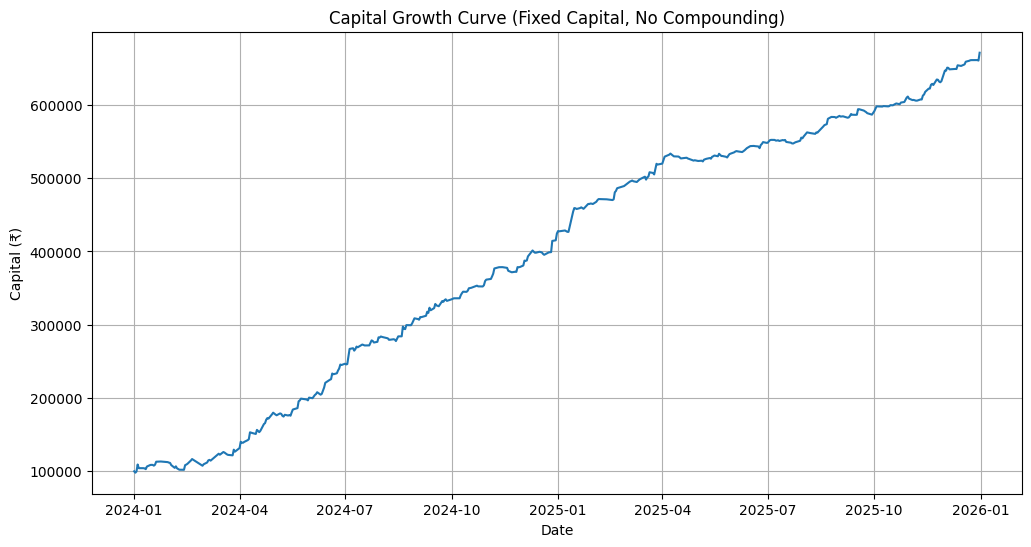


📌 Overall Summary
Final Capital: 671292.06
Total P&L: 571292.06
Total Return %: 571.29


In [ ]:
## CAPITAL GROWTH

import re
import pandas as pd
import matplotlib.pyplot as plt

# ===================== INPUT TEXT =====================
raw_text = """
📆 January2024
📅 2024-01-01 → Trades: 8, Return: 0.72%
📅 2024-01-02 → Trades: 2, Return: -1.77%
📅 2024-01-03 → Trades: 3, Return: 1.99%
📅 2024-01-04 → Trades: 4, Return: 9.94%
📅 2024-01-05 → Trades: 5, Return: -4.50%
📅 2024-01-09 → Trades: 2, Return: 0.16%
📅 2024-01-10 → Trades: 3, Return: -0.01%
📅 2024-01-11 → Trades: 6, Return: -0.65%
📅 2024-01-12 → Trades: 3, Return: 3.92%
📅 2024-01-15 → Trades: 5, Return: 2.65%
📅 2024-01-16 → Trades: 1, Return: 0.22%
📅 2024-01-17 → Trades: 2, Return: 0.13%
📅 2024-01-18 → Trades: 1, Return: -0.90%
📅 2024-01-19 → Trades: 7, Return: 2.53%
📅 2024-01-20 → Trades: 5, Return: 4.55%
📅 2024-01-24 → Trades: 2, Return: 0.50%
📅 2024-01-29 → Trades: 4, Return: -0.28%
📅 2024-01-30 → Trades: 4, Return: 0.22%
📅 2024-01-31 → Trades: 2, Return: -0.49%

📆 February2024
📅 2024-02-01 → Trades: 3, Return: -0.05%
📅 2024-02-02 → Trades: 3, Return: -2.70%
📅 2024-02-05 → Trades: 6, Return: -3.94%
📅 2024-02-06 → Trades: 4, Return: 2.47%
📅 2024-02-07 → Trades: 5, Return: -2.19%
📅 2024-02-08 → Trades: 1, Return: -0.90%
📅 2024-02-09 → Trades: 2, Return: -0.70%
📅 2024-02-13 → Trades: 1, Return: 0.00%
📅 2024-02-14 → Trades: 5, Return: 6.89%
📅 2024-02-15 → Trades: 1, Return: 0.77%
📅 2024-02-16 → Trades: 2, Return: 1.29%
📅 2024-02-19 → Trades: 6, Return: 6.04%
📅 2024-02-20 → Trades: 2, Return: 2.18%
📅 2024-02-21 → Trades: 1, Return: -0.90%
📅 2024-02-23 → Trades: 4, Return: -1.43%
📅 2024-02-26 → Trades: 5, Return: -2.81%
📅 2024-02-29 → Trades: 3, Return: -2.70%

📆 March2024
📅 2024-03-01 → Trades: 1, Return: 2.12%
📅 2024-03-04 → Trades: 2, Return: 2.60%
📅 2024-03-05 → Trades: 2, Return: 3.06%
📅 2024-03-06 → Trades: 1, Return: 0.80%
📅 2024-03-07 → Trades: 5, Return: -0.52%
📅 2024-03-14 → Trades: 2, Return: 9.66%
📅 2024-03-15 → Trades: 3, Return: -1.06%
📅 2024-03-18 → Trades: 3, Return: 3.95%
📅 2024-03-19 → Trades: 3, Return: -0.43%
📅 2024-03-21 → Trades: 6, Return: -2.27%
📅 2024-03-22 → Trades: 5, Return: -0.26%
📅 2024-03-26 → Trades: 1, Return: -0.53%
📅 2024-03-27 → Trades: 5, Return: 8.24%
📅 2024-03-28 → Trades: 3, Return: -2.41%

📆 April2024
📅 2024-04-01 → Trades: 11, Return: 11.84%
📅 2024-04-02 → Trades: 8, Return: 14.63%
📅 2024-04-03 → Trades: 3, Return: -0.94%
📅 2024-04-04 → Trades: 5, Return: 0.35%
📅 2024-04-05 → Trades: 2, Return: 1.36%
📅 2024-04-08 → Trades: 5, Return: 2.87%
📅 2024-04-09 → Trades: 4, Return: 1.75%
📅 2024-04-10 → Trades: 9, Return: 17.80%
📅 2024-04-12 → Trades: 1, Return: -0.90%
📅 2024-04-15 → Trades: 4, Return: -0.85%
📅 2024-04-16 → Trades: 2, Return: 5.75%
📅 2024-04-18 → Trades: 6, Return: -3.05%
📅 2024-04-19 → Trades: 2, Return: 2.08%
📅 2024-04-22 → Trades: 3, Return: 9.35%
📅 2024-04-23 → Trades: 4, Return: 1.74%
📅 2024-04-24 → Trades: 4, Return: 5.09%
📅 2024-04-25 → Trades: 6, Return: 3.21%
📅 2024-04-26 → Trades: 1, Return: -0.58%
📅 2024-04-29 → Trades: 4, Return: 6.22%
📅 2024-04-30 → Trades: 6, Return: 3.33%

📆 May2024
📅 2024-05-02 → Trades: 6, Return: -2.47%
📅 2024-05-03 → Trades: 1, Return: -0.90%
📅 2024-05-06 → Trades: 1, Return: 2.66%
📅 2024-05-07 → Trades: 1, Return: -0.59%
📅 2024-05-08 → Trades: 4, Return: -2.23%
📅 2024-05-09 → Trades: 1, Return: -0.90%
📅 2024-05-10 → Trades: 3, Return: 2.73%
📅 2024-05-13 → Trades: 1, Return: -0.90%
📅 2024-05-14 → Trades: 7, Return: 1.67%
📅 2024-05-15 → Trades: 1, Return: -0.90%
📅 2024-05-16 → Trades: 6, Return: 6.08%
📅 2024-05-17 → Trades: 2, Return: 4.13%
📅 2024-05-21 → Trades: 5, Return: 2.40%
📅 2024-05-22 → Trades: 3, Return: 9.61%
📅 2024-05-23 → Trades: 3, Return: 1.47%
📅 2024-05-24 → Trades: 5, Return: 2.98%
📅 2024-05-27 → Trades: 1, Return: -0.55%
📅 2024-05-29 → Trades: 5, Return: -0.01%
📅 2024-05-30 → Trades: 2, Return: -1.05%
📅 2024-05-31 → Trades: 6, Return: 5.14%

📆 June2024
📅 2024-06-03 → Trades: 2, Return: -0.58%
📅 2024-06-05 → Trades: 3, Return: 4.61%
📅 2024-06-06 → Trades: 1, Return: 1.43%
📅 2024-06-07 → Trades: 4, Return: 2.91%
📅 2024-06-10 → Trades: 7, Return: -4.03%
📅 2024-06-11 → Trades: 4, Return: 1.61%
📅 2024-06-12 → Trades: 5, Return: 4.60%
📅 2024-06-13 → Trades: 8, Return: 7.90%
📅 2024-06-14 → Trades: 5, Return: 6.97%
📅 2024-06-18 → Trades: 8, Return: 7.53%
📅 2024-06-19 → Trades: 1, Return: 0.85%
📅 2024-06-20 → Trades: 5, Return: 8.24%
📅 2024-06-21 → Trades: 2, Return: -0.82%
📅 2024-06-24 → Trades: 3, Return: 1.61%
📅 2024-06-25 → Trades: 3, Return: 4.09%
📅 2024-06-26 → Trades: 4, Return: 3.15%
📅 2024-06-27 → Trades: 1, Return: 5.53%
📅 2024-06-28 → Trades: 5, Return: -0.16%

📆 July2024
📅 2024-07-01 → Trades: 9, Return: 4.08%
📅 2024-07-02 → Trades: 1, Return: -0.90%
📅 2024-07-03 → Trades: 1, Return: 0.62%
📅 2024-07-04 → Trades: 7, Return: 15.36%
📅 2024-07-05 → Trades: 4, Return: 10.63%
📅 2024-07-08 → Trades: 1, Return: 1.03%
📅 2024-07-09 → Trades: 4, Return: -2.89%
📅 2024-07-10 → Trades: 2, Return: 2.29%
📅 2024-07-11 → Trades: 3, Return: 3.77%
📅 2024-07-12 → Trades: 1, Return: -0.90%
📅 2024-07-15 → Trades: 6, Return: 4.18%
📅 2024-07-16 → Trades: 3, Return: 1.12%
📅 2024-07-18 → Trades: 3, Return: -0.99%
📅 2024-07-22 → Trades: 4, Return: 0.49%
📅 2024-07-24 → Trades: 8, Return: 11.74%
📅 2024-07-25 → Trades: 8, Return: -0.57%
📅 2024-07-26 → Trades: 4, Return: -1.65%
📅 2024-07-29 → Trades: 5, Return: 1.44%
📅 2024-07-30 → Trades: 6, Return: 7.96%
📅 2024-07-31 → Trades: 3, Return: 0.11%

📆 August2024
📅 2024-08-01 → Trades: 2, Return: 1.53%
📅 2024-08-02 → Trades: 3, Return: -0.28%
📅 2024-08-07 → Trades: 6, Return: -1.70%
📅 2024-08-08 → Trades: 2, Return: -1.80%
📅 2024-08-09 → Trades: 3, Return: 0.39%
📅 2024-08-12 → Trades: 5, Return: 1.15%
📅 2024-08-13 → Trades: 2, Return: -0.26%
📅 2024-08-14 → Trades: 2, Return: -1.80%
📅 2024-08-16 → Trades: 8, Return: 10.98%
📅 2024-08-19 → Trades: 2, Return: 0.30%
📅 2024-08-20 → Trades: 6, Return: 16.56%
📅 2024-08-21 → Trades: 3, Return: -2.70%
📅 2024-08-22 → Trades: 2, Return: -0.31%
📅 2024-08-23 → Trades: 3, Return: 5.77%
📅 2024-08-27 → Trades: 7, Return: 0.58%
📅 2024-08-28 → Trades: 2, Return: 2.65%
📅 2024-08-30 → Trades: 5, Return: 7.44%

📆 September2024
📅 2024-09-02 → Trades: 2, Return: -0.79%
📅 2024-09-03 → Trades: 3, Return: -0.61%
📅 2024-09-04 → Trades: 7, Return: 5.76%
📅 2024-09-05 → Trades: 10, Return: 0.80%
📅 2024-09-09 → Trades: 1, Return: 1.99%
📅 2024-09-10 → Trades: 5, Return: 5.93%
📅 2024-09-11 → Trades: 3, Return: -1.19%
📅 2024-09-12 → Trades: 6, Return: 9.02%
📅 2024-09-13 → Trades: 8, Return: -4.76%
📅 2024-09-16 → Trades: 3, Return: 3.23%
📅 2024-09-17 → Trades: 4, Return: 6.09%
📅 2024-09-18 → Trades: 2, Return: -1.80%
📅 2024-09-20 → Trades: 2, Return: -0.90%
📅 2024-09-23 → Trades: 4, Return: 7.46%
📅 2024-09-24 → Trades: 1, Return: -0.90%
📅 2024-09-25 → Trades: 2, Return: 2.50%
📅 2024-09-26 → Trades: 2, Return: 1.28%
📅 2024-09-27 → Trades: 3, Return: -1.85%
📅 2024-09-30 → Trades: 3, Return: 1.79%

📆 October2024
📅 2024-10-01 → Trades: 3, Return: 0.93%
📅 2024-10-03 → Trades: 1, Return: 1.50%
📅 2024-10-08 → Trades: 2, Return: 0.26%
📅 2024-10-09 → Trades: 4, Return: 4.62%
📅 2024-10-10 → Trades: 5, Return: 3.20%
📅 2024-10-11 → Trades: 2, Return: 2.24%
📅 2024-10-14 → Trades: 2, Return: -0.01%
📅 2024-10-15 → Trades: 3, Return: 1.84%
📅 2024-10-16 → Trades: 2, Return: 3.55%
📅 2024-10-18 → Trades: 3, Return: 0.91%
📅 2024-10-23 → Trades: 2, Return: 3.18%
📅 2024-10-24 → Trades: 1, Return: -0.90%
📅 2024-10-28 → Trades: 4, Return: 0.26%
📅 2024-10-29 → Trades: 5, Return: 2.24%
📅 2024-10-30 → Trades: 4, Return: 6.05%
📅 2024-10-31 → Trades: 3, Return: 2.24%

📆 November2024
📅 2024-11-04 → Trades: 3, Return: 1.25%
📅 2024-11-05 → Trades: 5, Return: 3.87%
📅 2024-11-06 → Trades: 6, Return: 5.12%
📅 2024-11-07 → Trades: 1, Return: 7.26%
📅 2024-11-11 → Trades: 2, Return: 1.93%
📅 2024-11-14 → Trades: 1, Return: 0.18%
📅 2024-11-18 → Trades: 1, Return: -0.90%
📅 2024-11-19 → Trades: 8, Return: -5.58%
📅 2024-11-22 → Trades: 2, Return: -1.80%
📅 2024-11-25 → Trades: 1, Return: 0.79%
📅 2024-11-26 → Trades: 2, Return: 0.06%
📅 2024-11-27 → Trades: 9, Return: 12.55%
📅 2024-11-28 → Trades: 1, Return: -0.04%
📅 2024-11-29 → Trades: 1, Return: 0.35%

📆 December2024
📅 2024-12-02 → Trades: 4, Return: 2.47%
📅 2024-12-03 → Trades: 6, Return: 8.66%
📅 2024-12-04 → Trades: 1, Return: -0.19%
📅 2024-12-05 → Trades: 2, Return: 0.63%
📅 2024-12-06 → Trades: 7, Return: 8.56%
📅 2024-12-10 → Trades: 3, Return: 8.40%
📅 2024-12-11 → Trades: 6, Return: -1.48%
📅 2024-12-12 → Trades: 2, Return: -1.14%
📅 2024-12-13 → Trades: 2, Return: 0.24%
📅 2024-12-16 → Trades: 2, Return: 1.42%
📅 2024-12-18 → Trades: 2, Return: -0.64%
📅 2024-12-19 → Trades: 4, Return: -1.61%
📅 2024-12-20 → Trades: 2, Return: -1.07%
📅 2024-12-24 → Trades: 2, Return: 3.51%
📅 2024-12-26 → Trades: 2, Return: 0.56%
📅 2024-12-27 → Trades: 4, Return: 15.67%
📅 2024-12-30 → Trades: 4, Return: 1.25%
📅 2024-12-31 → Trades: 6, Return: 11.80%

📆 January2025
📅 2025-01-01 → Trades: 7, Return: 5.31%
📅 2025-01-02 → Trades: 7, Return: 0.21%
📅 2025-01-07 → Trades: 1, Return: 1.24%
📅 2025-01-08 → Trades: 1, Return: -0.90%
📅 2025-01-09 → Trades: 2, Return: -0.65%
📅 2025-01-10 → Trades: 1, Return: 0.03%
📅 2025-01-14 → Trades: 3, Return: 27.87%
📅 2025-01-15 → Trades: 2, Return: 5.11%
📅 2025-01-16 → Trades: 5, Return: 0.25%
📅 2025-01-17 → Trades: 1, Return: -0.90%
📅 2025-01-20 → Trades: 5, Return: 1.80%
📅 2025-01-21 → Trades: 2, Return: 1.16%
📅 2025-01-23 → Trades: 2, Return: -1.80%
📅 2025-01-24 → Trades: 1, Return: 1.70%
📅 2025-01-27 → Trades: 1, Return: 5.15%
📅 2025-01-28 → Trades: 3, Return: 0.26%
📅 2025-01-29 → Trades: 5, Return: 1.11%
📅 2025-01-30 → Trades: 1, Return: -0.07%
📅 2025-01-31 → Trades: 2, Return: -0.33%

📆 February2025
📅 2025-02-01 → Trades: 3, Return: 1.31%
📅 2025-02-03 → Trades: 3, Return: 2.32%
📅 2025-02-04 → Trades: 2, Return: 2.46%
📅 2025-02-05 → Trades: 7, Return: 2.80%
📅 2025-02-12 → Trades: 1, Return: -0.25%
📅 2025-02-17 → Trades: 1, Return: -0.90%
📅 2025-02-18 → Trades: 2, Return: 1.16%
📅 2025-02-19 → Trades: 3, Return: 9.89%
📅 2025-02-20 → Trades: 5, Return: 2.42%
📅 2025-02-21 → Trades: 1, Return: 3.78%
📅 2025-02-27 → Trades: 2, Return: 3.16%

📆 March2025
📅 2025-03-04 → Trades: 5, Return: 6.58%
📅 2025-03-05 → Trades: 1, Return: 0.75%
📅 2025-03-06 → Trades: 4, Return: 1.22%
📅 2025-03-07 → Trades: 1, Return: -0.90%
📅 2025-03-10 → Trades: 1, Return: -0.90%
📅 2025-03-11 → Trades: 4, Return: 1.92%
📅 2025-03-12 → Trades: 1, Return: 1.52%
📅 2025-03-13 → Trades: 2, Return: 1.32%
📅 2025-03-17 → Trades: 1, Return: 3.27%
📅 2025-03-18 → Trades: 4, Return: -3.60%
📅 2025-03-19 → Trades: 12, Return: 8.79%
📅 2025-03-20 → Trades: 2, Return: 1.17%
📅 2025-03-21 → Trades: 9, Return: 11.59%
📅 2025-03-24 → Trades: 1, Return: -0.90%
📅 2025-03-25 → Trades: 2, Return: -1.80%
📅 2025-03-27 → Trades: 16, Return: 48.06%
📅 2025-03-28 → Trades: 1, Return: -0.90%

📆 April2025
📅 2025-04-01 → Trades: 4, Return: 1.65%
📅 2025-04-02 → Trades: 4, Return: 5.05%
📅 2025-04-03 → Trades: 5, Return: 5.34%
📅 2025-04-07 → Trades: 2, Return: 2.93%
📅 2025-04-08 → Trades: 1, Return: 1.58%
📅 2025-04-11 → Trades: 8, Return: -5.26%
📅 2025-04-15 → Trades: 9, Return: 0.45%
📅 2025-04-16 → Trades: 3, Return: -0.81%
📅 2025-04-17 → Trades: 2, Return: -1.28%
📅 2025-04-21 → Trades: 9, Return: 2.19%
📅 2025-04-22 → Trades: 4, Return: 0.65%
📅 2025-04-23 → Trades: 1, Return: -0.90%
📅 2025-04-24 → Trades: 3, Return: -0.25%
📅 2025-04-28 → Trades: 3, Return: -2.07%
📅 2025-04-29 → Trades: 1, Return: 0.58%

📆 May2025
📅 2025-05-02 → Trades: 1, Return: -0.90%
📅 2025-05-05 → Trades: 6, Return: 1.06%
📅 2025-05-06 → Trades: 1, Return: -0.90%
📅 2025-05-07 → Trades: 4, Return: 2.79%
📅 2025-05-09 → Trades: 4, Return: 1.57%
📅 2025-05-12 → Trades: 7, Return: 2.18%
📅 2025-05-13 → Trades: 3, Return: -0.56%
📅 2025-05-14 → Trades: 2, Return: 2.74%
📅 2025-05-15 → Trades: 2, Return: 0.93%
📅 2025-05-16 → Trades: 10, Return: 3.11%
📅 2025-05-19 → Trades: 1, Return: -0.90%
📅 2025-05-20 → Trades: 4, Return: 3.75%
📅 2025-05-22 → Trades: 3, Return: -2.70%
📅 2025-05-23 → Trades: 2, Return: 0.13%
📅 2025-05-26 → Trades: 2, Return: -0.80%
📅 2025-05-27 → Trades: 3, Return: -0.66%
📅 2025-05-28 → Trades: 4, Return: 2.86%
📅 2025-05-29 → Trades: 1, Return: 2.21%
📅 2025-05-30 → Trades: 5, Return: 1.17%

📆 June2025
📅 2025-06-02 → Trades: 3, Return: 2.03%
📅 2025-06-03 → Trades: 1, Return: 1.17%
📅 2025-06-04 → Trades: 5, Return: 1.16%
📅 2025-06-05 → Trades: 3, Return: -0.08%
📅 2025-06-06 → Trades: 4, Return: 0.17%
📅 2025-06-09 → Trades: 3, Return: -0.39%
📅 2025-06-11 → Trades: 5, Return: 2.82%
📅 2025-06-13 → Trades: 5, Return: 3.49%
📅 2025-06-16 → Trades: 5, Return: 3.30%
📅 2025-06-19 → Trades: 1, Return: 0.37%
📅 2025-06-20 → Trades: 2, Return: -0.09%
📅 2025-06-23 → Trades: 1, Return: -0.36%
📅 2025-06-24 → Trades: 3, Return: -2.00%
📅 2025-06-25 → Trades: 2, Return: 4.39%
📅 2025-06-26 → Trades: 1, Return: 1.75%
📅 2025-06-27 → Trades: 6, Return: 3.50%
📅 2025-06-30 → Trades: 1, Return: -0.90%

📆 July2025
📅 2025-07-01 → Trades: 3, Return: 0.36%
📅 2025-07-02 → Trades: 2, Return: 2.17%
📅 2025-07-03 → Trades: 1, Return: 1.76%
📅 2025-07-04 → Trades: 1, Return: 0.47%
📅 2025-07-07 → Trades: 2, Return: 0.13%
📅 2025-07-08 → Trades: 2, Return: -0.69%
📅 2025-07-09 → Trades: 4, Return: 0.39%
📅 2025-07-10 → Trades: 1, Return: 0.54%
📅 2025-07-11 → Trades: 1, Return: -0.90%
📅 2025-07-14 → Trades: 2, Return: 1.46%
📅 2025-07-15 → Trades: 4, Return: 0.04%
📅 2025-07-16 → Trades: 4, Return: 0.89%
📅 2025-07-17 → Trades: 2, Return: -2.50%
📅 2025-07-21 → Trades: 1, Return: -0.90%
📅 2025-07-22 → Trades: 1, Return: -0.90%
📅 2025-07-23 → Trades: 1, Return: -0.03%
📅 2025-07-25 → Trades: 1, Return: 1.83%
📅 2025-07-29 → Trades: 4, Return: 2.38%
📅 2025-07-30 → Trades: 3, Return: 4.64%
📅 2025-07-31 → Trades: 1, Return: -0.90%

📆 August2025
📅 2025-08-01 → Trades: 2, Return: 2.57%
📅 2025-08-04 → Trades: 8, Return: 10.02%
📅 2025-08-07 → Trades: 1, Return: -0.90%
📅 2025-08-11 → Trades: 1, Return: -0.90%
📅 2025-08-12 → Trades: 3, Return: 2.23%
📅 2025-08-13 → Trades: 1, Return: -0.16%
📅 2025-08-14 → Trades: 4, Return: 2.19%
📅 2025-08-18 → Trades: 1, Return: 6.67%
📅 2025-08-19 → Trades: 4, Return: 2.27%
📅 2025-08-21 → Trades: 1, Return: 1.42%
📅 2025-08-22 → Trades: 2, Return: 7.49%
📅 2025-08-25 → Trades: 2, Return: 2.78%
📅 2025-08-28 → Trades: 2, Return: 0.04%
📅 2025-08-29 → Trades: 1, Return: -0.90%

📆 September2025
📅 2025-09-01 → Trades: 7, Return: 4.36%
📅 2025-09-02 → Trades: 1, Return: -0.90%
📅 2025-09-04 → Trades: 1, Return: 0.50%
📅 2025-09-08 → Trades: 3, Return: -1.61%
📅 2025-09-09 → Trades: 1, Return: 0.49%
📅 2025-09-10 → Trades: 2, Return: 2.17%
📅 2025-09-11 → Trades: 2, Return: 2.87%
📅 2025-09-12 → Trades: 1, Return: -0.90%
📅 2025-09-15 → Trades: 6, Return: 0.47%
📅 2025-09-16 → Trades: 2, Return: 0.33%
📅 2025-09-17 → Trades: 2, Return: 7.72%
📅 2025-09-18 → Trades: 1, Return: 0.10%
📅 2025-09-22 → Trades: 2, Return: -1.66%
📅 2025-09-23 → Trades: 1, Return: -0.90%
📅 2025-09-24 → Trades: 2, Return: -0.92%
📅 2025-09-25 → Trades: 2, Return: -1.24%
📅 2025-09-29 → Trades: 2, Return: -1.80%

📆 October2025
📅 2025-10-01 → Trades: 6, Return: 6.06%
📅 2025-10-03 → Trades: 5, Return: 7.26%
📅 2025-10-06 → Trades: 2, Return: 0.01%
📅 2025-10-07 → Trades: 7, Return: 0.74%
📅 2025-10-08 → Trades: 2, Return: 0.12%
📅 2025-10-09 → Trades: 1, Return: 0.75%
📅 2025-10-10 → Trades: 5, Return: 0.40%
📅 2025-10-13 → Trades: 2, Return: -0.13%
📅 2025-10-14 → Trades: 1, Return: 0.50%
📅 2025-10-15 → Trades: 2, Return: 1.48%
📅 2025-10-17 → Trades: 1, Return: -0.12%
📅 2025-10-20 → Trades: 3, Return: 2.83%
📅 2025-10-23 → Trades: 1, Return: -0.90%
📅 2025-10-24 → Trades: 2, Return: 2.43%
📅 2025-10-27 → Trades: 4, Return: 1.20%
📅 2025-10-28 → Trades: 5, Return: 3.49%
📅 2025-10-29 → Trades: 5, Return: 3.44%
📅 2025-10-30 → Trades: 3, Return: 1.81%
📅 2025-10-31 → Trades: 4, Return: -2.42%

📆 November2025
📅 2025-11-03 → Trades: 3, Return: -1.72%
📅 2025-11-04 → Trades: 1, Return: 0.30%
📅 2025-11-06 → Trades: 1, Return: -0.90%
📅 2025-11-07 → Trades: 3, Return: 0.34%
📅 2025-11-10 → Trades: 2, Return: 1.81%
📅 2025-11-11 → Trades: 4, Return: 0.33%
📅 2025-11-12 → Trades: 4, Return: 5.74%
📅 2025-11-13 → Trades: 3, Return: 1.75%
📅 2025-11-14 → Trades: 4, Return: 4.05%
📅 2025-11-17 → Trades: 3, Return: 4.69%
📅 2025-11-18 → Trades: 2, Return: 0.25%
📅 2025-11-19 → Trades: 2, Return: 5.37%
📅 2025-11-20 → Trades: 3, Return: 1.60%
📅 2025-11-21 → Trades: 1, Return: -1.46%
📅 2025-11-24 → Trades: 1, Return: 7.58%
📅 2025-11-25 → Trades: 4, Return: 0.09%
📅 2025-11-26 → Trades: 4, Return: -2.04%
📅 2025-11-27 → Trades: 2, Return: -0.80%
📅 2025-11-28 → Trades: 1, Return: 1.62%

📆 December2025
📅 2025-12-01 → Trades: 5, Return: 14.90%
📅 2025-12-02 → Trades: 1, Return: -0.01%
📅 2025-12-03 → Trades: 1, Return: 4.25%
📅 2025-12-04 → Trades: 3, Return: -0.03%
📅 2025-12-05 → Trades: 2, Return: -1.80%
📅 2025-12-10 → Trades: 1, Return: 0.67%
📅 2025-12-11 → Trades: 8, Return: 0.64%
📅 2025-12-12 → Trades: 3, Return: 5.36%
📅 2025-12-15 → Trades: 4, Return: -0.45%
📅 2025-12-18 → Trades: 2, Return: 2.30%
📅 2025-12-19 → Trades: 2, Return: 3.85%
📅 2025-12-22 → Trades: 1, Return: 1.39%
📅 2025-12-23 → Trades: 1, Return: 0.84%
📅 2025-12-24 → Trades: 2, Return: 0.37%
📅 2025-12-29 → Trades: 3, Return: 0.33%
📅 2025-12-30 → Trades: 3, Return: -0.38%
📅 2025-12-31 → Trades: 5, Return: 11.23%
"""

import re
import pandas as pd
import matplotlib.pyplot as plt

# ===================== PARSE TEXT =====================
pattern = r"(\d{4}-\d{2}-\d{2}).*?Trades:\s*(\d+),\s*Return:\s*([-+]?\d+\.?\d*)%"
rows = re.findall(pattern, raw_text)

df = pd.DataFrame(rows, columns=["date", "trades", "return_pct"])
df["date"] = pd.to_datetime(df["date"])
df["trades"] = df["trades"].astype(int)
df["return_pct"] = df["return_pct"].astype(float)

# ===================== STRATEGY RULES =====================
START_CAPITAL = 100000
FIXED_CAPITAL = 100000
MAX_TRADES = 5
CHARGE_PER_TRADE = 0.1  # %

capital = START_CAPITAL
capital_curve = []
daily_pnl_list = []

for _, row in df.iterrows():
    trades = row["trades"]
    daily_return = row["return_pct"]

    # Cap trades at 7
    if trades > MAX_TRADES:
        avg_return_per_trade = daily_return / trades
        effective_return = avg_return_per_trade * MAX_TRADES
        effective_trades = MAX_TRADES
    else:
        effective_return = daily_return
        effective_trades = trades

    # Charges
    charges = effective_trades * CHARGE_PER_TRADE

    # Net return
    net_return_pct = effective_return - charges

    # Fixed-capital P&L (NO COMPOUNDING)
    daily_pnl = FIXED_CAPITAL * net_return_pct / 100
    capital += daily_pnl

    daily_pnl_list.append(daily_pnl)
    capital_curve.append(capital)

df["daily_pnl"] = daily_pnl_list
df["capital"] = capital_curve

# ===================== MONTH-WISE P&L =====================
df["month"] = df["date"].dt.to_period("M")

monthly_pnl = (
    df.groupby("month")["daily_pnl"]
    .sum()
    .reset_index()
)

monthly_pnl["monthly_return_pct"] = (
    monthly_pnl["daily_pnl"] / START_CAPITAL * 100
)

print("\n📊 Month-wise Performance")
print(monthly_pnl.to_string(index=False))

# ===================== MAX DRAWDOWN =====================
df["peak_capital"] = df["capital"].cummax()
df["drawdown"] = df["capital"] - df["peak_capital"]
df["drawdown_pct"] = df["drawdown"] / df["peak_capital"] * 100

max_dd_value = df["drawdown"].min()
max_dd_pct = df["drawdown_pct"].min()

print("\n📉 Drawdown Stats")
print("Max Drawdown (₹):", round(max_dd_value, 2))
print("Max Drawdown (%):", round(max_dd_pct, 2))

# ===================== PLOT =====================
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["capital"])
plt.title("Capital Growth Curve (Fixed Capital, No Compounding)")
plt.xlabel("Date")
plt.ylabel("Capital (₹)")
plt.grid(True)
plt.show()

# ===================== SUMMARY =====================
print("\n📌 Overall Summary")
print("Final Capital:", round(capital, 2))
print("Total P&L:", round(capital - START_CAPITAL, 2))
print("Total Return %:", round((capital - START_CAPITAL) / START_CAPITAL * 100, 2))


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict
from datetime import timedelta

# ================= CONFIG =================
months = [
    "January2025","February2025","March2025","April2025",
    "May2025","June2025","July2025","August2025",
    "September2025","October2025","November2025","December2025"
]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

OPEN_RANGE_FILTER_PCT    = 0.005
FALL_FROM_OPEN_PCT       = 0.02
PREV_DAY_HIGH_FILTER_PCT = 0.005

MAX_CONCURRENT_TRADES = 5
EXPECTED_MOVE_MINUTES = 30

dev_count_days = set([
    "2025-01-01","2025-01-02","2025-02-05","2025-03-19",
    "2025-03-21","2025-03-27","2025-04-11","2025-04-15",
    "2025-04-21","2025-05-05","2025-05-12","2025-05-16",
    "2025-06-27","2025-08-04","2025-09-01","2025-09-15",
    "2025-10-01","2025-10-07","2025-12-11"
])

# ================= STORAGE =================
ALL_TRADES = defaultdict(list)
previous_day_high = {}

# ================= HELPERS =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'timestamp' in df.columns:
        df.rename(columns={'timestamp':'date'}, inplace=True)

    df.columns = [c.lower() for c in df.columns]
    req = {'date','open','high','low','close','volume'}
    if not req.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)
    df = df.dropna(subset=['date']).set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()

def simulate_exit(entry_price, sl, candles):
    cutoff = pd.to_datetime("15:15").time()

    for _, r in candles.iterrows():
        if r.name.time() >= cutoff:
            pnl = (r['close'] - entry_price) / entry_price * 100
            return r.name, r['close'], pnl
        if r['low'] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return r.name, sl, pnl

    last = candles.iloc[-1]['close']
    pnl = (last - entry_price) / entry_price * 100
    return candles.index[-1], last, pnl

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date, prev_day_high):
    trades = []

    try:
        c915 = df.between_time("09:15","09:15").iloc[0]
        open_915 = c915['open']
        high_915 = c915['high']
    except:
        return trades

    for i in range(len(df) - window_size - 5):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0 or (r_high - r_low) / r_low > max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0 or body / breakout['open'] < min_body_pct:
            continue
        if breakout['high'] <= r_high:
            continue
        if breakout['volume'] < volume_multiplier * range_df['volume'].mean():
            continue
        if breakout['open'] < open_915 * (1 - FALL_FROM_OPEN_PCT):
            continue

        entry_price = r_high * (1 + confirmation_breakout_pct)

        if abs(entry_price - open_915) / open_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if abs(entry_price - high_915) / high_915 <= OPEN_RANGE_FILTER_PCT:
            continue
        if prev_day_high:
            if abs(entry_price - prev_day_high) / prev_day_high <= PREV_DAY_HIGH_FILTER_PCT:
                continue

        future = df.iloc[i + window_size + 1:]

        for _, candle in future.iterrows():
            if candle.name.time() > pd.to_datetime("14:30").time():
                break
            if candle['high'] >= entry_price:
                sl = entry_price * 0.991
                exit_time, exit_price, pnl = simulate_exit(
                    entry_price, sl, future.loc[candle.name:]
                )
                trades.append({
                    'date': trade_date,
                    'symbol': symbol,
                    'entry_time': candle.name,
                    'entry_price': entry_price,
                    'exit_time': exit_time,
                    'exit_price': exit_price,
                    'pnl_%': round(pnl,2),
                    'forced_exit': False
                })
                return trades

    return trades

# ================= PASS 1: COLLECT BASELINE TRADES =================
for month in months:
    mpath = os.path.join(base_root, month)
    if not os.path.isdir(mpath):
        continue

    for day in sorted(os.listdir(mpath)):
        if day not in dev_count_days:
            continue

        print(f"🔍 Processing date: {day}")
        dpath = os.path.join(mpath, day)
        if not os.path.isdir(dpath):
            continue

        daily_highs = {}

        for file in os.listdir(dpath):
            if not file.endswith(".csv"):
                continue

            symbol = file.replace(".csv","")
            df = load_and_resample_5min(os.path.join(dpath, file))
            if df.empty:
                continue

            trades = dynamic_range_breakout(
                df, symbol, day, previous_day_high.get(symbol)
            )

            ALL_TRADES[day].extend(trades)
            daily_highs[symbol] = df['high'].max()

        previous_day_high = daily_highs.copy()

# ================= CAPITAL ENGINE =================
def trade_score(trade, now_time, now_price):
    movement = (now_price - trade['entry_price']) / trade['entry_price']
    time_held = (now_time - trade['entry_time']).total_seconds() / 60
    time_factor = min(time_held / EXPECTED_MOVE_MINUTES, 1)
    return movement / (time_factor + 0.1)

def apply_capital_engine(day_trades):
    day_trades = sorted(day_trades, key=lambda x: x['entry_time'])
    live, final = [], []

    for trade in day_trades:
        entry_time = trade['entry_time']
        live = [lt for lt in live if lt['exit_time'] > entry_time]

        if len(live) < MAX_CONCURRENT_TRADES:
            live.append(trade)
            final.append(trade)
        else:
            worst = min(
                live,
                key=lambda lt: trade_score(lt, entry_time, trade['entry_price'])
            )
            worst['forced_exit'] = True
            worst['exit_time'] = entry_time
            worst['exit_price'] = trade['entry_price']
            worst['pnl_%'] = round(
                (worst['exit_price'] - worst['entry_price']) / worst['entry_price'] * 100, 2
            )
            live.remove(worst)
            live.append(trade)
            final.append(trade)

    final.extend(live)
    return final

# ================= APPLY ENGINE =================
BASELINE_TRADES = []
ENGINE_TRADES = []

for day, trades in ALL_TRADES.items():
    BASELINE_TRADES.extend(trades)
    ENGINE_TRADES.extend(apply_capital_engine(trades))

# ================= SUMMARY / COMPARISON =================
df_base = pd.DataFrame(BASELINE_TRADES)
df_eng  = pd.DataFrame(ENGINE_TRADES)

# Aggregate per stock per day
baseline_agg = df_base.groupby(['date','symbol']).agg(
    baseline_trades=('pnl_%','count'),
    baseline_pnl_pct=('pnl_%','sum')
).reset_index()

engine_agg = df_eng.groupby(['date','symbol']).agg(
    engine_trades=('pnl_%','count'),
    engine_pnl_pct=('pnl_%','sum')
).reset_index()

comparison_df = baseline_agg.merge(engine_agg, on=['date','symbol'], how='left')
comparison_df[['engine_trades','engine_pnl_pct']] = comparison_df[['engine_trades','engine_pnl_pct']].fillna(0)
comparison_df['delta_pnl_pct'] = comparison_df['engine_pnl_pct'] - comparison_df['baseline_pnl_pct']
comparison_df = comparison_df.sort_values(by=['date','delta_pnl_pct'])

print("\n================ TRADE COMPARISON =================\n")
print(comparison_df.head(25))
comparison_df.to_csv("baseline_vs_engine_stock_level.csv", index=False)
print("\n📁 Saved: baseline_vs_engine_stock_level.csv")


🔍 Processing date: 2025-01-01
🔍 Processing date: 2025-01-02
🔍 Processing date: 2025-02-05
🔍 Processing date: 2025-03-19
🔍 Processing date: 2025-03-21
🔍 Processing date: 2025-03-27
🔍 Processing date: 2025-04-11
🔍 Processing date: 2025-04-15
🔍 Processing date: 2025-04-21
🔍 Processing date: 2025-05-05
🔍 Processing date: 2025-05-12
🔍 Processing date: 2025-05-16
🔍 Processing date: 2025-06-27
🔍 Processing date: 2025-08-04
🔍 Processing date: 2025-09-01
🔍 Processing date: 2025-09-15
🔍 Processing date: 2025-10-01
🔍 Processing date: 2025-10-07
🔍 Processing date: 2025-12-11

================ TRADE COMPARISON =================

          date                 symbol  baseline_trades  baseline_pnl_pct  \
14  2025-01-01         RCF_2025-01-01                1             -0.33   
12  2025-01-01   POWERMECH_2025-01-01                1             -0.01   
0   2025-01-01    ADANIENT_2025-01-01                1            -92.99   
1   2025-01-01    ALOKINDS_2025-01-01                1             -0.90

In [ ]:
# down slope filter

### checking prev day high as resistance + 9:15 fall filter
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# === CONFIG ===
months = ["November2025", "December2025"]
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

FALL_FROM_915_CLOSE_PCT = 0.02   # 🔴 NEW FILTER


# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first',
        'high':'max',
        'low':'min',
        'close':'last',
        'volume':'sum'
    }).dropna()


# === Exit Logic ===
def simulate_exit(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= exit_cutoff:
            px = row['close']
            return row.name, px, (px-entry_price)/entry_price*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, (sl-entry_price)/entry_price*100, 'SL Hit'

    px = candles.iloc[-1]['close']
    return candles.index[-1], px, (px-entry_price)/entry_price*100, 'EOD Exit'


# === Strategy ===
def dynamic_range_breakout(df, symbol, date,
                            USE_VOLUME_FILTER,
                            USE_915_FILTER,
                            USE_PREV_DAY_FILTER,
                            prev_day_high):

    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # 9:15 reference candle
    first = df.iloc[0]
    open_low  = first['open'] * 0.995
    open_high = first['high'] * 1.005
    ref_915_close = first['close']

    # Prev-day zone
    if prev_day_high is not None:
        prev_low  = prev_day_high * 0.995
        prev_high = prev_day_high * 1.005

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        # === Breakout Candle Quality ===
        if upper_wick > 0.4 * abs(body):
            continue
        if breakout['close'] <= breakout['open']:
            continue
        if breakout['high'] <= r_high:
            continue
        if body_pct < min_body_pct:
            continue

        # === NEW: 9:15 FALL FILTER ===
        if breakout['open'] <= ref_915_close * (1 - FALL_FROM_915_CLOSE_PCT):
            continue

        # === Volume filter ===
        if USE_VOLUME_FILTER:
            if breakout['volume'] <= volume_multiplier * mean_vol:
                continue

        target_entry = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_entry:
                entry_price = target_entry

                # === 9:15 OPEN RANGE FILTER ===
                if USE_915_FILTER:
                    if open_low <= entry_price <= open_high:
                        break

                # === PREVIOUS DAY HIGH FILTER ===
                if USE_PREV_DAY_FILTER and prev_day_high is not None:
                    if prev_low <= entry_price <= prev_high:
                        break

                sl = entry_price * 0.991
                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_t, exit_p, pnl, reason = simulate_exit(
                    entry_price, sl, remaining
                )

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                })
                return trades

    return trades


# === BACKTEST RUNNER ===
def run_backtest(label,
                 USE_VOLUME_FILTER,
                 USE_915_FILTER,
                 USE_PREV_DAY_FILTER):

    monthly_ret = defaultdict(float)
    monthly_trd = defaultdict(int)

    print(f"\n==============================")
    print(f"🚀 RUNNING: {label}")
    print(f"Volume={USE_VOLUME_FILTER} | 9:15={USE_915_FILTER} | PrevDay={USE_PREV_DAY_FILTER}")
    print(f"==============================")

    for month in months:
        month_path = os.path.join(base_root, month)
        if not os.path.isdir(month_path):
            continue

        dates = sorted(os.listdir(month_path))
        prev_day_high_map = {}

        for date in dates:
            date_path = os.path.join(month_path, date)
            if not os.path.isdir(date_path):
                continue

            daily_trades = []
            prev_day_high = prev_day_high_map.get(date)

            for f in os.listdir(date_path):
                if not f.endswith(".csv"):
                    continue

                df = load_and_resample_5min(os.path.join(date_path, f))
                if df.empty:
                    continue

                # store today's high for next day
                prev_day_high_map[date] = df['high'].max()

                daily_trades += dynamic_range_breakout(
                    df,
                    f.replace(".csv", ""),
                    date,
                    USE_VOLUME_FILTER,
                    USE_915_FILTER,
                    USE_PREV_DAY_FILTER,
                    prev_day_high
                )

            day_pnl = sum(t['pnl_%'] for t in daily_trades)
            trades_cnt = len(daily_trades)

            monthly_ret[month] += day_pnl
            monthly_trd[month] += trades_cnt

            print(f"📅 {month}-{date} | Trades={trades_cnt} | Return={day_pnl:.2f}%")

    print("\n📊 MONTHLY SUMMARY:")
    for m in months:
        print(f"{m}: Trades={monthly_trd[m]}, Return={monthly_ret[m]:.2f}%")

    return monthly_ret, monthly_trd


# === RUN ===
run_backtest(
    label="Prev Day High + 9:15 Fall Filter",
    USE_VOLUME_FILTER=True,
    USE_915_FILTER=True,
    USE_PREV_DAY_FILTER=True
)



🚀 RUNNING: Prev Day High + 9:15 Fall Filter
Volume=True | 9:15=True | PrevDay=True
📅 November2025-2025-11-03 | Trades=4 | Return=-0.17%
📅 November2025-2025-11-04 | Trades=1 | Return=0.09%
📅 November2025-2025-11-06 | Trades=3 | Return=2.16%
📅 November2025-2025-11-07 | Trades=3 | Return=-0.08%
📅 November2025-2025-11-10 | Trades=1 | Return=1.44%
📅 November2025-2025-11-11 | Trades=6 | Return=0.08%
📅 November2025-2025-11-12 | Trades=10 | Return=3.56%
📅 November2025-2025-11-13 | Trades=3 | Return=-0.73%
📅 November2025-2025-11-14 | Trades=5 | Return=4.24%
📅 November2025-2025-11-17 | Trades=7 | Return=3.19%
📅 November2025-2025-11-18 | Trades=2 | Return=0.25%
📅 November2025-2025-11-19 | Trades=7 | Return=-2.38%
📅 November2025-2025-11-20 | Trades=6 | Return=3.60%
📅 November2025-2025-11-21 | Trades=0 | Return=0.00%
📅 November2025-2025-11-24 | Trades=1 | Return=7.58%
📅 November2025-2025-11-25 | Trades=2 | Return=0.09%
📅 November2025-2025-11-26 | Trades=4 | Return=-2.27%
📅 November2025-2025-11-27 

(defaultdict(float,
             {'November2025': np.float64(21.58),
              'December2025': np.float64(15.43)}),
 defaultdict(int, {'November2025': 68, 'December2025': 66}))

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIG ===
months = [
    "January2025",
    "February2025",
    "March2025",
    "April2025",
    "May2025",
    "June2025",
    "July2025",
    "August2025",
    "September2025",
    "October2025",
    "November2025",
    "December2025"
]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01


# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return df.resample('5min').agg({
        'open':'first','high':'max','low':'min',
        'close':'last','volume':'sum'
    }).dropna()


# === Exit Logic ===
def simulate_exit(entry_price, sl, candles):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles.iterrows():
        if row.name.time() >= exit_cutoff:
            px = row['close']
            return row.name, px, (px-entry_price)/entry_price*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, (sl-entry_price)/entry_price*100, 'SL Hit'

    px = candles.iloc[-1]['close']
    return candles.index[-1], px, (px-entry_price)/entry_price*100, 'EOD Exit'


# === Strategy ===
def dynamic_range_breakout(df, symbol, date,
                            USE_VOLUME_FILTER,
                            USE_915_FILTER,
                            USE_PREV_DAY_FILTER,
                            USE_LAST3DAY_FILTER,
                            prev_day_high,
                            last_3day_highs):

    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # 9:15 reference
    first = df.iloc[0]
    open_low  = first['open'] * 0.995
    open_high = first['high'] * 1.005

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        body_pct = body / breakout['open']
        upper_wick = breakout['high'] - breakout['close']

        if upper_wick > 0.4 * abs(body):
            continue
        if breakout['close'] <= breakout['open']:
            continue
        if breakout['high'] <= r_high:
            continue
        if body_pct < min_body_pct:
            continue

        # === Volume filter ===
        if USE_VOLUME_FILTER:
            if breakout['volume'] <= volume_multiplier * mean_vol:
                continue

        target_entry = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]
            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_entry:
                entry_price = target_entry

                # === 9:15 filter ===
                if USE_915_FILTER:
                    if open_low <= entry_price <= open_high:
                        break

                # === Prev day high filter ===
                if USE_PREV_DAY_FILTER and prev_day_high is not None:
                    if prev_day_high * 0.995 <= entry_price <= prev_day_high * 1.005:
                        break

                # === LAST 3 DAYS HIGH FILTER (NEW) ===
                if USE_LAST3DAY_FILTER:
                    for h in last_3day_highs:
                        if h * 0.995 <= entry_price <= h * 1.005:
                            return trades

                sl = entry_price * 0.991
                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_t, exit_p, pnl, reason = simulate_exit(entry_price, sl, remaining)

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'pnl_%': round(pnl,2),
                    'reason': reason
                })
                return trades

    return trades


# === BACKTEST RUNNER ===
def run_backtest(label,
                 USE_VOLUME_FILTER,
                 USE_915_FILTER,
                 USE_PREV_DAY_FILTER,
                 USE_LAST3DAY_FILTER):

    monthly_ret = defaultdict(float)
    monthly_trd = defaultdict(int)

    # per-stock rolling highs
    stock_high_history = defaultdict(lambda: deque(maxlen=3))

    print(f"\n==============================")
    print(f"🚀 RUNNING: {label}")
    print(f"Vol={USE_VOLUME_FILTER} | 9:15={USE_915_FILTER} | Prev1={USE_PREV_DAY_FILTER} | Prev3={USE_LAST3DAY_FILTER}")
    print(f"==============================")

    for month in months:
        month_path = os.path.join(base_root, month)
        if not os.path.isdir(month_path):
            continue

        for date in sorted(os.listdir(month_path)):
            date_path = os.path.join(month_path, date)
            if not os.path.isdir(date_path):
                continue

            daily_trades = []

            for f in os.listdir(date_path):
                if not f.endswith(".csv"):
                    continue

                symbol = f.replace(".csv","")
                df = load_and_resample_5min(os.path.join(date_path, f))

                if df.empty:
                    continue

                prev_day_high = stock_high_history[symbol][-1] if stock_high_history[symbol] else None

                daily_trades += dynamic_range_breakout(
                    df, symbol, date,
                    USE_VOLUME_FILTER,
                    USE_915_FILTER,
                    USE_PREV_DAY_FILTER,
                    USE_LAST3DAY_FILTER,
                    prev_day_high,
                    list(stock_high_history[symbol])
                )

                # update history AFTER processing
                stock_high_history[symbol].append(df['high'].max())

            day_pnl = sum(t['pnl_%'] for t in daily_trades)
            trades_cnt = len(daily_trades)

            monthly_ret[month] += day_pnl
            monthly_trd[month] += trades_cnt

            print(f"📅 {month}-{date} | Trades={trades_cnt} | Return={day_pnl:.2f}%")

    print("\n📊 MONTHLY SUMMARY:")
    for m in months:
        print(f"{m}: Trades={monthly_trd[m]}, Return={monthly_ret[m]:.2f}%")

    return monthly_ret, monthly_trd
run_backtest(
    label="Last 3 Day High Resistance",
    USE_VOLUME_FILTER=True,
    USE_915_FILTER=True,
    USE_PREV_DAY_FILTER=True,
    USE_LAST3DAY_FILTER=False
)



🚀 RUNNING: Last 3 Day High Resistance
Vol=True | 9:15=True | Prev1=True | Prev3=False
📅 January2025-2025-01-01 | Trades=9 | Return=4.88%
📅 January2025-2025-01-02 | Trades=11 | Return=-3.97%
📅 January2025-2025-01-03 | Trades=2 | Return=-1.34%
📅 January2025-2025-01-06 | Trades=0 | Return=0.00%
📅 January2025-2025-01-07 | Trades=2 | Return=-1.13%
📅 January2025-2025-01-08 | Trades=2 | Return=5.34%
📅 January2025-2025-01-09 | Trades=2 | Return=-1.80%
📅 January2025-2025-01-10 | Trades=0 | Return=0.00%
📅 January2025-2025-01-13 | Trades=0 | Return=0.00%
📅 January2025-2025-01-14 | Trades=1 | Return=12.68%
📅 January2025-2025-01-15 | Trades=2 | Return=-0.81%
📅 January2025-2025-01-16 | Trades=6 | Return=-1.16%
📅 January2025-2025-01-17 | Trades=4 | Return=-3.22%
📅 January2025-2025-01-20 | Trades=9 | Return=-3.22%
📅 January2025-2025-01-21 | Trades=2 | Return=1.16%
📅 January2025-2025-01-22 | Trades=0 | Return=0.00%
📅 January2025-2025-01-23 | Trades=4 | Return=-1.03%
📅 January2025-2025-01-24 | Trades=2

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["November2025","December2025"]

#months=["November2025","December2025"]
base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075 #
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    # Normalize column names
    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # 5-min resample
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        # Stop checking after 15:15
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        # SL Hit BEFORE 15:15
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    # If no SL hit & no candle at/after 15:15
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.991
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                        symbol_key = symbol.split('_')[0]

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades
    return trades


# === RUN FOR JANUARY → JULY ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        # Daily summary
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        date_key = f"{month}-{date_folder}"

        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY (January → July):")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")


📆 Running for Month: November2025
📅 November2025-2025-11-03 — Trades: 11, Return: 3.40%
📅 November2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 November2025-2025-11-06 — Trades: 7, Return: 1.67%
📅 November2025-2025-11-07 — Trades: 5, Return: 0.06%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 7, Return: 0.95%
📅 November2025-2025-11-12 — Trades: 11, Return: 4.60%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.73%
📅 November2025-2025-11-14 — Trades: 6, Return: 5.34%
📅 November2025-2025-11-17 — Trades: 9, Return: 2.44%
📅 November2025-2025-11-18 — Trades: 4, Return: 0.33%
📅 November2025-2025-11-19 — Trades: 8, Return: -0.24%
📅 November2025-2025-11-20 — Trades: 11, Return: 3.46%
📅 November2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.72%
📅 November2025-2025-11-27 — Trades: 2, Return: -0.80%
📅 No

In [ ]:
df1 = pd.DataFrame(daily_trades)
df1

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason
0,2026-01-14,BECTORFOOD_2026-01-14,2026-01-14 12:55:00+05:30,234.04,2026-01-14 15:10:00+05:30,231.70,-1.00,SL Hit
1,2026-01-14,IOB_2026-01-14,2026-01-14 12:40:00+05:30,36.28,2026-01-14 12:45:00+05:30,35.92,-1.00,SL Hit
2,2026-01-14,GODREJIND_2026-01-14,2026-01-14 12:20:00+05:30,1006.36,2026-01-14 15:15:00+05:30,1000.90,-0.54,15:15 Exit
3,2026-01-14,ONESOURCE_2026-01-14,2026-01-14 11:40:00+05:30,1795.68,2026-01-14 15:15:00+05:30,1768.70,-1.50,15:15 Exit


In [ ]:
###### WITHOUT EMA FULL TRADES
=============================
📆 Running for Month: January2023
==============================
📅 January2023-2023-01-02 — Trades: 6, Return: 0.27%
📅 January2023-2023-01-03 — Trades: 8, Return: -2.98%
📅 January2023-2023-01-04 — Trades: 5, Return: -0.39%
📅 January2023-2023-01-05 — Trades: 4, Return: 0.72%
📅 January2023-2023-01-06 — Trades: 2, Return: 0.71%
📅 January2023-2023-01-09 — Trades: 3, Return: -3.00%
📅 January2023-2023-01-10 — Trades: 4, Return: -1.26%
📅 January2023-2023-01-11 — Trades: 4, Return: 3.71%
📅 January2023-2023-01-12 — Trades: 3, Return: 0.27%
📅 January2023-2023-01-13 — Trades: 7, Return: -5.15%
📅 January2023-2023-01-16 — Trades: 7, Return: -1.08%
📅 January2023-2023-01-17 — Trades: 5, Return: 1.55%
📅 January2023-2023-01-18 — Trades: 10, Return: -4.61%
📅 January2023-2023-01-19 — Trades: 7, Return: -3.48%
📅 January2023-2023-01-20 — Trades: 8, Return: -4.85%
📅 January2023-2023-01-23 — Trades: 6, Return: -0.01%
📅 January2023-2023-01-24 — Trades: 9, Return: 3.27%
📅 January2023-2023-01-25 — Trades: 8, Return: 3.53%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 2, Return: -2.00%
📅 January2023-2023-01-31 — Trades: 11, Return: 9.92%

==============================
📆 Running for Month: February2023
==============================
📅 February2023-2023-02-01 — Trades: 3, Return: -3.00%
📅 February2023-2023-02-02 — Trades: 3, Return: -1.55%
📅 February2023-2023-02-03 — Trades: 4, Return: -1.36%
📅 February2023-2023-02-06 — Trades: 3, Return: 0.78%
📅 February2023-2023-02-07 — Trades: 2, Return: 15.42%
📅 February2023-2023-02-08 — Trades: 11, Return: 5.08%
📅 February2023-2023-02-09 — Trades: 7, Return: -3.70%
📅 February2023-2023-02-10 — Trades: 7, Return: -2.64%
📅 February2023-2023-02-13 — Trades: 2, Return: -0.56%
📅 February2023-2023-02-14 — Trades: 5, Return: -1.02%
📅 February2023-2023-02-15 — Trades: 8, Return: 3.50%
📅 February2023-2023-02-16 — Trades: 8, Return: 1.23%
📅 February2023-2023-02-17 — Trades: 6, Return: -4.36%
📅 February2023-2023-02-20 — Trades: 7, Return: -3.23%
📅 February2023-2023-02-21 — Trades: 4, Return: -0.92%
📅 February2023-2023-02-22 — Trades: 1, Return: -1.00%
📅 February2023-2023-02-23 — Trades: 6, Return: 11.07%
📅 February2023-2023-02-24 — Trades: 6, Return: -1.66%
📅 February2023-2023-02-27 — Trades: 2, Return: -2.00%
📅 February2023-2023-02-28 — Trades: 2, Return: -0.21%

==============================
📆 Running for Month: March2023
==============================
📅 March2023-2023-03-01 — Trades: 8, Return: -5.58%
📅 March2023-2023-03-02 — Trades: 2, Return: -1.13%
📅 March2023-2023-03-03 — Trades: 9, Return: -5.12%
📅 March2023-2023-03-06 — Trades: 8, Return: -2.62%
📅 March2023-2023-03-08 — Trades: 11, Return: 4.20%
📅 March2023-2023-03-09 — Trades: 5, Return: 4.25%
📅 March2023-2023-03-10 — Trades: 7, Return: -0.99%
📅 March2023-2023-03-13 — Trades: 2, Return: -1.20%
📅 March2023-2023-03-14 — Trades: 5, Return: -1.05%
📅 March2023-2023-03-15 — Trades: 5, Return: 10.05%
📅 March2023-2023-03-16 — Trades: 8, Return: 8.24%
📅 March2023-2023-03-17 — Trades: 3, Return: -0.58%
📅 March2023-2023-03-20 — Trades: 5, Return: 4.23%
📅 March2023-2023-03-21 — Trades: 10, Return: -0.71%
📅 March2023-2023-03-22 — Trades: 5, Return: -0.37%
📅 March2023-2023-03-23 — Trades: 11, Return: 3.64%
📅 March2023-2023-03-24 — Trades: 3, Return: -2.13%
📅 March2023-2023-03-27 — Trades: 4, Return: -1.53%
📅 March2023-2023-03-28 — Trades: 5, Return: 5.84%
📅 March2023-2023-03-29 — Trades: 9, Return: 10.36%
📅 March2023-2023-03-31 — Trades: 11, Return: 6.36%

==============================
📆 Running for Month: April2023
==============================
📅 April2023-2023-04-03 — Trades: 10, Return: 7.78%
📅 April2023-2023-04-05 — Trades: 8, Return: 11.86%
📅 April2023-2023-04-06 — Trades: 9, Return: 4.51%
📅 April2023-2023-04-10 — Trades: 10, Return: -0.51%
📅 April2023-2023-04-11 — Trades: 15, Return: 3.03%
📅 April2023-2023-04-12 — Trades: 10, Return: 4.19%
📅 April2023-2023-04-13 — Trades: 10, Return: -6.28%
📅 April2023-2023-04-17 — Trades: 16, Return: -0.52%
📅 April2023-2023-04-18 — Trades: 7, Return: 3.21%
📅 April2023-2023-04-19 — Trades: 6, Return: -2.58%
📅 April2023-2023-04-20 — Trades: 5, Return: -1.68%
📅 April2023-2023-04-21 — Trades: 9, Return: 2.67%
📅 April2023-2023-04-24 — Trades: 9, Return: 3.82%
📅 April2023-2023-04-25 — Trades: 7, Return: -2.95%
📅 April2023-2023-04-26 — Trades: 12, Return: -1.97%
📅 April2023-2023-04-27 — Trades: 10, Return: 8.99%
📅 April2023-2023-04-28 — Trades: 9, Return: 4.67%

==============================
📆 Running for Month: May2023
==============================
📅 May2023-2023-05-02 — Trades: 7, Return: -2.58%
📅 May2023-2023-05-03 — Trades: 6, Return: 8.62%
📅 May2023-2023-05-04 — Trades: 4, Return: -2.51%
📅 May2023-2023-05-05 — Trades: 5, Return: -2.37%
📅 May2023-2023-05-08 — Trades: 6, Return: 1.56%
📅 May2023-2023-05-09 — Trades: 6, Return: -0.52%
📅 May2023-2023-05-10 — Trades: 6, Return: 7.37%
📅 May2023-2023-05-11 — Trades: 4, Return: 2.52%
📅 May2023-2023-05-12 — Trades: 10, Return: -3.84%
📅 May2023-2023-05-15 — Trades: 10, Return: 1.63%
📅 May2023-2023-05-16 — Trades: 3, Return: -0.95%
📅 May2023-2023-05-17 — Trades: 5, Return: 4.56%
📅 May2023-2023-05-18 — Trades: 3, Return: -2.03%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 10, Return: -4.91%
📅 May2023-2023-05-23 — Trades: 12, Return: -4.33%
📅 May2023-2023-05-24 — Trades: 6, Return: 2.52%
📅 May2023-2023-05-25 — Trades: 5, Return: 3.95%
📅 May2023-2023-05-26 — Trades: 14, Return: 5.13%
📅 May2023-2023-05-29 — Trades: 2, Return: 0.15%
📅 May2023-2023-05-30 — Trades: 8, Return: 3.54%
📅 May2023-2023-05-31 — Trades: 14, Return: 14.07%

==============================
📆 Running for Month: June2023
==============================
📅 June2023-2023-06-01 — Trades: 6, Return: 1.97%
📅 June2023-2023-06-02 — Trades: 3, Return: -0.88%
📅 June2023-2023-06-05 — Trades: 11, Return: 1.28%
📅 June2023-2023-06-06 — Trades: 11, Return: 16.53%
📅 June2023-2023-06-07 — Trades: 10, Return: 7.03%
📅 June2023-2023-06-08 — Trades: 4, Return: -1.34%
📅 June2023-2023-06-09 — Trades: 2, Return: -0.69%
📅 June2023-2023-06-12 — Trades: 5, Return: 3.12%
📅 June2023-2023-06-13 — Trades: 10, Return: 4.90%
📅 June2023-2023-06-14 — Trades: 10, Return: 4.75%
📅 June2023-2023-06-15 — Trades: 4, Return: 3.02%
📅 June2023-2023-06-16 — Trades: 11, Return: 2.33%
📅 June2023-2023-06-19 — Trades: 4, Return: -3.11%
📅 June2023-2023-06-20 — Trades: 14, Return: 9.86%
📅 June2023-2023-06-21 — Trades: 5, Return: -0.94%
📅 June2023-2023-06-22 — Trades: 2, Return: -1.34%
📅 June2023-2023-06-23 — Trades: 4, Return: -3.23%
📅 June2023-2023-06-26 — Trades: 12, Return: -3.37%
📅 June2023-2023-06-27 — Trades: 9, Return: 0.05%
📅 June2023-2023-06-28 — Trades: 6, Return: 0.82%
📅 June2023-2023-06-30 — Trades: 11, Return: 5.56%

==============================
📆 Running for Month: July2023
==============================
📅 July2023-2023-07-03 — Trades: 6, Return: 5.89%
📅 July2023-2023-07-04 — Trades: 6, Return: -2.27%
📅 July2023-2023-07-05 — Trades: 8, Return: 13.71%
📅 July2023-2023-07-06 — Trades: 5, Return: 0.42%
📅 July2023-2023-07-07 — Trades: 8, Return: 17.57%
📅 July2023-2023-07-10 — Trades: 5, Return: -5.00%
📅 July2023-2023-07-11 — Trades: 3, Return: -2.19%
📅 July2023-2023-07-12 — Trades: 8, Return: 1.61%
📅 July2023-2023-07-13 — Trades: 5, Return: -3.20%
📅 July2023-2023-07-14 — Trades: 8, Return: -4.01%
📅 July2023-2023-07-17 — Trades: 5, Return: 2.90%
📅 July2023-2023-07-18 — Trades: 2, Return: -1.24%
📅 July2023-2023-07-19 — Trades: 10, Return: -0.61%
📅 July2023-2023-07-20 — Trades: 12, Return: -1.58%
📅 July2023-2023-07-21 — Trades: 8, Return: 16.90%
📅 July2023-2023-07-24 — Trades: 3, Return: 3.14%
📅 July2023-2023-07-25 — Trades: 3, Return: -1.27%
📅 July2023-2023-07-26 — Trades: 6, Return: 4.31%
📅 July2023-2023-07-27 — Trades: 5, Return: -2.65%
📅 July2023-2023-07-28 — Trades: 3, Return: 0.63%
📅 July2023-2023-07-31 — Trades: 9, Return: 2.45%

==============================
📆 Running for Month: August2023
==============================
📅 August2023-2023-08-01 — Trades: 7, Return: 9.97%
📅 August2023-2023-08-02 — Trades: 1, Return: -1.00%
📅 August2023-2023-08-03 — Trades: 3, Return: 3.02%
📅 August2023-2023-08-04 — Trades: 5, Return: 3.23%
📅 August2023-2023-08-07 — Trades: 7, Return: 14.72%
📅 August2023-2023-08-08 — Trades: 5, Return: 0.50%
📅 August2023-2023-08-09 — Trades: 5, Return: 1.38%
📅 August2023-2023-08-10 — Trades: 6, Return: 10.78%
📅 August2023-2023-08-11 — Trades: 5, Return: -1.34%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 4, Return: 3.10%
📅 August2023-2023-08-17 — Trades: 5, Return: -2.68%
📅 August2023-2023-08-18 — Trades: 1, Return: 1.24%
📅 August2023-2023-08-21 — Trades: 5, Return: -2.77%
📅 August2023-2023-08-22 — Trades: 7, Return: 1.52%
📅 August2023-2023-08-23 — Trades: 9, Return: -7.51%
📅 August2023-2023-08-24 — Trades: 4, Return: 5.98%
📅 August2023-2023-08-25 — Trades: 1, Return: 0.62%
📅 August2023-2023-08-28 — Trades: 4, Return: 5.02%
📅 August2023-2023-08-29 — Trades: 8, Return: -0.59%
📅 August2023-2023-08-30 — Trades: 7, Return: 0.47%
📅 August2023-2023-08-31 — Trades: 5, Return: 3.01%

==============================
📆 Running for Month: September2023
==============================
📅 September2023-2023-09-01 — Trades: 6, Return: 4.98%
📅 September2023-2023-09-04 — Trades: 5, Return: -1.43%
📅 September2023-2023-09-05 — Trades: 1, Return: 0.88%
📅 September2023-2023-09-06 — Trades: 3, Return: 0.85%
📅 September2023-2023-09-07 — Trades: 12, Return: -1.74%
📅 September2023-2023-09-08 — Trades: 5, Return: 6.04%
📅 September2023-2023-09-11 — Trades: 13, Return: 9.98%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 3, Return: -1.61%
📅 September2023-2023-09-14 — Trades: 3, Return: -1.11%
📅 September2023-2023-09-15 — Trades: 2, Return: 5.18%
📅 September2023-2023-09-18 — Trades: 2, Return: -0.37%
📅 September2023-2023-09-20 — Trades: 4, Return: -3.02%
📅 September2023-2023-09-21 — Trades: 4, Return: -2.23%
📅 September2023-2023-09-22 — Trades: 4, Return: 1.92%
📅 September2023-2023-09-25 — Trades: 3, Return: -0.60%
📅 September2023-2023-09-26 — Trades: 2, Return: -0.96%
📅 September2023-2023-09-27 — Trades: 5, Return: -3.46%
📅 September2023-2023-09-28 — Trades: 6, Return: 0.28%
📅 September2023-2023-09-29 — Trades: 19, Return: -6.88%

==============================
📆 Running for Month: October2023
==============================
📅 October2023-2023-10-03 — Trades: 4, Return: -0.92%
📅 October2023-2023-10-04 — Trades: 2, Return: -0.72%
📅 October2023-2023-10-05 — Trades: 7, Return: 4.10%
📅 October2023-2023-10-06 — Trades: 9, Return: 6.59%
📅 October2023-2023-10-09 — Trades: 2, Return: -2.00%
📅 October2023-2023-10-10 — Trades: 10, Return: -1.32%
📅 October2023-2023-10-11 — Trades: 2, Return: 2.16%
📅 October2023-2023-10-12 — Trades: 9, Return: -0.12%
📅 October2023-2023-10-13 — Trades: 5, Return: 0.40%
📅 October2023-2023-10-16 — Trades: 10, Return: -2.33%
📅 October2023-2023-10-17 — Trades: 5, Return: -1.03%
📅 October2023-2023-10-18 — Trades: 1, Return: -1.00%
📅 October2023-2023-10-19 — Trades: 7, Return: 4.08%
📅 October2023-2023-10-20 — Trades: 3, Return: -3.00%
📅 October2023-2023-10-23 — Trades: 3, Return: -2.28%
📅 October2023-2023-10-25 — Trades: 1, Return: 0.62%
📅 October2023-2023-10-26 — Trades: 5, Return: 10.02%
📅 October2023-2023-10-27 — Trades: 9, Return: -0.97%
📅 October2023-2023-10-30 — Trades: 6, Return: 2.33%
📅 October2023-2023-10-31 — Trades: 6, Return: 2.11%

==============================
📆 Running for Month: November2023
==============================
📅 November2023-2023-11-01 — Trades: 5, Return: -4.36%
📅 November2023-2023-11-02 — Trades: 8, Return: 1.36%
📅 November2023-2023-11-03 — Trades: 8, Return: -0.61%
📅 November2023-2023-11-06 — Trades: 6, Return: 0.55%
📅 November2023-2023-11-07 — Trades: 15, Return: 7.59%
📅 November2023-2023-11-08 — Trades: 4, Return: 2.05%
📅 November2023-2023-11-09 — Trades: 6, Return: -3.58%
📅 November2023-2023-11-10 — Trades: 13, Return: -4.28%
📅 November2023-2023-11-13 — Trades: 9, Return: 4.78%
📅 November2023-2023-11-15 — Trades: 4, Return: -0.95%
📅 November2023-2023-11-16 — Trades: 7, Return: 0.97%
📅 November2023-2023-11-17 — Trades: 3, Return: 1.97%
📅 November2023-2023-11-20 — Trades: 3, Return: -1.17%
📅 November2023-2023-11-21 — Trades: 8, Return: 5.17%
📅 November2023-2023-11-22 — Trades: 3, Return: -2.20%
📅 November2023-2023-11-23 — Trades: 6, Return: -2.31%
📅 November2023-2023-11-24 — Trades: 10, Return: -3.84%
📅 November2023-2023-11-28 — Trades: 8, Return: 1.69%
📅 November2023-2023-11-29 — Trades: 7, Return: -4.12%
📅 November2023-2023-11-30 — Trades: 12, Return: 4.38%

==============================
📆 Running for Month: December2023
==============================
📅 December2023-2023-12-01 — Trades: 7, Return: 6.56%
📅 December2023-2023-12-04 — Trades: 9, Return: 0.04%
📅 December2023-2023-12-05 — Trades: 4, Return: 2.08%
📅 December2023-2023-12-06 — Trades: 6, Return: 3.82%
📅 December2023-2023-12-07 — Trades: 4, Return: 0.41%
📅 December2023-2023-12-08 — Trades: 2, Return: -2.00%
📅 December2023-2023-12-11 — Trades: 4, Return: 5.61%
📅 December2023-2023-12-12 — Trades: 1, Return: -1.00%
📅 December2023-2023-12-13 — Trades: 8, Return: -0.52%
📅 December2023-2023-12-14 — Trades: 11, Return: 6.73%
📅 December2023-2023-12-15 — Trades: 12, Return: -0.08%
📅 December2023-2023-12-18 — Trades: 13, Return: -0.18%
📅 December2023-2023-12-19 — Trades: 10, Return: 1.74%
📅 December2023-2023-12-20 — Trades: 2, Return: -2.00%
📅 December2023-2023-12-21 — Trades: 7, Return: -2.66%
📅 December2023-2023-12-22 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-26 — Trades: 9, Return: -3.30%
📅 December2023-2023-12-27 — Trades: 8, Return: 7.08%
📅 December2023-2023-12-28 — Trades: 7, Return: 2.13%
📅 December2023-2023-12-29 — Trades: 10, Return: -1.28%

==============================
📆 Running for Month: January2024
==============================
📅 January2024-2024-01-01 — Trades: 12, Return: 5.23%
📅 January2024-2024-01-02 — Trades: 2, Return: -2.15%
📅 January2024-2024-01-03 — Trades: 11, Return: 3.06%
📅 January2024-2024-01-04 — Trades: 11, Return: -4.57%
📅 January2024-2024-01-05 — Trades: 5, Return: -2.30%
📅 January2024-2024-01-08 — Trades: 7, Return: 3.54%
📅 January2024-2024-01-09 — Trades: 6, Return: -1.49%
📅 January2024-2024-01-10 — Trades: 6, Return: 10.08%
📅 January2024-2024-01-11 — Trades: 14, Return: 3.70%
📅 January2024-2024-01-12 — Trades: 3, Return: 4.34%
📅 January2024-2024-01-15 — Trades: 9, Return: 5.54%
📅 January2024-2024-01-16 — Trades: 3, Return: 1.40%
📅 January2024-2024-01-17 — Trades: 5, Return: -0.09%
📅 January2024-2024-01-18 — Trades: 1, Return: 0.41%
📅 January2024-2024-01-19 — Trades: 7, Return: -0.84%
📅 January2024-2024-01-20 — Trades: 9, Return: 4.82%
📅 January2024-2024-01-23 — Trades: 1, Return: 0.26%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.32%
📅 January2024-2024-01-25 — Trades: 10, Return: 19.50%
📅 January2024-2024-01-29 — Trades: 8, Return: 0.70%
📅 January2024-2024-01-30 — Trades: 7, Return: 2.38%
📅 January2024-2024-01-31 — Trades: 8, Return: 1.64%

==============================
📆 Running for Month: February2024
==============================
📅 February2024-2024-02-01 — Trades: 5, Return: 5.90%
📅 February2024-2024-02-02 — Trades: 7, Return: 1.86%
📅 February2024-2024-02-05 — Trades: 8, Return: -2.96%
📅 February2024-2024-02-06 — Trades: 14, Return: 2.62%
📅 February2024-2024-02-07 — Trades: 4, Return: -2.11%
📅 February2024-2024-02-08 — Trades: 4, Return: -2.92%
📅 February2024-2024-02-09 — Trades: 1, Return: -0.63%
📅 February2024-2024-02-12 — Trades: 4, Return: -1.74%
📅 February2024-2024-02-13 — Trades: 3, Return: -0.06%
📅 February2024-2024-02-14 — Trades: 7, Return: 5.88%
📅 February2024-2024-02-15 — Trades: 4, Return: -1.49%
📅 February2024-2024-02-16 — Trades: 8, Return: 7.96%
📅 February2024-2024-02-19 — Trades: 13, Return: 0.91%
📅 February2024-2024-02-20 — Trades: 8, Return: -0.96%
📅 February2024-2024-02-21 — Trades: 5, Return: -5.00%
📅 February2024-2024-02-22 — Trades: 7, Return: 1.91%
📅 February2024-2024-02-23 — Trades: 9, Return: -2.28%
📅 February2024-2024-02-26 — Trades: 4, Return: 0.80%
📅 February2024-2024-02-27 — Trades: 2, Return: 0.69%
📅 February2024-2024-02-28 — Trades: 1, Return: -1.00%
📅 February2024-2024-02-29 — Trades: 5, Return: 9.32%

==============================
📆 Running for Month: March2024
==============================
📅 March2024-2024-03-01 — Trades: 5, Return: -0.12%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 9, Return: 4.89%
📅 March2024-2024-03-05 — Trades: 8, Return: -3.32%
📅 March2024-2024-03-06 — Trades: 6, Return: 2.24%
📅 March2024-2024-03-07 — Trades: 13, Return: -5.15%
📅 March2024-2024-03-11 — Trades: 3, Return: -3.00%
📅 March2024-2024-03-12 — Trades: 2, Return: -1.99%
📅 March2024-2024-03-13 — Trades: 1, Return: -1.00%
📅 March2024-2024-03-14 — Trades: 4, Return: 8.53%
📅 March2024-2024-03-15 — Trades: 4, Return: -0.44%
📅 March2024-2024-03-18 — Trades: 3, Return: -0.12%
📅 March2024-2024-03-19 — Trades: 6, Return: -2.52%
📅 March2024-2024-03-20 — Trades: 7, Return: -0.66%
📅 March2024-2024-03-21 — Trades: 7, Return: 2.25%
📅 March2024-2024-03-22 — Trades: 9, Return: 10.30%
📅 March2024-2024-03-26 — Trades: 6, Return: -0.71%
📅 March2024-2024-03-27 — Trades: 9, Return: -9.00%
📅 March2024-2024-03-28 — Trades: 7, Return: 2.23%

==============================
📆 Running for Month: April2024
==============================
📅 April2024-2024-04-01 — Trades: 7, Return: 4.02%
📅 April2024-2024-04-02 — Trades: 10, Return: 5.19%
📅 April2024-2024-04-03 — Trades: 14, Return: 9.06%
📅 April2024-2024-04-04 — Trades: 7, Return: -1.69%
📅 April2024-2024-04-05 — Trades: 8, Return: -0.92%
📅 April2024-2024-04-08 — Trades: 8, Return: 4.54%
📅 April2024-2024-04-09 — Trades: 2, Return: -0.53%
📅 April2024-2024-04-10 — Trades: 12, Return: 8.30%
📅 April2024-2024-04-12 — Trades: 4, Return: -4.00%
📅 April2024-2024-04-15 — Trades: 7, Return: -4.93%
📅 April2024-2024-04-16 — Trades: 3, Return: -2.56%
📅 April2024-2024-04-18 — Trades: 6, Return: -4.32%
📅 April2024-2024-04-19 — Trades: 5, Return: 6.97%
📅 April2024-2024-04-22 — Trades: 8, Return: 0.31%
📅 April2024-2024-04-23 — Trades: 7, Return: 5.13%
📅 April2024-2024-04-24 — Trades: 10, Return: 13.74%
📅 April2024-2024-04-25 — Trades: 7, Return: 2.60%
📅 April2024-2024-04-26 — Trades: 8, Return: -0.38%
📅 April2024-2024-04-29 — Trades: 8, Return: 2.18%
📅 April2024-2024-04-30 — Trades: 16, Return: -7.18%

==============================
📆 Running for Month: May2024
==============================
📅 May2024-2024-05-02 — Trades: 4, Return: -1.62%
📅 May2024-2024-05-03 — Trades: 4, Return: -1.72%
📅 May2024-2024-05-06 — Trades: 7, Return: -3.27%
📅 May2024-2024-05-07 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-08 — Trades: 7, Return: 2.51%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 3, Return: 2.30%
📅 May2024-2024-05-13 — Trades: 4, Return: 1.37%
📅 May2024-2024-05-14 — Trades: 3, Return: -0.65%
📅 May2024-2024-05-15 — Trades: 7, Return: 2.47%
📅 May2024-2024-05-16 — Trades: 6, Return: -2.51%
📅 May2024-2024-05-17 — Trades: 6, Return: 8.43%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-22 — Trades: 5, Return: -0.86%
📅 May2024-2024-05-23 — Trades: 3, Return: -0.58%
📅 May2024-2024-05-24 — Trades: 9, Return: -1.10%
📅 May2024-2024-05-27 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-28 — Trades: 3, Return: -1.69%
📅 May2024-2024-05-29 — Trades: 8, Return: -3.79%
📅 May2024-2024-05-30 — Trades: 2, Return: -2.00%
📅 May2024-2024-05-31 — Trades: 7, Return: -5.00%

==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 6, Return: 1.18%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 7, Return: 5.74%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 17, Return: 3.67%
📅 June2024-2024-06-12 — Trades: 9, Return: -0.31%
📅 June2024-2024-06-13 — Trades: 18, Return: 22.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 11, Return: 13.54%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 2, Return: -1.99%
📅 June2024-2024-06-24 — Trades: 6, Return: 0.22%
📅 June2024-2024-06-25 — Trades: 8, Return: -1.85%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 2, Return: -0.64%
📅 June2024-2024-06-28 — Trades: 9, Return: -2.67%

==============================
📆 Running for Month: July2024
==============================
📅 July2024-2024-07-01 — Trades: 16, Return: 9.02%
📅 July2024-2024-07-02 — Trades: 4, Return: -1.17%
📅 July2024-2024-07-03 — Trades: 6, Return: -0.77%
📅 July2024-2024-07-04 — Trades: 9, Return: 17.98%
📅 July2024-2024-07-05 — Trades: 16, Return: 23.25%
📅 July2024-2024-07-08 — Trades: 4, Return: -0.53%
📅 July2024-2024-07-09 — Trades: 8, Return: 2.09%
📅 July2024-2024-07-10 — Trades: 10, Return: 0.89%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 7, Return: 0.29%
📅 July2024-2024-07-16 — Trades: 5, Return: 0.13%
📅 July2024-2024-07-18 — Trades: 7, Return: -2.50%
📅 July2024-2024-07-19 — Trades: 3, Return: -0.58%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 2, Return: 4.56%
📅 July2024-2024-07-24 — Trades: 18, Return: 18.09%
📅 July2024-2024-07-25 — Trades: 6, Return: -3.01%
📅 July2024-2024-07-26 — Trades: 13, Return: -2.79%
📅 July2024-2024-07-29 — Trades: 3, Return: -1.15%
📅 July2024-2024-07-30 — Trades: 12, Return: 14.27%
📅 July2024-2024-07-31 — Trades: 6, Return: -0.91%

==============================
📆 Running for Month: August2024
==============================
📅 August2024-2024-08-01 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-02 — Trades: 6, Return: 4.01%
📅 August2024-2024-08-05 — Trades: 1, Return: 0.34%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 9, Return: 3.63%
📅 August2024-2024-08-08 — Trades: 4, Return: 1.68%
📅 August2024-2024-08-09 — Trades: 4, Return: -2.36%
📅 August2024-2024-08-12 — Trades: 5, Return: 4.93%
📅 August2024-2024-08-13 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-14 — Trades: 5, Return: 0.26%
📅 August2024-2024-08-16 — Trades: 13, Return: 20.68%
📅 August2024-2024-08-19 — Trades: 3, Return: 1.53%
📅 August2024-2024-08-20 — Trades: 8, Return: 5.89%
📅 August2024-2024-08-21 — Trades: 8, Return: 8.64%
📅 August2024-2024-08-22 — Trades: 3, Return: -0.03%
📅 August2024-2024-08-23 — Trades: 4, Return: 10.10%
📅 August2024-2024-08-26 — Trades: 5, Return: 4.68%
📅 August2024-2024-08-27 — Trades: 5, Return: 7.82%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 2, Return: -2.00%
📅 August2024-2024-08-30 — Trades: 11, Return: 3.65%

==============================
📆 Running for Month: September2024
==============================
📅 September2024-2024-09-02 — Trades: 2, Return: 0.51%
📅 September2024-2024-09-03 — Trades: 11, Return: -8.15%
📅 September2024-2024-09-04 — Trades: 8, Return: 4.77%
📅 September2024-2024-09-05 — Trades: 7, Return: 0.08%
📅 September2024-2024-09-06 — Trades: 1, Return: -1.00%
📅 September2024-2024-09-09 — Trades: 5, Return: -0.60%
📅 September2024-2024-09-10 — Trades: 6, Return: 6.96%
📅 September2024-2024-09-11 — Trades: 7, Return: 7.09%
📅 September2024-2024-09-12 — Trades: 11, Return: 15.29%
📅 September2024-2024-09-13 — Trades: 12, Return: -8.61%
📅 September2024-2024-09-16 — Trades: 10, Return: -1.79%
📅 September2024-2024-09-17 — Trades: 12, Return: 11.60%
📅 September2024-2024-09-18 — Trades: 8, Return: -0.27%
📅 September2024-2024-09-19 — Trades: 1, Return: -0.08%
📅 September2024-2024-09-20 — Trades: 10, Return: 4.13%
📅 September2024-2024-09-23 — Trades: 7, Return: -4.31%
📅 September2024-2024-09-24 — Trades: 5, Return: 6.22%
📅 September2024-2024-09-25 — Trades: 4, Return: 0.35%
📅 September2024-2024-09-26 — Trades: 4, Return: -1.86%
📅 September2024-2024-09-27 — Trades: 11, Return: 3.14%
📅 September2024-2024-09-30 — Trades: 4, Return: 4.69%

==============================
📆 Running for Month: October2024
==============================
📅 October2024-2024-10-01 — Trades: 8, Return: 6.99%
📅 October2024-2024-10-03 — Trades: 5, Return: -3.61%
📅 October2024-2024-10-04 — Trades: 2, Return: 0.32%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: -1.42%
📅 October2024-2024-10-09 — Trades: 3, Return: 3.09%
📅 October2024-2024-10-10 — Trades: 6, Return: 0.68%
📅 October2024-2024-10-11 — Trades: 5, Return: -1.05%
📅 October2024-2024-10-14 — Trades: 9, Return: 0.74%
📅 October2024-2024-10-15 — Trades: 5, Return: 3.72%
📅 October2024-2024-10-16 — Trades: 7, Return: 2.35%
📅 October2024-2024-10-17 — Trades: 3, Return: 4.07%
📅 October2024-2024-10-18 — Trades: 8, Return: -6.46%
📅 October2024-2024-10-21 — Trades: 4, Return: -1.60%
📅 October2024-2024-10-22 — Trades: 1, Return: 2.10%
📅 October2024-2024-10-23 — Trades: 3, Return: 0.40%
📅 October2024-2024-10-24 — Trades: 2, Return: -1.08%
📅 October2024-2024-10-25 — Trades: 2, Return: 2.33%
📅 October2024-2024-10-28 — Trades: 5, Return: 0.04%
📅 October2024-2024-10-29 — Trades: 6, Return: 13.90%
📅 October2024-2024-10-30 — Trades: 4, Return: -0.91%
📅 October2024-2024-10-31 — Trades: 3, Return: 0.50%

==============================
📆 Running for Month: November2024
==============================
📅 November2024-2024-11-04 — Trades: 2, Return: 2.15%
📅 November2024-2024-11-05 — Trades: 7, Return: 2.67%
📅 November2024-2024-11-06 — Trades: 10, Return: 1.42%
📅 November2024-2024-11-07 — Trades: 3, Return: 8.85%
📅 November2024-2024-11-08 — Trades: 3, Return: -2.39%
📅 November2024-2024-11-11 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-12 — Trades: 3, Return: -1.43%
📅 November2024-2024-11-13 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-14 — Trades: 2, Return: -1.69%
📅 November2024-2024-11-18 — Trades: 3, Return: -1.75%
📅 November2024-2024-11-19 — Trades: 6, Return: -5.21%
📅 November2024-2024-11-21 — Trades: 5, Return: -0.95%
📅 November2024-2024-11-22 — Trades: 5, Return: -2.08%
📅 November2024-2024-11-25 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-26 — Trades: 10, Return: -1.48%
📅 November2024-2024-11-27 — Trades: 8, Return: 3.07%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 9, Return: 4.31%

==============================
📆 Running for Month: December2024
==============================
📅 December2024-2024-12-02 — Trades: 8, Return: 4.18%
📅 December2024-2024-12-03 — Trades: 13, Return: 8.21%
📅 December2024-2024-12-04 — Trades: 1, Return: 1.98%
📅 December2024-2024-12-05 — Trades: 4, Return: 0.91%
📅 December2024-2024-12-06 — Trades: 4, Return: 7.22%
📅 December2024-2024-12-09 — Trades: 3, Return: -0.03%
📅 December2024-2024-12-10 — Trades: 5, Return: -0.23%
📅 December2024-2024-12-11 — Trades: 10, Return: 0.26%
📅 December2024-2024-12-12 — Trades: 3, Return: -0.57%
📅 December2024-2024-12-13 — Trades: 2, Return: -0.05%
📅 December2024-2024-12-16 — Trades: 6, Return: 3.50%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 5, Return: -2.08%
📅 December2024-2024-12-19 — Trades: 8, Return: -1.42%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 3, Return: 0.90%
📅 December2024-2024-12-24 — Trades: 5, Return: 4.59%
📅 December2024-2024-12-26 — Trades: 9, Return: 4.16%
📅 December2024-2024-12-27 — Trades: 9, Return: 6.02%
📅 December2024-2024-12-30 — Trades: 3, Return: 6.42%
📅 December2024-2024-12-31 — Trades: 10, Return: 11.66%

==============================
📆 Running for Month: January2025
==============================
📅 January2025-2025-01-01 — Trades: 11, Return: 5.16%
📅 January2025-2025-01-02 — Trades: 17, Return: -3.25%
📅 January2025-2025-01-03 — Trades: 5, Return: 3.68%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.23%
📅 January2025-2025-01-08 — Trades: 4, Return: 4.61%
📅 January2025-2025-01-09 — Trades: 5, Return: -4.43%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 3, Return: 0.37%
📅 January2025-2025-01-16 — Trades: 11, Return: -2.68%
📅 January2025-2025-01-17 — Trades: 8, Return: -4.29%
📅 January2025-2025-01-20 — Trades: 13, Return: -3.43%
📅 January2025-2025-01-21 — Trades: 3, Return: 0.06%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: -0.77%
📅 January2025-2025-01-24 — Trades: 3, Return: -3.00%
📅 January2025-2025-01-27 — Trades: 3, Return: 11.03%
📅 January2025-2025-01-28 — Trades: 5, Return: 0.83%
📅 January2025-2025-01-29 — Trades: 5, Return: 2.00%
📅 January2025-2025-01-30 — Trades: 6, Return: -2.35%
📅 January2025-2025-01-31 — Trades: 7, Return: 4.09%

==============================
📆 Running for Month: February2025
==============================
📅 February2025-2025-02-01 — Trades: 2, Return: 4.13%
📅 February2025-2025-02-03 — Trades: 3, Return: 8.28%
📅 February2025-2025-02-04 — Trades: 8, Return: 5.52%
📅 February2025-2025-02-05 — Trades: 4, Return: -0.91%
📅 February2025-2025-02-06 — Trades: 6, Return: 0.59%
📅 February2025-2025-02-07 — Trades: 3, Return: 0.23%
📅 February2025-2025-02-10 — Trades: 2, Return: 3.50%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: 0.16%
📅 February2025-2025-02-13 — Trades: 3, Return: -3.57%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 1, Return: 1.63%
📅 February2025-2025-02-18 — Trades: 3, Return: -0.25%
📅 February2025-2025-02-19 — Trades: 2, Return: 9.69%
📅 February2025-2025-02-20 — Trades: 5, Return: -1.58%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 3, Return: 6.39%
📅 February2025-2025-02-25 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-27 — Trades: 6, Return: 9.49%
📅 February2025-2025-02-28 — Trades: 4, Return: 0.17%

==============================
📆 Running for Month: March2025
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 6, Return: -0.13%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.02%
📅 March2025-2025-03-06 — Trades: 4, Return: -1.20%
📅 March2025-2025-03-07 — Trades: 6, Return: 0.35%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 4, Return: 6.86%
📅 March2025-2025-03-12 — Trades: 2, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 4, Return: 4.82%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 12, Return: 0.86%
📅 March2025-2025-03-19 — Trades: 14, Return: -0.67%
📅 March2025-2025-03-20 — Trades: 3, Return: 0.10%
📅 March2025-2025-03-21 — Trades: 8, Return: 7.88%
📅 March2025-2025-03-24 — Trades: 5, Return: -2.22%
📅 March2025-2025-03-25 — Trades: 1, Return: 2.44%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 15, Return: 21.72%
📅 March2025-2025-03-28 — Trades: 3, Return: -3.00%

==============================
📆 Running for Month: April2025
==============================
📅 April2025-2025-04-01 — Trades: 3, Return: -2.17%
📅 April2025-2025-04-02 — Trades: 5, Return: -2.33%
📅 April2025-2025-04-03 — Trades: 13, Return: 3.99%
📅 April2025-2025-04-04 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 4, Return: -2.49%
📅 April2025-2025-04-09 — Trades: 4, Return: -0.01%
📅 April2025-2025-04-11 — Trades: 10, Return: -3.59%
📅 April2025-2025-04-15 — Trades: 7, Return: 8.14%
📅 April2025-2025-04-16 — Trades: 2, Return: -1.67%
📅 April2025-2025-04-17 — Trades: 15, Return: -5.24%
📅 April2025-2025-04-21 — Trades: 13, Return: -2.74%
📅 April2025-2025-04-22 — Trades: 8, Return: -2.07%
📅 April2025-2025-04-23 — Trades: 6, Return: 6.59%
📅 April2025-2025-04-24 — Trades: 3, Return: 2.48%
📅 April2025-2025-04-25 — Trades: 1, Return: 1.69%
📅 April2025-2025-04-28 — Trades: 6, Return: -2.87%
📅 April2025-2025-04-29 — Trades: 3, Return: 0.36%
📅 April2025-2025-04-30 — Trades: 2, Return: -2.00%

==============================
📆 Running for Month: May2025
==============================
📅 May2025-2025-05-02 — Trades: 3, Return: 0.06%
📅 May2025-2025-05-05 — Trades: 11, Return: -1.67%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 4, Return: 4.15%
📅 May2025-2025-05-08 — Trades: 3, Return: -3.00%
📅 May2025-2025-05-09 — Trades: 6, Return: 6.85%
📅 May2025-2025-05-12 — Trades: 10, Return: 3.26%
📅 May2025-2025-05-13 — Trades: 3, Return: 5.50%
📅 May2025-2025-05-14 — Trades: 4, Return: 0.59%
📅 May2025-2025-05-15 — Trades: 13, Return: 3.14%
📅 May2025-2025-05-16 — Trades: 11, Return: 5.16%
📅 May2025-2025-05-19 — Trades: 1, Return: -1.00%
📅 May2025-2025-05-20 — Trades: 3, Return: 6.05%
📅 May2025-2025-05-21 — Trades: 2, Return: 1.92%
📅 May2025-2025-05-22 — Trades: 7, Return: 9.81%
📅 May2025-2025-05-23 — Trades: 6, Return: -3.92%
📅 May2025-2025-05-26 — Trades: 7, Return: -2.44%
📅 May2025-2025-05-27 — Trades: 4, Return: -2.61%
📅 May2025-2025-05-28 — Trades: 6, Return: 4.36%
📅 May2025-2025-05-29 — Trades: 6, Return: 0.50%
📅 May2025-2025-05-30 — Trades: 15, Return: 18.90%

==============================
📆 Running for Month: June2025
==============================
📅 June2025-2025-06-02 — Trades: 9, Return: 2.10%
📅 June2025-2025-06-03 — Trades: 3, Return: -1.99%
📅 June2025-2025-06-04 — Trades: 12, Return: -0.88%
📅 June2025-2025-06-05 — Trades: 11, Return: 0.76%
📅 June2025-2025-06-06 — Trades: 9, Return: -3.31%
📅 June2025-2025-06-09 — Trades: 12, Return: 2.22%
📅 June2025-2025-06-10 — Trades: 12, Return: 0.41%
📅 June2025-2025-06-11 — Trades: 5, Return: -0.43%
📅 June2025-2025-06-12 — Trades: 1, Return: -1.00%
📅 June2025-2025-06-13 — Trades: 6, Return: 4.31%
📅 June2025-2025-06-16 — Trades: 9, Return: 5.17%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 2, Return: -0.02%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 4, Return: -1.83%
📅 June2025-2025-06-23 — Trades: 11, Return: 7.68%
📅 June2025-2025-06-24 — Trades: 4, Return: -1.72%
📅 June2025-2025-06-25 — Trades: 6, Return: 3.95%
📅 June2025-2025-06-26 — Trades: 5, Return: 0.53%
📅 June2025-2025-06-27 — Trades: 3, Return: -3.00%
📅 June2025-2025-06-30 — Trades: 5, Return: 4.43%

==============================
📆 Running for Month: July2025
==============================
📅 July2025-2025-07-01 — Trades: 6, Return: 10.19%
📅 July2025-2025-07-02 — Trades: 10, Return: -1.04%
📅 July2025-2025-07-03 — Trades: 4, Return: 4.13%
📅 July2025-2025-07-04 — Trades: 2, Return: -0.50%
📅 July2025-2025-07-07 — Trades: 4, Return: 1.40%
📅 July2025-2025-07-08 — Trades: 5, Return: -2.06%
📅 July2025-2025-07-09 — Trades: 6, Return: 0.26%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.58%
📅 July2025-2025-07-11 — Trades: 7, Return: 0.50%
📅 July2025-2025-07-14 — Trades: 4, Return: 1.60%
📅 July2025-2025-07-15 — Trades: 12, Return: 0.83%
📅 July2025-2025-07-16 — Trades: 7, Return: -1.81%
📅 July2025-2025-07-17 — Trades: 9, Return: -0.60%
📅 July2025-2025-07-18 — Trades: 7, Return: 2.66%
📅 July2025-2025-07-21 — Trades: 3, Return: 0.74%
📅 July2025-2025-07-22 — Trades: 3, Return: -2.06%
📅 July2025-2025-07-23 — Trades: 4, Return: 2.16%
📅 July2025-2025-07-24 — Trades: 5, Return: 5.83%
📅 July2025-2025-07-25 — Trades: 6, Return: 3.95%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 6, Return: 6.88%
📅 July2025-2025-07-30 — Trades: 5, Return: 0.92%
📅 July2025-2025-07-31 — Trades: 4, Return: -0.83%

==============================
📆 Running for Month: August2025
==============================
📅 August2025-2025-08-01 — Trades: 3, Return: 5.96%
📅 August2025-2025-08-04 — Trades: 10, Return: 10.84%
📅 August2025-2025-08-05 — Trades: 2, Return: 0.12%
📅 August2025-2025-08-06 — Trades: 3, Return: -0.08%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-08 — Trades: 3, Return: 1.79%
📅 August2025-2025-08-11 — Trades: 8, Return: -1.13%
📅 August2025-2025-08-12 — Trades: 7, Return: -2.63%
📅 August2025-2025-08-13 — Trades: 9, Return: -2.77%
📅 August2025-2025-08-14 — Trades: 9, Return: 2.35%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 6, Return: 5.44%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.79%
📅 August2025-2025-08-20 — Trades: 9, Return: -4.10%
📅 August2025-2025-08-21 — Trades: 5, Return: 6.62%
📅 August2025-2025-08-22 — Trades: 6, Return: 6.55%
📅 August2025-2025-08-25 — Trades: 5, Return: 3.32%
📅 August2025-2025-08-26 — Trades: 8, Return: -6.53%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 2, Return: -1.84%

==============================
📆 Running for Month: September2025
==============================
📅 September2025-2025-09-01 — Trades: 11, Return: -0.30%
📅 September2025-2025-09-02 — Trades: 4, Return: -2.40%
📅 September2025-2025-09-03 — Trades: 4, Return: 0.70%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 2, Return: -0.98%
📅 September2025-2025-09-08 — Trades: 4, Return: 1.31%
📅 September2025-2025-09-09 — Trades: 7, Return: 1.95%
📅 September2025-2025-09-10 — Trades: 3, Return: 0.73%
📅 September2025-2025-09-11 — Trades: 1, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 5, Return: 4.41%
📅 September2025-2025-09-15 — Trades: 11, Return: -6.04%
📅 September2025-2025-09-16 — Trades: 6, Return: -0.10%
📅 September2025-2025-09-17 — Trades: 5, Return: 8.21%
📅 September2025-2025-09-18 — Trades: 2, Return: 0.05%
📅 September2025-2025-09-19 — Trades: 4, Return: 1.92%
📅 September2025-2025-09-22 — Trades: 3, Return: 1.11%
📅 September2025-2025-09-23 — Trades: 5, Return: 1.81%
📅 September2025-2025-09-24 — Trades: 3, Return: 1.15%
📅 September2025-2025-09-25 — Trades: 4, Return: -0.59%
📅 September2025-2025-09-26 — Trades: 3, Return: -1.42%
📅 September2025-2025-09-29 — Trades: 3, Return: -1.02%
📅 September2025-2025-09-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: October2025
==============================
📅 October2025-2025-10-01 — Trades: 14, Return: 15.94%
📅 October2025-2025-10-03 — Trades: 8, Return: 1.75%
📅 October2025-2025-10-06 — Trades: 8, Return: 0.21%
📅 October2025-2025-10-07 — Trades: 11, Return: 4.31%
📅 October2025-2025-10-08 — Trades: 5, Return: 0.43%
📅 October2025-2025-10-09 — Trades: 6, Return: 6.29%
📅 October2025-2025-10-10 — Trades: 9, Return: 1.85%
📅 October2025-2025-10-13 — Trades: 6, Return: 3.47%
📅 October2025-2025-10-14 — Trades: 3, Return: 0.27%
📅 October2025-2025-10-15 — Trades: 4, Return: 1.12%
📅 October2025-2025-10-16 — Trades: 6, Return: -1.42%
📅 October2025-2025-10-17 — Trades: 11, Return: -2.44%
📅 October2025-2025-10-20 — Trades: 7, Return: 3.33%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 7, Return: -2.69%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 5, Return: 4.02%
📅 October2025-2025-10-29 — Trades: 11, Return: 15.39%
📅 October2025-2025-10-30 — Trades: 7, Return: 3.38%
📅 October2025-2025-10-31 — Trades: 10, Return: -9.63%

==============================
📆 Running for Month: November2025
==============================
📅 November2025-2025-11-03 — Trades: 11, Return: 3.20%
📅 November2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 November2025-2025-11-06 — Trades: 7, Return: 1.37%
📅 November2025-2025-11-07 — Trades: 5, Return: -0.14%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 7, Return: 1.08%
📅 November2025-2025-11-12 — Trades: 11, Return: 4.40%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.81%
📅 November2025-2025-11-14 — Trades: 6, Return: 6.45%
📅 November2025-2025-11-17 — Trades: 9, Return: 2.45%
📅 November2025-2025-11-18 — Trades: 4, Return: 0.07%
📅 November2025-2025-11-19 — Trades: 8, Return: -0.64%
📅 November2025-2025-11-20 — Trades: 11, Return: 3.30%
📅 November2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.92%
📅 November2025-2025-11-27 — Trades: 2, Return: -1.01%
📅 November2025-2025-11-28 — Trades: 5, Return: 5.92%

==============================
📆 Running for Month: December2025
==============================
📅 December2025-2025-12-01 — Trades: 3, Return: -1.30%
📅 December2025-2025-12-02 — Trades: 5, Return: -0.64%
📅 December2025-2025-12-03 — Trades: 4, Return: 0.15%
📅 December2025-2025-12-04 — Trades: 2, Return: -2.00%
📅 December2025-2025-12-05 — Trades: 4, Return: -0.35%
📅 December2025-2025-12-08 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-09 — Trades: 5, Return: 1.52%
📅 December2025-2025-12-10 — Trades: 4, Return: 2.39%
📅 December2025-2025-12-11 — Trades: 7, Return: -2.31%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.85%
📅 December2025-2025-12-15 — Trades: 6, Return: -1.23%
📅 December2025-2025-12-17 — Trades: 4, Return: -0.96%
📅 December2025-2025-12-18 — Trades: 6, Return: 5.66%
📅 December2025-2025-12-19 — Trades: 5, Return: 4.28%
📅 December2025-2025-12-22 — Trades: 5, Return: -0.31%
📅 December2025-2025-12-23 — Trades: 6, Return: 5.77%
📅 December2025-2025-12-24 — Trades: 5, Return: -1.64%
📅 December2025-2025-12-26 — Trades: 3, Return: 3.25%
📅 December2025-2025-12-29 — Trades: 8, Return: -0.19%
📅 December2025-2025-12-30 — Trades: 10, Return: 1.49%
📅 December2025-2025-12-31 — Trades: 14, Return: 12.05%

📊 SUMMARY :
🗓️ January2023: Trades = 119, Return = -4.86%
🗓️ February2023: Trades = 97, Return = 9.87%
🗓️ March2023: Trades = 136, Return = 34.16%
🗓️ April2023: Trades = 162, Return = 38.24%
🗓️ May2023: Trades = 147, Return = 35.05%
🗓️ June2023: Trades = 154, Return = 46.32%
🗓️ July2023: Trades = 128, Return = 45.51%
🗓️ August2023: Trades = 105, Return = 48.75%
🗓️ September2023: Trades = 102, Return = 6.70%
🗓️ October2023: Trades = 106, Return = 16.72%
🗓️ November2023: Trades = 145, Return = 3.09%
🗓️ December2023: Trades = 134, Return = 23.18%
🗓️ January2024: Trades = 146, Return = 58.48%
🗓️ February2024: Trades = 123, Return = 16.70%
🗓️ March2024: Trades = 109, Return = 2.41%
🗓️ April2024: Trades = 157, Return = 35.53%
🗓️ May2024: Trades = 94, Return = -13.71%
🗓️ June2024: Trades = 139, Return = 38.07%
🗓️ July2024: Trades = 164, Return = 76.72%
🗓️ August2024: Trades = 99, Return = 71.60%
🗓️ September2024: Trades = 146, Return = 38.16%
🗓️ October2024: Trades = 93, Return = 25.10%
🗓️ November2024: Trades = 81, Return = 1.45%
🗓️ December2024: Trades = 111, Return = 55.63%
🗓️ January2025: Trades = 117, Return = 19.08%
🗓️ February2025: Trades = 57, Return = 42.47%
🗓️ March2025: Trades = 91, Return = 38.83%
🗓️ April2025: Trades = 107, Return = -2.48%
🗓️ May2025: Trades = 125, Return = 55.61%
🗓️ June2025: Trades = 129, Return = 17.38%
🗓️ July2025: Trades = 121, Return = 32.57%
🗓️ August2025: Trades = 103, Return = 29.56%
🗓️ September2025: Trades = 91, Return = 11.34%
🗓️ October2025: Trades = 145, Return = 68.82%
🗓️ November2025: Trades = 105, Return = 36.26%
🗓️ December2025: Trades = 117, Return = 25.56%

💼 Final Portfolio Value: ₹40903708.21

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
#months = ["April2024","May2024"]
#months=["January2026"]
months = [
    "July2024","August2024","September2024","October2024","November2024","December2024",
    "January2025","February2025","March2025","April2025","May2025","June2025",
    "July2025","August2025","September2025","October2025","November2025","December2025"
]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075 #
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    # Normalize column names
    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # 5-min resample
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        # Stop checking after 15:15
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        # SL Hit BEFORE 15:15
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    # If no SL hit & no candle at/after 15:15
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                        symbol_key = symbol.split('_')[0]

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades
    return trades


# === RUN FOR JANUARY → JULY ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        # Daily summary
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        date_key = f"{month}-{date_folder}"

        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY (January → July):")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")


📆 Running for Month: July2024
📅 July2024-2024-07-01 — Trades: 16, Return: 9.02%
📅 July2024-2024-07-02 — Trades: 4, Return: -1.17%
📅 July2024-2024-07-03 — Trades: 6, Return: -0.77%
📅 July2024-2024-07-04 — Trades: 9, Return: 17.98%
📅 July2024-2024-07-05 — Trades: 16, Return: 23.25%
📅 July2024-2024-07-08 — Trades: 4, Return: -0.53%
📅 July2024-2024-07-09 — Trades: 8, Return: 2.09%
📅 July2024-2024-07-10 — Trades: 10, Return: 0.89%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 7, Return: 0.29%
📅 July2024-2024-07-16 — Trades: 5, Return: 0.13%
📅 July2024-2024-07-18 — Trades: 7, Return: -2.50%
📅 July2024-2024-07-19 — Trades: 3, Return: -0.58%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 2, Return: 4.56%
📅 July2024-2024-07-24 — Trades: 18, Return: 18.09%
📅 July2024-2024-07-25 — Trades: 6, Return: -3.01%
📅 July2024-2024-07-26 — Trades: 13, Return: -2.79%
📅 July2024-2024-07-29

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
#months = ["April2024","May2024"]
#months=["January2026"]
months = ["temp_folder"]


base_root = "/content/drive/MyDrive/kite_1min_data"
window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075 #
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    # Normalize column names
    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # 5-min resample
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        # Stop checking after 15:15
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        # SL Hit BEFORE 15:15
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    # If no SL hit & no candle at/after 15:15
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                        symbol_key = symbol.split('_')[0]

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades
    return trades


# === RUN FOR JANUARY → JULY ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        # Daily summary
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        date_key = f"{month}-{date_folder}"

        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY (January → July):")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")


📆 Running for Month: temp_folder
📅 temp_folder-2026-02-12 — Trades: 16, Return: -7.83%
📅 temp_folder-2026-02-13 — Trades: 16, Return: -5.35%

📊 SUMMARY (January → July):
🗓️ temp_folder: Trades = 32, Return = -13.18%

💼 Final Portfolio Value: ₹87238.9


In [ ]:
df1 = pd.DataFrame(daily_trades)
df1

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason
0,2026-02-13,ATUL_2026-02-13,2026-02-13 12:40:00+05:30,6643.78,2026-02-13 12:55:00+05:30,6577.34,-1.00,SL Hit
1,2026-02-13,GICRE_2026-02-13,2026-02-13 12:20:00+05:30,389.81,2026-02-13 15:15:00+05:30,390.65,0.22,15:15 Exit
2,2026-02-13,EQUITASBNK_2026-02-13,2026-02-13 12:35:00+05:30,68.02,2026-02-13 15:15:00+05:30,68.21,0.27,15:15 Exit
3,2026-02-13,GARFIBRES_2026-02-13,2026-02-13 12:05:00+05:30,716.09,2026-02-13 15:15:00+05:30,719.00,0.41,15:15 Exit
4,2026-02-13,IDBI_2026-02-13,2026-02-13 12:40:00+05:30,110.85,2026-02-13 15:15:00+05:30,110.99,0.13,15:15 Exit
5,2026-02-13,VARROC_2026-02-13,2026-02-13 12:50:00+05:30,570.95,2026-02-13 12:55:00+05:30,565.24,-1.00,SL Hit
6,2026-02-13,ASTRAZEN_2026-02-13,2026-02-13 13:10:00+05:30,8862.75,2026-02-13 15:15:00+05:30,8868.50,0.06,15:15 Exit
7,2026-02-13,GMRP&UI_2026-02-13,2026-02-13 12:30:00+05:30,104.74,2026-02-13 14:20:00+05:30,103.69,-1.00,SL Hit
8,2026-02-13,GUJGASLTD_2026-02-13,2026-02-13 12:00:00+05:30,424.76,2026-02-13 15:15:00+05:30,424.05,-0.17,15:15 Exit
9,2026-02-13,SYRMA_2026-02-13,2026-02-13 13:05:00+05:30,878.14,2026-02-13 15:15:00+05:30,872.10,-0.69,15:15 Exit


In [ ]:
#### trial


In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
#months = ["April2024","May2024"]
#months=["January2026"]
months = ["temp_folder"]


base_root = "/content/drive/MyDrive/kite_1min_data"
window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075 #
confirmation_breakout_pct = 0.01
NINE15_RESISTANCE_RANGE_PCT = 0.005   # 0.5%
BREAKOUT_OPEN_FALL_FROM_915_PCT = 0.02   # 2%
PDH_FILTER_RANGE_PCT = 0.005   # 0.5%


# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    # Normalize column names
    df.columns = [c.lower() for c in df.columns]
    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # 5-min resample
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        # Stop checking after 15:15
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        # SL Hit BEFORE 15:15
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    # If no SL hit & no candle at/after 15:15
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

'''
def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # ===============================
                # 🚫 9:15 RESISTANCE FILTER
                # ===============================

                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                # If entry is near 9:15 high or close → skip
                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades
'''
'''
def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # ===============================
            # 🚫 NEW FILTER:
            # Breakout open >2% below 9:15 open
            # ===============================
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # ===============================
                # 🚫 9:15 RESISTANCE FILTER
                # ===============================
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades
'''

def dynamic_range_breakout(df, symbol, date, pdh_dict):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    symbol_key = symbol.split('_')[0]

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    # === Get PDH if exists ===
    previous_day_high = pdh_dict.get(symbol_key, None)

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # === 2% Fall from 9:15 Open Filter ===
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # ===============================
                # 🚫 9:15 Resistance Filter
                # ===============================
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                # ===============================
                # 🚫 PDH FILTER (NEW)
                # ===============================
                if previous_day_high is not None:
                    pdh_lower = previous_day_high * (1 - PDH_FILTER_RANGE_PCT)
                    pdh_upper = previous_day_high * (1 + PDH_FILTER_RANGE_PCT)

                    if pdh_lower <= target_entry_price <= pdh_upper:
                        continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades


# === RUN FOR JANUARY → JULY ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
pdh_dict = {}


for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
    date_path = os.path.join(month_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []
    current_day_highs = {}

    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue

        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)

        if df.empty:
            continue

        symbol_name = file.replace(".csv", "")
        symbol_key = symbol_name.split('_')[0]

        # === Store current day high ===
        current_day_highs[symbol_key] = df['high'].max()

        # === Run strategy with PDH ===
        trades = dynamic_range_breakout(df, symbol_name, date_folder, pdh_dict)
        daily_trades.extend(trades)

    # === After finishing the day → update PDH ===
    pdh_dict = current_day_highs.copy()


        # Daily summary
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)
        date_key = f"{month}-{date_folder}"

        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades
        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY (January → July):")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

IndentationError: expected an indented block after 'for' statement on line 421 (ipython-input-177962116.py, line 422)

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

months = [
    # 2024
    "January2023",
    "February2023",
    "March2023",
    "April2023",
    "May2023",
    "June2023",
    "July2023",
    "August2023",
    "September2023",
    "October2023",
    "November2023",
    "December2023"
]

#months = ["September2025","November2025","December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

NINE15_RESISTANCE_RANGE_PCT = 0.005
BREAKOUT_OPEN_FALL_FROM_915_PCT = 0.02
PDH_FILTER_RANGE_PCT = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date, pdh_dict):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    symbol_key = symbol.split('_')[0]

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    previous_day_high = pdh_dict.get(symbol_key, None)

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # === 2% Fall from 9:15 Open Filter ===
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # === 9:15 Resistance Filter ===
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                # === PDH Filter ===
                if previous_day_high is not None:
                    pdh_lower = previous_day_high * (1 - PDH_FILTER_RANGE_PCT)
                    pdh_upper = previous_day_high * (1 + PDH_FILTER_RANGE_PCT)

                    if pdh_lower <= target_entry_price <= pdh_upper:
                        continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):

                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:

                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol_key,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades

# ================= BACKTEST =================
portfolio_value = 100000

pdh_dict = {}

# NEW: Monthly tracking
month_trade_summary = defaultdict(int)
month_return_summary = defaultdict(float)

for month in months:

    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n📆 Running Month: {month}")

    month_total_trades = 0
    month_total_return = 0

    for date_folder in sorted(os.listdir(month_path)):

        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        current_day_highs = {}

        for file in os.listdir(date_path):

            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if df.empty:
                continue

            symbol_name = file.replace(".csv", "")
            symbol_key = symbol_name.split('_')[0]

            # Store today's high for PDH use tomorrow
            current_day_highs[symbol_key] = df['high'].max()

            trades = dynamic_range_breakout(df, symbol_name, date_folder, pdh_dict)
            daily_trades.extend(trades)

        # After finishing the day → update PDH
        pdh_dict = current_day_highs.copy()

        # === Daily Summary ===
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        # Add to month totals
        month_total_trades += num_trades
        month_total_return += day_return

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

    # Store month summary
    month_trade_summary[month] = month_total_trades
    month_return_summary[month] = month_total_return

# ================= MONTH SUMMARY =================
print("\n================ MONTH-WISE SUMMARY ================")

for month in months:
    trades = month_trade_summary.get(month, 0)
    returns = month_return_summary.get(month, 0)
    print(f"📆 {month} — Total Trades: {trades}, Total Return: {returns:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")



📆 Running Month: January2023
📅 January2023-2023-01-02 — Trades: 5, Return: 1.27%
📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%
📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%
📅 January2023-2023-01-05 — Trades: 2, Return: 1.77%
📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-10 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-13 — Trades: 1, Return: -0.15%
📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%
📅 January2023-2023-01-17 — Trades: 1, Return: 0.52%
📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-19 — Trades: 4, Return: -2.25%
📅 January2023-2023-01-20 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-23 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%
📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-27 — T

In [ ]:

import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict
'''
months = [
    # 2024
    "January2023",
    "February2023",
    "March2023",
    "April2023",
    "May2023",
    "June2023",
    "July2023",
    "August2023",
    "September2023",
    "October2023",
    "November2023",
    "December2023"
]
'''
months = ["November2023","December2023"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

NINE15_RESISTANCE_RANGE_PCT = 0.005
BREAKOUT_OPEN_FALL_FROM_915_PCT = 0.02
PDH_FILTER_RANGE_PCT = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date, pdh_dict):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    symbol_key = symbol.split('_')[0]

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    previous_day_high = pdh_dict.get(symbol_key, None)

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # === 2% Fall from 9:15 Open Filter ===
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # === 9:15 Resistance Filter ===
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                # === PDH Filter ===
                if previous_day_high is not None:
                    pdh_lower = previous_day_high * (1 - PDH_FILTER_RANGE_PCT)
                    pdh_upper = previous_day_high * (1 + PDH_FILTER_RANGE_PCT)

                    if pdh_lower <= target_entry_price <= pdh_upper:
                        continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):

                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:

                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol_key,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades

# ================= BACKTEST =================
portfolio_value = 100000

pdh_dict = {}

# NEW: Monthly tracking
month_trade_summary = defaultdict(int)
month_return_summary = defaultdict(float)

for month in months:

    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n📆 Running Month: {month}")

    month_total_trades = 0
    month_total_return = 0

    for date_folder in sorted(os.listdir(month_path)):

        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        current_day_highs = {}

        for file in os.listdir(date_path):

            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if df.empty:
                continue

            symbol_name = file.replace(".csv", "")
            symbol_key = symbol_name.split('_')[0]

            # Store today's high for PDH use tomorrow
            current_day_highs[symbol_key] = df['high'].max()

            trades = dynamic_range_breakout(df, symbol_name, date_folder, pdh_dict)
            daily_trades.extend(trades)

        # After finishing the day → update PDH
        pdh_dict = current_day_highs.copy()

        # === Daily Summary ===
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        # Add to month totals
        month_total_trades += num_trades
        month_total_return += day_return

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

    # Store month summary
    month_trade_summary[month] = month_total_trades
    month_return_summary[month] = month_total_return

# ================= MONTH SUMMARY =================
print("\n================ MONTH-WISE SUMMARY ================")

for month in months:
    trades = month_trade_summary.get(month, 0)
    returns = month_return_summary.get(month, 0)
    print(f"📆 {month} — Total Trades: {trades}, Total Return: {returns:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")
'''

📅 January2023-2023-01-02 — Trades: 5, Return: 1.27%
📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%
📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%
📅 January2023-2023-01-05 — Trades: 2, Return: 1.77%
📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-10 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-13 — Trades: 1, Return: -0.15%
📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%
📅 January2023-2023-01-17 — Trades: 1, Return: 0.52%
📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-19 — Trades: 4, Return: -2.25%
📅 January2023-2023-01-20 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-23 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%
📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-31 — Trades: 9, Return: 2.68%
📅 February2023-2023-02-01 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-02 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-03 — Trades: 1, Return: 0.84%
📅 February2023-2023-02-06 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-07 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-08 — Trades: 3, Return: 0.60%
📅 February2023-2023-02-09 — Trades: 1, Return: 0.51%
📅 February2023-2023-02-10 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-13 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-14 — Trades: 1, Return: 0.56%
📅 February2023-2023-02-15 — Trades: 2, Return: -1.07%
📅 February2023-2023-02-16 — Trades: 3, Return: 3.23%
📅 February2023-2023-02-17 — Trades: 1, Return: 0.64%
📅 February2023-2023-02-20 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-21 — Trades: 2, Return: 1.08%
📅 February2023-2023-02-22 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-23 — Trades: 3, Return: 10.13%
📅 February2023-2023-02-24 — Trades: 3, Return: 0.14%
📅 February2023-2023-02-27 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-01 — Trades: 4, Return: -2.56%
📅 March2023-2023-03-02 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-03 — Trades: 4, Return: -3.11%
📅 March2023-2023-03-06 — Trades: 4, Return: -3.11%
📅 March2023-2023-03-08 — Trades: 4, Return: -1.55%
📅 March2023-2023-03-09 — Trades: 2, Return: 1.47%
📅 March2023-2023-03-10 — Trades: 3, Return: 2.30%
📅 March2023-2023-03-13 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-14 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-15 — Trades: 3, Return: 12.05%
📅 March2023-2023-03-16 — Trades: 1, Return: -0.41%
📅 March2023-2023-03-17 — Trades: 1, Return: 0.44%
📅 March2023-2023-03-20 — Trades: 3, Return: 3.36%
📅 March2023-2023-03-21 — Trades: 2, Return: 1.15%
📅 March2023-2023-03-22 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-23 — Trades: 1, Return: -0.26%
📅 March2023-2023-03-24 — Trades: 1, Return: -0.13%
📅 March2023-2023-03-27 — Trades: 3, Return: -2.00%
📅 March2023-2023-03-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-29 — Trades: 3, Return: 4.42%
📅 March2023-2023-03-31 — Trades: 4, Return: 0.39%
📅 April2023-2023-04-03 — Trades: 5, Return: 0.07%
📅 April2023-2023-04-05 — Trades: 2, Return: 4.83%
📅 April2023-2023-04-06 — Trades: 4, Return: 1.56%
📅 April2023-2023-04-10 — Trades: 1, Return: 1.06%
📅 April2023-2023-04-11 — Trades: 4, Return: -1.69%
📅 April2023-2023-04-12 — Trades: 3, Return: 5.05%
📅 April2023-2023-04-13 — Trades: 3, Return: -2.20%
📅 April2023-2023-04-17 — Trades: 3, Return: -0.16%
📅 April2023-2023-04-18 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-19 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-20 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-21 — Trades: 1, Return: 0.02%
📅 April2023-2023-04-24 — Trades: 4, Return: 0.37%
📅 April2023-2023-04-25 — Trades: 2, Return: -0.30%
📅 April2023-2023-04-26 — Trades: 4, Return: -1.30%
📅 April2023-2023-04-27 — Trades: 3, Return: 3.97%
📅 April2023-2023-04-28 — Trades: 5, Return: 0.76%
📅 May2023-2023-05-02 — Trades: 4, Return: -0.56%
📅 May2023-2023-05-03 — Trades: 2, Return: -0.88%
📅 May2023-2023-05-04 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-05 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-08 — Trades: 2, Return: 0.52%
📅 May2023-2023-05-09 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-10 — Trades: 2, Return: -0.75%
📅 May2023-2023-05-11 — Trades: 3, Return: -0.45%
📅 May2023-2023-05-12 — Trades: 2, Return: 0.01%
📅 May2023-2023-05-15 — Trades: 3, Return: 1.75%
📅 May2023-2023-05-16 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-17 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-18 — Trades: 2, Return: -1.80%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 4, Return: -3.05%
📅 May2023-2023-05-23 — Trades: 6, Return: -2.98%
📅 May2023-2023-05-24 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-25 — Trades: 1, Return: 3.33%
📅 May2023-2023-05-26 — Trades: 3, Return: 2.41%
📅 May2023-2023-05-29 — Trades: 1, Return: -0.33%
📅 May2023-2023-05-30 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-31 — Trades: 3, Return: 3.53%
📅 June2023-2023-06-01 — Trades: 4, Return: 2.21%
📅 June2023-2023-06-02 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-05 — Trades: 4, Return: -2.77%
📅 June2023-2023-06-06 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-07 — Trades: 3, Return: 4.12%
📅 June2023-2023-06-08 — Trades: 1, Return: -0.24%
📅 June2023-2023-06-09 — Trades: 2, Return: -1.38%
📅 June2023-2023-06-12 — Trades: 1, Return: -0.10%
📅 June2023-2023-06-13 — Trades: 1, Return: 0.98%
📅 June2023-2023-06-14 — Trades: 4, Return: 6.50%
📅 June2023-2023-06-15 — Trades: 2, Return: -1.52%
📅 June2023-2023-06-16 — Trades: 3, Return: 0.24%
📅 June2023-2023-06-19 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-20 — Trades: 6, Return: 1.75%
📅 June2023-2023-06-21 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-22 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-23 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-26 — Trades: 5, Return: -3.13%
📅 June2023-2023-06-27 — Trades: 3, Return: 2.20%
📅 June2023-2023-06-28 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-30 — Trades: 2, Return: 5.65%
📅 July2023-2023-07-03 — Trades: 5, Return: 5.01%
📅 July2023-2023-07-04 — Trades: 3, Return: -1.98%
📅 July2023-2023-07-05 — Trades: 4, Return: 11.57%
📅 July2023-2023-07-06 — Trades: 3, Return: -2.33%
📅 July2023-2023-07-07 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-10 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-11 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-12 — Trades: 4, Return: 2.07%
📅 July2023-2023-07-13 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-14 — Trades: 2, Return: -0.92%
📅 July2023-2023-07-17 — Trades: 2, Return: 0.19%
📅 July2023-2023-07-18 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-19 — Trades: 1, Return: 2.81%
📅 July2023-2023-07-20 — Trades: 2, Return: -0.56%
📅 July2023-2023-07-21 — Trades: 2, Return: 3.27%
📅 July2023-2023-07-24 — Trades: 1, Return: 0.00%
📅 July2023-2023-07-25 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-26 — Trades: 1, Return: 0.44%
📅 July2023-2023-07-27 — Trades: 3, Return: -0.45%
📅 July2023-2023-07-28 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-31 — Trades: 5, Return: 0.12%
📅 August2023-2023-08-01 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-02 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-03 — Trades: 2, Return: 4.02%
📅 August2023-2023-08-04 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-07 — Trades: 1, Return: 9.96%
📅 August2023-2023-08-08 — Trades: 1, Return: -0.23%
📅 August2023-2023-08-09 — Trades: 2, Return: 1.56%
📅 August2023-2023-08-10 — Trades: 2, Return: 4.13%
📅 August2023-2023-08-11 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-17 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-18 — Trades: 1, Return: 1.24%
📅 August2023-2023-08-21 — Trades: 1, Return: 0.16%
📅 August2023-2023-08-22 — Trades: 1, Return: 0.11%
📅 August2023-2023-08-23 — Trades: 3, Return: -2.70%
📅 August2023-2023-08-24 — Trades: 3, Return: 5.79%
📅 August2023-2023-08-25 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-28 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-29 — Trades: 3, Return: 0.69%
📅 August2023-2023-08-30 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-31 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-01 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-04 — Trades: 5, Return: -1.23%
📅 September2023-2023-09-05 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-06 — Trades: 2, Return: 0.85%
📅 September2023-2023-09-07 — Trades: 2, Return: -0.56%
📅 September2023-2023-09-08 — Trades: 2, Return: -1.80%
📅 September2023-2023-09-11 — Trades: 3, Return: 2.55%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 2, Return: -0.51%
📅 September2023-2023-09-14 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-15 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-18 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-20 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-21 — Trades: 2, Return: -0.13%
📅 September2023-2023-09-22 — Trades: 1, Return: 0.71%
📅 September2023-2023-09-25 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-26 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-27 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-28 — Trades: 1, Return: -0.08%
📅 September2023-2023-09-29 — Trades: 6, Return: -5.40%
📅 October2023-2023-10-03 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-04 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-05 — Trades: 2, Return: 0.28%
📅 October2023-2023-10-06 — Trades: 1, Return: -0.90%
📅 October2023-2023-10-09 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-10 — Trades: 3, Return: 0.33%
📅 October2023-2023-10-11 — Trades: 1, Return: 2.66%
📅 October2023-2023-10-12 — Trades: 2, Return: 0.61%
📅 October2023-2023-10-13 — Trades: 2, Return: -0.62%
📅 October2023-2023-10-16 — Trades: 3, Return: -2.23%
📅 October2023-2023-10-17 — Trades: 2, Return: -1.80%
📅 October2023-2023-10-18 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-19 — Trades: 2, Return: 3.63%
📅 October2023-2023-10-20 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-23 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-25 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-26 — Trades: 3, Return: 5.38%
📅 October2023-2023-10-27 — Trades: 6, Return: -2.00%
📅 October2023-2023-10-30 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-31 — Trades: 3, Return: 3.10%
📅 November2023-2023-11-01 — Trades: 2, Return: -1.29%
📅 November2023-2023-11-02 — Trades: 3, Return: 0.29%
📅 November2023-2023-11-03 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-06 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-07 — Trades: 5, Return: -0.60%
📅 November2023-2023-11-08 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-09 — Trades: 2, Return: -0.45%
📅 November2023-2023-11-10 — Trades: 5, Return: -0.61%
📅 November2023-2023-11-13 — Trades: 1, Return: 0.39%
📅 November2023-2023-11-15 — Trades: 1, Return: -0.21%
📅 November2023-2023-11-16 — Trades: 3, Return: 0.59%
📅 November2023-2023-11-17 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-20 — Trades: 1, Return: -0.38%
📅 November2023-2023-11-21 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-22 — Trades: 1, Return: -0.90%
📅 November2023-2023-11-23 — Trades: 1, Return: 0.27%
📅 November2023-2023-11-24 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-28 — Trades: 4, Return: 0.19%
📅 November2023-2023-11-29 — Trades: 2, Return: -1.52%
📅 November2023-2023-11-30 — Trades: 9, Return: 1.57%
📅 December2023-2023-12-01 — Trades: 2, Return: 1.72%
📅 December2023-2023-12-04 — Trades: 2, Return: -1.80%
📅 December2023-2023-12-05 — Trades: 2, Return: 1.31%
📅 December2023-2023-12-06 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-07 — Trades: 2, Return: 1.49%
📅 December2023-2023-12-08 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-11 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-12 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-13 — Trades: 4, Return: -0.66%
📅 December2023-2023-12-14 — Trades: 4, Return: 2.69%
📅 December2023-2023-12-15 — Trades: 3, Return: -0.44%
📅 December2023-2023-12-18 — Trades: 3, Return: -1.02%
📅 December2023-2023-12-19 — Trades: 4, Return: 1.46%
📅 December2023-2023-12-20 — Trades: 2, Return: -1.80%
📅 December2023-2023-12-21 — Trades: 4, Return: 0.54%
📅 December2023-2023-12-22 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-26 — Trades: 3, Return: -2.09%
📅 December2023-2023-12-27 — Trades: 3, Return: -2.18%
📅 December2023-2023-12-28 — Trades: 2, Return: -0.39%
📅 December2023-2023-12-29 — Trades: 3, Return: 0.03%'''


📆 Running Month: November2023
📅 November2023-2023-11-01 — Trades: 2, Return: -1.29%
📅 November2023-2023-11-02 — Trades: 3, Return: 0.29%
📅 November2023-2023-11-03 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-06 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-07 — Trades: 5, Return: -0.60%
📅 November2023-2023-11-08 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-09 — Trades: 2, Return: -0.45%
📅 November2023-2023-11-10 — Trades: 5, Return: -0.61%
📅 November2023-2023-11-13 — Trades: 1, Return: 0.39%
📅 November2023-2023-11-15 — Trades: 1, Return: -0.21%
📅 November2023-2023-11-16 — Trades: 3, Return: 0.59%
📅 November2023-2023-11-17 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-20 — Trades: 1, Return: -0.38%
📅 November2023-2023-11-21 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-22 — Trades: 1, Return: -0.90%
📅 November2023-2023-11-23 — Trades: 1, Return: 0.27%
📅 November2023-2023-11-24 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-28 — Trades: 4, Return: 0.19%
📅 Nov

'\n\n📆 Running Month: January2023\n📅 January2023-2023-01-02 — Trades: 5, Return: 1.27%\n📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%\n📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%\n📅 January2023-2023-01-05 — Trades: 2, Return: 1.77%\n📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%\n📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%\n📅 January2023-2023-01-10 — Trades: 0, Return: 0.00%\n📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%\n📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%\n📅 January2023-2023-01-13 — Trades: 1, Return: -0.15%\n📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%\n📅 January2023-2023-01-17 — Trades: 1, Return: 0.52%\n📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%\n📅 January2023-2023-01-19 — Trades: 4, Return: -2.25%\n📅 January2023-2023-01-20 — Trades: 1, Return: -0.90%\n📅 January2023-2023-01-23 — Trades: 0, Return: 0.00%\n📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%\n📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%\n📅 Jan

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict
'''
months = [
    # 2024
    "January2023",
    "February2023",
    "March2023",
    "April2023",
    "May2023",
    "June2023",
    "July2023",
    "August2023",
    "September2023",
    "October2023",
    "November2023",
    "December2023"
]'''

months = ["September2023","October2023","November2023","December2023"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.0125
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

NINE15_RESISTANCE_RANGE_PCT = 0.005
BREAKOUT_OPEN_FALL_FROM_915_PCT = 0.02
PDH_FILTER_RANGE_PCT = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date, pdh_dict):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    symbol_key = symbol.split('_')[0]

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    previous_day_high = pdh_dict.get(symbol_key, None)

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # === 2% Fall from 9:15 Open Filter ===
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # === 9:15 Resistance Filter ===
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                # === PDH Filter ===
                if previous_day_high is not None:
                    pdh_lower = previous_day_high * (1 - PDH_FILTER_RANGE_PCT)
                    pdh_upper = previous_day_high * (1 + PDH_FILTER_RANGE_PCT)

                    if pdh_lower <= target_entry_price <= pdh_upper:
                        continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):

                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:

                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol_key,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades

# ================= BACKTEST =================
portfolio_value = 100000

pdh_dict = {}

# NEW: Monthly tracking
month_trade_summary = defaultdict(int)
month_return_summary = defaultdict(float)

for month in months:

    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n📆 Running Month: {month}")

    month_total_trades = 0
    month_total_return = 0

    for date_folder in sorted(os.listdir(month_path)):

        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        current_day_highs = {}

        for file in os.listdir(date_path):

            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if df.empty:
                continue

            symbol_name = file.replace(".csv", "")
            symbol_key = symbol_name.split('_')[0]

            # Store today's high for PDH use tomorrow
            current_day_highs[symbol_key] = df['high'].max()

            trades = dynamic_range_breakout(df, symbol_name, date_folder, pdh_dict)
            daily_trades.extend(trades)

        # After finishing the day → update PDH
        pdh_dict = current_day_highs.copy()

        # === Daily Summary ===
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        # Add to month totals
        month_total_trades += num_trades
        month_total_return += day_return

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

    # Store month summary
    month_trade_summary[month] = month_total_trades
    month_return_summary[month] = month_total_return

# ================= MONTH SUMMARY =================
print("\n================ MONTH-WISE SUMMARY ================")

for month in months:
    trades = month_trade_summary.get(month, 0)
    returns = month_return_summary.get(month, 0)
    print(f"📆 {month} — Total Trades: {trades}, Total Return: {returns:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")



📆 Running Month: September2023
📅 September2023-2023-09-01 — Trades: 7, Return: -3.51%
📅 September2023-2023-09-04 — Trades: 11, Return: 3.91%
📅 September2023-2023-09-05 — Trades: 1, Return: 0.95%
📅 September2023-2023-09-06 — Trades: 4, Return: -0.95%
📅 September2023-2023-09-07 — Trades: 5, Return: 2.17%
📅 September2023-2023-09-08 — Trades: 2, Return: -1.80%
📅 September2023-2023-09-11 — Trades: 3, Return: 2.55%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 5, Return: 2.38%
📅 September2023-2023-09-14 — Trades: 2, Return: -0.46%
📅 September2023-2023-09-15 — Trades: 2, Return: 3.11%
📅 September2023-2023-09-18 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-20 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-21 — Trades: 2, Return: -0.13%
📅 September2023-2023-09-22 — Trades: 1, Return: 0.71%
📅 September2023-2023-09-25 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-26 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-27 — Trades: 4, R

In [ ]:
#### 1.25% range
📅 January2023-2023-01-02 — Trades: 12, Return: 13.46%
📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%
📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%
📅 January2023-2023-01-05 — Trades: 3, Return: 0.87%
📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-10 — Trades: 2, Return: 0.44%
📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-13 — Trades: 4, Return: -0.36%
📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%
📅 January2023-2023-01-17 — Trades: 4, Return: 2.74%
📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-19 — Trades: 5, Return: -3.15%
📅 January2023-2023-01-20 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-23 — Trades: 2, Return: 1.22%
📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%
📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-31 — Trades: 9, Return: 2.68%
📅 February2023-2023-02-01 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-02 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-03 — Trades: 2, Return: -0.06%
📅 February2023-2023-02-06 — Trades: 3, Return: -0.67%
📅 February2023-2023-02-07 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-08 — Trades: 3, Return: 0.60%
📅 February2023-2023-02-09 — Trades: 1, Return: 0.51%
📅 February2023-2023-02-10 — Trades: 3, Return: -0.69%
📅 February2023-2023-02-13 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-14 — Trades: 1, Return: 0.56%
📅 February2023-2023-02-15 — Trades: 3, Return: -1.97%
📅 February2023-2023-02-16 — Trades: 7, Return: 2.00%
📅 February2023-2023-02-17 — Trades: 1, Return: 0.64%
📅 February2023-2023-02-20 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-21 — Trades: 3, Return: 5.28%
📅 February2023-2023-02-22 — Trades: 2, Return: 8.84%
📅 February2023-2023-02-23 — Trades: 4, Return: 9.23%
📅 February2023-2023-02-24 — Trades: 3, Return: 0.14%
📅 February2023-2023-02-27 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-01 — Trades: 10, Return: 2.55%
📅 March2023-2023-03-02 — Trades: 2, Return: -0.34%
📅 March2023-2023-03-03 — Trades: 5, Return: -2.51%
📅 March2023-2023-03-06 — Trades: 7, Return: -3.42%
📅 March2023-2023-03-08 — Trades: 6, Return: -3.35%
📅 March2023-2023-03-09 — Trades: 3, Return: 0.57%
📅 March2023-2023-03-10 — Trades: 4, Return: 2.91%
📅 March2023-2023-03-13 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-14 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-15 — Trades: 4, Return: 11.15%
📅 March2023-2023-03-16 — Trades: 1, Return: -0.41%
📅 March2023-2023-03-17 — Trades: 1, Return: 0.44%
📅 March2023-2023-03-20 — Trades: 4, Return: 5.69%
📅 March2023-2023-03-21 — Trades: 5, Return: 0.68%
📅 March2023-2023-03-22 — Trades: 2, Return: 0.23%
📅 March2023-2023-03-23 — Trades: 3, Return: -2.06%
📅 March2023-2023-03-24 — Trades: 1, Return: -0.13%
📅 March2023-2023-03-27 — Trades: 3, Return: -2.00%
📅 March2023-2023-03-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-29 — Trades: 4, Return: 3.52%
📅 March2023-2023-03-31 — Trades: 4, Return: 0.39%
📅 April2023-2023-04-03 — Trades: 6, Return: 0.68%
📅 April2023-2023-04-05 — Trades: 2, Return: 4.83%
📅 April2023-2023-04-06 — Trades: 5, Return: 0.66%
📅 April2023-2023-04-10 — Trades: 6, Return: -0.84%
📅 April2023-2023-04-11 — Trades: 5, Return: -2.59%
📅 April2023-2023-04-12 — Trades: 5, Return: 3.21%
📅 April2023-2023-04-13 — Trades: 3, Return: -2.20%
📅 April2023-2023-04-17 — Trades: 7, Return: 0.93%
📅 April2023-2023-04-18 — Trades: 2, Return: -1.80%
📅 April2023-2023-04-19 — Trades: 2, Return: -1.80%
📅 April2023-2023-04-20 — Trades: 2, Return: -1.05%
📅 April2023-2023-04-21 — Trades: 2, Return: -0.88%
📅 April2023-2023-04-24 — Trades: 6, Return: 7.02%
📅 April2023-2023-04-25 — Trades: 3, Return: -1.20%
📅 April2023-2023-04-26 — Trades: 5, Return: -1.28%
📅 April2023-2023-04-27 — Trades: 5, Return: 8.81%
📅 April2023-2023-04-28 — Trades: 5, Return: 0.76%
📅 May2023-2023-05-02 — Trades: 7, Return: -1.46%
📅 May2023-2023-05-03 — Trades: 3, Return: 0.76%
📅 May2023-2023-05-04 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-05 — Trades: 3, Return: -1.00%
📅 May2023-2023-05-08 — Trades: 2, Return: 0.52%
📅 May2023-2023-05-09 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-10 — Trades: 4, Return: -0.61%
📅 May2023-2023-05-11 — Trades: 6, Return: 6.43%
📅 May2023-2023-05-12 — Trades: 4, Return: 0.39%
📅 May2023-2023-05-15 — Trades: 4, Return: 3.21%
📅 May2023-2023-05-16 — Trades: 2, Return: -1.80%
📅 May2023-2023-05-17 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-18 — Trades: 5, Return: -3.74%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 4, Return: -3.05%
📅 May2023-2023-05-23 — Trades: 7, Return: -2.67%
📅 May2023-2023-05-24 — Trades: 1, Return: 1.63%
📅 May2023-2023-05-25 — Trades: 3, Return: 1.53%
📅 May2023-2023-05-26 — Trades: 3, Return: 2.41%
📅 May2023-2023-05-29 — Trades: 3, Return: -1.54%
📅 May2023-2023-05-30 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-31 — Trades: 4, Return: 2.63%
📅 June2023-2023-06-01 — Trades: 6, Return: 5.59%
📅 June2023-2023-06-02 — Trades: 4, Return: 2.75%
📅 June2023-2023-06-05 — Trades: 5, Return: -0.83%
📅 June2023-2023-06-06 — Trades: 7, Return: 0.67%
📅 June2023-2023-06-07 — Trades: 4, Return: 3.22%
📅 June2023-2023-06-08 — Trades: 2, Return: -0.53%
📅 June2023-2023-06-09 — Trades: 2, Return: -1.38%
📅 June2023-2023-06-12 — Trades: 4, Return: -1.30%
📅 June2023-2023-06-13 — Trades: 3, Return: 0.12%
📅 June2023-2023-06-14 — Trades: 7, Return: 7.02%
📅 June2023-2023-06-15 — Trades: 2, Return: -1.52%
📅 June2023-2023-06-16 — Trades: 3, Return: 0.24%
📅 June2023-2023-06-19 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-20 — Trades: 8, Return: 6.28%
📅 June2023-2023-06-21 — Trades: 4, Return: -3.60%
📅 June2023-2023-06-22 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-23 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-26 — Trades: 7, Return: -2.87%
📅 June2023-2023-06-27 — Trades: 4, Return: 1.30%
📅 June2023-2023-06-28 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-30 — Trades: 6, Return: 2.42%
📅 July2023-2023-07-03 — Trades: 7, Return: 7.24%
📅 July2023-2023-07-04 — Trades: 3, Return: -1.98%
📅 July2023-2023-07-05 — Trades: 5, Return: 10.67%
📅 July2023-2023-07-06 — Trades: 5, Return: 1.24%
📅 July2023-2023-07-07 — Trades: 3, Return: -1.68%
📅 July2023-2023-07-10 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-11 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-12 — Trades: 5, Return: 1.17%
📅 July2023-2023-07-13 — Trades: 2, Return: -1.80%
📅 July2023-2023-07-14 — Trades: 5, Return: 0.06%
📅 July2023-2023-07-17 — Trades: 4, Return: -1.62%
📅 July2023-2023-07-18 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-19 — Trades: 2, Return: 2.03%
📅 July2023-2023-07-20 — Trades: 2, Return: -0.56%
📅 July2023-2023-07-21 — Trades: 5, Return: 3.42%
📅 July2023-2023-07-24 — Trades: 1, Return: 0.00%
📅 July2023-2023-07-25 — Trades: 2, Return: 0.03%
📅 July2023-2023-07-26 — Trades: 3, Return: -1.36%
📅 July2023-2023-07-27 — Trades: 5, Return: 1.32%
📅 July2023-2023-07-28 — Trades: 1, Return: 2.55%
📅 July2023-2023-07-31 — Trades: 12, Return: 0.74%
📅 August2023-2023-08-01 — Trades: 2, Return: 1.61%
📅 August2023-2023-08-02 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-03 — Trades: 2, Return: 4.02%
📅 August2023-2023-08-04 — Trades: 3, Return: -1.56%
📅 August2023-2023-08-07 — Trades: 4, Return: 9.46%
📅 August2023-2023-08-08 — Trades: 3, Return: 5.09%
📅 August2023-2023-08-09 — Trades: 3, Return: 7.04%
📅 August2023-2023-08-10 — Trades: 3, Return: 3.23%
📅 August2023-2023-08-11 — Trades: 2, Return: -0.83%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-17 — Trades: 1, Return: 2.22%
📅 August2023-2023-08-18 — Trades: 3, Return: -0.56%
📅 August2023-2023-08-21 — Trades: 4, Return: 1.18%
📅 August2023-2023-08-22 — Trades: 3, Return: -1.07%
📅 August2023-2023-08-23 — Trades: 6, Return: 0.86%
📅 August2023-2023-08-24 — Trades: 3, Return: 5.79%
📅 August2023-2023-08-25 — Trades: 1, Return: -0.79%
📅 August2023-2023-08-28 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-29 — Trades: 3, Return: 0.69%
📅 August2023-2023-08-30 — Trades: 2, Return: -1.80%
📅 August2023-2023-08-31 — Trades: 4, Return: -3.60%
📅 September2023-2023-09-01 — Trades: 7, Return: -3.51%
📅 September2023-2023-09-04 — Trades: 11, Return: 3.91%
📅 September2023-2023-09-05 — Trades: 1, Return: 0.95%
📅 September2023-2023-09-06 — Trades: 4, Return: -0.95%
📅 September2023-2023-09-07 — Trades: 5, Return: 2.17%
📅 September2023-2023-09-08 — Trades: 2, Return: -1.80%
📅 September2023-2023-09-11 — Trades: 3, Return: 2.55%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 5, Return: 2.38%
📅 September2023-2023-09-14 — Trades: 2, Return: -0.46%
📅 September2023-2023-09-15 — Trades: 2, Return: 3.11%
📅 September2023-2023-09-18 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-20 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-21 — Trades: 2, Return: -0.13%
📅 September2023-2023-09-22 — Trades: 1, Return: 0.71%
📅 September2023-2023-09-25 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-26 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-27 — Trades: 4, Return: -0.16%
📅 September2023-2023-09-28 — Trades: 1, Return: -0.08%
📅 September2023-2023-09-29 — Trades: 7, Return: -6.30%
📅 October2023-2023-10-03 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-04 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-05 — Trades: 3, Return: -0.32%
📅 October2023-2023-10-06 — Trades: 2, Return: 3.30%
📅 October2023-2023-10-09 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-10 — Trades: 4, Return: 0.42%
📅 October2023-2023-10-11 — Trades: 2, Return: 4.28%
📅 October2023-2023-10-12 — Trades: 3, Return: 2.97%
📅 October2023-2023-10-13 — Trades: 2, Return: -0.62%
📅 October2023-2023-10-16 — Trades: 4, Return: -3.13%
📅 October2023-2023-10-17 — Trades: 2, Return: -1.80%
📅 October2023-2023-10-18 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-19 — Trades: 2, Return: 3.63%
📅 October2023-2023-10-20 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-23 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-25 — Trades: 1, Return: -0.90%
📅 October2023-2023-10-26 — Trades: 3, Return: 5.38%
📅 October2023-2023-10-27 — Trades: 8, Return: -3.80%
📅 October2023-2023-10-30 — Trades: 1, Return: 0.49%
📅 October2023-2023-10-31 — Trades: 3, Return: 3.10%
📅 November2023-2023-11-01 — Trades: 3, Return: -1.42%
📅 November2023-2023-11-02 — Trades: 5, Return: -0.47%
📅 November2023-2023-11-03 — Trades: 3, Return: 1.38%
📅 November2023-2023-11-06 — Trades: 4, Return: -1.50%
📅 November2023-2023-11-07 — Trades: 8, Return: 3.74%
📅 November2023-2023-11-08 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-09 — Trades: 2, Return: -0.45%
📅 November2023-2023-11-10 — Trades: 8, Return: -3.31%
📅 November2023-2023-11-13 — Trades: 6, Return: 5.85%
📅 November2023-2023-11-15 — Trades: 3, Return: -0.08%
📅 November2023-2023-11-16 — Trades: 4, Return: 0.24%
📅 November2023-2023-11-17 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-20 — Trades: 3, Return: -0.15%
📅 November2023-2023-11-21 — Trades: 3, Return: 0.66%
📅 November2023-2023-11-22 — Trades: 1, Return: -0.90%
📅 November2023-2023-11-23 — Trades: 3, Return: -1.53%
📅 November2023-2023-11-24 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-28 — Trades: 5, Return: -0.54%
📅 November2023-2023-11-29 — Trades: 2, Return: -1.52%
📅 November2023-2023-11-30 — Trades: 11, Return: 5.74%
📅 December2023-2023-12-01 — Trades: 3, Return: 3.39%
📅 December2023-2023-12-04 — Trades: 7, Return: 1.69%
📅 December2023-2023-12-05 — Trades: 3, Return: 1.07%
📅 December2023-2023-12-06 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-07 — Trades: 2, Return: 1.49%
📅 December2023-2023-12-08 — Trades: 3, Return: -2.99%
📅 December2023-2023-12-11 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-12 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-13 — Trades: 7, Return: 5.97%
📅 December2023-2023-12-14 — Trades: 4, Return: 2.69%
📅 December2023-2023-12-15 — Trades: 5, Return: 2.26%
📅 December2023-2023-12-18 — Trades: 4, Return: -1.92%
📅 December2023-2023-12-19 — Trades: 5, Return: 4.15%
📅 December2023-2023-12-20 — Trades: 3, Return: -2.70%
📅 December2023-2023-12-21 — Trades: 6, Return: -1.26%
📅 December2023-2023-12-22 — Trades: 2, Return: -1.49%
📅 December2023-2023-12-26 — Trades: 4, Return: -2.99%
📅 December2023-2023-12-27 — Trades: 3, Return: -2.18%
📅 December2023-2023-12-28 — Trades: 4, Return: -2.19%
📅 December2023-2023-12-29 — Trades: 4, Return: 1.55%

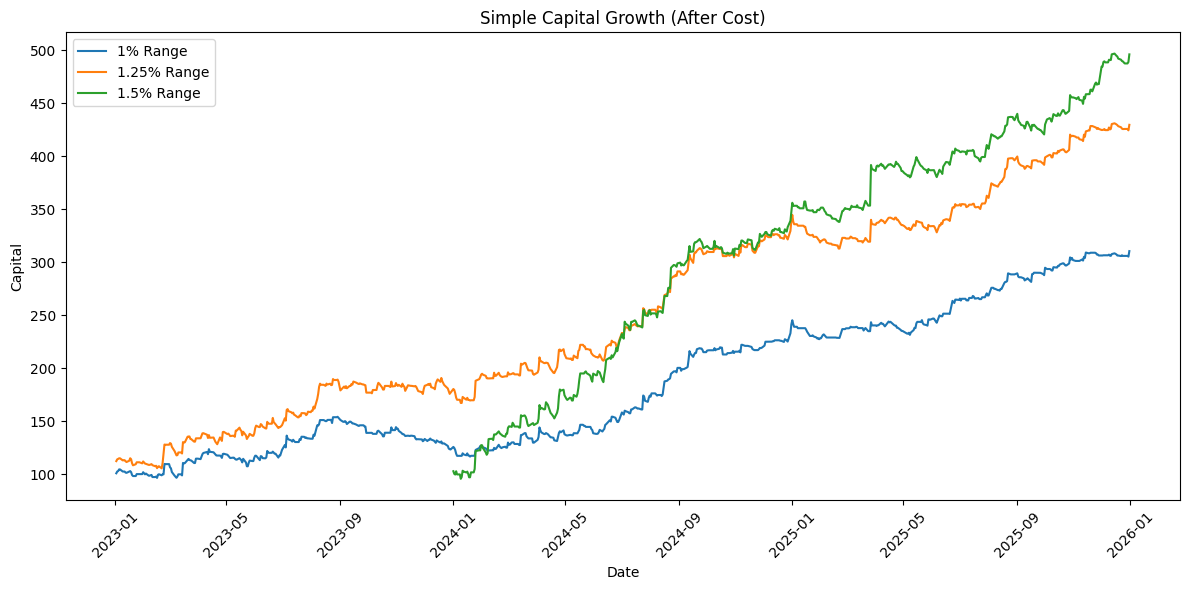

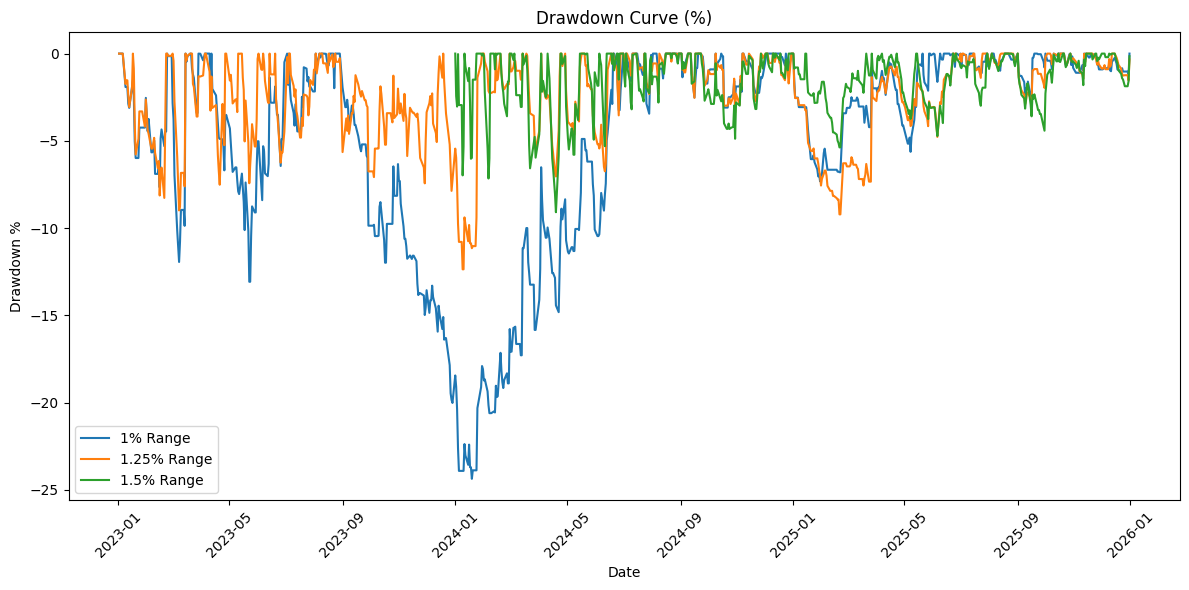


================ MONTHLY RETURN + TRADES TABLE ================
      month  1% Return  1% Trades  1.25% Return  1.25% Trades  1.5% Return  \
0   2023-01       1.77         33         11.93            54          NaN   
1   2023-02       7.66         27         15.81            41          NaN   
2   2023-03       5.15         46          6.01            70          NaN   
3   2023-04       4.64         47          6.16            71          NaN   
4   2023-05      -3.68         43         -1.49            68          NaN   
5   2023-06       7.41         44          7.78            80          NaN   
6   2023-07      10.44         43         12.27            74          NaN   
7   2023-08      18.71         25         24.76            54          NaN   
8   2023-09     -13.20         31         -6.31            60          NaN   
9   2023-10       5.44         30          9.00            40          NaN   
10  2023-11     -12.66         46         -5.66            78          NaN   

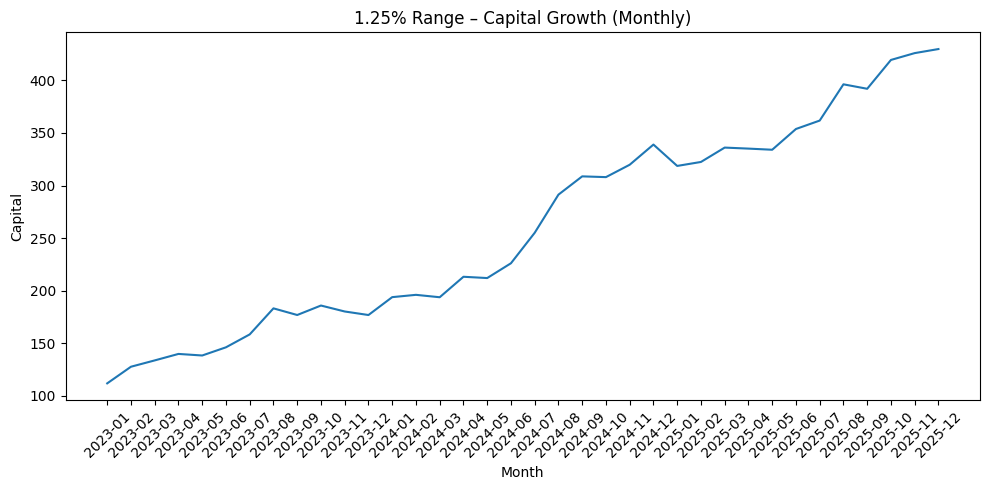


================ 1.25% RANGE – EXTRA STATS ================
Total Gross Return: 555.56%
Total Cost Paid: 225.80%
Total Net Return: 329.76%
Cost Impact vs Gross Profit: 40.64%

================ 1.25% RANGE – FULL MONTHLY ANALYSIS ================
      month  Gross Return %  Total Cost %  Net Return %  Total Trades  \
0   2023-01           17.33           5.4         11.93            54   
1   2023-02           19.91           4.1         15.81            41   
2   2023-03           13.01           7.0          6.01            70   
3   2023-04           13.26           7.1          6.16            71   
4   2023-05            5.31           6.8         -1.49            68   
5   2023-06           15.78           8.0          7.78            80   
6   2023-07           19.67           7.4         12.27            74   
7   2023-08           30.16           5.4         24.76            54   
8   2023-09           -0.31           6.0         -6.31            60   
9   2023-10           1

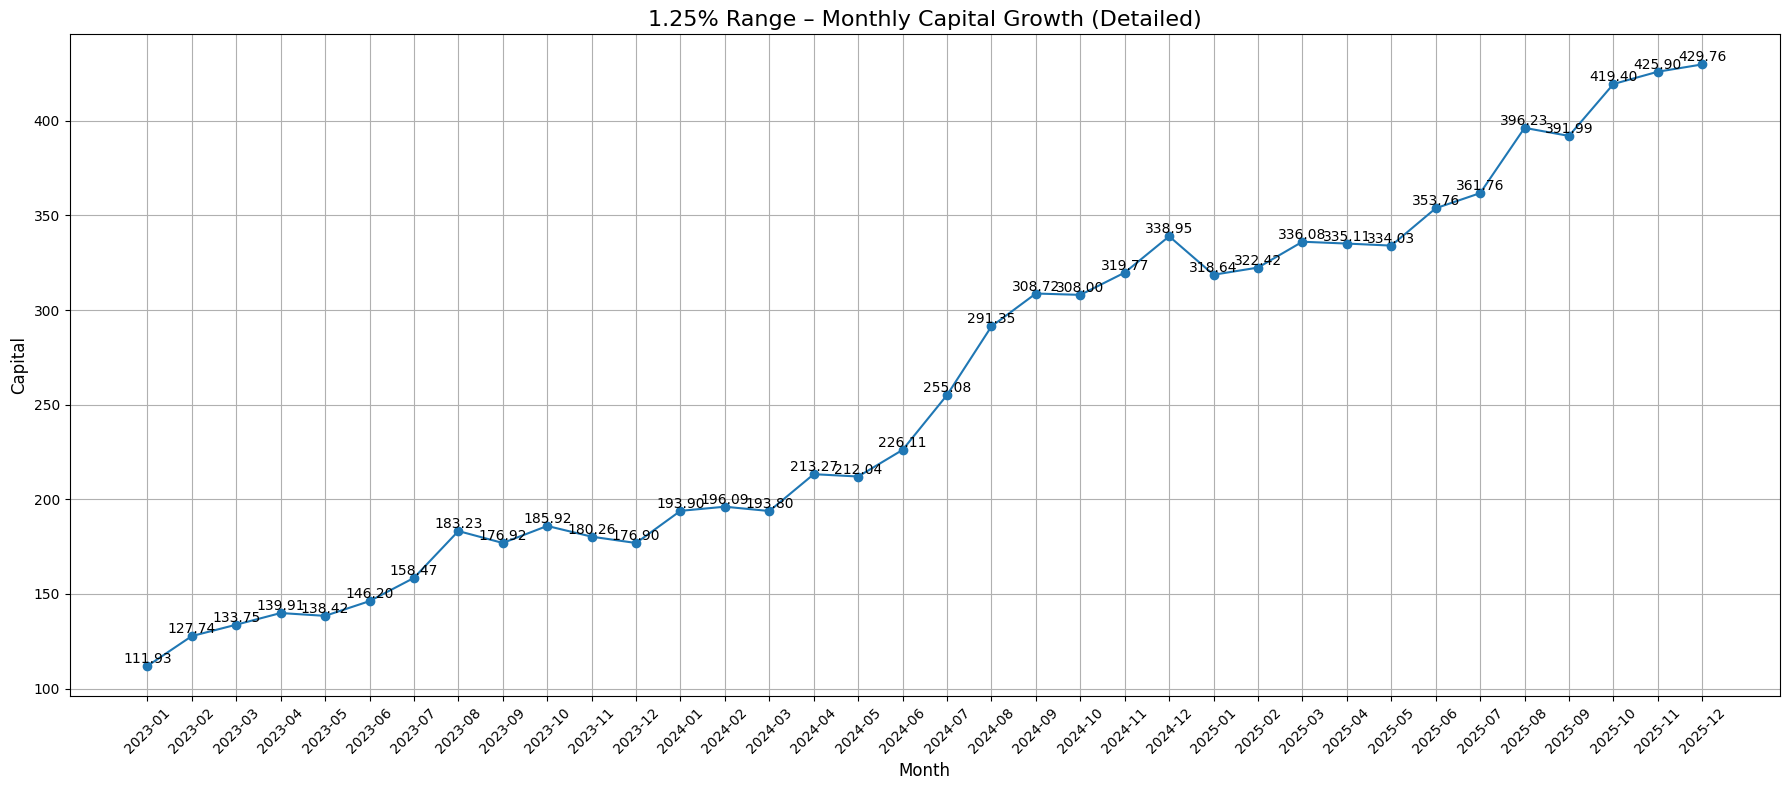


================ MONTE CARLO (1000 Simulations) ================
Average Final Capital: 429.76
Best Final Capital: 429.76
Worst Final Capital: 429.76
Average Max Drawdown: -16.90%
Worst Max Drawdown: -58.67%


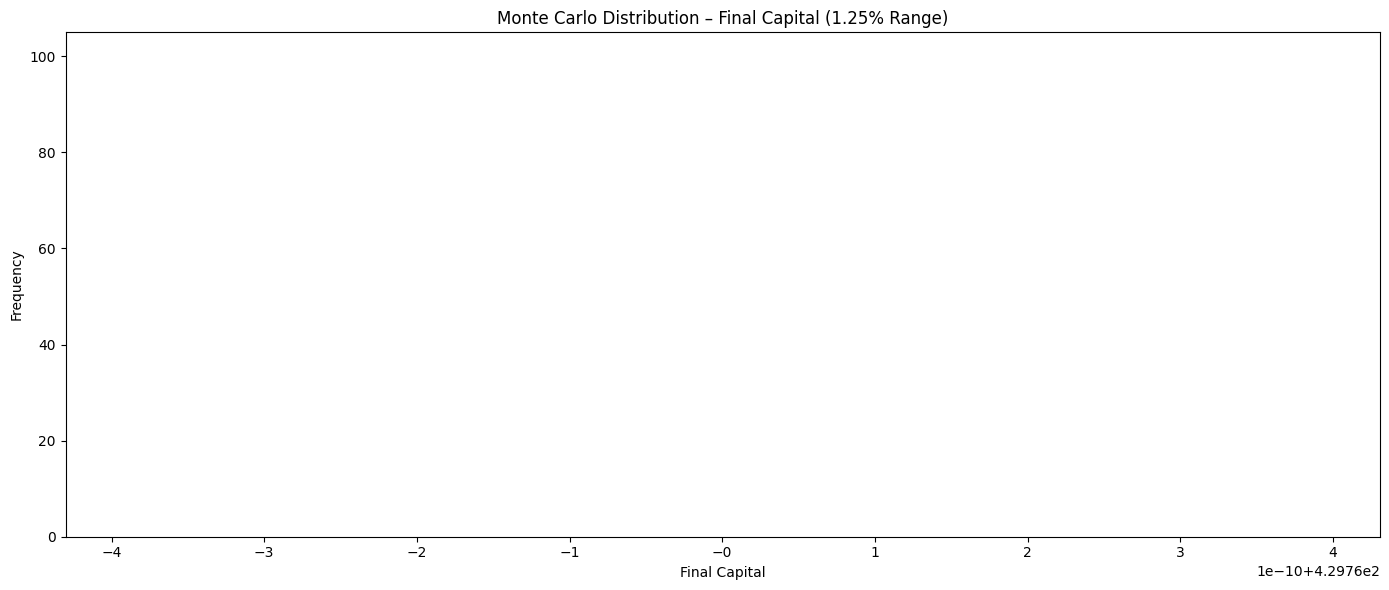


================ RISK OF RUIN ================
Ruin Threshold: 70
Risk of Ruin: 1.40%

================ ANNUAL COMPOUNDING ================
   year  net_return_pct  Capital End Of Year (Compounded)
0  2023           76.90                        176.900000
1  2024          162.05                        463.566450
2  2025           90.81                        884.531143


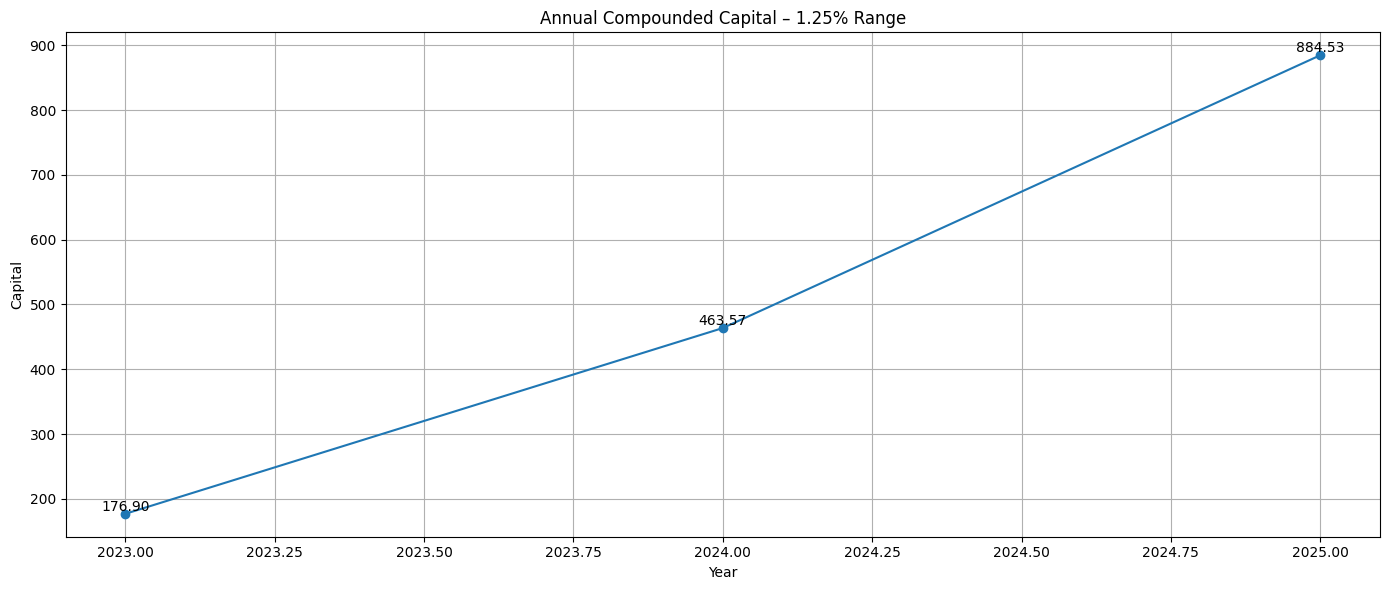

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
# =====================================================
# 🔹 PASTE YOUR RAW TEXT DATA BELOW
# =====================================================

raw_text_1 = """📅 January2023-2023-01-02 — Trades: 5, Return: 1.27%
📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%
📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%
📅 January2023-2023-01-05 — Trades: 2, Return: 1.77%
📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-10 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-13 — Trades: 1, Return: -0.15%
📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%
📅 January2023-2023-01-17 — Trades: 1, Return: 0.52%
📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-19 — Trades: 4, Return: -2.25%
📅 January2023-2023-01-20 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-23 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%
📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-31 — Trades: 9, Return: 2.68%
📅 February2023-2023-02-01 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-02 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-03 — Trades: 1, Return: 0.84%
📅 February2023-2023-02-06 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-07 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-08 — Trades: 3, Return: 0.60%
📅 February2023-2023-02-09 — Trades: 1, Return: 0.51%
📅 February2023-2023-02-10 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-13 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-14 — Trades: 1, Return: 0.56%
📅 February2023-2023-02-15 — Trades: 2, Return: -1.07%
📅 February2023-2023-02-16 — Trades: 3, Return: 3.23%
📅 February2023-2023-02-17 — Trades: 1, Return: 0.64%
📅 February2023-2023-02-20 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-21 — Trades: 2, Return: 1.08%
📅 February2023-2023-02-22 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-23 — Trades: 3, Return: 10.13%
📅 February2023-2023-02-24 — Trades: 3, Return: 0.14%
📅 February2023-2023-02-27 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-01 — Trades: 4, Return: -2.56%
📅 March2023-2023-03-02 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-03 — Trades: 4, Return: -3.11%
📅 March2023-2023-03-06 — Trades: 4, Return: -3.11%
📅 March2023-2023-03-08 — Trades: 4, Return: -1.55%
📅 March2023-2023-03-09 — Trades: 2, Return: 1.47%
📅 March2023-2023-03-10 — Trades: 3, Return: 2.30%
📅 March2023-2023-03-13 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-14 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-15 — Trades: 3, Return: 12.05%
📅 March2023-2023-03-16 — Trades: 1, Return: -0.41%
📅 March2023-2023-03-17 — Trades: 1, Return: 0.44%
📅 March2023-2023-03-20 — Trades: 3, Return: 3.36%
📅 March2023-2023-03-21 — Trades: 2, Return: 1.15%
📅 March2023-2023-03-22 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-23 — Trades: 1, Return: -0.26%
📅 March2023-2023-03-24 — Trades: 1, Return: -0.13%
📅 March2023-2023-03-27 — Trades: 3, Return: -2.00%
📅 March2023-2023-03-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-29 — Trades: 3, Return: 4.42%
📅 March2023-2023-03-31 — Trades: 4, Return: 0.39%
📅 April2023-2023-04-03 — Trades: 5, Return: 0.07%
📅 April2023-2023-04-05 — Trades: 2, Return: 4.83%
📅 April2023-2023-04-06 — Trades: 4, Return: 1.56%
📅 April2023-2023-04-10 — Trades: 1, Return: 1.06%
📅 April2023-2023-04-11 — Trades: 4, Return: -1.69%
📅 April2023-2023-04-12 — Trades: 3, Return: 5.05%
📅 April2023-2023-04-13 — Trades: 3, Return: -2.20%
📅 April2023-2023-04-17 — Trades: 3, Return: -0.16%
📅 April2023-2023-04-18 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-19 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-20 — Trades: 1, Return: -0.90%
📅 April2023-2023-04-21 — Trades: 1, Return: 0.02%
📅 April2023-2023-04-24 — Trades: 4, Return: 0.37%
📅 April2023-2023-04-25 — Trades: 2, Return: -0.30%
📅 April2023-2023-04-26 — Trades: 4, Return: -1.30%
📅 April2023-2023-04-27 — Trades: 3, Return: 3.97%
📅 April2023-2023-04-28 — Trades: 5, Return: 0.76%
📅 May2023-2023-05-02 — Trades: 4, Return: -0.56%
📅 May2023-2023-05-03 — Trades: 2, Return: -0.88%
📅 May2023-2023-05-04 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-05 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-08 — Trades: 2, Return: 0.52%
📅 May2023-2023-05-09 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-10 — Trades: 2, Return: -0.75%
📅 May2023-2023-05-11 — Trades: 3, Return: -0.45%
📅 May2023-2023-05-12 — Trades: 2, Return: 0.01%
📅 May2023-2023-05-15 — Trades: 3, Return: 1.75%
📅 May2023-2023-05-16 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-17 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-18 — Trades: 2, Return: -1.80%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 4, Return: -3.05%
📅 May2023-2023-05-23 — Trades: 6, Return: -2.98%
📅 May2023-2023-05-24 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-25 — Trades: 1, Return: 3.33%
📅 May2023-2023-05-26 — Trades: 3, Return: 2.41%
📅 May2023-2023-05-29 — Trades: 1, Return: -0.33%
📅 May2023-2023-05-30 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-31 — Trades: 3, Return: 3.53%
📅 June2023-2023-06-01 — Trades: 4, Return: 2.21%
📅 June2023-2023-06-02 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-05 — Trades: 4, Return: -2.77%
📅 June2023-2023-06-06 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-07 — Trades: 3, Return: 4.12%
📅 June2023-2023-06-08 — Trades: 1, Return: -0.24%
📅 June2023-2023-06-09 — Trades: 2, Return: -1.38%
📅 June2023-2023-06-12 — Trades: 1, Return: -0.10%
📅 June2023-2023-06-13 — Trades: 1, Return: 0.98%
📅 June2023-2023-06-14 — Trades: 4, Return: 6.50%
📅 June2023-2023-06-15 — Trades: 2, Return: -1.52%
📅 June2023-2023-06-16 — Trades: 3, Return: 0.24%
📅 June2023-2023-06-19 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-20 — Trades: 6, Return: 1.75%
📅 June2023-2023-06-21 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-22 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-23 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-26 — Trades: 5, Return: -3.13%
📅 June2023-2023-06-27 — Trades: 3, Return: 2.20%
📅 June2023-2023-06-28 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-30 — Trades: 2, Return: 5.65%
📅 July2023-2023-07-03 — Trades: 5, Return: 5.01%
📅 July2023-2023-07-04 — Trades: 3, Return: -1.98%
📅 July2023-2023-07-05 — Trades: 4, Return: 11.57%
📅 July2023-2023-07-06 — Trades: 3, Return: -2.33%
📅 July2023-2023-07-07 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-10 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-11 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-12 — Trades: 4, Return: 2.07%
📅 July2023-2023-07-13 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-14 — Trades: 2, Return: -0.92%
📅 July2023-2023-07-17 — Trades: 2, Return: 0.19%
📅 July2023-2023-07-18 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-19 — Trades: 1, Return: 2.81%
📅 July2023-2023-07-20 — Trades: 2, Return: -0.56%
📅 July2023-2023-07-21 — Trades: 2, Return: 3.27%
📅 July2023-2023-07-24 — Trades: 1, Return: 0.00%
📅 July2023-2023-07-25 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-26 — Trades: 1, Return: 0.44%
📅 July2023-2023-07-27 — Trades: 3, Return: -0.45%
📅 July2023-2023-07-28 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-31 — Trades: 5, Return: 0.12%
📅 August2023-2023-08-01 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-02 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-03 — Trades: 2, Return: 4.02%
📅 August2023-2023-08-04 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-07 — Trades: 1, Return: 9.96%
📅 August2023-2023-08-08 — Trades: 1, Return: -0.23%
📅 August2023-2023-08-09 — Trades: 2, Return: 1.56%
📅 August2023-2023-08-10 — Trades: 2, Return: 4.13%
📅 August2023-2023-08-11 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-17 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-18 — Trades: 1, Return: 1.24%
📅 August2023-2023-08-21 — Trades: 1, Return: 0.16%
📅 August2023-2023-08-22 — Trades: 1, Return: 0.11%
📅 August2023-2023-08-23 — Trades: 3, Return: -2.70%
📅 August2023-2023-08-24 — Trades: 3, Return: 5.79%
📅 August2023-2023-08-25 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-28 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-29 — Trades: 3, Return: 0.69%
📅 August2023-2023-08-30 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-31 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-01 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-04 — Trades: 5, Return: -1.23%
📅 September2023-2023-09-05 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-06 — Trades: 2, Return: 0.85%
📅 September2023-2023-09-07 — Trades: 2, Return: -0.56%
📅 September2023-2023-09-08 — Trades: 2, Return: -1.80%
📅 September2023-2023-09-11 — Trades: 3, Return: 2.55%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 2, Return: -0.51%
📅 September2023-2023-09-14 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-15 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-18 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-20 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-21 — Trades: 2, Return: -0.13%
📅 September2023-2023-09-22 — Trades: 1, Return: 0.71%
📅 September2023-2023-09-25 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-26 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-27 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-28 — Trades: 1, Return: -0.08%
📅 September2023-2023-09-29 — Trades: 6, Return: -5.40%
📅 October2023-2023-10-03 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-04 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-05 — Trades: 2, Return: 0.28%
📅 October2023-2023-10-06 — Trades: 1, Return: -0.90%
📅 October2023-2023-10-09 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-10 — Trades: 3, Return: 0.33%
📅 October2023-2023-10-11 — Trades: 1, Return: 2.66%
📅 October2023-2023-10-12 — Trades: 2, Return: 0.61%
📅 October2023-2023-10-13 — Trades: 2, Return: -0.62%
📅 October2023-2023-10-16 — Trades: 3, Return: -2.23%
📅 October2023-2023-10-17 — Trades: 2, Return: -1.80%
📅 October2023-2023-10-18 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-19 — Trades: 2, Return: 3.63%
📅 October2023-2023-10-20 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-23 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-25 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-26 — Trades: 3, Return: 5.38%
📅 October2023-2023-10-27 — Trades: 6, Return: -2.00%
📅 October2023-2023-10-30 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-31 — Trades: 3, Return: 3.10%
📅 November2023-2023-11-01 — Trades: 2, Return: -1.29%
📅 November2023-2023-11-02 — Trades: 3, Return: 0.29%
📅 November2023-2023-11-03 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-06 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-07 — Trades: 5, Return: -0.60%
📅 November2023-2023-11-08 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-09 — Trades: 2, Return: -0.45%
📅 November2023-2023-11-10 — Trades: 5, Return: -0.61%
📅 November2023-2023-11-13 — Trades: 1, Return: 0.39%
📅 November2023-2023-11-15 — Trades: 1, Return: -0.21%
📅 November2023-2023-11-16 — Trades: 3, Return: 0.59%
📅 November2023-2023-11-17 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-20 — Trades: 1, Return: -0.38%
📅 November2023-2023-11-21 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-22 — Trades: 1, Return: -0.90%
📅 November2023-2023-11-23 — Trades: 1, Return: 0.27%
📅 November2023-2023-11-24 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-28 — Trades: 4, Return: 0.19%
📅 November2023-2023-11-29 — Trades: 2, Return: -1.52%
📅 November2023-2023-11-30 — Trades: 9, Return: 1.57%
📅 December2023-2023-12-01 — Trades: 2, Return: 1.72%
📅 December2023-2023-12-04 — Trades: 2, Return: -1.80%
📅 December2023-2023-12-05 — Trades: 2, Return: 1.31%
📅 December2023-2023-12-06 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-07 — Trades: 2, Return: 1.49%
📅 December2023-2023-12-08 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-11 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-12 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-13 — Trades: 4, Return: -0.66%
📅 December2023-2023-12-14 — Trades: 4, Return: 2.69%
📅 December2023-2023-12-15 — Trades: 3, Return: -0.44%
📅 December2023-2023-12-18 — Trades: 3, Return: -1.02%
📅 December2023-2023-12-19 — Trades: 4, Return: 1.46%
📅 December2023-2023-12-20 — Trades: 2, Return: -1.80%
📅 December2023-2023-12-21 — Trades: 4, Return: 0.54%
📅 December2023-2023-12-22 — Trades: 0, Return: 0.00%
📅 December2023-2023-12-26 — Trades: 3, Return: -2.09%
📅 December2023-2023-12-27 — Trades: 3, Return: -2.18%
📅 December2023-2023-12-28 — Trades: 2, Return: -0.39%
📅 December2023-2023-12-29 — Trades: 3, Return: 0.03%
📅 January2024-2024-01-01 — Trades: 9, Return: 3.33%
📅 January2024-2024-01-02 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-03 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-04 — Trades: 5, Return: -2.93%
📅 January2024-2024-01-05 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 6, Return: 2.97%
📅 January2024-2024-01-12 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-15 — Trades: 2, Return: -0.63%
📅 January2024-2024-01-16 — Trades: 1, Return: 1.88%
📅 January2024-2024-01-17 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 3, Return: -0.72%
📅 January2024-2024-01-20 — Trades: 1, Return: 0.85%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-25 — Trades: 4, Return: 5.90%
📅 January2024-2024-01-29 — Trades: 3, Return: 2.15%
📅 January2024-2024-01-30 — Trades: 3, Return: 2.16%
📅 January2024-2024-01-31 — Trades: 4, Return: 0.13%
📅 February2024-2024-02-01 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-02 — Trades: 1, Return: 0.20%
📅 February2024-2024-02-05 — Trades: 3, Return: -0.77%
📅 February2024-2024-02-06 — Trades: 5, Return: -0.71%
📅 February2024-2024-02-07 — Trades: 2, Return: -0.51%
📅 February2024-2024-02-08 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-09 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 1, Return: 0.00%
📅 February2024-2024-02-14 — Trades: 4, Return: 2.76%
📅 February2024-2024-02-15 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-16 — Trades: 2, Return: 0.27%
📅 February2024-2024-02-19 — Trades: 4, Return: 4.24%
📅 February2024-2024-02-20 — Trades: 2, Return: -1.38%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 1, Return: 0.81%
📅 February2024-2024-02-26 — Trades: 1, Return: 0.69%
📅 February2024-2024-02-27 — Trades: 1, Return: -0.79%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 2, Return: 5.00%
📅 March2024-2024-03-01 — Trades: 2, Return: -1.80%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 2, Return: 2.31%
📅 March2024-2024-03-05 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-06 — Trades: 1, Return: 0.20%
📅 March2024-2024-03-07 — Trades: 4, Return: -1.13%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 2, Return: 9.66%
📅 March2024-2024-03-15 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-18 — Trades: 1, Return: 1.88%
📅 March2024-2024-03-19 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-20 — Trades: 4, Return: -2.62%
📅 March2024-2024-03-21 — Trades: 2, Return: -0.73%
📅 March2024-2024-03-22 — Trades: 2, Return: -0.85%
📅 March2024-2024-03-26 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-27 — Trades: 4, Return: -3.60%
📅 March2024-2024-03-28 — Trades: 0, Return: 0.00%
📅 April2024-2024-04-01 — Trades: 6, Return: 3.26%
📅 April2024-2024-04-02 — Trades: 5, Return: 3.24%
📅 April2024-2024-04-03 — Trades: 9, Return: 9.87%
📅 April2024-2024-04-04 — Trades: 4, Return: -2.45%
📅 April2024-2024-04-05 — Trades: 4, Return: -1.43%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 1, Return: 0.12%
📅 April2024-2024-04-10 — Trades: 3, Return: 1.19%
📅 April2024-2024-04-12 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-15 — Trades: 4, Return: -2.63%
📅 April2024-2024-04-16 — Trades: 0, Return: 0.00%
📅 April2024-2024-04-18 — Trades: 2, Return: -0.22%
📅 April2024-2024-04-19 — Trades: 3, Return: -2.13%
📅 April2024-2024-04-22 — Trades: 4, Return: -0.20%
📅 April2024-2024-04-23 — Trades: 2, Return: 4.11%
📅 April2024-2024-04-24 — Trades: 4, Return: 4.04%
📅 April2024-2024-04-25 — Trades: 1, Return: 1.69%
📅 April2024-2024-04-26 — Trades: 2, Return: -0.74%
📅 April2024-2024-04-29 — Trades: 5, Return: 2.27%
📅 April2024-2024-04-30 — Trades: 7, Return: -2.93%
📅 May2024-2024-05-02 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-03 — Trades: 1, Return: -0.06%
📅 May2024-2024-05-06 — Trades: 3, Return: 0.86%
📅 May2024-2024-05-07 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-08 — Trades: 3, Return: -0.04%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 2, Return: 2.15%
📅 May2024-2024-05-13 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-14 — Trades: 1, Return: 0.00%
📅 May2024-2024-05-15 — Trades: 1, Return: 1.82%
📅 May2024-2024-05-16 — Trades: 1, Return: 1.67%
📅 May2024-2024-05-17 — Trades: 1, Return: 4.86%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-22 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-23 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-24 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-27 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-28 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-29 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-30 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-31 — Trades: 3, Return: -2.70%
📅 June2024-2024-06-03 — Trades: 2, Return: -0.38%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 3, Return: 0.46%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 4, Return: 2.72%
📅 June2024-2024-06-10 — Trades: 4, Return: -1.16%
📅 June2024-2024-06-11 — Trades: 5, Return: 1.89%
📅 June2024-2024-06-12 — Trades: 1, Return: 1.11%
📅 June2024-2024-06-13 — Trades: 4, Return: 4.18%
📅 June2024-2024-06-14 — Trades: 2, Return: 0.92%
📅 June2024-2024-06-18 — Trades: 4, Return: 4.17%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 3, Return: 4.84%
📅 June2024-2024-06-21 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-24 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-25 — Trades: 2, Return: -1.80%
📅 June2024-2024-06-26 — Trades: 2, Return: -1.80%
📅 June2024-2024-06-27 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-28 — Trades: 2, Return: 1.96%
📅 July2024-2024-07-01 — Trades: 8, Return: 8.04%
📅 July2024-2024-07-02 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-03 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-04 — Trades: 2, Return: 3.92%
📅 July2024-2024-07-05 — Trades: 3, Return: -0.19%
📅 July2024-2024-07-08 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-09 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-10 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-11 — Trades: 3, Return: 3.95%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 2, Return: 2.13%
📅 July2024-2024-07-16 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-18 — Trades: 3, Return: -0.91%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-23 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-24 — Trades: 9, Return: 14.11%
📅 July2024-2024-07-25 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-26 — Trades: 4, Return: -3.60%
📅 July2024-2024-07-29 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-30 — Trades: 5, Return: 4.18%
📅 July2024-2024-07-31 — Trades: 2, Return: 2.38%
📅 August2024-2024-08-01 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-02 — Trades: 3, Return: 3.42%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 3, Return: -0.77%
📅 August2024-2024-08-08 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-09 — Trades: 1, Return: 0.64%
📅 August2024-2024-08-12 — Trades: 2, Return: 0.22%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 2, Return: 1.56%
📅 August2024-2024-08-16 — Trades: 3, Return: 12.77%
📅 August2024-2024-08-19 — Trades: 2, Return: 0.83%
📅 August2024-2024-08-20 — Trades: 1, Return: 1.30%
📅 August2024-2024-08-21 — Trades: 2, Return: 0.48%
📅 August2024-2024-08-22 — Trades: 2, Return: 0.97%
📅 August2024-2024-08-23 — Trades: 1, Return: 4.36%
📅 August2024-2024-08-26 — Trades: 1, Return: 2.39%
📅 August2024-2024-08-27 — Trades: 1, Return: 0.16%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 3, Return: 4.53%
📅 September2024-2024-09-02 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 3, Return: 1.78%
📅 September2024-2024-09-05 — Trades: 1, Return: 0.20%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 2, Return: 1.55%
📅 September2024-2024-09-10 — Trades: 2, Return: 0.86%
📅 September2024-2024-09-11 — Trades: 3, Return: 7.02%
📅 September2024-2024-09-12 — Trades: 4, Return: 8.64%
📅 September2024-2024-09-13 — Trades: 4, Return: -2.04%
📅 September2024-2024-09-16 — Trades: 3, Return: -2.70%
📅 September2024-2024-09-17 — Trades: 2, Return: 2.37%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 4, Return: 3.97%
📅 September2024-2024-09-23 — Trades: 1, Return: 1.09%
📅 September2024-2024-09-24 — Trades: 2, Return: -0.14%
📅 September2024-2024-09-25 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-26 — Trades: 2, Return: -1.07%
📅 September2024-2024-09-27 — Trades: 3, Return: -1.85%
📅 September2024-2024-09-30 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-01 — Trades: 2, Return: 1.69%
📅 October2024-2024-10-03 — Trades: 1, Return: 0.39%
📅 October2024-2024-10-04 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-09 — Trades: 2, Return: 2.19%
📅 October2024-2024-10-10 — Trades: 2, Return: -1.80%
📅 October2024-2024-10-11 — Trades: 2, Return: 1.00%
📅 October2024-2024-10-14 — Trades: 2, Return: 0.74%
📅 October2024-2024-10-15 — Trades: 2, Return: 1.69%
📅 October2024-2024-10-16 — Trades: 1, Return: -0.23%
📅 October2024-2024-10-17 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-18 — Trades: 7, Return: -5.77%
📅 October2024-2024-10-21 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.50%
📅 October2024-2024-10-24 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-25 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-28 — Trades: 2, Return: 0.60%
📅 October2024-2024-10-29 — Trades: 2, Return: 1.86%
📅 October2024-2024-10-30 — Trades: 2, Return: -1.80%
📅 October2024-2024-10-31 — Trades: 2, Return: 1.50%
📅 November2024-2024-11-04 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-05 — Trades: 3, Return: 1.22%
📅 November2024-2024-11-06 — Trades: 6, Return: -1.01%
📅 November2024-2024-11-07 — Trades: 1, Return: 7.26%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-18 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-19 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-21 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-26 — Trades: 1, Return: 0.96%
📅 November2024-2024-11-27 — Trades: 6, Return: 1.75%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 3, Return: 0.63%
📅 December2024-2024-12-02 — Trades: 4, Return: 2.42%
📅 December2024-2024-12-03 — Trades: 3, Return: 3.98%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 1, Return: 0.19%
📅 December2024-2024-12-06 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-09 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-10 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-11 — Trades: 2, Return: 0.63%
📅 December2024-2024-12-12 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-13 — Trades: 1, Return: 0.95%
📅 December2024-2024-12-16 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-19 — Trades: 4, Return: -0.06%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 2, Return: -0.89%
📅 December2024-2024-12-24 — Trades: 3, Return: 2.87%
📅 December2024-2024-12-26 — Trades: 3, Return: -0.80%
📅 December2024-2024-12-27 — Trades: 5, Return: -0.63%
📅 December2024-2024-12-30 — Trades: 1, Return: 7.94%
📅 December2024-2024-12-31 — Trades: 4, Return: 8.73%
📅 January2025-2025-01-01 — Trades: 9, Return: 4.88%
📅 January2025-2025-01-02 — Trades: 4, Return: -3.25%
📅 January2025-2025-01-03 — Trades: 3, Return: -2.24%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.13%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 5, Return: -0.96%
📅 January2025-2025-01-17 — Trades: 2, Return: -1.65%
📅 January2025-2025-01-20 — Trades: 4, Return: -3.60%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 2, Return: 0.77%
📅 January2025-2025-01-24 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-27 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-29 — Trades: 3, Return: 0.62%
📅 January2025-2025-01-30 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-31 — Trades: 4, Return: 1.34%
📅 February2025-2025-02-01 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-03 — Trades: 2, Return: 3.22%
📅 February2025-2025-02-04 — Trades: 1, Return: 0.72%
📅 February2025-2025-02-05 — Trades: 3, Return: -0.66%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-10 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-18 — Trades: 1, Return: -0.17%
📅 February2025-2025-02-19 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-20 — Trades: 2, Return: 0.12%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 1, Return: 8.39%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-28 — Trades: 1, Return: 0.86%
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 2, Return: 0.53%
📅 March2025-2025-03-05 — Trades: 2, Return: 1.37%
📅 March2025-2025-03-06 — Trades: 3, Return: -0.19%
📅 March2025-2025-03-07 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 2, Return: 0.65%
📅 March2025-2025-03-12 — Trades: 1, Return: -0.18%
📅 March2025-2025-03-13 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 5, Return: 0.51%
📅 March2025-2025-03-19 — Trades: 10, Return: -1.28%
📅 March2025-2025-03-20 — Trades: 1, Return: 1.36%
📅 March2025-2025-03-21 — Trades: 4, Return: 1.52%
📅 March2025-2025-03-24 — Trades: 3, Return: -2.70%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 4, Return: 8.86%
📅 March2025-2025-03-28 — Trades: 3, Return: -2.70%
📅 April2025-2025-04-01 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-02 — Trades: 2, Return: -0.34%
📅 April2025-2025-04-03 — Trades: 6, Return: 1.24%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 6, Return: -1.78%
📅 April2025-2025-04-15 — Trades: 5, Return: 5.07%
📅 April2025-2025-04-16 — Trades: 1, Return: -0.67%
📅 April2025-2025-04-17 — Trades: 2, Return: 0.73%
📅 April2025-2025-04-21 — Trades: 5, Return: -2.62%
📅 April2025-2025-04-22 — Trades: 2, Return: -0.30%
📅 April2025-2025-04-23 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 4, Return: -1.60%
📅 April2025-2025-04-29 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-02 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-05 — Trades: 5, Return: -1.06%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-09 — Trades: 3, Return: 2.47%
📅 May2025-2025-05-12 — Trades: 8, Return: 3.09%
📅 May2025-2025-05-13 — Trades: 1, Return: 2.29%
📅 May2025-2025-05-14 — Trades: 2, Return: -0.14%
📅 May2025-2025-05-15 — Trades: 2, Return: 4.78%
📅 May2025-2025-05-16 — Trades: 6, Return: 1.97%
📅 May2025-2025-05-19 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-20 — Trades: 1, Return: -0.09%
📅 May2025-2025-05-21 — Trades: 2, Return: 2.02%
📅 May2025-2025-05-22 — Trades: 3, Return: -2.70%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 2, Return: -0.48%
📅 May2025-2025-05-27 — Trades: 1, Return: -0.40%
📅 May2025-2025-05-28 — Trades: 3, Return: 6.21%
📅 May2025-2025-05-29 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%
📅 June2025-2025-06-02 — Trades: 3, Return: 1.40%
📅 June2025-2025-06-03 — Trades: 1, Return: 0.01%
📅 June2025-2025-06-04 — Trades: 3, Return: -1.11%
📅 June2025-2025-06-05 — Trades: 6, Return: -0.70%
📅 June2025-2025-06-06 — Trades: 3, Return: -0.90%
📅 June2025-2025-06-09 — Trades: 6, Return: 7.57%
📅 June2025-2025-06-10 — Trades: 4, Return: -0.24%
📅 June2025-2025-06-11 — Trades: 1, Return: -0.12%
📅 June2025-2025-06-12 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-13 — Trades: 2, Return: 2.65%
📅 June2025-2025-06-16 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 1, Return: -0.15%
📅 June2025-2025-06-23 — Trades: 5, Return: 12.85%
📅 June2025-2025-06-24 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-25 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-26 — Trades: 1, Return: 3.27%
📅 June2025-2025-06-27 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-30 — Trades: 2, Return: -0.11%
📅 July2025-2025-07-01 — Trades: 1, Return: 1.40%
📅 July2025-2025-07-02 — Trades: 3, Return: -1.55%
📅 July2025-2025-07-03 — Trades: 1, Return: 1.76%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-08 — Trades: 2, Return: -1.24%
📅 July2025-2025-07-09 — Trades: 3, Return: 0.19%
📅 July2025-2025-07-10 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-11 — Trades: 2, Return: 2.54%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 3, Return: 2.18%
📅 July2025-2025-07-16 — Trades: 2, Return: -0.42%
📅 July2025-2025-07-17 — Trades: 5, Return: -1.33%
📅 July2025-2025-07-18 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-21 — Trades: 1, Return: 0.57%
📅 July2025-2025-07-22 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-23 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-24 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-25 — Trades: 1, Return: 1.83%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 1, Return: 2.06%
📅 July2025-2025-07-30 — Trades: 2, Return: 1.93%
📅 July2025-2025-07-31 — Trades: 2, Return: -1.80%
📅 August2025-2025-08-01 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-04 — Trades: 2, Return: 7.43%
📅 August2025-2025-08-05 — Trades: 1, Return: 0.16%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 2, Return: -1.03%
📅 August2025-2025-08-12 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-13 — Trades: 2, Return: -0.28%
📅 August2025-2025-08-14 — Trades: 3, Return: 1.93%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 2, Return: 5.77%
📅 August2025-2025-08-19 — Trades: 2, Return: 1.29%
📅 August2025-2025-08-20 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-21 — Trades: 2, Return: 0.94%
📅 August2025-2025-08-22 — Trades: 1, Return: 7.40%
📅 August2025-2025-08-25 — Trades: 2, Return: -0.80%
📅 August2025-2025-08-26 — Trades: 1, Return: 0.10%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-01 — Trades: 4, Return: 1.40%
📅 September2025-2025-09-02 — Trades: 3, Return: -2.70%
📅 September2025-2025-09-03 — Trades: 3, Return: -0.41%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-08 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-09 — Trades: 2, Return: -1.80%
📅 September2025-2025-09-10 — Trades: 1, Return: 1.03%
📅 September2025-2025-09-11 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-12 — Trades: 2, Return: 1.33%
📅 September2025-2025-09-15 — Trades: 3, Return: -2.19%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.55%
📅 September2025-2025-09-17 — Trades: 1, Return: 7.45%
📅 September2025-2025-09-18 — Trades: 1, Return: 0.19%
📅 September2025-2025-09-19 — Trades: 1, Return: 1.33%
📅 September2025-2025-09-22 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-23 — Trades: 1, Return: 0.00%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 3, Return: -0.92%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%
📅 October2025-2025-10-01 — Trades: 5, Return: 7.52%
📅 October2025-2025-10-03 — Trades: 2, Return: -1.00%
📅 October2025-2025-10-06 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-07 — Trades: 1, Return: -0.23%
📅 October2025-2025-10-08 — Trades: 3, Return: -0.78%
📅 October2025-2025-10-09 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-10 — Trades: 2, Return: 3.34%
📅 October2025-2025-10-13 — Trades: 2, Return: -0.13%
📅 October2025-2025-10-14 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-15 — Trades: 1, Return: 1.66%
📅 October2025-2025-10-16 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-17 — Trades: 2, Return: 1.54%
📅 October2025-2025-10-20 — Trades: 2, Return: 1.24%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-24 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-27 — Trades: 2, Return: 2.11%
📅 October2025-2025-10-28 — Trades: 3, Return: 6.02%
📅 October2025-2025-10-29 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-30 — Trades: 3, Return: 1.81%
📅 October2025-2025-10-31 — Trades: 2, Return: -1.80%
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 1, Return: 0.09%
📅 November2025-2025-11-06 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-07 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 1, Return: -0.90%
📅 November2025-2025-11-12 — Trades: 5, Return: 4.03%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.73%
📅 November2025-2025-11-14 — Trades: 4, Return: 5.50%
📅 November2025-2025-11-17 — Trades: 5, Return: -0.19%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 2, Return: 0.70%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-25 — Trades: 1, Return: -0.34%
📅 November2025-2025-11-26 — Trades: 2, Return: -1.08%
📅 November2025-2025-11-27 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-28 — Trades: 1, Return: -0.79%
📅 December2025-2025-12-01 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 2, Return: 0.40%
📅 December2025-2025-12-04 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-05 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 1, Return: 0.72%
📅 December2025-2025-12-10 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-11 — Trades: 2, Return: 0.06%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.95%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-18 — Trades: 2, Return: -0.87%
📅 December2025-2025-12-19 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-22 — Trades: 1, Return: -0.40%
📅 December2025-2025-12-23 — Trades: 1, Return: 0.84%
📅 December2025-2025-12-24 — Trades: 1, Return: -0.49%
📅 December2025-2025-12-26 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 3, Return: -0.38%
📅 December2025-2025-12-31 — Trades: 3, Return: 5.50%
"""
raw_text_2 = """
📅 January2023-2023-01-02 — Trades: 12, Return: 13.46%
📅 January2023-2023-01-03 — Trades: 1, Return: 1.79%
📅 January2023-2023-01-04 — Trades: 2, Return: 0.59%
📅 January2023-2023-01-05 — Trades: 3, Return: 0.87%
📅 January2023-2023-01-06 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-09 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-10 — Trades: 2, Return: 0.44%
📅 January2023-2023-01-11 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-12 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-13 — Trades: 4, Return: -0.36%
📅 January2023-2023-01-16 — Trades: 1, Return: 1.33%
📅 January2023-2023-01-17 — Trades: 4, Return: 2.74%
📅 January2023-2023-01-18 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-19 — Trades: 5, Return: -3.15%
📅 January2023-2023-01-20 — Trades: 2, Return: -1.80%
📅 January2023-2023-01-23 — Trades: 2, Return: 1.22%
📅 January2023-2023-01-24 — Trades: 2, Return: 2.02%
📅 January2023-2023-01-25 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-27 — Trades: 0, Return: 0.00%
📅 January2023-2023-01-30 — Trades: 1, Return: -0.90%
📅 January2023-2023-01-31 — Trades: 9, Return: 2.68%
📅 February2023-2023-02-01 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-02 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-03 — Trades: 2, Return: -0.06%
📅 February2023-2023-02-06 — Trades: 3, Return: -0.67%
📅 February2023-2023-02-07 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-08 — Trades: 3, Return: 0.60%
📅 February2023-2023-02-09 — Trades: 1, Return: 0.51%
📅 February2023-2023-02-10 — Trades: 3, Return: -0.69%
📅 February2023-2023-02-13 — Trades: 1, Return: -0.90%
📅 February2023-2023-02-14 — Trades: 1, Return: 0.56%
📅 February2023-2023-02-15 — Trades: 3, Return: -1.97%
📅 February2023-2023-02-16 — Trades: 7, Return: 2.00%
📅 February2023-2023-02-17 — Trades: 1, Return: 0.64%
📅 February2023-2023-02-20 — Trades: 2, Return: -1.80%
📅 February2023-2023-02-21 — Trades: 3, Return: 5.28%
📅 February2023-2023-02-22 — Trades: 2, Return: 8.84%
📅 February2023-2023-02-23 — Trades: 4, Return: 9.23%
📅 February2023-2023-02-24 — Trades: 3, Return: 0.14%
📅 February2023-2023-02-27 — Trades: 0, Return: 0.00%
📅 February2023-2023-02-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-01 — Trades: 10, Return: 2.55%
📅 March2023-2023-03-02 — Trades: 2, Return: -0.34%
📅 March2023-2023-03-03 — Trades: 5, Return: -2.51%
📅 March2023-2023-03-06 — Trades: 7, Return: -3.42%
📅 March2023-2023-03-08 — Trades: 6, Return: -3.35%
📅 March2023-2023-03-09 — Trades: 3, Return: 0.57%
📅 March2023-2023-03-10 — Trades: 4, Return: 2.91%
📅 March2023-2023-03-13 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-14 — Trades: 1, Return: -0.90%
📅 March2023-2023-03-15 — Trades: 4, Return: 11.15%
📅 March2023-2023-03-16 — Trades: 1, Return: -0.41%
📅 March2023-2023-03-17 — Trades: 1, Return: 0.44%
📅 March2023-2023-03-20 — Trades: 4, Return: 5.69%
📅 March2023-2023-03-21 — Trades: 5, Return: 0.68%
📅 March2023-2023-03-22 — Trades: 2, Return: 0.23%
📅 March2023-2023-03-23 — Trades: 3, Return: -2.06%
📅 March2023-2023-03-24 — Trades: 1, Return: -0.13%
📅 March2023-2023-03-27 — Trades: 3, Return: -2.00%
📅 March2023-2023-03-28 — Trades: 0, Return: 0.00%
📅 March2023-2023-03-29 — Trades: 4, Return: 3.52%
📅 March2023-2023-03-31 — Trades: 4, Return: 0.39%
📅 April2023-2023-04-03 — Trades: 6, Return: 0.68%
📅 April2023-2023-04-05 — Trades: 2, Return: 4.83%
📅 April2023-2023-04-06 — Trades: 5, Return: 0.66%
📅 April2023-2023-04-10 — Trades: 6, Return: -0.84%
📅 April2023-2023-04-11 — Trades: 5, Return: -2.59%
📅 April2023-2023-04-12 — Trades: 5, Return: 3.21%
📅 April2023-2023-04-13 — Trades: 3, Return: -2.20%
📅 April2023-2023-04-17 — Trades: 7, Return: 0.93%
📅 April2023-2023-04-18 — Trades: 2, Return: -1.80%
📅 April2023-2023-04-19 — Trades: 2, Return: -1.80%
📅 April2023-2023-04-20 — Trades: 2, Return: -1.05%
📅 April2023-2023-04-21 — Trades: 2, Return: -0.88%
📅 April2023-2023-04-24 — Trades: 6, Return: 7.02%
📅 April2023-2023-04-25 — Trades: 3, Return: -1.20%
📅 April2023-2023-04-26 — Trades: 5, Return: -1.28%
📅 April2023-2023-04-27 — Trades: 5, Return: 8.81%
📅 April2023-2023-04-28 — Trades: 5, Return: 0.76%
📅 May2023-2023-05-02 — Trades: 7, Return: -1.46%
📅 May2023-2023-05-03 — Trades: 3, Return: 0.76%
📅 May2023-2023-05-04 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-05 — Trades: 3, Return: -1.00%
📅 May2023-2023-05-08 — Trades: 2, Return: 0.52%
📅 May2023-2023-05-09 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-10 — Trades: 4, Return: -0.61%
📅 May2023-2023-05-11 — Trades: 6, Return: 6.43%
📅 May2023-2023-05-12 — Trades: 4, Return: 0.39%
📅 May2023-2023-05-15 — Trades: 4, Return: 3.21%
📅 May2023-2023-05-16 — Trades: 2, Return: -1.80%
📅 May2023-2023-05-17 — Trades: 1, Return: -0.90%
📅 May2023-2023-05-18 — Trades: 5, Return: -3.74%
📅 May2023-2023-05-19 — Trades: 1, Return: 3.47%
📅 May2023-2023-05-22 — Trades: 4, Return: -3.05%
📅 May2023-2023-05-23 — Trades: 7, Return: -2.67%
📅 May2023-2023-05-24 — Trades: 1, Return: 1.63%
📅 May2023-2023-05-25 — Trades: 3, Return: 1.53%
📅 May2023-2023-05-26 — Trades: 3, Return: 2.41%
📅 May2023-2023-05-29 — Trades: 3, Return: -1.54%
📅 May2023-2023-05-30 — Trades: 0, Return: 0.00%
📅 May2023-2023-05-31 — Trades: 4, Return: 2.63%
📅 June2023-2023-06-01 — Trades: 6, Return: 5.59%
📅 June2023-2023-06-02 — Trades: 4, Return: 2.75%
📅 June2023-2023-06-05 — Trades: 5, Return: -0.83%
📅 June2023-2023-06-06 — Trades: 7, Return: 0.67%
📅 June2023-2023-06-07 — Trades: 4, Return: 3.22%
📅 June2023-2023-06-08 — Trades: 2, Return: -0.53%
📅 June2023-2023-06-09 — Trades: 2, Return: -1.38%
📅 June2023-2023-06-12 — Trades: 4, Return: -1.30%
📅 June2023-2023-06-13 — Trades: 3, Return: 0.12%
📅 June2023-2023-06-14 — Trades: 7, Return: 7.02%
📅 June2023-2023-06-15 — Trades: 2, Return: -1.52%
📅 June2023-2023-06-16 — Trades: 3, Return: 0.24%
📅 June2023-2023-06-19 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-20 — Trades: 8, Return: 6.28%
📅 June2023-2023-06-21 — Trades: 4, Return: -3.60%
📅 June2023-2023-06-22 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-23 — Trades: 1, Return: -0.90%
📅 June2023-2023-06-26 — Trades: 7, Return: -2.87%
📅 June2023-2023-06-27 — Trades: 4, Return: 1.30%
📅 June2023-2023-06-28 — Trades: 0, Return: 0.00%
📅 June2023-2023-06-30 — Trades: 6, Return: 2.42%
📅 July2023-2023-07-03 — Trades: 7, Return: 7.24%
📅 July2023-2023-07-04 — Trades: 3, Return: -1.98%
📅 July2023-2023-07-05 — Trades: 5, Return: 10.67%
📅 July2023-2023-07-06 — Trades: 5, Return: 1.24%
📅 July2023-2023-07-07 — Trades: 3, Return: -1.68%
📅 July2023-2023-07-10 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-11 — Trades: 1, Return: -0.90%
📅 July2023-2023-07-12 — Trades: 5, Return: 1.17%
📅 July2023-2023-07-13 — Trades: 2, Return: -1.80%
📅 July2023-2023-07-14 — Trades: 5, Return: 0.06%
📅 July2023-2023-07-17 — Trades: 4, Return: -1.62%
📅 July2023-2023-07-18 — Trades: 0, Return: 0.00%
📅 July2023-2023-07-19 — Trades: 2, Return: 2.03%
📅 July2023-2023-07-20 — Trades: 2, Return: -0.56%
📅 July2023-2023-07-21 — Trades: 5, Return: 3.42%
📅 July2023-2023-07-24 — Trades: 1, Return: 0.00%
📅 July2023-2023-07-25 — Trades: 2, Return: 0.03%
📅 July2023-2023-07-26 — Trades: 3, Return: -1.36%
📅 July2023-2023-07-27 — Trades: 5, Return: 1.32%
📅 July2023-2023-07-28 — Trades: 1, Return: 2.55%
📅 July2023-2023-07-31 — Trades: 12, Return: 0.74%
📅 August2023-2023-08-01 — Trades: 2, Return: 1.61%
📅 August2023-2023-08-02 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-03 — Trades: 2, Return: 4.02%
📅 August2023-2023-08-04 — Trades: 3, Return: -1.56%
📅 August2023-2023-08-07 — Trades: 4, Return: 9.46%
📅 August2023-2023-08-08 — Trades: 3, Return: 5.09%
📅 August2023-2023-08-09 — Trades: 3, Return: 7.04%
📅 August2023-2023-08-10 — Trades: 3, Return: 3.23%
📅 August2023-2023-08-11 — Trades: 2, Return: -0.83%
📅 August2023-2023-08-14 — Trades: 1, Return: 0.08%
📅 August2023-2023-08-16 — Trades: 1, Return: -0.90%
📅 August2023-2023-08-17 — Trades: 1, Return: 2.22%
📅 August2023-2023-08-18 — Trades: 3, Return: -0.56%
📅 August2023-2023-08-21 — Trades: 4, Return: 1.18%
📅 August2023-2023-08-22 — Trades: 3, Return: -1.07%
📅 August2023-2023-08-23 — Trades: 6, Return: 0.86%
📅 August2023-2023-08-24 — Trades: 3, Return: 5.79%
📅 August2023-2023-08-25 — Trades: 1, Return: -0.79%
📅 August2023-2023-08-28 — Trades: 0, Return: 0.00%
📅 August2023-2023-08-29 — Trades: 3, Return: 0.69%
📅 August2023-2023-08-30 — Trades: 2, Return: -1.80%
📅 August2023-2023-08-31 — Trades: 4, Return: -3.60%
📅 September2023-2023-09-01 — Trades: 7, Return: -3.51%
📅 September2023-2023-09-04 — Trades: 11, Return: 3.91%
📅 September2023-2023-09-05 — Trades: 1, Return: 0.95%
📅 September2023-2023-09-06 — Trades: 4, Return: -0.95%
📅 September2023-2023-09-07 — Trades: 5, Return: 2.17%
📅 September2023-2023-09-08 — Trades: 2, Return: -1.80%
📅 September2023-2023-09-11 — Trades: 3, Return: 2.55%
📅 September2023-2023-09-12 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-13 — Trades: 5, Return: 2.38%
📅 September2023-2023-09-14 — Trades: 2, Return: -0.46%
📅 September2023-2023-09-15 — Trades: 2, Return: 3.11%
📅 September2023-2023-09-18 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-20 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-21 — Trades: 2, Return: -0.13%
📅 September2023-2023-09-22 — Trades: 1, Return: 0.71%
📅 September2023-2023-09-25 — Trades: 1, Return: -0.90%
📅 September2023-2023-09-26 — Trades: 0, Return: 0.00%
📅 September2023-2023-09-27 — Trades: 4, Return: -0.16%
📅 September2023-2023-09-28 — Trades: 1, Return: -0.08%
📅 September2023-2023-09-29 — Trades: 7, Return: -6.30%
📅 October2023-2023-10-03 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-04 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-05 — Trades: 3, Return: -0.32%
📅 October2023-2023-10-06 — Trades: 2, Return: 3.30%
📅 October2023-2023-10-09 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-10 — Trades: 4, Return: 0.42%
📅 October2023-2023-10-11 — Trades: 2, Return: 4.28%
📅 October2023-2023-10-12 — Trades: 3, Return: 2.97%
📅 October2023-2023-10-13 — Trades: 2, Return: -0.62%
📅 October2023-2023-10-16 — Trades: 4, Return: -3.13%
📅 October2023-2023-10-17 — Trades: 2, Return: -1.80%
📅 October2023-2023-10-18 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-19 — Trades: 2, Return: 3.63%
📅 October2023-2023-10-20 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-23 — Trades: 0, Return: 0.00%
📅 October2023-2023-10-25 — Trades: 1, Return: -0.90%
📅 October2023-2023-10-26 — Trades: 3, Return: 5.38%
📅 October2023-2023-10-27 — Trades: 8, Return: -3.80%
📅 October2023-2023-10-30 — Trades: 1, Return: 0.49%
📅 October2023-2023-10-31 — Trades: 3, Return: 3.10%
📅 November2023-2023-11-01 — Trades: 3, Return: -1.42%
📅 November2023-2023-11-02 — Trades: 5, Return: -0.47%
📅 November2023-2023-11-03 — Trades: 3, Return: 1.38%
📅 November2023-2023-11-06 — Trades: 4, Return: -1.50%
📅 November2023-2023-11-07 — Trades: 8, Return: 3.74%
📅 November2023-2023-11-08 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-09 — Trades: 2, Return: -0.45%
📅 November2023-2023-11-10 — Trades: 8, Return: -3.31%
📅 November2023-2023-11-13 — Trades: 6, Return: 5.85%
📅 November2023-2023-11-15 — Trades: 3, Return: -0.08%
📅 November2023-2023-11-16 — Trades: 4, Return: 0.24%
📅 November2023-2023-11-17 — Trades: 0, Return: 0.00%
📅 November2023-2023-11-20 — Trades: 3, Return: -0.15%
📅 November2023-2023-11-21 — Trades: 3, Return: 0.66%
📅 November2023-2023-11-22 — Trades: 1, Return: -0.90%
📅 November2023-2023-11-23 — Trades: 3, Return: -1.53%
📅 November2023-2023-11-24 — Trades: 2, Return: -1.80%
📅 November2023-2023-11-28 — Trades: 5, Return: -0.54%
📅 November2023-2023-11-29 — Trades: 2, Return: -1.52%
📅 November2023-2023-11-30 — Trades: 11, Return: 5.74%
📅 December2023-2023-12-01 — Trades: 3, Return: 3.39%
📅 December2023-2023-12-04 — Trades: 7, Return: 1.69%
📅 December2023-2023-12-05 — Trades: 3, Return: 1.07%
📅 December2023-2023-12-06 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-07 — Trades: 2, Return: 1.49%
📅 December2023-2023-12-08 — Trades: 3, Return: -2.99%
📅 December2023-2023-12-11 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-12 — Trades: 1, Return: -0.90%
📅 December2023-2023-12-13 — Trades: 7, Return: 5.97%
📅 December2023-2023-12-14 — Trades: 4, Return: 2.69%
📅 December2023-2023-12-15 — Trades: 5, Return: 2.26%
📅 December2023-2023-12-18 — Trades: 4, Return: -1.92%
📅 December2023-2023-12-19 — Trades: 5, Return: 4.15%
📅 December2023-2023-12-20 — Trades: 3, Return: -2.70%
📅 December2023-2023-12-21 — Trades: 6, Return: -1.26%
📅 December2023-2023-12-22 — Trades: 2, Return: -1.49%
📅 December2023-2023-12-26 — Trades: 4, Return: -2.99%
📅 December2023-2023-12-27 — Trades: 3, Return: -2.18%
📅 December2023-2023-12-28 — Trades: 4, Return: -2.19%
📅 December2023-2023-12-29 — Trades: 4, Return: 1.55%
📅 January2024-2024-01-01 — Trades: 14, Return: 4.87%
📅 January2024-2024-01-02 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-03 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-04 — Trades: 9, Return: -3.30%
📅 January2024-2024-01-05 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 10, Return: 6.68%
📅 January2024-2024-01-12 — Trades: 2, Return: -0.54%
📅 January2024-2024-01-15 — Trades: 5, Return: -1.37%
📅 January2024-2024-01-16 — Trades: 1, Return: 1.88%
📅 January2024-2024-01-17 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 9, Return: 0.36%
📅 January2024-2024-01-20 — Trades: 2, Return: 0.43%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.23%
📅 January2024-2024-01-25 — Trades: 6, Return: 15.87%
📅 January2024-2024-01-29 — Trades: 6, Return: 2.17%
📅 January2024-2024-01-30 — Trades: 3, Return: 2.16%
📅 January2024-2024-01-31 — Trades: 5, Return: 2.86%
📅 February2024-2024-02-01 — Trades: 2, Return: 1.04%
📅 February2024-2024-02-02 — Trades: 2, Return: -0.70%
📅 February2024-2024-02-05 — Trades: 3, Return: -0.77%
📅 February2024-2024-02-06 — Trades: 6, Return: -1.61%
📅 February2024-2024-02-07 — Trades: 4, Return: 0.19%
📅 February2024-2024-02-08 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-09 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 1, Return: 0.00%
📅 February2024-2024-02-14 — Trades: 7, Return: 6.02%
📅 February2024-2024-02-15 — Trades: 3, Return: -2.70%
📅 February2024-2024-02-16 — Trades: 4, Return: 0.50%
📅 February2024-2024-02-19 — Trades: 5, Return: 3.34%
📅 February2024-2024-02-20 — Trades: 4, Return: -1.73%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 2, Return: -0.09%
📅 February2024-2024-02-26 — Trades: 1, Return: 0.69%
📅 February2024-2024-02-27 — Trades: 3, Return: 0.28%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 3, Return: 4.10%
📅 March2024-2024-03-01 — Trades: 2, Return: -1.80%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 4, Return: 0.87%
📅 March2024-2024-03-05 — Trades: 2, Return: 0.80%
📅 March2024-2024-03-06 — Trades: 1, Return: 0.20%
📅 March2024-2024-03-07 — Trades: 5, Return: -0.60%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 3, Return: 11.39%
📅 March2024-2024-03-15 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-18 — Trades: 1, Return: 1.88%
📅 March2024-2024-03-19 — Trades: 1, Return: -0.17%
📅 March2024-2024-03-20 — Trades: 5, Return: -2.02%
📅 March2024-2024-03-21 — Trades: 7, Return: -1.64%
📅 March2024-2024-03-22 — Trades: 5, Return: -1.39%
📅 March2024-2024-03-26 — Trades: 1, Return: -0.19%
📅 March2024-2024-03-27 — Trades: 5, Return: -2.71%
📅 March2024-2024-03-28 — Trades: 1, Return: -0.61%
📅 April2024-2024-04-01 — Trades: 9, Return: 3.04%
📅 April2024-2024-04-02 — Trades: 8, Return: 3.45%
📅 April2024-2024-04-03 — Trades: 11, Return: 12.71%
📅 April2024-2024-04-04 — Trades: 7, Return: -2.91%
📅 April2024-2024-04-05 — Trades: 6, Return: 0.39%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 2, Return: 0.13%
📅 April2024-2024-04-10 — Trades: 5, Return: 0.97%
📅 April2024-2024-04-12 — Trades: 2, Return: -0.19%
📅 April2024-2024-04-15 — Trades: 7, Return: -5.00%
📅 April2024-2024-04-16 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-18 — Trades: 4, Return: -2.02%
📅 April2024-2024-04-19 — Trades: 7, Return: 0.37%
📅 April2024-2024-04-22 — Trades: 7, Return: 6.24%
📅 April2024-2024-04-23 — Trades: 6, Return: 7.10%
📅 April2024-2024-04-24 — Trades: 9, Return: 10.70%
📅 April2024-2024-04-25 — Trades: 4, Return: 0.80%
📅 April2024-2024-04-26 — Trades: 3, Return: -1.25%
📅 April2024-2024-04-29 — Trades: 8, Return: 2.62%
📅 April2024-2024-04-30 — Trades: 8, Return: -3.83%
📅 May2024-2024-05-02 — Trades: 5, Return: -3.37%
📅 May2024-2024-05-03 — Trades: 1, Return: -0.06%
📅 May2024-2024-05-06 — Trades: 4, Return: -0.04%
📅 May2024-2024-05-07 — Trades: 1, Return: 0.53%
📅 May2024-2024-05-08 — Trades: 5, Return: -0.95%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 4, Return: 4.52%
📅 May2024-2024-05-13 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-14 — Trades: 4, Return: -0.08%
📅 May2024-2024-05-15 — Trades: 4, Return: 7.23%
📅 May2024-2024-05-16 — Trades: 4, Return: 1.44%
📅 May2024-2024-05-17 — Trades: 1, Return: 4.86%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 3, Return: -1.22%
📅 May2024-2024-05-22 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-23 — Trades: 3, Return: -2.35%
📅 May2024-2024-05-24 — Trades: 2, Return: 0.49%
📅 May2024-2024-05-27 — Trades: 1, Return: -0.55%
📅 May2024-2024-05-28 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-29 — Trades: 6, Return: -2.76%
📅 May2024-2024-05-30 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-31 — Trades: 5, Return: -0.62%
📅 June2024-2024-06-03 — Trades: 4, Return: -1.12%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 4, Return: -0.15%
📅 June2024-2024-06-06 — Trades: 5, Return: 1.06%
📅 June2024-2024-06-07 — Trades: 6, Return: 3.07%
📅 June2024-2024-06-10 — Trades: 8, Return: -4.56%
📅 June2024-2024-06-11 — Trades: 12, Return: 0.63%
📅 June2024-2024-06-12 — Trades: 1, Return: 1.11%
📅 June2024-2024-06-13 — Trades: 8, Return: 5.95%
📅 June2024-2024-06-14 — Trades: 5, Return: 7.28%
📅 June2024-2024-06-18 — Trades: 6, Return: 3.26%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 3, Return: 4.84%
📅 June2024-2024-06-21 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-24 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-25 — Trades: 3, Return: -2.70%
📅 June2024-2024-06-26 — Trades: 3, Return: -2.70%
📅 June2024-2024-06-27 — Trades: 2, Return: 4.63%
📅 June2024-2024-06-28 — Trades: 3, Return: 4.02%
📅 July2024-2024-07-01 — Trades: 10, Return: 8.17%
📅 July2024-2024-07-02 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-03 — Trades: 3, Return: 0.91%
📅 July2024-2024-07-04 — Trades: 2, Return: 3.92%
📅 July2024-2024-07-05 — Trades: 5, Return: 2.71%
📅 July2024-2024-07-08 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-09 — Trades: 2, Return: -1.80%
📅 July2024-2024-07-10 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-11 — Trades: 4, Return: 4.81%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 4, Return: 1.82%
📅 July2024-2024-07-16 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-18 — Trades: 3, Return: -0.91%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 4, Return: 0.49%
📅 July2024-2024-07-23 — Trades: 2, Return: -0.33%
📅 July2024-2024-07-24 — Trades: 19, Return: 19.33%
📅 July2024-2024-07-25 — Trades: 4, Return: -0.73%
📅 July2024-2024-07-26 — Trades: 5, Return: -2.55%
📅 July2024-2024-07-29 — Trades: 2, Return: -1.58%
📅 July2024-2024-07-30 — Trades: 5, Return: 4.18%
📅 July2024-2024-07-31 — Trades: 5, Return: 1.21%
📅 August2024-2024-08-01 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-02 — Trades: 5, Return: 1.62%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 8, Return: -0.77%
📅 August2024-2024-08-08 — Trades: 3, Return: -2.70%
📅 August2024-2024-08-09 — Trades: 2, Return: 7.97%
📅 August2024-2024-08-12 — Trades: 3, Return: -0.68%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 3, Return: 0.66%
📅 August2024-2024-08-16 — Trades: 5, Return: 12.73%
📅 August2024-2024-08-19 — Trades: 4, Return: 1.58%
📅 August2024-2024-08-20 — Trades: 2, Return: 2.64%
📅 August2024-2024-08-21 — Trades: 4, Return: 0.82%
📅 August2024-2024-08-22 — Trades: 4, Return: -0.85%
📅 August2024-2024-08-23 — Trades: 4, Return: 13.12%
📅 August2024-2024-08-26 — Trades: 1, Return: 2.39%
📅 August2024-2024-08-27 — Trades: 9, Return: 0.71%
📅 August2024-2024-08-28 — Trades: 4, Return: 1.90%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 3, Return: 4.53%
📅 September2024-2024-09-02 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 4, Return: 0.88%
📅 September2024-2024-09-05 — Trades: 2, Return: -0.70%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 3, Return: 3.54%
📅 September2024-2024-09-10 — Trades: 3, Return: 1.34%
📅 September2024-2024-09-11 — Trades: 5, Return: 7.56%
📅 September2024-2024-09-12 — Trades: 6, Return: 8.24%
📅 September2024-2024-09-13 — Trades: 5, Return: -2.94%
📅 September2024-2024-09-16 — Trades: 6, Return: -3.75%
📅 September2024-2024-09-17 — Trades: 5, Return: 8.92%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 6, Return: 2.17%
📅 September2024-2024-09-23 — Trades: 2, Return: 2.69%
📅 September2024-2024-09-24 — Trades: 2, Return: -0.14%
📅 September2024-2024-09-25 — Trades: 1, Return: -0.93%
📅 September2024-2024-09-26 — Trades: 3, Return: -1.97%
📅 September2024-2024-09-27 — Trades: 3, Return: -1.85%
📅 September2024-2024-09-30 — Trades: 1, Return: 1.24%
📅 October2024-2024-10-01 — Trades: 5, Return: 2.18%
📅 October2024-2024-10-03 — Trades: 2, Return: -0.51%
📅 October2024-2024-10-04 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-09 — Trades: 5, Return: 6.05%
📅 October2024-2024-10-10 — Trades: 3, Return: -2.70%
📅 October2024-2024-10-11 — Trades: 3, Return: 1.34%
📅 October2024-2024-10-14 — Trades: 4, Return: -0.20%
📅 October2024-2024-10-15 — Trades: 3, Return: 0.79%
📅 October2024-2024-10-16 — Trades: 3, Return: -0.57%
📅 October2024-2024-10-17 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-18 — Trades: 7, Return: -5.77%
📅 October2024-2024-10-21 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.50%
📅 October2024-2024-10-24 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-25 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-28 — Trades: 5, Return: 1.76%
📅 October2024-2024-10-29 — Trades: 3, Return: 3.62%
📅 October2024-2024-10-30 — Trades: 7, Return: -5.44%
📅 October2024-2024-10-31 — Trades: 4, Return: 3.83%
📅 November2024-2024-11-04 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-05 — Trades: 7, Return: 5.92%
📅 November2024-2024-11-06 — Trades: 14, Return: -0.71%
📅 November2024-2024-11-07 — Trades: 1, Return: 7.26%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 1, Return: 3.44%
📅 November2024-2024-11-18 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-19 — Trades: 7, Return: -4.92%
📅 November2024-2024-11-21 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 1, Return: 6.39%
📅 November2024-2024-11-26 — Trades: 2, Return: 0.06%
📅 November2024-2024-11-27 — Trades: 9, Return: 6.34%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 4, Return: -0.27%
📅 December2024-2024-12-02 — Trades: 5, Return: 2.26%
📅 December2024-2024-12-03 — Trades: 5, Return: 4.42%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 2, Return: -0.71%
📅 December2024-2024-12-06 — Trades: 3, Return: -0.53%
📅 December2024-2024-12-09 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-10 — Trades: 2, Return: 3.63%
📅 December2024-2024-12-11 — Trades: 3, Return: -0.27%
📅 December2024-2024-12-12 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-13 — Trades: 1, Return: 0.95%
📅 December2024-2024-12-16 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-17 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-18 — Trades: 1, Return: 0.26%
📅 December2024-2024-12-19 — Trades: 6, Return: -1.86%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 3, Return: -0.67%
📅 December2024-2024-12-24 — Trades: 4, Return: 4.02%
📅 December2024-2024-12-26 — Trades: 4, Return: -1.70%
📅 December2024-2024-12-27 — Trades: 6, Return: -1.53%
📅 December2024-2024-12-30 — Trades: 3, Return: 8.33%
📅 December2024-2024-12-31 — Trades: 6, Return: 9.98%
📅 January2025-2025-01-01 — Trades: 12, Return: 6.96%
📅 January2025-2025-01-02 — Trades: 8, Return: -5.45%
📅 January2025-2025-01-03 — Trades: 3, Return: -2.24%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 3, Return: -1.10%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 8, Return: -2.80%
📅 January2025-2025-01-17 — Trades: 3, Return: -2.55%
📅 January2025-2025-01-20 — Trades: 8, Return: -0.76%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: 0.97%
📅 January2025-2025-01-24 — Trades: 2, Return: -1.80%
📅 January2025-2025-01-27 — Trades: 2, Return: 0.25%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-29 — Trades: 7, Return: -0.69%
📅 January2025-2025-01-30 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-31 — Trades: 8, Return: -1.19%
📅 February2025-2025-02-01 — Trades: 3, Return: 1.61%
📅 February2025-2025-02-03 — Trades: 4, Return: 1.42%
📅 February2025-2025-02-04 — Trades: 1, Return: 0.72%
📅 February2025-2025-02-05 — Trades: 7, Return: 0.70%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-10 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 2, Return: -0.24%
📅 February2025-2025-02-18 — Trades: 1, Return: -0.17%
📅 February2025-2025-02-19 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-20 — Trades: 5, Return: -2.44%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 10.30%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-28 — Trades: 3, Return: -0.32%
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 2, Return: 0.53%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.89%
📅 March2025-2025-03-06 — Trades: 3, Return: -0.19%
📅 March2025-2025-03-07 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 3, Return: -0.25%
📅 March2025-2025-03-12 — Trades: 1, Return: -0.18%
📅 March2025-2025-03-13 — Trades: 2, Return: -1.80%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 9, Return: -0.38%
📅 March2025-2025-03-19 — Trades: 15, Return: 2.86%
📅 March2025-2025-03-20 — Trades: 2, Return: 1.00%
📅 March2025-2025-03-21 — Trades: 6, Return: 2.70%
📅 March2025-2025-03-24 — Trades: 5, Return: -2.99%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 10, Return: 21.67%
📅 March2025-2025-03-28 — Trades: 4, Return: -3.60%
📅 April2025-2025-04-01 — Trades: 1, Return: -0.65%
📅 April2025-2025-04-02 — Trades: 4, Return: 2.14%
📅 April2025-2025-04-03 — Trades: 8, Return: 1.13%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 2, Return: 2.90%
📅 April2025-2025-04-08 — Trades: 2, Return: -0.67%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 7, Return: -1.65%
📅 April2025-2025-04-15 — Trades: 12, Return: 6.30%
📅 April2025-2025-04-16 — Trades: 2, Return: 0.32%
📅 April2025-2025-04-17 — Trades: 3, Return: 0.35%
📅 April2025-2025-04-21 — Trades: 15, Return: -0.27%
📅 April2025-2025-04-22 — Trades: 6, Return: 2.33%
📅 April2025-2025-04-23 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 6, Return: -3.40%
📅 April2025-2025-04-29 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-02 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-05 — Trades: 6, Return: -1.96%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-09 — Trades: 5, Return: 0.67%
📅 May2025-2025-05-12 — Trades: 16, Return: 6.78%
📅 May2025-2025-05-13 — Trades: 5, Return: -0.60%
📅 May2025-2025-05-14 — Trades: 5, Return: 0.23%
📅 May2025-2025-05-15 — Trades: 2, Return: 4.78%
📅 May2025-2025-05-16 — Trades: 11, Return: 0.83%
📅 May2025-2025-05-19 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-20 — Trades: 1, Return: -0.09%
📅 May2025-2025-05-21 — Trades: 4, Return: 0.22%
📅 May2025-2025-05-22 — Trades: 3, Return: -2.70%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 5, Return: -0.91%
📅 May2025-2025-05-27 — Trades: 2, Return: -1.30%
📅 May2025-2025-05-28 — Trades: 4, Return: 5.31%
📅 May2025-2025-05-29 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%
📅 June2025-2025-06-02 — Trades: 6, Return: 0.75%
📅 June2025-2025-06-03 — Trades: 1, Return: 0.01%
📅 June2025-2025-06-04 — Trades: 6, Return: -0.77%
📅 June2025-2025-06-05 — Trades: 9, Return: -1.37%
📅 June2025-2025-06-06 — Trades: 4, Return: -1.80%
📅 June2025-2025-06-09 — Trades: 8, Return: 7.68%
📅 June2025-2025-06-10 — Trades: 5, Return: 0.12%
📅 June2025-2025-06-11 — Trades: 3, Return: 2.76%
📅 June2025-2025-06-12 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-13 — Trades: 3, Return: 3.64%
📅 June2025-2025-06-16 — Trades: 1, Return: 1.17%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.29%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-23 — Trades: 6, Return: 13.21%
📅 June2025-2025-06-24 — Trades: 3, Return: 0.53%
📅 June2025-2025-06-25 — Trades: 4, Return: 0.29%
📅 June2025-2025-06-26 — Trades: 1, Return: 3.27%
📅 June2025-2025-06-27 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-30 — Trades: 3, Return: 0.43%
📅 July2025-2025-07-01 — Trades: 2, Return: 1.26%
📅 July2025-2025-07-02 — Trades: 4, Return: -1.19%
📅 July2025-2025-07-03 — Trades: 1, Return: 1.76%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 1, Return: -0.30%
📅 July2025-2025-07-08 — Trades: 3, Return: -2.14%
📅 July2025-2025-07-09 — Trades: 4, Return: 0.94%
📅 July2025-2025-07-10 — Trades: 1, Return: 0.54%
📅 July2025-2025-07-11 — Trades: 3, Return: 1.64%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 5, Return: 1.32%
📅 July2025-2025-07-16 — Trades: 5, Return: 0.53%
📅 July2025-2025-07-17 — Trades: 6, Return: -2.23%
📅 July2025-2025-07-18 — Trades: 1, Return: -0.48%
📅 July2025-2025-07-21 — Trades: 1, Return: 0.57%
📅 July2025-2025-07-22 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-23 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-24 — Trades: 1, Return: 3.59%
📅 July2025-2025-07-25 — Trades: 1, Return: 1.83%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 1, Return: 2.06%
📅 July2025-2025-07-30 — Trades: 5, Return: 5.85%
📅 July2025-2025-07-31 — Trades: 4, Return: -0.65%
📅 August2025-2025-08-01 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-04 — Trades: 4, Return: 14.20%
📅 August2025-2025-08-05 — Trades: 4, Return: -0.59%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 2, Return: -1.03%
📅 August2025-2025-08-12 — Trades: 1, Return: 2.03%
📅 August2025-2025-08-13 — Trades: 5, Return: 1.55%
📅 August2025-2025-08-14 — Trades: 3, Return: 1.93%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 3, Return: 4.87%
📅 August2025-2025-08-19 — Trades: 4, Return: 7.81%
📅 August2025-2025-08-20 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-21 — Trades: 3, Return: 2.36%
📅 August2025-2025-08-22 — Trades: 3, Return: 8.15%
📅 August2025-2025-08-25 — Trades: 4, Return: 0.79%
📅 August2025-2025-08-26 — Trades: 1, Return: 0.10%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-29 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-01 — Trades: 8, Return: 4.42%
📅 September2025-2025-09-02 — Trades: 5, Return: -4.50%
📅 September2025-2025-09-03 — Trades: 4, Return: -1.31%
📅 September2025-2025-09-04 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-05 — Trades: 3, Return: -0.39%
📅 September2025-2025-09-08 — Trades: 4, Return: -0.61%
📅 September2025-2025-09-09 — Trades: 3, Return: -1.91%
📅 September2025-2025-09-10 — Trades: 1, Return: 1.03%
📅 September2025-2025-09-11 — Trades: 2, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 3, Return: 0.43%
📅 September2025-2025-09-15 — Trades: 6, Return: -0.74%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.55%
📅 September2025-2025-09-17 — Trades: 1, Return: 7.45%
📅 September2025-2025-09-18 — Trades: 2, Return: 0.29%
📅 September2025-2025-09-19 — Trades: 2, Return: 0.43%
📅 September2025-2025-09-22 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-23 — Trades: 2, Return: -0.90%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 4, Return: -1.82%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%
📅 October2025-2025-10-01 — Trades: 5, Return: 7.52%
📅 October2025-2025-10-03 — Trades: 4, Return: 1.45%
📅 October2025-2025-10-06 — Trades: 1, Return: 1.54%
📅 October2025-2025-10-07 — Trades: 3, Return: -0.09%
📅 October2025-2025-10-08 — Trades: 4, Return: -1.68%
📅 October2025-2025-10-09 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-10 — Trades: 5, Return: 4.54%
📅 October2025-2025-10-13 — Trades: 2, Return: -0.13%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.13%
📅 October2025-2025-10-15 — Trades: 2, Return: 2.59%
📅 October2025-2025-10-16 — Trades: 1, Return: -0.90%
📅 October2025-2025-10-17 — Trades: 2, Return: 1.54%
📅 October2025-2025-10-20 — Trades: 2, Return: 1.24%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 3, Return: -2.15%
📅 October2025-2025-10-24 — Trades: 1, Return: -0.16%
📅 October2025-2025-10-27 — Trades: 3, Return: 2.55%
📅 October2025-2025-10-28 — Trades: 7, Return: 15.14%
📅 October2025-2025-10-29 — Trades: 3, Return: -1.46%
📅 October2025-2025-10-30 — Trades: 4, Return: 0.91%
📅 October2025-2025-10-31 — Trades: 3, Return: 0.43%
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 2, Return: -0.60%
📅 November2025-2025-11-06 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-07 — Trades: 4, Return: -1.18%
📅 November2025-2025-11-10 — Trades: 3, Return: -0.36%
📅 November2025-2025-11-11 — Trades: 2, Return: -0.87%
📅 November2025-2025-11-12 — Trades: 7, Return: 6.75%
📅 November2025-2025-11-13 — Trades: 4, Return: -1.63%
📅 November2025-2025-11-14 — Trades: 4, Return: 5.50%
📅 November2025-2025-11-17 — Trades: 6, Return: 1.47%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 3, Return: 4.47%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 1, Return: -0.90%
📅 November2025-2025-11-25 — Trades: 1, Return: -0.34%
📅 November2025-2025-11-26 — Trades: 2, Return: -1.08%
📅 November2025-2025-11-27 — Trades: 1, Return: 1.01%
📅 November2025-2025-11-28 — Trades: 1, Return: -0.79%
📅 December2025-2025-12-01 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 2, Return: 0.40%
📅 December2025-2025-12-04 — Trades: 2, Return: 0.87%
📅 December2025-2025-12-05 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 2, Return: 2.68%
📅 December2025-2025-12-10 — Trades: 2, Return: -1.68%
📅 December2025-2025-12-11 — Trades: 5, Return: 0.98%
📅 December2025-2025-12-12 — Trades: 5, Return: 5.14%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-18 — Trades: 3, Return: -0.43%
📅 December2025-2025-12-19 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-22 — Trades: 2, Return: -0.83%
📅 December2025-2025-12-23 — Trades: 3, Return: -0.98%
📅 December2025-2025-12-24 — Trades: 2, Return: -0.20%
📅 December2025-2025-12-26 — Trades: 1, Return: 0.20%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 5, Return: -0.80%
📅 December2025-2025-12-31 — Trades: 3, Return: 5.50%"""
raw_text_3 = """📅 January2024-2024-01-01 — Trades: 19, Return: 4.62%
📅 January2024-2024-01-02 — Trades: 3, Return: -2.20%
📅 January2024-2024-01-03 — Trades: 5, Return: -0.12%
📅 January2024-2024-01-04 — Trades: 11, Return: 4.19%
📅 January2024-2024-01-05 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 5, Return: -3.64%
📅 January2024-2024-01-10 — Trades: 1, Return: 1.79%
📅 January2024-2024-01-11 — Trades: 14, Return: 7.35%
📅 January2024-2024-01-12 — Trades: 2, Return: -0.54%
📅 January2024-2024-01-15 — Trades: 6, Return: -0.29%
📅 January2024-2024-01-16 — Trades: 2, Return: 0.98%
📅 January2024-2024-01-17 — Trades: 3, Return: -1.75%
📅 January2024-2024-01-18 — Trades: 5, Return: -2.82%
📅 January2024-2024-01-19 — Trades: 13, Return: 1.35%
📅 January2024-2024-01-20 — Trades: 7, Return: 5.33%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.23%
📅 January2024-2024-01-25 — Trades: 8, Return: 17.75%
📅 January2024-2024-01-29 — Trades: 10, Return: 1.79%
📅 January2024-2024-01-30 — Trades: 5, Return: 0.36%
📅 January2024-2024-01-31 — Trades: 9, Return: 5.89%
📅 February2024-2024-02-01 — Trades: 3, Return: 0.14%
📅 February2024-2024-02-02 — Trades: 5, Return: -2.18%
📅 February2024-2024-02-05 — Trades: 6, Return: -3.47%
📅 February2024-2024-02-06 — Trades: 6, Return: -1.61%
📅 February2024-2024-02-07 — Trades: 6, Return: 2.07%
📅 February2024-2024-02-08 — Trades: 4, Return: 13.69%
📅 February2024-2024-02-09 — Trades: 1, Return: 0.29%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 3, Return: -0.90%
📅 February2024-2024-02-14 — Trades: 7, Return: 6.02%
📅 February2024-2024-02-15 — Trades: 8, Return: 0.70%
📅 February2024-2024-02-16 — Trades: 4, Return: 0.50%
📅 February2024-2024-02-19 — Trades: 5, Return: 3.34%
📅 February2024-2024-02-20 — Trades: 5, Return: -1.09%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 4, Return: -0.52%
📅 February2024-2024-02-26 — Trades: 3, Return: -0.70%
📅 February2024-2024-02-27 — Trades: 4, Return: 3.19%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 5, Return: 6.07%
📅 March2024-2024-03-01 — Trades: 4, Return: 1.83%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 5, Return: -0.03%
📅 March2024-2024-03-05 — Trades: 5, Return: 4.43%
📅 March2024-2024-03-06 — Trades: 4, Return: -1.04%
📅 March2024-2024-03-07 — Trades: 6, Return: -1.50%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 4, Return: 12.06%
📅 March2024-2024-03-15 — Trades: 2, Return: -0.77%
📅 March2024-2024-03-18 — Trades: 2, Return: 0.98%
📅 March2024-2024-03-19 — Trades: 2, Return: -1.07%
📅 March2024-2024-03-20 — Trades: 5, Return: -2.02%
📅 March2024-2024-03-21 — Trades: 10, Return: -3.18%
📅 March2024-2024-03-22 — Trades: 7, Return: -1.37%
📅 March2024-2024-03-26 — Trades: 4, Return: 2.61%
📅 March2024-2024-03-27 — Trades: 6, Return: 1.19%
📅 March2024-2024-03-28 — Trades: 4, Return: -1.45%
📅 April2024-2024-04-01 — Trades: 12, Return: 3.29%
📅 April2024-2024-04-02 — Trades: 10, Return: 4.84%
📅 April2024-2024-04-03 — Trades: 13, Return: 14.22%
📅 April2024-2024-04-04 — Trades: 7, Return: -2.91%
📅 April2024-2024-04-05 — Trades: 7, Return: 1.73%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 4, Return: 0.71%
📅 April2024-2024-04-10 — Trades: 8, Return: 7.30%
📅 April2024-2024-04-12 — Trades: 4, Return: -1.99%
📅 April2024-2024-04-15 — Trades: 9, Return: -6.80%
📅 April2024-2024-04-16 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-18 — Trades: 4, Return: -2.02%
📅 April2024-2024-04-19 — Trades: 12, Return: -0.55%
📅 April2024-2024-04-22 — Trades: 10, Return: 6.42%
📅 April2024-2024-04-23 — Trades: 9, Return: 4.81%
📅 April2024-2024-04-24 — Trades: 13, Return: 12.82%
📅 April2024-2024-04-25 — Trades: 9, Return: 7.38%
📅 April2024-2024-04-26 — Trades: 4, Return: -0.67%
📅 April2024-2024-04-29 — Trades: 9, Return: 1.72%
📅 April2024-2024-04-30 — Trades: 10, Return: -4.20%
📅 May2024-2024-05-02 — Trades: 6, Return: -2.68%
📅 May2024-2024-05-03 — Trades: 2, Return: -0.96%
📅 May2024-2024-05-06 — Trades: 5, Return: 2.67%
📅 May2024-2024-05-07 — Trades: 2, Return: -0.06%
📅 May2024-2024-05-08 — Trades: 6, Return: -1.85%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 5, Return: 5.73%
📅 May2024-2024-05-13 — Trades: 3, Return: -1.35%
📅 May2024-2024-05-14 — Trades: 6, Return: 3.40%
📅 May2024-2024-05-15 — Trades: 7, Return: 6.12%
📅 May2024-2024-05-16 — Trades: 5, Return: 8.26%
📅 May2024-2024-05-17 — Trades: 4, Return: 6.42%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 7, Return: 0.60%
📅 May2024-2024-05-22 — Trades: 2, Return: 1.45%
📅 May2024-2024-05-23 — Trades: 6, Return: 1.37%
📅 May2024-2024-05-24 — Trades: 4, Return: -1.31%
📅 May2024-2024-05-27 — Trades: 2, Return: -1.45%
📅 May2024-2024-05-28 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-29 — Trades: 6, Return: -2.76%
📅 May2024-2024-05-30 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-31 — Trades: 10, Return: 8.61%
📅 June2024-2024-06-03 — Trades: 4, Return: -1.12%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 6, Return: 4.55%
📅 June2024-2024-06-06 — Trades: 7, Return: -0.06%
📅 June2024-2024-06-07 — Trades: 9, Return: 0.37%
📅 June2024-2024-06-10 — Trades: 11, Return: -6.51%
📅 June2024-2024-06-11 — Trades: 13, Return: -0.27%
📅 June2024-2024-06-12 — Trades: 4, Return: 7.36%
📅 June2024-2024-06-13 — Trades: 8, Return: 5.95%
📅 June2024-2024-06-14 — Trades: 7, Return: 9.60%
📅 June2024-2024-06-18 — Trades: 12, Return: 3.33%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 5, Return: 3.98%
📅 June2024-2024-06-21 — Trades: 4, Return: -1.63%
📅 June2024-2024-06-24 — Trades: 4, Return: 5.31%
📅 June2024-2024-06-25 — Trades: 5, Return: 4.75%
📅 June2024-2024-06-26 — Trades: 4, Return: -2.87%
📅 June2024-2024-06-27 — Trades: 2, Return: 4.63%
📅 June2024-2024-06-28 — Trades: 5, Return: 4.33%
📅 July2024-2024-07-01 — Trades: 13, Return: 9.26%
📅 July2024-2024-07-02 — Trades: 3, Return: -2.70%
📅 July2024-2024-07-03 — Trades: 5, Return: -0.89%
📅 July2024-2024-07-04 — Trades: 5, Return: 16.50%
📅 July2024-2024-07-05 — Trades: 9, Return: -0.89%
📅 July2024-2024-07-08 — Trades: 2, Return: -1.80%
📅 July2024-2024-07-09 — Trades: 3, Return: -2.70%
📅 July2024-2024-07-10 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-11 — Trades: 6, Return: 8.24%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 4, Return: 1.82%
📅 July2024-2024-07-16 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-18 — Trades: 6, Return: -3.61%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 6, Return: -0.60%
📅 July2024-2024-07-23 — Trades: 2, Return: -0.33%
📅 July2024-2024-07-24 — Trades: 22, Return: 17.88%
📅 July2024-2024-07-25 — Trades: 5, Return: 1.48%
📅 July2024-2024-07-26 — Trades: 7, Return: -4.35%
📅 July2024-2024-07-29 — Trades: 7, Return: -0.04%
📅 July2024-2024-07-30 — Trades: 8, Return: 5.59%
📅 July2024-2024-07-31 — Trades: 7, Return: 1.21%
📅 August2024-2024-08-01 — Trades: 4, Return: -3.60%
📅 August2024-2024-08-02 — Trades: 5, Return: 1.62%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 10, Return: 0.21%
📅 August2024-2024-08-08 — Trades: 3, Return: -2.70%
📅 August2024-2024-08-09 — Trades: 7, Return: 6.20%
📅 August2024-2024-08-12 — Trades: 6, Return: 0.95%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 4, Return: -0.24%
📅 August2024-2024-08-16 — Trades: 6, Return: 16.57%
📅 August2024-2024-08-19 — Trades: 7, Return: 0.69%
📅 August2024-2024-08-20 — Trades: 6, Return: 8.20%
📅 August2024-2024-08-21 — Trades: 7, Return: 1.04%
📅 August2024-2024-08-22 — Trades: 5, Return: -0.26%
📅 August2024-2024-08-23 — Trades: 6, Return: 20.08%
📅 August2024-2024-08-26 — Trades: 2, Return: 2.86%
📅 August2024-2024-08-27 — Trades: 9, Return: 0.71%
📅 August2024-2024-08-28 — Trades: 6, Return: 0.10%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 4, Return: 3.63%
📅 September2024-2024-09-02 — Trades: 1, Return: 0.80%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 8, Return: 2.07%
📅 September2024-2024-09-05 — Trades: 6, Return: -0.44%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 4, Return: 4.44%
📅 September2024-2024-09-10 — Trades: 6, Return: 1.60%
📅 September2024-2024-09-11 — Trades: 6, Return: 6.95%
📅 September2024-2024-09-12 — Trades: 10, Return: 7.71%
📅 September2024-2024-09-13 — Trades: 7, Return: -4.74%
📅 September2024-2024-09-16 — Trades: 12, Return: 1.63%
📅 September2024-2024-09-17 — Trades: 8, Return: 7.96%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 7, Return: 1.27%
📅 September2024-2024-09-23 — Trades: 2, Return: 2.69%
📅 September2024-2024-09-24 — Trades: 4, Return: -1.41%
📅 September2024-2024-09-25 — Trades: 1, Return: -0.93%
📅 September2024-2024-09-26 — Trades: 3, Return: -1.97%
📅 September2024-2024-09-27 — Trades: 5, Return: -3.09%
📅 September2024-2024-09-30 — Trades: 5, Return: 1.94%
📅 October2024-2024-10-01 — Trades: 6, Return: 1.28%
📅 October2024-2024-10-03 — Trades: 3, Return: -1.41%
📅 October2024-2024-10-04 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: 2.16%
📅 October2024-2024-10-09 — Trades: 5, Return: 6.05%
📅 October2024-2024-10-10 — Trades: 6, Return: -5.36%
📅 October2024-2024-10-11 — Trades: 3, Return: 1.34%
📅 October2024-2024-10-14 — Trades: 5, Return: -1.10%
📅 October2024-2024-10-15 — Trades: 4, Return: -0.11%
📅 October2024-2024-10-16 — Trades: 6, Return: 1.76%
📅 October2024-2024-10-17 — Trades: 1, Return: -1.03%
📅 October2024-2024-10-18 — Trades: 8, Return: -3.31%
📅 October2024-2024-10-21 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 4, Return: 1.38%
📅 October2024-2024-10-24 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-25 — Trades: 2, Return: 0.35%
📅 October2024-2024-10-28 — Trades: 6, Return: 0.86%
📅 October2024-2024-10-29 — Trades: 4, Return: 4.32%
📅 October2024-2024-10-30 — Trades: 7, Return: -5.44%
📅 October2024-2024-10-31 — Trades: 5, Return: 7.20%
📅 November2024-2024-11-04 — Trades: 3, Return: -0.28%
📅 November2024-2024-11-05 — Trades: 10, Return: 5.03%
📅 November2024-2024-11-06 — Trades: 23, Return: 1.23%
📅 November2024-2024-11-07 — Trades: 3, Return: 5.46%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 6, Return: -1.67%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 1, Return: 3.44%
📅 November2024-2024-11-18 — Trades: 3, Return: -0.54%
📅 November2024-2024-11-19 — Trades: 9, Return: -6.08%
📅 November2024-2024-11-21 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 2, Return: 7.18%
📅 November2024-2024-11-26 — Trades: 2, Return: 0.06%
📅 November2024-2024-11-27 — Trades: 11, Return: 9.31%
📅 November2024-2024-11-28 — Trades: 3, Return: -1.28%
📅 November2024-2024-11-29 — Trades: 5, Return: -0.72%
📅 December2024-2024-12-02 — Trades: 7, Return: 3.52%
📅 December2024-2024-12-03 — Trades: 9, Return: 2.63%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 3, Return: -1.61%
📅 December2024-2024-12-06 — Trades: 6, Return: -0.00%
📅 December2024-2024-12-09 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-10 — Trades: 5, Return: 4.84%
📅 December2024-2024-12-11 — Trades: 5, Return: 1.66%
📅 December2024-2024-12-12 — Trades: 2, Return: -0.59%
📅 December2024-2024-12-13 — Trades: 2, Return: 2.09%
📅 December2024-2024-12-16 — Trades: 2, Return: -0.71%
📅 December2024-2024-12-17 — Trades: 2, Return: -0.07%
📅 December2024-2024-12-18 — Trades: 3, Return: 2.03%
📅 December2024-2024-12-19 — Trades: 8, Return: -2.88%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 5, Return: -0.52%
📅 December2024-2024-12-24 — Trades: 4, Return: 4.02%
📅 December2024-2024-12-26 — Trades: 4, Return: -1.70%
📅 December2024-2024-12-27 — Trades: 8, Return: 4.89%
📅 December2024-2024-12-30 — Trades: 5, Return: 6.53%
📅 December2024-2024-12-31 — Trades: 11, Return: 9.88%
📅 January2025-2025-01-01 — Trades: 15, Return: 9.77%
📅 January2025-2025-01-02 — Trades: 10, Return: -2.09%
📅 January2025-2025-01-03 — Trades: 5, Return: 0.75%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 3, Return: -1.10%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 3, Return: 6.73%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 10, Return: -4.11%
📅 January2025-2025-01-17 — Trades: 3, Return: -2.55%
📅 January2025-2025-01-20 — Trades: 9, Return: 0.29%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: 0.97%
📅 January2025-2025-01-24 — Trades: 2, Return: -1.80%
📅 January2025-2025-01-27 — Trades: 2, Return: 0.25%
📅 January2025-2025-01-28 — Trades: 3, Return: 2.34%
📅 January2025-2025-01-29 — Trades: 9, Return: 1.17%
📅 January2025-2025-01-30 — Trades: 2, Return: -0.26%
📅 January2025-2025-01-31 — Trades: 10, Return: 2.12%
📅 February2025-2025-02-01 — Trades: 3, Return: 1.61%
📅 February2025-2025-02-03 — Trades: 5, Return: 0.52%
📅 February2025-2025-02-04 — Trades: 3, Return: -1.08%
📅 February2025-2025-02-05 — Trades: 9, Return: -1.10%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-10 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-13 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 2, Return: -0.24%
📅 February2025-2025-02-18 — Trades: 2, Return: -1.07%
📅 February2025-2025-02-19 — Trades: 1, Return: -0.37%
📅 February2025-2025-02-20 — Trades: 9, Return: 0.01%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 10.30%
📅 February2025-2025-02-25 — Trades: 2, Return: 0.55%
📅 February2025-2025-02-27 — Trades: 1, Return: 2.67%
📅 February2025-2025-02-28 — Trades: 3, Return: -0.32%
📅 March2025-2025-03-03 — Trades: 1, Return: -0.31%
📅 March2025-2025-03-04 — Trades: 3, Return: -0.37%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.89%
📅 March2025-2025-03-06 — Trades: 6, Return: 2.95%
📅 March2025-2025-03-07 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 5, Return: 0.17%
📅 March2025-2025-03-12 — Trades: 2, Return: 2.05%
📅 March2025-2025-03-13 — Trades: 2, Return: -1.80%
📅 March2025-2025-03-17 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-18 — Trades: 13, Return: -0.20%
📅 March2025-2025-03-19 — Trades: 20, Return: 4.78%
📅 March2025-2025-03-20 — Trades: 5, Return: 3.36%
📅 March2025-2025-03-21 — Trades: 10, Return: 3.98%
📅 March2025-2025-03-24 — Trades: 6, Return: -3.89%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 16, Return: 39.95%
📅 March2025-2025-03-28 — Trades: 5, Return: -3.15%
📅 April2025-2025-04-01 — Trades: 5, Return: -1.48%
📅 April2025-2025-04-02 — Trades: 7, Return: 5.21%
📅 April2025-2025-04-03 — Trades: 13, Return: 1.92%
📅 April2025-2025-04-04 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-07 — Trades: 2, Return: 2.90%
📅 April2025-2025-04-08 — Trades: 3, Return: -1.57%
📅 April2025-2025-04-09 — Trades: 2, Return: 0.61%
📅 April2025-2025-04-11 — Trades: 8, Return: -2.55%
📅 April2025-2025-04-15 — Trades: 14, Return: 5.51%
📅 April2025-2025-04-16 — Trades: 7, Return: 0.61%
📅 April2025-2025-04-17 — Trades: 4, Return: 0.93%
📅 April2025-2025-04-21 — Trades: 16, Return: -1.17%
📅 April2025-2025-04-22 — Trades: 6, Return: 2.33%
📅 April2025-2025-04-23 — Trades: 2, Return: 3.41%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 7, Return: -3.10%
📅 April2025-2025-04-29 — Trades: 3, Return: -2.70%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-02 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-05 — Trades: 9, Return: -0.97%
📅 May2025-2025-05-06 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 3, Return: -1.66%
📅 May2025-2025-05-09 — Trades: 8, Return: 1.69%
📅 May2025-2025-05-12 — Trades: 22, Return: 11.50%
📅 May2025-2025-05-13 — Trades: 7, Return: 2.39%
📅 May2025-2025-05-14 — Trades: 7, Return: 4.38%
📅 May2025-2025-05-15 — Trades: 3, Return: 3.88%
📅 May2025-2025-05-16 — Trades: 15, Return: -0.64%
📅 May2025-2025-05-19 — Trades: 5, Return: -4.50%
📅 May2025-2025-05-20 — Trades: 2, Return: -0.99%
📅 May2025-2025-05-21 — Trades: 5, Return: 0.02%
📅 May2025-2025-05-22 — Trades: 4, Return: -0.82%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 5, Return: -0.91%
📅 May2025-2025-05-27 — Trades: 3, Return: -2.20%
📅 May2025-2025-05-28 — Trades: 7, Return: 4.49%
📅 May2025-2025-05-29 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%
📅 June2025-2025-06-02 — Trades: 6, Return: 0.75%
📅 June2025-2025-06-03 — Trades: 3, Return: 0.28%
📅 June2025-2025-06-04 — Trades: 8, Return: -1.55%
📅 June2025-2025-06-05 — Trades: 11, Return: -1.11%
📅 June2025-2025-06-06 — Trades: 7, Return: -1.30%
📅 June2025-2025-06-09 — Trades: 10, Return: 7.92%
📅 June2025-2025-06-10 — Trades: 7, Return: -0.97%
📅 June2025-2025-06-11 — Trades: 6, Return: 0.32%
📅 June2025-2025-06-12 — Trades: 2, Return: -1.80%
📅 June2025-2025-06-13 — Trades: 5, Return: 7.45%
📅 June2025-2025-06-16 — Trades: 2, Return: 4.48%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.29%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 3, Return: -1.95%
📅 June2025-2025-06-23 — Trades: 6, Return: 13.21%
📅 June2025-2025-06-24 — Trades: 6, Return: -0.60%
📅 June2025-2025-06-25 — Trades: 7, Return: -0.00%
📅 June2025-2025-06-26 — Trades: 3, Return: 4.95%
📅 June2025-2025-06-27 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-30 — Trades: 4, Return: -0.47%
📅 July2025-2025-07-01 — Trades: 4, Return: -0.54%
📅 July2025-2025-07-02 — Trades: 6, Return: 0.26%
📅 July2025-2025-07-03 — Trades: 2, Return: 0.86%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 1, Return: -0.30%
📅 July2025-2025-07-08 — Trades: 3, Return: -2.14%
📅 July2025-2025-07-09 — Trades: 8, Return: 4.58%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.36%
📅 July2025-2025-07-11 — Trades: 4, Return: 0.74%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 6, Return: 1.35%
📅 July2025-2025-07-16 — Trades: 6, Return: -0.37%
📅 July2025-2025-07-17 — Trades: 8, Return: -4.03%
📅 July2025-2025-07-18 — Trades: 1, Return: -0.48%
📅 July2025-2025-07-21 — Trades: 3, Return: -1.23%
📅 July2025-2025-07-22 — Trades: 2, Return: -1.80%
📅 July2025-2025-07-23 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-24 — Trades: 1, Return: 3.59%
📅 July2025-2025-07-25 — Trades: 2, Return: 0.93%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 6, Return: 7.10%
📅 July2025-2025-07-30 — Trades: 7, Return: 5.51%
📅 July2025-2025-07-31 — Trades: 6, Return: -1.01%
📅 August2025-2025-08-01 — Trades: 2, Return: -1.80%
📅 August2025-2025-08-04 — Trades: 4, Return: 14.20%
📅 August2025-2025-08-05 — Trades: 4, Return: -0.59%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 3, Return: -1.93%
📅 August2025-2025-08-12 — Trades: 4, Return: 1.50%
📅 August2025-2025-08-13 — Trades: 6, Return: 0.65%
📅 August2025-2025-08-14 — Trades: 5, Return: 1.66%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 3, Return: 4.87%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.95%
📅 August2025-2025-08-20 — Trades: 1, Return: 0.29%
📅 August2025-2025-08-21 — Trades: 4, Return: 1.46%
📅 August2025-2025-08-22 — Trades: 4, Return: 7.25%
📅 August2025-2025-08-25 — Trades: 4, Return: 0.79%
📅 August2025-2025-08-26 — Trades: 2, Return: 0.05%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 2, Return: -1.80%
📅 August2025-2025-08-29 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-01 — Trades: 9, Return: 6.91%
📅 September2025-2025-09-02 — Trades: 6, Return: -5.40%
📅 September2025-2025-09-03 — Trades: 4, Return: -1.31%
📅 September2025-2025-09-04 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-05 — Trades: 4, Return: -1.29%
📅 September2025-2025-09-08 — Trades: 5, Return: -0.42%
📅 September2025-2025-09-09 — Trades: 4, Return: -2.16%
📅 September2025-2025-09-10 — Trades: 2, Return: 2.50%
📅 September2025-2025-09-11 — Trades: 4, Return: 4.32%
📅 September2025-2025-09-12 — Trades: 3, Return: 0.43%
📅 September2025-2025-09-15 — Trades: 10, Return: -4.34%
📅 September2025-2025-09-16 — Trades: 6, Return: -2.35%
📅 September2025-2025-09-17 — Trades: 3, Return: 5.65%
📅 September2025-2025-09-18 — Trades: 3, Return: -0.61%
📅 September2025-2025-09-19 — Trades: 3, Return: 1.41%
📅 September2025-2025-09-22 — Trades: 3, Return: -2.56%
📅 September2025-2025-09-23 — Trades: 2, Return: -0.90%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 5, Return: -2.72%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%
📅 October2025-2025-10-01 — Trades: 6, Return: 9.99%
📅 October2025-2025-10-03 — Trades: 7, Return: 5.45%
📅 October2025-2025-10-06 — Trades: 2, Return: 1.48%
📅 October2025-2025-10-07 — Trades: 5, Return: -0.74%
📅 October2025-2025-10-08 — Trades: 4, Return: -1.68%
📅 October2025-2025-10-09 — Trades: 2, Return: 3.27%
📅 October2025-2025-10-10 — Trades: 6, Return: 4.59%
📅 October2025-2025-10-13 — Trades: 4, Return: -1.27%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.13%
📅 October2025-2025-10-15 — Trades: 2, Return: 2.59%
📅 October2025-2025-10-16 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-17 — Trades: 4, Return: 0.28%
📅 October2025-2025-10-20 — Trades: 6, Return: 5.70%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 4, Return: -3.05%
📅 October2025-2025-10-24 — Trades: 4, Return: 0.91%
📅 October2025-2025-10-27 — Trades: 3, Return: 2.55%
📅 October2025-2025-10-28 — Trades: 8, Return: 15.72%
📅 October2025-2025-10-29 — Trades: 3, Return: -1.46%
📅 October2025-2025-10-30 — Trades: 5, Return: 0.01%
📅 October2025-2025-10-31 — Trades: 5, Return: 0.67%
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 3, Return: -0.55%
📅 November2025-2025-11-06 — Trades: 1, Return: 2.01%
📅 November2025-2025-11-07 — Trades: 5, Return: -2.08%
📅 November2025-2025-11-10 — Trades: 4, Return: -0.36%
📅 November2025-2025-11-11 — Trades: 4, Return: -2.67%
📅 November2025-2025-11-12 — Trades: 7, Return: 7.39%
📅 November2025-2025-11-13 — Trades: 5, Return: -1.20%
📅 November2025-2025-11-14 — Trades: 5, Return: 4.60%
📅 November2025-2025-11-17 — Trades: 9, Return: 1.04%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 3, Return: 4.47%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 1, Return: -1.46%
📅 November2025-2025-11-24 — Trades: 3, Return: 7.45%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.57%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.51%
📅 November2025-2025-11-27 — Trades: 1, Return: 1.01%
📅 November2025-2025-11-28 — Trades: 2, Return: -0.26%
📅 December2025-2025-12-01 — Trades: 3, Return: 16.87%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 3, Return: 4.65%
📅 December2025-2025-12-04 — Trades: 2, Return: 0.87%
📅 December2025-2025-12-05 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 2, Return: 2.68%
📅 December2025-2025-12-10 — Trades: 4, Return: 0.17%
📅 December2025-2025-12-11 — Trades: 7, Return: 0.66%
📅 December2025-2025-12-12 — Trades: 7, Return: 6.07%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 2, Return: -1.80%
📅 December2025-2025-12-18 — Trades: 3, Return: -0.43%
📅 December2025-2025-12-19 — Trades: 2, Return: -1.80%
📅 December2025-2025-12-22 — Trades: 2, Return: -0.83%
📅 December2025-2025-12-23 — Trades: 4, Return: -0.84%
📅 December2025-2025-12-24 — Trades: 2, Return: -0.20%
📅 December2025-2025-12-26 — Trades: 3, Return: -1.60%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 6, Return: 2.01%
📅 December2025-2025-12-31 — Trades: 4, Return: 7.54%"""


import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# =====================================================


def process_raw_text(raw_text, cost_per_trade=0.1, initial_capital=100):

    pattern = r"\d{4}-(\d{4}-\d{2}-\d{2}).*?Trades:\s*(\d+),\s*Return:\s*([-+]?\d+\.?\d*)%"
    matches = re.findall(pattern, raw_text)

    df = pd.DataFrame(matches, columns=["date", "trades", "return_pct"])

    if df.empty:
        return None

    df["date"] = pd.to_datetime(df["date"])
    df["trades"] = df["trades"].astype(int)
    df["return_pct"] = df["return_pct"].astype(float)

    # Deduct cost
    df["cost_pct"] = df["trades"] * cost_per_trade
    df["net_return_pct"] = df["return_pct"] - df["cost_pct"]

    df = df.sort_values("date").reset_index(drop=True)

    # Simple capital growth (NO compounding)
    df["capital"] = initial_capital + df["net_return_pct"].cumsum()

    # =============================
    # DRAWdown
    # =============================
    df["running_max"] = df["capital"].cummax()
    df["drawdown"] = df["capital"] - df["running_max"]
    df["drawdown_pct"] = df["drawdown"] / df["running_max"] * 100

    return df


# =====================================================
# 🔹 PROCESS DATA
# =====================================================

df_1pct = process_raw_text(raw_text_1)
df_125pct = process_raw_text(raw_text_2)
df_15pct = process_raw_text(raw_text_3)


# =====================================================
# 🔹 SHARPE RATIO (Daily, Risk-Free = 0)
# =====================================================

def calculate_sharpe(df):
    if df is None:
        return None
    mean = df["net_return_pct"].mean()
    std = df["net_return_pct"].std()
    if std == 0:
        return 0
    sharpe = (mean / std) * np.sqrt(252)  # Annualized
    return sharpe


sharpe_1 = calculate_sharpe(df_1pct)
sharpe_125 = calculate_sharpe(df_125pct)
sharpe_15 = calculate_sharpe(df_15pct)


# =====================================================
# 🔹 PLOT EQUITY CURVE
# =====================================================

plt.figure(figsize=(12,6))

if df_1pct is not None:
    plt.plot(df_1pct["date"], df_1pct["capital"], label="1% Range")

if df_125pct is not None:
    plt.plot(df_125pct["date"], df_125pct["capital"], label="1.25% Range")

if df_15pct is not None:
    plt.plot(df_15pct["date"], df_15pct["capital"], label="1.5% Range")

plt.title("Simple Capital Growth (After Cost)")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =====================================================
# 🔹 PLOT DRAWDOWN CURVES
# =====================================================

plt.figure(figsize=(12,6))

if df_1pct is not None:
    plt.plot(df_1pct["date"], df_1pct["drawdown_pct"], label="1% Range")

if df_125pct is not None:
    plt.plot(df_125pct["date"], df_125pct["drawdown_pct"], label="1.25% Range")

if df_15pct is not None:
    plt.plot(df_15pct["date"], df_15pct["drawdown_pct"], label="1.5% Range")

plt.title("Drawdown Curve (%)")
plt.xlabel("Date")
plt.ylabel("Drawdown %")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =====================================================
# 🔹 MONTHLY RETURN TABLE (After Cost)
# =====================================================

# =====================================================
# 🔹 MONTHLY RETURN + TRADE COUNT TABLE
# =====================================================

def monthly_stats(df):
    if df is None:
        return None

    df["month"] = df["date"].dt.to_period("M")

    monthly = df.groupby("month").agg({
        "net_return_pct": "sum",
        "trades": "sum"
    })

    monthly = monthly.rename(columns={
        "net_return_pct": "return",
        "trades": "trades"
    })

    return monthly


m1 = monthly_stats(df_1pct)
m2 = monthly_stats(df_125pct)
m3 = monthly_stats(df_15pct)

monthly_table = pd.DataFrame()

if m1 is not None:
    monthly_table["1% Return"] = m1["return"]
    monthly_table["1% Trades"] = m1["trades"]

if m2 is not None:
    monthly_table["1.25% Return"] = m2["return"]
    monthly_table["1.25% Trades"] = m2["trades"]

if m3 is not None:
    monthly_table["1.5% Return"] = m3["return"]
    monthly_table["1.5% Trades"] = m3["trades"]

monthly_table = monthly_table.reset_index()
monthly_table["month"] = monthly_table["month"].astype(str)

print("\n================ MONTHLY RETURN + TRADES TABLE ================")
print(monthly_table)


# =====================================================
# 🔹 SUMMARY
# =====================================================

print("\n================ PERFORMANCE SUMMARY ================")

for name, df, sharpe in [
    ("1% Range", df_1pct, sharpe_1),
    ("1.25% Range", df_125pct, sharpe_125),
    ("1.5% Range", df_15pct, sharpe_15),
]:

    if df is not None:
        print(f"\n{name}")
        print(f"Final Capital: {df['capital'].iloc[-1]:.2f}")
        print(f"Total Net Return: {df['net_return_pct'].sum():.2f}%")
        print(f"Max Drawdown: {df['drawdown_pct'].min():.2f}%")
        print(f"Sharpe Ratio: {sharpe:.2f}")



# =====================================================
# 🔥 EXTRA DETAILED MONTHLY ANALYSIS – 1.25% RANGE ONLY
# =====================================================

if df_125pct is not None:

    df = df_125pct.copy()

    # Add month column
    df["month"] = df["date"].dt.to_period("M")

    # =============================
    # MONTHLY BREAKDOWN
    # =============================
    monthly_detail = df.groupby("month").agg({
        "return_pct": "sum",        # Gross return before cost
        "cost_pct": "sum",          # Total cost
        "net_return_pct": "sum",    # Net return after cost
        "trades": "sum"
    }).reset_index()

    monthly_detail = monthly_detail.rename(columns={
        "return_pct": "Gross Return %",
        "cost_pct": "Total Cost %",
        "net_return_pct": "Net Return %",
        "trades": "Total Trades"
    })

    # =============================
    # CAPITAL AFTER EACH MONTH
    # (Simple growth – NO compounding)
    # =============================
    initial_capital = 100  # Same as your base
    monthly_detail["Capital End Of Month"] = (
        initial_capital + monthly_detail["Net Return %"].cumsum()
    )

    monthly_detail["month"] = monthly_detail["month"].astype(str)

    print("\n================ 1.25% RANGE – DETAILED MONTHLY BREAKDOWN ================")
    print(monthly_detail)

    # =============================
    # PLOT MONTHLY CAPITAL GROWTH
    # =============================
    plt.figure(figsize=(10,5))
    plt.plot(monthly_detail["month"], monthly_detail["Capital End Of Month"])
    plt.title("1.25% Range – Capital Growth (Monthly)")
    plt.xlabel("Month")
    plt.ylabel("Capital")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # =============================
    # EXTRA INSIGHTS
    # =============================
    print("\n================ 1.25% RANGE – EXTRA STATS ================")

    total_gross = monthly_detail["Gross Return %"].sum()
    total_cost = monthly_detail["Total Cost %"].sum()
    total_net = monthly_detail["Net Return %"].sum()

    print(f"Total Gross Return: {total_gross:.2f}%")
    print(f"Total Cost Paid: {total_cost:.2f}%")
    print(f"Total Net Return: {total_net:.2f}%")

    cost_impact_pct = (total_cost / total_gross * 100) if total_gross != 0 else 0
    print(f"Cost Impact vs Gross Profit: {cost_impact_pct:.2f}%")

else:
    print("No data available for 1.25% Range")


# =====================================================
# 🔥 ULTRA DETAILED ANALYSIS – 1.25% RANGE ONLY
# =====================================================

if df_125pct is not None:

    df = df_125pct.copy()
    df["month"] = df["date"].dt.to_period("M")

    # =============================
    # MONTHLY AGGREGATION
    # =============================
    monthly = df.groupby("month").agg({
        "return_pct": "sum",        # Gross before cost
        "cost_pct": "sum",
        "net_return_pct": "sum",
        "trades": "sum"
    }).reset_index()

    monthly = monthly.rename(columns={
        "return_pct": "Gross Return %",
        "cost_pct": "Total Cost %",
        "net_return_pct": "Net Return %",
        "trades": "Total Trades"
    })

    # =============================
    # PROFIT FACTOR (MONTHLY)
    # =============================
    pf_list = []

    for m in df["month"].unique():
        temp = df[df["month"] == m]
        gross_profit = temp[temp["net_return_pct"] > 0]["net_return_pct"].sum()
        gross_loss = abs(temp[temp["net_return_pct"] < 0]["net_return_pct"].sum())
        pf = gross_profit / gross_loss if gross_loss != 0 else np.nan
        pf_list.append(pf)

    monthly["Profit Factor"] = pf_list

    # =============================
    # CAPITAL (Simple Growth)
    # =============================
    initial_capital = 100
    monthly["Capital End Of Month"] = (
        initial_capital + monthly["Net Return %"].cumsum()
    )

    # =============================
    # MONTHLY DRAWDOWN
    # =============================
    monthly["Running Max"] = monthly["Capital End Of Month"].cummax()
    monthly["Drawdown %"] = (
        (monthly["Capital End Of Month"] - monthly["Running Max"])
        / monthly["Running Max"] * 100
    )

    # =============================
    # COST PER TRADE EFFECTIVENESS
    # =============================
    monthly["Cost Per Trade %"] = (
        monthly["Total Cost %"] / monthly["Total Trades"]
    )

    monthly["month"] = monthly["month"].astype(str)

    print("\n================ 1.25% RANGE – FULL MONTHLY ANALYSIS ================")
    print(monthly)

    # =============================
    # BEST & WORST MONTH
    # =============================
    best_month = monthly.loc[monthly["Net Return %"].idxmax()]
    worst_month = monthly.loc[monthly["Net Return %"].idxmin()]

    print("\n🔥 BEST MONTH:")
    print(best_month[["month", "Net Return %"]])

    print("\n💀 WORST MONTH:")
    print(worst_month[["month", "Net Return %"]])

    # =====================================================
    # 📊 BIG CAPITAL GROWTH CHART WITH MARKERS + VALUES
    # =====================================================
    plt.figure(figsize=(18,8))

    plt.plot(
        monthly["month"],
        monthly["Capital End Of Month"],
        marker='o'
    )

    # Annotate capital values
    for i, val in enumerate(monthly["Capital End Of Month"]):
        plt.text(i, val, f"{val:.2f}", ha='center', va='bottom')

    plt.title("1.25% Range – Monthly Capital Growth (Detailed)", fontsize=16)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Capital", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("No data available for 1.25% Range")


# =====================================================
# 🔥 ADVANCED ANALYSIS – 1.25% RANGE ONLY
# Monte Carlo + Risk of Ruin + Annual Compounding
# =====================================================

if df_125pct is not None:

    df = df_125pct.copy()
    returns = df["net_return_pct"].values

    # =====================================================
    # 1️⃣ MONTE CARLO RESHUFFLE (Daily Returns Shuffle)
    # =====================================================

    simulations = 1000
    initial_capital = 100

    final_capitals = []
    max_drawdowns = []

    for _ in range(simulations):
        shuffled = np.random.permutation(returns)
        equity = initial_capital + np.cumsum(shuffled)

        running_max = np.maximum.accumulate(equity)
        drawdown = (equity - running_max) / running_max * 100

        final_capitals.append(equity[-1])
        max_drawdowns.append(drawdown.min())

    print("\n================ MONTE CARLO (1000 Simulations) ================")
    print(f"Average Final Capital: {np.mean(final_capitals):.2f}")
    print(f"Best Final Capital: {np.max(final_capitals):.2f}")
    print(f"Worst Final Capital: {np.min(final_capitals):.2f}")
    print(f"Average Max Drawdown: {np.mean(max_drawdowns):.2f}%")
    print(f"Worst Max Drawdown: {np.min(max_drawdowns):.2f}%")

    # Plot Monte Carlo Distribution
    plt.figure(figsize=(14,6))
    plt.hist(final_capitals, bins=40)
    plt.title("Monte Carlo Distribution – Final Capital (1.25% Range)")
    plt.xlabel("Final Capital")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


    # =====================================================
    # 2️⃣ RISK OF RUIN
    # Define ruin as capital dropping below 70
    # =====================================================

    ruin_threshold = 70
    ruin_count = 0

    for _ in range(simulations):
        shuffled = np.random.permutation(returns)
        equity = initial_capital + np.cumsum(shuffled)
        if np.min(equity) <= ruin_threshold:
            ruin_count += 1

    risk_of_ruin = ruin_count / simulations * 100

    print("\n================ RISK OF RUIN ================")
    print(f"Ruin Threshold: {ruin_threshold}")
    print(f"Risk of Ruin: {risk_of_ruin:.2f}%")


    # =====================================================
    # 3️⃣ ANNUAL COMPOUNDING (Reinvest After 12 Months)
    # =====================================================

    df["year"] = df["date"].dt.year
    yearly = df.groupby("year")["net_return_pct"].sum().reset_index()

    capital = initial_capital
    yearly_capital_progression = []

    for _, row in yearly.iterrows():
        yearly_return = row["net_return_pct"] / 100
        capital = capital * (1 + yearly_return)
        yearly_capital_progression.append(capital)

    yearly["Capital End Of Year (Compounded)"] = yearly_capital_progression

    print("\n================ ANNUAL COMPOUNDING ================")
    print(yearly)

    # Plot Annual Compounded Capital
    plt.figure(figsize=(14,6))
    plt.plot(yearly["year"], yearly["Capital End Of Year (Compounded)"], marker='o')

    for i, val in enumerate(yearly["Capital End Of Year (Compounded)"]):
        plt.text(yearly["year"][i], val, f"{val:.2f}", ha='center', va='bottom')

    plt.title("Annual Compounded Capital – 1.25% Range")
    plt.xlabel("Year")
    plt.ylabel("Capital")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("No data available for 1.25% Range")


In [ ]:
#############################################################################################################################################################################################################################################################################################################################################################################################################################################
#################################################################################################################################################################################################################################################################################
##########################################################################################################################################################################################################################################v

In [ ]:
#### 1% range
📆 Running Month: January2024
📅 January2024-2024-01-01 — Trades: 9, Return: 3.33%
📅 January2024-2024-01-02 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-03 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-04 — Trades: 5, Return: -2.93%
📅 January2024-2024-01-05 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 6, Return: 2.97%
📅 January2024-2024-01-12 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-15 — Trades: 2, Return: -0.63%
📅 January2024-2024-01-16 — Trades: 1, Return: 1.88%
📅 January2024-2024-01-17 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 3, Return: -0.72%
📅 January2024-2024-01-20 — Trades: 1, Return: 0.85%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-25 — Trades: 4, Return: 5.90%
📅 January2024-2024-01-29 — Trades: 3, Return: 2.15%
📅 January2024-2024-01-30 — Trades: 3, Return: 2.16%
📅 January2024-2024-01-31 — Trades: 4, Return: 0.13%

📆 Running Month: February2024
📅 February2024-2024-02-01 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-02 — Trades: 1, Return: 0.20%
📅 February2024-2024-02-05 — Trades: 3, Return: -0.77%
📅 February2024-2024-02-06 — Trades: 5, Return: -0.71%
📅 February2024-2024-02-07 — Trades: 2, Return: -0.51%
📅 February2024-2024-02-08 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-09 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 1, Return: 0.00%
📅 February2024-2024-02-14 — Trades: 4, Return: 2.76%
📅 February2024-2024-02-15 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-16 — Trades: 2, Return: 0.27%
📅 February2024-2024-02-19 — Trades: 4, Return: 4.24%
📅 February2024-2024-02-20 — Trades: 2, Return: -1.38%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 1, Return: 0.81%
📅 February2024-2024-02-26 — Trades: 1, Return: 0.69%
📅 February2024-2024-02-27 — Trades: 1, Return: -0.79%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 2, Return: 5.00%

📆 Running Month: March2024
📅 March2024-2024-03-01 — Trades: 2, Return: -1.80%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 2, Return: 2.31%
📅 March2024-2024-03-05 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-06 — Trades: 1, Return: 0.20%
📅 March2024-2024-03-07 — Trades: 4, Return: -1.13%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 2, Return: 9.66%
📅 March2024-2024-03-15 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-18 — Trades: 1, Return: 1.88%
📅 March2024-2024-03-19 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-20 — Trades: 4, Return: -2.62%
📅 March2024-2024-03-21 — Trades: 2, Return: -0.73%
📅 March2024-2024-03-22 — Trades: 2, Return: -0.85%
📅 March2024-2024-03-26 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-27 — Trades: 4, Return: -3.60%
📅 March2024-2024-03-28 — Trades: 0, Return: 0.00%

📆 Running Month: April2024
📅 April2024-2024-04-01 — Trades: 6, Return: 3.26%
📅 April2024-2024-04-02 — Trades: 5, Return: 3.24%
📅 April2024-2024-04-03 — Trades: 9, Return: 9.87%
📅 April2024-2024-04-04 — Trades: 4, Return: -2.45%
📅 April2024-2024-04-05 — Trades: 4, Return: -1.43%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 1, Return: 0.12%
📅 April2024-2024-04-10 — Trades: 3, Return: 1.19%
📅 April2024-2024-04-12 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-15 — Trades: 4, Return: -2.63%
📅 April2024-2024-04-16 — Trades: 0, Return: 0.00%
📅 April2024-2024-04-18 — Trades: 2, Return: -0.22%
📅 April2024-2024-04-19 — Trades: 3, Return: -2.13%
📅 April2024-2024-04-22 — Trades: 4, Return: -0.20%
📅 April2024-2024-04-23 — Trades: 2, Return: 4.11%
📅 April2024-2024-04-24 — Trades: 4, Return: 4.04%
📅 April2024-2024-04-25 — Trades: 1, Return: 1.69%
📅 April2024-2024-04-26 — Trades: 2, Return: -0.74%
📅 April2024-2024-04-29 — Trades: 5, Return: 2.27%
📅 April2024-2024-04-30 — Trades: 7, Return: -2.93%

📆 Running Month: May2024
📅 May2024-2024-05-02 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-03 — Trades: 1, Return: -0.06%
📅 May2024-2024-05-06 — Trades: 3, Return: 0.86%
📅 May2024-2024-05-07 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-08 — Trades: 3, Return: -0.04%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 2, Return: 2.15%
📅 May2024-2024-05-13 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-14 — Trades: 1, Return: 0.00%
📅 May2024-2024-05-15 — Trades: 1, Return: 1.82%
📅 May2024-2024-05-16 — Trades: 1, Return: 1.67%
📅 May2024-2024-05-17 — Trades: 1, Return: 4.86%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-22 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-23 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-24 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-27 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-28 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-29 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-30 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-31 — Trades: 3, Return: -2.70%

📆 Running Month: June2024
📅 June2024-2024-06-03 — Trades: 2, Return: -0.38%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 3, Return: 0.46%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 4, Return: 2.72%
📅 June2024-2024-06-10 — Trades: 4, Return: -1.16%
📅 June2024-2024-06-11 — Trades: 5, Return: 1.89%
📅 June2024-2024-06-12 — Trades: 1, Return: 1.11%
📅 June2024-2024-06-13 — Trades: 4, Return: 4.18%
📅 June2024-2024-06-14 — Trades: 2, Return: 0.92%
📅 June2024-2024-06-18 — Trades: 4, Return: 4.17%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 3, Return: 4.84%
📅 June2024-2024-06-21 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-24 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-25 — Trades: 2, Return: -1.80%
📅 June2024-2024-06-26 — Trades: 2, Return: -1.80%
📅 June2024-2024-06-27 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-28 — Trades: 2, Return: 1.96%

📆 Running Month: July2024
📅 July2024-2024-07-01 — Trades: 8, Return: 8.04%
📅 July2024-2024-07-02 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-03 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-04 — Trades: 2, Return: 3.92%
📅 July2024-2024-07-05 — Trades: 3, Return: -0.19%
📅 July2024-2024-07-08 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-09 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-10 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-11 — Trades: 3, Return: 3.95%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 2, Return: 2.13%
📅 July2024-2024-07-16 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-18 — Trades: 3, Return: -0.91%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-23 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-24 — Trades: 9, Return: 14.11%
📅 July2024-2024-07-25 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-26 — Trades: 4, Return: -3.60%
📅 July2024-2024-07-29 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-30 — Trades: 5, Return: 4.18%
📅 July2024-2024-07-31 — Trades: 2, Return: 2.38%

📆 Running Month: August2024
📅 August2024-2024-08-01 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-02 — Trades: 3, Return: 3.42%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 3, Return: -0.77%
📅 August2024-2024-08-08 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-09 — Trades: 1, Return: 0.64%
📅 August2024-2024-08-12 — Trades: 2, Return: 0.22%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 2, Return: 1.56%
📅 August2024-2024-08-16 — Trades: 3, Return: 12.77%
📅 August2024-2024-08-19 — Trades: 2, Return: 0.83%
📅 August2024-2024-08-20 — Trades: 1, Return: 1.30%
📅 August2024-2024-08-21 — Trades: 2, Return: 0.48%
📅 August2024-2024-08-22 — Trades: 2, Return: 0.97%
📅 August2024-2024-08-23 — Trades: 1, Return: 4.36%
📅 August2024-2024-08-26 — Trades: 1, Return: 2.39%
📅 August2024-2024-08-27 — Trades: 1, Return: 0.16%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 3, Return: 4.53%

📆 Running Month: September2024
📅 September2024-2024-09-02 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 3, Return: 1.78%
📅 September2024-2024-09-05 — Trades: 1, Return: 0.20%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 2, Return: 1.55%
📅 September2024-2024-09-10 — Trades: 2, Return: 0.86%
📅 September2024-2024-09-11 — Trades: 3, Return: 7.02%
📅 September2024-2024-09-12 — Trades: 4, Return: 8.64%
📅 September2024-2024-09-13 — Trades: 4, Return: -2.04%
📅 September2024-2024-09-16 — Trades: 3, Return: -2.70%
📅 September2024-2024-09-17 — Trades: 2, Return: 2.37%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 4, Return: 3.97%
📅 September2024-2024-09-23 — Trades: 1, Return: 1.09%
📅 September2024-2024-09-24 — Trades: 2, Return: -0.14%
📅 September2024-2024-09-25 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-26 — Trades: 2, Return: -1.07%
📅 September2024-2024-09-27 — Trades: 3, Return: -1.85%
📅 September2024-2024-09-30 — Trades: 0, Return: 0.00%

📆 Running Month: October2024
📅 October2024-2024-10-01 — Trades: 2, Return: 1.69%
📅 October2024-2024-10-03 — Trades: 1, Return: 0.39%
📅 October2024-2024-10-04 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-09 — Trades: 2, Return: 2.19%
📅 October2024-2024-10-10 — Trades: 2, Return: -1.80%
📅 October2024-2024-10-11 — Trades: 2, Return: 1.00%
📅 October2024-2024-10-14 — Trades: 2, Return: 0.74%
📅 October2024-2024-10-15 — Trades: 2, Return: 1.69%
📅 October2024-2024-10-16 — Trades: 1, Return: -0.23%
📅 October2024-2024-10-17 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-18 — Trades: 7, Return: -5.77%
📅 October2024-2024-10-21 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.50%
📅 October2024-2024-10-24 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-25 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-28 — Trades: 2, Return: 0.60%
📅 October2024-2024-10-29 — Trades: 2, Return: 1.86%
📅 October2024-2024-10-30 — Trades: 2, Return: -1.80%
📅 October2024-2024-10-31 — Trades: 2, Return: 1.50%

📆 Running Month: November2024
📅 November2024-2024-11-04 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-05 — Trades: 3, Return: 1.22%
📅 November2024-2024-11-06 — Trades: 6, Return: -1.01%
📅 November2024-2024-11-07 — Trades: 1, Return: 7.26%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-18 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-19 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-21 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-26 — Trades: 1, Return: 0.96%
📅 November2024-2024-11-27 — Trades: 6, Return: 1.75%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 3, Return: 0.63%

📆 Running Month: December2024
📅 December2024-2024-12-02 — Trades: 4, Return: 2.42%
📅 December2024-2024-12-03 — Trades: 3, Return: 3.98%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 1, Return: 0.19%
📅 December2024-2024-12-06 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-09 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-10 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-11 — Trades: 2, Return: 0.63%
📅 December2024-2024-12-12 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-13 — Trades: 1, Return: 0.95%
📅 December2024-2024-12-16 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-19 — Trades: 4, Return: -0.06%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 2, Return: -0.89%
📅 December2024-2024-12-24 — Trades: 3, Return: 2.87%
📅 December2024-2024-12-26 — Trades: 3, Return: -0.80%
📅 December2024-2024-12-27 — Trades: 5, Return: -0.63%
📅 December2024-2024-12-30 — Trades: 1, Return: 7.94%
📅 December2024-2024-12-31 — Trades: 4, Return: 8.73%

================ MONTH-WISE SUMMARY ================
📆 January2024 — Total Trades: 49, Total Return: 7.89%
📆 February2024 — Total Trades: 35, Total Return: 7.04%
📆 March2024 — Total Trades: 25, Total Return: 2.42%
📆 April2024 — Total Trades: 69, Total Return: 14.81%
📆 May2024 — Total Trades: 22, Total Return: 3.16%
📆 June2024 — Total Trades: 43, Total Return: 16.69%
📆 July2024 — Total Trades: 50, Total Return: 28.13%
📆 August2024 — Total Trades: 32, Total Return: 29.41%
📆 September2024 — Total Trades: 41, Total Return: 18.95%
📆 October2024 — Total Trades: 31, Total Return: 3.56%
📆 November2024 — Total Trades: 26, Total Return: 6.27%
📆 December2024 — Total Trades: 33, Total Return: 25.33%

💼 Final Portfolio Value: ₹474667.45

📆 Running Month: January2025
📅 January2025-2025-01-01 — Trades: 9, Return: 4.88%
📅 January2025-2025-01-02 — Trades: 4, Return: -3.25%
📅 January2025-2025-01-03 — Trades: 3, Return: -2.24%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.13%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 5, Return: -0.96%
📅 January2025-2025-01-17 — Trades: 2, Return: -1.65%
📅 January2025-2025-01-20 — Trades: 4, Return: -3.60%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 2, Return: 0.77%
📅 January2025-2025-01-24 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-27 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-29 — Trades: 3, Return: 0.62%
📅 January2025-2025-01-30 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-31 — Trades: 4, Return: 1.34%

📆 Running Month: February2025
📅 February2025-2025-02-01 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-03 — Trades: 2, Return: 3.22%
📅 February2025-2025-02-04 — Trades: 1, Return: 0.72%
📅 February2025-2025-02-05 — Trades: 3, Return: -0.66%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-10 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-18 — Trades: 1, Return: -0.17%
📅 February2025-2025-02-19 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-20 — Trades: 2, Return: 0.12%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 1, Return: 8.39%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-28 — Trades: 1, Return: 0.86%

📆 Running Month: March2025
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 2, Return: 0.53%
📅 March2025-2025-03-05 — Trades: 2, Return: 1.37%
📅 March2025-2025-03-06 — Trades: 3, Return: -0.19%
📅 March2025-2025-03-07 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 2, Return: 0.65%
📅 March2025-2025-03-12 — Trades: 1, Return: -0.18%
📅 March2025-2025-03-13 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 5, Return: 0.51%
📅 March2025-2025-03-19 — Trades: 10, Return: -1.28%
📅 March2025-2025-03-20 — Trades: 1, Return: 1.36%
📅 March2025-2025-03-21 — Trades: 4, Return: 1.52%
📅 March2025-2025-03-24 — Trades: 3, Return: -2.70%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 4, Return: 8.86%
📅 March2025-2025-03-28 — Trades: 3, Return: -2.70%

📆 Running Month: April2025
📅 April2025-2025-04-01 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-02 — Trades: 2, Return: -0.34%
📅 April2025-2025-04-03 — Trades: 6, Return: 1.24%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 6, Return: -1.78%
📅 April2025-2025-04-15 — Trades: 5, Return: 5.07%
📅 April2025-2025-04-16 — Trades: 1, Return: -0.67%
📅 April2025-2025-04-17 — Trades: 2, Return: 0.73%
📅 April2025-2025-04-21 — Trades: 5, Return: -2.62%
📅 April2025-2025-04-22 — Trades: 2, Return: -0.30%
📅 April2025-2025-04-23 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 4, Return: -1.60%
📅 April2025-2025-04-29 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%

📆 Running Month: May2025
📅 May2025-2025-05-02 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-05 — Trades: 5, Return: -1.06%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-09 — Trades: 3, Return: 2.47%
📅 May2025-2025-05-12 — Trades: 8, Return: 3.09%
📅 May2025-2025-05-13 — Trades: 1, Return: 2.29%
📅 May2025-2025-05-14 — Trades: 2, Return: -0.14%
📅 May2025-2025-05-15 — Trades: 2, Return: 4.78%
📅 May2025-2025-05-16 — Trades: 6, Return: 1.97%
📅 May2025-2025-05-19 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-20 — Trades: 1, Return: -0.09%
📅 May2025-2025-05-21 — Trades: 2, Return: 2.02%
📅 May2025-2025-05-22 — Trades: 3, Return: -2.70%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 2, Return: -0.48%
📅 May2025-2025-05-27 — Trades: 1, Return: -0.40%
📅 May2025-2025-05-28 — Trades: 3, Return: 6.21%
📅 May2025-2025-05-29 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%

📆 Running Month: June2025
📅 June2025-2025-06-02 — Trades: 3, Return: 1.40%
📅 June2025-2025-06-03 — Trades: 1, Return: 0.01%
📅 June2025-2025-06-04 — Trades: 3, Return: -1.11%
📅 June2025-2025-06-05 — Trades: 6, Return: -0.70%
📅 June2025-2025-06-06 — Trades: 3, Return: -0.90%
📅 June2025-2025-06-09 — Trades: 6, Return: 7.57%
📅 June2025-2025-06-10 — Trades: 4, Return: -0.24%
📅 June2025-2025-06-11 — Trades: 1, Return: -0.12%
📅 June2025-2025-06-12 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-13 — Trades: 2, Return: 2.65%
📅 June2025-2025-06-16 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 1, Return: -0.15%
📅 June2025-2025-06-23 — Trades: 5, Return: 12.85%
📅 June2025-2025-06-24 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-25 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-26 — Trades: 1, Return: 3.27%
📅 June2025-2025-06-27 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-30 — Trades: 2, Return: -0.11%

📆 Running Month: July2025
📅 July2025-2025-07-01 — Trades: 1, Return: 1.40%
📅 July2025-2025-07-02 — Trades: 3, Return: -1.55%
📅 July2025-2025-07-03 — Trades: 1, Return: 1.76%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-08 — Trades: 2, Return: -1.24%
📅 July2025-2025-07-09 — Trades: 3, Return: 0.19%
📅 July2025-2025-07-10 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-11 — Trades: 2, Return: 2.54%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 3, Return: 2.18%
📅 July2025-2025-07-16 — Trades: 2, Return: -0.42%
📅 July2025-2025-07-17 — Trades: 5, Return: -1.33%
📅 July2025-2025-07-18 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-21 — Trades: 1, Return: 0.57%
📅 July2025-2025-07-22 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-23 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-24 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-25 — Trades: 1, Return: 1.83%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 1, Return: 2.06%
📅 July2025-2025-07-30 — Trades: 2, Return: 1.93%
📅 July2025-2025-07-31 — Trades: 2, Return: -1.80%

📆 Running Month: August2025
📅 August2025-2025-08-01 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-04 — Trades: 2, Return: 7.43%
📅 August2025-2025-08-05 — Trades: 1, Return: 0.16%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 2, Return: -1.03%
📅 August2025-2025-08-12 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-13 — Trades: 2, Return: -0.28%
📅 August2025-2025-08-14 — Trades: 3, Return: 1.93%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 2, Return: 5.77%
📅 August2025-2025-08-19 — Trades: 2, Return: 1.29%
📅 August2025-2025-08-20 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-21 — Trades: 2, Return: 0.94%
📅 August2025-2025-08-22 — Trades: 1, Return: 7.40%
📅 August2025-2025-08-25 — Trades: 2, Return: -0.80%
📅 August2025-2025-08-26 — Trades: 1, Return: 0.10%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 0, Return: 0.00%

📆 Running Month: September2025
📅 September2025-2025-09-01 — Trades: 4, Return: 1.40%
📅 September2025-2025-09-02 — Trades: 3, Return: -2.70%
📅 September2025-2025-09-03 — Trades: 3, Return: -0.41%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-08 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-09 — Trades: 2, Return: -1.80%
📅 September2025-2025-09-10 — Trades: 1, Return: 1.03%
📅 September2025-2025-09-11 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-12 — Trades: 2, Return: 1.33%
📅 September2025-2025-09-15 — Trades: 3, Return: -2.19%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.55%
📅 September2025-2025-09-17 — Trades: 1, Return: 7.45%
📅 September2025-2025-09-18 — Trades: 1, Return: 0.19%
📅 September2025-2025-09-19 — Trades: 1, Return: 1.33%
📅 September2025-2025-09-22 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-23 — Trades: 1, Return: 0.00%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 3, Return: -0.92%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%

📆 Running Month: October2025
📅 October2025-2025-10-01 — Trades: 5, Return: 7.52%
📅 October2025-2025-10-03 — Trades: 2, Return: -1.00%
📅 October2025-2025-10-06 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-07 — Trades: 1, Return: -0.23%
📅 October2025-2025-10-08 — Trades: 3, Return: -0.78%
📅 October2025-2025-10-09 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-10 — Trades: 2, Return: 3.34%
📅 October2025-2025-10-13 — Trades: 2, Return: -0.13%
📅 October2025-2025-10-14 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-15 — Trades: 1, Return: 1.66%
📅 October2025-2025-10-16 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-17 — Trades: 2, Return: 1.54%
📅 October2025-2025-10-20 — Trades: 2, Return: 1.24%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-24 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-27 — Trades: 2, Return: 2.11%
📅 October2025-2025-10-28 — Trades: 3, Return: 6.02%
📅 October2025-2025-10-29 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-30 — Trades: 3, Return: 1.81%
📅 October2025-2025-10-31 — Trades: 2, Return: -1.80%

📆 Running Month: November2025
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 1, Return: 0.09%
📅 November2025-2025-11-06 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-07 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 1, Return: -0.90%
📅 November2025-2025-11-12 — Trades: 5, Return: 4.03%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.73%
📅 November2025-2025-11-14 — Trades: 4, Return: 5.50%
📅 November2025-2025-11-17 — Trades: 5, Return: -0.19%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 2, Return: 0.70%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-25 — Trades: 1, Return: -0.34%
📅 November2025-2025-11-26 — Trades: 2, Return: -1.08%
📅 November2025-2025-11-27 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-28 — Trades: 1, Return: -0.79%

📆 Running Month: December2025
📅 December2025-2025-12-01 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 2, Return: 0.40%
📅 December2025-2025-12-04 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-05 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 1, Return: 0.72%
📅 December2025-2025-12-10 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-11 — Trades: 2, Return: 0.06%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.95%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-18 — Trades: 2, Return: -0.87%
📅 December2025-2025-12-19 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-22 — Trades: 1, Return: -0.40%
📅 December2025-2025-12-23 — Trades: 1, Return: 0.84%
📅 December2025-2025-12-24 — Trades: 1, Return: -0.49%
📅 December2025-2025-12-26 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 3, Return: -0.38%
📅 December2025-2025-12-31 — Trades: 3, Return: 5.50%

================ MONTH-WISE SUMMARY ================
📆 January2025 — Total Trades: 43, Total Return: -8.73%
📆 February2025 — Total Trades: 13, Total Return: 10.68%
📆 March2025 — Total Trades: 41, Total Return: 6.85%
📆 April2025 — Total Trades: 38, Total Return: -1.42%
📆 May2025 — Total Trades: 46, Total Return: 15.22%
📆 June2025 — Total Trades: 40, Total Return: 22.62%
📆 July2025 — Total Trades: 30, Total Return: 7.22%
📆 August2025 — Total Trades: 21, Total Return: 22.01%
📆 September2025 — Total Trades: 31, Total Return: 2.36%
📆 October2025 — Total Trades: 34, Total Return: 17.70%
📆 November2025 — Total Trades: 30, Total Return: 7.28%
📆 December2025 — Total Trades: 23, Total Return: 6.44%

💼 Final Portfolio Value: ₹279328.0

In [ ]:
##### 1.25% range

📆 Running Month: January2024
📅 January2024-2024-01-01 — Trades: 14, Return: 4.87%
📅 January2024-2024-01-02 — Trades: 1, Return: -0.90%
📅 January2024-2024-01-03 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-04 — Trades: 9, Return: -3.30%
📅 January2024-2024-01-05 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 10, Return: 6.68%
📅 January2024-2024-01-12 — Trades: 2, Return: -0.54%
📅 January2024-2024-01-15 — Trades: 5, Return: -1.37%
📅 January2024-2024-01-16 — Trades: 1, Return: 1.88%
📅 January2024-2024-01-17 — Trades: 2, Return: -1.80%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 9, Return: 0.36%
📅 January2024-2024-01-20 — Trades: 2, Return: 0.43%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.23%
📅 January2024-2024-01-25 — Trades: 6, Return: 15.87%
📅 January2024-2024-01-29 — Trades: 6, Return: 2.17%
📅 January2024-2024-01-30 — Trades: 3, Return: 2.16%
📅 January2024-2024-01-31 — Trades: 5, Return: 2.86%

📆 Running Month: February2024
📅 February2024-2024-02-01 — Trades: 2, Return: 1.04%
📅 February2024-2024-02-02 — Trades: 2, Return: -0.70%
📅 February2024-2024-02-05 — Trades: 3, Return: -0.77%
📅 February2024-2024-02-06 — Trades: 6, Return: -1.61%
📅 February2024-2024-02-07 — Trades: 4, Return: 0.19%
📅 February2024-2024-02-08 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-09 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 1, Return: 0.00%
📅 February2024-2024-02-14 — Trades: 7, Return: 6.02%
📅 February2024-2024-02-15 — Trades: 3, Return: -2.70%
📅 February2024-2024-02-16 — Trades: 4, Return: 0.50%
📅 February2024-2024-02-19 — Trades: 5, Return: 3.34%
📅 February2024-2024-02-20 — Trades: 4, Return: -1.73%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 2, Return: -0.09%
📅 February2024-2024-02-26 — Trades: 1, Return: 0.69%
📅 February2024-2024-02-27 — Trades: 3, Return: 0.28%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 3, Return: 4.10%

📆 Running Month: March2024
📅 March2024-2024-03-01 — Trades: 2, Return: -1.80%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 4, Return: 0.87%
📅 March2024-2024-03-05 — Trades: 2, Return: 0.80%
📅 March2024-2024-03-06 — Trades: 1, Return: 0.20%
📅 March2024-2024-03-07 — Trades: 5, Return: -0.60%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 3, Return: 11.39%
📅 March2024-2024-03-15 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-18 — Trades: 1, Return: 1.88%
📅 March2024-2024-03-19 — Trades: 1, Return: -0.17%
📅 March2024-2024-03-20 — Trades: 5, Return: -2.02%
📅 March2024-2024-03-21 — Trades: 7, Return: -1.64%
📅 March2024-2024-03-22 — Trades: 5, Return: -1.39%
📅 March2024-2024-03-26 — Trades: 1, Return: -0.19%
📅 March2024-2024-03-27 — Trades: 5, Return: -2.71%
📅 March2024-2024-03-28 — Trades: 1, Return: -0.61%

📆 Running Month: April2024
📅 April2024-2024-04-01 — Trades: 9, Return: 3.04%
📅 April2024-2024-04-02 — Trades: 8, Return: 3.45%
📅 April2024-2024-04-03 — Trades: 11, Return: 12.71%
📅 April2024-2024-04-04 — Trades: 7, Return: -2.91%
📅 April2024-2024-04-05 — Trades: 6, Return: 0.39%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 2, Return: 0.13%
📅 April2024-2024-04-10 — Trades: 5, Return: 0.97%
📅 April2024-2024-04-12 — Trades: 2, Return: -0.19%
📅 April2024-2024-04-15 — Trades: 7, Return: -5.00%
📅 April2024-2024-04-16 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-18 — Trades: 4, Return: -2.02%
📅 April2024-2024-04-19 — Trades: 7, Return: 0.37%
📅 April2024-2024-04-22 — Trades: 7, Return: 6.24%
📅 April2024-2024-04-23 — Trades: 6, Return: 7.10%
📅 April2024-2024-04-24 — Trades: 9, Return: 10.70%
📅 April2024-2024-04-25 — Trades: 4, Return: 0.80%
📅 April2024-2024-04-26 — Trades: 3, Return: -1.25%
📅 April2024-2024-04-29 — Trades: 8, Return: 2.62%
📅 April2024-2024-04-30 — Trades: 8, Return: -3.83%

📆 Running Month: May2024
📅 May2024-2024-05-02 — Trades: 5, Return: -3.37%
📅 May2024-2024-05-03 — Trades: 1, Return: -0.06%
📅 May2024-2024-05-06 — Trades: 4, Return: -0.04%
📅 May2024-2024-05-07 — Trades: 1, Return: 0.53%
📅 May2024-2024-05-08 — Trades: 5, Return: -0.95%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 4, Return: 4.52%
📅 May2024-2024-05-13 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-14 — Trades: 4, Return: -0.08%
📅 May2024-2024-05-15 — Trades: 4, Return: 7.23%
📅 May2024-2024-05-16 — Trades: 4, Return: 1.44%
📅 May2024-2024-05-17 — Trades: 1, Return: 4.86%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 3, Return: -1.22%
📅 May2024-2024-05-22 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-23 — Trades: 3, Return: -2.35%
📅 May2024-2024-05-24 — Trades: 2, Return: 0.49%
📅 May2024-2024-05-27 — Trades: 1, Return: -0.55%
📅 May2024-2024-05-28 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-29 — Trades: 6, Return: -2.76%
📅 May2024-2024-05-30 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-31 — Trades: 5, Return: -0.62%

📆 Running Month: June2024
📅 June2024-2024-06-03 — Trades: 4, Return: -1.12%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 4, Return: -0.15%
📅 June2024-2024-06-06 — Trades: 5, Return: 1.06%
📅 June2024-2024-06-07 — Trades: 6, Return: 3.07%
📅 June2024-2024-06-10 — Trades: 8, Return: -4.56%
📅 June2024-2024-06-11 — Trades: 12, Return: 0.63%
📅 June2024-2024-06-12 — Trades: 1, Return: 1.11%
📅 June2024-2024-06-13 — Trades: 8, Return: 5.95%
📅 June2024-2024-06-14 — Trades: 5, Return: 7.28%
📅 June2024-2024-06-18 — Trades: 6, Return: 3.26%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 3, Return: 4.84%
📅 June2024-2024-06-21 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-24 — Trades: 1, Return: -0.90%
📅 June2024-2024-06-25 — Trades: 3, Return: -2.70%
📅 June2024-2024-06-26 — Trades: 3, Return: -2.70%
📅 June2024-2024-06-27 — Trades: 2, Return: 4.63%
📅 June2024-2024-06-28 — Trades: 3, Return: 4.02%

📆 Running Month: July2024
📅 July2024-2024-07-01 — Trades: 10, Return: 8.17%
📅 July2024-2024-07-02 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-03 — Trades: 3, Return: 0.91%
📅 July2024-2024-07-04 — Trades: 2, Return: 3.92%
📅 July2024-2024-07-05 — Trades: 5, Return: 2.71%
📅 July2024-2024-07-08 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-09 — Trades: 2, Return: -1.80%
📅 July2024-2024-07-10 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-11 — Trades: 4, Return: 4.81%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 4, Return: 1.82%
📅 July2024-2024-07-16 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-18 — Trades: 3, Return: -0.91%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 4, Return: 0.49%
📅 July2024-2024-07-23 — Trades: 2, Return: -0.33%
📅 July2024-2024-07-24 — Trades: 19, Return: 19.33%
📅 July2024-2024-07-25 — Trades: 4, Return: -0.73%
📅 July2024-2024-07-26 — Trades: 5, Return: -2.55%
📅 July2024-2024-07-29 — Trades: 2, Return: -1.58%
📅 July2024-2024-07-30 — Trades: 5, Return: 4.18%
📅 July2024-2024-07-31 — Trades: 5, Return: 1.21%

📆 Running Month: August2024
📅 August2024-2024-08-01 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-02 — Trades: 5, Return: 1.62%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 8, Return: -0.77%
📅 August2024-2024-08-08 — Trades: 3, Return: -2.70%
📅 August2024-2024-08-09 — Trades: 2, Return: 7.97%
📅 August2024-2024-08-12 — Trades: 3, Return: -0.68%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 3, Return: 0.66%
📅 August2024-2024-08-16 — Trades: 5, Return: 12.73%
📅 August2024-2024-08-19 — Trades: 4, Return: 1.58%
📅 August2024-2024-08-20 — Trades: 2, Return: 2.64%
📅 August2024-2024-08-21 — Trades: 4, Return: 0.82%
📅 August2024-2024-08-22 — Trades: 4, Return: -0.85%
📅 August2024-2024-08-23 — Trades: 4, Return: 13.12%
📅 August2024-2024-08-26 — Trades: 1, Return: 2.39%
📅 August2024-2024-08-27 — Trades: 9, Return: 0.71%
📅 August2024-2024-08-28 — Trades: 4, Return: 1.90%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 3, Return: 4.53%

📆 Running Month: September2024
📅 September2024-2024-09-02 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 4, Return: 0.88%
📅 September2024-2024-09-05 — Trades: 2, Return: -0.70%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 3, Return: 3.54%
📅 September2024-2024-09-10 — Trades: 3, Return: 1.34%
📅 September2024-2024-09-11 — Trades: 5, Return: 7.56%
📅 September2024-2024-09-12 — Trades: 6, Return: 8.24%
📅 September2024-2024-09-13 — Trades: 5, Return: -2.94%
📅 September2024-2024-09-16 — Trades: 6, Return: -3.75%
📅 September2024-2024-09-17 — Trades: 5, Return: 8.92%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 6, Return: 2.17%
📅 September2024-2024-09-23 — Trades: 2, Return: 2.69%
📅 September2024-2024-09-24 — Trades: 2, Return: -0.14%
📅 September2024-2024-09-25 — Trades: 1, Return: -0.93%
📅 September2024-2024-09-26 — Trades: 3, Return: -1.97%
📅 September2024-2024-09-27 — Trades: 3, Return: -1.85%
📅 September2024-2024-09-30 — Trades: 1, Return: 1.24%

📆 Running Month: October2024
📅 October2024-2024-10-01 — Trades: 5, Return: 2.18%
📅 October2024-2024-10-03 — Trades: 2, Return: -0.51%
📅 October2024-2024-10-04 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-09 — Trades: 5, Return: 6.05%
📅 October2024-2024-10-10 — Trades: 3, Return: -2.70%
📅 October2024-2024-10-11 — Trades: 3, Return: 1.34%
📅 October2024-2024-10-14 — Trades: 4, Return: -0.20%
📅 October2024-2024-10-15 — Trades: 3, Return: 0.79%
📅 October2024-2024-10-16 — Trades: 3, Return: -0.57%
📅 October2024-2024-10-17 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-18 — Trades: 7, Return: -5.77%
📅 October2024-2024-10-21 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.50%
📅 October2024-2024-10-24 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-25 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-28 — Trades: 5, Return: 1.76%
📅 October2024-2024-10-29 — Trades: 3, Return: 3.62%
📅 October2024-2024-10-30 — Trades: 7, Return: -5.44%
📅 October2024-2024-10-31 — Trades: 4, Return: 3.83%

📆 Running Month: November2024
📅 November2024-2024-11-04 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-05 — Trades: 7, Return: 5.92%
📅 November2024-2024-11-06 — Trades: 14, Return: -0.71%
📅 November2024-2024-11-07 — Trades: 1, Return: 7.26%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 1, Return: 3.44%
📅 November2024-2024-11-18 — Trades: 1, Return: -0.90%
📅 November2024-2024-11-19 — Trades: 7, Return: -4.92%
📅 November2024-2024-11-21 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 1, Return: 6.39%
📅 November2024-2024-11-26 — Trades: 2, Return: 0.06%
📅 November2024-2024-11-27 — Trades: 9, Return: 6.34%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 4, Return: -0.27%

📆 Running Month: December2024
📅 December2024-2024-12-02 — Trades: 5, Return: 2.26%
📅 December2024-2024-12-03 — Trades: 5, Return: 4.42%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 2, Return: -0.71%
📅 December2024-2024-12-06 — Trades: 3, Return: -0.53%
📅 December2024-2024-12-09 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-10 — Trades: 2, Return: 3.63%
📅 December2024-2024-12-11 — Trades: 3, Return: -0.27%
📅 December2024-2024-12-12 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-13 — Trades: 1, Return: 0.95%
📅 December2024-2024-12-16 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-17 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-18 — Trades: 1, Return: 0.26%
📅 December2024-2024-12-19 — Trades: 6, Return: -1.86%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 3, Return: -0.67%
📅 December2024-2024-12-24 — Trades: 4, Return: 4.02%
📅 December2024-2024-12-26 — Trades: 4, Return: -1.70%
📅 December2024-2024-12-27 — Trades: 6, Return: -1.53%
📅 December2024-2024-12-30 — Trades: 3, Return: 8.33%
📅 December2024-2024-12-31 — Trades: 6, Return: 9.98%

================ MONTH-WISE SUMMARY ================
📆 January2024 — Total Trades: 84, Total Return: 25.40%
📆 February2024 — Total Trades: 54, Total Return: 7.59%
📆 March2024 — Total Trades: 45, Total Return: 2.21%
📆 April2024 — Total Trades: 116, Total Return: 31.07%
📆 May2024 — Total Trades: 56, Total Return: 4.37%
📆 June2024 — Total Trades: 78, Total Return: 21.87%
📆 July2024 — Total Trades: 84, Total Return: 37.37%
📆 August2024 — Total Trades: 67, Total Return: 42.97%
📆 September2024 — Total Trades: 62, Total Return: 23.57%
📆 October2024 — Total Trades: 57, Total Return: 4.98%
📆 November2024 — Total Trades: 54, Total Return: 17.17%
📆 December2024 — Total Trades: 56, Total Return: 24.78%

💼 Final Portfolio Value: ₹976385.84


 Running Month: January2025
📅 January2025-2025-01-01 — Trades: 12, Return: 6.96%
📅 January2025-2025-01-02 — Trades: 8, Return: -5.45%
📅 January2025-2025-01-03 — Trades: 3, Return: -2.24%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 3, Return: -1.10%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 8, Return: -2.80%
📅 January2025-2025-01-17 — Trades: 3, Return: -2.55%
📅 January2025-2025-01-20 — Trades: 8, Return: -0.76%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: 0.97%
📅 January2025-2025-01-24 — Trades: 2, Return: -1.80%
📅 January2025-2025-01-27 — Trades: 2, Return: 0.25%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-29 — Trades: 7, Return: -0.69%
📅 January2025-2025-01-30 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-31 — Trades: 8, Return: -1.19%

📆 Running Month: February2025
📅 February2025-2025-02-01 — Trades: 3, Return: 1.61%
📅 February2025-2025-02-03 — Trades: 4, Return: 1.42%
📅 February2025-2025-02-04 — Trades: 1, Return: 0.72%
📅 February2025-2025-02-05 — Trades: 7, Return: 0.70%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-10 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 2, Return: -0.24%
📅 February2025-2025-02-18 — Trades: 1, Return: -0.17%
📅 February2025-2025-02-19 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-20 — Trades: 5, Return: -2.44%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 10.30%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-28 — Trades: 3, Return: -0.32%

📆 Running Month: March2025
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 2, Return: 0.53%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.89%
📅 March2025-2025-03-06 — Trades: 3, Return: -0.19%
📅 March2025-2025-03-07 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 3, Return: -0.25%
📅 March2025-2025-03-12 — Trades: 1, Return: -0.18%
📅 March2025-2025-03-13 — Trades: 2, Return: -1.80%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 9, Return: -0.38%
📅 March2025-2025-03-19 — Trades: 15, Return: 2.86%
📅 March2025-2025-03-20 — Trades: 2, Return: 1.00%
📅 March2025-2025-03-21 — Trades: 6, Return: 2.70%
📅 March2025-2025-03-24 — Trades: 5, Return: -2.99%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 10, Return: 21.67%
📅 March2025-2025-03-28 — Trades: 4, Return: -3.60%

📆 Running Month: April2025
📅 April2025-2025-04-01 — Trades: 1, Return: -0.65%
📅 April2025-2025-04-02 — Trades: 4, Return: 2.14%
📅 April2025-2025-04-03 — Trades: 8, Return: 1.13%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 2, Return: 2.90%
📅 April2025-2025-04-08 — Trades: 2, Return: -0.67%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 7, Return: -1.65%
📅 April2025-2025-04-15 — Trades: 12, Return: 6.30%
📅 April2025-2025-04-16 — Trades: 2, Return: 0.32%
📅 April2025-2025-04-17 — Trades: 3, Return: 0.35%
📅 April2025-2025-04-21 — Trades: 15, Return: -0.27%
📅 April2025-2025-04-22 — Trades: 6, Return: 2.33%
📅 April2025-2025-04-23 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 6, Return: -3.40%
📅 April2025-2025-04-29 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%

📆 Running Month: May2025
📅 May2025-2025-05-02 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-05 — Trades: 6, Return: -1.96%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-09 — Trades: 5, Return: 0.67%
📅 May2025-2025-05-12 — Trades: 16, Return: 6.78%
📅 May2025-2025-05-13 — Trades: 5, Return: -0.60%
📅 May2025-2025-05-14 — Trades: 5, Return: 0.23%
📅 May2025-2025-05-15 — Trades: 2, Return: 4.78%
📅 May2025-2025-05-16 — Trades: 11, Return: 0.83%
📅 May2025-2025-05-19 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-20 — Trades: 1, Return: -0.09%
📅 May2025-2025-05-21 — Trades: 4, Return: 0.22%
📅 May2025-2025-05-22 — Trades: 3, Return: -2.70%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 5, Return: -0.91%
📅 May2025-2025-05-27 — Trades: 2, Return: -1.30%
📅 May2025-2025-05-28 — Trades: 4, Return: 5.31%
📅 May2025-2025-05-29 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%

📆 Running Month: June2025
📅 June2025-2025-06-02 — Trades: 6, Return: 0.75%
📅 June2025-2025-06-03 — Trades: 1, Return: 0.01%
📅 June2025-2025-06-04 — Trades: 6, Return: -0.77%
📅 June2025-2025-06-05 — Trades: 9, Return: -1.37%
📅 June2025-2025-06-06 — Trades: 4, Return: -1.80%
📅 June2025-2025-06-09 — Trades: 8, Return: 7.68%
📅 June2025-2025-06-10 — Trades: 5, Return: 0.12%
📅 June2025-2025-06-11 — Trades: 3, Return: 2.76%
📅 June2025-2025-06-12 — Trades: 1, Return: -0.90%
📅 June2025-2025-06-13 — Trades: 3, Return: 3.64%
📅 June2025-2025-06-16 — Trades: 1, Return: 1.17%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.29%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-23 — Trades: 6, Return: 13.21%
📅 June2025-2025-06-24 — Trades: 3, Return: 0.53%
📅 June2025-2025-06-25 — Trades: 4, Return: 0.29%
📅 June2025-2025-06-26 — Trades: 1, Return: 3.27%
📅 June2025-2025-06-27 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-30 — Trades: 3, Return: 0.43%

📆 Running Month: July2025
📅 July2025-2025-07-01 — Trades: 2, Return: 1.26%
📅 July2025-2025-07-02 — Trades: 4, Return: -1.19%
📅 July2025-2025-07-03 — Trades: 1, Return: 1.76%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 1, Return: -0.30%
📅 July2025-2025-07-08 — Trades: 3, Return: -2.14%
📅 July2025-2025-07-09 — Trades: 4, Return: 0.94%
📅 July2025-2025-07-10 — Trades: 1, Return: 0.54%
📅 July2025-2025-07-11 — Trades: 3, Return: 1.64%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 5, Return: 1.32%
📅 July2025-2025-07-16 — Trades: 5, Return: 0.53%
📅 July2025-2025-07-17 — Trades: 6, Return: -2.23%
📅 July2025-2025-07-18 — Trades: 1, Return: -0.48%
📅 July2025-2025-07-21 — Trades: 1, Return: 0.57%
📅 July2025-2025-07-22 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-23 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-24 — Trades: 1, Return: 3.59%
📅 July2025-2025-07-25 — Trades: 1, Return: 1.83%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 1, Return: 2.06%
📅 July2025-2025-07-30 — Trades: 5, Return: 5.85%
📅 July2025-2025-07-31 — Trades: 4, Return: -0.65%

📆 Running Month: August2025
📅 August2025-2025-08-01 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-04 — Trades: 4, Return: 14.20%
📅 August2025-2025-08-05 — Trades: 4, Return: -0.59%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 2, Return: -1.03%
📅 August2025-2025-08-12 — Trades: 1, Return: 2.03%
📅 August2025-2025-08-13 — Trades: 5, Return: 1.55%
📅 August2025-2025-08-14 — Trades: 3, Return: 1.93%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 3, Return: 4.87%
📅 August2025-2025-08-19 — Trades: 4, Return: 7.81%
📅 August2025-2025-08-20 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-21 — Trades: 3, Return: 2.36%
📅 August2025-2025-08-22 — Trades: 3, Return: 8.15%
📅 August2025-2025-08-25 — Trades: 4, Return: 0.79%
📅 August2025-2025-08-26 — Trades: 1, Return: 0.10%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-29 — Trades: 1, Return: -0.90%

📆 Running Month: September2025
📅 September2025-2025-09-01 — Trades: 8, Return: 4.42%
📅 September2025-2025-09-02 — Trades: 5, Return: -4.50%
📅 September2025-2025-09-03 — Trades: 4, Return: -1.31%
📅 September2025-2025-09-04 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-05 — Trades: 3, Return: -0.39%
📅 September2025-2025-09-08 — Trades: 4, Return: -0.61%
📅 September2025-2025-09-09 — Trades: 3, Return: -1.91%
📅 September2025-2025-09-10 — Trades: 1, Return: 1.03%
📅 September2025-2025-09-11 — Trades: 2, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 3, Return: 0.43%
📅 September2025-2025-09-15 — Trades: 6, Return: -0.74%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.55%
📅 September2025-2025-09-17 — Trades: 1, Return: 7.45%
📅 September2025-2025-09-18 — Trades: 2, Return: 0.29%
📅 September2025-2025-09-19 — Trades: 2, Return: 0.43%
📅 September2025-2025-09-22 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-23 — Trades: 2, Return: -0.90%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 4, Return: -1.82%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%

📆 Running Month: October2025
📅 October2025-2025-10-01 — Trades: 5, Return: 7.52%
📅 October2025-2025-10-03 — Trades: 4, Return: 1.45%
📅 October2025-2025-10-06 — Trades: 1, Return: 1.54%
📅 October2025-2025-10-07 — Trades: 3, Return: -0.09%
📅 October2025-2025-10-08 — Trades: 4, Return: -1.68%
📅 October2025-2025-10-09 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-10 — Trades: 5, Return: 4.54%
📅 October2025-2025-10-13 — Trades: 2, Return: -0.13%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.13%
📅 October2025-2025-10-15 — Trades: 2, Return: 2.59%
📅 October2025-2025-10-16 — Trades: 1, Return: -0.90%
📅 October2025-2025-10-17 — Trades: 2, Return: 1.54%
📅 October2025-2025-10-20 — Trades: 2, Return: 1.24%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 3, Return: -2.15%
📅 October2025-2025-10-24 — Trades: 1, Return: -0.16%
📅 October2025-2025-10-27 — Trades: 3, Return: 2.55%
📅 October2025-2025-10-28 — Trades: 7, Return: 15.14%
📅 October2025-2025-10-29 — Trades: 3, Return: -1.46%
📅 October2025-2025-10-30 — Trades: 4, Return: 0.91%
📅 October2025-2025-10-31 — Trades: 3, Return: 0.43%

📆 Running Month: November2025
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 2, Return: -0.60%
📅 November2025-2025-11-06 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-07 — Trades: 4, Return: -1.18%
📅 November2025-2025-11-10 — Trades: 3, Return: -0.36%
📅 November2025-2025-11-11 — Trades: 2, Return: -0.87%
📅 November2025-2025-11-12 — Trades: 7, Return: 6.75%
📅 November2025-2025-11-13 — Trades: 4, Return: -1.63%
📅 November2025-2025-11-14 — Trades: 4, Return: 5.50%
📅 November2025-2025-11-17 — Trades: 6, Return: 1.47%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 3, Return: 4.47%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 1, Return: -0.90%
📅 November2025-2025-11-25 — Trades: 1, Return: -0.34%
📅 November2025-2025-11-26 — Trades: 2, Return: -1.08%
📅 November2025-2025-11-27 — Trades: 1, Return: 1.01%
📅 November2025-2025-11-28 — Trades: 1, Return: -0.79%

📆 Running Month: December2025
📅 December2025-2025-12-01 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 2, Return: 0.40%
📅 December2025-2025-12-04 — Trades: 2, Return: 0.87%
📅 December2025-2025-12-05 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 2, Return: 2.68%
📅 December2025-2025-12-10 — Trades: 2, Return: -1.68%
📅 December2025-2025-12-11 — Trades: 5, Return: 0.98%
📅 December2025-2025-12-12 — Trades: 5, Return: 5.14%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-18 — Trades: 3, Return: -0.43%
📅 December2025-2025-12-19 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-22 — Trades: 2, Return: -0.83%
📅 December2025-2025-12-23 — Trades: 3, Return: -0.98%
📅 December2025-2025-12-24 — Trades: 2, Return: -0.20%
📅 December2025-2025-12-26 — Trades: 1, Return: 0.20%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 5, Return: -0.80%
📅 December2025-2025-12-31 — Trades: 3, Return: 5.50%

================ MONTH-WISE SUMMARY ================
📆 January2025 — Total Trades: 73, Total Return: -13.01%
📆 February2025 — Total Trades: 33, Total Return: 7.08%
📆 March2025 — Total Trades: 67, Total Return: 20.36%
📆 April2025 — Total Trades: 71, Total Return: 6.13%
📆 May2025 — Total Trades: 78, Total Return: 6.72%
📆 June2025 — Total Trades: 69, Total Return: 26.63%
📆 July2025 — Total Trades: 51, Total Return: 13.10%
📆 August2025 — Total Trades: 41, Total Return: 38.57%
📆 September2025 — Total Trades: 56, Total Return: 1.36%
📆 October2025 — Total Trades: 56, Total Return: 33.01%
📆 November2025 — Total Trades: 45, Total Return: 11.00%
📆 December2025 — Total Trades: 43, Total Return: 8.16%

💼 Final Portfolio Value: ₹440584.09

In [ ]:
#### 1.5 % range
📆 Running Month: January2024
📅 January2024-2024-01-01 — Trades: 19, Return: 4.62%
📅 January2024-2024-01-02 — Trades: 3, Return: -2.20%
📅 January2024-2024-01-03 — Trades: 5, Return: -0.12%
📅 January2024-2024-01-04 — Trades: 11, Return: 4.19%
📅 January2024-2024-01-05 — Trades: 3, Return: -2.70%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 5, Return: -3.64%
📅 January2024-2024-01-10 — Trades: 1, Return: 1.79%
📅 January2024-2024-01-11 — Trades: 14, Return: 7.35%
📅 January2024-2024-01-12 — Trades: 2, Return: -0.54%
📅 January2024-2024-01-15 — Trades: 6, Return: -0.29%
📅 January2024-2024-01-16 — Trades: 2, Return: 0.98%
📅 January2024-2024-01-17 — Trades: 3, Return: -1.75%
📅 January2024-2024-01-18 — Trades: 5, Return: -2.82%
📅 January2024-2024-01-19 — Trades: 13, Return: 1.35%
📅 January2024-2024-01-20 — Trades: 7, Return: 5.33%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.23%
📅 January2024-2024-01-25 — Trades: 8, Return: 17.75%
📅 January2024-2024-01-29 — Trades: 10, Return: 1.79%
📅 January2024-2024-01-30 — Trades: 5, Return: 0.36%
📅 January2024-2024-01-31 — Trades: 9, Return: 5.89%

📆 Running Month: February2024
📅 February2024-2024-02-01 — Trades: 3, Return: 0.14%
📅 February2024-2024-02-02 — Trades: 5, Return: -2.18%
📅 February2024-2024-02-05 — Trades: 6, Return: -3.47%
📅 February2024-2024-02-06 — Trades: 6, Return: -1.61%
📅 February2024-2024-02-07 — Trades: 6, Return: 2.07%
📅 February2024-2024-02-08 — Trades: 4, Return: 13.69%
📅 February2024-2024-02-09 — Trades: 1, Return: 0.29%
📅 February2024-2024-02-12 — Trades: 2, Return: 0.36%
📅 February2024-2024-02-13 — Trades: 3, Return: -0.90%
📅 February2024-2024-02-14 — Trades: 7, Return: 6.02%
📅 February2024-2024-02-15 — Trades: 8, Return: 0.70%
📅 February2024-2024-02-16 — Trades: 4, Return: 0.50%
📅 February2024-2024-02-19 — Trades: 5, Return: 3.34%
📅 February2024-2024-02-20 — Trades: 5, Return: -1.09%
📅 February2024-2024-02-21 — Trades: 1, Return: -0.90%
📅 February2024-2024-02-22 — Trades: 1, Return: -0.43%
📅 February2024-2024-02-23 — Trades: 4, Return: -0.52%
📅 February2024-2024-02-26 — Trades: 3, Return: -0.70%
📅 February2024-2024-02-27 — Trades: 4, Return: 3.19%
📅 February2024-2024-02-28 — Trades: 0, Return: 0.00%
📅 February2024-2024-02-29 — Trades: 5, Return: 6.07%

📆 Running Month: March2024
📅 March2024-2024-03-01 — Trades: 4, Return: 1.83%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 5, Return: -0.03%
📅 March2024-2024-03-05 — Trades: 5, Return: 4.43%
📅 March2024-2024-03-06 — Trades: 4, Return: -1.04%
📅 March2024-2024-03-07 — Trades: 6, Return: -1.50%
📅 March2024-2024-03-11 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-12 — Trades: 1, Return: -0.90%
📅 March2024-2024-03-13 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-14 — Trades: 4, Return: 12.06%
📅 March2024-2024-03-15 — Trades: 2, Return: -0.77%
📅 March2024-2024-03-18 — Trades: 2, Return: 0.98%
📅 March2024-2024-03-19 — Trades: 2, Return: -1.07%
📅 March2024-2024-03-20 — Trades: 5, Return: -2.02%
📅 March2024-2024-03-21 — Trades: 10, Return: -3.18%
📅 March2024-2024-03-22 — Trades: 7, Return: -1.37%
📅 March2024-2024-03-26 — Trades: 4, Return: 2.61%
📅 March2024-2024-03-27 — Trades: 6, Return: 1.19%
📅 March2024-2024-03-28 — Trades: 4, Return: -1.45%

📆 Running Month: April2024
📅 April2024-2024-04-01 — Trades: 12, Return: 3.29%
📅 April2024-2024-04-02 — Trades: 10, Return: 4.84%
📅 April2024-2024-04-03 — Trades: 13, Return: 14.22%
📅 April2024-2024-04-04 — Trades: 7, Return: -2.91%
📅 April2024-2024-04-05 — Trades: 7, Return: 1.73%
📅 April2024-2024-04-08 — Trades: 2, Return: -1.35%
📅 April2024-2024-04-09 — Trades: 4, Return: 0.71%
📅 April2024-2024-04-10 — Trades: 8, Return: 7.30%
📅 April2024-2024-04-12 — Trades: 4, Return: -1.99%
📅 April2024-2024-04-15 — Trades: 9, Return: -6.80%
📅 April2024-2024-04-16 — Trades: 1, Return: -0.90%
📅 April2024-2024-04-18 — Trades: 4, Return: -2.02%
📅 April2024-2024-04-19 — Trades: 12, Return: -0.55%
📅 April2024-2024-04-22 — Trades: 10, Return: 6.42%
📅 April2024-2024-04-23 — Trades: 9, Return: 4.81%
📅 April2024-2024-04-24 — Trades: 13, Return: 12.82%
📅 April2024-2024-04-25 — Trades: 9, Return: 7.38%
📅 April2024-2024-04-26 — Trades: 4, Return: -0.67%
📅 April2024-2024-04-29 — Trades: 9, Return: 1.72%
📅 April2024-2024-04-30 — Trades: 10, Return: -4.20%

📆 Running Month: May2024
📅 May2024-2024-05-02 — Trades: 6, Return: -2.68%
📅 May2024-2024-05-03 — Trades: 2, Return: -0.96%
📅 May2024-2024-05-06 — Trades: 5, Return: 2.67%
📅 May2024-2024-05-07 — Trades: 2, Return: -0.06%
📅 May2024-2024-05-08 — Trades: 6, Return: -1.85%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 5, Return: 5.73%
📅 May2024-2024-05-13 — Trades: 3, Return: -1.35%
📅 May2024-2024-05-14 — Trades: 6, Return: 3.40%
📅 May2024-2024-05-15 — Trades: 7, Return: 6.12%
📅 May2024-2024-05-16 — Trades: 5, Return: 8.26%
📅 May2024-2024-05-17 — Trades: 4, Return: 6.42%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 7, Return: 0.60%
📅 May2024-2024-05-22 — Trades: 2, Return: 1.45%
📅 May2024-2024-05-23 — Trades: 6, Return: 1.37%
📅 May2024-2024-05-24 — Trades: 4, Return: -1.31%
📅 May2024-2024-05-27 — Trades: 2, Return: -1.45%
📅 May2024-2024-05-28 — Trades: 1, Return: -0.90%
📅 May2024-2024-05-29 — Trades: 6, Return: -2.76%
📅 May2024-2024-05-30 — Trades: 2, Return: -1.80%
📅 May2024-2024-05-31 — Trades: 10, Return: 8.61%

📆 Running Month: June2024
📅 June2024-2024-06-03 — Trades: 4, Return: -1.12%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 6, Return: 4.55%
📅 June2024-2024-06-06 — Trades: 7, Return: -0.06%
📅 June2024-2024-06-07 — Trades: 9, Return: 0.37%
📅 June2024-2024-06-10 — Trades: 11, Return: -6.51%
📅 June2024-2024-06-11 — Trades: 13, Return: -0.27%
📅 June2024-2024-06-12 — Trades: 4, Return: 7.36%
📅 June2024-2024-06-13 — Trades: 8, Return: 5.95%
📅 June2024-2024-06-14 — Trades: 7, Return: 9.60%
📅 June2024-2024-06-18 — Trades: 12, Return: 3.33%
📅 June2024-2024-06-19 — Trades: 3, Return: -0.95%
📅 June2024-2024-06-20 — Trades: 5, Return: 3.98%
📅 June2024-2024-06-21 — Trades: 4, Return: -1.63%
📅 June2024-2024-06-24 — Trades: 4, Return: 5.31%
📅 June2024-2024-06-25 — Trades: 5, Return: 4.75%
📅 June2024-2024-06-26 — Trades: 4, Return: -2.87%
📅 June2024-2024-06-27 — Trades: 2, Return: 4.63%
📅 June2024-2024-06-28 — Trades: 5, Return: 4.33%

📆 Running Month: July2024
📅 July2024-2024-07-01 — Trades: 13, Return: 9.26%
📅 July2024-2024-07-02 — Trades: 3, Return: -2.70%
📅 July2024-2024-07-03 — Trades: 5, Return: -0.89%
📅 July2024-2024-07-04 — Trades: 5, Return: 16.50%
📅 July2024-2024-07-05 — Trades: 9, Return: -0.89%
📅 July2024-2024-07-08 — Trades: 2, Return: -1.80%
📅 July2024-2024-07-09 — Trades: 3, Return: -2.70%
📅 July2024-2024-07-10 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-11 — Trades: 6, Return: 8.24%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 4, Return: 1.82%
📅 July2024-2024-07-16 — Trades: 1, Return: -0.90%
📅 July2024-2024-07-18 — Trades: 6, Return: -3.61%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 6, Return: -0.60%
📅 July2024-2024-07-23 — Trades: 2, Return: -0.33%
📅 July2024-2024-07-24 — Trades: 22, Return: 17.88%
📅 July2024-2024-07-25 — Trades: 5, Return: 1.48%
📅 July2024-2024-07-26 — Trades: 7, Return: -4.35%
📅 July2024-2024-07-29 — Trades: 7, Return: -0.04%
📅 July2024-2024-07-30 — Trades: 8, Return: 5.59%
📅 July2024-2024-07-31 — Trades: 7, Return: 1.21%

📆 Running Month: August2024
📅 August2024-2024-08-01 — Trades: 4, Return: -3.60%
📅 August2024-2024-08-02 — Trades: 5, Return: 1.62%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 10, Return: 0.21%
📅 August2024-2024-08-08 — Trades: 3, Return: -2.70%
📅 August2024-2024-08-09 — Trades: 7, Return: 6.20%
📅 August2024-2024-08-12 — Trades: 6, Return: 0.95%
📅 August2024-2024-08-13 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-14 — Trades: 4, Return: -0.24%
📅 August2024-2024-08-16 — Trades: 6, Return: 16.57%
📅 August2024-2024-08-19 — Trades: 7, Return: 0.69%
📅 August2024-2024-08-20 — Trades: 6, Return: 8.20%
📅 August2024-2024-08-21 — Trades: 7, Return: 1.04%
📅 August2024-2024-08-22 — Trades: 5, Return: -0.26%
📅 August2024-2024-08-23 — Trades: 6, Return: 20.08%
📅 August2024-2024-08-26 — Trades: 2, Return: 2.86%
📅 August2024-2024-08-27 — Trades: 9, Return: 0.71%
📅 August2024-2024-08-28 — Trades: 6, Return: 0.10%
📅 August2024-2024-08-29 — Trades: 1, Return: -0.90%
📅 August2024-2024-08-30 — Trades: 4, Return: 3.63%

📆 Running Month: September2024
📅 September2024-2024-09-02 — Trades: 1, Return: 0.80%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.32%
📅 September2024-2024-09-04 — Trades: 8, Return: 2.07%
📅 September2024-2024-09-05 — Trades: 6, Return: -0.44%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 4, Return: 4.44%
📅 September2024-2024-09-10 — Trades: 6, Return: 1.60%
📅 September2024-2024-09-11 — Trades: 6, Return: 6.95%
📅 September2024-2024-09-12 — Trades: 10, Return: 7.71%
📅 September2024-2024-09-13 — Trades: 7, Return: -4.74%
📅 September2024-2024-09-16 — Trades: 12, Return: 1.63%
📅 September2024-2024-09-17 — Trades: 8, Return: 7.96%
📅 September2024-2024-09-18 — Trades: 1, Return: 1.59%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 7, Return: 1.27%
📅 September2024-2024-09-23 — Trades: 2, Return: 2.69%
📅 September2024-2024-09-24 — Trades: 4, Return: -1.41%
📅 September2024-2024-09-25 — Trades: 1, Return: -0.93%
📅 September2024-2024-09-26 — Trades: 3, Return: -1.97%
📅 September2024-2024-09-27 — Trades: 5, Return: -3.09%
📅 September2024-2024-09-30 — Trades: 5, Return: 1.94%

📆 Running Month: October2024
📅 October2024-2024-10-01 — Trades: 6, Return: 1.28%
📅 October2024-2024-10-03 — Trades: 3, Return: -1.41%
📅 October2024-2024-10-04 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: 2.16%
📅 October2024-2024-10-09 — Trades: 5, Return: 6.05%
📅 October2024-2024-10-10 — Trades: 6, Return: -5.36%
📅 October2024-2024-10-11 — Trades: 3, Return: 1.34%
📅 October2024-2024-10-14 — Trades: 5, Return: -1.10%
📅 October2024-2024-10-15 — Trades: 4, Return: -0.11%
📅 October2024-2024-10-16 — Trades: 6, Return: 1.76%
📅 October2024-2024-10-17 — Trades: 1, Return: -1.03%
📅 October2024-2024-10-18 — Trades: 8, Return: -3.31%
📅 October2024-2024-10-21 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 4, Return: 1.38%
📅 October2024-2024-10-24 — Trades: 1, Return: -0.90%
📅 October2024-2024-10-25 — Trades: 2, Return: 0.35%
📅 October2024-2024-10-28 — Trades: 6, Return: 0.86%
📅 October2024-2024-10-29 — Trades: 4, Return: 4.32%
📅 October2024-2024-10-30 — Trades: 7, Return: -5.44%
📅 October2024-2024-10-31 — Trades: 5, Return: 7.20%

📆 Running Month: November2024
📅 November2024-2024-11-04 — Trades: 3, Return: -0.28%
📅 November2024-2024-11-05 — Trades: 10, Return: 5.03%
📅 November2024-2024-11-06 — Trades: 23, Return: 1.23%
📅 November2024-2024-11-07 — Trades: 3, Return: 5.46%
📅 November2024-2024-11-08 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-11 — Trades: 6, Return: -1.67%
📅 November2024-2024-11-12 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 1, Return: 3.44%
📅 November2024-2024-11-18 — Trades: 3, Return: -0.54%
📅 November2024-2024-11-19 — Trades: 9, Return: -6.08%
📅 November2024-2024-11-21 — Trades: 2, Return: -1.80%
📅 November2024-2024-11-22 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-25 — Trades: 2, Return: 7.18%
📅 November2024-2024-11-26 — Trades: 2, Return: 0.06%
📅 November2024-2024-11-27 — Trades: 11, Return: 9.31%
📅 November2024-2024-11-28 — Trades: 3, Return: -1.28%
📅 November2024-2024-11-29 — Trades: 5, Return: -0.72%

📆 Running Month: December2024
📅 December2024-2024-12-02 — Trades: 7, Return: 3.52%
📅 December2024-2024-12-03 — Trades: 9, Return: 2.63%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 3, Return: -1.61%
📅 December2024-2024-12-06 — Trades: 6, Return: -0.00%
📅 December2024-2024-12-09 — Trades: 1, Return: -0.90%
📅 December2024-2024-12-10 — Trades: 5, Return: 4.84%
📅 December2024-2024-12-11 — Trades: 5, Return: 1.66%
📅 December2024-2024-12-12 — Trades: 2, Return: -0.59%
📅 December2024-2024-12-13 — Trades: 2, Return: 2.09%
📅 December2024-2024-12-16 — Trades: 2, Return: -0.71%
📅 December2024-2024-12-17 — Trades: 2, Return: -0.07%
📅 December2024-2024-12-18 — Trades: 3, Return: 2.03%
📅 December2024-2024-12-19 — Trades: 8, Return: -2.88%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 5, Return: -0.52%
📅 December2024-2024-12-24 — Trades: 4, Return: 4.02%
📅 December2024-2024-12-26 — Trades: 4, Return: -1.70%
📅 December2024-2024-12-27 — Trades: 8, Return: 4.89%
📅 December2024-2024-12-30 — Trades: 5, Return: 6.53%
📅 December2024-2024-12-31 — Trades: 11, Return: 9.88%

================ MONTH-WISE SUMMARY ================
📆 January2024 — Total Trades: 132, Total Return: 40.57%
📆 February2024 — Total Trades: 83, Total Return: 24.57%
📆 March2024 — Total Trades: 71, Total Return: 9.77%
📆 April2024 — Total Trades: 157, Total Return: 43.85%
📆 May2024 — Total Trades: 91, Total Return: 29.51%
📆 June2024 — Total Trades: 113, Total Return: 40.75%
📆 July2024 — Total Trades: 124, Total Return: 42.69%
📆 August2024 — Total Trades: 99, Total Return: 54.26%
📆 September2024 — Total Trades: 100, Total Return: 25.75%
📆 October2024 — Total Trades: 80, Total Return: 6.24%
📆 November2024 — Total Trades: 83, Total Return: 19.34%
📆 December2024 — Total Trades: 92, Total Return: 33.11%

💼 Final Portfolio Value: ₹3208904.89


📆 Running Month: January2025
📅 January2025-2025-01-01 — Trades: 15, Return: 9.77%
📅 January2025-2025-01-02 — Trades: 10, Return: -2.09%
📅 January2025-2025-01-03 — Trades: 5, Return: 0.75%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 3, Return: -1.10%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 1, Return: -0.90%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 3, Return: 6.73%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 10, Return: -4.11%
📅 January2025-2025-01-17 — Trades: 3, Return: -2.55%
📅 January2025-2025-01-20 — Trades: 9, Return: 0.29%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: 0.97%
📅 January2025-2025-01-24 — Trades: 2, Return: -1.80%
📅 January2025-2025-01-27 — Trades: 2, Return: 0.25%
📅 January2025-2025-01-28 — Trades: 3, Return: 2.34%
📅 January2025-2025-01-29 — Trades: 9, Return: 1.17%
📅 January2025-2025-01-30 — Trades: 2, Return: -0.26%
📅 January2025-2025-01-31 — Trades: 10, Return: 2.12%

📆 Running Month: February2025
📅 February2025-2025-02-01 — Trades: 3, Return: 1.61%
📅 February2025-2025-02-03 — Trades: 5, Return: 0.52%
📅 February2025-2025-02-04 — Trades: 3, Return: -1.08%
📅 February2025-2025-02-05 — Trades: 9, Return: -1.10%
📅 February2025-2025-02-06 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-07 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-10 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: -0.90%
📅 February2025-2025-02-13 — Trades: 2, Return: -1.80%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 2, Return: -0.24%
📅 February2025-2025-02-18 — Trades: 2, Return: -1.07%
📅 February2025-2025-02-19 — Trades: 1, Return: -0.37%
📅 February2025-2025-02-20 — Trades: 9, Return: 0.01%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 10.30%
📅 February2025-2025-02-25 — Trades: 2, Return: 0.55%
📅 February2025-2025-02-27 — Trades: 1, Return: 2.67%
📅 February2025-2025-02-28 — Trades: 3, Return: -0.32%

📆 Running Month: March2025
📅 March2025-2025-03-03 — Trades: 1, Return: -0.31%
📅 March2025-2025-03-04 — Trades: 3, Return: -0.37%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.89%
📅 March2025-2025-03-06 — Trades: 6, Return: 2.95%
📅 March2025-2025-03-07 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 5, Return: 0.17%
📅 March2025-2025-03-12 — Trades: 2, Return: 2.05%
📅 March2025-2025-03-13 — Trades: 2, Return: -1.80%
📅 March2025-2025-03-17 — Trades: 1, Return: -0.90%
📅 March2025-2025-03-18 — Trades: 13, Return: -0.20%
📅 March2025-2025-03-19 — Trades: 20, Return: 4.78%
📅 March2025-2025-03-20 — Trades: 5, Return: 3.36%
📅 March2025-2025-03-21 — Trades: 10, Return: 3.98%
📅 March2025-2025-03-24 — Trades: 6, Return: -3.89%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 16, Return: 39.95%
📅 March2025-2025-03-28 — Trades: 5, Return: -3.15%

📆 Running Month: April2025
📅 April2025-2025-04-01 — Trades: 5, Return: -1.48%
📅 April2025-2025-04-02 — Trades: 7, Return: 5.21%
📅 April2025-2025-04-03 — Trades: 13, Return: 1.92%
📅 April2025-2025-04-04 — Trades: 1, Return: -0.90%
📅 April2025-2025-04-07 — Trades: 2, Return: 2.90%
📅 April2025-2025-04-08 — Trades: 3, Return: -1.57%
📅 April2025-2025-04-09 — Trades: 2, Return: 0.61%
📅 April2025-2025-04-11 — Trades: 8, Return: -2.55%
📅 April2025-2025-04-15 — Trades: 14, Return: 5.51%
📅 April2025-2025-04-16 — Trades: 7, Return: 0.61%
📅 April2025-2025-04-17 — Trades: 4, Return: 0.93%
📅 April2025-2025-04-21 — Trades: 16, Return: -1.17%
📅 April2025-2025-04-22 — Trades: 6, Return: 2.33%
📅 April2025-2025-04-23 — Trades: 2, Return: 3.41%
📅 April2025-2025-04-24 — Trades: 2, Return: -1.80%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 7, Return: -3.10%
📅 April2025-2025-04-29 — Trades: 3, Return: -2.70%
📅 April2025-2025-04-30 — Trades: 0, Return: 0.00%

📆 Running Month: May2025
📅 May2025-2025-05-02 — Trades: 2, Return: -1.80%
📅 May2025-2025-05-05 — Trades: 9, Return: -0.97%
📅 May2025-2025-05-06 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-07 — Trades: 1, Return: 0.95%
📅 May2025-2025-05-08 — Trades: 3, Return: -1.66%
📅 May2025-2025-05-09 — Trades: 8, Return: 1.69%
📅 May2025-2025-05-12 — Trades: 22, Return: 11.50%
📅 May2025-2025-05-13 — Trades: 7, Return: 2.39%
📅 May2025-2025-05-14 — Trades: 7, Return: 4.38%
📅 May2025-2025-05-15 — Trades: 3, Return: 3.88%
📅 May2025-2025-05-16 — Trades: 15, Return: -0.64%
📅 May2025-2025-05-19 — Trades: 5, Return: -4.50%
📅 May2025-2025-05-20 — Trades: 2, Return: -0.99%
📅 May2025-2025-05-21 — Trades: 5, Return: 0.02%
📅 May2025-2025-05-22 — Trades: 4, Return: -0.82%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.94%
📅 May2025-2025-05-26 — Trades: 5, Return: -0.91%
📅 May2025-2025-05-27 — Trades: 3, Return: -2.20%
📅 May2025-2025-05-28 — Trades: 7, Return: 4.49%
📅 May2025-2025-05-29 — Trades: 1, Return: -0.90%
📅 May2025-2025-05-30 — Trades: 2, Return: -0.05%

📆 Running Month: June2025
📅 June2025-2025-06-02 — Trades: 6, Return: 0.75%
📅 June2025-2025-06-03 — Trades: 3, Return: 0.28%
📅 June2025-2025-06-04 — Trades: 8, Return: -1.55%
📅 June2025-2025-06-05 — Trades: 11, Return: -1.11%
📅 June2025-2025-06-06 — Trades: 7, Return: -1.30%
📅 June2025-2025-06-09 — Trades: 10, Return: 7.92%
📅 June2025-2025-06-10 — Trades: 7, Return: -0.97%
📅 June2025-2025-06-11 — Trades: 6, Return: 0.32%
📅 June2025-2025-06-12 — Trades: 2, Return: -1.80%
📅 June2025-2025-06-13 — Trades: 5, Return: 7.45%
📅 June2025-2025-06-16 — Trades: 2, Return: 4.48%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.29%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 3, Return: -1.95%
📅 June2025-2025-06-23 — Trades: 6, Return: 13.21%
📅 June2025-2025-06-24 — Trades: 6, Return: -0.60%
📅 June2025-2025-06-25 — Trades: 7, Return: -0.00%
📅 June2025-2025-06-26 — Trades: 3, Return: 4.95%
📅 June2025-2025-06-27 — Trades: 2, Return: -1.05%
📅 June2025-2025-06-30 — Trades: 4, Return: -0.47%

📆 Running Month: July2025
📅 July2025-2025-07-01 — Trades: 4, Return: -0.54%
📅 July2025-2025-07-02 — Trades: 6, Return: 0.26%
📅 July2025-2025-07-03 — Trades: 2, Return: 0.86%
📅 July2025-2025-07-04 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-07 — Trades: 1, Return: -0.30%
📅 July2025-2025-07-08 — Trades: 3, Return: -2.14%
📅 July2025-2025-07-09 — Trades: 8, Return: 4.58%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.36%
📅 July2025-2025-07-11 — Trades: 4, Return: 0.74%
📅 July2025-2025-07-14 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-15 — Trades: 6, Return: 1.35%
📅 July2025-2025-07-16 — Trades: 6, Return: -0.37%
📅 July2025-2025-07-17 — Trades: 8, Return: -4.03%
📅 July2025-2025-07-18 — Trades: 1, Return: -0.48%
📅 July2025-2025-07-21 — Trades: 3, Return: -1.23%
📅 July2025-2025-07-22 — Trades: 2, Return: -1.80%
📅 July2025-2025-07-23 — Trades: 1, Return: -0.90%
📅 July2025-2025-07-24 — Trades: 1, Return: 3.59%
📅 July2025-2025-07-25 — Trades: 2, Return: 0.93%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 6, Return: 7.10%
📅 July2025-2025-07-30 — Trades: 7, Return: 5.51%
📅 July2025-2025-07-31 — Trades: 6, Return: -1.01%

📆 Running Month: August2025
📅 August2025-2025-08-01 — Trades: 2, Return: -1.80%
📅 August2025-2025-08-04 — Trades: 4, Return: 14.20%
📅 August2025-2025-08-05 — Trades: 4, Return: -0.59%
📅 August2025-2025-08-06 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.90%
📅 August2025-2025-08-08 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-11 — Trades: 3, Return: -1.93%
📅 August2025-2025-08-12 — Trades: 4, Return: 1.50%
📅 August2025-2025-08-13 — Trades: 6, Return: 0.65%
📅 August2025-2025-08-14 — Trades: 5, Return: 1.66%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 3, Return: 4.87%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.95%
📅 August2025-2025-08-20 — Trades: 1, Return: 0.29%
📅 August2025-2025-08-21 — Trades: 4, Return: 1.46%
📅 August2025-2025-08-22 — Trades: 4, Return: 7.25%
📅 August2025-2025-08-25 — Trades: 4, Return: 0.79%
📅 August2025-2025-08-26 — Trades: 2, Return: 0.05%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 2, Return: -1.80%
📅 August2025-2025-08-29 — Trades: 1, Return: -0.90%

📆 Running Month: September2025
📅 September2025-2025-09-01 — Trades: 9, Return: 6.91%
📅 September2025-2025-09-02 — Trades: 6, Return: -5.40%
📅 September2025-2025-09-03 — Trades: 4, Return: -1.31%
📅 September2025-2025-09-04 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-05 — Trades: 4, Return: -1.29%
📅 September2025-2025-09-08 — Trades: 5, Return: -0.42%
📅 September2025-2025-09-09 — Trades: 4, Return: -2.16%
📅 September2025-2025-09-10 — Trades: 2, Return: 2.50%
📅 September2025-2025-09-11 — Trades: 4, Return: 4.32%
📅 September2025-2025-09-12 — Trades: 3, Return: 0.43%
📅 September2025-2025-09-15 — Trades: 10, Return: -4.34%
📅 September2025-2025-09-16 — Trades: 6, Return: -2.35%
📅 September2025-2025-09-17 — Trades: 3, Return: 5.65%
📅 September2025-2025-09-18 — Trades: 3, Return: -0.61%
📅 September2025-2025-09-19 — Trades: 3, Return: 1.41%
📅 September2025-2025-09-22 — Trades: 3, Return: -2.56%
📅 September2025-2025-09-23 — Trades: 2, Return: -0.90%
📅 September2025-2025-09-24 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-25 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 5, Return: -2.72%
📅 September2025-2025-09-30 — Trades: 1, Return: -0.90%

📆 Running Month: October2025
📅 October2025-2025-10-01 — Trades: 6, Return: 9.99%
📅 October2025-2025-10-03 — Trades: 7, Return: 5.45%
📅 October2025-2025-10-06 — Trades: 2, Return: 1.48%
📅 October2025-2025-10-07 — Trades: 5, Return: -0.74%
📅 October2025-2025-10-08 — Trades: 4, Return: -1.68%
📅 October2025-2025-10-09 — Trades: 2, Return: 3.27%
📅 October2025-2025-10-10 — Trades: 6, Return: 4.59%
📅 October2025-2025-10-13 — Trades: 4, Return: -1.27%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.13%
📅 October2025-2025-10-15 — Trades: 2, Return: 2.59%
📅 October2025-2025-10-16 — Trades: 2, Return: -1.80%
📅 October2025-2025-10-17 — Trades: 4, Return: 0.28%
📅 October2025-2025-10-20 — Trades: 6, Return: 5.70%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 4, Return: -3.05%
📅 October2025-2025-10-24 — Trades: 4, Return: 0.91%
📅 October2025-2025-10-27 — Trades: 3, Return: 2.55%
📅 October2025-2025-10-28 — Trades: 8, Return: 15.72%
📅 October2025-2025-10-29 — Trades: 3, Return: -1.46%
📅 October2025-2025-10-30 — Trades: 5, Return: 0.01%
📅 October2025-2025-10-31 — Trades: 5, Return: 0.67%

📆 Running Month: November2025
📅 November2025-2025-11-03 — Trades: 4, Return: -0.45%
📅 November2025-2025-11-04 — Trades: 3, Return: -0.55%
📅 November2025-2025-11-06 — Trades: 1, Return: 2.01%
📅 November2025-2025-11-07 — Trades: 5, Return: -2.08%
📅 November2025-2025-11-10 — Trades: 4, Return: -0.36%
📅 November2025-2025-11-11 — Trades: 4, Return: -2.67%
📅 November2025-2025-11-12 — Trades: 7, Return: 7.39%
📅 November2025-2025-11-13 — Trades: 5, Return: -1.20%
📅 November2025-2025-11-14 — Trades: 5, Return: 4.60%
📅 November2025-2025-11-17 — Trades: 9, Return: 1.04%
📅 November2025-2025-11-18 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-19 — Trades: 3, Return: 4.47%
📅 November2025-2025-11-20 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-21 — Trades: 1, Return: -1.46%
📅 November2025-2025-11-24 — Trades: 3, Return: 7.45%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.57%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.51%
📅 November2025-2025-11-27 — Trades: 1, Return: 1.01%
📅 November2025-2025-11-28 — Trades: 2, Return: -0.26%

📆 Running Month: December2025
📅 December2025-2025-12-01 — Trades: 3, Return: 16.87%
📅 December2025-2025-12-02 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-03 — Trades: 3, Return: 4.65%
📅 December2025-2025-12-04 — Trades: 2, Return: 0.87%
📅 December2025-2025-12-05 — Trades: 1, Return: -0.90%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 2, Return: 2.68%
📅 December2025-2025-12-10 — Trades: 4, Return: 0.17%
📅 December2025-2025-12-11 — Trades: 7, Return: 0.66%
📅 December2025-2025-12-12 — Trades: 7, Return: 6.07%
📅 December2025-2025-12-15 — Trades: 2, Return: 0.91%
📅 December2025-2025-12-17 — Trades: 2, Return: -1.80%
📅 December2025-2025-12-18 — Trades: 3, Return: -0.43%
📅 December2025-2025-12-19 — Trades: 2, Return: -1.80%
📅 December2025-2025-12-22 — Trades: 2, Return: -0.83%
📅 December2025-2025-12-23 — Trades: 4, Return: -0.84%
📅 December2025-2025-12-24 — Trades: 2, Return: -0.20%
📅 December2025-2025-12-26 — Trades: 3, Return: -1.60%
📅 December2025-2025-12-29 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-30 — Trades: 6, Return: 2.01%
📅 December2025-2025-12-31 — Trades: 4, Return: 7.54%

================ MONTH-WISE SUMMARY ================
📆 January2025 — Total Trades: 93, Total Return: 11.67%
📆 February2025 — Total Trades: 49, Total Return: 5.18%
📆 March2025 — Total Trades: 100, Total Return: 47.61%
📆 April2025 — Total Trades: 102, Total Return: 8.16%
📆 May2025 — Total Trades: 113, Total Return: 12.02%
📆 June2025 — Total Trades: 99, Total Return: 28.27%
📆 July2025 — Total Trades: 79, Total Return: 11.76%
📆 August2025 — Total Trades: 57, Total Return: 30.75%
📆 September2025 — Total Trades: 79, Total Return: -5.54%
📆 October2025 — Total Trades: 83, Total Return: 43.34%
📆 November2025 — Total Trades: 66, Total Return: 19.00%
📆 December2025 — Total Trades: 59, Total Return: 34.03%

💼 Final Portfolio Value: ₹961271.77

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# ================= CONFIG =================
months = ["September2025","November2025","December2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.015
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

NINE15_RESISTANCE_RANGE_PCT = 0.005
BREAKOUT_OPEN_FALL_FROM_915_PCT = 0.02
PDH_FILTER_RANGE_PCT = 0.005

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# ================= LOAD & RESAMPLE =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {'date','open','high','low','close','volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date, pdh_dict):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    symbol_key = symbol.split('_')[0]

    # === Get 9:15 Candle ===
    nine15_time = pd.to_datetime("09:15").time()
    df_915 = df[df.index.time == nine15_time]

    if df_915.empty:
        return trades

    nine15_high = df_915.iloc[0]['high']
    nine15_close = df_915.iloc[0]['close']
    nine15_open = df_915.iloc[0]['open']

    previous_day_high = pdh_dict.get(symbol_key, None)

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            # === 2% Fall from 9:15 Open Filter ===
            if breakout_candle['open'] < nine15_open * (1 - BREAKOUT_OPEN_FALL_FROM_915_PCT):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):

                target_entry_price = r_high * (1 + confirmation_breakout_pct)

                # === 9:15 Resistance Filter ===
                high_lower = nine15_high * (1 - NINE15_RESISTANCE_RANGE_PCT)
                high_upper = nine15_high * (1 + NINE15_RESISTANCE_RANGE_PCT)

                close_lower = nine15_close * (1 - NINE15_RESISTANCE_RANGE_PCT)
                close_upper = nine15_close * (1 + NINE15_RESISTANCE_RANGE_PCT)

                if (
                    high_lower <= target_entry_price <= high_upper or
                    close_lower <= target_entry_price <= close_upper
                ):
                    continue

                # === PDH Filter ===
                if previous_day_high is not None:
                    pdh_lower = previous_day_high * (1 - PDH_FILTER_RANGE_PCT)
                    pdh_upper = previous_day_high * (1 + PDH_FILTER_RANGE_PCT)

                    if pdh_lower <= target_entry_price <= pdh_upper:
                        continue

                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):

                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:

                        entry_price = target_entry_price
                        sl = entry_price * 0.991

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol_key,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })

                        return trades

    return trades

# ================= BACKTEST =================
portfolio_value = 100000

pdh_dict = {}

# NEW: Monthly tracking
month_trade_summary = defaultdict(int)
month_return_summary = defaultdict(float)

for month in months:

    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n📆 Running Month: {month}")

    month_total_trades = 0
    month_total_return = 0

    for date_folder in sorted(os.listdir(month_path)):

        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []
        current_day_highs = {}

        for file in os.listdir(date_path):

            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if df.empty:
                continue

            symbol_name = file.replace(".csv", "")
            symbol_key = symbol_name.split('_')[0]

            # Store today's high for PDH use tomorrow
            current_day_highs[symbol_key] = df['high'].max()

            trades = dynamic_range_breakout(df, symbol_name, date_folder, pdh_dict)
            daily_trades.extend(trades)

        # After finishing the day → update PDH
        pdh_dict = current_day_highs.copy()

        # === Daily Summary ===
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        # Add to month totals
        month_total_trades += num_trades
        month_total_return += day_return

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

    # Store month summary
    month_trade_summary[month] = month_total_trades
    month_return_summary[month] = month_total_return

# ================= MONTH SUMMARY =================
print("\n================ MONTH-WISE SUMMARY ================")

for month in months:
    trades = month_trade_summary.get(month, 0)
    returns = month_return_summary.get(month, 0)
    print(f"📆 {month} — Total Trades: {trades}, Total Return: {returns:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")



📆 Running Month: September2025
📅 September2025-2025-09-01 — Trades: 19, Return: 4.04%
📅 September2025-2025-09-02 — Trades: 6, Return: -5.40%
📅 September2025-2025-09-03 — Trades: 6, Return: -0.17%
📅 September2025-2025-09-04 — Trades: 1, Return: -0.90%
📅 September2025-2025-09-05 — Trades: 4, Return: -1.29%
📅 September2025-2025-09-08 — Trades: 5, Return: -0.42%
📅 September2025-2025-09-09 — Trades: 7, Return: -3.47%
📅 September2025-2025-09-10 — Trades: 3, Return: 3.20%
📅 September2025-2025-09-11 — Trades: 4, Return: 4.32%
📅 September2025-2025-09-12 — Trades: 5, Return: -0.54%
📅 September2025-2025-09-15 — Trades: 11, Return: -4.25%
📅 September2025-2025-09-16 — Trades: 6, Return: -2.35%
📅 September2025-2025-09-17 — Trades: 5, Return: 6.38%
📅 September2025-2025-09-18 — Trades: 3, Return: -0.61%
📅 September2025-2025-09-19 — Trades: 5, Return: 3.40%
📅 September2025-2025-09-22 — Trades: 3, Return: -2.56%
📅 September2025-2025-09-23 — Trades: 2, Return: -0.90%
📅 September2025-2025-09-24 — Trades:

In [ ]:
df1 = pd.DataFrame(daily_trades)
df1

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason
0,2026-02-13,ATUL,2026-02-13 12:40:00+05:30,6643.78,2026-02-13 12:55:00+05:30,6583.99,-0.90,SL Hit
1,2026-02-13,IDBI,2026-02-13 12:40:00+05:30,110.85,2026-02-13 15:15:00+05:30,110.99,0.13,15:15 Exit
2,2026-02-13,GMRP&UI,2026-02-13 12:30:00+05:30,104.74,2026-02-13 14:20:00+05:30,103.79,-0.90,SL Hit
3,2026-02-13,THELEELA,2026-02-13 13:20:00+05:30,449.25,2026-02-13 13:50:00+05:30,445.20,-0.90,SL Hit


In [ ]:
# EMA FOR MONTHS — STRICT VERSION (FULL TRADEBOOK)

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
months = ["temp_folder"]
#months = ["July2025","August2025","September2025","October2025","Nov2025"]

base_root = "/content/drive/MyDrive/kite_1min_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.005
confirmation_breakout_pct = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# ================= DATA LOADER =================
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)

    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    req = {'date','open','high','low','close','volume'}
    if not req.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    return (
        df.resample('5min')
          .agg({
              'open':'first',
              'high':'max',
              'low':'min',
              'close':'last',
              'volume':'sum'
          })
          .dropna()
    )

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price-entry_price)/entry_price)*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl-entry_price)/entry_price)*100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price-entry_price)/entry_price)*100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    # EMA calculation
    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema50'] = df['close'].ewm(span=50, adjust=False).mean()

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        if r_width >= max_range_pct:
            continue

        breakout = df.iloc[i+window_size]

        # Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        # STRICT EMA FILTER
        if breakout['ema20'] <= breakout['ema50']:
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * abs(body):
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            target_price = r_high * (1 + confirmation_breakout_pct)
            candles_after = df.iloc[i+window_size+1:]

            for j in range(len(candles_after)):
                row = candles_after.iloc[j]

                if row.name.time() > pd.to_datetime("14:30").time():
                    break

                if row['high'] >= target_price:
                    entry_price = target_price
                    sl = entry_price * 0.99

                    remaining = candles_after.iloc[j+1:]
                    if remaining.empty:
                        break

                    exit_time, exit_price, pnl, reason = simulate_exit(
                        entry_price, sl, remaining
                    )

                    trades.append({
                        'date': date,
                        'symbol': symbol,
                        'entry_time': row.name,
                        'entry_price': round(entry_price,2),
                        'ema20_entry': round(breakout['ema20'],2),   # ✅ EMA20
                        'ema50_entry': round(breakout['ema50'],2),   # ✅ EMA50
                        'exit_time': exit_time,
                        'exit_price': round(exit_price,2),
                        'pnl_%': round(pnl,2),
                        'reason': reason
                    })

                    return trades   # ONE TRADE / SYMBOL / DAY

    return trades

# ================= MAIN LOOP =================
portfolio_value = 100000

all_trades = []   # 🔥 MASTER TRADEBOOK

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(os.path.join(date_path, file))
            if df.empty:
                continue

            daily_trades.extend(
                dynamic_range_breakout(
                    df,
                    file.replace(".csv",""),
                    date_folder
                )
            )

        if daily_trades:
            all_trades.extend(daily_trades)   # ✅ STORE ALL TRADES
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return/100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value,2)}")

# ================= FULL TRADEBOOK =================
if all_trades:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')
    print("\n📒 FULL TRADEBOOK:")
    print(trades_df)
    #trades_df.to_csv("/content/full_tradebook.csv", index=False)
else:
    print("\n⚠️ No trades generated.")



📆 Running for Month: temp_folder
📅 temp_folder-2026-01-14 — Trades: 4, Return: -0.79%

📊 SUMMARY:
🗓️ temp_folder: Trades = 4, Return = -0.79%

💼 Final Portfolio Value: ₹99210.0

📒 FULL TRADEBOOK:
         date                symbol                entry_time  entry_price  \
3  2026-01-14  ONESOURCE_2026-01-14 2026-01-14 11:40:00+05:30      1795.68   
2  2026-01-14  GODREJIND_2026-01-14 2026-01-14 12:20:00+05:30      1006.36   
1  2026-01-14        IOB_2026-01-14 2026-01-14 12:40:00+05:30        36.28   
0  2026-01-14  TIPSMUSIC_2026-01-14 2026-01-14 14:15:00+05:30       508.64   

   ema20_entry  ema50_entry                 exit_time  exit_price  pnl_%  \
3      1773.08      1770.49 2026-01-14 15:15:00+05:30     1768.70  -1.50   
2       994.99       994.48 2026-01-14 15:15:00+05:30     1000.90  -0.54   
1        35.91        35.90 2026-01-14 12:45:00+05:30       35.92  -1.00   
0       502.63       502.42 2026-01-14 15:15:00+05:30      520.10   2.25   

       reason  
3  15:15 Exit  

In [ ]:
dfema = pd.DataFrame(all_trades)
dfema

,date,symbol,entry_time,entry_price,ema20_entry,ema50_entry,exit_time,exit_price,pnl_%,reason
0,2026-01-14,TIPSMUSIC_2026-01-14,2026-01-14 14:15:00+05:30,508.64,502.63,502.42,2026-01-14 15:15:00+05:30,520.10,2.25,15:15 Exit
1,2026-01-14,IOB_2026-01-14,2026-01-14 12:40:00+05:30,36.28,35.91,35.90,2026-01-14 12:45:00+05:30,35.92,-1.00,SL Hit
2,2026-01-14,GODREJIND_2026-01-14,2026-01-14 12:20:00+05:30,1006.36,994.99,994.48,2026-01-14 15:15:00+05:30,1000.90,-0.54,15:15 Exit
3,2026-01-14,ONESOURCE_2026-01-14,2026-01-14 11:40:00+05:30,1795.68,1773.08,1770.49,2026-01-14 15:15:00+05:30,1768.70,-1.50,15:15 Exit


In [ ]:
# EMA FOR MONTHS

####### NOTING THE EMA VALUES

import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["temp_folder"]
#months = ["June2024","July2024","August2024"]
base_root = "/content/drive/MyDrive/kite_1min_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date', 'open', 'high', 'low', 'close', 'volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min


def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'



def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # === EMA Trend Filter ===
    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema50'] = df['close'].ewm(span=50, adjust=False).mean()

    if df['ema20'].iloc[-1] <= df['ema50'].iloc[-1]:
        return trades

    # === Breakout Logic ===
    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:

                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        # ================================
                        # 🔥 NEW: Store EMA20 & EMA50 at entry
                        # ================================
                        ema20_entry = row['ema20']
                        ema50_entry = row['ema50']

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason,
                            'ema20_at_entry': round(ema20_entry, 2),
                            'ema50_at_entry': round(ema50_entry, 2)
                        })

                        return trades

    return trades

### split the amt and check the new code

# === MAIN LOOP ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        date_key = f"{month}-{date_folder}"
        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")



📆 Running for Month: temp_folder
📅 temp_folder-2026-01-14 — Trades: 3, Return: -2.54%

📊 SUMMARY:
🗓️ temp_folder: Trades = 3, Return = -2.54%

💼 Final Portfolio Value: ₹97460.0


In [ ]:
df_ema = pd.DataFrame(daily_trades)
df_ema

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason,ema20_at_entry,ema50_at_entry
0,2026-01-14,BECTORFOOD_2026-01-14,2026-01-14 12:55:00+05:30,234.04,2026-01-14 15:10:00+05:30,231.70,-1.00,SL Hit,231.34,231.11
1,2026-01-14,IOB_2026-01-14,2026-01-14 12:40:00+05:30,36.28,2026-01-14 12:45:00+05:30,35.92,-1.00,SL Hit,35.92,35.91
2,2026-01-14,GODREJIND_2026-01-14,2026-01-14 12:20:00+05:30,1006.36,2026-01-14 15:15:00+05:30,1000.90,-0.54,15:15 Exit,996.03,994.93


In [ ]:
### trying ema



import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/October"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date', 'open', 'high', 'low', 'close', 'volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    # === 📌 EMA Trend Filter Added Here ===
    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema50'] = df['close'].ewm(span=50, adjust=False).mean()

    # Only continue if in a bullish trend
    if df['ema20'].iloc[-1] <= df['ema50'].iloc[-1]:
        return trades

    # === Continue With Your Strategy ===
    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        symbol_key = symbol.split('_')[0]
                        market_cap = market_cap_dict.get(symbol_key, np.nan)

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades

    return trades


# === RUN FOR ALL DAYS ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for date_folder in sorted(os.listdir(base_path)):
    date_path = os.path.join(base_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []

    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue

        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)

        if not df.empty:
            trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
            daily_trades.extend(trades)

    if daily_trades:
        df_day = pd.DataFrame(daily_trades)
        day_return = df_day['pnl_%'].sum()
        num_trades = len(df_day)
    else:
        day_return = 0
        num_trades = 0

    portfolio_value *= (1 + day_return / 100)
    date_to_returns[date_folder] = day_return
    date_to_trades[date_folder] = num_trades
    monthly_returns["2025-10"] += day_return
    monthly_trades["2025-10"] += num_trades

    print(f"📅 {date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

print("\n📊 October Summary:")
print(f"🗓️ 2025-10 — Trades: {monthly_trades['2025-10']}, Return: {monthly_returns['2025-10']:.2f}%")
print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")


📅 2025-10-01 — Trades: 14, Return: 14.33%
📅 2025-10-03 — Trades: 8, Return: 2.23%
📅 2025-10-06 — Trades: 8, Return: 0.29%
📅 2025-10-07 — Trades: 10, Return: 6.27%
📅 2025-10-08 — Trades: 5, Return: 0.31%
📅 2025-10-09 — Trades: 6, Return: 5.50%
📅 2025-10-10 — Trades: 9, Return: 0.42%
📅 2025-10-13 — Trades: 5, Return: 3.91%
📅 2025-10-14 — Trades: 3, Return: -0.39%
📅 2025-10-15 — Trades: 3, Return: 2.15%
📅 2025-10-16 — Trades: 5, Return: -0.40%
📅 2025-10-17 — Trades: 10, Return: -2.28%
📅 2025-10-20 — Trades: 7, Return: 4.14%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 4, Return: -0.61%
📅 2025-10-24 — Trades: 1, Return: -0.12%
📅 2025-10-27 — Trades: 6, Return: 20.34%
📅 2025-10-28 — Trades: 3, Return: 5.45%
📅 2025-10-29 — Trades: 11, Return: 14.73%
📅 2025-10-30 — Trades: 6, Return: 2.27%
📅 2025-10-31 — Trades: 5, Return: -4.85%

📊 October Summary:
🗓️ 2025-10 — Trades: 129, Return: 73.69%
💼 Final Portfolio Value: ₹199523.78


In [ ]:
📅 2025-08-01 — Trades: 3, Return: 5.30%
📅 2025-08-04 — Trades: 10, Return: 12.54%
📅 2025-08-05 — Trades: 2, Return: 2.44%
📅 2025-08-06 — Trades: 3, Return: 0.16%
📅 2025-08-07 — Trades: 1, Return: 0.39%
📅 2025-08-08 — Trades: 3, Return: 1.71%
📅 2025-08-11 — Trades: 8, Return: -0.97%
📅 2025-08-12 — Trades: 7, Return: -2.51%
📅 2025-08-13 — Trades: 9, Return: -2.51%
📅 2025-08-14 — Trades: 9, Return: 0.91%
📅 2025-08-15 — Trades: 0, Return: 0.00%
📅 2025-08-18 — Trades: 6, Return: 4.88%
📅 2025-08-19 — Trades: 7, Return: 4.09%
📅 2025-08-20 — Trades: 9, Return: -4.07%
📅 2025-08-21 — Trades: 5, Return: 6.24%
📅 2025-08-22 — Trades: 6, Return: 5.00%
📅 2025-08-25 — Trades: 5, Return: 2.73%
📅 2025-08-26 — Trades: 8, Return: -4.93%
📅 2025-08-27 — Trades: 0, Return: 0.00%
📅 2025-08-28 — Trades: 0, Return: 0.00%
📅 2025-08-29 — Trades: 2, Return: -2.00%

📊 August Summary:
🗓️ 2025-08 — Trades: 122, Return: 50.23%

## with EMA filter
📅 2025-08-01 — Trades: 2, Return: 6.30%
📅 2025-08-04 — Trades: 10, Return: 12.54%
📅 2025-08-05 — Trades: 2, Return: 2.44%
📅 2025-08-06 — Trades: 2, Return: 1.16%
📅 2025-08-07 — Trades: 1, Return: 0.39%
📅 2025-08-08 — Trades: 3, Return: 1.71%
📅 2025-08-11 — Trades: 7, Return: 0.03%
📅 2025-08-12 — Trades: 7, Return: -2.51%
📅 2025-08-13 — Trades: 9, Return: -2.51%
📅 2025-08-14 — Trades: 8, Return: 1.91%
📅 2025-08-15 — Trades: 0, Return: 0.00%
📅 2025-08-18 — Trades: 6, Return: 4.88%
📅 2025-08-19 — Trades: 7, Return: 4.09%
📅 2025-08-20 — Trades: 6, Return: -1.07%
📅 2025-08-21 — Trades: 5, Return: 6.24%
📅 2025-08-22 — Trades: 5, Return: 6.00%
📅 2025-08-25 — Trades: 4, Return: 3.73%
📅 2025-08-26 — Trades: 2, Return: 1.07%
📅 2025-08-27 — Trades: 0, Return: 0.00%
📅 2025-08-28 — Trades: 0, Return: 0.00%
📅 2025-08-29 — Trades: 2, Return: -2.00%

📊 August Summary:
🗓️ 2025-08 — Trades: 105, Return: 67.23%
💼 Final Portfolio Value: ₹190732.74


In [ ]:
📅 2025-10-01 — Trades: 14, Return: 14.33%
📅 2025-10-03 — Trades: 8, Return: 2.23%
📅 2025-10-06 — Trades: 8, Return: 0.29%
📅 2025-10-07 — Trades: 11, Return: 5.27%
📅 2025-10-08 — Trades: 5, Return: 0.31%
📅 2025-10-09 — Trades: 6, Return: 5.50%
📅 2025-10-10 — Trades: 9, Return: 0.42%
📅 2025-10-13 — Trades: 6, Return: 2.92%
📅 2025-10-14 — Trades: 3, Return: -0.39%
📅 2025-10-15 — Trades: 4, Return: 1.72%
📅 2025-10-16 — Trades: 6, Return: -1.40%
📅 2025-10-17 — Trades: 11, Return: -3.28%
📅 2025-10-20 — Trades: 7, Return: 4.14%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 7, Return: -3.61%
📅 2025-10-24 — Trades: 1, Return: -0.12%
📅 2025-10-27 — Trades: 6, Return: 20.34%
📅 2025-10-28 — Trades: 5, Return: 3.45%
📅 2025-10-29 — Trades: 11, Return: 14.73%
📅 2025-10-30 — Trades: 7, Return: 1.27%
📅 2025-10-31 — Trades: 10, Return: -9.85%

📊 October Summary:
🗓️ 2025-10 — Trades: 145, Return: 58.27%
💼 Final Portfolio Value: ₹170495.19

### ema filter_________________________________________________
📅 2025-10-01 — Trades: 14, Return: 14.33%
📅 2025-10-03 — Trades: 8, Return: 2.23%
📅 2025-10-06 — Trades: 8, Return: 0.29%
📅 2025-10-07 — Trades: 10, Return: 6.27%
📅 2025-10-08 — Trades: 5, Return: 0.31%
📅 2025-10-09 — Trades: 6, Return: 5.50%
📅 2025-10-10 — Trades: 9, Return: 0.42%
📅 2025-10-13 — Trades: 5, Return: 3.91%
📅 2025-10-14 — Trades: 3, Return: -0.39%
📅 2025-10-15 — Trades: 3, Return: 2.15%
📅 2025-10-16 — Trades: 5, Return: -0.40%
📅 2025-10-17 — Trades: 10, Return: -2.28%
📅 2025-10-20 — Trades: 7, Return: 4.14%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 4, Return: -0.61%
📅 2025-10-24 — Trades: 1, Return: -0.12%
📅 2025-10-27 — Trades: 6, Return: 20.34%
📅 2025-10-28 — Trades: 3, Return: 5.45%
📅 2025-10-29 — Trades: 11, Return: 14.73%
📅 2025-10-30 — Trades: 6, Return: 2.27%
📅 2025-10-31 — Trades: 5, Return: -4.85%

📊 October Summary:
🗓️ 2025-10 — Trades: 129, Return: 73.69%
💼 Final Portfolio Value: ₹199523.78

In [ ]:
# ema filter
📅 2025-09-01 — Trades: 11, Return: -2.07%
📅 2025-09-02 — Trades: 3, Return: -1.30%
📅 2025-09-03 — Trades: 4, Return: -0.10%
📅 2025-09-04 — Trades: 0, Return: 0.00%
📅 2025-09-05 — Trades: 2, Return: -0.83%
📅 2025-09-08 — Trades: 4, Return: 1.52%
📅 2025-09-09 — Trades: 6, Return: 2.10%
📅 2025-09-10 — Trades: 2, Return: 1.76%
📅 2025-09-11 — Trades: 1, Return: 1.17%
📅 2025-09-12 — Trades: 5, Return: 3.49%
📅 2025-09-15 — Trades: 9, Return: -4.40%
📅 2025-09-16 — Trades: 6, Return: 0.12%
📅 2025-09-17 — Trades: 5, Return: 8.06%
📅 2025-09-18 — Trades: 2, Return: 2.86%
📅 2025-09-19 — Trades: 4, Return: 0.72%
📅 2025-09-22 — Trades: 1, Return: 2.71%
📅 2025-09-23 — Trades: 5, Return: 2.22%
📅 2025-09-24 — Trades: 3, Return: 1.48%
📅 2025-09-25 — Trades: 3, Return: 0.39%
📅 2025-09-26 — Trades: 2, Return: 0.74%
📅 2025-09-29 — Trades: 3, Return: -2.42%
📅 2025-09-30 — Trades: 0, Return: 0.00%

📊 September Summary:
🗓️ 2025-09 — Trades: 81, Return: 18.22%
💼 Final Portfolio Value: ₹119143.82
____________________________________________________________


📅 2025-09-01 — Trades: 11, Return: -2.07%
📅 2025-09-02 — Trades: 4, Return: -2.30%
📅 2025-09-03 — Trades: 4, Return: -0.10%
📅 2025-09-04 — Trades: 0, Return: 0.00%
📅 2025-09-05 — Trades: 2, Return: -0.83%
📅 2025-09-08 — Trades: 4, Return: 1.52%
📅 2025-09-09 — Trades: 7, Return: 1.10%
📅 2025-09-10 — Trades: 3, Return: 0.76%
📅 2025-09-11 — Trades: 1, Return: 1.17%
📅 2025-09-12 — Trades: 5, Return: 3.49%
📅 2025-09-15 — Trades: 11, Return: -6.40%
📅 2025-09-16 — Trades: 6, Return: 0.12%
📅 2025-09-17 — Trades: 5, Return: 8.06%
📅 2025-09-18 — Trades: 2, Return: 2.86%
📅 2025-09-19 — Trades: 4, Return: 0.72%
📅 2025-09-22 — Trades: 3, Return: 0.71%
📅 2025-09-23 — Trades: 5, Return: 2.22%
📅 2025-09-24 — Trades: 3, Return: 1.48%
📅 2025-09-25 — Trades: 4, Return: -0.61%
📅 2025-09-26 — Trades: 3, Return: -0.26%
📅 2025-09-29 — Trades: 3, Return: -2.42%
📅 2025-09-30 — Trades: 1, Return: -1.00%

📊 September Summary:
🗓️ 2025-09 — Trades: 91, Return: 8.22%
💼 Final Portfolio Value: ₹107725.39

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/October"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01
default_qty = 100  # per-trade quantity

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_1kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date','open','high','low','close','volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # Resample to 5-minute candles
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'sl': round(sl, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'reason': reason,
                            'pnl_%': round(pnl_pct, 2),
                            'qty': default_qty
                        })
                        return trades
    return trades


# === Run for February ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
trade_log = []

for date_folder in sorted(os.listdir(base_path)):
    date_path = os.path.join(base_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []
    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue
        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)
        if not df.empty:
            trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
            daily_trades.extend(trades)

    if daily_trades:
        df_day = pd.DataFrame(daily_trades)
        trade_log.extend(daily_trades)
        day_return = df_day['pnl_%'].sum()
        num_trades = len(df_day)
    else:
        day_return = 0
        num_trades = 0

    portfolio_value *= (1 + day_return / 100)
    date_to_returns[date_folder] = day_return
    date_to_trades[date_folder] = num_trades
    monthly_returns["2025-10"] += day_return
    monthly_trades["2025-10"] += num_trades

    print(f"📅 {date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === Summary ===
print("\n📊 October Summary:")
print(f"🗓️ 2025-02 — Trades: {monthly_trades['2025-10']}, Return: {monthly_returns['2025-10']:.2f}%")
print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === Trade Log ===
if trade_log:
    df_trades = pd.DataFrame(trade_log)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 180)
    print("\n📘 Detailed Trade Log:")
    print(df_trades[['symbol', 'entry_time', 'entry_price', 'sl', 'exit_time', 'exit_price', 'reason', 'pnl_%', 'qty']])
else:
    print("\n⚠️ No trades generated.")


📅 2025-10-01 — Trades: 14, Return: 14.33%
📅 2025-10-03 — Trades: 8, Return: 2.23%
📅 2025-10-06 — Trades: 8, Return: 0.29%
📅 2025-10-07 — Trades: 11, Return: 5.27%
📅 2025-10-08 — Trades: 5, Return: 0.31%
📅 2025-10-09 — Trades: 6, Return: 5.50%
📅 2025-10-10 — Trades: 9, Return: 0.42%
📅 2025-10-13 — Trades: 6, Return: 2.92%
📅 2025-10-14 — Trades: 3, Return: -0.39%
📅 2025-10-15 — Trades: 4, Return: 1.72%
📅 2025-10-16 — Trades: 6, Return: -1.40%
📅 2025-10-17 — Trades: 11, Return: -3.28%
📅 2025-10-20 — Trades: 7, Return: 4.14%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 7, Return: -3.61%
📅 2025-10-24 — Trades: 1, Return: -0.12%
📅 2025-10-27 — Trades: 6, Return: 20.34%
📅 2025-10-28 — Trades: 5, Return: 3.45%
📅 2025-10-29 — Trades: 11, Return: 14.73%
📅 2025-10-30 — Trades: 7, Return: 1.27%
📅 2025-10-31 — Trades: 10, Return: -9.85%

📊 October Summary:
🗓️ 2025-02 — Trades: 145, Return: 58.27%
💼 Final Portfolio Value: ₹170495.19

📘 Detailed Trade Log:
                    symbol

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/September"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01
default_qty = 100  # per-trade quantity

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_1kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date','open','high','low','close','volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # Resample to 5-minute candles
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'sl': round(sl, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'reason': reason,
                            'pnl_%': round(pnl_pct, 2),
                            'qty': default_qty
                        })
                        return trades
    return trades


# === Run for February ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
trade_log = []

for date_folder in sorted(os.listdir(base_path)):
    date_path = os.path.join(base_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []
    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue
        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)
        if not df.empty:
            trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
            daily_trades.extend(trades)

    if daily_trades:
        df_day = pd.DataFrame(daily_trades)
        trade_log.extend(daily_trades)
        day_return = df_day['pnl_%'].sum()
        num_trades = len(df_day)
    else:
        day_return = 0
        num_trades = 0

    portfolio_value *= (1 + day_return / 100)
    date_to_returns[date_folder] = day_return
    date_to_trades[date_folder] = num_trades
    monthly_returns["2025-09"] += day_return
    monthly_trades["2025-09"] += num_trades

    print(f"📅 {date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === Summary ===
print("\n📊 August Summary:")
print(f"🗓️ 2025-09 — Trades: {monthly_trades['2025-09']}, Return: {monthly_returns['2025-09']:.2f}%")
print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === Trade Log ===
if trade_log:
    df_trades = pd.DataFrame(trade_log)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 180)
    print("\n📘 Detailed Trade Log:")
    print(df_trades[['symbol', 'entry_time', 'entry_price', 'sl', 'exit_time', 'exit_price', 'reason', 'pnl_%', 'qty']])
else:
    print("\n⚠️ No trades generated.")

📅 2025-09-01 — Trades: 11, Return: -2.07%
📅 2025-09-02 — Trades: 4, Return: -2.30%
📅 2025-09-03 — Trades: 4, Return: -0.10%
📅 2025-09-04 — Trades: 0, Return: 0.00%
📅 2025-09-05 — Trades: 2, Return: -0.83%
📅 2025-09-08 — Trades: 4, Return: 1.52%
📅 2025-09-09 — Trades: 7, Return: 1.10%
📅 2025-09-10 — Trades: 3, Return: 0.76%
📅 2025-09-11 — Trades: 1, Return: 1.17%
📅 2025-09-12 — Trades: 5, Return: 3.49%
📅 2025-09-15 — Trades: 11, Return: -6.40%
📅 2025-09-16 — Trades: 6, Return: 0.12%
📅 2025-09-17 — Trades: 5, Return: 8.06%
📅 2025-09-18 — Trades: 2, Return: 2.86%
📅 2025-09-19 — Trades: 4, Return: 0.72%
📅 2025-09-22 — Trades: 3, Return: 0.71%
📅 2025-09-23 — Trades: 5, Return: 2.22%
📅 2025-09-24 — Trades: 3, Return: 1.48%
📅 2025-09-25 — Trades: 4, Return: -0.61%
📅 2025-09-26 — Trades: 3, Return: -0.26%
📅 2025-09-29 — Trades: 3, Return: -2.42%
📅 2025-09-30 — Trades: 1, Return: -1.00%

📊 August Summary:
🗓️ 2025-09 — Trades: 91, Return: 8.22%
💼 Final Portfolio Value: ₹107725.39

📘 Detailed Tra

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/October"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.015
default_qty = 100  # per-trade quantity

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_1kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date','open','high','low','close','volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # Resample to 5-minute candles
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'sl': round(sl, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'reason': reason,
                            'pnl_%': round(pnl_pct, 2),
                            'qty': default_qty
                        })
                        return trades
    return trades


# === Run for February ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
trade_log = []

for date_folder in sorted(os.listdir(base_path)):
    date_path = os.path.join(base_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []
    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue
        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)
        if not df.empty:
            trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
            daily_trades.extend(trades)

    if daily_trades:
        df_day = pd.DataFrame(daily_trades)
        trade_log.extend(daily_trades)
        day_return = df_day['pnl_%'].sum()
        num_trades = len(df_day)
    else:
        day_return = 0
        num_trades = 0

    portfolio_value *= (1 + day_return / 100)
    date_to_returns[date_folder] = day_return
    date_to_trades[date_folder] = num_trades
    monthly_returns["2025-10"] += day_return
    monthly_trades["2025-10"] += num_trades

    print(f"📅 {date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === Summary ===
print("\n📊 October Summary:")
print(f"🗓️ 2025-10 — Trades: {monthly_trades['2025-10']}, Return: {monthly_returns['2025-10']:.2f}%")
print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === Trade Log ===
if trade_log:
    df_trades = pd.DataFrame(trade_log)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 180)
    print("\n📘 Detailed Trade Log:")
    print(df_trades[['symbol', 'entry_time', 'entry_price', 'sl', 'exit_time', 'exit_price', 'reason', 'pnl_%', 'qty']])
else:
    print("\n⚠️ No trades generated.")


📅 2025-10-01 — Trades: 12, Return: 8.38%
📅 2025-10-03 — Trades: 5, Return: 1.23%
📅 2025-10-06 — Trades: 5, Return: -0.88%
📅 2025-10-07 — Trades: 6, Return: -2.16%
📅 2025-10-08 — Trades: 4, Return: -0.18%
📅 2025-10-09 — Trades: 5, Return: 2.66%
📅 2025-10-10 — Trades: 6, Return: -0.03%
📅 2025-10-13 — Trades: 5, Return: 0.87%
📅 2025-10-14 — Trades: 3, Return: -1.39%
📅 2025-10-15 — Trades: 2, Return: 0.29%
📅 2025-10-16 — Trades: 4, Return: -2.61%
📅 2025-10-17 — Trades: 6, Return: -2.02%
📅 2025-10-20 — Trades: 5, Return: -0.83%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 2, Return: -2.00%
📅 2025-10-24 — Trades: 1, Return: -1.00%
📅 2025-10-27 — Trades: 5, Return: 16.92%
📅 2025-10-28 — Trades: 2, Return: 5.92%
📅 2025-10-29 — Trades: 8, Return: 10.79%
📅 2025-10-30 — Trades: 6, Return: -4.15%
📅 2025-10-31 — Trades: 6, Return: -4.63%

📊 October Summary:
🗓️ 2025-10 — Trades: 98, Return: 25.18%
💼 Final Portfolio Value: ₹125207.36

📘 Detailed Trade Log:
                   symbol 

In [ ]:
📅 2025-10-01 — Trades: 14, Return: 14.33%
📅 2025-10-03 — Trades: 8, Return: 2.23%
📅 2025-10-06 — Trades: 8, Return: 0.29%
📅 2025-10-07 — Trades: 11, Return: 5.27%
📅 2025-10-08 — Trades: 5, Return: 0.31%
📅 2025-10-09 — Trades: 6, Return: 5.50%
📅 2025-10-10 — Trades: 9, Return: 0.42%
📅 2025-10-13 — Trades: 6, Return: 2.92%
📅 2025-10-14 — Trades: 3, Return: -0.39%
📅 2025-10-15 — Trades: 4, Return: 1.72%
📅 2025-10-16 — Trades: 6, Return: -1.40%
📅 2025-10-17 — Trades: 11, Return: -3.28%
📅 2025-10-20 — Trades: 7, Return: 4.14%
📅 2025-10-21 — Trades: 0, Return: 0.00%
📅 2025-10-23 — Trades: 7, Return: -3.61%
📅 2025-10-24 — Trades: 1, Return: -0.12%
📅 2025-10-27 — Trades: 6, Return: 20.34%
📅 2025-10-28 — Trades: 5, Return: 3.45%
📅 2025-10-29 — Trades: 11, Return: 14.73%
📅 2025-10-30 — Trades: 7, Return: 1.27%
📅 2025-10-31 — Trades: 10, Return: -9.85%

📊 October Summary:
🗓️ 2025-02 — Trades: 145, Return: 58.27%
💼 Final Portfolio Value: ₹170495.19

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/September"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.015
default_qty = 100  # per-trade quantity

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_1kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date','open','high','low','close','volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    # Resample to 5-minute candles
    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Strategy Logic ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'sl': round(sl, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'reason': reason,
                            'pnl_%': round(pnl_pct, 2),
                            'qty': default_qty
                        })
                        return trades
    return trades


# === Run for February ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)
trade_log = []

for date_folder in sorted(os.listdir(base_path)):
    date_path = os.path.join(base_path, date_folder)
    if not os.path.isdir(date_path):
        continue

    daily_trades = []
    for file in os.listdir(date_path):
        if not file.endswith(".csv"):
            continue
        csv_path = os.path.join(date_path, file)
        df = load_and_resample_5min(csv_path)
        if not df.empty:
            trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
            daily_trades.extend(trades)

    if daily_trades:
        df_day = pd.DataFrame(daily_trades)
        trade_log.extend(daily_trades)
        day_return = df_day['pnl_%'].sum()
        num_trades = len(df_day)
    else:
        day_return = 0
        num_trades = 0

    portfolio_value *= (1 + day_return / 100)
    date_to_returns[date_folder] = day_return
    date_to_trades[date_folder] = num_trades
    monthly_returns["2025-09"] += day_return
    monthly_trades["2025-09"] += num_trades

    print(f"📅 {date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# === Summary ===
print("\n📊 August Summary:")
print(f"🗓️ 2025-09 — Trades: {monthly_trades['2025-09']}, Return: {monthly_returns['2025-09']:.2f}%")
print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === Trade Log ===
if trade_log:
    df_trades = pd.DataFrame(trade_log)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 180)
    print("\n📘 Detailed Trade Log:")
    print(df_trades[['symbol', 'entry_time', 'entry_price', 'sl', 'exit_time', 'exit_price', 'reason', 'pnl_%', 'qty']])
else:
    print("\n⚠️ No trades generated.")


📅 2025-09-01 — Trades: 8, Return: -3.01%
📅 2025-09-02 — Trades: 3, Return: -3.00%
📅 2025-09-03 — Trades: 2, Return: -0.10%
📅 2025-09-04 — Trades: 0, Return: 0.00%
📅 2025-09-05 — Trades: 0, Return: 0.00%
📅 2025-09-08 — Trades: 4, Return: -2.18%
📅 2025-09-09 — Trades: 2, Return: 0.67%
📅 2025-09-10 — Trades: 2, Return: 0.76%
📅 2025-09-11 — Trades: 0, Return: 0.00%
📅 2025-09-12 — Trades: 5, Return: 1.02%
📅 2025-09-15 — Trades: 2, Return: -1.32%
📅 2025-09-16 — Trades: 2, Return: 2.01%
📅 2025-09-17 — Trades: 3, Return: 7.19%
📅 2025-09-18 — Trades: 1, Return: -0.10%
📅 2025-09-19 — Trades: 2, Return: 0.25%
📅 2025-09-22 — Trades: 2, Return: 1.20%
📅 2025-09-23 — Trades: 4, Return: 0.00%
📅 2025-09-24 — Trades: 0, Return: 0.00%
📅 2025-09-25 — Trades: 2, Return: -0.16%
📅 2025-09-26 — Trades: 3, Return: -1.90%
📅 2025-09-29 — Trades: 1, Return: -1.00%
📅 2025-09-30 — Trades: 1, Return: -1.00%

📊 August Summary:
🗓️ 2025-09 — Trades: 49, Return: -0.67%
💼 Final Portfolio Value: ₹98898.1

📘 Detailed Trade

# BACKTESTING WITH PRE-CALCULATED EMA

In [ ]:
#### NO EMA
# ================= PURE RANGE BREAKOUT (NO EMA) =================

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
#months = ["January2024","February2024","March2024","April2024","May2024","June2024"]
months = ["November2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= LOAD MARKET CAP (OPTIONAL / UNUSED FILTER) =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(
    zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR'])
)

def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    # ✅ FIX SCHEMA MISMATCH
    if 'timestamp' in df.columns:
        df = df.rename(columns={'timestamp': 'date'})

    required_cols = {'date', 'open', 'high', 'low', 'close', 'volume'}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5m = (
        df.resample('5min', origin='start_day')
          .agg({
              'open': 'first',
              'high': 'max',
              'low': 'min',
              'close': 'last',
              'volume': 'sum'
          })
          .dropna()
    )

    return df_5m




# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():

        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY LOGIC (NO EMA) =================
def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]

        # Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        # Breakout candle structure
        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if not (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            continue

        # ================= CONFIRMATION =================
        target_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]

            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_price:

                entry_price = target_price
                sl = entry_price * 0.99

                remaining = candles_after.iloc[j + 1:]
                if remaining.empty:
                    break

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, remaining
                )

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': row.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                })

                return trades  # ONE TRADE / SYMBOL / DAY

    return trades

# ================= MAIN LOOP =================
portfolio_value = 100000

all_trades = []
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(
                os.path.join(date_path, file)
            )
            if df.empty:
                continue

            daily_trades.extend(
                dynamic_range_breakout(
                    df,
                    file.replace(".csv",""),
                    date_folder
                )
            )

        if daily_trades:
            all_trades.extend(daily_trades)
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# ================= FULL TRADEBOOK =================
if all_trades:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')
    print("\n📒 FULL TRADEBOOK:")
    print(trades_df)
    # trades_df.to_csv("/content/full_tradebook_no_ema.csv", index=False)
else:
    print("\n⚠️ No trades generated.")




📆 Running for Month: November2025
📅 November2025-2025-11-03 — Trades: 11, Return: 3.20%
📅 November2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 November2025-2025-11-06 — Trades: 7, Return: 1.37%
📅 November2025-2025-11-07 — Trades: 5, Return: -0.14%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 7, Return: 1.08%
📅 November2025-2025-11-12 — Trades: 11, Return: 4.40%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.81%
📅 November2025-2025-11-14 — Trades: 6, Return: 6.45%
📅 November2025-2025-11-17 — Trades: 9, Return: 2.45%
📅 November2025-2025-11-18 — Trades: 4, Return: 0.07%
📅 November2025-2025-11-19 — Trades: 8, Return: -0.64%
📅 November2025-2025-11-20 — Trades: 11, Return: 3.30%
📅 November2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.92%
📅 November2025-2025-11-27 — Trades: 2, Return: -1.01%
📅 N

TypeError: Cannot compare tz-naive and tz-aware timestamps

In [ ]:
import pandas as pd
import numpy as np

# ===============================
# 1️⃣ Convert all_trades → DataFrame
# ===============================
df = pd.DataFrame(all_trades)
df.tail(60)

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason
45,2025-11-13,CUB_2025-11-13,2025-11-13 12:25:00,257.25,2025-11-13 15:15:00,260.01,1.07,15:15 Exit
46,2025-11-13,GRANULES_2025-11-13,2025-11-13 13:35:00,552.12,2025-11-13 13:40:00,546.60,-1.00,SL Hit
47,2025-11-13,NAM-INDIA_2025-11-13,2025-11-13 11:40:00,892.79,2025-11-13 15:15:00,884.95,-0.88,15:15 Exit
48,2025-11-14,DEVYANI_2025-11-14,2025-11-14 13:20:00,138.02,2025-11-14 15:15:00,138.30,0.21,15:15 Exit
49,2025-11-14,HONASA_2025-11-14,2025-11-14 12:50:00,289.42,2025-11-14 15:15:00,292.60,1.10,15:15 Exit
50,2025-11-14,ISGEC_2025-11-14,2025-11-14 14:30:00,882.44,2025-11-14 15:15:00,889.00,0.74,15:15 Exit
51,2025-11-14,PRSMJOHNSN_2025-11-14,2025-11-14 13:25:00,143.16,2025-11-14 15:15:00,145.75,1.81,15:15 Exit
52,2025-11-14,SUPRAJIT_2025-11-14,2025-11-14 13:10:00,457.63,2025-11-14 15:15:00,460.15,0.55,15:15 Exit
53,2025-11-14,TVSHLTD_2025-11-14,2025-11-14 14:05:00,15199.49,2025-11-14 15:15:00,15510.00,2.04,15:15 Exit
54,2025-11-17,CHENNPETRO_2025-11-17,2025-11-17 13:20:00,1056.01,2025-11-17 15:15:00,1081.00,2.37,15:15 Exit


In [ ]:
2025-11-03     0.66      15
2025-11-04    -1.43       5
2025-11-06     0.71       7
2025-11-07    -2.38      11
2025-11-10     1.26       5
2025-11-11     2.94      12


2025-11-17     1.66      11
2025-11-18    -3.64       6
2025-11-19     1.24      13
2025-11-20     7.52      13

2025-11-24     4.38       5
2025-11-25    -0.03       1
2025-11-26    -0.27       8
2025-11-27     0.19       2
2025-11-28     0.75       2

In [ ]:
# ✅ EMA CHECK AT CONFIRMATION CANDLE (SAFE)#################

## change the code its wrong

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
#months = ["December2025"]
#months = ["June2024","July2024","August2024","September2024","October2024"]
months = ["January2024","February2024","March2024","April2024","May2024","June2024"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(
    zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR'])
)

# ================= DATA LOADER (USE EXISTING EMA) =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return pd.DataFrame()

    if 'date' not in df.columns:
        return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {
        'date','open','high','low','close','volume',
        'ema20_5m','ema50_5m'
    }
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5m = (
        df.resample('5min')
          .agg({
              'open': 'first',
              'high': 'max',
              'low': 'min',
              'close': 'last',
              'volume': 'sum',
              'ema20_5m': 'last',   # ✅ EXISTING EMA
              'ema50_5m': 'last'    # ✅ EXISTING EMA
          })
          .dropna()
    )

    return df_5m


# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price-entry_price)/entry_price)*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl-entry_price)/entry_price)*100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price-entry_price)/entry_price)*100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i+window_size]

        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if not (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            continue

        # ================= CONFIRMATION =================
        target_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i+window_size+1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]

            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_price:

                entry_price = target_price
                sl = entry_price * 0.99

                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, remaining
                )

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': row.name,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                })

                return trades  # ONE TRADE / SYMBOL / DAY

    return trades



# ================= MAIN LOOP =================
portfolio_value = 100000

all_trades = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(
                os.path.join(date_path, file)
            )
            if df.empty:
                continue

            daily_trades.extend(
                dynamic_range_breakout(
                    df,
                    file.replace(".csv",""),
                    date_folder
                )
            )

        if daily_trades:
            all_trades.extend(daily_trades)
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return/100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value,2)}")

# ================= FULL TRADEBOOK =================
if all_trades:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')
    print("\n📒 FULL TRADEBOOK:")
    print(trades_df)
    # trades_df.to_csv("/content/full_tradebook.csv", index=False)
else:
    print("\n⚠️ No trades generated.")



📆 Running for Month: January2024
📅 January2024-2024-01-01 — Trades: 12, Return: 5.23%
📅 January2024-2024-01-02 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-03 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-04 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-05 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-12 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-15 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-16 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-17 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-20 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-25 — Tr

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
#months = ["August2025","September2025","October2025","November2025","December2025"]
months = ["January2024","February2024","March2024","April2024","May2024","June2024","July2024","August2024","September2024","October2024"]
#months = ["January2025","February2025","March2025","April2025","May2025","June2025","July2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(
    zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR'])
)

# ================= DATA LOADER (USE EXISTING EMA) =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return pd.DataFrame()

    if 'date' not in df.columns:
        return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {
        'date','open','high','low','close','volume',
        'ema20_5m','ema50_5m'
    }
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5m = (
        df.resample('5min')
          .agg({
              'open': 'first',
              'high': 'max',
              'low': 'min',
              'close': 'last',
              'volume': 'sum',
              'ema20_5m': 'last',   # ✅ EXISTING EMA
              'ema50_5m': 'last'    # ✅ EXISTING EMA
          })
          .dropna()
    )

    return df_5m

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price-entry_price)/entry_price)*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl-entry_price)/entry_price)*100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price-entry_price)/entry_price)*100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    df['ema20'] = df['ema20_5m']
    df['ema50'] = df['ema50_5m']

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i+window_size]

        # Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        # ================= EMA CHECK AT BREAKOUT =================
        if breakout['ema20'] <= breakout['ema50']:
            continue

        # Breakout candle structure
        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if not (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            continue

        # ================= CONFIRMATION =================
        target_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i+window_size+1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]

            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_price:

                entry_price = target_price
                sl = entry_price * 0.99

                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, remaining
                )

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': row.name,
                    'entry_price': round(entry_price, 2),
                    'ema20_entry': round(breakout['ema20'], 2),
                    'ema50_entry': round(breakout['ema50'], 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                })

                return trades

    return trades


# ================= MAIN LOOP =================
portfolio_value = 100000

all_trades = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(
                os.path.join(date_path, file)
            )
            if df.empty:
                continue

            daily_trades.extend(
                dynamic_range_breakout(
                    df,
                    file.replace(".csv",""),
                    date_folder
                )
            )

        if daily_trades:
            all_trades.extend(daily_trades)
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return/100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value,2)}")

# ================= FULL TRADEBOOK =================
if all_trades:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')
    print("\n📒 FULL TRADEBOOK:")
    print(trades_df)
    # trades_df.to_csv("/content/full_tradebook.csv", index=False)
else:
    print("\n⚠️ No trades generated.")



📆 Running for Month: January2024
📅 January2024-2024-01-01 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-02 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-03 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-04 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-05 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-08 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-09 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-10 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-11 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-12 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-15 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-16 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-17 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-18 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-19 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-20 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-23 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-24 — Trades: 0, Return: 0.00%
📅 January2024-2024-01-25 — Tra

In [ ]:
# ✅ EMA CHECK AT CONFIRMATION CANDLE (SAFE)#################

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
#months = ["December2025"]
months = ["June2024","July2024","August2024","September2024","October2024"]
#months = ["January2025","February2025","March2025","April2025","May2025","June2025","July2025","August2025","September2025","October2025"]

base_root = "/content/drive/MyDrive/kite_1min_data/All_months_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= LOAD MARKET CAP =================
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(
    zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR'])
)

# ================= DATA LOADER (USE EXISTING EMA) =================
def load_and_resample_5min(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return pd.DataFrame()

    if 'date' not in df.columns:
        return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required_cols = {
        'date','open','high','low','close','volume',
        'ema20_5m','ema50_5m'
    }
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5m = (
        df.resample('5min')
          .agg({
              'open': 'first',
              'high': 'max',
              'low': 'min',
              'close': 'last',
              'volume': 'sum',
              'ema20_5m': 'last',   # ✅ EXISTING EMA
              'ema50_5m': 'last'    # ✅ EXISTING EMA
          })
          .dropna()
    )

    return df_5m

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price-entry_price)/entry_price)*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl-entry_price)/entry_price)*100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price-entry_price)/entry_price)*100, 'End of Day Exit'

def dynamic_range_breakout(df, symbol, date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    # Use pre-calculated EMAs
    df['ema20'] = df['ema20_5m']
    df['ema50'] = df['ema50_5m']

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i+window_size]

        # Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        # Breakout candle structure only (NO EMA CHECK HERE)
        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if not (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            continue

        # ================= CONFIRMATION =================
        target_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i+window_size+1:]

        for j in range(len(candles_after)):
            row = candles_after.iloc[j]

            if row.name.time() > pd.to_datetime("14:30").time():
                break

            if row['high'] >= target_price:

                # ✅ EMA CHECK AT CONFIRMATION CANDLE (SAFE)
                if row['ema20'] <= row['ema50']:
                    break

                entry_price = target_price
                sl = entry_price * 0.99

                remaining = candles_after.iloc[j+1:]
                if remaining.empty:
                    break

                exit_time, exit_price, pnl, reason = simulate_exit(
                    entry_price, sl, remaining
                )

                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': row.name,
                    'entry_price': round(entry_price, 2),
                    'ema20_entry': round(row['ema20'], 2),
                    'ema50_entry': round(row['ema50'], 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl, 2),
                    'reason': reason
                })

                return trades  # ONE TRADE / SYMBOL / DAY

    return trades


# ================= MAIN LOOP =================
portfolio_value = 100000

all_trades = []

monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(
                os.path.join(date_path, file)
            )
            if df.empty:
                continue

            daily_trades.extend(
                dynamic_range_breakout(
                    df,
                    file.replace(".csv",""),
                    date_folder
                )
            )

        if daily_trades:
            all_trades.extend(daily_trades)
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return/100)

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")

# ================= SUMMARY =================
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value,2)}")

# ================= FULL TRADEBOOK =================
if all_trades:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')
    print("\n📒 FULL TRADEBOOK:")
    print(trades_df)
    # trades_df.to_csv("/content/full_tradebook.csv", index=False)
else:
    print("\n⚠️ No trades generated.")



📆 Running for Month: June2024
📅 June2024-2024-06-03 — Trades: 4, Return: 0.99%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 4, Return: -0.34%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 16, Return: 3.51%
📅 June2024-2024-06-12 — Trades: 7, Return: -0.42%
📅 June2024-2024-06-13 — Trades: 15, Return: 20.48%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 8, Return: 15.66%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 1, Return: -1.00%
📅 June2024-2024-06-24 — Trades: 5, Return: 1.22%
📅 June2024-2024-06-25 — Trades: 5, Return: -1.68%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 2, Return: -0.64%
📅 June2024-2024-06-28 — Trades: 9, Return: -2.67%

📆 Running for Month: Ju

In [ ]:
### with EMA at confirmation candle
==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 4, Return: 0.99%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 4, Return: -0.34%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 16, Return: 3.51%
📅 June2024-2024-06-12 — Trades: 7, Return: -0.42%
📅 June2024-2024-06-13 — Trades: 15, Return: 20.48%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 8, Return: 15.66%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 1, Return: -1.00%
📅 June2024-2024-06-24 — Trades: 5, Return: 1.22%
📅 June2024-2024-06-25 — Trades: 5, Return: -1.68%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 2, Return: -0.64%
📅 June2024-2024-06-28 — Trades: 9, Return: -2.67%

==============================
📆 Running for Month: July2024
==============================
📅 July2024-2024-07-01 — Trades: 14, Return: 11.02%
📅 July2024-2024-07-02 — Trades: 3, Return: -2.61%
📅 July2024-2024-07-03 — Trades: 6, Return: -0.77%
📅 July2024-2024-07-04 — Trades: 9, Return: 17.98%
📅 July2024-2024-07-05 — Trades: 14, Return: 21.01%
📅 July2024-2024-07-08 — Trades: 1, Return: 1.03%
📅 July2024-2024-07-09 — Trades: 6, Return: 1.24%
📅 July2024-2024-07-10 — Trades: 8, Return: 1.48%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 5, Return: 0.81%
📅 July2024-2024-07-16 — Trades: 4, Return: 1.13%
📅 July2024-2024-07-18 — Trades: 4, Return: -2.68%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 1, Return: 5.56%
📅 July2024-2024-07-24 — Trades: 17, Return: 16.27%
📅 July2024-2024-07-25 — Trades: 4, Return: -1.01%
📅 July2024-2024-07-26 — Trades: 10, Return: -1.14%
📅 July2024-2024-07-29 — Trades: 3, Return: -1.15%
📅 July2024-2024-07-30 — Trades: 10, Return: 6.46%
📅 July2024-2024-07-31 — Trades: 5, Return: 0.09%

==============================
📆 Running for Month: August2024
==============================
📅 August2024-2024-08-01 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-02 — Trades: 5, Return: 5.01%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 9, Return: 3.63%
📅 August2024-2024-08-08 — Trades: 4, Return: 1.68%
📅 August2024-2024-08-09 — Trades: 3, Return: -1.36%
📅 August2024-2024-08-12 — Trades: 4, Return: 0.82%
📅 August2024-2024-08-13 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-14 — Trades: 3, Return: 1.73%
📅 August2024-2024-08-16 — Trades: 10, Return: 19.07%
📅 August2024-2024-08-19 — Trades: 3, Return: 1.53%
📅 August2024-2024-08-20 — Trades: 7, Return: 6.89%
📅 August2024-2024-08-21 — Trades: 6, Return: 8.34%
📅 August2024-2024-08-22 — Trades: 3, Return: -0.03%
📅 August2024-2024-08-23 — Trades: 3, Return: 5.74%
📅 August2024-2024-08-26 — Trades: 2, Return: 2.74%
📅 August2024-2024-08-27 — Trades: 5, Return: 7.82%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-30 — Trades: 10, Return: 4.65%

==============================
📆 Running for Month: September2024
==============================
📅 September2024-2024-09-02 — Trades: 1, Return: -0.96%
📅 September2024-2024-09-03 — Trades: 8, Return: -5.15%
📅 September2024-2024-09-04 — Trades: 6, Return: -2.83%
📅 September2024-2024-09-05 — Trades: 6, Return: 0.44%
📅 September2024-2024-09-06 — Trades: 1, Return: -1.00%
📅 September2024-2024-09-09 — Trades: 3, Return: 1.40%
📅 September2024-2024-09-10 — Trades: 6, Return: 6.96%
📅 September2024-2024-09-11 — Trades: 7, Return: 7.09%
📅 September2024-2024-09-12 — Trades: 7, Return: 11.70%
📅 September2024-2024-09-13 — Trades: 11, Return: -8.22%
📅 September2024-2024-09-16 — Trades: 8, Return: 0.21%
📅 September2024-2024-09-17 — Trades: 9, Return: 7.76%
📅 September2024-2024-09-18 — Trades: 5, Return: -2.41%
📅 September2024-2024-09-19 — Trades: 1, Return: -0.08%
📅 September2024-2024-09-20 — Trades: 9, Return: 5.13%
📅 September2024-2024-09-23 — Trades: 5, Return: -2.31%
📅 September2024-2024-09-24 — Trades: 4, Return: 5.49%
📅 September2024-2024-09-25 — Trades: 3, Return: 0.85%
📅 September2024-2024-09-26 — Trades: 3, Return: -1.75%
📅 September2024-2024-09-27 — Trades: 9, Return: 2.83%
📅 September2024-2024-09-30 — Trades: 3, Return: 5.69%

==============================
📆 Running for Month: October2024
==============================
📅 October2024-2024-10-01 — Trades: 7, Return: 6.40%
📅 October2024-2024-10-03 — Trades: 3, Return: -1.61%
📅 October2024-2024-10-04 — Trades: 2, Return: 0.32%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: -1.42%
📅 October2024-2024-10-09 — Trades: 3, Return: 3.09%
📅 October2024-2024-10-10 — Trades: 6, Return: 0.68%
📅 October2024-2024-10-11 — Trades: 5, Return: -1.05%
📅 October2024-2024-10-14 — Trades: 7, Return: 0.51%
📅 October2024-2024-10-15 — Trades: 5, Return: 3.72%
📅 October2024-2024-10-16 — Trades: 5, Return: -1.16%
📅 October2024-2024-10-17 — Trades: 3, Return: 4.07%
📅 October2024-2024-10-18 — Trades: 5, Return: -3.27%
📅 October2024-2024-10-21 — Trades: 2, Return: -1.36%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.40%
📅 October2024-2024-10-24 — Trades: 2, Return: -1.08%
📅 October2024-2024-10-25 — Trades: 1, Return: 0.31%
📅 October2024-2024-10-28 — Trades: 5, Return: 0.04%
📅 October2024-2024-10-29 — Trades: 4, Return: 14.94%
📅 October2024-2024-10-30 — Trades: 4, Return: -0.91%
📅 October2024-2024-10-31 — Trades: 3, Return: 0.50%


==============================
📆 Running for Month: November2024
==============================
📅 November2024-2024-11-04 — Trades: 2, Return: 2.15%
📅 November2024-2024-11-05 — Trades: 5, Return: 0.93%
📅 November2024-2024-11-06 — Trades: 9, Return: -1.54%
📅 November2024-2024-11-07 — Trades: 2, Return: 1.59%
📅 November2024-2024-11-08 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-11 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-12 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 2, Return: -1.69%
📅 November2024-2024-11-18 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-19 — Trades: 6, Return: -5.21%
📅 November2024-2024-11-21 — Trades: 2, Return: -0.44%
📅 November2024-2024-11-22 — Trades: 5, Return: -2.08%
📅 November2024-2024-11-25 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-26 — Trades: 8, Return: -2.93%
📅 November2024-2024-11-27 — Trades: 8, Return: 3.07%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 7, Return: 1.51%

==============================
📆 Running for Month: December2024
==============================
📅 December2024-2024-12-02 — Trades: 7, Return: 5.18%
📅 December2024-2024-12-03 — Trades: 13, Return: 8.21%
📅 December2024-2024-12-04 — Trades: 1, Return: 1.98%
📅 December2024-2024-12-05 — Trades: 4, Return: 0.91%
📅 December2024-2024-12-06 — Trades: 4, Return: 7.22%
📅 December2024-2024-12-09 — Trades: 1, Return: -0.33%
📅 December2024-2024-12-10 — Trades: 2, Return: 0.94%
📅 December2024-2024-12-11 — Trades: 8, Return: 0.60%
📅 December2024-2024-12-12 — Trades: 2, Return: -0.76%
📅 December2024-2024-12-13 — Trades: 2, Return: -0.05%
📅 December2024-2024-12-16 — Trades: 6, Return: 3.50%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 4, Return: -1.08%
📅 December2024-2024-12-19 — Trades: 5, Return: -1.69%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 1, Return: 1.89%
📅 December2024-2024-12-24 — Trades: 4, Return: 4.31%
📅 December2024-2024-12-26 — Trades: 7, Return: 3.45%
📅 December2024-2024-12-27 — Trades: 9, Return: 6.02%
📅 December2024-2024-12-30 — Trades: 3, Return: 6.42%
📅 December2024-2024-12-31 — Trades: 7, Return: 4.76%


==============================
📆 Running for Month: January2025
==============================
📅 January2025-2025-01-01 — Trades: 11, Return: 5.16%
📅 January2025-2025-01-02 — Trades: 15, Return: -3.44%
📅 January2025-2025-01-03 — Trades: 4, Return: -0.64%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 2, Return: -1.23%
📅 January2025-2025-01-08 — Trades: 1, Return: -1.13%
📅 January2025-2025-01-09 — Trades: 3, Return: -2.79%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 3, Return: 0.37%
📅 January2025-2025-01-16 — Trades: 10, Return: -2.06%
📅 January2025-2025-01-17 — Trades: 7, Return: -4.20%
📅 January2025-2025-01-20 — Trades: 11, Return: -4.06%
📅 January2025-2025-01-21 — Trades: 3, Return: 0.06%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 4, Return: -1.33%
📅 January2025-2025-01-24 — Trades: 1, Return: -1.00%
📅 January2025-2025-01-27 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.15%
📅 January2025-2025-01-29 — Trades: 4, Return: 3.00%
📅 January2025-2025-01-30 — Trades: 6, Return: -2.35%
📅 January2025-2025-01-31 — Trades: 7, Return: 4.09%

==============================
📆 Running for Month: February2025
==============================
📅 February2025-2025-02-01 — Trades: 2, Return: 4.13%
📅 February2025-2025-02-03 — Trades: 2, Return: 4.16%
📅 February2025-2025-02-04 — Trades: 6, Return: 5.31%
📅 February2025-2025-02-05 — Trades: 4, Return: -0.91%
📅 February2025-2025-02-06 — Trades: 4, Return: -0.59%
📅 February2025-2025-02-07 — Trades: 3, Return: 0.23%
📅 February2025-2025-02-10 — Trades: 1, Return: 0.30%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 2, Return: -2.57%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 1, Return: 1.63%
📅 February2025-2025-02-18 — Trades: 2, Return: -1.17%
📅 February2025-2025-02-19 — Trades: 2, Return: 9.69%
📅 February2025-2025-02-20 — Trades: 5, Return: -1.58%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 7.39%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 3, Return: 10.50%
📅 February2025-2025-02-28 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: March2025
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 6, Return: -0.13%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.02%
📅 March2025-2025-03-06 — Trades: 4, Return: -1.20%
📅 March2025-2025-03-07 — Trades: 2, Return: 1.52%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 2, Return: 8.61%
📅 March2025-2025-03-12 — Trades: 2, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 3, Return: 3.53%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 12, Return: 0.86%
📅 March2025-2025-03-19 — Trades: 14, Return: -0.67%
📅 March2025-2025-03-20 — Trades: 3, Return: 0.10%
📅 March2025-2025-03-21 — Trades: 8, Return: 7.88%
📅 March2025-2025-03-24 — Trades: 4, Return: -1.22%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 14, Return: 20.30%
📅 March2025-2025-03-28 — Trades: 3, Return: -3.00%

==============================
📆 Running for Month: April2025
==============================
📅 April2025-2025-04-01 — Trades: 2, Return: -1.17%
📅 April2025-2025-04-02 — Trades: 5, Return: -2.33%
📅 April2025-2025-04-03 — Trades: 11, Return: 4.05%
📅 April2025-2025-04-04 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 3, Return: -1.49%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 10, Return: -3.59%
📅 April2025-2025-04-15 — Trades: 7, Return: 8.14%
📅 April2025-2025-04-16 — Trades: 2, Return: -1.67%
📅 April2025-2025-04-17 — Trades: 13, Return: -3.24%
📅 April2025-2025-04-21 — Trades: 13, Return: -2.74%
📅 April2025-2025-04-22 — Trades: 7, Return: -2.12%
📅 April2025-2025-04-23 — Trades: 1, Return: 3.48%
📅 April2025-2025-04-24 — Trades: 2, Return: 3.48%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 6, Return: -2.87%
📅 April2025-2025-04-29 — Trades: 2, Return: -0.42%
📅 April2025-2025-04-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: May2025
==============================
📅 May2025-2025-05-02 — Trades: 2, Return: 0.02%
📅 May2025-2025-05-05 — Trades: 11, Return: -1.67%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 4, Return: 4.15%
📅 May2025-2025-05-08 — Trades: 3, Return: -3.00%
📅 May2025-2025-05-09 — Trades: 3, Return: 4.47%
📅 May2025-2025-05-12 — Trades: 10, Return: 3.26%
📅 May2025-2025-05-13 — Trades: 3, Return: 5.50%
📅 May2025-2025-05-14 — Trades: 4, Return: 0.59%
📅 May2025-2025-05-15 — Trades: 12, Return: 3.53%
📅 May2025-2025-05-16 — Trades: 11, Return: 5.16%
📅 May2025-2025-05-19 — Trades: 1, Return: -1.00%
📅 May2025-2025-05-20 — Trades: 3, Return: 6.05%
📅 May2025-2025-05-21 — Trades: 2, Return: 1.92%
📅 May2025-2025-05-22 — Trades: 6, Return: 10.81%
📅 May2025-2025-05-23 — Trades: 5, Return: -3.37%
📅 May2025-2025-05-26 — Trades: 6, Return: -1.57%
📅 May2025-2025-05-27 — Trades: 4, Return: -2.61%
📅 May2025-2025-05-28 — Trades: 5, Return: 4.11%
📅 May2025-2025-05-29 — Trades: 2, Return: 0.33%
📅 May2025-2025-05-30 — Trades: 11, Return: 12.74%

==============================
📆 Running for Month: June2025
==============================
📅 June2025-2025-06-02 — Trades: 9, Return: 2.10%
📅 June2025-2025-06-03 — Trades: 2, Return: -0.99%
📅 June2025-2025-06-04 — Trades: 9, Return: 0.61%
📅 June2025-2025-06-05 — Trades: 10, Return: 1.76%
📅 June2025-2025-06-06 — Trades: 7, Return: -3.58%
📅 June2025-2025-06-09 — Trades: 11, Return: 3.22%
📅 June2025-2025-06-10 — Trades: 11, Return: 1.41%
📅 June2025-2025-06-11 — Trades: 4, Return: -2.36%
📅 June2025-2025-06-12 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-13 — Trades: 5, Return: 4.73%
📅 June2025-2025-06-16 — Trades: 8, Return: 3.07%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.12%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 3, Return: -1.30%
📅 June2025-2025-06-23 — Trades: 11, Return: 7.68%
📅 June2025-2025-06-24 — Trades: 3, Return: -2.30%
📅 June2025-2025-06-25 — Trades: 6, Return: 3.95%
📅 June2025-2025-06-26 — Trades: 5, Return: 0.53%
📅 June2025-2025-06-27 — Trades: 3, Return: -3.00%
📅 June2025-2025-06-30 — Trades: 5, Return: 4.43%

==============================
📆 Running for Month: July2025
==============================
📅 July2025-2025-07-01 — Trades: 5, Return: 11.19%
📅 July2025-2025-07-02 — Trades: 10, Return: -1.04%
📅 July2025-2025-07-03 — Trades: 4, Return: 4.13%
📅 July2025-2025-07-04 — Trades: 1, Return: -1.00%
📅 July2025-2025-07-07 — Trades: 4, Return: 1.40%
📅 July2025-2025-07-08 — Trades: 2, Return: -0.79%
📅 July2025-2025-07-09 — Trades: 5, Return: 1.01%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.58%
📅 July2025-2025-07-11 — Trades: 3, Return: -0.28%
📅 July2025-2025-07-14 — Trades: 3, Return: 1.20%
📅 July2025-2025-07-15 — Trades: 11, Return: 1.83%
📅 July2025-2025-07-16 — Trades: 6, Return: -1.52%
📅 July2025-2025-07-17 — Trades: 9, Return: -0.60%
📅 July2025-2025-07-18 — Trades: 2, Return: 0.48%
📅 July2025-2025-07-21 — Trades: 3, Return: 0.74%
📅 July2025-2025-07-22 — Trades: 2, Return: -2.00%
📅 July2025-2025-07-23 — Trades: 3, Return: 2.55%
📅 July2025-2025-07-24 — Trades: 2, Return: 3.75%
📅 July2025-2025-07-25 — Trades: 3, Return: 2.56%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 4, Return: 6.91%
📅 July2025-2025-07-30 — Trades: 4, Return: 0.59%
📅 July2025-2025-07-31 — Trades: 3, Return: -1.07%

==============================
📆 Running for Month: August2025
==============================
📅 August2025-2025-08-01 — Trades: 3, Return: 5.96%
📅 August2025-2025-08-04 — Trades: 10, Return: 10.84%
📅 August2025-2025-08-05 — Trades: 1, Return: -0.04%
📅 August2025-2025-08-06 — Trades: 2, Return: -0.82%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-08 — Trades: 3, Return: 1.79%
📅 August2025-2025-08-11 — Trades: 6, Return: -0.83%
📅 August2025-2025-08-12 — Trades: 5, Return: -0.63%
📅 August2025-2025-08-13 — Trades: 9, Return: -2.77%
📅 August2025-2025-08-14 — Trades: 7, Return: 2.90%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 6, Return: 5.44%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.79%
📅 August2025-2025-08-20 — Trades: 7, Return: -4.95%
📅 August2025-2025-08-21 — Trades: 4, Return: 6.76%
📅 August2025-2025-08-22 — Trades: 3, Return: 8.77%
📅 August2025-2025-08-25 — Trades: 5, Return: 3.32%
📅 August2025-2025-08-26 — Trades: 6, Return: -4.53%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 2, Return: -1.84%

==============================
📆 Running for Month: September2025
==============================
📅 September2025-2025-09-01 — Trades: 10, Return: 0.19%
📅 September2025-2025-09-02 — Trades: 4, Return: -2.40%
📅 September2025-2025-09-03 — Trades: 4, Return: 0.70%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 2, Return: -0.98%
📅 September2025-2025-09-08 — Trades: 4, Return: 1.31%
📅 September2025-2025-09-09 — Trades: 7, Return: 1.95%
📅 September2025-2025-09-10 — Trades: 3, Return: 0.73%
📅 September2025-2025-09-11 — Trades: 1, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 4, Return: 3.62%
📅 September2025-2025-09-15 — Trades: 8, Return: -4.77%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.33%
📅 September2025-2025-09-17 — Trades: 5, Return: 8.21%
📅 September2025-2025-09-18 — Trades: 1, Return: 0.19%
📅 September2025-2025-09-19 — Trades: 2, Return: 0.33%
📅 September2025-2025-09-22 — Trades: 2, Return: 2.11%
📅 September2025-2025-09-23 — Trades: 4, Return: 0.94%
📅 September2025-2025-09-24 — Trades: 2, Return: 0.32%
📅 September2025-2025-09-25 — Trades: 3, Return: -1.94%
📅 September2025-2025-09-26 — Trades: 1, Return: -1.00%
📅 September2025-2025-09-29 — Trades: 2, Return: -0.50%
📅 September2025-2025-09-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: October2025
==============================
📅 October2025-2025-10-01 — Trades: 13, Return: 15.28%
📅 October2025-2025-10-03 — Trades: 8, Return: 1.75%
📅 October2025-2025-10-06 — Trades: 6, Return: -0.84%
📅 October2025-2025-10-07 — Trades: 11, Return: 4.31%
📅 October2025-2025-10-08 — Trades: 4, Return: -0.99%
📅 October2025-2025-10-09 — Trades: 5, Return: 5.32%
📅 October2025-2025-10-10 — Trades: 8, Return: 2.85%
📅 October2025-2025-10-13 — Trades: 5, Return: 4.46%
📅 October2025-2025-10-14 — Trades: 3, Return: 0.27%
📅 October2025-2025-10-15 — Trades: 3, Return: 1.54%
📅 October2025-2025-10-16 — Trades: 5, Return: -1.20%
📅 October2025-2025-10-17 — Trades: 6, Return: -0.42%
📅 October2025-2025-10-20 — Trades: 7, Return: 3.33%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 7, Return: -2.69%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 4, Return: 5.02%
📅 October2025-2025-10-29 — Trades: 10, Return: 15.45%
📅 October2025-2025-10-30 — Trades: 7, Return: 3.38%
📅 October2025-2025-10-31 — Trades: 8, Return: -7.63%

==============================
📆 Running for Month: November2025
==============================
📅 November2025-2025-11-03 — Trades: 6, Return: 4.11%
📅 November2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 November2025-2025-11-06 — Trades: 2, Return: -0.94%
📅 November2025-2025-11-07 — Trades: 3, Return: 0.86%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 4, Return: -0.53%
📅 November2025-2025-11-12 — Trades: 11, Return: 4.40%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.81%
📅 November2025-2025-11-14 — Trades: 4, Return: 5.14%
📅 November2025-2025-11-17 — Trades: 8, Return: 2.40%
📅 November2025-2025-11-18 — Trades: 2, Return: 0.09%
📅 November2025-2025-11-19 — Trades: 8, Return: -0.64%
📅 November2025-2025-11-20 — Trades: 8, Return: 4.69%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 November2025-2025-11-26 — Trades: 5, Return: -1.92%
📅 November2025-2025-11-27 — Trades: 2, Return: -1.01%
📅 November2025-2025-11-28 — Trades: 3, Return: 7.21%

==============================
📆 Running for Month: December2025
==============================
📅 December2025-2025-12-01 — Trades: 2, Return: -1.71%
📅 December2025-2025-12-02 — Trades: 2, Return: -1.31%
📅 December2025-2025-12-03 — Trades: 2, Return: 0.81%
📅 December2025-2025-12-04 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-05 — Trades: 1, Return: -0.09%
📅 December2025-2025-12-08 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-09 — Trades: 4, Return: 2.52%
📅 December2025-2025-12-10 — Trades: 4, Return: 2.39%
📅 December2025-2025-12-11 — Trades: 7, Return: -2.31%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.85%
📅 December2025-2025-12-15 — Trades: 5, Return: -1.52%
📅 December2025-2025-12-17 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-18 — Trades: 3, Return: 4.99%
📅 December2025-2025-12-19 — Trades: 5, Return: 4.28%
📅 December2025-2025-12-22 — Trades: 5, Return: -0.31%
📅 December2025-2025-12-23 — Trades: 4, Return: 1.83%
📅 December2025-2025-12-24 — Trades: 5, Return: -1.64%
📅 December2025-2025-12-26 — Trades: 2, Return: -1.14%
📅 December2025-2025-12-29 — Trades: 5, Return: -0.52%
📅 December2025-2025-12-30 — Trades: 8, Return: -0.21%
📅 December2025-2025-12-31 — Trades: 13, Return: 11.13%

### WITH WICK
📊 SUMMARY:
🗓️ June2024: Trades = 120, Return = 33.48%
🗓️ July2024: Trades = 135, Return = 74.70%
🗓️ August2024: Trades = 81, Return = 65.41%
🗓️ September2024: Trades = 115, Return = 30.84%
🗓️ October2024: Trades = 76, Return = 24.12%
🗓️ November2024: Trades = 64, Return = -11.68%
🗓️ December2024: Trades = 90, Return = 51.48%

🗓️ January2025: Trades = 94, Return = 0.98%
🗓️ February2025: Trades = 39, Return = 36.52%
🗓️ March2025: Trades = 81, Return = 37.60%
🗓️ April2025: Trades = 87, Return = -2.04%
🗓️ May2025: Trades = 108, Return = 49.42%
🗓️ June2025: Trades = 113, Return = 19.84%
🗓️ July2025: Trades = 91, Return = 29.46%
🗓️ August2025: Trades = 87, Return = 35.02%
🗓️ September2025: Trades = 74, Return = 9.52%
🗓️ October2025: Trades = 127, Return = 72.43%
🗓️ November2025: Trades = 78, Return = 34.53%
🗓️ December2025: Trades = 82, Return = 17.04%





In [ ]:
### NORMAL CONDITIONS

==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 4, Return: 0.99%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 4, Return: -0.34%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 15, Return: 3.63%
📅 June2024-2024-06-12 — Trades: 7, Return: -0.42%
📅 June2024-2024-06-13 — Trades: 10, Return: 10.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 6, Return: 16.64%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 6, Return: 1.37%
📅 June2024-2024-06-21 — Trades: 1, Return: -1.00%
📅 June2024-2024-06-24 — Trades: 5, Return: 1.22%
📅 June2024-2024-06-25 — Trades: 3, Return: -1.65%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 1, Return: -1.00%
📅 June2024-2024-06-28 — Trades: 5, Return: -1.04%

==============================
📆 Running for Month: July2024
==============================
📅 July2024-2024-07-01 — Trades: 11, Return: 9.28%
📅 July2024-2024-07-02 — Trades: 3, Return: -2.61%
📅 July2024-2024-07-03 — Trades: 6, Return: -0.77%
📅 July2024-2024-07-04 — Trades: 9, Return: 17.98%
📅 July2024-2024-07-05 — Trades: 11, Return: 13.95%
📅 July2024-2024-07-08 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-09 — Trades: 4, Return: -0.41%
📅 July2024-2024-07-10 — Trades: 5, Return: -1.29%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 3, Return: 1.72%
📅 July2024-2024-07-16 — Trades: 3, Return: 1.90%
📅 July2024-2024-07-18 — Trades: 3, Return: -1.68%
📅 July2024-2024-07-19 — Trades: 1, Return: -0.58%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 1, Return: 5.56%
📅 July2024-2024-07-24 — Trades: 16, Return: 16.27%
📅 July2024-2024-07-25 — Trades: 3, Return: -3.00%
📅 July2024-2024-07-26 — Trades: 10, Return: -1.14%
📅 July2024-2024-07-29 — Trades: 3, Return: -1.15%
📅 July2024-2024-07-30 — Trades: 10, Return: 6.46%
📅 July2024-2024-07-31 — Trades: 4, Return: 1.09%

==============================
📆 Running for Month: August2024
==============================
📅 August2024-2024-08-01 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-02 — Trades: 4, Return: 4.09%
📅 August2024-2024-08-05 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 9, Return: 3.63%
📅 August2024-2024-08-08 — Trades: 2, Return: -2.00%
📅 August2024-2024-08-09 — Trades: 3, Return: -1.36%
📅 August2024-2024-08-12 — Trades: 4, Return: 0.82%
📅 August2024-2024-08-13 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-14 — Trades: 1, Return: 2.46%
📅 August2024-2024-08-16 — Trades: 10, Return: 19.07%
📅 August2024-2024-08-19 — Trades: 1, Return: -0.08%
📅 August2024-2024-08-20 — Trades: 6, Return: 7.16%
📅 August2024-2024-08-21 — Trades: 6, Return: 8.34%
📅 August2024-2024-08-22 — Trades: 3, Return: -0.03%
📅 August2024-2024-08-23 — Trades: 2, Return: 7.44%
📅 August2024-2024-08-26 — Trades: 1, Return: 2.39%
📅 August2024-2024-08-27 — Trades: 5, Return: 7.82%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-30 — Trades: 10, Return: 4.65%

==============================
📆 Running for Month: September2024
==============================
📅 September2024-2024-09-02 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-03 — Trades: 7, Return: -5.33%
📅 September2024-2024-09-04 — Trades: 5, Return: -3.94%
📅 September2024-2024-09-05 — Trades: 5, Return: -0.59%
📅 September2024-2024-09-06 — Trades: 1, Return: -1.00%
📅 September2024-2024-09-09 — Trades: 3, Return: 1.40%
📅 September2024-2024-09-10 — Trades: 6, Return: 6.96%
📅 September2024-2024-09-11 — Trades: 7, Return: 7.09%
📅 September2024-2024-09-12 — Trades: 4, Return: 9.86%
📅 September2024-2024-09-13 — Trades: 10, Return: -7.22%
📅 September2024-2024-09-16 — Trades: 5, Return: -1.64%
📅 September2024-2024-09-17 — Trades: 5, Return: 0.30%
📅 September2024-2024-09-18 — Trades: 4, Return: -1.41%
📅 September2024-2024-09-19 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-20 — Trades: 8, Return: 6.13%
📅 September2024-2024-09-23 — Trades: 4, Return: -1.31%
📅 September2024-2024-09-24 — Trades: 4, Return: 5.49%
📅 September2024-2024-09-25 — Trades: 2, Return: 0.25%
📅 September2024-2024-09-26 — Trades: 2, Return: -1.17%
📅 September2024-2024-09-27 — Trades: 8, Return: 2.19%
📅 September2024-2024-09-30 — Trades: 2, Return: 6.69%

==============================
📆 Running for Month: October2024
==============================
📅 October2024-2024-10-01 — Trades: 6, Return: 6.64%
📅 October2024-2024-10-03 — Trades: 2, Return: -0.61%
📅 October2024-2024-10-04 — Trades: 1, Return: -1.00%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 2, Return: -1.42%
📅 October2024-2024-10-09 — Trades: 3, Return: 3.09%
📅 October2024-2024-10-10 — Trades: 6, Return: 0.68%
📅 October2024-2024-10-11 — Trades: 4, Return: -0.05%
📅 October2024-2024-10-14 — Trades: 7, Return: 0.51%
📅 October2024-2024-10-15 — Trades: 4, Return: 2.77%
📅 October2024-2024-10-16 — Trades: 3, Return: -2.00%
📅 October2024-2024-10-17 — Trades: 2, Return: 1.95%
📅 October2024-2024-10-18 — Trades: 4, Return: -2.98%
📅 October2024-2024-10-21 — Trades: 1, Return: -1.00%
📅 October2024-2024-10-22 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-23 — Trades: 1, Return: -1.00%
📅 October2024-2024-10-24 — Trades: 2, Return: -1.08%
📅 October2024-2024-10-25 — Trades: 1, Return: 0.31%
📅 October2024-2024-10-28 — Trades: 3, Return: 0.82%
📅 October2024-2024-10-29 — Trades: 3, Return: 2.70%
📅 October2024-2024-10-30 — Trades: 3, Return: -1.49%
📅 October2024-2024-10-31 — Trades: 3, Return: 0.50%

==============================
📆 Running for Month: November2024
==============================
📅 November2024-2024-11-04 — Trades: 1, Return: 0.82%
📅 November2024-2024-11-05 — Trades: 5, Return: 0.93%
📅 November2024-2024-11-06 — Trades: 8, Return: -0.54%
📅 November2024-2024-11-07 — Trades: 2, Return: 1.59%
📅 November2024-2024-11-08 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-11 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-12 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-13 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-14 — Trades: 2, Return: -1.69%
📅 November2024-2024-11-18 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-19 — Trades: 6, Return: -5.21%
📅 November2024-2024-11-21 — Trades: 2, Return: -0.44%
📅 November2024-2024-11-22 — Trades: 4, Return: -3.77%
📅 November2024-2024-11-25 — Trades: 1, Return: -1.00%
📅 November2024-2024-11-26 — Trades: 7, Return: -2.41%
📅 November2024-2024-11-27 — Trades: 6, Return: 3.62%
📅 November2024-2024-11-28 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-29 — Trades: 6, Return: 0.47%

==============================
📆 Running for Month: December2024
==============================
📅 December2024-2024-12-02 — Trades: 5, Return: 7.18%
📅 December2024-2024-12-03 — Trades: 11, Return: 7.66%
📅 December2024-2024-12-04 — Trades: 1, Return: 1.98%
📅 December2024-2024-12-05 — Trades: 4, Return: 0.91%
📅 December2024-2024-12-06 — Trades: 3, Return: 6.19%
📅 December2024-2024-12-09 — Trades: 1, Return: -0.33%
📅 December2024-2024-12-10 — Trades: 2, Return: 0.94%
📅 December2024-2024-12-11 — Trades: 6, Return: 0.19%
📅 December2024-2024-12-12 — Trades: 1, Return: -0.24%
📅 December2024-2024-12-13 — Trades: 2, Return: -0.05%
📅 December2024-2024-12-16 — Trades: 5, Return: 3.46%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 2, Return: -2.00%
📅 December2024-2024-12-19 — Trades: 4, Return: -0.69%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 1, Return: 1.89%
📅 December2024-2024-12-24 — Trades: 3, Return: 5.31%
📅 December2024-2024-12-26 — Trades: 5, Return: 1.76%
📅 December2024-2024-12-27 — Trades: 9, Return: 6.02%
📅 December2024-2024-12-30 — Trades: 3, Return: 6.42%
📅 December2024-2024-12-31 — Trades: 6, Return: 4.59%


==============================
📆 Running for Month: January2025
==============================
📅 January2025-2025-01-01 — Trades: 10, Return: 5.13%
📅 January2025-2025-01-02 — Trades: 15, Return: -3.44%
📅 January2025-2025-01-03 — Trades: 4, Return: -0.64%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 1, Return: -0.23%
📅 January2025-2025-01-08 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-09 — Trades: 3, Return: -2.79%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 2, Return: 0.28%
📅 January2025-2025-01-16 — Trades: 9, Return: -2.14%
📅 January2025-2025-01-17 — Trades: 5, Return: -2.20%
📅 January2025-2025-01-20 — Trades: 11, Return: -4.06%
📅 January2025-2025-01-21 — Trades: 3, Return: 0.06%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 4, Return: -1.33%
📅 January2025-2025-01-24 — Trades: 1, Return: -1.00%
📅 January2025-2025-01-27 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-28 — Trades: 1, Return: -0.15%
📅 January2025-2025-01-29 — Trades: 4, Return: 3.00%
📅 January2025-2025-01-30 — Trades: 6, Return: -2.35%
📅 January2025-2025-01-31 — Trades: 5, Return: 1.47%

==============================
📆 Running for Month: February2025
==============================
📅 February2025-2025-02-01 — Trades: 2, Return: 4.13%
📅 February2025-2025-02-03 — Trades: 2, Return: 4.16%
📅 February2025-2025-02-04 — Trades: 5, Return: 3.10%
📅 February2025-2025-02-05 — Trades: 4, Return: -0.91%
📅 February2025-2025-02-06 — Trades: 4, Return: -0.59%
📅 February2025-2025-02-07 — Trades: 2, Return: 1.23%
📅 February2025-2025-02-10 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-13 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 1, Return: 1.63%
📅 February2025-2025-02-18 — Trades: 2, Return: -1.17%
📅 February2025-2025-02-19 — Trades: 2, Return: 9.69%
📅 February2025-2025-02-20 — Trades: 5, Return: -1.58%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-25 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-27 — Trades: 3, Return: 10.50%
📅 February2025-2025-02-28 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: March2025
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 6, Return: -0.13%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.02%
📅 March2025-2025-03-06 — Trades: 4, Return: -1.20%
📅 March2025-2025-03-07 — Trades: 2, Return: 1.52%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 1, Return: 7.06%
📅 March2025-2025-03-12 — Trades: 2, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 2, Return: -1.06%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 11, Return: 0.88%
📅 March2025-2025-03-19 — Trades: 14, Return: -0.67%
📅 March2025-2025-03-20 — Trades: 3, Return: 0.10%
📅 March2025-2025-03-21 — Trades: 7, Return: 8.88%
📅 March2025-2025-03-24 — Trades: 4, Return: -1.22%
📅 March2025-2025-03-25 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 12, Return: 20.84%
📅 March2025-2025-03-28 — Trades: 3, Return: -3.00%

==============================
📆 Running for Month: April2025
==============================
📅 April2025-2025-04-01 — Trades: 2, Return: -1.17%
📅 April2025-2025-04-02 — Trades: 5, Return: -2.33%
📅 April2025-2025-04-03 — Trades: 10, Return: 1.68%
📅 April2025-2025-04-04 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 3, Return: -1.49%
📅 April2025-2025-04-09 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-11 — Trades: 10, Return: -3.59%
📅 April2025-2025-04-15 — Trades: 6, Return: 5.68%
📅 April2025-2025-04-16 — Trades: 1, Return: -0.67%
📅 April2025-2025-04-17 — Trades: 12, Return: -2.24%
📅 April2025-2025-04-21 — Trades: 12, Return: -1.74%
📅 April2025-2025-04-22 — Trades: 6, Return: -1.12%
📅 April2025-2025-04-23 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-24 — Trades: 2, Return: 3.48%
📅 April2025-2025-04-25 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-28 — Trades: 4, Return: -2.43%
📅 April2025-2025-04-29 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: May2025
==============================
📅 May2025-2025-05-02 — Trades: 2, Return: 0.02%
📅 May2025-2025-05-05 — Trades: 7, Return: -0.86%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 4, Return: 4.15%
📅 May2025-2025-05-08 — Trades: 3, Return: -3.00%
📅 May2025-2025-05-09 — Trades: 3, Return: 4.47%
📅 May2025-2025-05-12 — Trades: 10, Return: 3.26%
📅 May2025-2025-05-13 — Trades: 3, Return: 5.50%
📅 May2025-2025-05-14 — Trades: 4, Return: 0.59%
📅 May2025-2025-05-15 — Trades: 10, Return: -0.83%
📅 May2025-2025-05-16 — Trades: 11, Return: 5.16%
📅 May2025-2025-05-19 — Trades: 1, Return: -1.00%
📅 May2025-2025-05-20 — Trades: 3, Return: 6.05%
📅 May2025-2025-05-21 — Trades: 1, Return: -1.00%
📅 May2025-2025-05-22 — Trades: 5, Return: 1.81%
📅 May2025-2025-05-23 — Trades: 5, Return: -3.37%
📅 May2025-2025-05-26 — Trades: 6, Return: -1.57%
📅 May2025-2025-05-27 — Trades: 3, Return: -2.40%
📅 May2025-2025-05-28 — Trades: 5, Return: 4.11%
📅 May2025-2025-05-29 — Trades: 1, Return: 0.39%
📅 May2025-2025-05-30 — Trades: 10, Return: 12.37%

==============================
📆 Running for Month: June2025
==============================
📅 June2025-2025-06-02 — Trades: 7, Return: 2.07%
📅 June2025-2025-06-03 — Trades: 2, Return: -0.99%
📅 June2025-2025-06-04 — Trades: 8, Return: -0.44%
📅 June2025-2025-06-05 — Trades: 8, Return: 3.07%
📅 June2025-2025-06-06 — Trades: 6, Return: -2.86%
📅 June2025-2025-06-09 — Trades: 10, Return: 4.22%
📅 June2025-2025-06-10 — Trades: 10, Return: 2.19%
📅 June2025-2025-06-11 — Trades: 4, Return: -2.36%
📅 June2025-2025-06-12 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-13 — Trades: 3, Return: 1.86%
📅 June2025-2025-06-16 — Trades: 5, Return: 2.16%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: -0.12%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 2, Return: -1.15%
📅 June2025-2025-06-23 — Trades: 8, Return: 9.78%
📅 June2025-2025-06-24 — Trades: 3, Return: -2.30%
📅 June2025-2025-06-25 — Trades: 5, Return: 3.39%
📅 June2025-2025-06-26 — Trades: 2, Return: 3.21%
📅 June2025-2025-06-27 — Trades: 3, Return: -3.00%
📅 June2025-2025-06-30 — Trades: 4, Return: -1.30%

==============================
📆 Running for Month: July2025
==============================
📅 July2025-2025-07-01 — Trades: 3, Return: 5.66%
📅 July2025-2025-07-02 — Trades: 8, Return: -2.14%
📅 July2025-2025-07-03 — Trades: 4, Return: 4.13%
📅 July2025-2025-07-04 — Trades: 1, Return: -1.00%
📅 July2025-2025-07-07 — Trades: 3, Return: 1.27%
📅 July2025-2025-07-08 — Trades: 2, Return: -0.79%
📅 July2025-2025-07-09 — Trades: 4, Return: 1.41%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.58%
📅 July2025-2025-07-11 — Trades: 1, Return: -0.04%
📅 July2025-2025-07-14 — Trades: 1, Return: -0.27%
📅 July2025-2025-07-15 — Trades: 10, Return: 2.58%
📅 July2025-2025-07-16 — Trades: 4, Return: -0.84%
📅 July2025-2025-07-17 — Trades: 8, Return: 0.40%
📅 July2025-2025-07-18 — Trades: 1, Return: 0.99%
📅 July2025-2025-07-21 — Trades: 2, Return: 0.83%
📅 July2025-2025-07-22 — Trades: 2, Return: -2.00%
📅 July2025-2025-07-23 — Trades: 2, Return: 2.58%
📅 July2025-2025-07-24 — Trades: 2, Return: 3.75%
📅 July2025-2025-07-25 — Trades: 2, Return: 1.98%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 2, Return: 3.10%
📅 July2025-2025-07-30 — Trades: 3, Return: 1.59%
📅 July2025-2025-07-31 — Trades: 2, Return: -0.07%

==============================
📆 Running for Month: August2025
==============================
📅 August2025-2025-08-01 — Trades: 2, Return: 2.47%
📅 August2025-2025-08-04 — Trades: 10, Return: 10.84%
📅 August2025-2025-08-05 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-06 — Trades: 1, Return: 0.18%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-08 — Trades: 1, Return: -1.00%
📅 August2025-2025-08-11 — Trades: 4, Return: -1.18%
📅 August2025-2025-08-12 — Trades: 2, Return: -0.39%
📅 August2025-2025-08-13 — Trades: 7, Return: -3.29%
📅 August2025-2025-08-14 — Trades: 7, Return: 2.90%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 5, Return: 5.02%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.79%
📅 August2025-2025-08-20 — Trades: 6, Return: -3.95%
📅 August2025-2025-08-21 — Trades: 4, Return: 6.76%
📅 August2025-2025-08-22 — Trades: 2, Return: 8.32%
📅 August2025-2025-08-25 — Trades: 4, Return: 3.61%
📅 August2025-2025-08-26 — Trades: 1, Return: 0.10%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: September2025
==============================
📅 September2025-2025-09-01 — Trades: 9, Return: -0.51%
📅 September2025-2025-09-02 — Trades: 3, Return: -3.00%
📅 September2025-2025-09-03 — Trades: 2, Return: 0.20%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-08 — Trades: 2, Return: -2.00%
📅 September2025-2025-09-09 — Trades: 6, Return: 2.09%
📅 September2025-2025-09-10 — Trades: 1, Return: 0.70%
📅 September2025-2025-09-11 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-12 — Trades: 3, Return: 1.26%
📅 September2025-2025-09-15 — Trades: 7, Return: -4.64%
📅 September2025-2025-09-16 — Trades: 4, Return: -0.33%
📅 September2025-2025-09-17 — Trades: 4, Return: 8.45%
📅 September2025-2025-09-18 — Trades: 1, Return: 0.19%
📅 September2025-2025-09-19 — Trades: 1, Return: 1.33%
📅 September2025-2025-09-22 — Trades: 2, Return: 2.11%
📅 September2025-2025-09-23 — Trades: 3, Return: 1.19%
📅 September2025-2025-09-24 — Trades: 2, Return: 0.32%
📅 September2025-2025-09-25 — Trades: 1, Return: -1.00%
📅 September2025-2025-09-26 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-29 — Trades: 2, Return: -0.50%
📅 September2025-2025-09-30 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: October2025
==============================
📅 October2025-2025-10-01 — Trades: 11, Return: 14.86%
📅 October2025-2025-10-03 — Trades: 6, Return: -0.07%
📅 October2025-2025-10-06 — Trades: 4, Return: 0.14%
📅 October2025-2025-10-07 — Trades: 9, Return: 4.96%
📅 October2025-2025-10-08 — Trades: 3, Return: -0.98%
📅 October2025-2025-10-09 — Trades: 2, Return: 1.89%
📅 October2025-2025-10-10 — Trades: 7, Return: 3.85%
📅 October2025-2025-10-13 — Trades: 2, Return: 5.19%
📅 October2025-2025-10-14 — Trades: 1, Return: 0.50%
📅 October2025-2025-10-15 — Trades: 2, Return: 0.66%
📅 October2025-2025-10-16 — Trades: 2, Return: -0.71%
📅 October2025-2025-10-17 — Trades: 4, Return: 0.28%
📅 October2025-2025-10-20 — Trades: 2, Return: 1.24%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 7, Return: -2.69%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 5, Return: 21.52%
📅 October2025-2025-10-28 — Trades: 3, Return: 6.02%
📅 October2025-2025-10-29 — Trades: 9, Return: 14.24%
📅 October2025-2025-10-30 — Trades: 4, Return: 0.24%
📅 October2025-2025-10-31 — Trades: 5, Return: -4.96%

==============================
📆 Running for Month: November2025
==============================
📅 November2025-2025-11-03 — Trades: 2, Return: 3.14%
📅 November2025-2025-11-04 — Trades: 1, Return: 0.09%
📅 November2025-2025-11-06 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-07 — Trades: 1, Return: 1.04%
📅 November2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 November2025-2025-11-11 — Trades: 2, Return: -0.73%
📅 November2025-2025-11-12 — Trades: 10, Return: 4.32%
📅 November2025-2025-11-13 — Trades: 3, Return: -0.81%
📅 November2025-2025-11-14 — Trades: 2, Return: 2.78%
📅 November2025-2025-11-17 — Trades: 6, Return: 1.99%
📅 November2025-2025-11-18 — Trades: 2, Return: 0.09%
📅 November2025-2025-11-19 — Trades: 4, Return: -3.14%
📅 November2025-2025-11-20 — Trades: 5, Return: 6.20%
📅 November2025-2025-11-21 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 November2025-2025-11-25 — Trades: 1, Return: 0.43%
📅 November2025-2025-11-26 — Trades: 4, Return: -2.47%
📅 November2025-2025-11-27 — Trades: 1, Return: -1.11%
📅 November2025-2025-11-28 — Trades: 1, Return: -0.71%

==============================
📆 Running for Month: December2025
==============================
📅 December2025-2025-12-01 — Trades: 1, Return: -0.71%
📅 December2025-2025-12-02 — Trades: 2, Return: -1.31%
📅 December2025-2025-12-03 — Trades: 1, Return: 0.58%
📅 December2025-2025-12-04 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-05 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-08 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-09 — Trades: 4, Return: 2.52%
📅 December2025-2025-12-10 — Trades: 3, Return: 1.21%
📅 December2025-2025-12-11 — Trades: 3, Return: -0.77%
📅 December2025-2025-12-12 — Trades: 3, Return: 1.85%
📅 December2025-2025-12-15 — Trades: 4, Return: -1.09%
📅 December2025-2025-12-17 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-18 — Trades: 2, Return: 1.79%
📅 December2025-2025-12-19 — Trades: 3, Return: 2.60%
📅 December2025-2025-12-22 — Trades: 4, Return: -0.19%
📅 December2025-2025-12-23 — Trades: 4, Return: 1.83%
📅 December2025-2025-12-24 — Trades: 3, Return: -0.37%
📅 December2025-2025-12-26 — Trades: 1, Return: -0.14%
📅 December2025-2025-12-29 — Trades: 3, Return: -0.64%
📅 December2025-2025-12-30 — Trades: 6, Return: -1.97%
📅 December2025-2025-12-31 — Trades: 11, Return: 10.06%

📊 SUMMARY: #### EMA at breakout candle

🗓️ June2024: Trades = 104, Return = 23.27%
🗓️ July2024: Trades = 115, Return = 61.14%
🗓️ August2024: Trades = 71, Return = 61.55%
🗓️ September2024: Trades = 92, Return = 22.75%
🗓️ October2024: Trades = 61, Return = 7.34%
🗓️ November2024: Trades = 56, Return = -13.63%
🗓️ December2024: Trades = 74, Return = 51.19%

🗓️ January2025: Trades = 85, Return = 2.29%
🗓️ February2025: Trades = 34, Return = 28.19%
🗓️ March2025: Trades = 75, Return = 33.02%
🗓️ April2025: Trades = 77, Return = -6.49%
🗓️ May2025: Trades = 97, Return = 33.85%
🗓️ June2025: Trades = 91, Return = 17.43%
🗓️ July2025: Trades = 69, Return = 22.54%
🗓️ August2025: Trades = 64, Return = 36.04%
🗓️ September2025: Trades = 53, Return = 5.86%
🗓️ October2025: Trades = 89, Return = 67.50%
🗓️ November2025: Trades = 47, Return = 20.13%
🗓️ December2025: Trades = 59, Return = 14.25%


### Trades missed due to ema filter
🗓️ June2024: Trades = 35, Return = 14.80%
🗓️ July2024: Trades = 48, Return = 15.11%
🗓️ August2024: Trades = 28, Return = 10.05%
🗓️ September2024: Trades = 52, Return = 16.10%
🗓️ October2024: Trades = 32, Return = 17.76%
🗓️ November2024: Trades = 25, Return = 15.08%
🗓️ December2024: Trades = 36, Return = 3.78%

🗓️ January2025: Trades = 32, Return = 16.79%
🗓️ February2025: Trades = 23, Return = 14.28%
🗓️ March2025: Trades = 16, Return = 5.81%
🗓️ April2025: Trades = 29, Return = 5.01%
🗓️ May2025: Trades = 27, Return = 21.21%
🗓️ June2025: Trades = 37, Return = 0.95%
🗓️ July2025: Trades = 52, Return = 10.03%
🗓️ August2025: Trades = 39, Return = -6.48%
🗓️ September2025: Trades = 38, Return = 5.48%
🗓️ October2025: Trades = 55, Return = 2.32%
🗓️ November2025: Trades = 56, Return = 16.54%
🗓️ December2025: Trades = 47, Return = 13.19%

#### EMA at confirmation candle

📊 SUMMARY:

🗓️ January2025: Trades = 94, Return = 0.98%
🗓️ February2025: Trades = 39, Return = 36.52%
🗓️ March2025: Trades = 81, Return = 37.60%
🗓️ April2025: Trades = 87, Return = -2.04%
🗓️ May2025: Trades = 108, Return = 49.42%
🗓️ June2025: Trades = 113, Return = 19.84%
🗓️ July2025: Trades = 91, Return = 29.46%
🗓️ August2025: Trades = 87, Return = 35.02%
🗓️ September2025: Trades = 74, Return = 9.52%
🗓️ October2025: Trades = 127, Return = 72.43%
🗓️ November2025: Trades = 78, Return = 34.53%
🗓️ December2025: Trades = 82, Return = 17.04%


In [ ]:
### EMA MISSED TRADES
==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 2, Return: 0.19%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 3, Return: 6.08%
📅 June2024-2024-06-06 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-07 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-10 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-11 — Trades: 2, Return: 0.04%
📅 June2024-2024-06-12 — Trades: 2, Return: 0.11%
📅 June2024-2024-06-13 — Trades: 8, Return: 12.00%
📅 June2024-2024-06-14 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-18 — Trades: 5, Return: -3.10%
📅 June2024-2024-06-19 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-20 — Trades: 1, Return: 2.94%
📅 June2024-2024-06-21 — Trades: 1, Return: -0.99%
📅 June2024-2024-06-24 — Trades: 1, Return: -1.00%
📅 June2024-2024-06-25 — Trades: 5, Return: -0.20%
📅 June2024-2024-06-26 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-27 — Trades: 1, Return: 0.36%
📅 June2024-2024-06-28 — Trades: 4, Return: -1.63%

==============================
📆 Running for Month: July2024
==============================
📅 July2024-2024-07-01 — Trades: 5, Return: -0.26%
📅 July2024-2024-07-02 — Trades: 1, Return: 1.44%
📅 July2024-2024-07-03 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-04 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-05 — Trades: 5, Return: 9.30%
📅 July2024-2024-07-08 — Trades: 4, Return: -0.53%
📅 July2024-2024-07-09 — Trades: 4, Return: 2.50%
📅 July2024-2024-07-10 — Trades: 5, Return: 2.18%
📅 July2024-2024-07-11 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-12 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-15 — Trades: 3, Return: -1.90%
📅 July2024-2024-07-16 — Trades: 2, Return: -1.77%
📅 July2024-2024-07-18 — Trades: 4, Return: -0.82%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.00%
📅 July2024-2024-07-22 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-23 — Trades: 1, Return: -1.00%
📅 July2024-2024-07-24 — Trades: 2, Return: 1.82%
📅 July2024-2024-07-25 — Trades: 3, Return: -0.01%
📅 July2024-2024-07-26 — Trades: 3, Return: -1.65%
📅 July2024-2024-07-29 — Trades: 0, Return: 0.00%
📅 July2024-2024-07-30 — Trades: 2, Return: 7.81%
📅 July2024-2024-07-31 — Trades: 2, Return: -2.00%

==============================
📆 Running for Month: August2024
==============================
📅 August2024-2024-08-01 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-02 — Trades: 2, Return: -0.08%
📅 August2024-2024-08-05 — Trades: 1, Return: 0.34%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-08 — Trades: 2, Return: 3.68%
📅 August2024-2024-08-09 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-12 — Trades: 1, Return: 4.11%
📅 August2024-2024-08-13 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-14 — Trades: 4, Return: -2.20%
📅 August2024-2024-08-16 — Trades: 3, Return: 1.61%
📅 August2024-2024-08-19 — Trades: 2, Return: 1.61%
📅 August2024-2024-08-20 — Trades: 2, Return: -1.27%
📅 August2024-2024-08-21 — Trades: 2, Return: 0.30%
📅 August2024-2024-08-22 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-23 — Trades: 2, Return: 2.66%
📅 August2024-2024-08-26 — Trades: 4, Return: 2.29%
📅 August2024-2024-08-27 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-28 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-29 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: September2024
==============================
📅 September2024-2024-09-02 — Trades: 2, Return: 0.51%
📅 September2024-2024-09-03 — Trades: 4, Return: -2.82%
📅 September2024-2024-09-04 — Trades: 3, Return: 8.71%
📅 September2024-2024-09-05 — Trades: 2, Return: 0.67%
📅 September2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-09 — Trades: 2, Return: -2.00%
📅 September2024-2024-09-10 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-11 — Trades: 0, Return: 0.00%
📅 September2024-2024-09-12 — Trades: 7, Return: 5.43%
📅 September2024-2024-09-13 — Trades: 2, Return: -1.39%
📅 September2024-2024-09-16 — Trades: 5, Return: -0.15%
📅 September2024-2024-09-17 — Trades: 7, Return: 11.30%
📅 September2024-2024-09-18 — Trades: 4, Return: 1.14%
📅 September2024-2024-09-19 — Trades: 1, Return: -0.08%
📅 September2024-2024-09-20 — Trades: 2, Return: -2.00%
📅 September2024-2024-09-23 — Trades: 2, Return: -2.00%
📅 September2024-2024-09-24 — Trades: 1, Return: 0.73%
📅 September2024-2024-09-25 — Trades: 2, Return: 0.10%
📅 September2024-2024-09-26 — Trades: 2, Return: -0.69%
📅 September2024-2024-09-27 — Trades: 2, Return: 0.64%
📅 September2024-2024-09-30 — Trades: 2, Return: -2.00%

==============================
📆 Running for Month: October2024
==============================
📅 October2024-2024-10-01 — Trades: 2, Return: 0.35%
📅 October2024-2024-10-03 — Trades: 3, Return: -3.00%
📅 October2024-2024-10-04 — Trades: 1, Return: 1.32%
📅 October2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-08 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-09 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-10 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-11 — Trades: 1, Return: -1.00%
📅 October2024-2024-10-14 — Trades: 2, Return: 0.23%
📅 October2024-2024-10-15 — Trades: 1, Return: 0.95%
📅 October2024-2024-10-16 — Trades: 4, Return: 4.35%
📅 October2024-2024-10-17 — Trades: 1, Return: 2.12%
📅 October2024-2024-10-18 — Trades: 4, Return: -3.48%
📅 October2024-2024-10-21 — Trades: 3, Return: -0.60%
📅 October2024-2024-10-22 — Trades: 1, Return: 2.10%
📅 October2024-2024-10-23 — Trades: 2, Return: 1.40%
📅 October2024-2024-10-24 — Trades: 0, Return: 0.00%
📅 October2024-2024-10-25 — Trades: 1, Return: 2.02%
📅 October2024-2024-10-28 — Trades: 2, Return: -0.78%
📅 October2024-2024-10-29 — Trades: 3, Return: 11.20%
📅 October2024-2024-10-30 — Trades: 1, Return: 0.58%
📅 October2024-2024-10-31 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: November2024
==============================
📅 November2024-2024-11-04 — Trades: 1, Return: 1.33%
📅 November2024-2024-11-05 — Trades: 2, Return: 1.74%
📅 November2024-2024-11-06 — Trades: 2, Return: 1.96%
📅 November2024-2024-11-07 — Trades: 1, Return: 7.26%
📅 November2024-2024-11-08 — Trades: 1, Return: -0.39%
📅 November2024-2024-11-11 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-12 — Trades: 2, Return: -0.43%
📅 November2024-2024-11-13 — Trades: 2, Return: -2.00%
📅 November2024-2024-11-14 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-18 — Trades: 1, Return: 0.25%
📅 November2024-2024-11-19 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-21 — Trades: 3, Return: -0.51%
📅 November2024-2024-11-22 — Trades: 1, Return: 1.69%
📅 November2024-2024-11-25 — Trades: 0, Return: 0.00%
📅 November2024-2024-11-26 — Trades: 3, Return: 0.93%
📅 November2024-2024-11-27 — Trades: 2, Return: -0.55%
📅 November2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 November2024-2024-11-29 — Trades: 3, Return: 3.84%

==============================
📆 Running for Month: December2024
==============================
📅 December2024-2024-12-02 — Trades: 3, Return: -3.00%
📅 December2024-2024-12-03 — Trades: 2, Return: 0.55%
📅 December2024-2024-12-04 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-05 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-06 — Trades: 1, Return: 1.03%
📅 December2024-2024-12-09 — Trades: 2, Return: 0.30%
📅 December2024-2024-12-10 — Trades: 3, Return: -1.17%
📅 December2024-2024-12-11 — Trades: 3, Return: -0.59%
📅 December2024-2024-12-12 — Trades: 2, Return: -0.33%
📅 December2024-2024-12-13 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-16 — Trades: 1, Return: 0.04%
📅 December2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-18 — Trades: 3, Return: -0.08%
📅 December2024-2024-12-19 — Trades: 4, Return: -0.73%
📅 December2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-23 — Trades: 2, Return: -0.99%
📅 December2024-2024-12-24 — Trades: 2, Return: -0.72%
📅 December2024-2024-12-26 — Trades: 4, Return: 2.40%
📅 December2024-2024-12-27 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-30 — Trades: 0, Return: 0.00%
📅 December2024-2024-12-31 — Trades: 4, Return: 7.07%

==============================
📆 Running for Month: January2025
==============================
📅 January2025-2025-01-01 — Trades: 1, Return: 0.03%
📅 January2025-2025-01-02 — Trades: 2, Return: 0.19%
📅 January2025-2025-01-03 — Trades: 1, Return: 4.32%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 1, Return: -1.00%
📅 January2025-2025-01-08 — Trades: 4, Return: 4.61%
📅 January2025-2025-01-09 — Trades: 2, Return: -1.64%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-15 — Trades: 1, Return: 0.09%
📅 January2025-2025-01-16 — Trades: 2, Return: -0.54%
📅 January2025-2025-01-17 — Trades: 3, Return: -2.09%
📅 January2025-2025-01-20 — Trades: 2, Return: 0.63%
📅 January2025-2025-01-21 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 1, Return: 0.56%
📅 January2025-2025-01-24 — Trades: 2, Return: -2.00%
📅 January2025-2025-01-27 — Trades: 3, Return: 11.03%
📅 January2025-2025-01-28 — Trades: 4, Return: 0.98%
📅 January2025-2025-01-29 — Trades: 1, Return: -1.00%
📅 January2025-2025-01-30 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-31 — Trades: 2, Return: 2.62%

==============================
📆 Running for Month: February2025
==============================
📅 February2025-2025-02-01 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-03 — Trades: 1, Return: 4.12%
📅 February2025-2025-02-04 — Trades: 3, Return: 2.42%
📅 February2025-2025-02-05 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-06 — Trades: 2, Return: 1.18%
📅 February2025-2025-02-07 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-10 — Trades: 2, Return: 3.50%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: 0.16%
📅 February2025-2025-02-13 — Trades: 2, Return: -2.57%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-18 — Trades: 1, Return: 0.92%
📅 February2025-2025-02-19 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-20 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 2, Return: 7.39%
📅 February2025-2025-02-25 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-27 — Trades: 3, Return: -1.01%
📅 February2025-2025-02-28 — Trades: 4, Return: 0.17%

==============================
📆 Running for Month: March2025
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-05 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-06 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-07 — Trades: 4, Return: -1.17%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 3, Return: -0.20%
📅 March2025-2025-03-12 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 2, Return: 5.88%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 1, Return: -0.02%
📅 March2025-2025-03-19 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-20 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-21 — Trades: 1, Return: -1.00%
📅 March2025-2025-03-24 — Trades: 1, Return: -1.00%
📅 March2025-2025-03-25 — Trades: 1, Return: 2.44%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 3, Return: 0.88%
📅 March2025-2025-03-28 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: April2025
==============================
📅 April2025-2025-04-01 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-02 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-03 — Trades: 3, Return: 2.31%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-08 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-09 — Trades: 4, Return: -0.01%
📅 April2025-2025-04-11 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-15 — Trades: 1, Return: 2.46%
📅 April2025-2025-04-16 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-17 — Trades: 2, Return: -2.00%
📅 April2025-2025-04-21 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-22 — Trades: 2, Return: -0.95%
📅 April2025-2025-04-23 — Trades: 6, Return: 6.59%
📅 April2025-2025-04-24 — Trades: 1, Return: -1.00%
📅 April2025-2025-04-25 — Trades: 1, Return: 1.69%
📅 April2025-2025-04-28 — Trades: 2, Return: -0.44%
📅 April2025-2025-04-29 — Trades: 2, Return: 1.36%
📅 April2025-2025-04-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: May2025
==============================
📅 May2025-2025-05-02 — Trades: 1, Return: 0.04%
📅 May2025-2025-05-05 — Trades: 4, Return: -0.81%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-08 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-09 — Trades: 3, Return: 2.38%
📅 May2025-2025-05-12 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-13 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-14 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-15 — Trades: 3, Return: 3.97%
📅 May2025-2025-05-16 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-19 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-20 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-21 — Trades: 1, Return: 2.92%
📅 May2025-2025-05-22 — Trades: 2, Return: 8.00%
📅 May2025-2025-05-23 — Trades: 1, Return: -0.55%
📅 May2025-2025-05-26 — Trades: 1, Return: -0.87%
📅 May2025-2025-05-27 — Trades: 1, Return: -0.21%
📅 May2025-2025-05-28 — Trades: 1, Return: 0.25%
📅 May2025-2025-05-29 — Trades: 4, Return: -0.44%
📅 May2025-2025-05-30 — Trades: 5, Return: 6.53%

==============================
📆 Running for Month: June2025
==============================
📅 June2025-2025-06-02 — Trades: 2, Return: 0.03%
📅 June2025-2025-06-03 — Trades: 1, Return: -1.00%
📅 June2025-2025-06-04 — Trades: 4, Return: -0.44%
📅 June2025-2025-06-05 — Trades: 3, Return: -2.31%
📅 June2025-2025-06-06 — Trades: 3, Return: -0.45%
📅 June2025-2025-06-09 — Trades: 1, Return: -1.00%
📅 June2025-2025-06-10 — Trades: 2, Return: -1.78%
📅 June2025-2025-06-11 — Trades: 1, Return: 1.93%
📅 June2025-2025-06-12 — Trades: 1, Return: -1.00%
📅 June2025-2025-06-13 — Trades: 3, Return: 2.45%
📅 June2025-2025-06-16 — Trades: 4, Return: 3.01%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 1, Return: 0.10%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 2, Return: -0.68%
📅 June2025-2025-06-23 — Trades: 3, Return: -2.10%
📅 June2025-2025-06-24 — Trades: 1, Return: 0.58%
📅 June2025-2025-06-25 — Trades: 1, Return: 0.56%
📅 June2025-2025-06-26 — Trades: 3, Return: -2.68%
📅 June2025-2025-06-27 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-30 — Trades: 1, Return: 5.73%

==============================
📆 Running for Month: July2025
==============================
📅 July2025-2025-07-01 — Trades: 3, Return: 4.53%
📅 July2025-2025-07-02 — Trades: 2, Return: 1.10%
📅 July2025-2025-07-03 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-04 — Trades: 1, Return: 0.50%
📅 July2025-2025-07-07 — Trades: 1, Return: 0.13%
📅 July2025-2025-07-08 — Trades: 3, Return: -1.27%
📅 July2025-2025-07-09 — Trades: 2, Return: -1.15%
📅 July2025-2025-07-10 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-11 — Trades: 6, Return: 0.54%
📅 July2025-2025-07-14 — Trades: 3, Return: 1.87%
📅 July2025-2025-07-15 — Trades: 2, Return: -1.75%
📅 July2025-2025-07-16 — Trades: 3, Return: -0.97%
📅 July2025-2025-07-17 — Trades: 1, Return: -1.00%
📅 July2025-2025-07-18 — Trades: 6, Return: 1.67%
📅 July2025-2025-07-21 — Trades: 1, Return: -0.09%
📅 July2025-2025-07-22 — Trades: 1, Return: -0.06%
📅 July2025-2025-07-23 — Trades: 2, Return: -0.42%
📅 July2025-2025-07-24 — Trades: 3, Return: 2.08%
📅 July2025-2025-07-25 — Trades: 4, Return: 1.97%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 4, Return: 3.78%
📅 July2025-2025-07-30 — Trades: 2, Return: -0.67%
📅 July2025-2025-07-31 — Trades: 2, Return: -0.76%

==============================
📆 Running for Month: August2025
==============================
📅 August2025-2025-08-01 — Trades: 1, Return: 3.49%
📅 August2025-2025-08-04 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-05 — Trades: 2, Return: 0.12%
📅 August2025-2025-08-06 — Trades: 2, Return: -0.26%
📅 August2025-2025-08-07 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-08 — Trades: 2, Return: 2.79%
📅 August2025-2025-08-11 — Trades: 4, Return: 0.05%
📅 August2025-2025-08-12 — Trades: 5, Return: -2.24%
📅 August2025-2025-08-13 — Trades: 2, Return: 0.52%
📅 August2025-2025-08-14 — Trades: 2, Return: -0.55%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 1, Return: 0.42%
📅 August2025-2025-08-19 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-20 — Trades: 3, Return: -0.15%
📅 August2025-2025-08-21 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-22 — Trades: 4, Return: -1.77%
📅 August2025-2025-08-25 — Trades: 1, Return: -0.29%
📅 August2025-2025-08-26 — Trades: 7, Return: -6.63%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 2, Return: -1.84%

==============================
📆 Running for Month: September2025
==============================
📅 September2025-2025-09-01 — Trades: 2, Return: 0.21%
📅 September2025-2025-09-02 — Trades: 1, Return: 0.60%
📅 September2025-2025-09-03 — Trades: 2, Return: 0.50%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 2, Return: -0.98%
📅 September2025-2025-09-08 — Trades: 2, Return: 3.31%
📅 September2025-2025-09-09 — Trades: 1, Return: -0.14%
📅 September2025-2025-09-10 — Trades: 2, Return: 0.03%
📅 September2025-2025-09-11 — Trades: 1, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 2, Return: 3.15%
📅 September2025-2025-09-15 — Trades: 4, Return: -1.40%
📅 September2025-2025-09-16 — Trades: 2, Return: 0.23%
📅 September2025-2025-09-17 — Trades: 1, Return: -0.24%
📅 September2025-2025-09-18 — Trades: 1, Return: -0.14%
📅 September2025-2025-09-19 — Trades: 3, Return: 0.59%
📅 September2025-2025-09-22 — Trades: 1, Return: -1.00%
📅 September2025-2025-09-23 — Trades: 2, Return: 0.62%
📅 September2025-2025-09-24 — Trades: 1, Return: 0.83%
📅 September2025-2025-09-25 — Trades: 3, Return: 0.41%
📅 September2025-2025-09-26 — Trades: 3, Return: -1.42%
📅 September2025-2025-09-29 — Trades: 1, Return: -0.52%
📅 September2025-2025-09-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: October2025
==============================
📅 October2025-2025-10-01 — Trades: 3, Return: 1.08%
📅 October2025-2025-10-03 — Trades: 2, Return: 1.82%
📅 October2025-2025-10-06 — Trades: 4, Return: 0.07%
📅 October2025-2025-10-07 — Trades: 2, Return: -0.65%
📅 October2025-2025-10-08 — Trades: 2, Return: 1.41%
📅 October2025-2025-10-09 — Trades: 4, Return: 4.40%
📅 October2025-2025-10-10 — Trades: 2, Return: -2.00%
📅 October2025-2025-10-13 — Trades: 4, Return: -1.72%
📅 October2025-2025-10-14 — Trades: 2, Return: -0.23%
📅 October2025-2025-10-15 — Trades: 2, Return: 0.46%
📅 October2025-2025-10-16 — Trades: 4, Return: -0.71%
📅 October2025-2025-10-17 — Trades: 7, Return: -2.72%
📅 October2025-2025-10-20 — Trades: 5, Return: 2.09%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-24 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-27 — Trades: 1, Return: 0.40%
📅 October2025-2025-10-28 — Trades: 1, Return: -1.00%
📅 October2025-2025-10-29 — Trades: 2, Return: 1.15%
📅 October2025-2025-10-30 — Trades: 3, Return: 3.14%
📅 October2025-2025-10-31 — Trades: 5, Return: -4.67%

==============================
📆 Running for Month: November2025
==============================
📅 November2025-2025-11-03 — Trades: 7, Return: 0.47%
📅 November2025-2025-11-04 — Trades: 2, Return: 0.64%
📅 November2025-2025-11-06 — Trades: 7, Return: 1.37%
📅 November2025-2025-11-07 — Trades: 4, Return: -1.18%
📅 November2025-2025-11-10 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-11 — Trades: 5, Return: 1.81%
📅 November2025-2025-11-12 — Trades: 1, Return: 0.08%
📅 November2025-2025-11-13 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-14 — Trades: 4, Return: 3.67%
📅 November2025-2025-11-17 — Trades: 3, Return: 0.46%
📅 November2025-2025-11-18 — Trades: 2, Return: -0.02%
📅 November2025-2025-11-19 — Trades: 4, Return: 2.50%
📅 November2025-2025-11-20 — Trades: 6, Return: -2.90%
📅 November2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 November2025-2025-11-24 — Trades: 0, Return: 0.00%
📅 November2025-2025-11-25 — Trades: 3, Return: 1.30%
📅 November2025-2025-11-26 — Trades: 1, Return: 0.55%
📅 November2025-2025-11-27 — Trades: 1, Return: 0.10%
📅 November2025-2025-11-28 — Trades: 4, Return: 6.63%

==============================
📆 Running for Month: December2025
==============================
📅 December2025-2025-12-01 — Trades: 2, Return: -0.59%
📅 December2025-2025-12-02 — Trades: 3, Return: 0.67%
📅 December2025-2025-12-03 — Trades: 3, Return: -0.43%
📅 December2025-2025-12-04 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-05 — Trades: 4, Return: -0.35%
📅 December2025-2025-12-08 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-09 — Trades: 1, Return: -1.00%
📅 December2025-2025-12-10 — Trades: 1, Return: 1.18%
📅 December2025-2025-12-11 — Trades: 4, Return: -1.54%
📅 December2025-2025-12-12 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-15 — Trades: 2, Return: -0.14%
📅 December2025-2025-12-17 — Trades: 0, Return: 0.00%
📅 December2025-2025-12-18 — Trades: 4, Return: 3.87%
📅 December2025-2025-12-19 — Trades: 2, Return: 1.68%
📅 December2025-2025-12-22 — Trades: 1, Return: -0.12%
📅 December2025-2025-12-23 — Trades: 2, Return: 3.94%
📅 December2025-2025-12-24 — Trades: 2, Return: -1.27%
📅 December2025-2025-12-26 — Trades: 2, Return: 3.39%
📅 December2025-2025-12-29 — Trades: 5, Return: 0.45%
📅 December2025-2025-12-30 — Trades: 4, Return: 3.46%
📅 December2025-2025-12-31 — Trades: 3, Return: 1.99%

📊 SUMMARY:
🗓️ November2024: Trades = 25, Return = 15.08%
🗓️ December2024: Trades = 36, Return = 3.78%

🗓️ January2025: Trades = 32, Return = 16.79%
🗓️ February2025: Trades = 23, Return = 14.28%
🗓️ March2025: Trades = 16, Return = 5.81%
🗓️ April2025: Trades = 29, Return = 5.01%
🗓️ May2025: Trades = 27, Return = 21.21%
🗓️ June2025: Trades = 37, Return = 0.95%
🗓️ July2025: Trades = 52, Return = 10.03%
🗓️ August2025: Trades = 39, Return = -6.48%
🗓️ September2025: Trades = 38, Return = 5.48%
🗓️ October2025: Trades = 55, Return = 2.32%
🗓️ November2025: Trades = 56, Return = 16.54%
🗓️ December2025: Trades = 47, Return = 13.19%


In [ ]:

2025-09-01    -0.69      18
2025-09-02    -2.34       7
2025-09-03    -0.10       2
2025-09-08    -1.65       6
2025-09-11     2.11       4
2025-09-12     1.86      10
2025-09-16    -1.16      19
2025-09-17     6.49      13
2025-09-18     3.72       5
2025-10-20     2.90      12
2025-10-23    -3.90       6
2025-10-27    17.50      12
2025-10-28     6.97       7
2025-10-29    11.89      18
2025-10-30     1.50      13
2025-10-31   -10.60      13
2025-11-03     0.66      15
2025-11-04    -1.43       5
2025-11-06     0.71       7
2025-11-07    -2.38      11
2025-11-10     1.26       5
2025-11-11     2.94      12
2025-11-17     1.66      11
2025-11-18    -3.64       6
2025-11-19     1.24      13
2025-11-20     7.52      13
2025-11-24     4.38       5
2025-11-25    -0.03       1
2025-11-26    -0.27       8
2025-11-27     0.19       2
2025-11-28     0.75       2



##########################
2025-09       8.24      84
2025-10      26.26      81
2025-11      13.56     116

In [ ]:
###### WITHOUT EMA FULL TRADES

==============================
📆 Running for Month: January2024
==============================
📅 January2024-2024-01-01 — Trades: 12, Return: 5.23%
📅 January2024-2024-01-02 — Trades: 2, Return: -2.15%
📅 January2024-2024-01-03 — Trades: 11, Return: 3.06%
📅 January2024-2024-01-04 — Trades: 11, Return: -4.57%
📅 January2024-2024-01-05 — Trades: 5, Return: -2.30%
📅 January2024-2024-01-08 — Trades: 7, Return: 3.54%
📅 January2024-2024-01-09 — Trades: 6, Return: -1.49%
📅 January2024-2024-01-10 — Trades: 6, Return: 10.08%
📅 January2024-2024-01-11 — Trades: 14, Return: 3.70%
📅 January2024-2024-01-12 — Trades: 3, Return: 4.34%
📅 January2024-2024-01-15 — Trades: 9, Return: 5.54%
📅 January2024-2024-01-16 — Trades: 3, Return: 1.40%
📅 January2024-2024-01-17 — Trades: 5, Return: -0.09%
📅 January2024-2024-01-18 — Trades: 1, Return: 0.41%
📅 January2024-2024-01-19 — Trades: 7, Return: -0.84%
📅 January2024-2024-01-20 — Trades: 9, Return: 4.82%
📅 January2024-2024-01-23 — Trades: 1, Return: 0.26%
📅 January2024-2024-01-24 — Trades: 1, Return: 3.32%
📅 January2024-2024-01-25 — Trades: 10, Return: 19.50%
📅 January2024-2024-01-29 — Trades: 8, Return: 0.70%
📅 January2024-2024-01-30 — Trades: 7, Return: 2.38%
📅 January2024-2024-01-31 — Trades: 8, Return: 1.64%

==============================
📆 Running for Month: February2024
==============================
📅 February2024-2024-02-01 — Trades: 5, Return: 5.90%
📅 February2024-2024-02-02 — Trades: 7, Return: 1.86%
📅 February2024-2024-02-05 — Trades: 8, Return: -2.96%
📅 February2024-2024-02-06 — Trades: 14, Return: 2.62%
📅 February2024-2024-02-07 — Trades: 4, Return: -2.11%
📅 February2024-2024-02-08 — Trades: 4, Return: -2.92%
📅 February2024-2024-02-09 — Trades: 1, Return: -0.63%
📅 February2024-2024-02-12 — Trades: 4, Return: -1.74%
📅 February2024-2024-02-13 — Trades: 3, Return: -0.06%
📅 February2024-2024-02-14 — Trades: 7, Return: 5.88%
📅 February2024-2024-02-15 — Trades: 4, Return: -1.49%
📅 February2024-2024-02-16 — Trades: 8, Return: 7.96%
📅 February2024-2024-02-19 — Trades: 13, Return: 0.91%
📅 February2024-2024-02-20 — Trades: 8, Return: -0.96%
📅 February2024-2024-02-21 — Trades: 5, Return: -5.00%
📅 February2024-2024-02-22 — Trades: 7, Return: 1.91%
📅 February2024-2024-02-23 — Trades: 9, Return: -2.28%
📅 February2024-2024-02-26 — Trades: 4, Return: 0.80%
📅 February2024-2024-02-27 — Trades: 2, Return: 0.69%
📅 February2024-2024-02-28 — Trades: 1, Return: -1.00%
📅 February2024-2024-02-29 — Trades: 5, Return: 9.32%

==============================
📆 Running for Month: March2024
==============================
📅 March2024-2024-03-01 — Trades: 5, Return: -0.12%
📅 March2024-2024-03-02 — Trades: 0, Return: 0.00%
📅 March2024-2024-03-04 — Trades: 9, Return: 4.89%
📅 March2024-2024-03-05 — Trades: 8, Return: -3.32%
📅 March2024-2024-03-06 — Trades: 6, Return: 2.24%
📅 March2024-2024-03-07 — Trades: 13, Return: -5.15%
📅 March2024-2024-03-11 — Trades: 3, Return: -3.00%
📅 March2024-2024-03-12 — Trades: 2, Return: -1.99%
📅 March2024-2024-03-13 — Trades: 1, Return: -1.00%
📅 March2024-2024-03-14 — Trades: 4, Return: 8.53%
📅 March2024-2024-03-15 — Trades: 4, Return: -0.44%
📅 March2024-2024-03-18 — Trades: 3, Return: -0.12%
📅 March2024-2024-03-19 — Trades: 6, Return: -2.52%
📅 March2024-2024-03-20 — Trades: 7, Return: -0.66%
📅 March2024-2024-03-21 — Trades: 7, Return: 2.25%
📅 March2024-2024-03-22 — Trades: 9, Return: 10.30%
📅 March2024-2024-03-26 — Trades: 6, Return: -0.71%
📅 March2024-2024-03-27 — Trades: 9, Return: -9.00%
📅 March2024-2024-03-28 — Trades: 7, Return: 2.23%

==============================
📆 Running for Month: April2024
==============================
📅 April2024-2024-04-01 — Trades: 7, Return: 4.02%
📅 April2024-2024-04-02 — Trades: 10, Return: 5.19%
📅 April2024-2024-04-03 — Trades: 14, Return: 9.06%
📅 April2024-2024-04-04 — Trades: 7, Return: -1.69%
📅 April2024-2024-04-05 — Trades: 8, Return: -0.92%
📅 April2024-2024-04-08 — Trades: 8, Return: 4.54%
📅 April2024-2024-04-09 — Trades: 2, Return: -0.53%
📅 April2024-2024-04-10 — Trades: 12, Return: 8.30%
📅 April2024-2024-04-12 — Trades: 4, Return: -4.00%
📅 April2024-2024-04-15 — Trades: 7, Return: -4.93%
📅 April2024-2024-04-16 — Trades: 3, Return: -2.56%
📅 April2024-2024-04-18 — Trades: 6, Return: -4.32%
📅 April2024-2024-04-19 — Trades: 5, Return: 6.97%
📅 April2024-2024-04-22 — Trades: 8, Return: 0.31%
📅 April2024-2024-04-23 — Trades: 7, Return: 5.13%
📅 April2024-2024-04-24 — Trades: 10, Return: 13.74%
📅 April2024-2024-04-25 — Trades: 7, Return: 2.60%
📅 April2024-2024-04-26 — Trades: 8, Return: -0.38%
📅 April2024-2024-04-29 — Trades: 8, Return: 2.18%
📅 April2024-2024-04-30 — Trades: 16, Return: -7.18%

==============================
📆 Running for Month: May2024
==============================
📅 May2024-2024-05-02 — Trades: 4, Return: -1.62%
📅 May2024-2024-05-03 — Trades: 4, Return: -1.72%
📅 May2024-2024-05-06 — Trades: 7, Return: -3.27%
📅 May2024-2024-05-07 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-08 — Trades: 7, Return: 2.51%
📅 May2024-2024-05-09 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-10 — Trades: 3, Return: 2.30%
📅 May2024-2024-05-13 — Trades: 4, Return: 1.37%
📅 May2024-2024-05-14 — Trades: 3, Return: -0.65%
📅 May2024-2024-05-15 — Trades: 7, Return: 2.47%
📅 May2024-2024-05-16 — Trades: 6, Return: -2.51%
📅 May2024-2024-05-17 — Trades: 6, Return: 8.43%
📅 May2024-2024-05-20 — Trades: 0, Return: 0.00%
📅 May2024-2024-05-21 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-22 — Trades: 5, Return: -0.86%
📅 May2024-2024-05-23 — Trades: 3, Return: -0.58%
📅 May2024-2024-05-24 — Trades: 9, Return: -1.10%
📅 May2024-2024-05-27 — Trades: 3, Return: -3.00%
📅 May2024-2024-05-28 — Trades: 3, Return: -1.69%
📅 May2024-2024-05-29 — Trades: 8, Return: -3.79%
📅 May2024-2024-05-30 — Trades: 2, Return: -2.00%
📅 May2024-2024-05-31 — Trades: 7, Return: -5.00%

==============================
📆 Running for Month: June2024
==============================
📅 June2024-2024-06-03 — Trades: 6, Return: 1.18%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 7, Return: 5.74%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 17, Return: 3.67%
📅 June2024-2024-06-12 — Trades: 9, Return: -0.31%
📅 June2024-2024-06-13 — Trades: 18, Return: 22.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 11, Return: 13.54%
📅 June2024-2024-06-19 — Trades: 5, Return: -3.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 2, Return: -1.99%
📅 June2024-2024-06-24 — Trades: 6, Return: 0.22%
📅 June2024-2024-06-25 — Trades: 8, Return: -1.85%
📅 June2024-2024-06-26 — Trades: 7, Return: -6.40%
📅 June2024-2024-06-27 — Trades: 2, Return: -0.64%
📅 June2024-2024-06-28 — Trades: 9, Return: -2.67%

📊 SUMMARY:
🗓️ January2024: Trades = 146, Return = 58.48%
🗓️ February2024: Trades = 123, Return = 16.70%
🗓️ March2024: Trades = 109, Return = 2.41%
🗓️ April2024: Trades = 157, Return = 35.53%
🗓️ May2024: Trades = 94, Return = -13.71%
🗓️ June2024: Trades = 139, Return = 38.07%

In [ ]:
trades_df.tail(30)

,date,symbol,entry_time,entry_price,ema20_entry,ema50_entry,exit_time,exit_price,pnl_%,reason
29,2025-12-22,DIACABS_2025-12-22,2025-12-22 14:20:00,143.57,141.80,141.65,2025-12-22 15:15:00,143.00,-0.40,15:15 Exit
27,2025-12-22,LTFOODS_2025-12-22,2025-12-22 14:30:00,406.47,402.01,401.56,2025-12-22 14:40:00,402.41,-1.00,SL Hit
31,2025-12-23,ABFRL_2025-12-23,2025-12-23 11:30:00,78.58,77.40,77.35,2025-12-23 15:15:00,78.85,0.35,15:15 Exit
33,2025-12-23,DEEPAKFERT_2025-12-23,2025-12-23 12:25:00,1255.43,1240.64,1238.08,2025-12-23 15:15:00,1254.50,-0.07,15:15 Exit
32,2025-12-23,ARVINDFASN_2025-12-23,2025-12-23 12:30:00,511.56,505.22,504.93,2025-12-23 15:15:00,521.00,1.84,15:15 Exit
34,2025-12-23,IRB_2025-12-23,2025-12-23 14:15:00,42.77,42.24,42.14,2025-12-23 15:15:00,42.65,-0.29,15:15 Exit
35,2025-12-24,GALAXYSURF_2025-12-24,2025-12-24 13:00:00,2048.89,2025.91,2024.06,2025-12-24 15:15:00,2070.00,1.03,15:15 Exit
36,2025-12-24,SUNDARMFIN_2025-12-24,2025-12-24 14:05:00,5171.00,5087.41,5059.05,2025-12-24 15:15:00,5175.10,0.08,15:15 Exit
37,2025-12-24,IXIGO_2025-12-24,2025-12-24 14:15:00,267.45,264.33,263.94,2025-12-24 15:15:00,263.50,-1.48,15:15 Exit
38,2025-12-26,ABBOTINDIA_2025-12-26,2025-12-26 12:15:00,28961.75,28613.15,28485.97,2025-12-26 15:15:00,28920.00,-0.14,15:15 Exit


# capital growth and risk


=========== Running: June2024 ===========
📅 June2024-2024-06-03 — Return: 1.18%
📅 June2024-2024-06-04 — Return: 0.00%
📅 June2024-2024-06-05 — Return: 5.74%
📅 June2024-2024-06-06 — Return: 1.43%
📅 June2024-2024-06-07 — Return: 5.75%
📅 June2024-2024-06-10 — Return: -1.81%
📅 June2024-2024-06-11 — Return: 3.67%
📅 June2024-2024-06-12 — Return: -0.31%
📅 June2024-2024-06-13 — Return: 22.81%
📅 June2024-2024-06-14 — Return: -1.76%
📅 June2024-2024-06-18 — Return: 13.54%
📅 June2024-2024-06-19 — Return: -3.15%
📅 June2024-2024-06-20 — Return: 4.31%
📅 June2024-2024-06-21 — Return: -1.99%
📅 June2024-2024-06-24 — Return: 0.22%
📅 June2024-2024-06-25 — Return: -1.85%
📅 June2024-2024-06-26 — Return: -6.40%
📅 June2024-2024-06-27 — Return: -0.64%
📅 June2024-2024-06-28 — Return: -2.67%

=========== Running: July2024 ===========
📅 July2024-2024-07-01 — Return: 9.02%
📅 July2024-2024-07-02 — Return: -1.17%
📅 July2024-2024-07-03 — Return: -0.77%
📅 July2024-2024-07-04 — Return: 17.98%
📅 July2024-2024-07-05 — Re

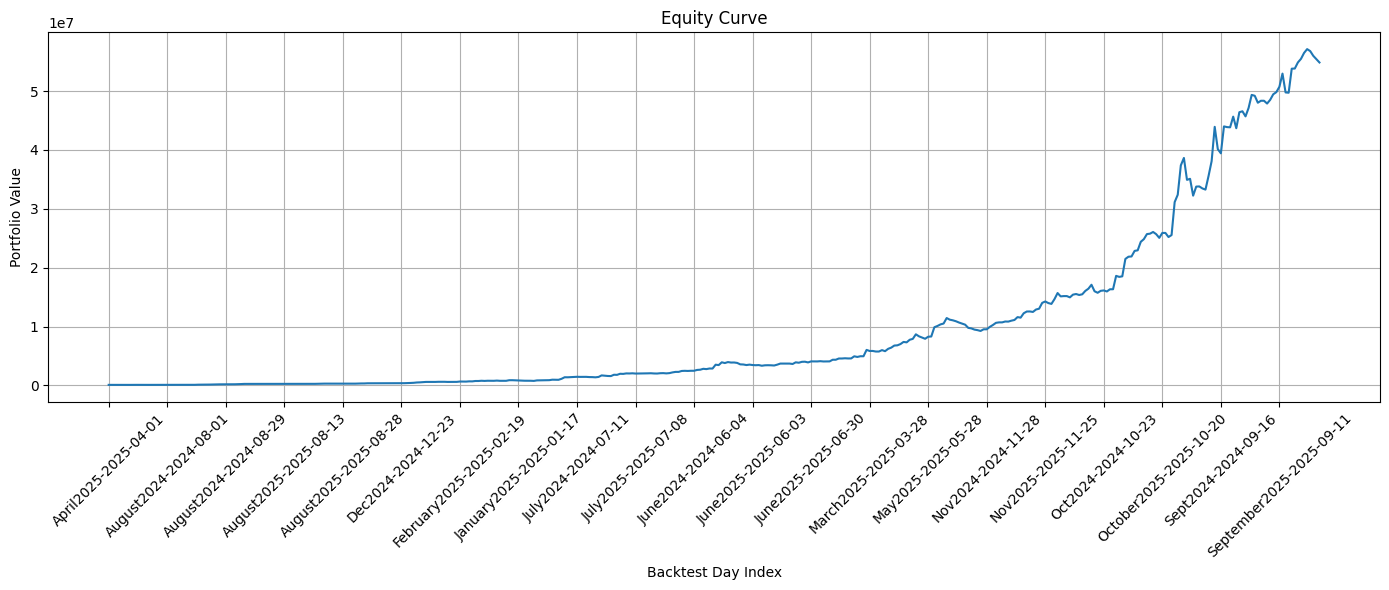

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from collections import defaultdict

# ============================================================
# ====================== CONFIG ==============================
# ============================================================

months = ["June2024","July2024","August2024","Sept2024","Oct2024","Nov2024","Dec2024","January2025","February2025","March2025","April2025","May2025","June2025","July2025","August2025","September2025","October2025","Nov2025"]
base_root = "/content/drive/MyDrive/kite_1min_data"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))


# ============================================================
# ========== DATA LOADING + 5 MIN RESAMPLE ===================
# ============================================================

def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]

    required = {'date','open','high','low','close','volume'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5 = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5


# ============================================================
# ========================= STRATEGY =========================
# ============================================================

def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():

        if row.name.time() >= exit_cutoff:  # Exit at 15:15
            final_price = row['close']
            return row.name, final_price, ((final_price-entry_price)/entry_price)*100, "15:15 Exit"

        if row['low'] <= sl:  # SL hit
            return row.name, sl, ((sl-entry_price)/entry_price)*100, "SL Hit"

    # End-of-day exit
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price-entry_price)/entry_price)*100, "End of Day Exit"


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(len(df)-window_size-6):

        range_df = df.iloc[i:i+window_size]
        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_vol = range_df['volume'].mean()

        if r_width < max_range_pct:

            breakout = df.iloc[i+window_size]

            if breakout.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout['close'] - breakout['open']
            upper_wick = breakout['high'] - breakout['close']
            body_pct = body / breakout['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout['close'] > breakout['open'] and
                breakout['high'] > r_high and
                body_pct >= min_body_pct and
                breakout['volume'] > volume_multiplier * mean_vol
            ):
                target = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target:

                        entry_price = target
                        sl = entry_price * 0.99
                        remain = candles_after.iloc[j+1:]

                        if len(remain)==0:
                            break

                        exit_time, exit_price, pnl, reason = simulate_exit(entry_price, sl, remain)

                        trades.append({
                            "date": date,
                            "symbol": symbol,
                            "entry_time": row.name,
                            "entry_price": round(entry_price,2),
                            "exit_time": exit_time,
                            "exit_price": round(exit_price,2),
                            "pnl_%": round(pnl,2),
                            "reason": reason
                        })
                        return trades

    return trades


# ============================================================
# ===================== RUN STRATEGY =========================
# ============================================================

portfolio_value = 100000
date_to_returns = {}
monthly_returns = defaultdict(float)

for month in months:

    month_path = os.path.join(base_root, month)
    if not os.path.isdir(month_path):
        print("❌ Missing:", month)
        continue

    print(f"\n=========== Running: {month} ===========")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            df = load_and_resample_5min(os.path.join(date_path,file))
            if df.empty:
                continue

            trades = dynamic_range_breakout(df, file.replace(".csv",""), date_folder)
            daily_trades.extend(trades)

        # Compute daily PnL %
        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
        else:
            day_return = 0

        # Update portfolio
        portfolio_value *= (1 + day_return/100)

        key = f"{month}-{date_folder}"
        date_to_returns[key] = day_return
        monthly_returns[month] += day_return

        print(f"📅 {key} — Return: {day_return:.2f}%")


# ============================================================
# ===================== PERFORMANCE ANALYSIS =================
# ============================================================

def count_trading_days(month_list, base):
    total = 0
    for m in month_list:
        path = os.path.join(base, m)
        if not os.path.isdir(path):
            continue

        days = [
            f for f in os.listdir(path)
            if os.path.isdir(os.path.join(path,f))
        ]
        total += len(days)
    return total

# Build equity curve
equity = []
cap = 100000
labels = []

for d in sorted(date_to_returns.keys()):
    cap *= (1 + date_to_returns[d]/100)
    labels.append(d)
    equity.append(cap)

eq = pd.DataFrame({
    "index": range(len(equity)),
    "label": labels,
    "equity": equity
})

# Drawdown
eq["peak"] = eq["equity"].cummax()
eq["drawdown"] = (eq["equity"] - eq["peak"]) / eq["peak"] * 100
max_dd = eq["drawdown"].min()

# CAGR based on folder count
days = count_trading_days(months, base_root)
years = days / 252 if days > 0 else 1

CAGR = ((equity[-1] / equity[0])**(1/years) - 1) * 100

# Print Summary
print("\n========== ANALYTICS ==========")
print("Trading Days:", days)
print("CAGR:", round(CAGR,2), "%")
print("Max Drawdown:", round(max_dd,2), "%")
print("Final Portfolio:", round(equity[-1],2))
print("================================")


# ============================================================
# ======================= EQUITY PLOT ========================
# ============================================================

plt.figure(figsize=(14,6))
plt.plot(eq["index"], eq["equity"])
plt.title("Equity Curve")
plt.xlabel("Backtest Day Index")
plt.ylabel("Portfolio Value")
plt.grid(True)

# Simplify x-axis labels
step = max(1, len(eq)//20)
plt.xticks(eq["index"][::step], eq["label"][::step], rotation=45)

plt.tight_layout()
plt.show()



===== Monthly Performance Metrics =====
            Month  Monthly Return (%)  Average Daily Return (%)  \
0        June2024               38.07                  2.003684   
1        July2024               76.72                  3.487273   
2      August2024               71.60                  3.409524   
3        Sept2024               38.16                  1.817143   
4         Oct2024               25.10                  1.140909   
5         Nov2024                1.45                  0.080556   
6         Dec2024               55.63                  2.649048   
7     January2025               19.08                  0.829565   
8    February2025               42.47                  2.123500   
9       March2025               38.83                  2.043684   
10      April2025               -2.48                 -0.130526   
11        May2025               55.61                  2.648095   
12       June2025               17.38                  0.827619   
13       July2025    

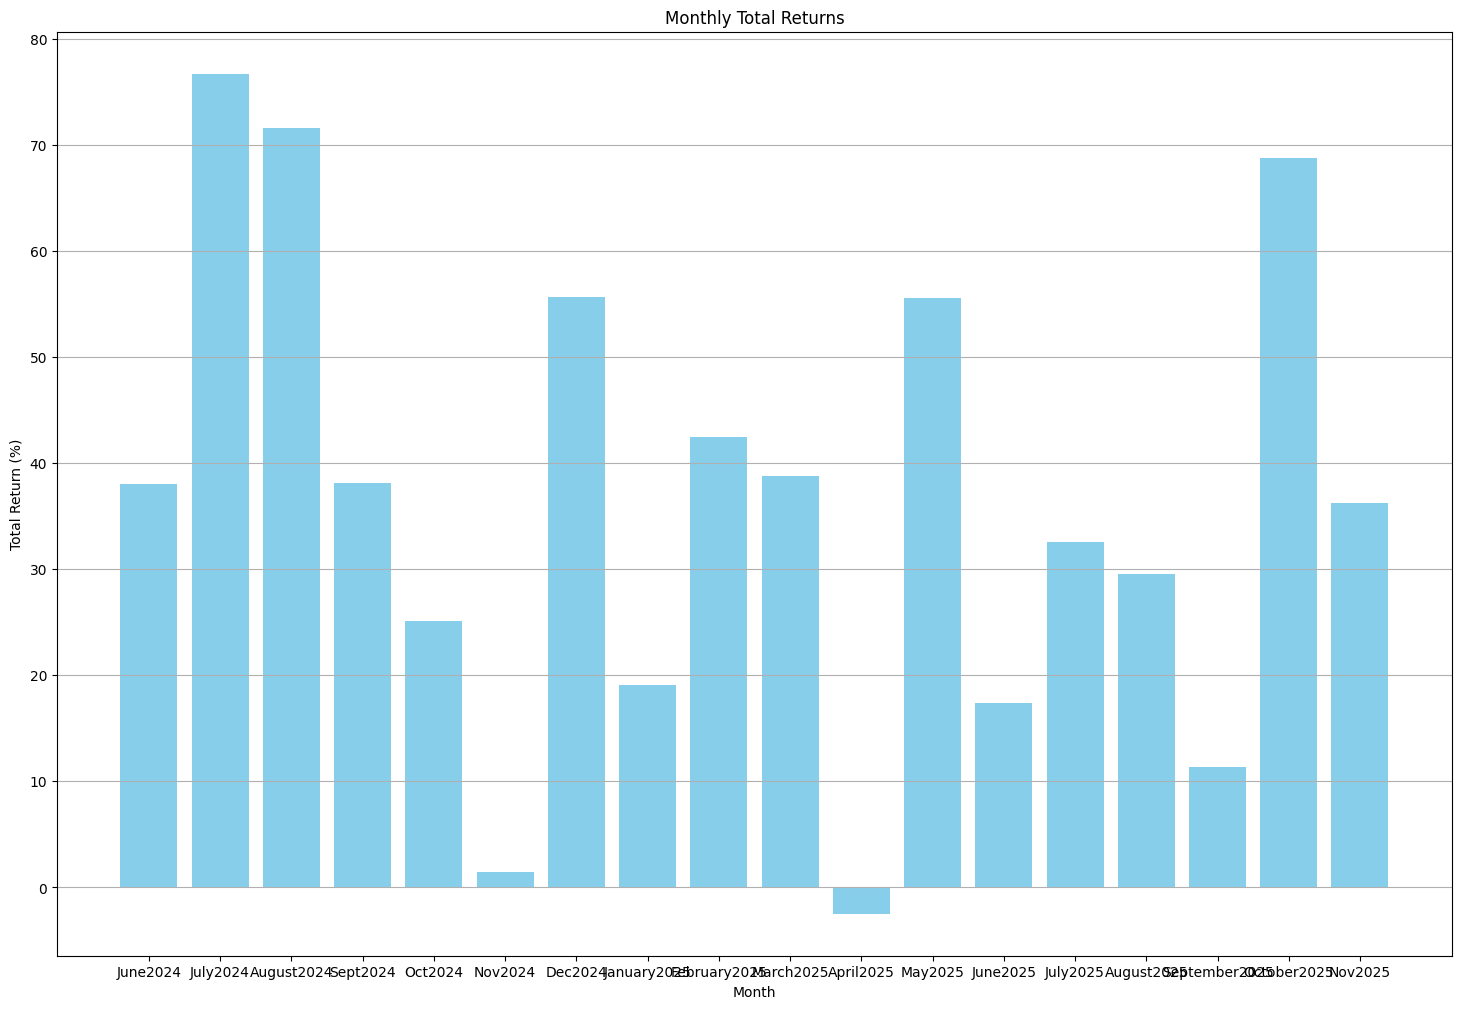

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== PASTE YOUR OUTPUT HERE ======
raw_text = """
=========== Running: June2024 ===========
📅 June2024-2024-06-03 — Return: 1.18%
📅 June2024-2024-06-04 — Return: 0.00%
📅 June2024-2024-06-05 — Return: 5.74%
📅 June2024-2024-06-06 — Return: 1.43%
📅 June2024-2024-06-07 — Return: 5.75%
📅 June2024-2024-06-10 — Return: -1.81%
📅 June2024-2024-06-11 — Return: 3.67%
📅 June2024-2024-06-12 — Return: -0.31%
📅 June2024-2024-06-13 — Return: 22.81%
📅 June2024-2024-06-14 — Return: -1.76%
📅 June2024-2024-06-18 — Return: 13.54%
📅 June2024-2024-06-19 — Return: -3.15%
📅 June2024-2024-06-20 — Return: 4.31%
📅 June2024-2024-06-21 — Return: -1.99%
📅 June2024-2024-06-24 — Return: 0.22%
📅 June2024-2024-06-25 — Return: -1.85%
📅 June2024-2024-06-26 — Return: -6.40%
📅 June2024-2024-06-27 — Return: -0.64%
📅 June2024-2024-06-28 — Return: -2.67%

=========== Running: July2024 ===========
📅 July2024-2024-07-01 — Return: 9.02%
📅 July2024-2024-07-02 — Return: -1.17%
📅 July2024-2024-07-03 — Return: -0.77%
📅 July2024-2024-07-04 — Return: 17.98%
📅 July2024-2024-07-05 — Return: 23.25%
📅 July2024-2024-07-08 — Return: -0.53%
📅 July2024-2024-07-09 — Return: 2.09%
📅 July2024-2024-07-10 — Return: 0.89%
📅 July2024-2024-07-11 — Return: 2.95%
📅 July2024-2024-07-12 — Return: -1.07%
📅 July2024-2024-07-15 — Return: 0.29%
📅 July2024-2024-07-16 — Return: 0.13%
📅 July2024-2024-07-18 — Return: -2.50%
📅 July2024-2024-07-19 — Return: -0.58%
📅 July2024-2024-07-22 — Return: -2.32%
📅 July2024-2024-07-23 — Return: 4.56%
📅 July2024-2024-07-24 — Return: 18.09%
📅 July2024-2024-07-25 — Return: -3.01%
📅 July2024-2024-07-26 — Return: -2.79%
📅 July2024-2024-07-29 — Return: -1.15%
📅 July2024-2024-07-30 — Return: 14.27%
📅 July2024-2024-07-31 — Return: -0.91%

=========== Running: August2024 ===========
📅 August2024-2024-08-01 — Return: -1.00%
📅 August2024-2024-08-02 — Return: 4.01%
📅 August2024-2024-08-05 — Return: 0.34%
📅 August2024-2024-08-06 — Return: 0.00%
📅 August2024-2024-08-07 — Return: 3.63%
📅 August2024-2024-08-08 — Return: 1.68%
📅 August2024-2024-08-09 — Return: -2.36%
📅 August2024-2024-08-12 — Return: 4.93%
📅 August2024-2024-08-13 — Return: -1.00%
📅 August2024-2024-08-14 — Return: 0.26%
📅 August2024-2024-08-16 — Return: 20.68%
📅 August2024-2024-08-19 — Return: 1.53%
📅 August2024-2024-08-20 — Return: 5.89%
📅 August2024-2024-08-21 — Return: 8.64%
📅 August2024-2024-08-22 — Return: -0.03%
📅 August2024-2024-08-23 — Return: 10.10%
📅 August2024-2024-08-26 — Return: 4.68%
📅 August2024-2024-08-27 — Return: 7.82%
📅 August2024-2024-08-28 — Return: 0.15%
📅 August2024-2024-08-29 — Return: -2.00%
📅 August2024-2024-08-30 — Return: 3.65%

=========== Running: Sept2024 ===========
📅 Sept2024-2024-09-02 — Return: 0.51%
📅 Sept2024-2024-09-03 — Return: -8.15%
📅 Sept2024-2024-09-04 — Return: 4.77%
📅 Sept2024-2024-09-05 — Return: 0.08%
📅 Sept2024-2024-09-06 — Return: -1.00%
📅 Sept2024-2024-09-09 — Return: -0.60%
📅 Sept2024-2024-09-10 — Return: 6.96%
📅 Sept2024-2024-09-11 — Return: 7.09%
📅 Sept2024-2024-09-12 — Return: 15.29%
📅 Sept2024-2024-09-13 — Return: -8.61%
📅 Sept2024-2024-09-16 — Return: -1.79%
📅 Sept2024-2024-09-17 — Return: 11.60%
📅 Sept2024-2024-09-18 — Return: -0.27%
📅 Sept2024-2024-09-19 — Return: -0.08%
📅 Sept2024-2024-09-20 — Return: 4.13%
📅 Sept2024-2024-09-23 — Return: -4.31%
📅 Sept2024-2024-09-24 — Return: 6.22%
📅 Sept2024-2024-09-25 — Return: 0.35%
📅 Sept2024-2024-09-26 — Return: -1.86%
📅 Sept2024-2024-09-27 — Return: 3.14%
📅 Sept2024-2024-09-30 — Return: 4.69%

=========== Running: Oct2024 ===========
📅 Oct2024-2024-10-01 — Return: 6.99%
📅 Oct2024-2024-10-03 — Return: -3.61%
📅 Oct2024-2024-10-04 — Return: 0.32%
📅 Oct2024-2024-10-07 — Return: 0.00%
📅 Oct2024-2024-10-08 — Return: -1.42%
📅 Oct2024-2024-10-09 — Return: 3.09%
📅 Oct2024-2024-10-10 — Return: 0.68%
📅 Oct2024-2024-10-11 — Return: -1.05%
📅 Oct2024-2024-10-14 — Return: 0.74%
📅 Oct2024-2024-10-15 — Return: 3.72%
📅 Oct2024-2024-10-16 — Return: 2.35%
📅 Oct2024-2024-10-17 — Return: 4.07%
📅 Oct2024-2024-10-18 — Return: -6.46%
📅 Oct2024-2024-10-21 — Return: -1.60%
📅 Oct2024-2024-10-22 — Return: 2.10%
📅 Oct2024-2024-10-23 — Return: 0.40%
📅 Oct2024-2024-10-24 — Return: -1.08%
📅 Oct2024-2024-10-25 — Return: 2.33%
📅 Oct2024-2024-10-28 — Return: 0.04%
📅 Oct2024-2024-10-29 — Return: 13.90%
📅 Oct2024-2024-10-30 — Return: -0.91%
📅 Oct2024-2024-10-31 — Return: 0.50%

=========== Running: Nov2024 ===========
📅 Nov2024-2024-11-04 — Return: 2.15%
📅 Nov2024-2024-11-05 — Return: 2.67%
📅 Nov2024-2024-11-06 — Return: 1.42%
📅 Nov2024-2024-11-07 — Return: 8.85%
📅 Nov2024-2024-11-08 — Return: -2.39%
📅 Nov2024-2024-11-11 — Return: -1.00%
📅 Nov2024-2024-11-12 — Return: -1.43%
📅 Nov2024-2024-11-13 — Return: -2.00%
📅 Nov2024-2024-11-14 — Return: -1.69%
📅 Nov2024-2024-11-18 — Return: -1.75%
📅 Nov2024-2024-11-19 — Return: -5.21%
📅 Nov2024-2024-11-21 — Return: -0.95%
📅 Nov2024-2024-11-22 — Return: -2.08%
📅 Nov2024-2024-11-25 — Return: -1.00%
📅 Nov2024-2024-11-26 — Return: -1.48%
📅 Nov2024-2024-11-27 — Return: 3.07%
📅 Nov2024-2024-11-28 — Return: -0.04%
📅 Nov2024-2024-11-29 — Return: 4.31%

=========== Running: Dec2024 ===========
📅 Dec2024-2024-12-02 — Return: 4.18%
📅 Dec2024-2024-12-03 — Return: 8.21%
📅 Dec2024-2024-12-04 — Return: 1.98%
📅 Dec2024-2024-12-05 — Return: 0.91%
📅 Dec2024-2024-12-06 — Return: 7.22%
📅 Dec2024-2024-12-09 — Return: -0.03%
📅 Dec2024-2024-12-10 — Return: -0.23%
📅 Dec2024-2024-12-11 — Return: 0.26%
📅 Dec2024-2024-12-12 — Return: -0.57%
📅 Dec2024-2024-12-13 — Return: -0.05%
📅 Dec2024-2024-12-16 — Return: 3.50%
📅 Dec2024-2024-12-17 — Return: 0.00%
📅 Dec2024-2024-12-18 — Return: -2.08%
📅 Dec2024-2024-12-19 — Return: -1.42%
📅 Dec2024-2024-12-20 — Return: 0.00%
📅 Dec2024-2024-12-23 — Return: 0.90%
📅 Dec2024-2024-12-24 — Return: 4.59%
📅 Dec2024-2024-12-26 — Return: 4.16%
📅 Dec2024-2024-12-27 — Return: 6.02%
📅 Dec2024-2024-12-30 — Return: 6.42%
📅 Dec2024-2024-12-31 — Return: 11.66%

=========== Running: January2025 ===========
📅 January2025-2025-01-01 — Return: 5.16%
📅 January2025-2025-01-02 — Return: -3.25%
📅 January2025-2025-01-03 — Return: 3.68%
📅 January2025-2025-01-06 — Return: 0.00%
📅 January2025-2025-01-07 — Return: -1.23%
📅 January2025-2025-01-08 — Return: 4.61%
📅 January2025-2025-01-09 — Return: -4.43%
📅 January2025-2025-01-10 — Return: 0.00%
📅 January2025-2025-01-13 — Return: 0.00%
📅 January2025-2025-01-14 — Return: 12.68%
📅 January2025-2025-01-15 — Return: 0.37%
📅 January2025-2025-01-16 — Return: -2.68%
📅 January2025-2025-01-17 — Return: -4.29%
📅 January2025-2025-01-20 — Return: -3.43%
📅 January2025-2025-01-21 — Return: 0.06%
📅 January2025-2025-01-22 — Return: 0.00%
📅 January2025-2025-01-23 — Return: -0.77%
📅 January2025-2025-01-24 — Return: -3.00%
📅 January2025-2025-01-27 — Return: 11.03%
📅 January2025-2025-01-28 — Return: 0.83%
📅 January2025-2025-01-29 — Return: 2.00%
📅 January2025-2025-01-30 — Return: -2.35%
📅 January2025-2025-01-31 — Return: 4.09%

=========== Running: February2025 ===========
📅 February2025-2025-02-01 — Return: 4.13%
📅 February2025-2025-02-03 — Return: 8.28%
📅 February2025-2025-02-04 — Return: 5.52%
📅 February2025-2025-02-05 — Return: -0.91%
📅 February2025-2025-02-06 — Return: 0.59%
📅 February2025-2025-02-07 — Return: 0.23%
📅 February2025-2025-02-10 — Return: 3.50%
📅 February2025-2025-02-11 — Return: 0.00%
📅 February2025-2025-02-12 — Return: 0.16%
📅 February2025-2025-02-13 — Return: -3.57%
📅 February2025-2025-02-14 — Return: 0.00%
📅 February2025-2025-02-17 — Return: 1.63%
📅 February2025-2025-02-18 — Return: -0.25%
📅 February2025-2025-02-19 — Return: 9.69%
📅 February2025-2025-02-20 — Return: -1.58%
📅 February2025-2025-02-21 — Return: 0.00%
📅 February2025-2025-02-24 — Return: 6.39%
📅 February2025-2025-02-25 — Return: -1.00%
📅 February2025-2025-02-27 — Return: 9.49%
📅 February2025-2025-02-28 — Return: 0.17%

=========== Running: March2025 ===========
📅 March2025-2025-03-03 — Return: 0.00%
📅 March2025-2025-03-04 — Return: -0.13%
📅 March2025-2025-03-05 — Return: 1.02%
📅 March2025-2025-03-06 — Return: -1.20%
📅 March2025-2025-03-07 — Return: 0.35%
📅 March2025-2025-03-10 — Return: 0.00%
📅 March2025-2025-03-11 — Return: 6.86%
📅 March2025-2025-03-12 — Return: 0.00%
📅 March2025-2025-03-13 — Return: 4.82%
📅 March2025-2025-03-17 — Return: 0.00%
📅 March2025-2025-03-18 — Return: 0.86%
📅 March2025-2025-03-19 — Return: -0.67%
📅 March2025-2025-03-20 — Return: 0.10%
📅 March2025-2025-03-21 — Return: 7.88%
📅 March2025-2025-03-24 — Return: -2.22%
📅 March2025-2025-03-25 — Return: 2.44%
📅 March2025-2025-03-26 — Return: 0.00%
📅 March2025-2025-03-27 — Return: 21.72%
📅 March2025-2025-03-28 — Return: -3.00%

=========== Running: April2025 ===========
📅 April2025-2025-04-01 — Return: -2.17%
📅 April2025-2025-04-02 — Return: -2.33%
📅 April2025-2025-04-03 — Return: 3.99%
📅 April2025-2025-04-04 — Return: -1.00%
📅 April2025-2025-04-07 — Return: 2.45%
📅 April2025-2025-04-08 — Return: -2.49%
📅 April2025-2025-04-09 — Return: -0.01%
📅 April2025-2025-04-11 — Return: -3.59%
📅 April2025-2025-04-15 — Return: 8.14%
📅 April2025-2025-04-16 — Return: -1.67%
📅 April2025-2025-04-17 — Return: -5.24%
📅 April2025-2025-04-21 — Return: -2.74%
📅 April2025-2025-04-22 — Return: -2.07%
📅 April2025-2025-04-23 — Return: 6.59%
📅 April2025-2025-04-24 — Return: 2.48%
📅 April2025-2025-04-25 — Return: 1.69%
📅 April2025-2025-04-28 — Return: -2.87%
📅 April2025-2025-04-29 — Return: 0.36%
📅 April2025-2025-04-30 — Return: -2.00%

=========== Running: May2025 ===========
📅 May2025-2025-05-02 — Return: 0.06%
📅 May2025-2025-05-05 — Return: -1.67%
📅 May2025-2025-05-06 — Return: 0.00%
📅 May2025-2025-05-07 — Return: 4.15%
📅 May2025-2025-05-08 — Return: -3.00%
📅 May2025-2025-05-09 — Return: 6.85%
📅 May2025-2025-05-12 — Return: 3.26%
📅 May2025-2025-05-13 — Return: 5.50%
📅 May2025-2025-05-14 — Return: 0.59%
📅 May2025-2025-05-15 — Return: 3.14%
📅 May2025-2025-05-16 — Return: 5.16%
📅 May2025-2025-05-19 — Return: -1.00%
📅 May2025-2025-05-20 — Return: 6.05%
📅 May2025-2025-05-21 — Return: 1.92%
📅 May2025-2025-05-22 — Return: 9.81%
📅 May2025-2025-05-23 — Return: -3.92%
📅 May2025-2025-05-26 — Return: -2.44%
📅 May2025-2025-05-27 — Return: -2.61%
📅 May2025-2025-05-28 — Return: 4.36%
📅 May2025-2025-05-29 — Return: 0.50%
📅 May2025-2025-05-30 — Return: 18.90%

=========== Running: June2025 ===========
📅 June2025-2025-06-02 — Return: 2.10%
📅 June2025-2025-06-03 — Return: -1.99%
📅 June2025-2025-06-04 — Return: -0.88%
📅 June2025-2025-06-05 — Return: 0.76%
📅 June2025-2025-06-06 — Return: -3.31%
📅 June2025-2025-06-09 — Return: 2.22%
📅 June2025-2025-06-10 — Return: 0.41%
📅 June2025-2025-06-11 — Return: -0.43%
📅 June2025-2025-06-12 — Return: -1.00%
📅 June2025-2025-06-13 — Return: 4.31%
📅 June2025-2025-06-16 — Return: 5.17%
📅 June2025-2025-06-17 — Return: 0.00%
📅 June2025-2025-06-18 — Return: -0.02%
📅 June2025-2025-06-19 — Return: 0.00%
📅 June2025-2025-06-20 — Return: -1.83%
📅 June2025-2025-06-23 — Return: 7.68%
📅 June2025-2025-06-24 — Return: -1.72%
📅 June2025-2025-06-25 — Return: 3.95%
📅 June2025-2025-06-26 — Return: 0.53%
📅 June2025-2025-06-27 — Return: -3.00%
📅 June2025-2025-06-30 — Return: 4.43%

=========== Running: July2025 ===========
📅 July2025-2025-07-01 — Return: 10.19%
📅 July2025-2025-07-02 — Return: -1.04%
📅 July2025-2025-07-03 — Return: 4.13%
📅 July2025-2025-07-04 — Return: -0.50%
📅 July2025-2025-07-07 — Return: 1.40%
📅 July2025-2025-07-08 — Return: -2.06%
📅 July2025-2025-07-09 — Return: 0.26%
📅 July2025-2025-07-10 — Return: -0.58%
📅 July2025-2025-07-11 — Return: 0.50%
📅 July2025-2025-07-14 — Return: 1.60%
📅 July2025-2025-07-15 — Return: 0.83%
📅 July2025-2025-07-16 — Return: -1.81%
📅 July2025-2025-07-17 — Return: -0.60%
📅 July2025-2025-07-18 — Return: 2.66%
📅 July2025-2025-07-21 — Return: 0.74%
📅 July2025-2025-07-22 — Return: -2.06%
📅 July2025-2025-07-23 — Return: 2.16%
📅 July2025-2025-07-24 — Return: 5.83%
📅 July2025-2025-07-25 — Return: 3.95%
📅 July2025-2025-07-28 — Return: 0.00%
📅 July2025-2025-07-29 — Return: 6.88%
📅 July2025-2025-07-30 — Return: 0.92%
📅 July2025-2025-07-31 — Return: -0.83%

=========== Running: August2025 ===========

📅 August2025-2025-08-01 — Return: 5.96%
📅 August2025-2025-08-04 — Return: 10.84%
📅 August2025-2025-08-05 — Return: 0.12%
📅 August2025-2025-08-06 — Return: -0.08%
📅 August2025-2025-08-07 — Return: -0.14%
📅 August2025-2025-08-08 — Return: 1.79%
📅 August2025-2025-08-11 — Return: -1.13%
📅 August2025-2025-08-12 — Return: -2.63%
📅 August2025-2025-08-13 — Return: -2.77%
📅 August2025-2025-08-14 — Return: 2.35%
📅 August2025-2025-08-15 — Return: 0.00%
📅 August2025-2025-08-18 — Return: 5.44%
📅 August2025-2025-08-19 — Return: 5.79%
📅 August2025-2025-08-20 — Return: -4.10%
📅 August2025-2025-08-21 — Return: 6.62%
📅 August2025-2025-08-22 — Return: 6.55%
📅 August2025-2025-08-25 — Return: 3.32%
📅 August2025-2025-08-26 — Return: -6.53%
📅 August2025-2025-08-27 — Return: 0.00%
📅 August2025-2025-08-28 — Return: 0.00%
📅 August2025-2025-08-29 — Return: -1.84%

=========== Running: September2025 ===========
📅 September2025-2025-09-01 — Return: -0.30%
📅 September2025-2025-09-02 — Return: -2.40%
📅 September2025-2025-09-03 — Return: 0.70%
📅 September2025-2025-09-04 — Return: 0.00%
📅 September2025-2025-09-05 — Return: -0.98%
📅 September2025-2025-09-08 — Return: 1.31%
📅 September2025-2025-09-09 — Return: 1.95%
📅 September2025-2025-09-10 — Return: 0.73%
📅 September2025-2025-09-11 — Return: 1.84%
📅 September2025-2025-09-12 — Return: 4.41%
📅 September2025-2025-09-15 — Return: -6.04%
📅 September2025-2025-09-16 — Return: -0.10%
📅 September2025-2025-09-17 — Return: 8.21%
📅 September2025-2025-09-18 — Return: 0.05%
📅 September2025-2025-09-19 — Return: 1.92%
📅 September2025-2025-09-22 — Return: 1.11%
📅 September2025-2025-09-23 — Return: 1.81%
📅 September2025-2025-09-24 — Return: 1.15%
📅 September2025-2025-09-25 — Return: -0.59%
📅 September2025-2025-09-26 — Return: -1.42%
📅 September2025-2025-09-29 — Return: -1.02%
📅 September2025-2025-09-30 — Return: -1.00%

=========== Running: October2025 ===========
📅 October2025-2025-10-01 — Return: 15.94%
📅 October2025-2025-10-03 — Return: 1.75%
📅 October2025-2025-10-06 — Return: 0.21%
📅 October2025-2025-10-07 — Return: 4.31%
📅 October2025-2025-10-08 — Return: 0.43%
📅 October2025-2025-10-09 — Return: 6.29%
📅 October2025-2025-10-10 — Return: 1.85%
📅 October2025-2025-10-13 — Return: 3.47%
📅 October2025-2025-10-14 — Return: 0.27%
📅 October2025-2025-10-15 — Return: 1.12%
📅 October2025-2025-10-16 — Return: -1.42%
📅 October2025-2025-10-17 — Return: -2.44%
📅 October2025-2025-10-20 — Return: 3.33%
📅 October2025-2025-10-21 — Return: 0.00%
📅 October2025-2025-10-23 — Return: -2.69%
📅 October2025-2025-10-24 — Return: 1.32%
📅 October2025-2025-10-27 — Return: 21.92%
📅 October2025-2025-10-28 — Return: 4.02%
📅 October2025-2025-10-29 — Return: 15.39%
📅 October2025-2025-10-30 — Return: 3.38%
📅 October2025-2025-10-31 — Return: -9.63%

=========== Running: Nov2025 ===========
📅 Nov2025-2025-11-03 — Return: 3.20%
📅 Nov2025-2025-11-04 — Return: 0.73%
📅 Nov2025-2025-11-06 — Return: 1.37%
📅 Nov2025-2025-11-07 — Return: -0.14%
📅 Nov2025-2025-11-10 — Return: 1.44%
📅 Nov2025-2025-11-11 — Return: 1.08%
📅 Nov2025-2025-11-12 — Return: 4.40%
📅 Nov2025-2025-11-13 — Return: -0.81%
📅 Nov2025-2025-11-14 — Return: 6.45%
📅 Nov2025-2025-11-17 — Return: 2.45%
📅 Nov2025-2025-11-18 — Return: 0.07%
📅 Nov2025-2025-11-19 — Return: -0.64%
📅 Nov2025-2025-11-20 — Return: 3.30%
📅 Nov2025-2025-11-21 — Return: 1.06%
📅 Nov2025-2025-11-24 — Return: 7.58%
📅 Nov2025-2025-11-25 — Return: 1.73%
📅 Nov2025-2025-11-26 — Return: -1.92%
📅 Nov2025-2025-11-27 — Return: -1.01%
📅 Nov2025-2025-11-28 — Return: 5.92%
"""

# ====== PARSE MONTHS + RETURNS ======
pattern = r"Running:\s+(\w+\d{4}).*?((?:(?:📅.*?Return:.*?%\n?)+))"
month_blocks = re.findall(pattern, raw_text, flags=re.DOTALL)

data = []

for month, block in month_blocks:
    returns = re.findall(r"Return:\s*([-+]?\d+\.\d+)%", block)
    returns = list(map(float, returns))
    for r in returns:
        data.append([month, r])

df = pd.DataFrame(data, columns=["Month", "Return"])

# ====== CALCULATE MONTHLY METRICS ======
monthly_metrics = []

for month in df["Month"].unique():
    subset = df[df["Month"] == month]["Return"]
    cumulative = (1 + subset / 100).cumprod() - 1  # cumulative growth
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak * 100 if peak.max() != 0 else 0
    max_dd = drawdown.min()

    negative_returns = subset[subset < 0]
    downside_std = negative_returns.std() if len(negative_returns) > 0 else np.nan
    sortino = subset.mean() / downside_std if downside_std and downside_std != 0 else np.nan

    monthly_metrics.append({
        "Month": month,
        "Monthly Return (%)": subset.sum(),
        "Average Daily Return (%)": subset.mean(),
        "Max Daily Return (%)": subset.max(),
        "Worst Daily Return (%)": subset.min(),
        "Max Drawdown (%)": max_dd,
        "Sortino Ratio": sortino
    })

metrics_df = pd.DataFrame(monthly_metrics)
print("\n===== Monthly Performance Metrics =====")
print(metrics_df)

# ====== PLOT MONTHLY RETURN HISTOGRAM ======
plt.figure(figsize=(18,12))
plt.bar(metrics_df["Month"], metrics_df["Monthly Return (%)"], color='skyblue')
plt.title("Monthly Total Returns")
plt.xlabel("Month")
plt.ylabel("Total Return (%)")
plt.grid(axis='y')
plt.show()


**FOR EMA**

In [ ]:
# EMA FOR MONTHS

### trying ema

import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===

months = ["June2024","July2024","August2024","Sept2024","Oct2024","Nov2024",
          "Dec2024","January2025","February2025","March2025","April2025",
          "May2025","June2025","July2025","August2025","September2025",
          "October2025","Nov2025"]

base_root = "/content/drive/MyDrive/kite_1min_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === NEW: store count of date folders inside each month ===
month_folder_count = {}

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date', 'open', 'high', 'low', 'close', 'volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min


def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():
        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'


def dynamic_range_breakout(df, symbol, date):
    trades = []
    if df.empty or len(df) < window_size + 10:
        return trades

    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema50'] = df['close'].ewm(span=50, adjust=False).mean()

    if df['ema20'].iloc[-1] <= df['ema50'].iloc[-1]:
        return trades

    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width < max_range_pct:
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                continue

            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j in range(len(candles_after)):
                    row = candles_after.iloc[j]

                    if row.name.time() > pd.to_datetime("14:30").time():
                        break

                    if row['high'] >= target_entry_price:
                        entry_price = target_entry_price
                        sl = entry_price * 0.99

                        remaining_candles = candles_after.iloc[j + 1:]
                        if len(remaining_candles) == 0:
                            break

                        exit_time, exit_price, pnl_pct, reason = simulate_exit(
                            entry_price, sl, remaining_candles
                        )

                        trades.append({
                            'date': date,
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'pnl_%': round(pnl_pct, 2),
                            'reason': reason
                        })
                        return trades

    return trades


# === MAIN LOOP ===

portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    # NEW: COUNT DATE FOLDERS INSIDE EACH MONTH
    date_folders = [d for d in os.listdir(month_path)
                    if os.path.isdir(os.path.join(month_path, d))]
    month_folder_count[month] = len(date_folders)

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"📁 Date Folders Found: {month_folder_count[month]}")
    print(f"==============================")

    for date_folder in sorted(date_folders):
        date_path = os.path.join(month_path, date_folder)

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        date_key = f"{month}-{date_folder}"
        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY:")
for m in months:
    print(f"🗓️ {m}: Date Folders = {month_folder_count[m]}, Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# ==========================
# ===== ANALYTICS ==========
# ==========================

import matplotlib.pyplot as plt

equity = []
dates = []
capital = 100000

for d in sorted(date_to_returns.keys()):
    ret = date_to_returns[d]
    capital *= (1 + ret / 100)
    dates.append(d)
    equity.append(capital)

equity_df = pd.DataFrame({'date': dates, 'equity': equity})
equity_df['date'] = pd.to_datetime(equity_df['date'], errors='ignore')
equity_df = equity_df.sort_values('date').reset_index(drop=True)

equity_df['daily_return'] = equity_df['equity'].pct_change() * 100
equity_df['peak'] = equity_df['equity'].cummax()
equity_df['drawdown'] = (equity_df['equity'] - equity_df['peak']) / equity_df['peak'] * 100

max_dd = equity_df['drawdown'].min()

print("\n📉 MAX DRAWDOWN:", round(max_dd, 2), "%")

start_value = equity_df['equity'].iloc[0]
end_value   = equity_df['equity'].iloc[-1]
num_days    = (equity_df['date'].iloc[-1] - equity_df['date'].iloc[0]).days

years = num_days / 365
CAGR = ((end_value / start_value) ** (1 / years) - 1) * 100
print("🚀 CAGR:", round(CAGR, 2), "%")

volatility = equity_df['daily_return'].std() * np.sqrt(252)
print("⚡ Annualized Volatility:", round(volatility, 2), "%")

rf = 0
downside_returns = equity_df.loc[equity_df['daily_return'] < 0, 'daily_return']

if len(downside_returns) > 0:
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (CAGR - rf) / downside_std
else:
    sortino = np.nan

print("📈 Sortino Ratio:", round(sortino, 3))

rolling_sharpe = (
    equity_df['daily_return'].rolling(30).mean() /
    equity_df['daily_return'].rolling(30).std()
) * np.sqrt(252)

equity_df['rolling_sharpe'] = rolling_sharpe

# === PLOTS ===

plt.figure(figsize=(14,6))
plt.plot(equity_df['date'], equity_df['equity'], linewidth=2)
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Capital (₹)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(equity_df['date'], equity_df['drawdown'], linewidth=1.5)
plt.title("Drawdown Curve (%)")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(equity_df['date'], equity_df['rolling_sharpe'], linewidth=1.8)
plt.title("Rolling 30-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.grid(True)
plt.tight_layout()
plt.show()



📆 Running for Month: June2024
📁 Date Folders Found: 19
📅 June2024-2024-06-03 — Trades: 6, Return: 1.18%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 6, Return: 6.73%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 15, Return: 5.67%
📅 June2024-2024-06-12 — Trades: 9, Return: -0.31%
📅 June2024-2024-06-13 — Trades: 16, Return: 24.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 11, Return: 13.54%
📅 June2024-2024-06-19 — Trades: 3, Return: -1.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-24 — Trades: 6, Return: 0.22%
📅 June2024-2024-06-25 — Trades: 8, Return: -1.85%
📅 June2024-2024-06-26 — Trades: 6, Return: -5.40%
📅 June2024-2024-06-27 — Trades: 1, Return: 0.36%
📅 June2024-2024-06-28 — Trades: 6, Return: 0.33%

📆

/tmp/ipython-input-312990033.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  equity_df['date'] = pd.to_datetime(equity_df['date'], errors='ignore')
/tmp/ipython-input-312990033.py:236: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  equity_df['date'] = pd.to_datetime(equity_df['date'], errors='ignore')


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
import re
import pandas as pd

# Example raw texts
raw_text = """=========== Running: June2024 ===========
📅 June2024-2024-06-03 — Return: 1.18%
📅 June2024-2024-06-04 — Return: 0.00%
📅 June2024-2024-06-05 — Return: 5.74%
📅 June2024-2024-06-06 — Return: 1.43%
📅 June2024-2024-06-07 — Return: 5.75%
📅 June2024-2024-06-10 — Return: -1.81%
📅 June2024-2024-06-11 — Return: 3.67%
📅 June2024-2024-06-12 — Return: -0.31%
📅 June2024-2024-06-13 — Return: 22.81%
📅 June2024-2024-06-14 — Return: -1.76%
📅 June2024-2024-06-18 — Return: 13.54%
📅 June2024-2024-06-19 — Return: -3.15%
📅 June2024-2024-06-20 — Return: 4.31%
📅 June2024-2024-06-21 — Return: -1.99%
📅 June2024-2024-06-24 — Return: 0.22%
📅 June2024-2024-06-25 — Return: -1.85%
📅 June2024-2024-06-26 — Return: -6.40%
📅 June2024-2024-06-27 — Return: -0.64%
📅 June2024-2024-06-28 — Return: -2.67%

=========== Running: July2024 ===========
📅 July2024-2024-07-01 — Return: 9.02%
📅 July2024-2024-07-02 — Return: -1.17%
📅 July2024-2024-07-03 — Return: -0.77%
📅 July2024-2024-07-04 — Return: 17.98%
📅 July2024-2024-07-05 — Return: 23.25%
📅 July2024-2024-07-08 — Return: -0.53%
📅 July2024-2024-07-09 — Return: 2.09%
📅 July2024-2024-07-10 — Return: 0.89%
📅 July2024-2024-07-11 — Return: 2.95%
📅 July2024-2024-07-12 — Return: -1.07%
📅 July2024-2024-07-15 — Return: 0.29%
📅 July2024-2024-07-16 — Return: 0.13%
📅 July2024-2024-07-18 — Return: -2.50%
📅 July2024-2024-07-19 — Return: -0.58%
📅 July2024-2024-07-22 — Return: -2.32%
📅 July2024-2024-07-23 — Return: 4.56%
📅 July2024-2024-07-24 — Return: 18.09%
📅 July2024-2024-07-25 — Return: -3.01%
📅 July2024-2024-07-26 — Return: -2.79%
📅 July2024-2024-07-29 — Return: -1.15%
📅 July2024-2024-07-30 — Return: 14.27%
📅 July2024-2024-07-31 — Return: -0.91%

=========== Running: August2024 ===========
📅 August2024-2024-08-01 — Return: -1.00%
📅 August2024-2024-08-02 — Return: 4.01%
📅 August2024-2024-08-05 — Return: 0.34%
📅 August2024-2024-08-06 — Return: 0.00%
📅 August2024-2024-08-07 — Return: 3.63%
📅 August2024-2024-08-08 — Return: 1.68%
📅 August2024-2024-08-09 — Return: -2.36%
📅 August2024-2024-08-12 — Return: 4.93%
📅 August2024-2024-08-13 — Return: -1.00%
📅 August2024-2024-08-14 — Return: 0.26%
📅 August2024-2024-08-16 — Return: 20.68%
📅 August2024-2024-08-19 — Return: 1.53%
📅 August2024-2024-08-20 — Return: 5.89%
📅 August2024-2024-08-21 — Return: 8.64%
📅 August2024-2024-08-22 — Return: -0.03%
📅 August2024-2024-08-23 — Return: 10.10%
📅 August2024-2024-08-26 — Return: 4.68%
📅 August2024-2024-08-27 — Return: 7.82%
📅 August2024-2024-08-28 — Return: 0.15%
📅 August2024-2024-08-29 — Return: -2.00%
📅 August2024-2024-08-30 — Return: 3.65%

=========== Running: Sept2024 ===========
📅 Sept2024-2024-09-02 — Return: 0.51%
📅 Sept2024-2024-09-03 — Return: -8.15%
📅 Sept2024-2024-09-04 — Return: 4.77%
📅 Sept2024-2024-09-05 — Return: 0.08%
📅 Sept2024-2024-09-06 — Return: -1.00%
📅 Sept2024-2024-09-09 — Return: -0.60%
📅 Sept2024-2024-09-10 — Return: 6.96%
📅 Sept2024-2024-09-11 — Return: 7.09%
📅 Sept2024-2024-09-12 — Return: 15.29%
📅 Sept2024-2024-09-13 — Return: -8.61%
📅 Sept2024-2024-09-16 — Return: -1.79%
📅 Sept2024-2024-09-17 — Return: 11.60%
📅 Sept2024-2024-09-18 — Return: -0.27%
📅 Sept2024-2024-09-19 — Return: -0.08%
📅 Sept2024-2024-09-20 — Return: 4.13%
📅 Sept2024-2024-09-23 — Return: -4.31%
📅 Sept2024-2024-09-24 — Return: 6.22%
📅 Sept2024-2024-09-25 — Return: 0.35%
📅 Sept2024-2024-09-26 — Return: -1.86%
📅 Sept2024-2024-09-27 — Return: 3.14%
📅 Sept2024-2024-09-30 — Return: 4.69%

=========== Running: Oct2024 ===========
📅 Oct2024-2024-10-01 — Return: 6.99%
📅 Oct2024-2024-10-03 — Return: -3.61%
📅 Oct2024-2024-10-04 — Return: 0.32%
📅 Oct2024-2024-10-07 — Return: 0.00%
📅 Oct2024-2024-10-08 — Return: -1.42%
📅 Oct2024-2024-10-09 — Return: 3.09%
📅 Oct2024-2024-10-10 — Return: 0.68%
📅 Oct2024-2024-10-11 — Return: -1.05%
📅 Oct2024-2024-10-14 — Return: 0.74%
📅 Oct2024-2024-10-15 — Return: 3.72%
📅 Oct2024-2024-10-16 — Return: 2.35%
📅 Oct2024-2024-10-17 — Return: 4.07%
📅 Oct2024-2024-10-18 — Return: -6.46%
📅 Oct2024-2024-10-21 — Return: -1.60%
📅 Oct2024-2024-10-22 — Return: 2.10%
📅 Oct2024-2024-10-23 — Return: 0.40%
📅 Oct2024-2024-10-24 — Return: -1.08%
📅 Oct2024-2024-10-25 — Return: 2.33%
📅 Oct2024-2024-10-28 — Return: 0.04%
📅 Oct2024-2024-10-29 — Return: 13.90%
📅 Oct2024-2024-10-30 — Return: -0.91%
📅 Oct2024-2024-10-31 — Return: 0.50%

=========== Running: Nov2024 ===========
📅 Nov2024-2024-11-04 — Return: 2.15%
📅 Nov2024-2024-11-05 — Return: 2.67%
📅 Nov2024-2024-11-06 — Return: 1.42%
📅 Nov2024-2024-11-07 — Return: 8.85%
📅 Nov2024-2024-11-08 — Return: -2.39%
📅 Nov2024-2024-11-11 — Return: -1.00%
📅 Nov2024-2024-11-12 — Return: -1.43%
📅 Nov2024-2024-11-13 — Return: -2.00%
📅 Nov2024-2024-11-14 — Return: -1.69%
📅 Nov2024-2024-11-18 — Return: -1.75%
📅 Nov2024-2024-11-19 — Return: -5.21%
📅 Nov2024-2024-11-21 — Return: -0.95%
📅 Nov2024-2024-11-22 — Return: -2.08%
📅 Nov2024-2024-11-25 — Return: -1.00%
📅 Nov2024-2024-11-26 — Return: -1.48%
📅 Nov2024-2024-11-27 — Return: 3.07%
📅 Nov2024-2024-11-28 — Return: -0.04%
📅 Nov2024-2024-11-29 — Return: 4.31%

=========== Running: Dec2024 ===========
📅 Dec2024-2024-12-02 — Return: 4.18%
📅 Dec2024-2024-12-03 — Return: 8.21%
📅 Dec2024-2024-12-04 — Return: 1.98%
📅 Dec2024-2024-12-05 — Return: 0.91%
📅 Dec2024-2024-12-06 — Return: 7.22%
📅 Dec2024-2024-12-09 — Return: -0.03%
📅 Dec2024-2024-12-10 — Return: -0.23%
📅 Dec2024-2024-12-11 — Return: 0.26%
📅 Dec2024-2024-12-12 — Return: -0.57%
📅 Dec2024-2024-12-13 — Return: -0.05%
📅 Dec2024-2024-12-16 — Return: 3.50%
📅 Dec2024-2024-12-17 — Return: 0.00%
📅 Dec2024-2024-12-18 — Return: -2.08%
📅 Dec2024-2024-12-19 — Return: -1.42%
📅 Dec2024-2024-12-20 — Return: 0.00%
📅 Dec2024-2024-12-23 — Return: 0.90%
📅 Dec2024-2024-12-24 — Return: 4.59%
📅 Dec2024-2024-12-26 — Return: 4.16%
📅 Dec2024-2024-12-27 — Return: 6.02%
📅 Dec2024-2024-12-30 — Return: 6.42%
📅 Dec2024-2024-12-31 — Return: 11.66%

=========== Running: January2025 ===========
📅 January2025-2025-01-01 — Return: 5.16%
📅 January2025-2025-01-02 — Return: -3.25%
📅 January2025-2025-01-03 — Return: 3.68%
📅 January2025-2025-01-06 — Return: 0.00%
📅 January2025-2025-01-07 — Return: -1.23%
📅 January2025-2025-01-08 — Return: 4.61%
📅 January2025-2025-01-09 — Return: -4.43%
📅 January2025-2025-01-10 — Return: 0.00%
📅 January2025-2025-01-13 — Return: 0.00%
📅 January2025-2025-01-14 — Return: 12.68%
📅 January2025-2025-01-15 — Return: 0.37%
📅 January2025-2025-01-16 — Return: -2.68%
📅 January2025-2025-01-17 — Return: -4.29%
📅 January2025-2025-01-20 — Return: -3.43%
📅 January2025-2025-01-21 — Return: 0.06%
📅 January2025-2025-01-22 — Return: 0.00%
📅 January2025-2025-01-23 — Return: -0.77%
📅 January2025-2025-01-24 — Return: -3.00%
📅 January2025-2025-01-27 — Return: 11.03%
📅 January2025-2025-01-28 — Return: 0.83%
📅 January2025-2025-01-29 — Return: 2.00%
📅 January2025-2025-01-30 — Return: -2.35%
📅 January2025-2025-01-31 — Return: 4.09%

=========== Running: February2025 ===========
📅 February2025-2025-02-01 — Return: 4.13%
📅 February2025-2025-02-03 — Return: 8.28%
📅 February2025-2025-02-04 — Return: 5.52%
📅 February2025-2025-02-05 — Return: -0.91%
📅 February2025-2025-02-06 — Return: 0.59%
📅 February2025-2025-02-07 — Return: 0.23%
📅 February2025-2025-02-10 — Return: 3.50%
📅 February2025-2025-02-11 — Return: 0.00%
📅 February2025-2025-02-12 — Return: 0.16%
📅 February2025-2025-02-13 — Return: -3.57%
📅 February2025-2025-02-14 — Return: 0.00%
📅 February2025-2025-02-17 — Return: 1.63%
📅 February2025-2025-02-18 — Return: -0.25%
📅 February2025-2025-02-19 — Return: 9.69%
📅 February2025-2025-02-20 — Return: -1.58%
📅 February2025-2025-02-21 — Return: 0.00%
📅 February2025-2025-02-24 — Return: 6.39%
📅 February2025-2025-02-25 — Return: -1.00%
📅 February2025-2025-02-27 — Return: 9.49%
📅 February2025-2025-02-28 — Return: 0.17%

=========== Running: March2025 ===========
📅 March2025-2025-03-03 — Return: 0.00%
📅 March2025-2025-03-04 — Return: -0.13%
📅 March2025-2025-03-05 — Return: 1.02%
📅 March2025-2025-03-06 — Return: -1.20%
📅 March2025-2025-03-07 — Return: 0.35%
📅 March2025-2025-03-10 — Return: 0.00%
📅 March2025-2025-03-11 — Return: 6.86%
📅 March2025-2025-03-12 — Return: 0.00%
📅 March2025-2025-03-13 — Return: 4.82%
📅 March2025-2025-03-17 — Return: 0.00%
📅 March2025-2025-03-18 — Return: 0.86%
📅 March2025-2025-03-19 — Return: -0.67%
📅 March2025-2025-03-20 — Return: 0.10%
📅 March2025-2025-03-21 — Return: 7.88%
📅 March2025-2025-03-24 — Return: -2.22%
📅 March2025-2025-03-25 — Return: 2.44%
📅 March2025-2025-03-26 — Return: 0.00%
📅 March2025-2025-03-27 — Return: 21.72%
📅 March2025-2025-03-28 — Return: -3.00%

=========== Running: April2025 ===========
📅 April2025-2025-04-01 — Return: -2.17%
📅 April2025-2025-04-02 — Return: -2.33%
📅 April2025-2025-04-03 — Return: 3.99%
📅 April2025-2025-04-04 — Return: -1.00%
📅 April2025-2025-04-07 — Return: 2.45%
📅 April2025-2025-04-08 — Return: -2.49%
📅 April2025-2025-04-09 — Return: -0.01%
📅 April2025-2025-04-11 — Return: -3.59%
📅 April2025-2025-04-15 — Return: 8.14%
📅 April2025-2025-04-16 — Return: -1.67%
📅 April2025-2025-04-17 — Return: -5.24%
📅 April2025-2025-04-21 — Return: -2.74%
📅 April2025-2025-04-22 — Return: -2.07%
📅 April2025-2025-04-23 — Return: 6.59%
📅 April2025-2025-04-24 — Return: 2.48%
📅 April2025-2025-04-25 — Return: 1.69%
📅 April2025-2025-04-28 — Return: -2.87%
📅 April2025-2025-04-29 — Return: 0.36%
📅 April2025-2025-04-30 — Return: -2.00%

=========== Running: May2025 ===========
📅 May2025-2025-05-02 — Return: 0.06%
📅 May2025-2025-05-05 — Return: -1.67%
📅 May2025-2025-05-06 — Return: 0.00%
📅 May2025-2025-05-07 — Return: 4.15%
📅 May2025-2025-05-08 — Return: -3.00%
📅 May2025-2025-05-09 — Return: 6.85%
📅 May2025-2025-05-12 — Return: 3.26%
📅 May2025-2025-05-13 — Return: 5.50%
📅 May2025-2025-05-14 — Return: 0.59%
📅 May2025-2025-05-15 — Return: 3.14%
📅 May2025-2025-05-16 — Return: 5.16%
📅 May2025-2025-05-19 — Return: -1.00%
📅 May2025-2025-05-20 — Return: 6.05%
📅 May2025-2025-05-21 — Return: 1.92%
📅 May2025-2025-05-22 — Return: 9.81%
📅 May2025-2025-05-23 — Return: -3.92%
📅 May2025-2025-05-26 — Return: -2.44%
📅 May2025-2025-05-27 — Return: -2.61%
📅 May2025-2025-05-28 — Return: 4.36%
📅 May2025-2025-05-29 — Return: 0.50%
📅 May2025-2025-05-30 — Return: 18.90%

=========== Running: June2025 ===========
📅 June2025-2025-06-02 — Return: 2.10%
📅 June2025-2025-06-03 — Return: -1.99%
📅 June2025-2025-06-04 — Return: -0.88%
📅 June2025-2025-06-05 — Return: 0.76%
📅 June2025-2025-06-06 — Return: -3.31%
📅 June2025-2025-06-09 — Return: 2.22%
📅 June2025-2025-06-10 — Return: 0.41%
📅 June2025-2025-06-11 — Return: -0.43%
📅 June2025-2025-06-12 — Return: -1.00%
📅 June2025-2025-06-13 — Return: 4.31%
📅 June2025-2025-06-16 — Return: 5.17%
📅 June2025-2025-06-17 — Return: 0.00%
📅 June2025-2025-06-18 — Return: -0.02%
📅 June2025-2025-06-19 — Return: 0.00%
📅 June2025-2025-06-20 — Return: -1.83%
📅 June2025-2025-06-23 — Return: 7.68%
📅 June2025-2025-06-24 — Return: -1.72%
📅 June2025-2025-06-25 — Return: 3.95%
📅 June2025-2025-06-26 — Return: 0.53%
📅 June2025-2025-06-27 — Return: -3.00%
📅 June2025-2025-06-30 — Return: 4.43%

=========== Running: July2025 ===========
📅 July2025-2025-07-01 — Return: 10.19%
📅 July2025-2025-07-02 — Return: -1.04%
📅 July2025-2025-07-03 — Return: 4.13%
📅 July2025-2025-07-04 — Return: -0.50%
📅 July2025-2025-07-07 — Return: 1.40%
📅 July2025-2025-07-08 — Return: -2.06%
📅 July2025-2025-07-09 — Return: 0.26%
📅 July2025-2025-07-10 — Return: -0.58%
📅 July2025-2025-07-11 — Return: 0.50%
📅 July2025-2025-07-14 — Return: 1.60%
📅 July2025-2025-07-15 — Return: 0.83%
📅 July2025-2025-07-16 — Return: -1.81%
📅 July2025-2025-07-17 — Return: -0.60%
📅 July2025-2025-07-18 — Return: 2.66%
📅 July2025-2025-07-21 — Return: 0.74%
📅 July2025-2025-07-22 — Return: -2.06%
📅 July2025-2025-07-23 — Return: 2.16%
📅 July2025-2025-07-24 — Return: 5.83%
📅 July2025-2025-07-25 — Return: 3.95%
📅 July2025-2025-07-28 — Return: 0.00%
📅 July2025-2025-07-29 — Return: 6.88%
📅 July2025-2025-07-30 — Return: 0.92%
📅 July2025-2025-07-31 — Return: -0.83%

=========== Running: August2025 ===========

📅 August2025-2025-08-01 — Return: 5.96%
📅 August2025-2025-08-04 — Return: 10.84%
📅 August2025-2025-08-05 — Return: 0.12%
📅 August2025-2025-08-06 — Return: -0.08%
📅 August2025-2025-08-07 — Return: -0.14%
📅 August2025-2025-08-08 — Return: 1.79%
📅 August2025-2025-08-11 — Return: -1.13%
📅 August2025-2025-08-12 — Return: -2.63%
📅 August2025-2025-08-13 — Return: -2.77%
📅 August2025-2025-08-14 — Return: 2.35%
📅 August2025-2025-08-15 — Return: 0.00%
📅 August2025-2025-08-18 — Return: 5.44%
📅 August2025-2025-08-19 — Return: 5.79%
📅 August2025-2025-08-20 — Return: -4.10%
📅 August2025-2025-08-21 — Return: 6.62%
📅 August2025-2025-08-22 — Return: 6.55%
📅 August2025-2025-08-25 — Return: 3.32%
📅 August2025-2025-08-26 — Return: -6.53%
📅 August2025-2025-08-27 — Return: 0.00%
📅 August2025-2025-08-28 — Return: 0.00%
📅 August2025-2025-08-29 — Return: -1.84%

=========== Running: September2025 ===========
📅 September2025-2025-09-01 — Return: -0.30%
📅 September2025-2025-09-02 — Return: -2.40%
📅 September2025-2025-09-03 — Return: 0.70%
📅 September2025-2025-09-04 — Return: 0.00%
📅 September2025-2025-09-05 — Return: -0.98%
📅 September2025-2025-09-08 — Return: 1.31%
📅 September2025-2025-09-09 — Return: 1.95%
📅 September2025-2025-09-10 — Return: 0.73%
📅 September2025-2025-09-11 — Return: 1.84%
📅 September2025-2025-09-12 — Return: 4.41%
📅 September2025-2025-09-15 — Return: -6.04%
📅 September2025-2025-09-16 — Return: -0.10%
📅 September2025-2025-09-17 — Return: 8.21%
📅 September2025-2025-09-18 — Return: 0.05%
📅 September2025-2025-09-19 — Return: 1.92%
📅 September2025-2025-09-22 — Return: 1.11%
📅 September2025-2025-09-23 — Return: 1.81%
📅 September2025-2025-09-24 — Return: 1.15%
📅 September2025-2025-09-25 — Return: -0.59%
📅 September2025-2025-09-26 — Return: -1.42%
📅 September2025-2025-09-29 — Return: -1.02%
📅 September2025-2025-09-30 — Return: -1.00%

=========== Running: October2025 ===========
📅 October2025-2025-10-01 — Return: 15.94%
📅 October2025-2025-10-03 — Return: 1.75%
📅 October2025-2025-10-06 — Return: 0.21%
📅 October2025-2025-10-07 — Return: 4.31%
📅 October2025-2025-10-08 — Return: 0.43%
📅 October2025-2025-10-09 — Return: 6.29%
📅 October2025-2025-10-10 — Return: 1.85%
📅 October2025-2025-10-13 — Return: 3.47%
📅 October2025-2025-10-14 — Return: 0.27%
📅 October2025-2025-10-15 — Return: 1.12%
📅 October2025-2025-10-16 — Return: -1.42%
📅 October2025-2025-10-17 — Return: -2.44%
📅 October2025-2025-10-20 — Return: 3.33%
📅 October2025-2025-10-21 — Return: 0.00%
📅 October2025-2025-10-23 — Return: -2.69%
📅 October2025-2025-10-24 — Return: 1.32%
📅 October2025-2025-10-27 — Return: 21.92%
📅 October2025-2025-10-28 — Return: 4.02%
📅 October2025-2025-10-29 — Return: 15.39%
📅 October2025-2025-10-30 — Return: 3.38%
📅 October2025-2025-10-31 — Return: -9.63%

=========== Running: Nov2025 ===========
📅 Nov2025-2025-11-03 — Return: 3.20%
📅 Nov2025-2025-11-04 — Return: 0.73%
📅 Nov2025-2025-11-06 — Return: 1.37%
📅 Nov2025-2025-11-07 — Return: -0.14%
📅 Nov2025-2025-11-10 — Return: 1.44%
📅 Nov2025-2025-11-11 — Return: 1.08%
📅 Nov2025-2025-11-12 — Return: 4.40%
📅 Nov2025-2025-11-13 — Return: -0.81%
📅 Nov2025-2025-11-14 — Return: 6.45%
📅 Nov2025-2025-11-17 — Return: 2.45%
📅 Nov2025-2025-11-18 — Return: 0.07%
📅 Nov2025-2025-11-19 — Return: -0.64%
📅 Nov2025-2025-11-20 — Return: 3.30%
📅 Nov2025-2025-11-21 — Return: 1.06%
📅 Nov2025-2025-11-24 — Return: 7.58%
📅 Nov2025-2025-11-25 — Return: 1.73%
📅 Nov2025-2025-11-26 — Return: -1.92%
📅 Nov2025-2025-11-27 — Return: -1.01%
📅 Nov2025-2025-11-28 — Return: 5.92%
"""   # First strategy
raw_text2 = """==============================
📆 Running for Month: June2024
📁 Date Folders Found: 19
==============================
📅 June2024-2024-06-03 — Trades: 6, Return: 1.18%
📅 June2024-2024-06-04 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-05 — Trades: 6, Return: 6.73%
📅 June2024-2024-06-06 — Trades: 1, Return: 1.43%
📅 June2024-2024-06-07 — Trades: 9, Return: 5.75%
📅 June2024-2024-06-10 — Trades: 6, Return: -1.81%
📅 June2024-2024-06-11 — Trades: 15, Return: 5.67%
📅 June2024-2024-06-12 — Trades: 9, Return: -0.31%
📅 June2024-2024-06-13 — Trades: 16, Return: 24.81%
📅 June2024-2024-06-14 — Trades: 9, Return: -1.76%
📅 June2024-2024-06-18 — Trades: 11, Return: 13.54%
📅 June2024-2024-06-19 — Trades: 3, Return: -1.15%
📅 June2024-2024-06-20 — Trades: 7, Return: 4.31%
📅 June2024-2024-06-21 — Trades: 0, Return: 0.00%
📅 June2024-2024-06-24 — Trades: 6, Return: 0.22%
📅 June2024-2024-06-25 — Trades: 8, Return: -1.85%
📅 June2024-2024-06-26 — Trades: 6, Return: -5.40%
📅 June2024-2024-06-27 — Trades: 1, Return: 0.36%
📅 June2024-2024-06-28 — Trades: 6, Return: 0.33%

==============================
📆 Running for Month: July2024
📁 Date Folders Found: 22
==============================
📅 July2024-2024-07-01 — Trades: 14, Return: 11.02%
📅 July2024-2024-07-02 — Trades: 4, Return: -1.17%
📅 July2024-2024-07-03 — Trades: 4, Return: 1.23%
📅 July2024-2024-07-04 — Trades: 7, Return: 19.98%
📅 July2024-2024-07-05 — Trades: 13, Return: 26.25%
📅 July2024-2024-07-08 — Trades: 3, Return: 0.47%
📅 July2024-2024-07-09 — Trades: 8, Return: 2.09%
📅 July2024-2024-07-10 — Trades: 10, Return: 0.89%
📅 July2024-2024-07-11 — Trades: 4, Return: 2.95%
📅 July2024-2024-07-12 — Trades: 2, Return: -1.07%
📅 July2024-2024-07-15 — Trades: 5, Return: 2.28%
📅 July2024-2024-07-16 — Trades: 5, Return: 0.13%
📅 July2024-2024-07-18 — Trades: 7, Return: -2.50%
📅 July2024-2024-07-19 — Trades: 2, Return: 0.42%
📅 July2024-2024-07-22 — Trades: 3, Return: -2.32%
📅 July2024-2024-07-23 — Trades: 2, Return: 4.56%
📅 July2024-2024-07-24 — Trades: 17, Return: 19.09%
📅 July2024-2024-07-25 — Trades: 5, Return: -2.01%
📅 July2024-2024-07-26 — Trades: 10, Return: 0.21%
📅 July2024-2024-07-29 — Trades: 3, Return: -1.15%
📅 July2024-2024-07-30 — Trades: 10, Return: 15.58%
📅 July2024-2024-07-31 — Trades: 5, Return: 0.09%

==============================
📆 Running for Month: August2024
📁 Date Folders Found: 21
==============================
📅 August2024-2024-08-01 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-02 — Trades: 5, Return: 5.01%
📅 August2024-2024-08-05 — Trades: 1, Return: 0.34%
📅 August2024-2024-08-06 — Trades: 0, Return: 0.00%
📅 August2024-2024-08-07 — Trades: 9, Return: 3.63%
📅 August2024-2024-08-08 — Trades: 3, Return: 2.68%
📅 August2024-2024-08-09 — Trades: 3, Return: -1.36%
📅 August2024-2024-08-12 — Trades: 4, Return: 5.93%
📅 August2024-2024-08-13 — Trades: 1, Return: -1.00%
📅 August2024-2024-08-14 — Trades: 4, Return: 1.26%
📅 August2024-2024-08-16 — Trades: 13, Return: 20.68%
📅 August2024-2024-08-19 — Trades: 3, Return: 1.53%
📅 August2024-2024-08-20 — Trades: 6, Return: 7.89%
📅 August2024-2024-08-21 — Trades: 5, Return: 11.64%
📅 August2024-2024-08-22 — Trades: 3, Return: -0.03%
📅 August2024-2024-08-23 — Trades: 3, Return: 11.80%
📅 August2024-2024-08-26 — Trades: 5, Return: 4.68%
📅 August2024-2024-08-27 — Trades: 5, Return: 7.82%
📅 August2024-2024-08-28 — Trades: 1, Return: 0.15%
📅 August2024-2024-08-29 — Trades: 2, Return: -2.00%
📅 August2024-2024-08-30 — Trades: 9, Return: 5.65%

==============================
📆 Running for Month: Sept2024
📁 Date Folders Found: 21
==============================
📅 Sept2024-2024-09-02 — Trades: 1, Return: 1.47%
📅 Sept2024-2024-09-03 — Trades: 8, Return: -5.15%
📅 Sept2024-2024-09-04 — Trades: 7, Return: 5.77%
📅 Sept2024-2024-09-05 — Trades: 7, Return: 0.08%
📅 Sept2024-2024-09-06 — Trades: 0, Return: 0.00%
📅 Sept2024-2024-09-09 — Trades: 3, Return: 1.40%
📅 Sept2024-2024-09-10 — Trades: 6, Return: 6.96%
📅 Sept2024-2024-09-11 — Trades: 4, Return: 10.06%
📅 Sept2024-2024-09-12 — Trades: 11, Return: 15.29%
📅 Sept2024-2024-09-13 — Trades: 7, Return: -3.61%
📅 Sept2024-2024-09-16 — Trades: 8, Return: 0.21%
📅 Sept2024-2024-09-17 — Trades: 11, Return: 12.60%
📅 Sept2024-2024-09-18 — Trades: 5, Return: 2.73%
📅 Sept2024-2024-09-19 — Trades: 1, Return: -0.08%
📅 Sept2024-2024-09-20 — Trades: 9, Return: 5.13%
📅 Sept2024-2024-09-23 — Trades: 5, Return: -2.31%
📅 Sept2024-2024-09-24 — Trades: 5, Return: 6.22%
📅 Sept2024-2024-09-25 — Trades: 4, Return: 0.35%
📅 Sept2024-2024-09-26 — Trades: 4, Return: -1.86%
📅 Sept2024-2024-09-27 — Trades: 8, Return: 4.83%
📅 Sept2024-2024-09-30 — Trades: 3, Return: 5.69%

==============================
📆 Running for Month: Oct2024
📁 Date Folders Found: 22
==============================
📅 Oct2024-2024-10-01 — Trades: 8, Return: 6.99%
📅 Oct2024-2024-10-03 — Trades: 3, Return: -1.61%
📅 Oct2024-2024-10-04 — Trades: 1, Return: 1.32%
📅 Oct2024-2024-10-07 — Trades: 0, Return: 0.00%
📅 Oct2024-2024-10-08 — Trades: 2, Return: -1.42%
📅 Oct2024-2024-10-09 — Trades: 3, Return: 3.09%
📅 Oct2024-2024-10-10 — Trades: 6, Return: 0.68%
📅 Oct2024-2024-10-11 — Trades: 5, Return: -1.05%
📅 Oct2024-2024-10-14 — Trades: 8, Return: 1.74%
📅 Oct2024-2024-10-15 — Trades: 5, Return: 3.72%
📅 Oct2024-2024-10-16 — Trades: 6, Return: 3.35%
📅 Oct2024-2024-10-17 — Trades: 3, Return: 4.07%
📅 Oct2024-2024-10-18 — Trades: 8, Return: -6.46%
📅 Oct2024-2024-10-21 — Trades: 2, Return: 0.40%
📅 Oct2024-2024-10-22 — Trades: 1, Return: 2.10%
📅 Oct2024-2024-10-23 — Trades: 2, Return: 1.40%
📅 Oct2024-2024-10-24 — Trades: 1, Return: -0.08%
📅 Oct2024-2024-10-25 — Trades: 2, Return: 2.33%
📅 Oct2024-2024-10-28 — Trades: 5, Return: 0.04%
📅 Oct2024-2024-10-29 — Trades: 5, Return: 14.90%
📅 Oct2024-2024-10-30 — Trades: 3, Return: 0.09%
📅 Oct2024-2024-10-31 — Trades: 3, Return: 0.50%

==============================
📆 Running for Month: Nov2024
📁 Date Folders Found: 18
==============================
📅 Nov2024-2024-11-04 — Trades: 2, Return: 2.15%
📅 Nov2024-2024-11-05 — Trades: 7, Return: 2.67%
📅 Nov2024-2024-11-06 — Trades: 9, Return: 2.42%
📅 Nov2024-2024-11-07 — Trades: 3, Return: 8.85%
📅 Nov2024-2024-11-08 — Trades: 2, Return: -1.39%
📅 Nov2024-2024-11-11 — Trades: 1, Return: -1.00%
📅 Nov2024-2024-11-12 — Trades: 1, Return: 0.57%
📅 Nov2024-2024-11-13 — Trades: 2, Return: -2.00%
📅 Nov2024-2024-11-14 — Trades: 1, Return: -0.69%
📅 Nov2024-2024-11-18 — Trades: 2, Return: -0.75%
📅 Nov2024-2024-11-19 — Trades: 5, Return: -4.21%
📅 Nov2024-2024-11-21 — Trades: 4, Return: 0.05%
📅 Nov2024-2024-11-22 — Trades: 5, Return: -2.08%
📅 Nov2024-2024-11-25 — Trades: 1, Return: -1.00%
📅 Nov2024-2024-11-26 — Trades: 8, Return: 0.52%
📅 Nov2024-2024-11-27 — Trades: 8, Return: 3.07%
📅 Nov2024-2024-11-28 — Trades: 1, Return: -0.04%
📅 Nov2024-2024-11-29 — Trades: 9, Return: 4.31%

==============================
📆 Running for Month: Dec2024
📁 Date Folders Found: 21
==============================
📅 Dec2024-2024-12-02 — Trades: 7, Return: 5.18%
📅 Dec2024-2024-12-03 — Trades: 12, Return: 9.21%
📅 Dec2024-2024-12-04 — Trades: 1, Return: 1.98%
📅 Dec2024-2024-12-05 — Trades: 4, Return: 0.91%
📅 Dec2024-2024-12-06 — Trades: 4, Return: 7.22%
📅 Dec2024-2024-12-09 — Trades: 3, Return: -0.03%
📅 Dec2024-2024-12-10 — Trades: 4, Return: 0.77%
📅 Dec2024-2024-12-11 — Trades: 9, Return: 1.26%
📅 Dec2024-2024-12-12 — Trades: 3, Return: -0.57%
📅 Dec2024-2024-12-13 — Trades: 2, Return: -0.05%
📅 Dec2024-2024-12-16 — Trades: 6, Return: 3.50%
📅 Dec2024-2024-12-17 — Trades: 0, Return: 0.00%
📅 Dec2024-2024-12-18 — Trades: 4, Return: -1.08%
📅 Dec2024-2024-12-19 — Trades: 7, Return: -0.42%
📅 Dec2024-2024-12-20 — Trades: 0, Return: 0.00%
📅 Dec2024-2024-12-23 — Trades: 2, Return: 1.90%
📅 Dec2024-2024-12-24 — Trades: 4, Return: 5.59%
📅 Dec2024-2024-12-26 — Trades: 9, Return: 4.16%
📅 Dec2024-2024-12-27 — Trades: 9, Return: 6.02%
📅 Dec2024-2024-12-30 — Trades: 3, Return: 6.42%
📅 Dec2024-2024-12-31 — Trades: 9, Return: 12.66%

==============================
📆 Running for Month: January2025
📁 Date Folders Found: 23
==============================
📅 January2025-2025-01-01 — Trades: 9, Return: 7.16%
📅 January2025-2025-01-02 — Trades: 17, Return: -3.25%
📅 January2025-2025-01-03 — Trades: 4, Return: 4.68%
📅 January2025-2025-01-06 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-07 — Trades: 1, Return: -0.23%
📅 January2025-2025-01-08 — Trades: 4, Return: 4.61%
📅 January2025-2025-01-09 — Trades: 4, Return: -3.43%
📅 January2025-2025-01-10 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-13 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-14 — Trades: 1, Return: 12.68%
📅 January2025-2025-01-15 — Trades: 2, Return: 1.37%
📅 January2025-2025-01-16 — Trades: 10, Return: -1.68%
📅 January2025-2025-01-17 — Trades: 7, Return: -3.29%
📅 January2025-2025-01-20 — Trades: 12, Return: -2.43%
📅 January2025-2025-01-21 — Trades: 2, Return: 1.06%
📅 January2025-2025-01-22 — Trades: 0, Return: 0.00%
📅 January2025-2025-01-23 — Trades: 5, Return: -0.77%
📅 January2025-2025-01-24 — Trades: 1, Return: -1.00%
📅 January2025-2025-01-27 — Trades: 3, Return: 11.03%
📅 January2025-2025-01-28 — Trades: 2, Return: 3.73%
📅 January2025-2025-01-29 — Trades: 5, Return: 2.00%
📅 January2025-2025-01-30 — Trades: 6, Return: -2.35%
📅 January2025-2025-01-31 — Trades: 7, Return: 4.09%

==============================
📆 Running for Month: February2025
📁 Date Folders Found: 20
==============================
📅 February2025-2025-02-01 — Trades: 1, Return: 5.13%
📅 February2025-2025-02-03 — Trades: 3, Return: 8.28%
📅 February2025-2025-02-04 — Trades: 8, Return: 5.52%
📅 February2025-2025-02-05 — Trades: 3, Return: 0.09%
📅 February2025-2025-02-06 — Trades: 6, Return: 0.59%
📅 February2025-2025-02-07 — Trades: 2, Return: 1.23%
📅 February2025-2025-02-10 — Trades: 2, Return: 3.50%
📅 February2025-2025-02-11 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-12 — Trades: 1, Return: 0.16%
📅 February2025-2025-02-13 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-14 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-17 — Trades: 1, Return: 1.63%
📅 February2025-2025-02-18 — Trades: 3, Return: -0.25%
📅 February2025-2025-02-19 — Trades: 2, Return: 9.69%
📅 February2025-2025-02-20 — Trades: 4, Return: -0.58%
📅 February2025-2025-02-21 — Trades: 0, Return: 0.00%
📅 February2025-2025-02-24 — Trades: 1, Return: 8.39%
📅 February2025-2025-02-25 — Trades: 1, Return: -1.00%
📅 February2025-2025-02-27 — Trades: 5, Return: 10.49%
📅 February2025-2025-02-28 — Trades: 4, Return: 0.17%

==============================
📆 Running for Month: March2025
📁 Date Folders Found: 19
==============================
📅 March2025-2025-03-03 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-04 — Trades: 6, Return: -0.13%
📅 March2025-2025-03-05 — Trades: 4, Return: 1.02%
📅 March2025-2025-03-06 — Trades: 4, Return: -1.20%
📅 March2025-2025-03-07 — Trades: 5, Return: 1.35%
📅 March2025-2025-03-10 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-11 — Trades: 3, Return: 7.86%
📅 March2025-2025-03-12 — Trades: 2, Return: 0.00%
📅 March2025-2025-03-13 — Trades: 4, Return: 4.82%
📅 March2025-2025-03-17 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-18 — Trades: 12, Return: 0.86%
📅 March2025-2025-03-19 — Trades: 14, Return: -0.67%
📅 March2025-2025-03-20 — Trades: 2, Return: 1.10%
📅 March2025-2025-03-21 — Trades: 8, Return: 7.88%
📅 March2025-2025-03-24 — Trades: 5, Return: -2.22%
📅 March2025-2025-03-25 — Trades: 1, Return: 2.44%
📅 March2025-2025-03-26 — Trades: 0, Return: 0.00%
📅 March2025-2025-03-27 — Trades: 13, Return: 23.72%
📅 March2025-2025-03-28 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: April2025
📁 Date Folders Found: 19
==============================
📅 April2025-2025-04-01 — Trades: 1, Return: -0.17%
📅 April2025-2025-04-02 — Trades: 4, Return: -1.33%
📅 April2025-2025-04-03 — Trades: 12, Return: 4.99%
📅 April2025-2025-04-04 — Trades: 0, Return: 0.00%
📅 April2025-2025-04-07 — Trades: 1, Return: 2.45%
📅 April2025-2025-04-08 — Trades: 3, Return: -1.49%
📅 April2025-2025-04-09 — Trades: 3, Return: 0.99%
📅 April2025-2025-04-11 — Trades: 10, Return: -3.59%
📅 April2025-2025-04-15 — Trades: 7, Return: 8.14%
📅 April2025-2025-04-16 — Trades: 1, Return: -0.67%
📅 April2025-2025-04-17 — Trades: 12, Return: -2.24%
📅 April2025-2025-04-21 — Trades: 12, Return: -1.74%
📅 April2025-2025-04-22 — Trades: 6, Return: -0.07%
📅 April2025-2025-04-23 — Trades: 5, Return: 7.59%
📅 April2025-2025-04-24 — Trades: 3, Return: 2.48%
📅 April2025-2025-04-25 — Trades: 1, Return: 1.69%
📅 April2025-2025-04-28 — Trades: 5, Return: -1.87%
📅 April2025-2025-04-29 — Trades: 2, Return: 1.36%
📅 April2025-2025-04-30 — Trades: 1, Return: -1.00%

==============================
📆 Running for Month: May2025
📁 Date Folders Found: 21
==============================
📅 May2025-2025-05-02 — Trades: 2, Return: 1.06%
📅 May2025-2025-05-05 — Trades: 11, Return: -1.67%
📅 May2025-2025-05-06 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-07 — Trades: 4, Return: 4.15%
📅 May2025-2025-05-08 — Trades: 2, Return: -2.00%
📅 May2025-2025-05-09 — Trades: 6, Return: 6.85%
📅 May2025-2025-05-12 — Trades: 10, Return: 3.26%
📅 May2025-2025-05-13 — Trades: 3, Return: 5.50%
📅 May2025-2025-05-14 — Trades: 4, Return: 0.59%
📅 May2025-2025-05-15 — Trades: 12, Return: 4.14%
📅 May2025-2025-05-16 — Trades: 11, Return: 5.16%
📅 May2025-2025-05-19 — Trades: 0, Return: 0.00%
📅 May2025-2025-05-20 — Trades: 3, Return: 6.05%
📅 May2025-2025-05-21 — Trades: 2, Return: 1.92%
📅 May2025-2025-05-22 — Trades: 7, Return: 9.81%
📅 May2025-2025-05-23 — Trades: 6, Return: -3.92%
📅 May2025-2025-05-26 — Trades: 6, Return: -1.44%
📅 May2025-2025-05-27 — Trades: 4, Return: -2.61%
📅 May2025-2025-05-28 — Trades: 5, Return: 5.36%
📅 May2025-2025-05-29 — Trades: 5, Return: 1.50%
📅 May2025-2025-05-30 — Trades: 15, Return: 18.90%

==============================
📆 Running for Month: June2025
📁 Date Folders Found: 21
==============================
📅 June2025-2025-06-02 — Trades: 9, Return: 2.10%
📅 June2025-2025-06-03 — Trades: 2, Return: -0.99%
📅 June2025-2025-06-04 — Trades: 11, Return: 0.12%
📅 June2025-2025-06-05 — Trades: 10, Return: 1.76%
📅 June2025-2025-06-06 — Trades: 8, Return: -2.31%
📅 June2025-2025-06-09 — Trades: 11, Return: 3.22%
📅 June2025-2025-06-10 — Trades: 12, Return: 0.41%
📅 June2025-2025-06-11 — Trades: 4, Return: 0.57%
📅 June2025-2025-06-12 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-13 — Trades: 6, Return: 4.31%
📅 June2025-2025-06-16 — Trades: 9, Return: 5.17%
📅 June2025-2025-06-17 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-18 — Trades: 2, Return: -0.02%
📅 June2025-2025-06-19 — Trades: 0, Return: 0.00%
📅 June2025-2025-06-20 — Trades: 4, Return: -1.83%
📅 June2025-2025-06-23 — Trades: 11, Return: 7.68%
📅 June2025-2025-06-24 — Trades: 2, Return: 0.28%
📅 June2025-2025-06-25 — Trades: 6, Return: 3.95%
📅 June2025-2025-06-26 — Trades: 4, Return: 1.53%
📅 June2025-2025-06-27 — Trades: 2, Return: -2.00%
📅 June2025-2025-06-30 — Trades: 5, Return: 4.43%

==============================
📆 Running for Month: July2025
📁 Date Folders Found: 23
==============================
📅 July2025-2025-07-01 — Trades: 5, Return: 11.19%
📅 July2025-2025-07-02 — Trades: 9, Return: -0.04%
📅 July2025-2025-07-03 — Trades: 3, Return: 5.13%
📅 July2025-2025-07-04 — Trades: 2, Return: -0.50%
📅 July2025-2025-07-07 — Trades: 4, Return: 1.40%
📅 July2025-2025-07-08 — Trades: 5, Return: -2.06%
📅 July2025-2025-07-09 — Trades: 6, Return: 0.26%
📅 July2025-2025-07-10 — Trades: 2, Return: -0.58%
📅 July2025-2025-07-11 — Trades: 6, Return: 1.50%
📅 July2025-2025-07-14 — Trades: 4, Return: 1.60%
📅 July2025-2025-07-15 — Trades: 12, Return: 0.83%
📅 July2025-2025-07-16 — Trades: 6, Return: -0.81%
📅 July2025-2025-07-17 — Trades: 6, Return: 2.40%
📅 July2025-2025-07-18 — Trades: 5, Return: 1.57%
📅 July2025-2025-07-21 — Trades: 3, Return: 0.74%
📅 July2025-2025-07-22 — Trades: 2, Return: -1.06%
📅 July2025-2025-07-23 — Trades: 4, Return: 2.16%
📅 July2025-2025-07-24 — Trades: 5, Return: 5.83%
📅 July2025-2025-07-25 — Trades: 6, Return: 3.95%
📅 July2025-2025-07-28 — Trades: 0, Return: 0.00%
📅 July2025-2025-07-29 — Trades: 6, Return: 6.88%
📅 July2025-2025-07-30 — Trades: 4, Return: 1.92%
📅 July2025-2025-07-31 — Trades: 3, Return: 0.17%

==============================
📆 Running for Month: August2025
📁 Date Folders Found: 40
==============================
📅 August2025-2025-08-01 — Trades: 2, Return: 6.96%
📅 August2025-2025-08-04 — Trades: 10, Return: 10.84%
📅 August2025-2025-08-05 — Trades: 2, Return: 0.12%
📅 August2025-2025-08-06 — Trades: 2, Return: 0.92%
📅 August2025-2025-08-07 — Trades: 1, Return: -0.14%
📅 August2025-2025-08-08 — Trades: 3, Return: 1.79%
📅 August2025-2025-08-11 — Trades: 7, Return: -0.13%
📅 August2025-2025-08-12 — Trades: 7, Return: -2.63%
📅 August2025-2025-08-13 — Trades: 9, Return: -2.77%
📅 August2025-2025-08-14 — Trades: 8, Return: 3.35%
📅 August2025-2025-08-15 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-18 — Trades: 6, Return: 5.44%
📅 August2025-2025-08-19 — Trades: 7, Return: 5.79%
📅 August2025-2025-08-20 — Trades: 6, Return: -1.10%
📅 August2025-2025-08-21 — Trades: 5, Return: 6.62%
📅 August2025-2025-08-22 — Trades: 5, Return: 7.55%
📅 August2025-2025-08-25 — Trades: 4, Return: 4.32%
📅 August2025-2025-08-26 — Trades: 2, Return: -0.53%
📅 August2025-2025-08-27 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-28 — Trades: 0, Return: 0.00%
📅 August2025-2025-08-29 — Trades: 2, Return: -1.84%

==============================
📆 Running for Month: September2025
📁 Date Folders Found: 22
==============================
📅 September2025-2025-09-01 — Trades: 11, Return: -0.30%
📅 September2025-2025-09-02 — Trades: 3, Return: -1.40%
📅 September2025-2025-09-03 — Trades: 4, Return: 0.70%
📅 September2025-2025-09-04 — Trades: 0, Return: 0.00%
📅 September2025-2025-09-05 — Trades: 2, Return: -0.98%
📅 September2025-2025-09-08 — Trades: 4, Return: 1.31%
📅 September2025-2025-09-09 — Trades: 6, Return: 2.95%
📅 September2025-2025-09-10 — Trades: 2, Return: 1.73%
📅 September2025-2025-09-11 — Trades: 1, Return: 1.84%
📅 September2025-2025-09-12 — Trades: 5, Return: 4.41%
📅 September2025-2025-09-15 — Trades: 9, Return: -4.04%
📅 September2025-2025-09-16 — Trades: 6, Return: -0.10%
📅 September2025-2025-09-17 — Trades: 5, Return: 8.21%
📅 September2025-2025-09-18 — Trades: 2, Return: 0.05%
📅 September2025-2025-09-19 — Trades: 4, Return: 1.92%
📅 September2025-2025-09-22 — Trades: 1, Return: 3.11%
📅 September2025-2025-09-23 — Trades: 5, Return: 1.81%
📅 September2025-2025-09-24 — Trades: 3, Return: 1.15%
📅 September2025-2025-09-25 — Trades: 3, Return: 0.41%
📅 September2025-2025-09-26 — Trades: 2, Return: -0.42%
📅 September2025-2025-09-29 — Trades: 3, Return: -1.02%
📅 September2025-2025-09-30 — Trades: 0, Return: 0.00%

==============================
📆 Running for Month: October2025
📁 Date Folders Found: 21
==============================
📅 October2025-2025-10-01 — Trades: 14, Return: 15.94%
📅 October2025-2025-10-03 — Trades: 8, Return: 1.75%
📅 October2025-2025-10-06 — Trades: 8, Return: 0.21%
📅 October2025-2025-10-07 — Trades: 10, Return: 5.31%
📅 October2025-2025-10-08 — Trades: 5, Return: 0.43%
📅 October2025-2025-10-09 — Trades: 6, Return: 6.29%
📅 October2025-2025-10-10 — Trades: 9, Return: 1.85%
📅 October2025-2025-10-13 — Trades: 5, Return: 4.46%
📅 October2025-2025-10-14 — Trades: 3, Return: 0.27%
📅 October2025-2025-10-15 — Trades: 3, Return: 1.54%
📅 October2025-2025-10-16 — Trades: 5, Return: -0.42%
📅 October2025-2025-10-17 — Trades: 10, Return: -1.44%
📅 October2025-2025-10-20 — Trades: 7, Return: 3.33%
📅 October2025-2025-10-21 — Trades: 0, Return: 0.00%
📅 October2025-2025-10-23 — Trades: 4, Return: 0.31%
📅 October2025-2025-10-24 — Trades: 1, Return: 1.32%
📅 October2025-2025-10-27 — Trades: 6, Return: 21.92%
📅 October2025-2025-10-28 — Trades: 3, Return: 6.02%
📅 October2025-2025-10-29 — Trades: 11, Return: 15.39%
📅 October2025-2025-10-30 — Trades: 6, Return: 4.38%
📅 October2025-2025-10-31 — Trades: 5, Return: -4.63%

==============================
📆 Running for Month: Nov2025
📁 Date Folders Found: 21
==============================
📅 Nov2025-2025-11-03 — Trades: 10, Return: 4.20%
📅 Nov2025-2025-11-04 — Trades: 3, Return: 0.73%
📅 Nov2025-2025-11-06 — Trades: 4, Return: 4.37%
📅 Nov2025-2025-11-07 — Trades: 5, Return: -0.14%
📅 Nov2025-2025-11-10 — Trades: 1, Return: 1.44%
📅 Nov2025-2025-11-11 — Trades: 7, Return: 1.08%
📅 Nov2025-2025-11-12 — Trades: 10, Return: 5.13%
📅 Nov2025-2025-11-13 — Trades: 2, Return: 0.07%
📅 Nov2025-2025-11-14 — Trades: 6, Return: 6.45%
📅 Nov2025-2025-11-17 — Trades: 9, Return: 2.45%
📅 Nov2025-2025-11-18 — Trades: 3, Return: 1.07%
📅 Nov2025-2025-11-19 — Trades: 7, Return: 0.36%
📅 Nov2025-2025-11-20 — Trades: 8, Return: 6.06%
📅 Nov2025-2025-11-21 — Trades: 2, Return: 1.06%
📅 Nov2025-2025-11-24 — Trades: 1, Return: 7.58%
📅 Nov2025-2025-11-25 — Trades: 4, Return: 1.73%
📅 Nov2025-2025-11-26 — Trades: 5, Return: -1.92%
📅 Nov2025-2025-11-27 — Trades: 2, Return: -1.01%
📅 Nov2025-2025-11-28 — Trades: 5, Return: 5.92%"""  # Second strategy

def parse_strategy1(text):
    """Parse first strategy format"""
    data = []
    month = None
    for line in text.splitlines():
        month_match = re.match(r"=+ Running: (\w+\d+) =+", line)
        if month_match:
            month = month_match.group(1)
            continue
        ret_match = re.match(r"📅 (\w+\d+-\d{4}-\d{2}-\d{2}) — Return: ([\-\d\.]+)%", line)
        if ret_match:
            date = ret_match.group(1)
            ret = float(ret_match.group(2))
            data.append({"Month": month, "Date": date, "Return": ret})
    return pd.DataFrame(data)

def parse_strategy2(text):
    """Parse second strategy format"""
    data = []
    month = None
    for line in text.splitlines():
        month_match = re.match(r"📆 Running for Month: (\w+\d+)", line)
        if month_match:
            month = month_match.group(1)
            continue
        ret_match = re.match(r"📅 (\w+\d+-\d{4}-\d{2}-\d{2}) — Trades: \d+, Return: ([\-\d\.]+)%", line)
        if ret_match:
            date = ret_match.group(1)
            ret = float(ret_match.group(2))
            data.append({"Month": month, "Date": date, "Return": ret})
    return pd.DataFrame(data)

def monthly_stats(df):
    stats = []
    for month, group in df.groupby("Month"):
        best_day = group.loc[group['Return'].idxmax()]
        worst_day = group.loc[group['Return'].idxmin()]
        avg_return = group['Return'].mean()
        stats.append({
            "Month": month,
            "Best Day": f"{best_day['Date']} ({best_day['Return']}%)",
            "Worst Day": f"{worst_day['Date']} ({worst_day['Return']}%)",
            "Average Return": round(avg_return, 2)
        })
    return pd.DataFrame(stats)

# Parse both strategies
df1 = parse_strategy1(raw_text)
df2 = parse_strategy2(raw_text2)

# Calculate monthly stats
stats1 = monthly_stats(df1)
stats2 = monthly_stats(df2)

print("Strategy 1 Monthly Stats:")
print(stats1)
print("\nStrategy 2 Monthly Stats:")
print(stats2)


Strategy 1 Monthly Stats:
            Month                          Best Day  \
0       April2025      April2025-2025-04-15 (8.14%)   
1      August2024    August2024-2024-08-16 (20.68%)   
2      August2025    August2025-2025-08-04 (10.84%)   
3         Dec2024       Dec2024-2024-12-31 (11.66%)   
4    February2025   February2025-2025-02-19 (9.69%)   
5     January2025   January2025-2025-01-14 (12.68%)   
6        July2024      July2024-2024-07-05 (23.25%)   
7        July2025      July2025-2025-07-01 (10.19%)   
8        June2024      June2024-2024-06-13 (22.81%)   
9        June2025       June2025-2025-06-23 (7.68%)   
10      March2025     March2025-2025-03-27 (21.72%)   
11        May2025        May2025-2025-05-30 (18.9%)   
12        Nov2024        Nov2024-2024-11-07 (8.85%)   
13        Nov2025        Nov2025-2025-11-24 (7.58%)   
14        Oct2024        Oct2024-2024-10-29 (13.9%)   
15    October2025   October2025-2025-10-27 (21.92%)   
16       Sept2024      Sept2024-2024-09

# UNDERSTANDING THE FILTERS

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# === CONFIG ===
base_path = "/content/drive/MyDrive/kite_1min_data/October"
target_date = "2025-10-31"  # <-- set your date folder here
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.015
default_qty = 100  # per-trade quantity

# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date','open','high','low','close','volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()
    return df_5min

# === Simulate Exit ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Dynamic Range Breakout with Funnel Baskets ===
def dynamic_range_breakout_funnel(df, symbol):
    if df.empty or len(df) < window_size + 10:
        return None, None, None, None, None

    range_basket, breakout_basket, confirm_basket, trade_info = [], [], [], []
    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        # 1️⃣ Range Filter
        if r_width < max_range_pct:
            range_basket.append(symbol)

            breakout_candle = df.iloc[i + window_size]
            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            # 2️⃣ Breakout Candle Filter
            if (
                breakout_candle['close'] > breakout_candle['open'] and
                breakout_candle['high'] > r_high and
                body_pct >= min_body_pct and
                upper_wick <= 0.4 * abs(body) and
                breakout_candle['volume'] > volume_multiplier * mean_volume
            ):
                breakout_basket.append(symbol)

                # 3️⃣ Confirmation Filter
                target_entry_price = r_high * (1 + confirmation_breakout_pct)
                candles_after = df.iloc[i + window_size + 1:]

                for j, row in candles_after.iterrows():
                    if row.name.time() > pd.to_datetime("14:30").time():
                        break
                    if row['high'] >= target_entry_price:
                        confirm_basket.append(symbol)

                        # 4️⃣ Trade Stage
                        entry_price = target_entry_price
                        sl = entry_price * 0.99
                        remaining_candles = candles_after.loc[j:]
                        exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                        trade_info.append({
                            'symbol': symbol,
                            'entry_time': row.name,
                            'entry_price': round(entry_price, 2),
                            'sl': round(sl, 2),
                            'exit_time': exit_time,
                            'exit_price': round(exit_price, 2),
                            'reason': reason,
                            'pnl_%': round(pnl_pct, 2),
                            'qty': default_qty
                        })
                        return range_basket, breakout_basket, confirm_basket, trade_info
    return range_basket, breakout_basket, confirm_basket, trade_info

# === Run for a Single Date ===
date_path = os.path.join(base_path, target_date)
if not os.path.isdir(date_path):
    raise ValueError(f"Date folder not found: {target_date}")

range_basket_all, breakout_basket_all, confirm_basket_all, trade_log = set(), set(), set(), []
portfolio_value = 100000

for file in os.listdir(date_path):
    if not file.endswith(".csv"):
        continue
    csv_path = os.path.join(date_path, file)
    df = load_and_resample_5min(csv_path)
    symbol = file.replace(".csv", "")
    range_basket, breakout_basket, confirm_basket, trades = dynamic_range_breakout_funnel(df, symbol)

    if range_basket:
        range_basket_all.update(range_basket)
    if breakout_basket:
        breakout_basket_all.update(breakout_basket)
    if confirm_basket:
        confirm_basket_all.update(confirm_basket)
    if trades:
        trade_log.extend(trades)

# === Funnel Summary ===
print(f"\n📊 Funnel Summary for {target_date}:")
print(f"1️⃣ Range Basket — {len(range_basket_all)} stocks")
print(f"2️⃣ Breakout Candle Basket — {len(breakout_basket_all)} stocks")
print(f"3️⃣ Confirmation Basket — {len(confirm_basket_all)} stocks")
print(f"4️⃣ Trades Executed — {len(trade_log)} trades\n")

# === List Symbols at Each Stage ===
print("Range Basket:", sorted(list(range_basket_all)))
print("Breakout Basket:", sorted(list(breakout_basket_all)))
print("Confirmation Basket:", sorted(list(confirm_basket_all)))

# === Trade Details ===
if trade_log:
    df_trades = pd.DataFrame(trade_log)
    print("\n📘 Trade Log:")
    print(df_trades[['symbol', 'entry_time', 'entry_price', 'sl', 'exit_time', 'exit_price', 'reason', 'pnl_%', 'qty']])
    total_return = df_trades['pnl_%'].sum()
    portfolio_value *= (1 + total_return / 100)
    print(f"\n💰 Total Return on {target_date}: {total_return:.2f}%")
    print(f"💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")
else:
    print("\n⚠️ No trades generated.")



📊 Funnel Summary for 2025-10-31:
1️⃣ Range Basket — 601 stocks
2️⃣ Breakout Candle Basket — 14 stocks
3️⃣ Confirmation Basket — 6 stocks
4️⃣ Trades Executed — 6 trades

Range Basket: ['360ONE_2025-10-31', '3MINDIA_2025-10-31', 'AADHARHFC_2025-10-31', 'AARTIIND_2025-10-31', 'AARTIPHARM_2025-10-31', 'AAVAS_2025-10-31', 'ABBOTINDIA_2025-10-31', 'ABB_2025-10-31', 'ABCAPITAL_2025-10-31', 'ABFRL_2025-10-31', 'ABREL_2025-10-31', 'ABSLAMC_2025-10-31', 'ACC_2025-10-31', 'ACE_2025-10-31', 'ACI_2025-10-31', 'ACMESOLAR_2025-10-31', 'ACUTAAS_2025-10-31', 'ADANIENT_2025-10-31', 'ADANIPORTS_2025-10-31', 'ADANIPOWER_2025-10-31', 'AEGISLOG_2025-10-31', 'AEGISVOPAK_2025-10-31', 'AETHER_2025-10-31', 'AFCONS_2025-10-31', 'AFFLE_2025-10-31', 'AGARWALEYE_2025-10-31', 'AHLUCONT_2025-10-31', 'AIAENG_2025-10-31', 'AIIL_2025-10-31', 'AJANTPHARM_2025-10-31', 'AJAXENGG_2025-10-31', 'AKUMS_2025-10-31', 'AKZOINDIA_2025-10-31', 'ALIVUS_2025-10-31', 'ALKEM_2025-10-31', 'ALKYLAMINE_2025-10-31', 'ALOKINDS_2025-10-31',

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

# === Parameters ===
base_path = "/content/drive/MyDrive/kite_1min_data"
date = "2025-11-03"
date_folder = os.path.join(base_path, date)

window_size = 24
max_range_pct = 0.01
volume_multiplier = 0
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01
EOD_EXIT_TIME = pd.to_datetime("15:15").time()

# === Load 1-min data and convert to 5-min ===
def load_5min_data(symbol_path):
    df = pd.read_csv(symbol_path)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    df_5 = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna().reset_index()
    return df_5

# === EOD Exit Simulation ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row['date'], sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
        if row['date'].time() >= EOD_EXIT_TIME:
            return row['date'], row['close'], ((row['close'] - entry_price) / entry_price) * 100, 'EOD Exit'
    final_row = candles_after_entry.iloc[-1]
    final_price = final_row['close']
    return final_row['date'], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Daily Move Calculation ===
def get_daily_move(df):
    if df.empty:
        return 0
    open_ = df.iloc[0]['open']
    close_ = df.iloc[-1]['close']
    return ((close_ - open_) / open_) * 100

# === Strategy with Reason Logging ===
def dynamic_range_breakout_debug(df, symbol, date):
    reasons = []
    trades = []

    if df.empty or len(df) < window_size + 10:
        reasons.append("insufficient data")
        return trades, reasons

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            reasons.append("zero low in range")
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        if r_width >= max_range_pct:
            reasons.append("no range (too wide)")
            continue

        breakout_candle = df.iloc[i + window_size]
        if breakout_candle['date'].time() > pd.to_datetime("15:00").time():
            reasons.append("post 3PM candle")
            continue

        body = breakout_candle['close'] - breakout_candle['open']
        upper_wick = breakout_candle['high'] - breakout_candle['close']
        body_pct = body / breakout_candle['open']

        if upper_wick > 0.4 * abs(body):
            reasons.append("long upper wick")
            continue

        if not (breakout_candle['close'] > breakout_candle['open'] and breakout_candle['high'] > r_high):
            reasons.append("no breakout candle criteria")
            continue

        if body_pct < min_body_pct:
            reasons.append("small body")
            continue

        if breakout_candle['volume'] <= volume_multiplier * mean_volume:
            reasons.append("no volume criteria")
            continue

        target_entry_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]
        entry_found = False

        for _, row in candles_after.iterrows():
            if row['date'].time() > pd.to_datetime("14:30").time():
                break
            if row['high'] >= target_entry_price:
                entry_found = True
                entry_price = target_entry_price
                sl = entry_price * 0.99
                entry_time = row['date']
                remaining_candles = df[df['date'] > entry_time]

                exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': entry_time,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl_pct, 2),
                    'reason': reason
                })
                break

        if not entry_found:
            reasons.append("no target cross (confirmation breakout failed)")

    if not trades and not reasons:
        reasons.append("no setup detected")
    return trades, list(set(reasons))

# === Run for all CSVs ===
daily_trades = []
missed_list = []

for file in os.listdir(date_folder):
    if not file.endswith(".csv"):
        continue
    symbol = file.replace(".csv", "")
    df = load_5min_data(os.path.join(date_folder, file))

    daily_move = get_daily_move(df)
    if (daily_move) < 4:
        continue

    trades, reasons = dynamic_range_breakout_debug(df, symbol, date)

    if trades:
        for t in trades:
            t['daily_move_%'] = round(daily_move, 2)
            daily_trades.append(t)
    else:
        missed_list.append({
            'symbol': symbol,
            'daily_move_%': round(daily_move, 2),
            'reasons': ", ".join(reasons)
        })

# === Output ===
trades_df = pd.DataFrame(daily_trades)
missed_df = pd.DataFrame(missed_list)

print(f"\n✅ Traded Stocks on {date}: {len(trades_df)}")
if not trades_df.empty:
    display(trades_df[["symbol","entry_time","entry_price","exit_time","exit_price","pnl_%","reason","daily_move_%"]])
else:
    print("No trades found for this day.\n")

print(f"\n🚫 Missed Stocks (≥2% Move) on {date}: {len(missed_df)}")
if not missed_df.empty:
    display(missed_df[["symbol","daily_move_%","reasons"]])
else:
    print("No missed stocks found.\n")



✅ Traded Stocks on 2025-11-03: 1


,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason,daily_move_%
0,INDUSTOWER_2025-11-03,2025-11-03 14:20:00+05:30,373.04,2025-11-03 15:15:00+05:30,383.35,2.76,EOD Exit,4.58



🚫 Missed Stocks (≥2% Move) on 2025-11-03: 29


,symbol,daily_move_%,reasons
0,MASFIN_2025-11-03,4.12,"long upper wick, no range (too wide)"
1,3MINDIA_2025-11-03,4.07,"long upper wick, no breakout candle criteria, ..."
2,EQUITASBNK_2025-11-03,6.09,no range (too wide)
3,INDIAGLYCO_2025-11-03,4.21,no range (too wide)
4,JUBLPHARMA_2025-11-03,4.98,no range (too wide)
5,SHRIRAMFIN_2025-11-03,4.24,no range (too wide)
6,ACUTAAS_2025-11-03,4.48,no range (too wide)
7,INTELLECT_2025-11-03,5.31,no range (too wide)
8,LATENTVIEW_2025-11-03,5.64,no range (too wide)
9,RATEGAIN_2025-11-03,5.84,no range (too wide)


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

# === Parameters ===
base_path = "/content/drive/MyDrive/kite_1min_data"
date = "2025-11-03"
date_folder = os.path.join(base_path, date)

window_size = 24
max_range_pct = 0.01
volume_multiplier = 0
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01
EOD_EXIT_TIME = pd.to_datetime("15:15").time()

# === Load 1-min data and convert to 5-min ===
def load_5min_data(symbol_path):
    df = pd.read_csv(symbol_path)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    df_5 = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna().reset_index()
    return df_5

# === EOD Exit Simulation ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row['date'], sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
        if row['date'].time() >= EOD_EXIT_TIME:
            return row['date'], row['close'], ((row['close'] - entry_price) / entry_price) * 100, 'EOD Exit'
    final_row = candles_after_entry.iloc[-1]
    final_price = final_row['close']
    return final_row['date'], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Daily Move Calculation ===
def get_daily_move(df):
    if df.empty:
        return 0
    open_ = df.iloc[0]['open']
    close_ = df.iloc[-1]['close']
    return ((close_ - open_) / open_) * 100

# === Strategy with Reason Logging + Range Calculation ===
def dynamic_range_breakout_debug(df, symbol, date):
    reasons = []
    trades = []
    range_values = []

    if df.empty or len(df) < window_size + 10:
        reasons.append("insufficient data")
        return trades, reasons, np.nan

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            reasons.append("zero low in range")
            continue

        r_width = (r_high - r_low) / r_low
        range_values.append(r_width)  # collect for later average

        mean_volume = range_df['volume'].mean()
        if r_width >= max_range_pct:
            reasons.append("no range (too wide)")
            continue

        breakout_candle = df.iloc[i + window_size]
        if breakout_candle['date'].time() > pd.to_datetime("15:00").time():
            reasons.append("post 3PM candle")
            continue

        body = breakout_candle['close'] - breakout_candle['open']
        upper_wick = breakout_candle['high'] - breakout_candle['close']
        body_pct = body / breakout_candle['open']

        if upper_wick > 0.4 * abs(body):
            reasons.append("long upper wick")
            continue

        if not (breakout_candle['close'] > breakout_candle['open'] and breakout_candle['high'] > r_high):
            reasons.append("no breakout candle criteria")
            continue

        if body_pct < min_body_pct:
            reasons.append("small body")
            continue

        if breakout_candle['volume'] <= volume_multiplier * mean_volume:
            reasons.append("no volume criteria")
            continue

        target_entry_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]
        entry_found = False

        for _, row in candles_after.iterrows():
            if row['date'].time() > pd.to_datetime("14:30").time():
                break
            if row['high'] >= target_entry_price:
                entry_found = True
                entry_price = target_entry_price
                sl = entry_price * 0.99
                entry_time = row['date']
                remaining_candles = df[df['date'] > entry_time]

                exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': entry_time,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl_pct, 2),
                    'reason': reason
                })
                break

        if not entry_found:
            reasons.append("no target cross (confirmation breakout failed)")

    # representative average range width (in %)
    avg_range_pct = np.mean(range_values) * 100 if range_values else np.nan

    if not trades and not reasons:
        reasons.append("no setup detected")
    return trades, list(set(reasons)), round(avg_range_pct, 3) if avg_range_pct else np.nan


# === Run for all CSVs ===
daily_trades = []
missed_list = []

for file in os.listdir(date_folder):
    if not file.endswith(".csv"):
        continue
    symbol = file.replace(".csv", "")
    df = load_5min_data(os.path.join(date_folder, file))

    daily_move = get_daily_move(df)
    if daily_move < 4:
        continue

    trades, reasons, avg_range_pct = dynamic_range_breakout_debug(df, symbol, date)

    if trades:
        for t in trades:
            t['daily_move_%'] = round(daily_move, 2)
            t['range_%'] = avg_range_pct
            daily_trades.append(t)
    else:
        missed_list.append({
            'symbol': symbol,
            'daily_move_%': round(daily_move, 2),
            'reasons': ", ".join(reasons),
            'range_%': avg_range_pct
        })

# === Output ===
trades_df = pd.DataFrame(daily_trades)
missed_df = pd.DataFrame(missed_list)

print(f"\n✅ Traded Stocks on {date}: {len(trades_df)}")
if not trades_df.empty:
    display(trades_df[["symbol","entry_time","entry_price","exit_time","exit_price","pnl_%","reason","daily_move_%","range_%"]])
else:
    print("No trades found for this day.\n")

print(f"\n🚫 Missed Stocks (≥2% Move) on {date}: {len(missed_df)}")
if not missed_df.empty:
    display(missed_df[["symbol","daily_move_%","range_%","reasons"]])
else:
    print("No missed stocks found.\n")



✅ Traded Stocks on 2025-11-03: 1


,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason,daily_move_%,range_%
0,INDUSTOWER_2025-11-03,2025-11-03 14:20:00+05:30,373.04,2025-11-03 15:15:00+05:30,383.35,2.76,EOD Exit,4.58,1.553



🚫 Missed Stocks (≥2% Move) on 2025-11-03: 29


,symbol,daily_move_%,range_%,reasons
0,MASFIN_2025-11-03,4.12,2.320,"long upper wick, no range (too wide)"
1,3MINDIA_2025-11-03,4.07,1.881,"long upper wick, no breakout candle criteria, ..."
2,EQUITASBNK_2025-11-03,6.09,1.829,no range (too wide)
3,INDIAGLYCO_2025-11-03,4.21,2.264,no range (too wide)
4,JUBLPHARMA_2025-11-03,4.98,2.599,no range (too wide)
5,SHRIRAMFIN_2025-11-03,4.24,1.732,no range (too wide)
6,ACUTAAS_2025-11-03,4.48,2.299,no range (too wide)
7,INTELLECT_2025-11-03,5.31,3.510,no range (too wide)
8,LATENTVIEW_2025-11-03,5.64,1.948,no range (too wide)
9,RATEGAIN_2025-11-03,5.84,4.193,no range (too wide)


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

# === Parameters ===
base_path = "/content/drive/MyDrive/kite_1min_data"
date = "2025-11-03"
date_folder = os.path.join(base_path, date)

window_size = 24
max_range_pct = 0.01          # 1% max range width
volume_multiplier = 0
min_body_pct = 0.0075         # 0.75%
confirmation_breakout_pct = 0.01
EOD_EXIT_TIME = pd.to_datetime("15:15").time()

# === Load 1-min data and convert to 5-min ===
def load_5min_data(symbol_path):
    df = pd.read_csv(symbol_path)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    df_5 = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna().reset_index()
    return df_5

# === EOD Exit Simulation ===
def simulate_exit(entry_price, sl, candles_after_entry):
    for _, row in candles_after_entry.iterrows():
        if row['low'] <= sl:
            return row['date'], sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'
        if row['date'].time() >= EOD_EXIT_TIME:
            return row['date'], row['close'], ((row['close'] - entry_price) / entry_price) * 100, 'EOD Exit'
    final_row = candles_after_entry.iloc[-1]
    final_price = final_row['close']
    return final_row['date'], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'

# === Daily Move Calculation ===
def get_daily_move(df):
    if df.empty:
        return 0
    open_ = df.iloc[0]['open']
    close_ = df.iloc[-1]['close']
    return ((close_ - open_) / open_) * 100

# === Main Strategy with Debug Info ===
def dynamic_range_breakout_debug(df, symbol, date):
    reasons = []
    trades = []
    range_values = []

    if df.empty or len(df) < window_size + 10:
        reasons.append("insufficient data")
        return trades, reasons, np.nan

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            reasons.append("zero low in range")
            continue

        r_width = (r_high - r_low) / r_low
        range_values.append(r_width)  # collect range widths

        mean_volume = range_df['volume'].mean()

        if r_width >= max_range_pct:
            reasons.append("no range (too wide)")
            continue

        breakout_candle = df.iloc[i + window_size]
        if breakout_candle['date'].time() > pd.to_datetime("15:00").time():
            reasons.append("post 3PM candle")
            continue

        body = breakout_candle['close'] - breakout_candle['open']
        upper_wick = breakout_candle['high'] - breakout_candle['close']
        body_pct = body / breakout_candle['open']

        if upper_wick > 0.4 * abs(body):
            reasons.append("long upper wick")
            continue

        if not (breakout_candle['close'] > breakout_candle['open'] and breakout_candle['high'] > r_high):
            reasons.append("no breakout candle criteria")
            continue

        if body_pct < min_body_pct:
            reasons.append("small body")
            continue

        if breakout_candle['volume'] <= volume_multiplier * mean_volume:
            reasons.append("no volume criteria")
            continue

        target_entry_price = r_high * (1 + confirmation_breakout_pct)
        candles_after = df.iloc[i + window_size + 1:]
        entry_found = False

        for _, row in candles_after.iterrows():
            if row['date'].time() > pd.to_datetime("14:30").time():
                break
            if row['high'] >= target_entry_price:
                entry_found = True
                entry_price = target_entry_price
                sl = entry_price * 0.99
                entry_time = row['date']
                remaining_candles = df[df['date'] > entry_time]

                exit_time, exit_price, pnl_pct, reason = simulate_exit(entry_price, sl, remaining_candles)
                trades.append({
                    'date': date,
                    'symbol': symbol,
                    'entry_time': entry_time,
                    'entry_price': round(entry_price, 2),
                    'exit_time': exit_time,
                    'exit_price': round(exit_price, 2),
                    'pnl_%': round(pnl_pct, 2),
                    'reason': reason
                })
                break

        if not entry_found:
            reasons.append("no target cross (confirmation breakout failed)")

    avg_range_pct = np.mean(range_values) * 100 if range_values else np.nan
    if not trades and not reasons:
        reasons.append("no setup detected")

    return trades, list(set(reasons)), round(avg_range_pct, 3) if avg_range_pct else np.nan


# === Diagnostic Debugging Function for One Stock ===
def debug_stock(df, symbol):
    print(f"\n=== DEBUGGING {symbol} ===")
    print(f"Total candles: {len(df)}\n")

    for i in range(len(df) - window_size - 6):
        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()
        if r_low == 0:
            continue
        r_width = (r_high - r_low) / r_low

        breakout_candle = df.iloc[i + window_size]
        t = breakout_candle['date'].time()

        print(f"\n-- Window {i}-{i+window_size} ({range_df.iloc[0]['date']} to {range_df.iloc[-1]['date']}) --")
        print(f"Range width: {r_width*100:.3f}%  | High={r_high:.2f}, Low={r_low:.2f}")
        print(f"Breakout candle @ {breakout_candle['date']} | O={breakout_candle['open']:.2f}, H={breakout_candle['high']:.2f}, L={breakout_candle['low']:.2f}, C={breakout_candle['close']:.2f}, Vol={breakout_candle['volume']}")

        # Step-by-step filters
        if r_width >= max_range_pct:
            print(f"❌ Range too wide ({r_width*100:.2f}%) > {max_range_pct*100}%")
            continue
        if t > pd.to_datetime("15:00").time():
            print("❌ Post 3PM breakout candle.")
            continue

        body = breakout_candle['close'] - breakout_candle['open']
        upper_wick = breakout_candle['high'] - breakout_candle['close']
        body_pct = body / breakout_candle['open']

        if upper_wick > 0.4 * abs(body):
            print(f"❌ Long upper wick ({upper_wick:.2f} > 0.4×{abs(body):.2f})")
            continue
        if not (breakout_candle['close'] > breakout_candle['open'] and breakout_candle['high'] > r_high):
            print("❌ Not a bullish breakout candle.")
            continue
        if body_pct < min_body_pct:
            print(f"❌ Body too small ({body_pct*100:.3f}% < {min_body_pct*100}%)")
            continue

        target_entry_price = r_high * (1 + confirmation_breakout_pct)
        print(f"✅ Potential breakout candle found | Target Entry: {target_entry_price:.2f}")
        candles_after = df.iloc[i + window_size + 1:]
        entry_found = False
        for _, row in candles_after.iterrows():
            if row['date'].time() > pd.to_datetime("14:30").time():
                break
            if row['high'] >= target_entry_price:
                print(f"✅ Confirmation breakout hit at {row['date']} | High={row['high']:.2f}")
                entry_found = True
                break

        if not entry_found:
            print("❌ No confirmation breakout found later.")


# === MAIN RUN ===
if __name__ == "__main__":
    # Normal daily backtest
    daily_trades = []
    missed_list = []

    for file in os.listdir(date_folder):
        if not file.endswith(".csv"):
            continue
        symbol = file.replace(".csv", "")
        df = load_5min_data(os.path.join(date_folder, file))

        daily_move = get_daily_move(df)
        if daily_move < 4:
            continue

        trades, reasons, avg_range_pct = dynamic_range_breakout_debug(df, symbol, date)

        if trades:
            for t in trades:
                t['daily_move_%'] = round(daily_move, 2)
                t['range_%'] = avg_range_pct
                daily_trades.append(t)
        else:
            missed_list.append({
                'symbol': symbol,
                'daily_move_%': round(daily_move, 2),
                'reasons': ", ".join(reasons),
                'range_%': avg_range_pct
            })

    trades_df = pd.DataFrame(daily_trades)
    missed_df = pd.DataFrame(missed_list)

    print(f"\n✅ Traded Stocks on {date}: {len(trades_df)}")
    if not trades_df.empty:
        display(trades_df[["symbol","entry_time","entry_price","exit_time","exit_price","pnl_%","reason","daily_move_%","range_%"]])
    else:
        print("No trades found for this day.\n")

    print(f"\n🚫 Missed Stocks (≥4% Move) on {date}: {len(missed_df)}")
    if not missed_df.empty:
        display(missed_df[["symbol","daily_move_%","range_%","reasons"]])
    else:
        print("No missed stocks found.\n")

    # === Run debug for THANGAMAYL specifically ===
    debug_file = os.path.join(date_folder, "THANGAMAYL_2025-11-03.csv")
    if os.path.exists(debug_file):
        df_debug = load_5min_data(debug_file)
        debug_stock(df_debug, "THANGAMAYL")
    else:
        print(f"❌ File not found: {debug_file}")



✅ Traded Stocks on 2025-11-03: 1


,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason,daily_move_%,range_%
0,INDUSTOWER_2025-11-03,2025-11-03 14:20:00+05:30,373.04,2025-11-03 15:15:00+05:30,383.35,2.76,EOD Exit,4.58,1.553



🚫 Missed Stocks (≥4% Move) on 2025-11-03: 29


,symbol,daily_move_%,range_%,reasons
0,MASFIN_2025-11-03,4.12,2.320,"long upper wick, no range (too wide)"
1,3MINDIA_2025-11-03,4.07,1.881,"long upper wick, no breakout candle criteria, ..."
2,EQUITASBNK_2025-11-03,6.09,1.829,no range (too wide)
3,INDIAGLYCO_2025-11-03,4.21,2.264,no range (too wide)
4,JUBLPHARMA_2025-11-03,4.98,2.599,no range (too wide)
5,SHRIRAMFIN_2025-11-03,4.24,1.732,no range (too wide)
6,ACUTAAS_2025-11-03,4.48,2.299,no range (too wide)
7,INTELLECT_2025-11-03,5.31,3.510,no range (too wide)
8,LATENTVIEW_2025-11-03,5.64,1.948,no range (too wide)
9,RATEGAIN_2025-11-03,5.84,4.193,no range (too wide)



=== DEBUGGING THANGAMAYL ===
Total candles: 75


-- Window 0-24 (2025-11-03 09:15:00+05:30 to 2025-11-03 11:10:00+05:30) --
Range width: 3.967%  | High=2225.00, Low=2140.10
Breakout candle @ 2025-11-03 11:15:00+05:30 | O=2144.10, H=2146.80, L=2141.00, C=2146.80, Vol=531
❌ Range too wide (3.97%) > 1.0%

-- Window 1-25 (2025-11-03 09:20:00+05:30 to 2025-11-03 11:15:00+05:30) --
Range width: 2.640%  | High=2196.60, Low=2140.10
Breakout candle @ 2025-11-03 11:20:00+05:30 | O=2146.80, H=2152.00, L=2146.00, C=2152.00, Vol=250
❌ Range too wide (2.64%) > 1.0%

-- Window 2-26 (2025-11-03 09:25:00+05:30 to 2025-11-03 11:20:00+05:30) --
Range width: 2.621%  | High=2196.20, Low=2140.10
Breakout candle @ 2025-11-03 11:25:00+05:30 | O=2152.00, H=2154.60, L=2148.00, C=2154.60, Vol=60
❌ Range too wide (2.62%) > 1.0%

-- Window 3-27 (2025-11-03 09:30:00+05:30 to 2025-11-03 11:25:00+05:30) --
Range width: 2.565%  | High=2195.00, Low=2140.10
Breakout candle @ 2025-11-03 11:30:00+05:30 | O=2154.60, H=215

# FINDING REASONS

In [ ]:
import os
import pandas as pd
import numpy as np
import time
from collections import defaultdict

# === CONFIG ===
months = ["temp_folder"]
base_root = "/content/drive/MyDrive/kite_1min_data"
window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# === Load Market Cap Data ===
market_cap_df = pd.read_csv('/content/stocks_above_6kcr.csv')
market_cap_dict = dict(zip(market_cap_df['SYMBOL'], market_cap_df['MARKET_CAP_CR']))

# === Non-trade logger ===
nontrade_logs = []     # <-- will store all reasons why stock was skipped


# === Helper: Load & Resample ===
def load_and_resample_5min(csv_path):
    df = pd.read_csv(csv_path)
    if 'date' not in df.columns and 'Date' not in df.columns:
        if 'timestamp' in df.columns:
            df.rename(columns={'timestamp': 'date'}, inplace=True)
        else:
            return pd.DataFrame()

    df.columns = [c.lower() for c in df.columns]
    if not {'date', 'open', 'high', 'low', 'close', 'volume'}.issubset(df.columns):
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    df_5min = df.resample('5min').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    return df_5min


def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():

        if row.name.time() >= exit_cutoff:
            final_price = row['close']
            return row.name, final_price, ((final_price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    final_price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], final_price, ((final_price - entry_price) / entry_price) * 100, 'End of Day Exit'



def dynamic_range_breakout(df, symbol, date):
    trades = []

    # Not enough candles
    if df.empty or len(df) < window_size + 10:
        nontrade_logs.append({"symbol": symbol, "date": date, "reason": "insufficient_data"})
        return trades

    # === EMA Trend Filter ===
    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema50'] = df['close'].ewm(span=50, adjust=False).mean()

    if df['ema20'].iloc[-1] <= df['ema50'].iloc[-1]:
        nontrade_logs.append({"symbol": symbol, "date": date, "reason": "ema_filter_failed"})
        return trades

    got_range = False
    got_breakout = False

    # === Breakout Logic ===
    for i in range(len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]
        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        r_width = (r_high - r_low) / r_low
        mean_volume = range_df['volume'].mean()

        # Check if valid range formed
        if r_width < max_range_pct:
            got_range = True
            breakout_candle = df.iloc[i + window_size]

            if breakout_candle.name.time() > pd.to_datetime("14:30").time():
                continue

            body = breakout_candle['close'] - breakout_candle['open']
            upper_wick = breakout_candle['high'] - breakout_candle['close']
            body_pct = body / breakout_candle['open']

            if upper_wick > 0.4 * abs(body):
                nontrade_logs.append({"symbol": symbol, "date": date, "reason": "big_upper_wick"})
                continue

            if body_pct < min_body_pct:
                nontrade_logs.append({"symbol": symbol, "date": date, "reason": "weak_breakout_body"})
                continue

            if breakout_candle['volume'] <= volume_multiplier * mean_volume:
                nontrade_logs.append({"symbol": symbol, "date": date, "reason": "weak_volume"})
                continue

            if breakout_candle['high'] <= r_high:
                continue

            # Valid breakout → Now check confirmation entry
            got_breakout = True
            target_entry_price = r_high * (1 + confirmation_breakout_pct)
            candles_after = df.iloc[i + window_size + 1:]

            entry_taken = False

            for j in range(len(candles_after)):
                row = candles_after.iloc[j]

                if row.name.time() > pd.to_datetime("14:30").time():
                    nontrade_logs.append({"symbol": symbol, "date": date, "reason": "late_breakout"})
                    break

                if row['high'] >= target_entry_price:
                    entry_taken = True
                    entry_price = target_entry_price
                    sl = entry_price * 0.99

                    remaining_candles = candles_after.iloc[j + 1:]
                    if len(remaining_candles) == 0:
                        break

                    exit_time, exit_price, pnl_pct, reason = simulate_exit(
                        entry_price, sl, remaining_candles
                    )

                    trades.append({
                        'date': date,
                        'symbol': symbol,
                        'entry_time': row.name,
                        'entry_price': round(entry_price, 2),
                        'exit_time': exit_time,
                        'exit_price': round(exit_price, 2),
                        'pnl_%': round(pnl_pct, 2),
                        'reason': reason
                    })
                    return trades

            if not entry_taken:
                nontrade_logs.append({"symbol": symbol, "date": date, "reason": "no_confirmation_entry"})
                return trades

    # If loop finishes and still no valid range found
    if not got_range:
        nontrade_logs.append({"symbol": symbol, "date": date, "reason": "no_valid_range"})
    elif not got_breakout:
        nontrade_logs.append({"symbol": symbol, "date": date, "reason": "no_trade_signal"})

    return trades



# === MAIN LOOP ===
portfolio_value = 100000
date_to_returns, date_to_trades = {}, {}
monthly_returns = defaultdict(float)
monthly_trades = defaultdict(int)

for month in months:
    month_path = os.path.join(base_root, month)

    if not os.path.isdir(month_path):
        print(f"❌ Missing month folder: {month}")
        continue

    print(f"\n==============================")
    print(f"📆 Running for Month: {month}")
    print(f"==============================")

    for date_folder in sorted(os.listdir(month_path)):
        date_path = os.path.join(month_path, date_folder)
        if not os.path.isdir(date_path):
            continue

        daily_trades = []

        for file in os.listdir(date_path):
            if not file.endswith(".csv"):
                continue

            csv_path = os.path.join(date_path, file)
            df = load_and_resample_5min(csv_path)

            if not df.empty:
                trades = dynamic_range_breakout(df, file.replace(".csv", ""), date_folder)
                daily_trades.extend(trades)

        if daily_trades:
            df_day = pd.DataFrame(daily_trades)
            day_return = df_day['pnl_%'].sum()
            num_trades = len(df_day)
        else:
            day_return = 0
            num_trades = 0

        portfolio_value *= (1 + day_return / 100)

        date_key = f"{month}-{date_folder}"
        date_to_returns[date_key] = day_return
        date_to_trades[date_key] = num_trades

        monthly_returns[month] += day_return
        monthly_trades[month] += num_trades

        print(f"📅 {month}-{date_folder} — Trades: {num_trades}, Return: {day_return:.2f}%")


# === SUMMARY ===
print("\n📊 SUMMARY (All Months):")
for m in months:
    print(f"🗓️ {m}: Trades = {monthly_trades[m]}, Return = {monthly_returns[m]:.2f}%")

print(f"\n💼 Final Portfolio Value: ₹{round(portfolio_value, 2)}")

# === NEW: NON-TRADED REASON DF ===
nontrade_df = pd.DataFrame(nontrade_logs)
print("\n\n❌ NON-TRADED STOCKS & REASONS:")
print(nontrade_df)



📆 Running for Month: temp_folder
📅 temp_folder-2025-12-18 — Trades: 5, Return: 6.39%

📊 SUMMARY (All Months):
🗓️ temp_folder: Trades = 5, Return = 6.39%

💼 Final Portfolio Value: ₹106390.0


❌ NON-TRADED STOCKS & REASONS:
                     symbol        date             reason
0       AARTIIND_2025-12-18  2025-12-18  ema_filter_failed
1            ABB_2025-12-18  2025-12-18  ema_filter_failed
2            ACC_2025-12-18  2025-12-18  ema_filter_failed
3       ADANIENT_2025-12-18  2025-12-18  ema_filter_failed
4       AEGISLOG_2025-12-18  2025-12-18  ema_filter_failed
...                     ...         ...                ...
6338  AEGISVOPAK_2025-12-18  2025-12-18     big_upper_wick
6339  AEGISVOPAK_2025-12-18  2025-12-18     big_upper_wick
6340  AEGISVOPAK_2025-12-18  2025-12-18    no_trade_signal
6341  ATHERENERG_2025-12-18  2025-12-18     big_upper_wick
6342  ATHERENERG_2025-12-18  2025-12-18    no_trade_signal

[6343 rows x 3 columns]


In [ ]:
nontrade_df.to_csv('output.csv', index=False)

# CASH-FUT arbitrage

In [ ]:



#!/usr/bin/env python3
"""
cash_fut_spread_finder.py

Find spot (cash) <-> futures spread opportunities using Zerodha Kite API (kiteconnect).

Usage:
  1) pip install kiteconnect
  2) set API_KEY, ACCESS_TOKEN (and optionally API_SECRET) as environment variables or edit below
  3) python cash_fut_spread_finder.py

Notes:
 - This script queries Kite's instrument list and LTPs. Make sure your access_token is valid.
 - For equity futures we look for instruments on the same exchange (NSE) that share the same 'name' and have an 'expiry' field.
 - It picks the nearest expiry future for each underlying by default.
 - Adjust filters like MIN_SPREAD_RUPEES, MIN_SPREAD_PCT, and TOP_N.
"""
import os
import math
import csv
import time
from datetime import datetime, timedelta
from collections import defaultdict

try:
    from kiteconnect import KiteConnect
except Exception as e:
    raise SystemExit("kiteconnect not installed or import failed. pip install kiteconnect") from e

# -------------------- CONFIG --------------------
API_KEY = os.getenv("KITE_API_KEY", "54gdd7un96eoq38q")
ACCESS_TOKEN = os.getenv("KITE_ACCESS_TOKEN", "otQM4eXkjfuoTAMM6iOBYTzRSqBYnDeu")
# optional - not required for normal calls with access token already obtained
API_SECRET = os.getenv("KITE_API_SECRET", "l3i5qjzsxiop8ntwt4k3z2dd7ok39ycp")

EXCHANGE = "NSE"                 # Exchange to scan for equity spot/futures
MIN_SPREAD_RUPEES = 2.0         # minimum absolute rupee spread to consider
MIN_SPREAD_PCT = 0.25           # minimum percentage spread relative to spot to consider (in %)
TOP_N = 50                      # how many top candidates to show
ASSUME_ANNUAL_R = 0.06          # assumed annual risk-free rate (6% default) used for theoretical calc
INCLUDE_INTRADAY_TTFEE = True   # whether to attempt to include a simple estimate of funding/fees (not accurate)
CSV_OUT = "cash_fut_spreads.csv"
# ------------------------------------------------

def init_kite(api_key: str, access_token: str):
    kite = KiteConnect(api_key=api_key)
    kite.set_access_token(access_token)
    return kite

def load_instruments(kite, exchange: str = EXCHANGE):
    """
    Load instruments for exchange via kite.instruments(exchange).
    Returns list of dicts (as provided by KiteConnect).
    """
    print(f"[{datetime.now()}] Fetching instrument list for {exchange} ...")
    instruments = kite.instruments(exchange)
    print(f"[{datetime.now()}] {len(instruments)} instruments fetched.")
    return instruments

def build_underlying_map(instruments):
    """
    Build mapping:
      underlying_name -> { 'spot': instrument, 'futures': [instrument, ...] }
    For spot we identify entries where expiry is '' or None (or instrument_type == 'EQ' depending on data).
    For futures we include entries with expiry not empty.
    """
    by_underlying = defaultdict(lambda: {"spots": [], "futs": []})
    for inst in instruments:
        # fields include: instrument_token, exchange, tradingsymbol, name, expiry, instrument_type, lot_size, strike, tick_size, segment
        name = inst.get("name")
        expiry = inst.get("expiry") or None
        inst_type = inst.get("instrument_type") or inst.get("segment") or ""
        # Consider equity 'EQ' objects as spot (expiry None)
        if not expiry:
            by_underlying[name]["spots"].append(inst)
        else:
            # treat as futures/derivative if expiry exists
            by_underlying[name]["futs"].append(inst)
    # Filter to only underlyings that have both spot and futures
    result = {k: v for k, v in by_underlying.items() if v["spots"] and v["futs"]}
    print(f"[{datetime.now()}] Found {len(result)} underlyings with both spot and futures.")
    return result

def nearest_future(futs):
    """
    Pick the nearest expiry future from a list of futures (by expiry date).
    """
    def parse_expiry(x):
        ex = x.get("expiry")
        return datetime.strptime(ex.split("T")[0], "%Y-%m-%d") if ex else datetime.max
    futs_sorted = sorted(futs, key=parse_expiry)
    return futs_sorted[0]

def get_ltp_batch(kite, instruments):
    """
    instruments: list of dicts containing 'tradingsymbol' and 'exchange'
    Uses kite.ltp with a dict { "EXCHANGE:TRADINGSYMBOL": token } or list of tokens.
    We'll build mapping of instrument_token -> (tradingsymbol, exchange)
    """
    tokens = []
    token_to_meta = {}
    for inst in instruments:
        token = inst.get("instrument_token") or inst.get("instrument_token")  # ensure
        if token:
            tokens.append(str(token))
            token_to_meta[str(token)] = inst
    if not tokens:
        return {}
    # kite.ltp accepts "exchange:tradingsymbol" or instrument_token; best to pass instrument_token if available
    # The kite.ltp returns a dict keyed by "instrument_token"
    # NOTE: Some kiteconnect versions prefer "NSE:RELIANCE" style keys; using instrument_token is more direct
    print(f"[{datetime.now()}] Requesting LTP for {len(tokens)} tokens")
    ltp_resp = kite.ltp(tokens)   # may raise if invalid tokens or quota exceeded
    # ltp_resp structure: { "<instrument_token>": {...ltp data...}, ...}
    # Normalize to mapping instrument_token -> last_price
    out = {}
    for tok, data in ltp_resp.items():
        # data typically like {'last_price': 123.45, 'ohlc': {...}, ...}
        lp = data.get("last_price")
        out[str(tok)] = {"last_price": lp, "raw": data, "meta": token_to_meta.get(str(tok))}
    return out

def theoretical_future_price(spot_price, days_to_expiry, annual_r=ASSUME_ANNUAL_R):
    """
    Very simple cost-of-carry theoretical price: F = S * exp(r * T)
    T in years = days_to_expiry / 365
    This ignores dividends (d). If you want to include expected dividend yield d use exp((r-d)*T).
    """
    T = days_to_expiry / 365.0
    return spot_price * math.exp(annual_r * T)

def find_spreads(kite, underlying_map, top_n=TOP_N, min_spread_rupees=MIN_SPREAD_RUPEES, min_spread_pct=MIN_SPREAD_PCT):
    results = []
    # gather one spot + nearest future per underlying
    queries = []
    meta_pairs = []
    for name, group in underlying_map.items():
        # choose the most liquid spot if multiple (we pick first)
        spot_inst = group["spots"][0]
        fut_inst = nearest_future(group["futs"])
        # store metadata
        meta_pairs.append((spot_inst, fut_inst))
        queries.append(spot_inst)
        queries.append(fut_inst)
    # fetch LTPs in batches (Kite supports many tokens in one call but keep moderate)
    ltp_map = get_ltp_batch(kite, [inst for pair in meta_pairs for inst in pair])
    now = datetime.now()
    for spot_inst, fut_inst in meta_pairs:
        s_tok = str(spot_inst.get("instrument_token"))
        f_tok = str(fut_inst.get("instrument_token"))
        s_data = ltp_map.get(s_tok)
        f_data = ltp_map.get(f_tok)
        if not s_data or not f_data:
            continue
        spot_lp = s_data.get("last_price") or 0.0
        fut_lp = f_data.get("last_price") or 0.0
        # expiry parsing
        expiry_str = fut_inst.get("expiry")
        if not expiry_str:
            continue
        expiry_dt = datetime.strptime(expiry_str.split("T")[0], "%Y-%m-%d")
        days_to_expiry = max((expiry_dt - now).days, 0)  # if zero or negative, skip
        if days_to_expiry <= 0:
            continue
        # compute metrics
        abs_spread = fut_lp - spot_lp
        pct_spread = (abs_spread / spot_lp) * 100 if spot_lp else 0.0
        theoretical = theoretical_future_price(spot_lp, days_to_expiry)
        basis = fut_lp - theoretical
        basis_pct = (basis / spot_lp) * 100 if spot_lp else 0.0
        # simplistic funding estimate: transaction + margin cost etc. (VERY rough)
        funding_est = spot_lp * (ASSUME_ANNUAL_R * days_to_expiry / 365.0) if INCLUDE_INTRADAY_TTFEE else 0.0
        net_theoretical_edge = abs_spread - funding_est
        entry = {
            "name": spot_inst.get("name"),
            "spot_tradingsymbol": spot_inst.get("tradingsymbol"),
            "fut_tradingsymbol": fut_inst.get("tradingsymbol"),
            "expiry": expiry_str.split("T")[0],
            "days_to_expiry": days_to_expiry,
            "spot_lp": spot_lp,
            "fut_lp": fut_lp,
            "abs_spread": abs_spread,
            "pct_spread": pct_spread,
            "theoretical_fut": theoretical,
            "basis": basis,
            "basis_pct": basis_pct,
            "funding_est": funding_est,
            "net_edge": net_theoretical_edge,
            "spot_token": s_tok,
            "fut_token": f_tok
        }
        # filter
        if abs_spread >= min_spread_rupees and pct_spread >= min_spread_pct:
            results.append(entry)
    # sort by net_edge or by abs_spread
    results_sorted = sorted(results, key=lambda x: x["net_edge"], reverse=True)
    return results_sorted[:top_n]

def save_csv(rows, filename=CSV_OUT):
    if not rows:
        print("No rows to save.")
        return
    keys = list(rows[0].keys())
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    print(f"Saved {len(rows)} rows to {filename}")

# -------------------- Optional order placement (RISKY) --------------------
def place_hedged_order(kite, spot_meta, fut_meta, quantity, price_tolerance=0.5):
    """
    Template to place a hedged pair:
      - Buy spot (MIS/INTRADAY or CNC depending)
      - Sell futures (NRML/MIS depending on margin)
    VERY DANGEROUS: Must ensure quantity complies with lot sizes and margin.
    This function is provided as a template and is commented-out by default.
    """
    # Example:
    # kite.place_order(tradingsymbol=spot_meta['tradingsymbol'],
    #                  exchange=spot_meta['exchange'],
    #                  transaction_type="BUY",
    #                  quantity=quantity,
    #                  order_type="MARKET",
    #                  product="CNC" or "MIS")
    # kite.place_order(tradingsymbol=fut_meta['tradingsymbol'],
    #                  exchange=fut_meta['exchange'],
    #                  transaction_type="SELL",
    #                  quantity=quantity,   # must align with lot size if future has lot
    #                  order_type="MARKET",
    #                  product="NRML" or "MIS")
    raise NotImplementedError("Placing live hedged orders is intentionally not implemented in this template. Use caution.")

# -------------------- MAIN --------------------
def main():
    if "YOUR_API_KEY_HERE" in API_KEY or "YOUR_ACCESS_TOKEN_HERE" in ACCESS_TOKEN:
        print("Please set API_KEY and ACCESS_TOKEN (either in env variables or in the script). Exiting.")
        return

    kite = init_kite(API_KEY, ACCESS_TOKEN)
    instruments = load_instruments(kite, EXCHANGE)
    underlying_map = build_underlying_map(instruments)
    results = find_spreads(kite, underlying_map)
    if not results:
        print("No opportunities found with the current filters.")
    else:
        print(f"Top {len(results)} spread candidates:")
        for i, r in enumerate(results, start=1):
            print(f"{i}. {r['name']} | Spot {r['spot_tradingsymbol']} @ {r['spot_lp']:.2f} | "
                  f"Fut {r['fut_tradingsymbol']} (exp {r['expiry']}) @ {r['fut_lp']:.2f} | "
                  f"Spread ₹{r['abs_spread']:.2f} ({r['pct_spread']:.2f}%) | "
                  f"NetEdge ₹{r['net_edge']:.2f}")
        save_csv(results)

if __name__ == "__main__":
    main()


[2025-12-08 10:31:38.962028] Fetching instrument list for NSE ...
[2025-12-08 10:31:39.440352] 8700 instruments fetched.
[2025-12-08 10:31:39.684170] Found 0 underlyings with both spot and futures.
No opportunities found with the current filters.


In [ ]:
pip install kiteconnect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.5/771.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 5.6 MB/s eta 0:00:00


In [ ]:
pip install numbers-parser


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.6/328.6 kB 6.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv("/Nse Fno Lot Size.csv")
print(df.columns)
print(df["Symbol"].head(50).tolist())


Index(['All Companies', 'Symbol', 'Lot Size (Dec 2025)', 'Lot Size (Jan 2026)',
       'Lot Size (Feb 2026)'],
      dtype='object')
['BANKNIFTY', 'FINNIFTY', 'MIDCPNIFTY', 'NIFTY', 'NIFTYNXT50', '360ONE', 'ABB', 'ABCAPITAL', 'ADANIENSOL', 'ADANIENT', 'ADANIGREEN', 'ADANIPORTS', 'ALKEM', 'AMBER', 'AMBUJACEM', 'ANGELONE', 'APLAPOLLO', 'APOLLOHOSP', 'ASHOKLEY', 'ASIANPAINT', 'ASTRAL', 'AUBANK', 'AUROPHARMA', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BANDHANBNK', 'BANKBARODA', 'BANKINDIA', 'BDL', 'BEL', 'BHARATFORG', 'BHARTIARTL', 'BHEL', 'BIOCON', 'BLUESTARCO', 'BOSCHLTD', 'BPCL', 'BRITANNIA', 'BSE', 'CAMS', 'CANBK', 'CDSL', 'CGPOWER', 'CHOLAFIN', 'CIPLA', 'COALINDIA', 'COFORGE', 'COLPAL']


In [ ]:
#!/usr/bin/env python3

import pandas as pd
from kiteconnect import KiteConnect

API_KEY = "54gdd7un96eoq38q"
ACCESS_TOKEN = "8L12Qolx9LLO4rkFgme44uDh2P9LQUos"
CSV_FILE = "/Nse Fno Lot Size.csv"


# ------------ INIT KITE ------------------
def init_kite():
    kite = KiteConnect(api_key=API_KEY)
    kite.set_access_token(ACCESS_TOKEN)
    return kite


# ------------ LOAD CSV -------------------
def load_symbols():
    df = pd.read_csv(CSV_FILE)
    df.columns = [c.strip() for c in df.columns]
    symbols = df["Symbol"].dropna().astype(str).unique().tolist()
    return symbols


# ------------ EXTRACT FUTURES ------------
def extract_futures(instruments, symbol_list):
    result = {}

    for s in symbol_list:
        result[s] = []

    for inst in instruments:
        ts = inst["tradingsymbol"]
        seg = inst["segment"]

        if seg == "NFO-FUT":
            for base in symbol_list:
                if ts.startswith(base) and ts.endswith("FUT"):
                    result[base].append(inst)

    return result


# ------------ PRINT RESULTS ---------------
def print_futures(futs_map):
    for sym, futs in futs_map.items():
        print("\n--------------------------------------------")
        print(f"Symbol: {sym}")

        if not futs:
            print("   ❌ No FUTURES found in Zerodha")
            continue

        futs_sorted = sorted(futs, key=lambda x: x["expiry"])

        print("   Available Futures:")
        for f in futs_sorted:
            print(f"     {f['tradingsymbol']} | Expiry: {f['expiry']}")


# ---------------- MAIN --------------------
def main():
    kite = init_kite()
    symbols = load_symbols()

    print(f"Loaded {len(symbols)} symbols from CSV.")

    print("Downloading instruments from Zerodha...")
    instruments = kite.instruments()
    print(f"Total instruments loaded: {len(instruments)}")

    print("Extracting FUTURES for each symbol...")
    futs_map = extract_futures(instruments, symbols)

    print_futures(futs_map)


if __name__ == "__main__":
    main()


Loaded 213 symbols from CSV.
Total instruments loaded: 117838
Extracting FUTURES for each symbol...

--------------------------------------------
Symbol: BANKNIFTY
   Available Futures:
     BANKNIFTY25DECFUT | Expiry: 2025-12-30
     BANKNIFTY26JANFUT | Expiry: 2026-01-27
     BANKNIFTY26FEBFUT | Expiry: 2026-02-24

--------------------------------------------
Symbol: FINNIFTY
   Available Futures:
     FINNIFTY25DECFUT | Expiry: 2025-12-30
     FINNIFTY26JANFUT | Expiry: 2026-01-27
     FINNIFTY26FEBFUT | Expiry: 2026-02-24

--------------------------------------------
Symbol: MIDCPNIFTY
   Available Futures:
     MIDCPNIFTY25DECFUT | Expiry: 2025-12-30
     MIDCPNIFTY26JANFUT | Expiry: 2026-01-27
     MIDCPNIFTY26FEBFUT | Expiry: 2026-02-24

--------------------------------------------
Symbol: NIFTY
   Available Futures:
     NIFTY25DECFUT | Expiry: 2025-12-30
     NIFTYNXT5025DECFUT | Expiry: 2025-12-30
     NIFTY26JANFUT | Expiry: 2026-01-27
     NIFTYNXT5026JANFUT | Expiry: 2026-

In [ ]:
#!/usr/bin/env python3
import time
import csv
from kiteconnect import KiteConnect
import pandas as pd

# ========================================
# USER SETTINGS
API_KEY = "54gdd7un96eoq38q"
ACCESS_TOKEN = "8L12Qolx9LLO4rkFgme44uDh2P9LQUos"
CSV_FILE = "/Nse Fno Lot Size.csv"

EXCHANGE = "NSE"
FUT_SUFFIX = "FUT"              # Example: ADANIPORTS24DECFUT

# ========================================
# KITE INIT
# ========================================
kite = KiteConnect(api_key=API_KEY)
kite.set_access_token(ACCESS_TOKEN)

# ========================================
# LOAD SYMBOLS
# ========================================
symbols = []

with open(CSV_FILE, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if "Symbol" in row:
            symbols.append(row["Symbol"].strip().upper())
        else:
            raise KeyError("CSV must contain column: Symbol")

print(f"Loaded {len(symbols)} symbols from CSV.")

# ========================================
# LOAD INSTRUMENTS
# ========================================
print("Downloading instruments...")
instruments = kite.instruments()
print(f"Total instruments loaded: {len(instruments)}")

# Separate into spot + futures lists
spot_instruments = [i for i in instruments if i["exchange"] == "NSE"]
future_instruments = [i for i in instruments if i["segment"] == "NFO-FUT"]

# ----------------------------------------
# 🔥 Robust spot matching (fix for NO SPOT LTP)
# ----------------------------------------
def get_spot_token(symbol):
    symbol_u = symbol.upper()

    # 1) Exact match
    for inst in spot_instruments:
        if inst["tradingsymbol"].upper() == symbol_u:
            return inst["instrument_token"]

    # 2) Clean spaces/dashes differences
    cleaned = symbol_u.replace("-", "").replace(" ", "")
    for inst in spot_instruments:
        inst_clean = inst["tradingsymbol"].upper().replace("-", "").replace(" ", "")
        if inst_clean == cleaned:
            return inst["instrument_token"]

    # 3) Partial fuzzy match
    for inst in spot_instruments:
        if symbol_u in inst["tradingsymbol"].upper():
            return inst["instrument_token"]

    return None


# ----------------------------------------
# FUTURE MATCH FUNCTION
# ----------------------------------------
def get_future_token(symbol):
    for inst in future_instruments:
        ts = inst["tradingsymbol"].upper()
        if ts.startswith(symbol.upper()) and ts.endswith(FUT_SUFFIX):
            return inst["instrument_token"]
    return None


# ========================================
# MATCH TOKENS
# ========================================
matched = []
missing = []

for sym in symbols:
    spot_tok = get_spot_token(sym)
    fut_tok = get_future_token(sym)

    if spot_tok and fut_tok:
        matched.append((sym, spot_tok, fut_tok))
    else:
        missing.append(sym)

print(f"Matched {len(matched)} symbols with spot+future.")
if missing:
    print(f"Missing {len(missing)} symbols: {missing[:10]} ...")


# ========================================
# FETCH LTP
# ========================================
print("Fetching LTP...\n")

results = []
debug_lines = []

for sym, spot_tok, fut_tok in matched:

    ltp_data = kite.ltp([spot_tok, fut_tok])

    spot_ltp = ltp_data[str(spot_tok)]["last_price"] if str(spot_tok) in ltp_data else None
    fut_ltp = ltp_data[str(fut_tok)]["last_price"] if str(fut_tok) in ltp_data else None

    if not spot_ltp:
        debug_lines.append(f"{sym}: NO SPOT LTP")
        continue

    if not fut_ltp:
        debug_lines.append(f"{sym}: NO FUT LTP")
        continue

    spread = fut_ltp - spot_ltp
    results.append([sym, spot_ltp, fut_ltp, spread])


# ========================================
# DEBUG OUTPUT
# ========================================
print("===== DEBUGGING OUTPUT (ALL SPREADS) =====\n")
for line in debug_lines:
    print(line)

print("\n")


# ========================================
# TOP 20 ARBITRAGE
# ========================================
df = pd.DataFrame(results, columns=["Symbol", "Spot", "Future", "Spread"])

df = df.sort_values(by="Spread", ascending=False)

print("===== TOP 20 ARBITRAGE SPREADS =====\n")
print(df.head(20).to_string(index=False))


Loaded 213 symbols from CSV.
Total instruments loaded: 117838
Matched 210 symbols with spot+future.
Missing 3 symbols: ['FINNIFTY', 'MIDCPNIFTY', 'NIFTYNXT50'] ...
Fetching LTP...

===== DEBUGGING OUTPUT (ALL SPREADS) =====



===== TOP 20 ARBITRAGE SPREADS =====

    Symbol     Spot  Future   Spread
 BANKNIFTY   616.74 60080.0 59463.26
  BOSCHLTD 36920.00 37145.0   225.00
POWERINDIA 19305.00 19500.0   195.00
     NIFTY 26186.45 26335.0   148.55
   PAGEIND 37455.00 37600.0   145.00
  SHREECEM 26075.00 26220.0   145.00
     DIXON 13749.00 13833.0    84.00
 SOLARINDS 12819.00 12897.0    78.00
ULTRACEMCO 11597.00 11672.0    75.00
    MARUTI 16282.00 16342.0    60.00
     ALKEM  5675.50  5721.5    46.00
BAJAJ-AUTO  9109.00  9154.0    45.00
APOLLOHOSP  7189.50  7232.0    42.50
   POLYCAB  7257.00  7296.0    39.00
      LTIM  6292.00  6329.5    37.50
    KAYNES  4353.50  4386.0    32.50
 TATAELXSI  5217.50  5247.5    30.00
HEROMOTOCO  6350.50  6380.0    29.50
       MCX 10343.00 10371.0    2

In [ ]:
#!/usr/bin/env python3
import time
import csv
from kiteconnect import KiteConnect
import pandas as pd

# ========================================
# USER SETTINGS
API_KEY = "54gdd7un96eoq38q"
ACCESS_TOKEN = "lz4tx0z2MptyTigaag78Fmr0Pr77Kemt"
CSV_FILE = "/content/Nse Fno Lot Size.csv"

EXCHANGE = "NSE"
FUT_SUFFIX = "FUT"              # Example: ADANIPORTS24DECFUT

# ========================================
# KITE INIT
# ========================================
kite = KiteConnect(api_key=API_KEY)
kite.set_access_token(ACCESS_TOKEN)

# ========================================
# LOAD SYMBOLS
# ========================================
symbols = []

with open(CSV_FILE, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if "Symbol" in row:
            symbols.append(row["Symbol"].strip().upper())
        else:
            raise KeyError("CSV must contain column: Symbol")

print(f"Loaded {len(symbols)} symbols from CSV.")

# ========================================
# LOAD INSTRUMENTS
# ========================================
print("Downloading instruments...")
instruments = kite.instruments()
print(f"Total instruments loaded: {len(instruments)}")

# Separate into spot + futures lists
spot_instruments = [i for i in instruments if i["exchange"] == "NSE"]
future_instruments = [i for i in instruments if i["segment"] == "NFO-FUT"]

# ----------------------------------------
# 🔥 Robust spot matching (fix for NO SPOT LTP)
# ----------------------------------------
def get_spot_token(symbol):
    symbol_u = symbol.upper()

    # 1) Exact match
    for inst in spot_instruments:
        if inst["tradingsymbol"].upper() == symbol_u:
            return inst["instrument_token"]

    # 2) Clean spaces/dashes
    cleaned = symbol_u.replace("-", "").replace(" ", "")
    for inst in spot_instruments:
        inst_clean = inst["tradingsymbol"].upper().replace("-", "").replace(" ", "")
        if inst_clean == cleaned:
            return inst["instrument_token"]

    # 3) Partial fuzzy match
    for inst in spot_instruments:
        if symbol_u in inst["tradingsymbol"].upper():
            return inst["instrument_token"]

    return None


# ----------------------------------------
# FUTURE MATCH FUNCTION
# ----------------------------------------
def get_future_token(symbol):
    for inst in future_instruments:
        ts = inst["tradingsymbol"].upper()
        if ts.startswith(symbol.upper()) and ts.endswith(FUT_SUFFIX):
            return inst["instrument_token"]
    return None


# ========================================
# MATCH TOKENS
# ========================================
matched = []
missing = []

for sym in symbols:
    spot_tok = get_spot_token(sym)
    fut_tok = get_future_token(sym)

    if spot_tok and fut_tok:
        matched.append((sym, spot_tok, fut_tok))
    else:
        missing.append(sym)

print(f"Matched {len(matched)} symbols with spot+future.")
if missing:
    print(f"Missing {len(missing)} symbols: {missing[:10]} ...")


# ========================================
# FETCH LTP
# ========================================
print("Fetching LTP...\n")

results = []
debug_lines = []

for sym, spot_tok, fut_tok in matched:

    ltp_data = kite.ltp([spot_tok, fut_tok])

    spot_ltp = ltp_data[str(spot_tok)]["last_price"] if str(spot_tok) in ltp_data else None
    fut_ltp = ltp_data[str(fut_tok)]["last_price"] if str(fut_tok) in ltp_data else None

    if not spot_ltp:
        debug_lines.append(f"{sym}: NO SPOT LTP")
        continue

    if not fut_ltp:
        debug_lines.append(f"{sym}: NO FUT LTP")
        continue

    spread = fut_ltp - spot_ltp
    spread_pct = (spread / spot_ltp) * 100 if spot_ltp != 0 else 0

    results.append([sym, spot_ltp, fut_ltp, spread, spread_pct])


# ========================================
# DEBUG OUTPUT
# ========================================
print("===== DEBUGGING OUTPUT (ALL SPREADS) =====\n")
for line in debug_lines:
    print(line)
print("\n")


# ========================================
# TOP 20 ARBITRAGE → SORT BY SPREAD%
# ========================================
df = pd.DataFrame(results, columns=["Symbol", "Spot", "Future", "Spread", "Spread%"])

df = df.sort_values(by="Spread%", ascending=False)

print("===== TOP 20 ARBITRAGE SPREADS (SORTED BY SPREAD %) =====\n")
print(df.head(20).to_string(index=False))


Loaded 213 symbols from CSV.
Total instruments loaded: 133415
Matched 206 symbols with spot+future.
Missing 7 symbols: ['FINNIFTY', 'MIDCPNIFTY', 'NIFTYNXT50', 'CYIENT', 'HFCL', 'NCC', 'TITAGARH'] ...
Fetching LTP...

===== DEBUGGING OUTPUT (ALL SPREADS) =====



===== TOP 20 ARBITRAGE SPREADS (SORTED BY SPREAD %) =====

    Symbol    Spot   Future   Spread     Spread%
 BANKNIFTY  621.69 60390.00 59768.31 9613.844521
      SBIN  998.95  1012.95    14.00    1.401472
     DABUR  522.60   529.30     6.70    1.282051
      IDEA   11.78    11.93     0.15    1.273345
 TATAELXSI 5337.50  5403.50    66.00    1.236534
     CANBK  154.87   156.40     1.53    0.987925
   TIINDIA 2597.70  2622.60    24.90    0.958540
 COALINDIA  427.90   432.00     4.10    0.958168
      MFSL 1671.00  1686.50    15.50    0.927588
       PNB  125.35   126.51     1.16    0.925409
 DALBHARAT 2147.10  2166.50    19.40    0.903544
 POLICYBZR 1781.80  1797.80    16.00    0.897968
PNBHOUSING  998.00  1006.95     8.95    

In [ ]:
#!/usr/bin/env python3
import time
import csv
from datetime import datetime, timedelta
from kiteconnect import KiteConnect
import pandas as pd

# ========================================
# USER SETTINGS
API_KEY = "54gdd7un96eoq38q"
ACCESS_TOKEN = "74CxJxpjhrok4d6cx91WEOpMHLYtH3ak"
CSV_FILE = "/content/Nse Fno Lot Size.csv"

EXCHANGE = "NSE"
FUT_SUFFIX = "FUT"

# ========================================
# KITE INIT
kite = KiteConnect(api_key=API_KEY)
kite.set_access_token(ACCESS_TOKEN)

# ========================================
# LOAD SYMBOLS
symbols = []
with open(CSV_FILE, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        symbols.append(row["Symbol"].strip().upper())

print(f"Loaded {len(symbols)} symbols from CSV.")

# ========================================
# LOAD INSTRUMENTS
instruments = kite.instruments()

spot_instruments = [i for i in instruments if i["exchange"] == "NSE"]
future_instruments = [i for i in instruments if i["segment"] == "NFO-FUT"]

def get_spot_token(symbol):
    sym = symbol.upper()
    for inst in spot_instruments:
        if inst["tradingsymbol"].upper() == sym:
            return inst["instrument_token"]
    return None

def get_future_token(symbol):
    for inst in future_instruments:
        ts = inst["tradingsymbol"].upper()
        if ts.startswith(symbol.upper()) and ts.endswith(FUT_SUFFIX):
            return inst["instrument_token"]
    return None

# ========================================
# MATCH TOKENS
matched = []
for sym in symbols:
    spot_tok = get_spot_token(sym)
    fut_tok = get_future_token(sym)
    if spot_tok and fut_tok:
        matched.append((sym, spot_tok, fut_tok))

print(f"Matched {len(matched)} symbols.")

# ========================================
# DATE RANGE (LAST 30 DAYS)
today = datetime.now()
start_date = today - timedelta(days=30)

# ========================================
# FETCH DAILY HISTORICALS
def get_hist(token):
    try:
        return kite.historical_data(
            token,
            from_date=start_date.strftime("%Y-%m-%d"),
            to_date=today.strftime("%Y-%m-%d"),
            interval="day"
        )
    except Exception as e:
        print("Hist error:", e)
        return []

# ========================================
# PROCESS ALL SYMBOLS
daily_results = {}   # {date: [[symbol, spot, future, spread, pct], ...]}

print("\nFetching last 1 month spread data...\n")

for sym, spot_tok, fut_tok in matched:
    spot_hist = get_hist(spot_tok)
    fut_hist = get_hist(fut_tok)

    if not spot_hist or not fut_hist:
        continue

    # Convert to dict: date → close price
    spot_map = {x["date"].date(): x["close"] for x in spot_hist}
    fut_map = {x["date"].date(): x["close"] for x in fut_hist}

    # Find common dates
    for d in spot_map:
        if d in fut_map:
            spot_price = spot_map[d]
            fut_price = fut_map[d]
            spread = fut_price - spot_price
            pct = (spread / spot_price) * 100 if spot_price != 0 else 0

            if d not in daily_results:
                daily_results[d] = []

            daily_results[d].append([sym, spot_price, fut_price, spread, pct])

# ========================================
# PRINT TOP 5 PER DAY
print("\n================= LAST 1 MONTH — DAILY TOP 5 SPREADS =================\n")

sorted_days = sorted(daily_results.keys(), reverse=True)

for d in sorted_days:
    df = pd.DataFrame(daily_results[d],
                      columns=["Symbol", "Spot", "Future", "Spread", "Spread%"])

    df = df.sort_values(by="Spread%", ascending=False).head(5)

    print(f"\n===== {d.strftime('%Y-%m-%d')} — TOP 5 =====")
    print(df.to_string(index=False))


Loaded 213 symbols from CSV.
Matched 204 symbols.

Fetching last 1 month spread data...


================= LAST 1 MONTH — DAILY TOP 5 SPREADS =================


===== 2026-01-06 — TOP 5 =====
    Symbol    Spot  Future  Spread  Spread%
      SAIL  146.44  147.87    1.43 0.976509
SAMMAANCAP  149.10  150.51    1.41 0.945674
       MCX 2246.00 2260.00   14.00 0.623330
  INOXWIND  122.57  123.33    0.76 0.620054
      IDEA   11.59   11.66    0.07 0.603969

===== 2026-01-05 — TOP 5 =====
    Symbol    Spot  Future  Spread  Spread%
PHOENIXLTD 1924.50 1939.30   14.80 0.769031
SAMMAANCAP  151.49  152.48    0.99 0.653508
 DELHIVERY  411.95  414.50    2.55 0.619007
 BRITANNIA 6026.50 6063.50   37.00 0.613955
    COLPAL 2091.30 2103.80   12.50 0.597714

===== 2026-01-02 — TOP 5 =====
    Symbol    Spot  Future  Spread  Spread%
      SAIL  147.47  149.08    1.61 1.091747
      IDEA   11.78   11.89    0.11 0.933786
 TATAELXSI 5337.50 5380.00   42.50 0.796253
SAMMAANCAP  148.61  149.73    1.12 0.7

# New Backtesting

In [ ]:
import os
import pandas as pd

DATA_FOLDER = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

# List parquet files
parquet_files = sorted(
    f for f in os.listdir(DATA_FOLDER)
    if f.lower().endswith(".parquet")
)

if not parquet_files:
    raise FileNotFoundError("No parquet files found in the folder")

# Pick first parquet
first_parquet = parquet_files[0]
file_path = os.path.join(DATA_FOLDER, first_parquet)

print(f"📄 Loading file: {first_parquet}")

# Read parquet
df = pd.read_parquet(file_path)

# Display
print("🔍 DataFrame info:")
print(df.info())

print("\n📊 First few rows:")
print(df.head())



📄 Loading file: 3MINDIA.parquet
🔍 DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238937 entries, 0 to 238936
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       238937 non-null  object        
 1   open       238937 non-null  float64       
 2   high       238937 non-null  float64       
 3   low        238937 non-null  float64       
 4   close      238937 non-null  float64       
 5   volume     238937 non-null  int32         
 6   timestamp  238937 non-null  object        
 7   datetime   238937 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 13.7+ MB
None

📊 First few rows:
         date      open      high       low     close  volume timestamp  \
0  2023-01-02  22130.00  22130.00  21970.05  21993.25      14  09:15:00   
1  2023-01-02  21993.25  21993.25  21991.15  21991.15       3  09:16:00   
2  2023-01-02  21991.15  2199

In [ ]:
df

,date,open,high,low,close,volume,timestamp,datetime
0,2023-01-02,22130.00,22130.00,21970.05,21993.25,14,09:15:00,2023-01-02 09:15:00
1,2023-01-02,21993.25,21993.25,21991.15,21991.15,3,09:16:00,2023-01-02 09:16:00
2,2023-01-02,21991.15,21991.15,21977.35,21977.35,3,09:17:00,2023-01-02 09:17:00
3,2023-01-02,21977.35,22000.00,21977.30,21977.30,4,09:18:00,2023-01-02 09:18:00
4,2023-01-02,21977.30,21977.30,21977.30,21977.30,3,09:19:00,2023-01-02 09:19:00
...,...,...,...,...,...,...,...,...
238932,2025-12-23,35070.00,35070.00,35000.00,35000.00,23,15:25:00,2025-12-23 15:25:00
238933,2025-12-23,35000.00,35005.00,34995.00,35005.00,25,15:26:00,2025-12-23 15:26:00
238934,2025-12-23,35005.00,35070.00,35005.00,35035.00,17,15:27:00,2025-12-23 15:27:00
238935,2025-12-23,35095.00,35095.00,34990.00,34990.00,11,15:28:00,2025-12-23 15:28:00


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
DATA_FOLDER = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

ENTRY_CUTOFF = pd.to_datetime("14:30").time()
EXIT_CUTOFF  = pd.to_datetime("15:15").time()

# ================= DATA LOADER =================
def load_stock(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.lower() for c in df.columns]

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['timestamp'])

    required = {'open','high','low','close','volume','ema20','ema50'}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    return df

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after):
    for _, row in candles_after.iterrows():

        if row.name.time() >= EXIT_CUTOFF:
            return ((row['close'] - entry_price) / entry_price) * 100

        if row['low'] <= sl:
            return ((sl - entry_price) / entry_price) * 100

    price = candles_after.iloc[-1]['close']
    return ((price - entry_price) / entry_price) * 100

# ================= STRATEGY =================
def dynamic_range_breakout(df_day):

    if len(df_day) < window_size + 10:
        return 0, 0.0

    for i in range(len(df_day) - window_size - 6):

        range_df = df_day.iloc[i:i + window_size]

        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()
        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df_day.iloc[i + window_size]

        if breakout.name.time() > ENTRY_CUTOFF:
            continue

        if breakout['ema20'] <= breakout['ema50']:
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        if (breakout['high'] - breakout['close']) > 0.4 * abs(body):
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            target = r_high * (1 + confirmation_breakout_pct)
            candles_after = df_day.iloc[i + window_size + 1:]

            for j in range(len(candles_after)):
                row = candles_after.iloc[j]

                if row.name.time() > ENTRY_CUTOFF:
                    return 0, 0.0

                if row['high'] >= target:
                    sl = target * 0.99
                    remaining = candles_after.iloc[j + 1:]

                    if remaining.empty:
                        return 0, 0.0

                    pnl = simulate_exit(target, sl, remaining)
                    return 1, round(pnl, 2)

    return 0, 0.0

# ================= LOAD ALL STOCKS (ONCE) =================
print("📥 Loading stock files...")
stocks_data = {}

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        df = load_stock(os.path.join(DATA_FOLDER, file))
        if not df.empty:
            stocks_data[file.replace(".csv","")] = df

print(f"✅ Loaded {len(stocks_data)} stocks")

# ================= COLLECT ALL TRADING DATES =================
all_dates = sorted(
    set(
        dt.date()
        for df in stocks_data.values()
        for dt in df.index
    )
)

# ================= DAY-WISE BACKTEST =================
monthly_trades  = defaultdict(int)
monthly_returns = defaultdict(float)

print("\n🚀 DAY-WISE BACKTEST STARTED\n")

for trade_date in all_dates:
    day_trades = 0
    day_return = 0.0
    month_key = pd.to_datetime(trade_date).strftime("%Y-%m")

    for symbol, df in stocks_data.items():
        df_day = df[df.index.date == trade_date]
        if df_day.empty:
            continue

        trades, pnl = dynamic_range_breakout(df_day)

        if trades > 0:
            day_trades += trades
            day_return += pnl

    if day_trades > 0:
        monthly_trades[month_key]  += day_trades
        monthly_returns[month_key] += day_return

    # ✅ PRINT DAY RESULT IMMEDIATELY
    print(f"📅 {trade_date} → Trades: {day_trades}, Return: {day_return:.2f}%")

# ================= MONTHLY SUMMARY =================
print("\n📊 MONTHLY SUMMARY")
for m in sorted(monthly_trades):
    print(f"{m} → Trades: {monthly_trades[m]}, Return: {monthly_returns[m]:.2f}%")


📥 Loading stock files...
✅ Loaded 669 stocks

🚀 DAY-WISE BACKTEST STARTED

📅 2024-06-03 → Trades: 5, Return: 2.18%
📅 2024-06-04 → Trades: 0, Return: 0.00%
📅 2024-06-05 → Trades: 4, Return: -1.71%
📅 2024-06-06 → Trades: 1, Return: 1.43%
📅 2024-06-07 → Trades: 10, Return: 10.82%
📅 2024-06-10 → Trades: 6, Return: -1.81%
📅 2024-06-11 → Trades: 13, Return: 4.63%
📅 2024-06-12 → Trades: 7, Return: -0.42%
📅 2024-06-13 → Trades: 10, Return: 10.81%
📅 2024-06-14 → Trades: 10, Return: -1.52%
📅 2024-06-18 → Trades: 6, Return: 16.64%
📅 2024-06-19 → Trades: 6, Return: -2.38%
📅 2024-06-20 → Trades: 7, Return: 0.37%
📅 2024-06-21 → Trades: 1, Return: -1.00%
📅 2024-06-24 → Trades: 5, Return: 1.10%
📅 2024-06-25 → Trades: 3, Return: -1.65%
📅 2024-06-26 → Trades: 5, Return: -4.40%
📅 2024-06-27 → Trades: 1, Return: -1.00%
📅 2024-06-28 → Trades: 5, Return: -1.04%
📅 2024-07-01 → Trades: 11, Return: 9.29%
📅 2024-07-02 → Trades: 2, Return: -2.00%
📅 2024-07-03 → Trades: 6, Return: -0.77%
📅 2024-07-04 → Trades: 9,

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
DATA_FOLDER = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check"

WINDOW_5MIN = 24
MAX_RANGE_PCT = 0.01
VOL_MULTIPLIER = 5
MIN_BODY_PCT = 0.0075
CONFIRM_PCT = 0.01

ENTRY_CUTOFF = pd.to_datetime("14:30").time()
EXIT_CUTOFF  = pd.to_datetime("15:15").time()


# ================= LOAD 1-MIN PARQUET =================
def load_stock_parquet(path):
    df = pd.read_parquet(path)
    df.columns = [c.lower() for c in df.columns]

    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)

    return df


# ================= BUILD 5-MIN CANDLES =================
def build_5min(df_1m):
    df_5m = df_1m.resample("5T").agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).dropna()

    # EMA on FULL HISTORY (NO RESET)
    df_5m['ema20'] = df_5m['close'].ewm(span=20, adjust=False).mean()
    df_5m['ema50'] = df_5m['close'].ewm(span=50, adjust=False).mean()

    return df_5m


# ================= EXIT LOGIC (1-MIN) =================
def simulate_exit_1m(entry_price, sl, df_1m_after):

    for _, row in df_1m_after.iterrows():

        if row.name.time() >= EXIT_CUTOFF:
            return ((row['close'] - entry_price) / entry_price) * 100

        if row['low'] <= sl:
            return ((sl - entry_price) / entry_price) * 100

    # fallback
    last_price = df_1m_after.iloc[-1]['close']
    return ((last_price - entry_price) / entry_price) * 100


# ================= STRATEGY =================
def dynamic_range_breakout(df_1m_day, df_5m_day):

    if len(df_5m_day) < WINDOW_5MIN + 5:
        return 0, 0.0

    for i in range(len(df_5m_day) - WINDOW_5MIN - 2):

        range_df = df_5m_day.iloc[i:i + WINDOW_5MIN]

        r_high = range_df['high'].max()
        r_low  = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= MAX_RANGE_PCT:
            continue

        breakout = df_5m_day.iloc[i + WINDOW_5MIN]

        if breakout.name.time() > ENTRY_CUTOFF:
            continue

        # EMA FILTER
        if breakout['ema20'] <= breakout['ema50']:
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        # upper wick filter
        if (breakout['high'] - breakout['close']) > 0.4 * abs(body):
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if (
            breakout['high'] > r_high and
            body_pct >= MIN_BODY_PCT and
            breakout['volume'] > VOL_MULTIPLIER * mean_vol
        ):
            # confirmation target
            target = r_high * (1 + CONFIRM_PCT)

            # 🔥 ENTRY ON 1-MIN
            df_1m_after = df_1m_day[df_1m_day.index > breakout.name]

            for idx, row in df_1m_after.iterrows():

                if idx.time() > ENTRY_CUTOFF:
                    return 0, 0.0

                if row['high'] >= target:
                    entry_price = target
                    sl = target * 0.99

                    remaining = df_1m_after[df_1m_after.index > idx]
                    if remaining.empty:
                        return 0, 0.0

                    pnl = simulate_exit_1m(entry_price, sl, remaining)
                    return 1, round(pnl, 2)

    return 0, 0.0


# ================= LOAD ALL STOCKS =================
print("📥 Loading stocks...")
stocks = {}

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".parquet"):
        df_1m = load_stock_parquet(os.path.join(DATA_FOLDER, file))
        df_5m = build_5min(df_1m)
        stocks[file.replace(".parquet", "")] = (df_1m, df_5m)

print(f"✅ Loaded {len(stocks)} stocks")


# ================= ALL TRADING DATES =================
all_dates = sorted({
    ts.date()
    for df_1m, _ in stocks.values()
    for ts in df_1m.index
})


# ================= DAY-WISE BACKTEST =================
monthly_trades  = defaultdict(int)
monthly_returns = defaultdict(float)

print("\n🚀 DAY-WISE BACKTEST\n")

for trade_date in all_dates:

    day_trades = 0
    day_pnl = 0.0
    month_key = pd.to_datetime(trade_date).strftime("%Y-%m")

    for symbol, (df_1m, df_5m) in stocks.items():

        df_1m_day = df_1m[df_1m.index.date == trade_date]
        df_5m_day = df_5m[df_5m.index.date == trade_date]

        if df_5m_day.empty:
            continue

        trades, pnl = dynamic_range_breakout(df_1m_day, df_5m_day)

        if trades:
            day_trades += trades
            day_pnl += pnl

    if day_trades:
        monthly_trades[month_key]  += day_trades
        monthly_returns[month_key] += day_pnl

    print(f"📅 {trade_date} → Trades: {day_trades}, Return: {day_pnl:.2f}%")


# ================= MONTHLY SUMMARY =================
print("\n📊 MONTHLY SUMMARY")
for m in sorted(monthly_trades):
    print(f"{m} → Trades: {monthly_trades[m]}, Return: {monthly_returns[m]:.2f}%")


📥 Loading stocks...


/tmp/ipython-input-2750417110.py:33: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.resample("5T").agg({
/tmp/ipython-input-2750417110.py:33: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.resample("5T").agg({
/tmp/ipython-input-2750417110.py:33: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.resample("5T").agg({


✅ Loaded 3 stocks

🚀 DAY-WISE BACKTEST

📅 2023-01-02 → Trades: 0, Return: 0.00%
📅 2023-01-03 → Trades: 0, Return: 0.00%
📅 2023-01-04 → Trades: 0, Return: 0.00%
📅 2023-01-05 → Trades: 0, Return: 0.00%
📅 2023-01-06 → Trades: 0, Return: 0.00%
📅 2023-01-09 → Trades: 0, Return: 0.00%
📅 2023-01-10 → Trades: 0, Return: 0.00%
📅 2023-01-11 → Trades: 0, Return: 0.00%
📅 2023-01-12 → Trades: 0, Return: 0.00%
📅 2023-01-13 → Trades: 0, Return: 0.00%
📅 2023-01-16 → Trades: 0, Return: 0.00%
📅 2023-01-17 → Trades: 0, Return: 0.00%
📅 2023-01-18 → Trades: 0, Return: 0.00%
📅 2023-01-19 → Trades: 0, Return: 0.00%
📅 2023-01-20 → Trades: 0, Return: 0.00%
📅 2023-01-23 → Trades: 0, Return: 0.00%
📅 2023-01-24 → Trades: 0, Return: 0.00%
📅 2023-01-25 → Trades: 0, Return: 0.00%
📅 2023-01-27 → Trades: 0, Return: 0.00%
📅 2023-01-30 → Trades: 0, Return: 0.00%
📅 2023-01-31 → Trades: 0, Return: 0.00%
📅 2023-02-01 → Trades: 0, Return: 0.00%
📅 2023-02-02 → Trades: 0, Return: 0.00%
📅 2023-02-03 → Trades: 0, Return: 0.00%


In [ ]:
df1 = pd.DataFrame(daily_trades)
df1

,date,symbol,entry_time,entry_price,exit_time,exit_price,pnl_%,reason,ema20_at_entry,ema50_at_entry
0,2025-12-26,MASTEK_2025-12-26,2025-12-26 13:50:00+05:30,2159.68,2025-12-26 14:50:00+05:30,2138.09,-1.00,SL Hit,2137.25,2135.79
1,2025-12-26,CRAFTSMAN_2025-12-26,2025-12-26 13:05:00+05:30,7059.90,2025-12-26 15:15:00+05:30,7370.00,4.39,15:15 Exit,6981.78,6986.36
2,2025-12-26,ABBOTINDIA_2025-12-26,2025-12-26 12:15:00+05:30,28961.75,2025-12-26 15:15:00+05:30,28920.00,-0.14,15:15 Exit,28742.61,28667.10


# FYERS DATA DOWNLOAD

In [ ]:
pip install fyers_apiv3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.8/171.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: websocket-client
    Found existing installation: websocket-client 1.9.0
    Uninstalling websocket-client-1.9.0:
      Successfully uninstalled websocket-client-1.9.0
  Attempting un

In [ ]:
import pandas as pd
df = pd.read_csv("/content/2000_STOCKS_list.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()
df = pd.read_csv("/content/stocks_above_6kcr.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()
symbols
fyers_symbols_filtered = [f"NSE:{sym}-EQ" for sym in symbols]
print(fyers_symbols_filtered[:10])

['NSE:TVSSCS-EQ', 'NSE:BANSALWIRE-EQ', 'NSE:PILANIINVS-EQ', 'NSE:GULFOILLUB-EQ', 'NSE:GREENLAM-EQ', 'NSE:SUBROS-EQ', 'NSE:EMUDHRA-EQ', 'NSE:JKPAPER-EQ', 'NSE:KNRCON-EQ', 'NSE:RESPONIND-EQ']


In [ ]:
import os
import time
import pandas as pd
import pandas_market_calendars as mcal
from fyers_apiv3 import fyersModel

# =========================
# 🔑 FYERS API CONFIGURATION
# =========================
client_id = "6HK249XFBQ-100"
access_token = "eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJhdWQiOlsiZDoxIiwiZDoyIiwieDowIiwieDoxIiwieDoyIl0sImF0X2hhc2giOiJnQUFBQUFCcFJETDB4Z3hWLWpQSC1aUm9iV1A0Y0hBV2xmWkRTeDdVbV9ETmZsNDNUb2dVbGtLQy0xTU5teUM0RFFMUVdvUzFheGpNYl90ZlR4cXhFcUlGWG5YeHBqX1hTdXF6dkVBdGlfcHB2TXJSRG1iTmVpdz0iLCJkaXNwbGF5X25hbWUiOiIiLCJvbXMiOiJLMSIsImhzbV9rZXkiOiIwMzE2NDVkZTI1OTc2Y2U4OThhODFhM2MxNmY5Yzg4OTFjNTI3OWRiMWQ1ZGIxMTdjMjc2Njg3YiIsImlzRGRwaUVuYWJsZWQiOiJOIiwiaXNNdGZFbmFibGVkIjoiTiIsImZ5X2lkIjoiRkFBODM3MDUiLCJhcHBUeXBlIjoxMDAsImV4cCI6MTc2NjEwNDIwMCwiaWF0IjoxNzY2MDc3MTcyLCJpc3MiOiJhcGkuZnllcnMuaW4iLCJuYmYiOjE3NjYwNzcxNzIsInN1YiI6ImFjY2Vzc190b2tlbiJ9.R3fMRQqRZVJ2OS5RhliIEgciDPJq6nv36LK8otYdeww"

fyers = fyersModel.FyersModel(
    client_id=client_id,
    token=access_token,
    log_path=""
)

# =========================
# 📄 LOAD STOCK LIST
# =========================
df = pd.read_csv("/content/stocks_above_6kcr.csv")
df = df[df[" SERIES"].str.strip() == "EQ"]
symbols = df["SYMBOL"].str.strip().tolist()

print(f"✅ Loaded {len(symbols)} EQ symbols")

# =========================
# 🗓️ GET TRADING DAYS
# =========================
from_date = "2024-01-01"
to_date   = "2024-03-31"

nse = mcal.get_calendar("NSE")
schedule = nse.schedule(start_date=from_date, end_date=to_date)
trading_days = schedule.index.strftime("%Y-%m-%d").tolist()

print("Trading days:", trading_days)

# =========================
# 💾 OUTPUT FOLDER
# =========================
base_path = "/content/drive/MyDrive/kite_1min_data"
os.makedirs(base_path, exist_ok=True)

# =========================
# ⚙️ FETCH & SAVE (1-MIN ONLY)
# =========================
def fetch_and_save_1min(symbol, date_str):
    folder = f"{base_path}/{date_str}"
    os.makedirs(folder, exist_ok=True)

    file_path = f"{folder}/{symbol}_{date_str}_1min.csv"
    if os.path.exists(file_path):
        print(f"⏭️ Skipping {symbol} ({date_str})")
        return

    fyers_symbol = f"NSE:{symbol}-EQ"

    data = {
        "symbol": fyers_symbol,
        "resolution": "1",      # ✅ 1-minute
        "date_format": "1",
        "range_from": date_str,
        "range_to": date_str,
        "cont_flag": "1"
    }

    try:
        response = fyers.history(data)

        if response.get("s") != "ok":
            print(f"⚠️ No data for {symbol}")
            return

        candles = response.get("candles", [])
        if not candles:
            return

        df = pd.DataFrame(
            candles,
            columns=["timestamp", "open", "high", "low", "close", "volume"]
        )

        # ===============================
        # 🔁 UTC → IST
        # ===============================
        df["timestamp"] = (
            pd.to_datetime(df["timestamp"], unit="s", utc=True)
              .dt.tz_convert("Asia/Kolkata")
              .dt.tz_localize(None)
        )

        df.set_index("timestamp", inplace=True)

        # ===============================
        # ⏱️ NSE MARKET HOURS ONLY
        # ===============================
        df = df.between_time("09:15", "15:30")

        if df.empty:
            return

        df.reset_index(inplace=True)
        df.to_csv(file_path, index=False)

    except Exception as e:
        print(f"❌ Error {symbol} — {e}")

# =========================
# 🚀 MAIN LOOP
# =========================
start_time = time.time()

for date_str in trading_days:
    print(f"\n📅 Fetching data for {date_str}")
    for symbol in symbols:
        fetch_and_save_1min(symbol, date_str)
        time.sleep(0.35)   # FYERS rate-safe

print("\n✅ Completed all downloads")
print(f"⏱️ Time taken: {round((time.time() - start_time)/60, 2)} minutes")


✅ Loaded 680 EQ symbols


RuntimeError: Class NSE is not one of the registered classes: dict_keys(['TradingCalendar', 'AIXK', 'ASEX', 'BVMF', 'XCYS', 'CMES', 'IEPA', 'XAMS', 'XASX', 'XBEL', 'XBDA', 'XBKK', 'XBOG', 'XBOM', 'XBRU', 'XBSE', 'XBUD', 'XBUE', 'XBRA', 'XCBF', 'XCSE', 'XDUB', 'XDUS', 'XEEE', 'XFRA', 'XETR', 'XHAM', 'XHEL', 'XHKG', 'XICE', 'XIDX', 'XIST', 'XJSE', 'XKAR', 'XKLS', 'XKRX', 'XLIM', 'XLIS', 'XLIT', 'XLJU', 'XLON', 'XLUX', 'XMAD', 'XMEX', 'XMIL', 'XMOS', 'XNYS', 'XNZE', 'XOSL', 'XPAR', 'XPHS', 'XPRA', 'XRIS', 'XSAU', 'XSES', 'XSGO', 'XSHG', 'XSTO', 'XSWX', 'XTAE', 'XTAI', 'XTAL', 'XTKS', 'XTSE', 'XWAR', 'XWBO', 'XZAG', 'us_futures', '24/7', '24/5'])

In [ ]:
#####################################################################
# FYERS NSE EQ — 1 MIN DATA DOWNLOADER (NSE-SAFE FINAL VERSION)
#####################################################################

import os
import time
import pandas as pd
from datetime import datetime, timedelta
from fyers_apiv3 import fyersModel

# =====================================================
# 🔑 FYERS API CONFIG
# =====================================================
client_id = "6HK249XFBQ-100"
access_token = "eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJhdWQiOlsiZDoxIiwiZDoyIiwieDowIiwieDoxIiwieDoyIl0sImF0X2hhc2giOiJnQUFBQUFCcFJETDB4Z3hWLWpQSC1aUm9iV1A0Y0hBV2xmWkRTeDdVbV9ETmZsNDNUb2dVbGtLQy0xTU5teUM0RFFMUVdvUzFheGpNYl90ZlR4cXhFcUlGWG5YeHBqX1hTdXF6dkVBdGlfcHB2TXJSRG1iTmVpdz0iLCJkaXNwbGF5X25hbWUiOiIiLCJvbXMiOiJLMSIsImhzbV9rZXkiOiIwMzE2NDVkZTI1OTc2Y2U4OThhODFhM2MxNmY5Yzg4OTFjNTI3OWRiMWQ1ZGIxMTdjMjc2Njg3YiIsImlzRGRwaUVuYWJsZWQiOiJOIiwiaXNNdGZFbmFibGVkIjoiTiIsImZ5X2lkIjoiRkFBODM3MDUiLCJhcHBUeXBlIjoxMDAsImV4cCI6MTc2NjEwNDIwMCwiaWF0IjoxNzY2MDc3MTcyLCJpc3MiOiJhcGkuZnllcnMuaW4iLCJuYmYiOjE3NjYwNzcxNzIsInN1YiI6ImFjY2Vzc190b2tlbiJ9.R3fMRQqRZVJ2OS5RhliIEgciDPJq6nv36LK8otYdeww"



fyers = fyersModel.FyersModel(
    client_id=client_id,
    token=access_token,
    log_path=""
)

# =====================================================
# 📄 LOAD YOUR STOCK LIST (ONLY EQ)
# =====================================================
df = pd.read_csv("/content/stocks_above_6kcr.csv")

df["SYMBOL"] = df["SYMBOL"].astype(str).str.strip().str.upper()
df[" SERIES"] = df[" SERIES"].astype(str).str.strip()

df = df[df[" SERIES"] == "EQ"]
raw_symbols = df["SYMBOL"].tolist()

print(f"📥 Loaded EQ symbols from list: {len(raw_symbols)}")

# =====================================================
# 📘 LOAD FYERS INSTRUMENT MASTER (NO HEADERS)
# =====================================================
INSTRUMENT_URL = "https://public.fyers.in/sym_details/NSE_CM.csv"

inst_df = pd.read_csv(INSTRUMENT_URL, header=None)

inst_df.columns = [
    "instrument_id", "company_name", "x1", "token", "tick_size",
    "isin", "session", "listing_date", "junk",
    "fyers_symbol",
    "x2", "x3", "x4",
    "trading_symbol",
    "x5", "x6", "x7", "x8", "x9", "x10", "x11"
]

inst_df["fyers_symbol"] = inst_df["fyers_symbol"].astype(str).str.upper()
inst_df["trading_symbol"] = inst_df["trading_symbol"].astype(str).str.upper()

# Only NSE mainboard EQ
inst_df = inst_df[inst_df["fyers_symbol"].str.endswith("-EQ")]

valid_fyers_symbols = set(inst_df["trading_symbol"].tolist())

valid_symbols = [s for s in raw_symbols if s in valid_fyers_symbols]
invalid_symbols = [s for s in raw_symbols if s not in valid_fyers_symbols]

print(f"✅ Valid symbols after FYERS check: {len(valid_symbols)}")
print(f"❌ Removed (invalid/SME): {len(invalid_symbols)}")

# =====================================================
# 🗓️ NSE TRADING DAYS (FYERS-BASED — CORRECT)
# =====================================================
def get_trading_days(from_date, to_date):
    days = []
    cur = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    test_symbol = f"NSE:{valid_symbols[0]}-EQ"

    while cur <= end:
        date_str = cur.strftime("%Y-%m-%d")

        data = {
            "symbol": test_symbol,
            "resolution": "1",
            "date_format": "1",
            "range_from": date_str,
            "range_to": date_str,
            "cont_flag": "1"
        }

        try:
            r = fyers.history(data)
            if r.get("s") == "ok" and r.get("candles"):
                days.append(date_str)
        except:
            pass

        cur += timedelta(days=1)
        time.sleep(0.2)

    return days

from_date = "2024-01-01"
to_date   = "2024-03-31"

print("📅 Detecting NSE trading days from FYERS...")
trading_days = get_trading_days(from_date, to_date)
print(f"✅ Trading days found: {len(trading_days)}")

# =====================================================
# 💾 OUTPUT FOLDER
# =====================================================
base_path = "/content/drive/MyDrive/kite_1min_data"
os.makedirs(base_path, exist_ok=True)

# =====================================================
# ⚙️ FETCH & SAVE 1-MIN DATA
# =====================================================
def fetch_and_save_1min(symbol, date_str):
    folder = f"{base_path}/{date_str}"
    os.makedirs(folder, exist_ok=True)

    file_path = f"{folder}/{symbol}_{date_str}_1min.csv"
    if os.path.exists(file_path):
        return

    fyers_symbol = f"NSE:{symbol}-EQ"

    data = {
        "symbol": fyers_symbol,
        "resolution": "1",
        "date_format": "1",
        "range_from": date_str,
        "range_to": date_str,
        "cont_flag": "1"
    }

    r = fyers.history(data)
    if r.get("s") != "ok":
        return

    candles = r.get("candles", [])
    if not candles:
        return

    df = pd.DataFrame(
        candles,
        columns=["timestamp", "open", "high", "low", "close", "volume"]
    )

    df["timestamp"] = (
        pd.to_datetime(df["timestamp"], unit="s", utc=True)
          .dt.tz_convert("Asia/Kolkata")
          .dt.tz_localize(None)
    )

    df = df.set_index("timestamp").between_time("09:15", "15:30")

    if df.empty:
        return

    df.reset_index(inplace=True)
    df.to_csv(file_path, index=False)

# =====================================================
# 🚀 MAIN LOOP
# =====================================================
start = time.time()

for date_str in trading_days:
    print(f"📅 Fetching {date_str}")
    for symbol in valid_symbols:
        fetch_and_save_1min(symbol, date_str)
        time.sleep(0.35)

print("\n✅ ALL DOWNLOADS COMPLETE")
print(f"⏱️ Time taken: {round((time.time() - start)/60, 2)} minutes")


📥 Loaded EQ symbols from list: 680
✅ Valid symbols after FYERS check: 673
❌ Removed (invalid/SME): 7
📅 Detecting NSE trading days from FYERS...
✅ Trading days found: 62
📅 Fetching 2024-01-01
📅 Fetching 2024-01-02
📅 Fetching 2024-01-03
📅 Fetching 2024-01-04
📅 Fetching 2024-01-05
📅 Fetching 2024-01-08
📅 Fetching 2024-01-09
📅 Fetching 2024-01-10
📅 Fetching 2024-01-11
📅 Fetching 2024-01-12
📅 Fetching 2024-01-15
📅 Fetching 2024-01-16
📅 Fetching 2024-01-17
📅 Fetching 2024-01-18
📅 Fetching 2024-01-19
📅 Fetching 2024-01-20
📅 Fetching 2024-01-23
📅 Fetching 2024-01-24
📅 Fetching 2024-01-25
📅 Fetching 2024-01-29
📅 Fetching 2024-01-30
📅 Fetching 2024-01-31
📅 Fetching 2024-02-01
📅 Fetching 2024-02-02
📅 Fetching 2024-02-05
📅 Fetching 2024-02-06
📅 Fetching 2024-02-07
📅 Fetching 2024-02-08
📅 Fetching 2024-02-09
📅 Fetching 2024-02-12
📅 Fetching 2024-02-13
📅 Fetching 2024-02-14
📅 Fetching 2024-02-15
📅 Fetching 2024-02-16
📅 Fetching 2024-02-19
📅 Fetching 2024-02-20
📅 Fetching 2024-02-21
📅 Fetching 2024-0

# EMA CAL


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/5min_agg_checked/ABFRL.parquet"

df = pd.read_parquet(file_path)

# print last 50 rows
display(df.tail(50))


,datetime,open,high,low,close,volume,ema20_5m,ema50_5m,date,time
48093,2025-12-24 11:25:00,78.709999,78.760002,78.599998,78.599998,28518,78.541139,78.485867,2025-12-24,11:25:00
48094,2025-12-24 11:30:00,78.660004,79.349998,78.489998,79.339996,65996,78.608650,78.515833,2025-12-24,11:30:00
48095,2025-12-24 11:35:00,79.339996,79.459999,79.180000,79.330002,80607,78.674493,78.546584,2025-12-24,11:35:00
48096,2025-12-24 11:40:00,79.330002,79.459999,79.110001,79.110001,80773,78.709303,78.565934,2025-12-24,11:40:00
48097,2025-12-24 11:45:00,79.110001,79.160004,79.000000,79.029999,31136,78.741751,78.584917,2025-12-24,11:45:00
48098,2025-12-24 11:50:00,79.029999,79.199997,79.000000,79.000000,34111,78.774917,78.604724,2025-12-24,11:50:00
48099,2025-12-24 11:55:00,79.000000,79.139999,79.000000,79.029999,59813,78.786830,78.616304,2025-12-24,11:55:00
48100,2025-12-24 12:00:00,79.029999,79.089996,78.849998,78.849998,23708,78.780465,78.620370,2025-12-24,12:00:00
48101,2025-12-24 12:05:00,78.849998,78.849998,78.610001,78.620003,28075,78.756611,78.616826,2025-12-24,12:05:00
48102,2025-12-24 12:10:00,78.660004,78.669998,78.500000,78.540001,31331,78.727410,78.610284,2025-12-24,12:10:00


In [ ]:
import pandas as pd

# ================= LOAD DATA =================
file_path = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check/DEEPAKFERT.parquet"

df = pd.read_parquet(file_path)
df.columns = [c.lower() for c in df.columns]

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').set_index('datetime')

# ================= BUILD 5-MIN CANDLES (FULL HISTORY) =================
df_5m = df.resample("5T").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}).dropna()

# ================= CONTINUOUS EMA (NO RESET ACROSS YEARS) =================
df_5m['ema20'] = df_5m['close'].ewm(span=20, adjust=False).mean()
df_5m['ema50'] = df_5m['close'].ewm(span=50, adjust=False).mean()

# ================= MAP 5-MIN EMA TO 1-MIN =================
df['ema20_5m'] = df_5m['ema20'].reindex(df.index, method='ffill')
df['ema50_5m'] = df_5m['ema50'].reindex(df.index, method='ffill')

# ================= OPTIONAL CLEANUP =================
df[['ema20_5m','ema50_5m']] = df[['ema20_5m','ema50_5m']].ffill()

# ================= VIEW RESULT =================
display(df.tail(20))


/tmp/ipython-input-2040352028.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample("5T").agg({


,date,open,high,low,close,volume,timestamp,ema20_5m,ema50_5m
datetime,,,,,,,,,
2025-12-23 15:10:00,2025-12-23,1251.000000,1251.099976,1250.300049,1250.800049,299,15:10:00,1250.699927,1247.705304
2025-12-23 15:11:00,2025-12-23,1250.500000,1250.900024,1250.099976,1250.900024,229,15:11:00,1250.699927,1247.705304
2025-12-23 15:12:00,2025-12-23,1250.900024,1251.000000,1250.000000,1250.699951,334,15:12:00,1250.699927,1247.705304
2025-12-23 15:13:00,2025-12-23,1250.300049,1250.599976,1250.000000,1250.000000,253,15:13:00,1250.699927,1247.705304
2025-12-23 15:14:00,2025-12-23,1250.000000,1250.599976,1250.000000,1250.599976,353,15:14:00,1250.699927,1247.705304
2025-12-23 15:15:00,2025-12-23,1250.000000,1250.599976,1250.000000,1250.599976,541,15:15:00,1251.061838,1247.971763
2025-12-23 15:16:00,2025-12-23,1250.500000,1250.500000,1249.300049,1250.000000,2336,15:16:00,1251.061838,1247.971763
2025-12-23 15:17:00,2025-12-23,1250.000000,1250.599976,1250.000000,1250.300049,876,15:17:00,1251.061838,1247.971763
2025-12-23 15:18:00,2025-12-23,1250.300049,1255.000000,1250.300049,1254.199951,5688,15:18:00,1251.061838,1247.971763


In [ ]:
import pandas as pd
import numpy as np

# ==================================================
# CONFIG
# ==================================================
FILE_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check/DEEPAKFERT.parquet"

EMA20 = 20
EMA50 = 50
RESAMPLE = "5T"

# how many 5-min candles to use as warm-up
WARMUP_5M = 500   # ~ 4 trading days of 5-min candles

# ==================================================
# LOAD DATA
# ==================================================
df = pd.read_parquet(FILE_PATH)
df.columns = [c.lower() for c in df.columns]

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').set_index('datetime')

# ==================================================
# BUILD 5-MIN CANDLES (FULL HISTORY)
# ==================================================
df_5m = df.resample(RESAMPLE).agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}).dropna()

# ==================================================
# EMA USING ADJUST=True (TRADINGVIEW STYLE)
# ==================================================
df_5m['ema20'] = df_5m['close'].ewm(
    span=EMA20,
    adjust=True,
    min_periods=EMA20
).mean()

df_5m['ema50'] = df_5m['close'].ewm(
    span=EMA50,
    adjust=True,
    min_periods=EMA50
).mean()

# ==================================================
# REMOVE WARM-UP NOISE (CRITICAL)
# ==================================================
df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema20')] = np.nan
df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema50')] = np.nan

# ==================================================
# MAP 5-MIN EMA → 1-MIN (NO LOOKAHEAD)
# ==================================================
df['ema20_5m'] = df_5m['ema20'].reindex(df.index, method='ffill')
df['ema50_5m'] = df_5m['ema50'].reindex(df.index, method='ffill')

df[['ema20_5m', 'ema50_5m']] = df[['ema20_5m', 'ema50_5m']].ffill()

# ==================================================
# VIEW RESULT
# ==================================================
display(df.tail(50))


/tmp/ipython-input-1149422133.py:28: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


,date,open,high,low,close,volume,timestamp,ema20_5m,ema50_5m
datetime,,,,,,,,,
2025-12-23 14:40:00,2025-12-23,1251.599976,1251.699951,1251.599976,1251.699951,453,14:40:00,1250.453097,1246.811169
2025-12-23 14:41:00,2025-12-23,1251.699951,1251.699951,1250.900024,1251.000000,75,14:41:00,1250.453097,1246.811169
2025-12-23 14:42:00,2025-12-23,1251.000000,1251.000000,1251.000000,1251.000000,8,14:42:00,1250.453097,1246.811169
2025-12-23 14:43:00,2025-12-23,1251.699951,1251.699951,1250.300049,1250.300049,280,14:43:00,1250.453097,1246.811169
2025-12-23 14:44:00,2025-12-23,1251.199951,1251.199951,1250.300049,1250.300049,113,14:44:00,1250.453097,1246.811169
2025-12-23 14:45:00,2025-12-23,1250.300049,1250.800049,1250.300049,1250.300049,56,14:45:00,1250.457564,1246.955829
2025-12-23 14:46:00,2025-12-23,1250.599976,1251.500000,1250.000000,1251.500000,1112,14:46:00,1250.457564,1246.955829
2025-12-23 14:47:00,2025-12-23,1251.500000,1251.800049,1251.500000,1251.800049,163,14:47:00,1250.457564,1246.955829
2025-12-23 14:48:00,2025-12-23,1251.900024,1252.500000,1251.900024,1252.400024,125,14:48:00,1250.457564,1246.955829


In [ ]:
import pandas as pd
import numpy as np

# ==================================================
# CONFIG
# ==================================================
FILE_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check/Copy of DEEPAKFERT.parquet"

EMA20 = 20
EMA50 = 50
RESAMPLE = "5T"

# number of 5-min candles used as warm-up
WARMUP_5M = 500   # safe for multi-year data

# ==================================================
# LOAD 1-MIN DATA
# ==================================================
df = pd.read_parquet(FILE_PATH)
df.columns = [c.lower() for c in df.columns]

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').set_index('datetime')

# ==================================================
# BUILD 5-MIN CANDLES (FULL HISTORY, NO RESET)
# ==================================================
df_5m = df.resample(RESAMPLE).agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}).dropna()

# ==================================================
# EMA CALCULATION (TRADINGVIEW / GROWW STYLE)
# ==================================================
df_5m['ema20'] = df_5m['close'].ewm(
    span=EMA20,
    adjust=True,
    min_periods=EMA20
).mean()

df_5m['ema50'] = df_5m['close'].ewm(
    span=EMA50,
    adjust=True,
    min_periods=EMA50
).mean()

# ==================================================
# REMOVE EARLY WARM-UP NOISE
# ==================================================
df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema20')] = np.nan
df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema50')] = np.nan

# ==================================================
# MAP 5-MIN EMA → 1-MIN (NO LOOKAHEAD)
# ==================================================
df['ema20_5m'] = df_5m['ema20'].reindex(df.index, method='ffill')
df['ema50_5m'] = df_5m['ema50'].reindex(df.index, method='ffill')

df[['ema20_5m', 'ema50_5m']] = df[['ema20_5m', 'ema50_5m']].ffill()

# ==================================================
# WRITE BACK (FULL DATA + 2 NEW COLUMNS)
# ==================================================
df.reset_index().to_parquet(
    FILE_PATH,
    index=False
)

print("✅ EMA20_5m and EMA50_5m added to parquet successfully")

# ==================================================
# VERIFY
# ==================================================
df_check = pd.read_parquet(FILE_PATH)
print("\nColumns in saved parquet:")
print(df_check.columns)

display(df_check.tail(10))


/tmp/ipython-input-1853002472.py:28: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


✅ EMA20_5m and EMA50_5m added to parquet successfully

Columns in saved parquet:
Index(['datetime', 'date', 'open', 'high', 'low', 'close', 'volume',
       'timestamp', 'ema20_5m', 'ema50_5m'],
      dtype='object')


,datetime,date,open,high,low,close,volume,timestamp,ema20_5m,ema50_5m
240414,2025-12-23 15:20:00,2025-12-23,1253.699951,1254.500000,1252.699951,1253.099976,625,15:20:00,1251.141666,1248.125812
240415,2025-12-23 15:21:00,2025-12-23,1253.099976,1255.000000,1251.599976,1253.500000,1183,15:21:00,1251.141666,1248.125812
240416,2025-12-23 15:22:00,2025-12-23,1254.900024,1254.900024,1252.800049,1254.000000,173,15:22:00,1251.141666,1248.125812
240417,2025-12-23 15:23:00,2025-12-23,1253.300049,1253.300049,1252.099976,1252.199951,276,15:23:00,1251.141666,1248.125812
240418,2025-12-23 15:24:00,2025-12-23,1252.500000,1252.599976,1250.900024,1251.900024,121,15:24:00,1251.141666,1248.125812
240419,2025-12-23 15:25:00,2025-12-23,1251.900024,1253.000000,1251.500000,1253.000000,623,15:25:00,1250.956740,1248.167935
240420,2025-12-23 15:26:00,2025-12-23,1253.000000,1254.699951,1252.699951,1253.599976,838,15:26:00,1250.956740,1248.167935
240421,2025-12-23 15:27:00,2025-12-23,1253.599976,1254.000000,1251.900024,1252.900024,871,15:27:00,1250.956740,1248.167935
240422,2025-12-23 15:28:00,2025-12-23,1253.000000,1255.900024,1250.000000,1250.000000,1312,15:28:00,1250.956740,1248.167935
240423,2025-12-23 15:29:00,2025-12-23,1253.900024,1253.900024,1242.000000,1249.199951,941,15:29:00,1250.956740,1248.167935


In [ ]:
#### LOOP

import os
import pandas as pd
import numpy as np

# ==================================================
# CONFIG
# ==================================================
FOLDER_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

EMA20 = 20
EMA50 = 50
RESAMPLE = "5T"
WARMUP_5M = 500

# ==================================================
# GET ALL PARQUET FILES
# ==================================================
parq_files = sorted([
    f for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith(".parquet")
])

print(f"📦 Found {len(parq_files)} parquet files")

# ==================================================
# PROCESS EACH FILE
# ==================================================
for file in parq_files:
    file_path = os.path.join(FOLDER_PATH, file)
    print(f"\n🔄 Processing: {file}")

    try:
        # ---------------------------
        # LOAD DATA
        # ---------------------------
        df = pd.read_parquet(file_path)
        df.columns = [c.lower() for c in df.columns]

        if 'datetime' not in df.columns:
            print("⚠️ Skipped (no datetime column)")
            continue

        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.sort_values('datetime').set_index('datetime')

        # ---------------------------
        # BUILD 5-MIN CANDLES
        # ---------------------------
        df_5m = df.resample(RESAMPLE).agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()

        if len(df_5m) < EMA50:
            print("⚠️ Skipped (not enough data for EMA50)")
            continue

        # ---------------------------
        # EMA CALCULATION
        # ---------------------------
        df_5m['ema20'] = df_5m['close'].ewm(
            span=EMA20,
            adjust=True,
            min_periods=EMA20
        ).mean()

        df_5m['ema50'] = df_5m['close'].ewm(
            span=EMA50,
            adjust=True,
            min_periods=EMA50
        ).mean()

        # ---------------------------
        # REMOVE WARM-UP NOISE
        # ---------------------------
        df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema20')] = np.nan
        df_5m.iloc[:WARMUP_5M, df_5m.columns.get_loc('ema50')] = np.nan

        # ---------------------------
        # MAP EMA → 1-MIN
        # ---------------------------
        df['ema20_5m'] = df_5m['ema20'].reindex(df.index, method='ffill')
        df['ema50_5m'] = df_5m['ema50'].reindex(df.index, method='ffill')

        df[['ema20_5m', 'ema50_5m']] = df[['ema20_5m', 'ema50_5m']].ffill()

        # ---------------------------
        # OVERWRITE PARQUET
        # ---------------------------
        df.reset_index().to_parquet(file_path, index=False)

        print("✅ Updated successfully")

    except Exception as e:
        print(f"❌ Failed: {e}")

# ==================================================
# PRINT SCHEMA OF EACH PARQUET
# ==================================================
print("\n📊 FINAL PARQUET SCHEMAS\n" + "=" * 50)

for file in parq_files:
    file_path = os.path.join(FOLDER_PATH, file)
    try:
        df_schema = pd.read_parquet(file_path)
        print(f"\n📁 {file}")
        print(df_schema.dtypes)
    except Exception as e:
        print(f"\n📁 {file} ❌ Could not read schema: {e}")


📦 Found 673 parquet files

🔄 Processing: 360ONE.parquet


/tmp/ipython-input-2377372633.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


✅ Updated successfully

🔄 Processing: 3MINDIA.parquet


/tmp/ipython-input-2377372633.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


✅ Updated successfully

🔄 Processing: AADHARHFC.parquet


...

✅ Updated successfully

🔄 Processing: ZYDUSLIFE.parquet


/tmp/ipython-input-2377372633.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


✅ Updated successfully

🔄 Processing: ZYDUSWELL.parquet


/tmp/ipython-input-2377372633.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample(RESAMPLE).agg({


Streaming output truncated to the last 5000 lines.
high                float32
low                 float32
close               float32
volume                int32
timestamp            object
ema20_5m            float64
ema50_5m            float64
dtype: object

📁 IEX.parquet
datetime     datetime64[ns]
date                 object
open                float32
high                float32
low                 float32
close               float32
volume                int32
timestamp            object
ema20_5m            float64
ema50_5m            float64
dtype: object

📁 IFBIND.parquet
datetime     datetime64[ns]
date                 object
open                float32
high                float32
low                 float32
close               float32
volume                int32
timestamp            object
ema20_5m            float64
ema50_5m            float64
dtype: object

📁 IFCI.parquet
datetime     datetime64[ns]
date                 object
open                float32
high              

In [ ]:
import os
import pandas as pd
from collections import defaultdict

# ================= CONFIG =================
DATA_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/5min_agg_checked"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):
    exit_cutoff = pd.to_datetime("15:15").time()

    for _, row in candles_after_entry.iterrows():

        if row.name.time() >= exit_cutoff:
            price = row['close']
            return row.name, price, ((price-entry_price)/entry_price)*100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl-entry_price)/entry_price)*100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price-entry_price)/entry_price)*100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(1, len(df) - window_size - 6):

        range_df = df.iloc[i:i+window_size]

        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        prev_candle = df.iloc[i + window_size - 1]  # ✅ LIVE SAFE EMA

        # ⏰ Time filter
        if breakout.name.time() > pd.to_datetime("14:30").time():
            continue

        # ✅ EMA FILTER (PREVIOUS 5m candle)
        if prev_candle['ema20_5m'] <= prev_candle['ema50_5m']:
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            target_price = r_high * (1 + confirmation_breakout_pct)

            candles_after = df.iloc[i + window_size + 1:]

            for j in range(len(candles_after)):
                row = candles_after.iloc[j]

                if row.name.time() > pd.to_datetime("14:30").time():
                    break

                if row['high'] >= target_price:
                    entry_price = target_price
                    sl = entry_price * 0.99

                    remaining = candles_after.iloc[j+1:]
                    if remaining.empty:
                        break

                    exit_time, exit_price, pnl, reason = simulate_exit(
                        entry_price, sl, remaining
                    )

                    trades.append({
                        'date': trade_date,
                        'month': trade_date.strftime('%Y-%m'),
                        'symbol': symbol,
                        'entry_time': row.name,
                        'entry_price': round(entry_price, 2),
                        'ema20_entry': round(prev_candle['ema20_5m'], 2),
                        'ema50_entry': round(prev_candle['ema50_5m'], 2),
                        'exit_time': exit_time,
                        'exit_price': round(exit_price, 2),
                        'pnl_%': round(pnl, 2),
                        'reason': reason
                    })

                    return trades   # 🚫 ONE TRADE / STOCK / DAY

    return trades

# ================= BACKTEST RUNNER =================
all_trades = []

print("🚀 Starting backtest (2023–2025)...")

for file in os.listdir(DATA_PATH):

    if not file.endswith(".parquet"):
        continue

    symbol = file.replace(".parquet", "")
    df = pd.read_parquet(os.path.join(DATA_PATH, file))

    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime').sort_index()

    # unique trading days in this stock
    trading_dates = sorted(df['date'].unique())

    for trade_date in trading_dates:
        day_df = df[df['date'] == trade_date]

        trades = dynamic_range_breakout(day_df, symbol, trade_date)
        all_trades.extend(trades)

# ================= RESULTS =================
if not all_trades:
    print("⚠️ No trades generated.")
else:
    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')

    # 📅 DAY-WISE RETURNS
    day_returns = (
        trades_df
        .groupby('date')['pnl_%']
        .sum()
        .reset_index()
        .rename(columns={'pnl_%':'day_return_%'})
    )

    # 🗓️ MONTH-WISE RETURNS
    month_returns = (
        trades_df
        .groupby('month')['pnl_%']
        .sum()
        .reset_index()
        .rename(columns={'pnl_%':'month_return_%'})
    )

    print("\n📅 DAY-WISE RETURNS")
    print(day_returns)

    print("\n🗓️ MONTH-WISE RETURNS")
    print(month_returns)

    print("\n📒 FULL TRADEBOOK")
    print(trades_df)

    # OPTIONAL SAVES
    # trades_df.to_csv("/content/full_tradebook.csv", index=False)
    # day_returns.to_csv("/content/day_returns.csv", index=False)
    # month_returns.to_csv("/content/month_returns.csv", index=False)


🚀 Starting backtest (2023–2025)...
⚠️ No trades generated.


In [ ]:
trades_df

,date,month,symbol,entry_time,entry_price,ema20_entry,ema50_entry,exit_time,exit_price,pnl_%,reason
0,2025-02-01,2025-02,ABFRL,2025-02-01 14:10:00,215.69,211.20,209.10,2025-02-01 15:15:00,214.35,-0.62,15:15 Exit
1,2025-09-01,2025-09,ABFRL,2025-09-01 11:20:00,79.03,78.03,77.78,2025-09-01 15:15:00,83.70,5.91,15:15 Exit


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# ================= CONFIG =================
DATA_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check"
OUT_PATH  = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/5min_agg_checked"

os.makedirs(OUT_PATH, exist_ok=True)

# ================= RESAMPLE FUNCTION =================
def resample_1m_to_5m_keep_ema(df):
    """
    Resample 1-min candles to 5-min candles
    while preserving already calculated 5-min EMA values.
    """

    df = df.copy()

    # Ensure datetime index
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime")
    df = df.set_index("datetime")

    df_5m = (
        df
        .resample("5T", label="right", closed="right")
        .agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum",

            # 🔑 EMA preservation
            "ema20_5m": "last",
            "ema50_5m": "last"
        })
        .dropna()
    )

    # Restore columns
    df_5m.reset_index(inplace=True)
    df_5m["date"] = df_5m["datetime"].dt.date
    df_5m["time"] = df_5m["datetime"].dt.time

    return df_5m

# ================= MAIN LOOP =================
files = [f for f in os.listdir(DATA_PATH) if f.endswith(".parquet")]

print(f"📦 Total parquet files found: {len(files)}\n")

for file in tqdm(files, desc="Aggregating 1m → 5m", ncols=100):
    try:
        file_path = os.path.join(DATA_PATH, file)
        df_1m = pd.read_parquet(file_path)

        if df_1m.empty:
            continue

        df_5m = resample_1m_to_5m_keep_ema(df_1m)

        out_file = os.path.join(OUT_PATH, file)
        df_5m.to_parquet(out_file, index=False)

    except Exception as e:
        print(f"❌ Error processing {file}: {e}")

print("\n✅ ALL FILES AGGREGATED SUCCESSFULLY")
print(f"📁 Output path: {OUT_PATH}")


📦 Total parquet files found: 1



Aggregating 1m → 5m:   0%|                                                    | 0/1 [00:00<?, ?it/s]/tmp/ipython-input-1239463711.py:27: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample("5T", label="right", closed="right")
Aggregating 1m → 5m: 100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  2.59it/s]


✅ ALL FILES AGGREGATED SUCCESSFULLY
📁 Output path: /content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/5min_agg_checked


In [ ]:
import os
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# ================= CONFIG =================
DATA_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

ENTRY_CUTOFF = pd.to_datetime("14:30").time()
EXIT_CUTOFF = pd.to_datetime("15:15").time()

# ================= EXIT LOGIC =================
def simulate_exit(entry_price, sl, candles_after_entry):

    for _, row in candles_after_entry.iterrows():

        if row.name.time() >= EXIT_CUTOFF:
            price = row['close']
            return row.name, price, ((price - entry_price) / entry_price) * 100, '15:15 Exit'

        if row['low'] <= sl:
            return row.name, sl, ((sl - entry_price) / entry_price) * 100, 'SL Hit'

    price = candles_after_entry.iloc[-1]['close']
    return candles_after_entry.index[-1], price, ((price - entry_price) / entry_price) * 100, 'End of Day Exit'

# ================= STRATEGY =================
def dynamic_range_breakout(df, symbol, trade_date):
    trades = []

    if df.empty or len(df) < window_size + 10:
        return trades

    for i in range(1, len(df) - window_size - 6):

        range_df = df.iloc[i:i + window_size]

        r_high = range_df['high'].max()
        r_low = range_df['low'].min()

        if r_low == 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        breakout = df.iloc[i + window_size]
        prev_candle = df.iloc[i + window_size - 1]

        # ⏰ Entry time filter
        if breakout.name.time() > ENTRY_CUTOFF:
            continue

        # ✅ EMA FILTER
        if prev_candle['ema20_5m'] <= prev_candle['ema50_5m']:
            continue

        body = breakout['close'] - breakout['open']
        if body <= 0:
            continue

        upper_wick = breakout['high'] - breakout['close']
        if upper_wick > 0.4 * body:
            continue

        body_pct = body / breakout['open']
        mean_vol = range_df['volume'].mean()

        if (
            breakout['high'] > r_high and
            body_pct >= min_body_pct and
            breakout['volume'] > volume_multiplier * mean_vol
        ):
            target_price = r_high * (1 + confirmation_breakout_pct)

            candles_after = df.iloc[i + window_size + 1:]

            for j in range(len(candles_after)):
                row = candles_after.iloc[j]

                if row.name.time() > ENTRY_CUTOFF:
                    break

                if row['high'] >= target_price:
                    entry_price = target_price
                    sl = entry_price * 0.99

                    remaining = candles_after.iloc[j + 1:]
                    if remaining.empty:
                        break

                    exit_time, exit_price, pnl, reason = simulate_exit(
                        entry_price, sl, remaining
                    )

                    trades.append({
                        'date': trade_date,
                        'month': trade_date.strftime('%Y-%m'),
                        'symbol': symbol,
                        'entry_time': row.name,
                        'entry_price': round(entry_price, 2),
                        'ema20_entry': round(prev_candle['ema20_5m'], 2),
                        'ema50_entry': round(prev_candle['ema50_5m'], 2),
                        'exit_time': exit_time,
                        'exit_price': round(exit_price, 2),
                        'pnl_%': round(pnl, 2),
                        'reason': reason
                    })

                    return trades  # ONE TRADE PER STOCK PER DAY

    return trades

# ================= SINGLE STOCK PROCESS =================
def process_single_stock(file):

    symbol = file.replace(".parquet", "")
    file_path = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_parquet(file_path, engine="pyarrow")

        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime').sort_index()

        df[['ema20_5m', 'ema50_5m']] = df[['ema20_5m', 'ema50_5m']].astype('float32')

        stock_trades = []

        for trade_date in df['date'].unique():
            day_df = df[df['date'] == trade_date]
            trades = dynamic_range_breakout(day_df, symbol, trade_date)
            stock_trades.extend(trades)

        return stock_trades

    except Exception as e:
        print(f"❌ Error in {symbol}: {e}")
        return []

# ================= PARALLEL BACKTEST RUNNER =================
if __name__ == "__main__":

    files = [f for f in os.listdir(DATA_PATH) if f.endswith(".parquet")]
    max_workers = max(1, cpu_total - 1)

    print(f"🧠 CPU cores available : {os.cpu_count()}")
    print(f"⚙️ CPU cores used       : {max_workers}")
    print(f"📦 Total stocks        : {len(files)}")
    print("🚀 Starting parallel backtest...\n")

    all_trades = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_single_stock, f) for f in files]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Backtesting stocks",
            ncols=100
        ):
            result = future.result()
            if result:
                all_trades.extend(result)

    # ================= RESULTS =================
    if not all_trades:
        print("⚠️ No trades generated.")
    else:
        trades_df = pd.DataFrame(all_trades).sort_values('entry_time')

        day_returns = (
            trades_df
            .groupby('date')['pnl_%']
            .sum()
            .reset_index()
            .rename(columns={'pnl_%': 'day_return_%'})
        )

        month_returns = (
            trades_df
            .groupby('month')['pnl_%']
            .sum()
            .reset_index()
            .rename(columns={'pnl_%': 'month_return_%'})
        )

        print("\n📅 DAY-WISE RETURNS")
        print(day_returns)

        print("\n🗓️ MONTH-WISE RETURNS")
        print(month_returns)

        print("\n📒 FULL TRADEBOOK")
        print(trades_df)

        # OPTIONAL SAVES
        # trades_df.to_csv("/content/full_tradebook.csv", index=False)
        # day_returns.to_csv("/content/day_returns.csv", index=False)
        # month_returns.to_csv("/content/month_returns.csv", index=False)


🧠 CPU cores available : 2
⚙️ CPU cores used       : 1
📦 Total stocks        : 676
🚀 Starting parallel backtest...



Backtesting stocks:   0%|                                                   | 0/676 [02:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
import numpy as np
from numba import njit
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# ================= CONFIG =================
DATA_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/1 min (with EMA)"

window_size = 24
max_range_pct = 0.01
volume_multiplier = 5.0
min_body_pct = 0.0075
confirmation_breakout_pct = 0.01

ENTRY_CUTOFF_MIN = 14 * 60 + 30   # 14:30
EXIT_CUTOFF_MIN  = 15 * 60 + 15   # 15:15

# ================= NUMBA EXIT =================
@njit
def simulate_exit_nb(entry_price, sl, close, low, time_min):
    n = len(close)

    for i in range(n):
        if time_min[i] >= EXIT_CUTOFF_MIN:
            price = close[i]
            pnl = (price - entry_price) / entry_price * 100
            return i, price, pnl, 1  # 1 = 15:15 exit

        if low[i] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return i, sl, pnl, 2     # 2 = SL hit

    price = close[-1]
    pnl = (price - entry_price) / entry_price * 100
    return n - 1, price, pnl, 3     # 3 = EOD

# ================= NUMBA STRATEGY CORE =================
@njit
def dynamic_range_breakout_nb(
    open_, high, low, close, volume,
    ema20, ema50, time_min
):
    n = len(close)

    for i in range(1, n - window_size - 6):

        r_high = high[i:i + window_size].max()
        r_low  = low[i:i + window_size].min()

        if r_low <= 0:
            continue

        if (r_high - r_low) / r_low >= max_range_pct:
            continue

        idx = i + window_size

        if time_min[idx] > ENTRY_CUTOFF_MIN:
            continue

        if ema20[idx - 1] <= ema50[idx - 1]:
            continue

        body = close[idx] - open_[idx]
        if body <= 0:
            continue

        if (high[idx] - close[idx]) > 0.4 * body:
            continue

        body_pct = body / open_[idx]
        mean_vol = volume[i:i + window_size].mean()

        if (
            high[idx] > r_high and
            body_pct >= min_body_pct and
            volume[idx] > volume_multiplier * mean_vol
        ):
            target = r_high * (1 + confirmation_breakout_pct)

            for j in range(idx + 1, n):
                if time_min[j] > ENTRY_CUTOFF_MIN:
                    break

                if high[j] >= target:
                    entry_price = target
                    sl = entry_price * 0.99

                    k, exit_price, pnl, reason = simulate_exit_nb(
                        entry_price,
                        sl,
                        close[j + 1:],
                        low[j + 1:],
                        time_min[j + 1:]
                    )

                    return (
                        j, entry_price,
                        j + 1 + k, exit_price,
                        pnl, reason
                    )

    return (-1, 0, -1, 0, 0.0, 0)

# ================= SINGLE STOCK =================
def process_single_stock(file):

    symbol = file.replace(".parquet", "")
    df = pd.read_parquet(os.path.join(DATA_PATH, file), engine="pyarrow")

    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime')

    df['time_min'] = df['datetime'].dt.hour * 60 + df['datetime'].dt.minute

    trades = []

    for trade_date in df['date'].unique():
        d = df[df['date'] == trade_date]

        if len(d) < window_size + 10:
            continue

        res = dynamic_range_breakout_nb(
            d['open'].values,
            d['high'].values,
            d['low'].values,
            d['close'].values,
            d['volume'].values,
            d['ema20_5m'].values,
            d['ema50_5m'].values,
            d['time_min'].values
        )

        if res[0] != -1:
            j, entry_price, k, exit_price, pnl, reason = res

            trades.append({
                'date': trade_date,
                'month': trade_date.strftime('%Y-%m'),
                'symbol': symbol,
                'entry_time': d.iloc[j]['datetime'],
                'entry_price': round(entry_price, 2),
                'ema20_entry': round(d.iloc[j - 1]['ema20_5m'], 2),
                'ema50_entry': round(d.iloc[j - 1]['ema50_5m'], 2),
                'exit_time': d.iloc[k]['datetime'],
                'exit_price': round(exit_price, 2),
                'pnl_%': round(pnl, 2),
                'reason': ['','15:15 Exit','SL Hit','EOD'][reason]
            })

    return trades

# ================= PARALLEL RUNNER =================
if __name__ == "__main__":

    files = [f for f in os.listdir(DATA_PATH) if f.endswith(".parquet")]

    cpu_total = os.cpu_count()
    max_workers = cpu_total

    print(f"🧠 CPU cores available : {cpu_total}")
    print(f"⚙️ CPU cores used       : {max_workers}")
    print(f"📦 Total stocks        : {len(files)}")
    print("🚀 Starting NUMBA backtest...\n")

    all_trades = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_single_stock, f) for f in files]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Backtesting stocks",
            ncols=100
        ):
            all_trades.extend(future.result())

    trades_df = pd.DataFrame(all_trades).sort_values('entry_time')

    print("\n📒 FULL TRADEBOOK")
    print(trades_df)


🧠 CPU cores available : 2
⚙️ CPU cores used       : 2
📦 Total stocks        : 676
🚀 Starting NUMBA backtest...



Backtesting stocks: 100%|███████████████████████████████████████| 676/676 [2:39:49<00:00, 14.18s/it]



📒 FULL TRADEBOOK
            date    month      symbol          entry_time  entry_price  \
387   2023-01-02  2023-01      UTIAMC 2023-01-02 09:55:00       827.19   
4972  2023-01-02  2023-01       GOKEX 2023-01-02 10:12:00       375.21   
2530  2023-01-02  2023-01   SHYAMMETL 2023-01-02 10:15:00       322.14   
4903  2023-01-02  2023-01        JBMA 2023-01-02 10:20:00       262.30   
3146  2023-01-02  2023-01     SANSERA 2023-01-02 10:21:00       765.43   
...          ...      ...         ...                 ...          ...   
5360  2025-12-24  2025-12      SAFARI 2025-12-24 10:58:00      2273.41   
4843  2025-12-24  2025-12    WESTLIFE 2025-12-24 11:05:00       533.84   
2139  2025-12-24  2025-12  SUNDARMFIN 2025-12-24 12:01:00      5145.95   
2134  2025-12-24  2025-12       ISGEC 2025-12-24 13:06:00       855.52   
2777  2025-12-24  2025-12    KPIGREEN 2025-12-24 13:46:00       431.22   

      ema20_entry  ema50_entry           exit_time  exit_price  pnl_%  \
387           NaN   

In [ ]:
# ================= RETURNS SUMMARY =================
if trades_df.empty:
    print("⚠️ No trades generated.")
else:
    # 📅 DAY-WISE RETURNS
    day_returns = (
        trades_df
        .groupby('date')['pnl_%']
        .sum()
        .reset_index()
        .rename(columns={'pnl_%': 'day_return_%'})
    )

    # 🗓️ MONTH-WISE RETURNS
    month_returns = (
        trades_df
        .groupby('month')['pnl_%']
        .sum()
        .reset_index()
        .rename(columns={'pnl_%': 'month_return_%'})
    )

    print("\n📅 DAY-WISE RETURNS")
    print(day_returns)

    print("\n🗓️ MONTH-WISE RETURNS")
    print(month_returns)



📅 DAY-WISE RETURNS
           date  day_return_%
0    2023-01-02         25.18
1    2023-01-03         -0.83
2    2023-01-04          5.69
3    2023-01-05         -5.52
4    2023-01-06          3.60
..          ...           ...
631  2025-12-18          0.78
632  2025-12-19          2.02
633  2025-12-22          4.52
634  2025-12-23         11.10
635  2025-12-24          0.91

[636 rows x 2 columns]

🗓️ MONTH-WISE RETURNS
      month  month_return_%
0   2023-01            2.48
1   2023-02           19.35
2   2023-03           43.08
3   2023-04          165.56
4   2023-05           65.76
5   2023-06           56.48
6   2023-07          111.20
7   2023-08          120.00
8   2023-09           88.26
9   2023-10           11.47
10  2023-11           82.83
11  2023-12           14.93
12  2024-03          -11.70
13  2024-06          141.73
14  2024-07           28.46
15  2024-08          132.35
16  2024-09           23.38
17  2024-10          -18.50
18  2024-11           10.24
19  2024-12  

In [ ]:
output_path = "/content/full_tradebook.csv"
trades_df.to_csv(output_path, index=False)
print(f"✅ Tradebook saved to: {output_path}")


✅ Tradebook saved to: /content/full_tradebook.csv


In [ ]:
day_returns.tail(50)

,date,day_return_%
586,2025-10-09,-3.56
587,2025-10-10,6.59
588,2025-10-13,-0.97
589,2025-10-14,0.80
590,2025-10-15,-3.35
591,2025-10-16,-2.34
592,2025-10-17,-8.48
593,2025-10-20,3.52
594,2025-10-23,-3.69
595,2025-10-24,-1.79


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# ================= CONFIG =================
DATA_PATH = "/content/drive/MyDrive/kite_1min_data/All_tickers_combined_data/temp_to_check"

WINDOW_SIZE = 24                 # 24 × 5min = 2 hours (09:15–11:15)
MAX_RANGE_PCT = 0.01
VOL_MULTIPLIER = 5
MIN_BODY_PCT = 0.0075
CONFIRM_BREAKOUT_PCT = 0.01

ENTRY_CUTOFF_TIME = pd.to_datetime("14:30").time()
EXIT_TIME = pd.to_datetime("15:15").time()

# ================= HELPERS =================

def resample_5min(df_1m):
    """Resample 1-min data to 5-min candles (signal candles)."""
    return (
        df_1m
        .resample("5min")
        .agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum",
            "ema20": "last",
            "ema50": "last",
        })
        .dropna()
    )

def simulate_exit_1m(entry_price, sl, df_1m_after):
    """Exit logic using 1-minute candles."""
    for _, row in df_1m_after.iterrows():

        if row.name.time() >= EXIT_TIME:
            price = row["close"]
            pnl = (price - entry_price) / entry_price * 100
            return row.name, price, pnl, "15:15 Exit"

        if row["low"] <= sl:
            pnl = (sl - entry_price) / entry_price * 100
            return row.name, sl, pnl, "SL Hit"

    last = df_1m_after.iloc[-1]
    pnl = (last["close"] - entry_price) / entry_price * 100
    return last.name, last["close"], pnl, "EOD Exit"

# ================= STRATEGY CORE =================

def dynamic_range_breakout(df_1m, symbol):
    trades = []

    # Group by trading day
    for trade_date, day_df in df_1m.groupby(df_1m.index.date):

        if len(day_df) < 300:
            continue

        # -------- Build 5-min candles --------
        df_5m = resample_5min(day_df)

        if len(df_5m) < WINDOW_SIZE + 2:
            continue

        # -------- FIXED RANGE: 09:15–11:15 --------
        range_df = df_5m.iloc[:WINDOW_SIZE]

        r_high = range_df["high"].max()
        r_low  = range_df["low"].min()

        if r_low <= 0:
            continue

        if (r_high - r_low) / r_low >= MAX_RANGE_PCT:
            continue

        mean_vol = range_df["volume"].mean()

        # -------- FIRST CANDLE AFTER RANGE --------
        breakout = df_5m.iloc[WINDOW_SIZE]

        if breakout.name.time() > ENTRY_CUTOFF_TIME:
            continue

        # EMA FILTER (previous closed 5-min candle)
        if breakout["ema20"] <= breakout["ema50"]:
            continue

        body = breakout["close"] - breakout["open"]
        if body <= 0:
            continue

        if (breakout["high"] - breakout["close"]) > 0.4 * body:
            continue

        body_pct = body / breakout["open"]

        if not (
            breakout["high"] > r_high and
            body_pct >= MIN_BODY_PCT and
            breakout["volume"] > VOL_MULTIPLIER * mean_vol
        ):
            continue

        # -------- CONFIRMATION USING 1-MIN --------
        target = r_high * (1 + CONFIRM_BREAKOUT_PCT)
        df_1m_after = day_df[day_df.index > breakout.name]

        for _, row in df_1m_after.iterrows():

            if row.name.time() > ENTRY_CUTOFF_TIME:
                break

            if row["high"] >= target:
                entry_price = target
                sl = entry_price * 0.99

                remaining = df_1m_after[df_1m_after.index > row.name]
                if remaining.empty:
                    break

                exit_time, exit_price, pnl, reason = simulate_exit_1m(
                    entry_price, sl, remaining
                )

                trades.append({
                    "date": trade_date,
                    "symbol": symbol,
                    "entry_time": row.name,
                    "entry_price": round(entry_price, 2),
                    "exit_time": exit_time,
                    "exit_price": round(exit_price, 2),
                    "pnl_%": round(pnl, 2),
                    "reason": reason
                })
                break  # ✅ ONE TRADE PER DAY

    return trades

# ================= RUN BACKTEST =================

all_trades = []

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

print(f"📦 Total stocks: {len(files)}")

for file in files:
    symbol = file.replace(".csv", "")
    print(f"▶ Running {symbol}")

    df = pd.read_csv(os.path.join(DATA_PATH, file))
    df.columns = [c.lower() for c in df.columns]

    if "datetime" not in df.columns:
        continue

    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime").sort_index()

    required = {"open","high","low","close","volume","ema20","ema50"}
    if not required.issubset(df.columns):
        continue

    trades = dynamic_range_breakout(df, symbol)
    all_trades.extend(trades)

# ================= RESULTS =================

trades_df = pd.DataFrame(all_trades)

if trades_df.empty:
    print("❌ No trades found")
else:
    trades_df = trades_df.sort_values("entry_time")
    print("\n📒 FULL TRADEBOOK")
    print(trades_df)

    # ---- DAILY & MONTHLY SUMMARY ----
    trades_df["month"] = trades_df["date"].astype(str).str[:7]

    daily = trades_df.groupby("date")["pnl_%"].sum()
    monthly = trades_df.groupby("month")["pnl_%"].sum()

    print("\n📅 DAILY RETURNS")
    print(daily)

    print("\n🗓️ MONTHLY RETURNS")
    print(monthly)

    portfolio = 100000
    for ret in daily:
        portfolio *= (1 + ret / 100)

    print(f"\n💼 FINAL PORTFOLIO VALUE: ₹{round(portfolio, 2)}")


📦 Total stocks: 0
❌ No trades found


# RESULTS STRATEGY

In [ ]:
import pandas as pd
import requests
import yfinance as yf
from bs4 import BeautifulSoup
from datetime import timedelta

# ================== CONFIG ==================
INPUT_CSV = "stocks_above_1kcr.csv"
OUTPUT_CSV = "results_rally_analysis_sep25.csv"

PRE_DAYS = 10
POST_DAYS = 10

HEADERS = {"User-Agent": "Mozilla/5.0"}

# ============================================


def fetch_sep25_results_date(symbol):
    """
    Fetch Sep 2025 results announcement date from Screener
    """
    url = f"https://www.screener.in/company/{symbol}/"
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")

        for a in soup.find_all("a"):
            text = a.text.strip()
            if "Sep 2025" in text and "Results" in text:
                # Example: "Q2 FY25 Results - 14 Oct 2025"
                date_part = text.split("-")[-1].strip()
                return pd.to_datetime(date_part)

    except Exception as e:
        print(f"[ERROR] {symbol} results fetch failed")

    return None


def fetch_price_data(symbol, start, end):
    """
    Fetch daily OHLC from Yahoo Finance
    """
    ticker = symbol + ".NS"
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return None
    return df


def calc_returns(df, result_date):
    """
    Calculate pre and post results returns
    """
    df = df.sort_index()

    pre_df = df[df.index < result_date].tail(PRE_DAYS)
    post_df = df[df.index >= result_date].head(POST_DAYS)

    if len(pre_df) < 2 or len(post_df) < 2:
        return None, None

    pre_ret = (pre_df["Close"].iloc[-1] / pre_df["Close"].iloc[0] - 1) * 100
    post_ret = (post_df["Close"].iloc[-1] / post_df["Close"].iloc[0] - 1) * 100

    return round(pre_ret, 2), round(post_ret, 2)


def classify_stock(pre, post):
    if pre is None or post is None:
        return "Insufficient Data"
    if pre > 8 and post < 2:
        return "Pre-Results Rally"
    if post > 8:
        return "Post-Results Rally"
    if pre < 0 and post < 0:
        return "Negative Reaction"
    return "Neutral"


# ================== MAIN ==================

df_input = pd.read_csv(INPUT_CSV)
results = []

for _, row in df_input.iterrows():
    symbol = row["SYMBOL"]
    print(f"Processing {symbol}...")

    result_date = fetch_sep25_results_date(symbol)

    if result_date is None:
        results.append([symbol, None, None, None, "Results Date Not Found"])
        continue

    start = result_date - timedelta(days=30)
    end = result_date + timedelta(days=30)

    price_df = fetch_price_data(symbol, start, end)

    if price_df is None:
        results.append([symbol, result_date.date(), None, None, "Price Data Missing"])
        continue

    pre, post = calc_returns(price_df, result_date)
    label = classify_stock(pre, post)

    results.append([
        symbol,
        result_date.date(),
        pre,
        post,
        label
    ])

# ================== OUTPUT ==================

final_df = pd.DataFrame(
    results,
    columns=[
        "SYMBOL",
        "RESULTS_DATE",
        "PRE_10D_RETURN_%",
        "POST_10D_RETURN_%",
        "CLASSIFICATION"
    ]
)

final_df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved → {OUTPUT_CSV}")


Processing 360ONE...
Processing 3MINDIA...
Processing 5PAISA...
Processing 63MOONS...
Processing AADHARHFC...
Processing AARTIDRUGS...
Processing AARTIIND...
Processing AARTIPHARM...
Processing AAVAS...
Processing ABB...
Processing ABBOTINDIA...
Processing ABCAPITAL...
Processing ABDL...
Processing ABFRL...
Processing ABINFRA...
Processing ABLBL...
Processing ABREL...
Processing ABSLAMC...
Processing ACC...
Processing ACCELYA...
Processing ACE...
Processing ACI...
Processing ACMESOLAR...
Processing ACUTAAS...
Processing ADANIENSOL...
Processing ADANIENT...
Processing ADANIGREEN...
Processing ADANIPORTS...
Processing ADANIPOWER...
Processing ADFFOODS...
Processing ADOR...
Processing ADSL...
Processing ADVENZYMES...
Processing AEGISLOG...
Processing AEGISVOPAK...
Processing AEROENTER...
Processing AEROFLEX...
Processing AETHER...
Processing AFCONS...
Processing AFFLE...
Processing AFSL...
Processing AGARIND...
Processing AGARWALEYE...
Processing AGI...
Processing AGIIL...
Processing AHLU

In [ ]:
import pandas as pd
import requests
import yfinance as yf
from datetime import timedelta

# ================= CONFIG =================
INPUT_CSV = "stocks_above_1kcr.csv"
OUTPUT_CSV = "post_results_25pct_growth_15d.csv"

RESULT_YEAR = "2025"
RESULT_QUARTER = "Sep"

HOLD_DAYS = 15

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
    "Referer": "https://www.nseindia.com"
}
# =========================================


# ================= NSE SESSION =================

session = requests.Session()
session.headers.update(HEADERS)
session.get("https://www.nseindia.com")  # IMPORTANT (sets cookies)


# ================= FETCH NSE RESULT DATE =================

def get_nse_results_date(symbol):
    url = "https://www.nseindia.com/api/corporates-financial-results"

    params = {
        "index": "equities",
        "symbol": symbol
    }

    try:
        r = session.get(url, params=params, timeout=10)
        data = r.json()

        for row in data:
            if (
                row.get("quarter") == RESULT_QUARTER
                and row.get("year") == RESULT_YEAR
                and row.get("consolidated") == "Yes"
            ):
                return pd.to_datetime(row["broadcastDate"])

        return None

    except Exception:
        return None


# ================= FETCH NSE FINANCIALS =================
# Using Yahoo (most stable for historical quarterly profit)

def get_quarterly_net_profit(symbol):
    ticker = yf.Ticker(symbol + ".NS")
    fin = ticker.quarterly_financials

    if fin.empty:
        return None

    fin = fin.T
    fin.index = pd.to_datetime(fin.index)

    return fin["Net Income"]


# ================= STRATEGY CONDITION =================

def check_25pct_growth(np_series):
    try:
        sep25 = np_series["2025-09-30"]
        jun25 = np_series["2025-06-30"]
        sep24 = np_series["2024-09-30"]

        qoq = (sep25 / jun25 - 1) * 100
        yoy = (sep25 / sep24 - 1) * 100

        return (qoq >= 25 and yoy >= 25), round(qoq, 2), round(yoy, 2)

    except Exception:
        return False, None, None


# ================= PRICE & RETURNS =================

def calc_15d_return(symbol, entry_date):
    df = yf.download(
        symbol + ".NS",
        start=entry_date,
        end=entry_date + timedelta(days=40),
        progress=False
    )

    if df.empty:
        return None

    df = df[df.index >= entry_date]

    if len(df) < HOLD_DAYS:
        return None

    entry_price = df["Close"].iloc[0]
    exit_price = df["Close"].iloc[HOLD_DAYS - 1]

    return round((exit_price / entry_price - 1) * 100, 2)


# ================= MAIN =================

symbols = pd.read_csv(INPUT_CSV)["SYMBOL"].tolist()
results = []

for i, symbol in enumerate(symbols, 1):
    print(f"\n[{i}] Processing {symbol}")

    result_date = get_nse_results_date(symbol)
    if result_date is None:
        print("   ❌ NSE result date not found")
        continue

    print(f"   ✅ Result Date: {result_date.date()}")

    np_series = get_quarterly_net_profit(symbol)
    if np_series is None:
        print("   ❌ Net profit data missing")
        continue

    enter, qoq, yoy = check_25pct_growth(np_series)
    print(f"   📊 QoQ: {qoq}% | YoY: {yoy}%")

    if not enter:
        print("   ❌ Growth condition failed")
        continue

    ret_15d = calc_15d_return(symbol, result_date)
    print(f"   📈 Post 15D Return: {ret_15d}%")

    results.append([
        symbol,
        result_date.date(),
        qoq,
        yoy,
        ret_15d
    ])

# ================= SAVE =================

df = pd.DataFrame(results, columns=[
    "SYMBOL",
    "RESULT_DATE",
    "QOQ_GROWTH_%",
    "YOY_GROWTH_%",
    "POST_15D_RETURN_%"
])

df.to_csv(OUTPUT_CSV, index=False)

print("\n===================================")
print(f"✅ Trades found: {len(df)}")
print(f"📁 Saved → {OUTPUT_CSV}")
print("===================================")



[1] Processing 360ONE
   ❌ NSE result date not found

[2] Processing 3MINDIA
   ❌ NSE result date not found

[3] Processing 5PAISA
   ❌ NSE result date not found

[4] Processing 63MOONS
   ❌ NSE result date not found

[5] Processing AADHARHFC
   ❌ NSE result date not found

[6] Processing AARTIDRUGS
   ❌ NSE result date not found

[7] Processing AARTIIND
   ❌ NSE result date not found

[8] Processing AARTIPHARM
   ❌ NSE result date not found

[9] Processing AAVAS
   ❌ NSE result date not found

[10] Processing ABB
   ❌ NSE result date not found

[11] Processing ABBOTINDIA
   ❌ NSE result date not found

[12] Processing ABCAPITAL
   ❌ NSE result date not found

[13] Processing ABDL
   ❌ NSE result date not found

[14] Processing ABFRL
   ❌ NSE result date not found

[15] Processing ABINFRA
   ❌ NSE result date not found

[16] Processing ABLBL
   ❌ NSE result date not found

[17] Processing ABREL
   ❌ NSE result date not found

[18] Processing ABSLAMC
   ❌ NSE result date not found

[19

KeyboardInterrupt: 

In [ ]:
final_df

In [ ]:
import pandas as pd

INPUT_CSV = "stocks_above_1kcr.csv"
OUTPUT_CSV = "stocks_above_1kcr_with_bse.csv"

df = pd.read_csv(INPUT_CSV)

# Add BSE_CODE column if missing
if "BSE_CODE" not in df.columns:
    df.insert(1, "BSE_CODE", "")   # insert after SYMBOL

df.to_csv(OUTPUT_CSV, index=False)

print("✅ BSE_CODE column added")
print(f"📁 Saved as → {OUTPUT_CSV}")


✅ BSE_CODE column added
📁 Saved as → stocks_above_1kcr_with_bse.csv


# TRADE LIVE LOGS

In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Trade logs"

EXPECTED_COLS = [
    "symbol",
    "entry_time",
    "entry_price",
    "sl",
    "exit_time",
    "exit_price",
    "reason",
    "p_l",
    "qty"
]

for file in os.listdir(BASE_PATH):
    if not file.endswith(".csv"):
        continue

    file_path = os.path.join(BASE_PATH, file)

    try:
        # Read without trusting header
        df = pd.read_csv(file_path, header=0)

        # --------- EMPTY FILE CHECK ----------
        if df.empty:
            print(f"⚠️ Skipped (no trades): {file}")
            continue

        # --------- FIX SCHEMA IF NEEDED ----------
        if not all(col in df.columns for col in EXPECTED_COLS):
            if len(df.columns) >= len(EXPECTED_COLS):
                df = df.iloc[:, :len(EXPECTED_COLS)]
                df.columns = EXPECTED_COLS
                print(f"ℹ️ Fixed schema for: {file}")
            else:
                print(f"⚠️ Skipped (invalid schema): {file}")
                continue

        # --------- PARSE ENTRY TIME ----------
        df["entry_time"] = pd.to_datetime(
            df["entry_time"],
            errors="coerce",
            format="mixed"
        )

        if df["entry_time"].isna().all():
            print(f"⚠️ Skipped (bad entry_time): {file}")
            continue

        trade_date = df["entry_time"].dropna().dt.date.iloc[0]

        new_name = f"trade_details_{trade_date}.csv"
        new_path = os.path.join(BASE_PATH, new_name)

        if file != new_name:
            os.rename(file_path, new_path)
            print(f"✅ Renamed: {file} → {new_name}")

    except Exception as e:
        print(f"❌ Skipped {file}: {e}")


ℹ️ Fixed schema for: trade_details_20th_aug.csv
✅ Renamed: trade_details_20th_aug.csv → trade_details_2025-08-22.csv
⚠️ Skipped (no trades): trade_details_5th_sep.csv
⚠️ Skipped (no trades): trade_details_9th_sep.csv
⚠️ Skipped (no trades): trade_details_10th_sep.csv
⚠️ Skipped (no trades): trade_details_15th_sep.csv
⚠️ Skipped (no trades): trade_details_5th_jan.csv
⚠️ Skipped (no trades): trade_details_17th_dec.csv
⚠️ Skipped (no trades): trades_of_4th_sept.csv
⚠️ Skipped (no trades): trade_details_05_dec.csv
⚠️ Skipped (no trades): trade_details_8th_jan.csv


In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Trade logs"

EXPECTED_COLS = [
    "symbol",
    "entry_time",
    "entry_price",
    "sl",
    "exit_time",
    "exit_price",
    "reason",
    "p_l",
    "qty"
]

for file in os.listdir(BASE_PATH):
    if not file.endswith(".csv"):
        continue

    file_path = os.path.join(BASE_PATH, file)

    try:
        # ---------- READ RAW (NO HEADER ASSUMPTION) ----------
        raw_df = pd.read_csv(file_path, header=None)

        # ---------- EMPTY FILE ----------
        if raw_df.empty:
            print(f"⚠️ Skipped (no trades): {file}")
            continue

        # ---------- CHECK IF FIRST ROW IS HEADER ----------
        first_row = raw_df.iloc[0].astype(str).str.lower().tolist()

        has_header = "entry_time" in first_row

        if has_header:
            df = pd.read_csv(file_path)  # normal read
        else:
            # force schema by position
            if raw_df.shape[1] < len(EXPECTED_COLS):
                print(f"⚠️ Skipped (invalid columns): {file}")
                continue

            df = raw_df.iloc[:, :len(EXPECTED_COLS)]
            df.columns = EXPECTED_COLS

        # ---------- EMPTY AFTER CLEAN ----------
        if df.empty:
            print(f"⚠️ Skipped (no trades): {file}")
            continue

        # ---------- PARSE ENTRY TIME ----------
        df["entry_time"] = pd.to_datetime(
            df["entry_time"],
            errors="coerce",
            format="mixed"
        )

        if df["entry_time"].isna().all():
            print(f"⚠️ Skipped (bad entry_time): {file}")
            continue

        trade_date = df["entry_time"].dropna().dt.date.iloc[0]

        new_name = f"trade_details_{trade_date}.csv"
        new_path = os.path.join(BASE_PATH, new_name)

        if file != new_name:
            os.rename(file_path, new_path)
            print(f"✅ Renamed: {file} → {new_name}")

    except Exception as e:
        print(f"❌ Skipped {file}: {e}")


⚠️ Skipped (no trades): trade_details_5th_sep.csv
⚠️ Skipped (no trades): trade_details_9th_sep.csv
⚠️ Skipped (no trades): trade_details_10th_sep.csv
⚠️ Skipped (no trades): trade_details_15th_sep.csv
⚠️ Skipped (no trades): trade_details_5th_jan.csv
⚠️ Skipped (no trades): trade_details_17th_dec.csv
⚠️ Skipped (no trades): trades_of_4th_sept.csv
⚠️ Skipped (no trades): trade_details_05_dec.csv
⚠️ Skipped (no trades): trade_details_8th_jan.csv


In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Trade logs"

EXPECTED_COLS = [
    "symbol",
    "entry_time",
    "entry_price",
    "sl",
    "exit_time",
    "exit_price",
    "reason",
    "p_l",
    "qty"
]

all_trades = []

for file in os.listdir(BASE_PATH):
    if not (file.startswith("trade_details_") and file.endswith(".csv")):
        continue

    file_path = os.path.join(BASE_PATH, file)

    try:
        # ---------- RAW READ ----------
        raw_df = pd.read_csv(file_path, header=None)

        if raw_df.empty:
            print(f"⚠️ Skipped (empty): {file}")
            continue

        # ---------- HEADER DETECTION ----------
        first_row = raw_df.iloc[0].astype(str).str.lower().tolist()
        has_header = "entry_time" in first_row

        if has_header:
            df = pd.read_csv(file_path)
        else:
            if raw_df.shape[1] < len(EXPECTED_COLS):
                print(f"⚠️ Skipped (bad columns): {file}")
                continue

            df = raw_df.iloc[:, :len(EXPECTED_COLS)]
            df.columns = EXPECTED_COLS

        # ---------- CLEAN ----------
        if df.empty or "entry_time" not in df.columns:
            print(f"⚠️ Skipped (no entry_time): {file}")
            continue

        df["entry_time"] = pd.to_datetime(
            df["entry_time"],
            errors="coerce",
            format="mixed"
        )

        if df["entry_time"].isna().all():
            print(f"⚠️ Skipped (bad datetime): {file}")
            continue

        df["trade_date"] = df["entry_time"].dt.date
        df["source_file"] = file  # optional debug

        all_trades.append(df)

    except Exception as e:
        print(f"❌ Skipped {file}: {e}")

# ---------- FINAL CONCAT ----------
merged_df = pd.concat(all_trades, ignore_index=True)

MERGED_PATH = os.path.join(BASE_PATH, "ALL_TRADES.csv")
merged_df.to_csv(MERGED_PATH, index=False)

print(f"✅ Merged CSV saved → {MERGED_PATH}")



⚠️ Skipped (no entry_time): trade_details_5th_sep.csv
⚠️ Skipped (no entry_time): trade_details_9th_sep.csv
⚠️ Skipped (no entry_time): trade_details_10th_sep.csv
⚠️ Skipped (no entry_time): trade_details_15th_sep.csv
⚠️ Skipped (no entry_time): trade_details_5th_jan.csv
⚠️ Skipped (no entry_time): trade_details_17th_dec.csv
⚠️ Skipped (no entry_time): trade_details_05_dec.csv
⚠️ Skipped (no entry_time): trade_details_8th_jan.csv
✅ Merged CSV saved → /content/drive/MyDrive/Trade logs/ALL_TRADES.csv


In [ ]:
import os
import pandas as pd
import datetime as dt

BASE_PATH = "/content/drive/MyDrive/Trade logs"

EXPECTED_COLS = [
    "symbol",
    "entry_time",
    "entry_price",
    "sl",
    "exit_time",
    "exit_price",
    "reason",
    "p_l",
    "qty"
]

START_TIME = dt.time(11, 15)   # 11:15 AM
CUTOFF_TIME = dt.time(14, 30) # 2:30 PM


all_trades = []

# ===================== LOAD ALL TRADES =====================
for file in os.listdir(BASE_PATH):
    if not (file.startswith("trade_details_") and file.endswith(".csv")):
        continue

    file_path = os.path.join(BASE_PATH, file)

    try:
        raw_df = pd.read_csv(file_path, header=None)

        if raw_df.empty:
            continue

        first_row = raw_df.iloc[0].astype(str).str.lower().tolist()
        has_header = "entry_time" in first_row

        if has_header:
            df = pd.read_csv(file_path)
        else:
            if raw_df.shape[1] < len(EXPECTED_COLS):
                continue
            df = raw_df.iloc[:, :len(EXPECTED_COLS)]
            df.columns = EXPECTED_COLS

        if df.empty or "entry_time" not in df.columns:
            continue

        # -------- PARSE DATETIME --------
        df["entry_time"] = pd.to_datetime(
            df["entry_time"],
            errors="coerce",
            format="mixed"
        )

        if df["entry_time"].isna().all():
            continue

        # -------- FILTER AFTER 2:30 PM --------
        df = df[(df["entry_time"].dt.time >= START_TIME) & (df["entry_time"].dt.time <= CUTOFF_TIME)]


        if df.empty:
            continue

        df["trade_date"] = df["entry_time"].dt.date
        df["trade_month"] = df["entry_time"].dt.to_period("M").astype(str)

        all_trades.append(df)

    except Exception:
        continue

# ===================== MERGE =====================
merged_df = pd.concat(all_trades, ignore_index=True)

merged_df["p_l"] = pd.to_numeric(merged_df["p_l"], errors="coerce").fillna(0)

# ===================== DAY-WISE =====================
day_wise = (
    merged_df
    .groupby("trade_date")
    .agg(
        day_pnl=("p_l", "sum"),
        trades=("symbol", "count")
    )
    .reset_index()
    .sort_values("trade_date")
)

# ===================== MONTH-WISE =====================
month_wise = (
    merged_df
    .groupby("trade_month")
    .agg(
        month_pnl=("p_l", "sum"),
        trades=("symbol", "count")
    )
    .reset_index()
    .sort_values("trade_month")
)

# ===================== PRINT =====================
print("\n================ DAY-WISE (ENTRY ≤ 2:30 PM) ================\n")
print(day_wise.to_string(index=False))

print("\n================ MONTH-WISE (ENTRY ≤ 2:30 PM) ================\n")
print(month_wise.to_string(index=False))

print("\n================ OVERALL =================\n")
print(f"Total Trades (≤2:30) : {len(merged_df)}")
print(f"Total P&L            : {merged_df['p_l'].sum():.2f}")
print(f"Avg P&L / Trade      : {merged_df['p_l'].mean():.2f}")



================ DAY-WISE (ENTRY ≤ 2:30 PM) ================

trade_date  day_pnl  trades
2025-08-22     6.04       7
2025-08-25     1.00       2
2025-08-26    -4.50      12
2025-08-28    -3.05       4
2025-08-29    -4.27       6
2025-09-01    -0.69      18
2025-09-02    -2.34       7
2025-09-03    -0.10       2
2025-09-08    -1.65       6
2025-09-11     2.11       4
2025-09-12     1.86      10
2025-09-16    -0.93      13
2025-09-17     5.44      10
2025-09-18     3.72       5
2025-10-20     2.90      12
2025-10-23    -3.90       6
2025-10-27    17.50      12
2025-10-28     4.63       6
2025-10-29    11.89      18
2025-10-30     1.50      13
2025-10-31   -10.60      13
2025-11-03     0.66      15
2025-11-04    -1.43       5
2025-11-06     0.71       7
2025-11-07    -2.38      11
2025-11-10     1.26       5
2025-11-11     2.94      12
2025-11-17     1.66      11
2025-11-18    -3.64       6
2025-11-19     1.24      13
2025-11-20     7.81      12
2025-11-24     4.38       5
2025-11-25   

In [ ]:

2025-09-01    -0.69      18
2025-09-02    -2.34       7
2025-09-03    -0.10       2
2025-09-08    -1.65       6
2025-09-11     2.11       4
2025-09-12     1.86      10
2025-09-16    -1.16      19
2025-09-17     6.49      13
2025-09-18     3.72       5
2025-10-20     2.90      12
2025-10-23    -3.90       6
2025-10-27    17.50      12
2025-10-28     6.97       7
2025-10-29    11.89      18
2025-10-30     1.50      13
2025-10-31   -10.60      13
2025-11-03     0.66      15
2025-11-04    -1.43       5
2025-11-06     0.71       7
2025-11-07    -2.38      11
2025-11-10     1.26       5
2025-11-11     2.94      12
2025-11-17     1.66      11
2025-11-18    -3.64       6
2025-11-19     1.24      13
2025-11-20     7.52      13
2025-11-24     4.38       5
2025-11-25    -0.03       1
2025-11-26    -0.27       8
2025-11-27     0.19       2
2025-11-28     0.75       2



##########################
2025-09       8.24      84
2025-10      26.26      81
2025-11      13.56     116